# Modeling Work-Disability Onset in Systemic Lupus Erythematosus

**30-month work-disability risk from routine clinic visits under competing risks: a LASSO-selected predictor set from a
pool of about 75 candidates, an LSTM as the main model, eight comparators and a stacking ensemble; trained,
thresholded and evaluated at every employed clinic visit (the visits the tool will score), per visit and per patient (event patients: any alarm in the 60 months before onset; event-free patients: the alarm at their last visit); reported following
TRIPOD+AI.**

| | |
|---|---|
| **Outcome** | First work-disability (WD) onset after an employed visit: a visit at which the patient **receives disability benefits**, or a **sick-leave spell without return to employment that lasts ≥ 6 months** (including spells ending in another exit from work), dated at the **start of the spell**; onset is absorbing (no landmarks after it) |
| **Competing events** | Other exits from work (retirement, homemaking, study, unemployment, other); censoring at the **last visit with a recorded employment status** (a death included), at an **unresolved sick-leave spell shorter than 6 months**, or at **age 65** |
| **Target** | Risk of work disability by $\tau$ = 30 months (6–48 months from the same fit): cumulative incidence for the regression and boosting models; the sequence models estimate cause-specific discrete-time hazards, so every landmark contributes exactly the time it was observed for |
| **Landmarks** | **Every employed visit** (before age 65 and the first onset; never the last observed visit): the risk at the visit where the tool would be used. Training weight $1/n_i$ (every patient counts equally in the fit); visit-level metrics weight every visit equally, with a patient-weighted AUROC alongside |
| **Variables** | A **candidate pool of about 75 variables** in the five domains of Chen et al. (Lupus Sci Med 2025) — demographics, comorbidities and damage, laboratory values, vital signs, severity scores — plus treatment, symptoms, care and work (Section 5.1). An outcome-free **pre-filter** removes candidates missing at > 20 % of landmarks (treatment variables exempt: not recorded = not on the drug), with < 1 % prevalence, or with \|r\| > 0.9 with another candidate (Section 5.2). **LASSO** (L1-penalised IPCW logistic regression of onset within 30 months, patient-grouped 5-fold CV) then selects the predictors **once, on all data**, with age, the **pre-specified SDI damage score and SLEDAI-2K at the visit** and the calendar-year terms forced in, up to **15 variables** (the 3 forced + 12 chosen by the LASSO; 17 parameters with the calendar-year terms, above the Riley et al. cap of about 10 — a refitted sensitivity analysis keeps that cap; Section 5.3). Every candidate describes the **current status** or the **change since the previous visit**, including engineered visit-to-visit changes in disease activity, laboratory values, vital signs, treatment, symptoms and the visit gap; summaries over time (averages, counts over 12 months, years in the clinic) are not candidates. **Every model reads the same 15-variable set** |
| **Missing data** | Laboratory values and vital signs carried forward for **at most 12 months**; clinic items carried forward; treatment never missing. The rest: **random-forest multiple imputation** (m = 5), fitted on the training rows and applied to the held-out rows, outcome not used, with each laboratory value's last-ever value and its age as auxiliary variables; "not measured in the last 12 months" indicators are candidates. Every model is fitted on each imputed dataset and the risks averaged |
| **Main model** | **LSTM-8**: a 16-unit LSTM over each landmark's **last 8 visits** of the 15 selected variables, with a **skip connection** that feeds the current visit's variables to the hazard heads and **three auxiliary 12-month heads** (flare, SDI increase, EULAR treatment escalation; training only); next-visit pretraining, early stopping, 5-seed ensemble, cause-specific discrete-time hazard heads, interval-censored onsets. The same network on the last **1, 4 and 16** visits (LSTM-1, LSTM-4, LSTM-16) gives the dose-response of the history; LSTM-1 (the current visit alone) is the reference of Objective 1 |
| **Comparators** | A competing-risk LogReg on the same 15 variables (with its **nomogram**), an RSF and a cause-specific Cox, a GRU and a causal Transformer (whole history) and the **stacking ensemble**: a non-negative IPCW logistic meta-learner on the cross-fitted risks of six members (LSTM-8, LogReg, RSF, Cox, GRU, Transformer), fixed in advance. No SMOTE or other resampling |
| **Validation** | Repeated (5 × 5-fold) patient-grouped CV with the imputation, tuning, recalibration and thresholds learned inside each training fold (the LASSO selection is made **once, on all data, before the CV**, as in Chen et al.); competing-risk IPCW metrics. **Four objectives** (Section 8.1), one at a time in Section 11, each with its analyses and a printed conclusion, then a summary. **No metric is primary:** every comparison is reported on six metrics -- AUROC, C-index, sensitivity, specificity, balanced accuracy and Brier score (sensitivity and specificity at the cost-weighted alarm threshold) -- as paired differences with 95 % CIs: **(1)** the visit history improves prediction (H1a: LSTM-8 vs LSTM-1 vs the LogReg on the last visit; H1b: trend over the LSTM on 1, 4, 8 and 16 visits; visit and patient level); **(2)** performance by prediction horizon (H2: every metric at 6 minus 48 months; cumulative risk within 6–48 months and conditional risk in exclusive 12-month intervals); **(3)** calibration (H3a) and net benefit (H3b), with sensitivity / specificity / PPV / NPV at fixed thresholds and subgroups; **(4)** what drives the predicted risk (SHAP by feature and by visit recency). Every model is also compared with every other on all six metrics (Section 11.11.8). **Temporal validation** (development before 2012, validation from 2012) with and without **temporal recalibration**. **Sensitivity analyses** (Section 11.18.2): outcome definition (sick-leave threshold, onset dating, early retirement, unemployment, death, landmarks after disability), landmarks on a 6-month grid, every visit with unit training weights, revised_v16's alarm threshold (R = 10 with sensitivity ≥ specificity), the LASSO without the pre-specified variables, years since the first employed visit as a candidate, the Riley et al. sample-size cap instead of 15 variables, LASSO penalty (λ_1se, λ_min), linear imputation, no missing-data indicators, horizons, complete-case evaluation; supplementary LSTM variants and stacks |
| **Visit level** | Alarm threshold learned per training fold: the threshold that **maximises the cost-weighted net benefit** with the cost ratio **set from the data**, R = (1 − onset rate) / onset rate (≈ 23; no constraint on sensitivity or specificity): for calibrated risks the threshold equals the onset rate, where flagging everyone has zero net benefit and Youden's J is maximal; applied to the risk **relative to the calendar era**; results at R = 5–30 and decision curves as a supplement |
| **Patient level** | **Event patients: any alarm in the 60 months before onset** (TP; lead time from the earliest alarm), none = FN. **Event-free patients: the alarm at their last landmark** (the end of follow-up): off = TN, on = FP. All patients, by final status and age band, reported in each model's section right after its visit-level results; revised_v18's 'any alarm in the 30-month window' and revised_v17's 'last landmark of the 30-month window' alongside |
| **Reporting** | Per model and level: C-index, Brier, calibration slope / intercept, O/E, calibration curves, sensitivity, specificity, PPV, NPV, balanced accuracy (95 % patient-bootstrap CIs); net benefit; alert burden; the candidate pool and pre-filter, the LASSO path, CV curve and **selection stability** (across folds and bootstraps); sample size; missing data; participant flow; full model specification and the **nomogram**; stack weights; **SHAP** (LSTM; the 15 most important variables); subgroups; the four objectives with a conclusion for each and a summary; a **results overview** (forest plot of ΔC, observed risk by risk group, natural frequencies, risk before the decisive visit, decision curves) and **risk trajectories** (individual patients, risk by months before onset or the end of follow-up, a heat map of the 60 months before onset, sensitivity by look-back) |

The analysis follows `revised_v21 build/ANALYSIS_PLAN_revised_v21.md` (hypotheses and testing order: Section 8.1).

**Contents**

1. Motivation
2. Cohort, data and outcome
3. Competing events and censoring
4. Landmark framework and training target
5. Variables: candidate pool, pre-filter and LASSO selection
6. Models
7. Calibration
8. Validation
9. Decisions: visit alarms and patient-level evaluation
10. Known limitations and open problems
11. Code
    * 11.1–11.8 Set-up: configuration, data, follow-up, Table 1, variables, patient-level rule, sequence models,
      cross-validation
    * 11.9 Testing tools
    * **11.10 Objective 1** — prognostic information in the visit trajectory: LSTM-8, LSTM-1, LSTM-4, LSTM-16, the
      LogReg (last visit) and its nomogram; all of them side by side at the visit and the patient level; the test;
      supplementary LSTM variants, static vs longitudinal, trajectory screen; conclusion
    * 11.11 The other comparators: Baseline, RSF, Cox, GRU, Transformer, Stack; all models' visit-level summary; every
      model against the LogReg and LSTM-8 and the signal test against the Baseline
    * **11.12 Objective 2** — performance by horizon (cumulative 6–48 months, exclusive 12-month intervals), test,
      conclusion
    * **11.13 Objective 3** — usable for decisions: calibration, decision curves, sensitivity and PPV at fixed
      thresholds, utility of the alarm rule, alarms by era, patient-level summaries, subgroups; conclusion
    * **11.14 Objective 4** — what drives the predicted risk: SHAP by feature, group and visit recency; conclusion
    * **11.15 Summary of the objectives**
    * 11.16 Additional analyses: LASSO stability, model specification, cause-specific survival evaluation, two-cause
      heads, results overview, risk trajectories
    * 11.17 Sensitivity analyses: temporal validation and the pre-specified sensitivity analyses

The code runs top to bottom from the `updated data/` folder. Every cross-validated fit (and each fold's LASSO selection)
is checkpointed in `cv_state_model_revised_v21.pkl` and the temporal validation in
`temporal_validation_revised_v21.pkl`, so an interrupted run resumes where it stopped. **Runtime:** roughly 40–50 h for the main run on a laptop CPU **plugged in and awake** (LSTM-4 and LSTM-16 run the full repeated CV; the refitted sensitivity analyses of Section 11.17.2 add about 14 h), most of it in the sequence models. The fold inputs that do not depend on the model (imputations, censoring weights) are computed once in Section 11.8.1 and kept in `fold_inputs_revised_v21/`, so every model section and every re-run reads them; the LASSO runs once, before the CV.
Setting the environment variable `SLE_SMOKE=1` runs a quick version for testing only.

## 1. Motivation

Systemic lupus erythematosus (SLE) is a chronic, relapsing–remitting autoimmune disease that disproportionately
affects working-age adults. Over time, its cumulative effects on physical capacity, cognitive function and the
ability to manage the disease itself can erode a patient's capacity to sustain paid employment. Formal work
disability is the endpoint of this process; by the time it is recorded, the underlying functional decline has
typically been accumulating for years, during which patients are seen at routine clinic visits where disease
activity, organ damage and other clinical variables are measured.

**Hypothesis.** These routine data carry a latent signal in each patient's trajectory that identifies those at
high risk of functional decline well before work disability occurs. Functional decline, unlike its endpoint, is
often modifiable, so earlier identification widens the window for vocational support, treatment intensification
or rehabilitation. An early-warning tool built entirely from data already collected at routine visits (disease
activity, damage, treatment burden, symptoms, sick leave) could flag rising risk early enough for intervention to
matter. Its usefulness depends on the statistical model being correctly specified for the data-generating
process it is asked to predict, and on its decisions being evaluated at the level at which they are used: the
patient.

## 2. Cohort, data and outcome

### 2.1 Study population and data structure

Let $i = 1,\dots,N$ index patients. Patient $i$ contributes clinic visits at calendar times
$t_{i,0} < t_{i,1} < \dots < t_{i,n_i}$, with time-varying covariates $X_{i,j} \in \mathbb{R}^p$ (Section 5) and a
recorded employment status $r_{i,j}$, grouped into four states:
**W** employed, **S** sick leave, **D** disabled (on disability benefits), **O** other exit (retired, homemaker,
student, looking for work, other).

**Cohort entry.** A patient enters at their **first employed visit before age 65** (the index visit). Earlier visits
are kept as history for the sequence models.

### 2.2 Visit timing and calendar time

Visits are irregular: gaps range from about 2 months (active disease) to about 6 months (remission), so **the
sampling density is itself informative**. Every outcome window is defined in **calendar time**, never in visit
counts. The sequence models read the gap since the previous visit at every visit (Section 6.1).

**Calendar time.** Work-disability onsets become rarer in later calendar years (Section 11.18.1). A model that ignores
this averages early and recent years, so its risks run too high for recent patients, and variables whose use changed
over time (treatments, recorded symptoms, laboratory tests) pick up part of the trend. Every model is therefore
**adjusted for the calendar year of the visit** (Section 5.4). The year is clipped to the training years at
prediction, so the trend is never extrapolated: a new patient is scored at the rate of the latest training year.

### 2.3 Outcome: work-disability onset

> **Definition 1 (onset, cause 1).** Starting from an employed visit, the first of:
> (a) a visit with $r_{i,j}$ = *disabled*, i.e. the patient **receives disability benefits** — onset at that visit; or
> (b) a **sick-leave spell without return to employment that lasts ≥ 6 months** (`SICK_LEAVE_MIN_MONTHS`), including
> spells that end in another exit from work — onset at the **start of the spell** (its first sick-leave visit; the
> sequence models place it anywhere after the last visit at work).
>
> Onset is **absorbing**: a patient contributes no landmark after their first onset.

A spell lasts from its first sick-leave visit to the visit that ends it (a *disabled* visit or another exit), or to
its last recorded visit if it is still open; its length is therefore known to the nearest visit. A sick-leave spell
followed by an employed visit is **not** an event, however long it lasted, and the patient stays at risk. A spell
shorter than 6 months that ends in disability benefits is an onset by (a), dated at the *disabled* visit; one that
ends in another exit is that competing event, dated at the start of the spell; one still open at the last visit is
censored at the start of the spell (Section 3).

Rule (b) treats leaving work *through* a long sick leave as health-related work loss, whatever label the next visit
carries, and dates it where work actually stopped. The extract has no separate benefits variable: the *disabled*
employment status is the record of disability benefits.

**Returns to work.** A patient can return to work after a sick leave or another exit; every employed visit before the
first onset is a landmark (Section 4), and its event is the **next** end of follow-up after it. Landmarks after a
return to work from disability are excluded (a sensitivity analysis includes them).

**Prediction target.** For a patient employed at visit $j$, the cumulative incidence of onset by horizon $\tau$,
with other exits as competing events:
$$F_{i,j}(\tau) = \Pr\!\left(T_{i,j} \le \tau,\ \text{cause} = 1 \;\middle|\; \mathcal{H}_{i,j},\; \text{employed at } j\right),$$
where $\mathcal{H}_{i,j}$ is everything recorded up to and including visit $j$. Decisions use $\tau$ = 30 months;
the models learn $F$ for every $\tau$ up to 48 months. The sequence models estimate the **cause-specific** risk
$R_{i,j}(\tau) = 1 - \prod_{k}(1 - h_{1,i,j,k})$ instead (Section 4), the estimand for whether routine data carry a
signal for work disability itself.

## 3. Competing events and censoring

From a landmark, follow-up ends at the first of:

| End of follow-up | Treated as | Date |
|---|---|---|
| Work-disability onset (Definition 1) | **cause 1** (event of interest) | *disabled* visit, or start of a sick-leave spell of ≥ 6 months; the sequence models place it anywhere after the last employed visit (interval-censored) |
| Other exit from work (straight from work, or through a sick-leave spell of < 6 months): retired, homemaker, student, looking for work, other | **cause 2** (competing) | first non-working visit (the start of the spell) |
| Age 65 (`AGE_CAP_YEARS`) | censored | 65th birthday |
| Last visit with a recorded employment status | censored | that visit |
| Sick-leave spell still open at the last visit and shorter than 6 months | censored | start of the spell |
| Death | censored at the last recorded employment status (`DEATH_AS_COMPETING_EVENT = False`) | that visit |

Counts in this extract are printed in Section 11.2.

* **Why competing risks.** An other exit removes the possibility of work disability. The cumulative incidence is the
  real-world risk a clinician faces, and a patient who retires at 10 months is a *resolved* negative for "disability by
  30 months", not an unknown. For the question of whether routine data carry a signal for work disability itself, the
  cause-specific hazard is the estimand, so the sequence models model each cause with its own hazard (Section 4).
* **Why the age cap.** Ordinary retirement dominates exits after 60–65 and says nothing about lupus; capping at 65
  keeps cause 2 about working-age exits.
* **Censoring at the last recorded status, no trims.** After the last visit whose employment status was recorded the
  status is unknown; before it, it is known. Follow-up therefore ends there, with no fixed window added or removed, and
  later visits without a recorded status add nothing. No landmark is dropped for short follow-up: a censored landmark
  contributes the intervals it was observed for.
* **Death.** Employment status between the last recorded visit and a death is unknown, so a death is censored at the
  last recorded status like any other end of follow-up. Leaving work before dying, if it matters, belongs in the
  outcome definition or in the exit head (Section 6.1), not in a trim. `DEATH_AS_COMPETING_EVENT = True` counts a death
  within 12 months of the last at-risk visit as cause 3 instead (sensitivity analysis).
* **Event timing.** A transition is only known to lie between the last employed visit and the visit that records it
  (up to one visit gap). The sequence models use that interval in their likelihood; the tabular models and every
  evaluation date the event at the recording visit (for rule (b), the first visit of the sick-leave run).
* **Last contact (`LCDT`).** Not used to extend follow-up: employment status at `LCDT` is unknown.
* **Informative censoring.** Checked directly in Section 11.3.1: a censoring-hazard model on the fixed
  variables, cross-validated. If it carries signal (C-index ≥ 0.60), the sequence models' and the baseline's loss is
  weighted by the inverse probability of remaining uncensored from that model, fitted inside every training set, and
  the survival evaluation adds covariate-adjusted weights. The competing-risk metrics use a Kaplan–Meier fit of the
  censoring times (IPCW, Section 8), with every observed cause ending follow-up.

### 3.1 Pre-specified sensitivity analyses

Each analysis changes one element of the design; everything else is as in the main analysis.

| Analysis | Change | Run |
|---|---|---|
| Sick-leave threshold | a spell without return counts after **any duration**, **3** or **12 months** (main: 6) | refitted |
| Onset dating | onset dated at the **recording visit** (the *disabled* visit, or the first visit at which the spell has lasted the threshold), with no interval censoring | refitted |
| Early retirement | retirement before 60 counted as work disability | refitted |
| Unemployment | *looking for work* counted as work disability | refitted |
| Death | death within 12 months of the last at-risk visit as a competing event (main: censored) | refitted |
| Returns from disability | landmarks after a return to work from disability included (main: onset absorbing) | refitted |
| Landmark spacing | **6-month grid**: the last employed visit of each 6-month period from the first employed visit, each weighted 1 (main: every employed visit) | refitted |
| Landmark weighting | every employed visit with **unit training weights**, so patients seen more often weigh more in the fit (main: $1/n_i$) | refitted |
| Years in the clinic | years since the first employed visit added to the candidates (main: not a candidate) | refitted |
| Number of variables | the Riley et al. sample-size cap (about 10 parameters, calendar-year terms included) instead of 15 variables | refitted |
| Horizon | 12, 24, 36 and 48 months (main: 30) | evaluated on the main fits (one fit gives every horizon, each with its own recalibration) |
| Censoring handling | **complete-case** evaluation: landmarks resolved at 30 months with unit weights (main: IPCW) | evaluated on the main fits |

A refitted analysis rebuilds the outcome and landmarks from the raw extract and cross-validates the competing-risk
LogReg and the LSTM (`SENS_MODELS`, `SENS_REPEATS` repeat(s) of the same 5-fold scheme; Section 11.18.2).

## 4. Landmark framework and training target

> **Definition 2 (landmark).** **Every employed visit** before age 65 and before the patient's first onset (never
> the last observed visit) is a landmark: the model predicts at each clinic visit, as the tool would. The sequence
> models read every visit up to the landmark. Its follow-up time is $\tilde T_{i,j} = \min(T_{i,j}, U_{i,j})$ with cause
> $\delta_{i,j} \in \{0, 1, 2, 3\}$ (Section 3).

**Discrete-time competing-risk target.** Follow-up after a landmark is cut into $K$ = 16 intervals of 3 months up to
48 months. For interval $k$ the target is the class $y_{i,j,k} \in \{0, 1, 2, 3\}$ — no event, or the cause of the
event in that interval. Interval $k$ counts ($m_{i,j,k} = 1$) if the landmark was still under observation through it;
a censoring time in the second half of an interval counts that interval as survived. The models output per-interval
cause probabilities $h_{c,i,j,k}$, and
$$F_{i,j}(\tau) = \sum_{k \le \tau/3} S_{i,j}(k-1)\, h_{1,i,j,k}, \qquad S_{i,j}(k) = \prod_{l \le k} \Big(1 - \sum_{c=1}^{3} h_{c,i,j,l}\Big),$$
so one fit gives the cumulative incidence at every horizon, never decreasing with the horizon.

**Sequence models: cause-specific hazards.** The LSTM, GRU and Transformer give each cause its own discrete-time
(logistic) hazard over the same intervals: $h_{1,k}$ for work disability and, in a second head, $h_{2,k}$ for an other
exit (or death, when it is counted), each treating the other cause as censoring. A landmark contributes exactly the
time it was observed for:

* an event of this cause in interval $j$: survived intervals $0, \dots, j-1$, event in $j$;
* censored in interval $c$: survived intervals $0, \dots, c-1$, nothing after (a censoring time in the second half of an
  interval counts it as survived); the other cause censors the landmark at its last employed visit;
* **interval-censored** event: it happened after the last employed visit (interval $a$) and by the visit that
  records it (interval $b$), so the term is $\log[S(a-1) - S(b)]$, which is $\log S(b-1) + \log h_b$ when $a = b$.

$$\ell_{i,j} = \sum_{k \in \text{survived}} \log(1 - h_k) \;+\; \delta_{i,j} \log\Big(1 - \prod_{k=a}^{b} (1 - h_k)\Big),
\qquad R_{i,j}(\tau) = 1 - \prod_{k \le \tau/3} \big(1 - h_{1,i,j,k}\big).$$

$R(\tau)$ is the cause-specific risk: onset by $\tau$ unless the patient leaves work for another reason first. One fit
gives every horizon.

* **Why every visit.** The tool scores the patient at every clinic visit, so the landmarks are the visits it will
  see, including the more frequent visits of patients who are unwell; how often a patient is seen is itself
  information (days since the previous visit, the gap relative to the patient's usual gap and acute-care events are
  candidates, and the sequence models read the gaps). The **training weight is $1/n_i$**, so a patient with many
  visits does not dominate the fit or the LASSO; the **primary visit-level metrics weight every visit equally**,
  which is the population of predictions the tool makes; a patient-weighted AUROC ($1/n_i$) is reported alongside.
  Landmarks of one patient are **nested, dependent observations**, handled by patient-grouped CV and the
  patient-cluster bootstrap. A 6-month grid (one landmark per period, weight 1) and every visit with unit training
  weights are sensitivity analyses.
* Binary 30-month metrics use **competing-risk IPCW**. A landmark's 30-month outcome is known if it had an onset
  within 30 months (case, weight $1/\hat G(T^-)$), a competing event within 30 months (control, $1/\hat G(T^-)$), or
  was followed beyond 30 months with neither (control, $1/\hat G(30)$). Earlier-censored landmarks get weight 0.

## 5. Variables: candidate pool, pre-filter and LASSO selection

The set-up follows Chen et al. (Lupus Sci Med 2025;12:e001397): a broad candidate pool in five domains, an
outcome-free missingness filter, LASSO with 5-fold cross-validation, a regression nomogram and a stacking ensemble.
As in Chen et al., the selection is made **once, on all data**, before the cross-validation. Two steps differ: the **number of selected variables is capped by the TRIPOD+AI
sample-size criteria**, and there is **no resampling of the outcome** (SMOTE). Every variable describes the patient
**at the visit**, from that visit and earlier ones only; columns that summarise a patient's whole follow-up (`DS_*`)
are never used, except the patient-constant highest education.

### 5.1 Candidate pool

| Domain | Candidates (at the visit) |
|---|---|
| Demographics | age (forced), sex, education (higher vs not; a missing value is imputed, with no "not recorded" category), current smoker, BMI, disease duration, age at diagnosis |
| Comorbidities and damage | **SDI total (pre-specified, forced)**, its **change since the previous visit**, its 11 domains, glucocorticoid-related damage (cataract, avascular necrosis, osteoporotic fracture, diabetes), high blood pressure (≥ 140 / 90), fibromyalgia, hypothyroidism, antiphospholipid antibodies (ever), eGFR < 60 |
| Laboratory | ESR, hs-CRP, eGFR (CKD-EPI 2021), C3, C4, low complement, anti-dsDNA, leukopenia, proteinuria |
| Vital signs | systolic and diastolic blood pressure, weight |
| Severity scores | **SLEDAI-2K (pre-specified, forced)**, its **change since the previous visit**, clinical SLEDAI-2K (without serology), the 7 SLEDAI-2K domains, flare at the visit, LLDAS, clinical remission (both without the physician global) |
| Treatment (not recorded = 0) | steroid dose, steroid dose change since the previous visit, IV pulse, acute visit, not on an antimalarial, azathioprine, mycophenolate, methotrexate, cyclophosphamide, biologic, EULAR treatment step (0–4), EULAR escalation |
| Symptoms | fatigue, arthralgia, dyspnoea, headache, chest pain, weight loss, alopecia |
| Care and work | days since the previous visit |
| **Change since the previous visit** (revised_v21) | clinical SLEDAI-2K, ESR (log), C3, C4, eGFR, weight, systolic blood pressure, EULAR treatment step, visit gap (months), symptom count (the 7 symptoms above); a new symptom at the visit; LLDAS lost; remission lost |
| Adjustment (forced) | calendar year (linear + spline term; Section 5.6) |

**Engineered visit-to-visit changes (revised_v21).** Each is this visit's value minus the previous visit's, 0 at a patient's first visit and when either value is missing (no measured change); laboratory values and vital signs use their staleness-limited values, so a value carried forward unchanged gives 0. 'New symptom' = any of the 7 symptoms present now and absent at the previous visit; 'LLDAS lost' / 'remission lost' = met at the previous visit, not at this one. hs-CRP is too rarely recorded for a change variable. They join the SDI, SLEDAI-2K and steroid-dose changes of revised_v18; the LASSO chooses among all candidates.

**Current status or change since the previous visit.** Every candidate describes the patient's state at the visit (a score, a symptom, a dose, a laboratory value, a cumulative damage index) or its change since the previous visit. Summaries over a period — the adjusted mean SLEDAI-2K, counts of infections or acute-care events over 12 months, sick leave over 2 years, the visit gap relative to the patient's usual gap, years since the first employed visit — are not candidates: the sequence models read the visit history themselves, and a summary in the regression would hand the static models part of that history. Years since the first employed visit, the strongest single candidate of revised_v17, also describes when the patient entered the clinic rather than their state; a sensitivity analysis adds it back (Section 11.18.2).

The extract has no blood counts, albumin, liver enzymes, lipids, glucose or LDH, so several of Chen et al.'s strongest
predictors (ALT, urine output, SAPS II) have no equivalent here. CRP is recorded at under 10 % of visits and is not a
candidate. **Race is not a candidate**; it is used to report performance by race (Section 11.17).

### 5.2 Pre-filter (no outcome used)

On the landmark rows, in this order: a non-treatment candidate **missing at > 20 % of the landmarks** after
carry-forward is excluded (Chen et al.'s rule); **treatment variables are exempt** — a drug not recorded at a visit is
a drug not given (recording is consistent: a patient recorded off a drug between two visits on it is rare, 0.6–2.6 %
of visits by class); a binary candidate with **< 1 % prevalence** is excluded; a candidate with **|r| > 0.9** with one
kept before it (the table lists the clinically primary one first) is excluded. Then, for every kept laboratory value or
vital sign missing at > 5 % of the landmarks, a **"not measured in the last 12 months" indicator** joins the pool (a
test that was not ordered can itself carry information; Sisk et al., Stat Methods Med Res 2023). Every decision is
tabulated in Section 11.5.

### 5.3 LASSO selection, capped at 15 variables

**Cap: 15 variables (revised_v21).** The model has **15 variables**: age, the SDI and the SLEDAI-2K (forced) and **12 chosen by the LASSO**, plus the two calendar-year adjustment terms (17 parameters). This is above the Riley et al. cap below (about 10 parameters), so more optimism and a calibration slope below 1 are expected; the Riley cap is a refitted sensitivity analysis (Section 11.18.2).

**The Riley et al. cap (TRIPOD+AI item 10; revised_v18's rule).** The largest number of model parameters that meets the three criteria of Riley et al.
(BMJ 2020; Stat Med 2019, time-to-event version) for 1,059 patients with about 150 onsets at an anticipated C of 0.72
(revised v12's C of every model): expected shrinkage ≥ 0.9 binds, at 10 parameters (10.7 rounded down; the optimism criterion
allows about 50; the overall-risk criterion needs only about 190 patients). Age, the two pre-specified
disease measures (below) and the two calendar-year terms take 5, and the LASSO selects the rest (the exact numbers are
computed in Section 11.5). This is fewer
than revised v14's 17 parameters, which did not meet the shrinkage criterion; penalisation does not remove the need to
meet it (Riley et al., J Clin Epidemiol 2021). Every parameter counts — a missing-data indicator or an education
category as one — and the LogReg uses linear terms only (no splines).

**LASSO.** An L1-penalised logistic regression of **onset within 30 months** — the competing-risk IPCW label of every
metric in this notebook (an other exit by 30 months is a resolved non-event; landmarks censored earlier drop out) — on
the standardised candidates, weighted IPCW × landmark weight, with the 5 imputed datasets stacked at weight 1/5 each
(Wood, White & Royston, Stat Med 2008). Age, the SDI, the SLEDAI-2K and the calendar-year terms are unpenalised. The deviance curve comes from
patient-grouped 5-fold CV over a path of 40 penalties. The penalty used is
$\lambda^* = \max(\lambda_{\min}, \lambda_{\text{cap}})$: the **largest set that meets the cap, but never a weaker
penalty than the CV optimum** (Chen et al.'s $\lambda_{1\text{se}}$ and an uncapped $\lambda_{\min}$ are sensitivity
analyses).

**Pre-specified predictors.** The **SDI damage score** and the **SLEDAI-2K at the visit** are pre-specified: forced
into every selection (unpenalised), so they are in every model, the nomogram and the final refits, and their
coefficients are reported whatever their contribution. They are the standard measures of accrued damage and of current disease
activity in SLE, the two disease features a rheumatologist expects a work-disability model to contain, and
forcing them keeps the model interpretable and comparable with other cohorts. They count against the parameter cap. A
sensitivity analysis lets the LASSO choose freely (Section 11.18.2).

**Education** enters as higher vs not; a patient whose education is not recorded is imputed. revised_v16's
"not recorded" category described record-keeping rather than the patient and is no longer a candidate.

**Once, on all data.** The LASSO runs once on all landmarks, before the cross-validation, and every model in every
fold uses that set; it also gives the published model, the nomogram and the final refits. The cross-validated
performance therefore does **not** include the selection step and may be somewhat optimistic (Section 10). Its
stability is reported over 200 patient bootstraps (Section 11.15.2). Each refitted sensitivity analysis repeats the
all-data selection under its own settings.

**One set for every model (revised_v21).** Every model — the regressions, the forest and the sequence models — reads the same 15 variables, so differences between models come from the model, not the inputs. (revised_v18 gave the sequence models the uncapped CV-optimal set, about 30 columns, and compared them with the LogReg on that set, LogReg-W.)

### 5.4 Inputs of the sequence models

The 15 variables of Section 5.3 (the calendar-year terms go to the hazard heads, not the encoder; Section 5.6), plus
$\log(1 + \Delta_{i,j})$ with $\Delta_{i,j}$ the years since the previous visit, and the **employment state of the
visit** (employed / sick leave / disabled / other exit, one-hot), at every visit of the history the model reads.

### 5.5 Scaling and missing data

Skewed, zero-inflated and count variables get a **signed log1p** before standardisation; every standardised value is
**clipped at ±5 SD**; scalers are fitted on the training fold's landmarks.

**Carry-forward.** Clinic items (symptoms, comorbidities, SLEDAI-2K and its items, SDI) are carried forward from the
last visit that recorded them. **Laboratory values and vital signs are carried forward for at most 12 months**: an
older value no longer describes the landmark and counts as missing. Treatment variables are never missing.

**Multiple imputation.** What is still missing is **multiply imputed by chained equations with random-forest
conditional models** (m = 5 imputations, 5 rounds; each draw = the forest's prediction plus out-of-bag residual noise;
Shah et al., Am J Epidemiol 2014), on the signed-log1p scale. The imputation model of a laboratory value or vital sign
also reads its **last value ever recorded and the years since** (auxiliary columns, not model inputs). Imputation
models are fitted on the **training rows only** and applied to the held-out rows, and the outcome is **not** in them
(at deployment it is unknown; Sisk et al. 2023). Imputed values stay within the observed range, binary items are
rounded, and patient-constant items take one value per patient. Each tabular model is fitted on each completed dataset
and the risks are averaged (Rubin's rules for predictions); seed $s$ of the sequence models' ensemble trains on
imputation $s$. revised v14's Bayesian linear
imputation is a sensitivity analysis.

### 5.6 Calendar-time adjustment

The share of landmarks followed by an onset within 30 months falls from the 1990s to the late 2010s. Some of this
may reflect changes in benefits, work and treatment; some may reflect how employment status was recorded or the
shorter follow-up near the end of the extract (other exits also become rarer). Either way, the level of risk depends
on when the visit took place. Every model therefore receives the **calendar year of the visit** (decimal years) as an
**adjustment term**, a **restricted cubic spline with 3 knots** (10th, 50th and 90th percentiles of the landmark
years): a linear term and one nonlinear term. The fall is not linear: it steepens after about 2010, and in revised_v10
a linear term under-predicted 2006–11 and over-predicted from 2012. The terms are forced into every selection and are not interpreted as predictors.

* **LogReg and Cox:** the two terms (standardised, penalised with the other terms). **RSF:** two more split variables.
* **Sequence models:** the year enters the **hazard heads only**, not the encoder: it shifts the per-interval hazards
  of each cause, and the history is read by the encoder as before (Section 6.1).
* **Signal-test baseline** (Section 11.15.5): the year is one of its terms, so the LSTM is compared with a baseline
  that has the same calendar-time information.
* **Alarms:** the alarm threshold is applied to the risk relative to the era's average predicted risk (Section 9.1),
  so the level of risk in a calendar period does not decide how many of its visits alarm.
* **No extrapolation:** at prediction the year is **clipped to the range of the training rows** (the nonlinear term
  increases with the year, so clipping both terms is clipping the year). In the repeated CV
  the test visits lie within the training years, so the clip changes nothing. In the temporal validation the
  validation period is scored at the last development year (Section 11.18.1). The final all-data model scores a new
  patient at the latest year in the extract.

## 6. Models

**Static and longitudinal models.** Every model reads the same 15 LASSO-selected variables (Section 5.3). The **static**
models (competing-risk LogReg, RSF, cause-specific Cox) predict from the current visit only. The **longitudinal**
models read the variables over earlier visits too: the main LSTM over each landmark's last 8 visits, the GRU and
Transformer over the whole history. Objective 1 (Section 8.1) separates what the history and what the network contribute: the main network on the last **1, 4, 8 and 16** visits (LSTM-1, LSTM-4, LSTM-8, LSTM-16; identical otherwise) against each other ("does the history matter?") and against the LogReg on the last visit ("does the LSTM matter?").

### 6.1 Main model: LSTM-8, a residual-history LSTM with cause-specific hazard heads

**Window.** For landmark $j$ the LSTM reads that landmark's **last 8 visits** in order (all of them if the patient has
fewer), including visits before the index visit and while not employed, and predicts at the landmark. The window is
fixed in advance (about 2 years at the clinic's median visit gap of 119 days, the time scale of the 30-month horizon);
nothing is selected per fold. (In revised_v12 the window was chosen per fold and the current visit alone was chosen in
23 of 25 folds.)

**Inputs.** At visit $j$: $\tilde x_{i,j} = \big(z_{i,j},\ \log(1 + \Delta_{i,j}),\ e_{i,j}\big)$, with $z$ the
15 selected variables (scaled), $\Delta$ the years since the previous visit and $e$ the one-hot employment state. The calendar year
$c_{i,j}$ (scaled, clipped to the training years) is not an encoder input; it enters the heads.
$$h_{i,j} = \mathrm{LSTM}(\tilde x_{i,j},\, h_{i,j-1}), \qquad \text{hidden size } 16,\ \text{dropout } 0.3.$$

**Self-supervised pretraining.** Before seeing any disability label, the encoder learns to predict the next visit's
SLEDAI-2K, SDI and steroid dose (squared error) from $h_{i,j}$ and the gap to the next visit, for 10 epochs, on every
patient outside the held-out ones (the test fold, and the inner held-out part in cross-fitting), never-employed
patients included. Each seed pretrains its own encoder.

**Cause-specific hazard heads with a skip connection.** Per interval $k$, a logistic hazard for work disability and, in
a second head, for an other exit (or death, when it is counted), on the LSTM summary **and the current visit's
variables**:
$$h_{c,i,j,k} = \sigma\big(W_{c,k} \operatorname{dropout}(h_{i,j}) + V_{c,k}\, z_{i,j} + \gamma_{c,k}\, c_{i,j} + b_{c,k}\big), \qquad c \in \{1, 2\},$$
trained on the cause-specific, interval-censored likelihood of Section 4 (each head treats the other cause as censoring;
the two likelihoods add). The work-disability risk is $1 - \prod_{k \le \tau/3}(1 - h_{1,k})$.

**Warm start.** Each interval's bias starts at the training landmarks' life-table hazard of that cause; the skip weights
$V$, the calendar-year weights and the biases then start at a person-interval logistic regression of the event on the
current visit's variables, the calendar year and the interval indicators. Training therefore starts from the static
model, and the recurrent summary can only add to it: this is what makes LSTM-8 against LSTM-1 a test of what the
history adds.

**Auxiliary heads (multi-task learning; training only).** Three logistic heads on $h_{i,j}$ predict events within
12 months after the landmark: a SLEDAI-2K flare (a rise > 3 from the previous visit), an SDI increase and a **EULAR
treatment escalation** (within 12 months of a landmark: about 18 %, 9 % and 19 %, against an onset about 2 %), so they
give the encoder more supervision about the course of the disease than 150 onsets can. revised v14's fourth head, a
sick-leave spell ending back at work, is dropped (0.4 % prevalence). A landmark with less than 12 months of later
visits is masked for a head unless the event was observed. Total loss = hazard loss + 0.3 × the mean auxiliary loss
(binary cross-entropy, landmark-weighted); the auxiliary heads are not used for prediction.

**Training (visit level).** The likelihood above over landmark visits, weighted by the landmark weight $w_{i,j} = 1$ (and, with
informative censoring, each interval by $1/\hat G_k(x)$, Section 11.3.1), AdamW (learning rate $3\cdot10^{-3}$, weight
decay $10^{-2}$), gradient clipping at 1, batches of 64 patients. 20 % of the fit's patients (stratified by event status)
are held out for **early stopping** on the validation loss (up to 60 epochs, patience 8; the best weights are kept).
The outer-fold fit averages the per-interval hazards of **5 seeds** (seed $s$ trains on imputation $s$);
cross-fitting fits use 1 seed.

**Window variants and supplementary variants.** **LSTM-1**, **LSTM-4** and **LSTM-16** are the identical network (skip connection, auxiliary heads, seeds, folds) on the last 1, 4 and 16 visits, with the full repeated CV: with LSTM-8 they give the dose-response of the history (Objective 1). Supplementary variants, one CV repeat each: LSTM-8 without the skip connection; LSTM-8 without the auxiliary heads (Section 11.10.8). They are reported, not used to choose the main model.

### 6.2 Comparators

All comparators use the same landmarks, targets, censoring, variables, calendar-year adjustment, landmark weights,
calibration and decision rules:

* **LSTM-1**: above.
* **Competing-risk LogReg** (Chen et al.'s regression model): pooled **multinomial** logistic regression on
  landmark × interval rows (none / disability / other exit / death), interval dummies as the baseline hazards, the
  fold's selected variables as **linear** terms (every parameter counts against the cap), L2 penalty tuned per fold
  (C in 0.001–0.3); outputs the cumulative incidence. Its readable form is the **nomogram** (Section 11.11.2): the
  same selected variables in an unpenalised IPCW logistic regression of onset within 30 months, temporally
  recalibrated.
* **Random survival forest** and **cause-specific Cox PH**: work disability with other exits and deaths censored,
  capped at 48 months. They estimate $1 - S_1(t)$, not a cumulative incidence; recalibration against the
  competing-risk label puts them on the same scale. The Cox hazard ratios have cluster-robust (patient) standard errors.
* **GRU** and **Transformer**: revised_v12's specification: 32 units, the whole history, no skip connection or
  auxiliary heads (a GRU cell, or a 1-layer causal Transformer with 2 heads, feed-forward 64, learning rate
  $10^{-3}$ and elapsed years since the first visit as an extra input).
* **Baseline** (comparator; the signal test of Section 11.11.8): the sequence models' cause-specific discrete-time hazard model without the sequence and
  without clinical variables: a linear logistic hazard on **age, education and the calendar-year terms**, with the same
  intervals, interval-censored likelihood, weights and folds.

### 6.3 Stacking ensemble

The **Stack** combines six members fixed in advance — LSTM-8, LogReg, RSF, Cox, GRU and Transformer (Chen et
al. kept the base learners that performed best on their test set; here none is chosen on performance). **Level-1
data:** in each training fold, every member's logit of its calibrated **cross-fitted** out-of-fold 30-month risk (the
3-fold cross-fitting that also feeds recalibration), so the meta-learner never sees a prediction made on the member's
own training rows. **Meta-learner:** an IPCW-weighted logistic regression of onset within 30 months with
**non-negative weights** and a ridge penalty chosen by 3-fold patient-grouped CV of the training fold,
$\operatorname{logit} p = a + \sum_m \beta_m \operatorname{logit} p_m$, $\beta_m \ge 0$. The weights learned at 30
months combine the members' logits at every horizon (non-negative weights keep the risk non-decreasing in the
horizon); the stack is then recalibrated and thresholded on the training fold like every model. Supplementary:
the MLP meta-learner of Chen et al. (one hidden layer of 8 units) and a stack of the tabular members only (LogReg, RSF,
Cox). The equal-weight average of revised v14 is dropped: in revised v10–v12 it never beat its best member.

## 7. Calibration

A model's raw risk at horizon $\tau$ is recalibrated by an **IPCW-weighted logistic model** on its logit (or on the
log of the score, for the RSF), against the competing-risk label "onset by $\tau$" (an other exit or death before
$\tau$ counts as a resolved negative). This also puts the cause-specific RSF and Cox on the cumulative-incidence scale and
corrects the sequence models' patient-weighted event rate:
$$\hat F(\tau) = \sigma\big(a_\tau + b_\tau \cdot z(\text{raw})\big).$$
It is fitted, one per horizon, on the **cross-fitted out-of-fold** predictions of the whole training fold
(Section 8), so every training patient trains the model *and* informs calibration and thresholds. A non-positive
slope would invert the ranking, so it is never used: the slope is then kept at 1 and only the event rate is matched.
Every risk in the shared tables is a calibrated probability. The sequence models output a cause-specific risk, like
the Cox model and the RSF, so this step also puts them on the cumulative-incidence scale of those tables. Their raw
output is a likelihood-based probability; Section 11.15.5 evaluates it as it comes, against the Kaplan–Meier observed
risk, with no recalibration.

## 8. Validation

Landmarks of one patient share an identity, a history and future onsets, so **every split is at the patient
level**, stratified by whether the patient ever has an onset.

* **Repeated K-fold:** $K = 5$ folds, repeated $R = 5$ times with independent partitions. Every model sees
  identical folds, so comparisons are paired.
* **Inside each training fold** (every fold uses the all-data LASSO selection, Section 5.3): cross-fitting:
  1. the training fold is split into 3 patient-grouped inner folds, and every candidate configuration predicts
     each inner held-out part from the other two, giving out-of-fold (OOF) risks for **every** training patient;
  2. the configuration with the highest OOF **cost-weighted net benefit** (IPCW, at the fold's data-driven cost ratio and its best threshold;
     Section 9.1) is chosen (LogReg and Cox; the sequence models have one fixed configuration each, so for them cross-fitting only feeds
     calibration and thresholds; the stacks fit only their meta-learner and go through steps 3–4). LogReg and Cox candidates are compared on 2 of the 5 imputations; the chosen
     one's OOF risks are then recomputed on all 5, so steps 3–4 use the same pooled risks as the test fold;
  3. recalibration (Section 7) and the **visit alarm threshold** (Section 9.1) are learned on the calibrated OOF risks;
  4. the chosen configuration is refitted on the whole training fold and scores the test fold.

  Nothing is ever fitted on test patients.
* **Reporting:** the per-model tables of Section 9.3 (mean over repeats, 95 % patient-cluster bootstrap CI). Within each repeat the 5 test folds cover every landmark once. Metrics are computed on that pooled
  out-of-fold set and reported as **mean (SD) across repeats**. The SD describes split-to-split variability, not a
  standard error. Visit-level metrics use competing-risk IPCW: AUROC, the high-sensitivity partial AUROC, a
  patient-weighted AUROC, PR-AUC, Brier score, calibration slope and intercept, and time-dependent AUROC at
  6–48 months; Uno's C at 30 months is cause-specific (competing events censored), since it has no competing-risk
  form in `scikit-survival`.
* **Cause-specific survival evaluation** (Section 11.15.5, `scikit-survival`, censoring distribution from each
  training fold, competing exits censored, follow-up truncated at 48 months): time-dependent AUROC at 12, 24 and 30
  months (`cumulative_dynamic_auc`), Uno's C truncated at 30 months (`concordance_index_ipcw`), the IPCW Brier score
  and the integrated Brier score over 6–48 months, and the raw 30-month risk against the Kaplan–Meier observed risk by
  decile. **Signal test:** the LSTM against a baseline without the sequence on identical folds: ΔAUROC(t) with a 95 %
  patient-cluster bootstrap CI and a paired permutation null.
* **Static vs longitudinal** (Section 11.12.4): from the same pooled out-of-fold risks, the IPCW AUROC of every
  model at 6, 12, …, 48 months (each horizon with its own competing-risk label) and at 30 months by the number of
  prior clinic visits; ΔAUROC (sequence model − LogReg) with a 95 % patient-cluster bootstrap CI (the same resample
  in every repeat).
* A final refit on all landmarks exists only for the risk-sensitivity curves and SHAP. No reported number comes
  from it.

### 8.1 Objectives, hypotheses and metrics

Fixed in the analysis plan before this run (`revised_v21 build/ANALYSIS_PLAN_revised_v21.md`, revision of
2026-10-03). **No metric is primary and no hypothesis gatekeeps another:** the aim is a holistic comparison, so every
comparison is reported on the same **six metrics**, each with its own criterion, and read as a whole.

| Metric | Visit level (every landmark visit, IPCW) | Patient level (Section 11.6 rule) |
|---|---|---|
| **AUROC** | competing-risk IPCW AUROC of the risk at horizon $h$ against "onset by $h$" | AUROC of the patient score |
| **C-index** | competing-risk truncated concordance (Wolbers et al., *Epidemiology* 2014): an onset at $T_i \le h$ should outrank every landmark still followed at $T_i$ and every landmark whose other exit came first (IPCW pair weights); unlike the AUROC it also orders the onsets in time | = AUROC (binary outcome; not shown twice) |
| **Sensitivity, specificity, balanced accuracy** | at each fold's **cost-weighted alarm threshold** (maximum IPCW cost-weighted net benefit at the fold's data-driven $R = (1-\pi)/\pi$, era-standardised; Section 9.1) | the patient rule on the same visit alarms |
| **Brier score** | of the calibrated risk (IPCW); lower is better | of the patient probability |

Estimates are the mean over the CV repeats of the metric on the pooled test folds; a difference uses the repeats both
terms completed, on identical folds and the **same patient-cluster bootstrap resamples** (1,000), so it is paired. Every
difference is **oriented so that a positive value favours the first term** (for the Brier score the sign is flipped).

**Objective 1 (primary objective): prognostic value improves with more visit history**

| | Hypothesis | Comparison | Success criterion (per metric) |
|---|---|---|---|
| **H1a** | Visit history improves discrimination | LSTM-8 (last 8 visits) vs LSTM-1 vs LogReg: every pair, visit and patient level | Difference in the metric, lower 95 % bound > 0 |
| **H1b** | Performance increases with the number of visits | Linear trend (least-squares slope per visit read) of each metric across k = 1, 4, 8, 16 | Lower 95 % bound of the slope > 0 |

**Objective 2: performance worsens across longer prediction horizons**

| | Hypothesis | Comparison | Success criterion (per metric) |
|---|---|---|---|
| **H2** | Discrimination is higher at shorter horizons | Time-dependent metrics of LSTM-8 at 6 months − at 48 months (each horizon with its own label, weights and cost-weighted threshold) | Lower 95 % bound > 0 |

Reported descriptively: time-dependent discrimination and calibration for the cumulative risk at 6-month increments to
48 months, and for the conditional risk in exclusive 12-month intervals (0–12, 12–24, 24–36, 36–48) among the
landmarks still at risk at the start of each interval. The Brier score also falls with the onset rate, so it is lower at
short horizons even at equal skill; it is reported, not interpreted as discrimination.

**Objective 3: calibration and clinical utility** -- whether the predicted risks are accurate and whether acting on
them yields net benefit.

| | Hypothesis | Estimand | Success criterion |
|---|---|---|---|
| **H3a** | Predicted risks are well calibrated | Calibration slope and intercept at the primary horizon (30 months) | Slope within [0.8, 1.2]; 95 % CI of the intercept includes 0 |
| **H3b** | The model provides net benefit over default strategies | Net benefit vs treat-all and treat-none | Net benefit higher than both at every threshold in [10 %, 40 %] |

Reported descriptively: sensitivity, specificity, PPV and NPV at the fixed 30-month risks of 5 % and 10 % and at the
cost-weighted alarm threshold; discrimination and calibration by sex, ethnicity (race), age and calendar era.

**Objective 4 (exploratory): drivers of predicted risk.** Which clinical features, and which visits in the history,
contribute most to the predicted risk: SHAP values of LSTM-8 aggregated (i) by feature across visits and (ii) by visit
position across features, with illustrative individual patient explanations. No hypothesis is tested; attributions
describe model behaviour and are not interpreted causally.

* **Every model on every metric.** Section 11.11.8 compares all models (the Objective 1 models, RSF, Cox, GRU,
  Transformer, Stack, Baseline) on the six metrics at both levels: values, a rank heatmap, paired differences against
  LSTM-8 and the LogReg, and bootstrap rank probabilities. Models whose differences lie within the CIs are not ranked.
* **Objective 2 from one fit.** The sequence models output a discrete-time hazard for each of 16 three-month intervals
  (Section 4), so the cumulative risk within any horizon and the risk in any interval come from the same fit with no
  retraining; every horizon has its own recalibration and alarm threshold inside the training folds.
* **Wording.** "Prognostic information in the visit trajectory" (a predictive gain), not a latent process; SHAP values
  are drivers of the prediction, not causes of work disability.

**Secondary estimands of Objective 1 (reported with CIs, no criterion).** Within-patient rising risk (case minus
risk-set placebo concordance), the AUROC of the 12-month change in predicted log-odds, and LSTM-8 − LSTM-1 by the
number of clinic visits a patient already had (every metric).

## 9. Decisions: visit alarms and patient-level evaluation

### 9.1 Visit level: training and the alarm threshold

Every model is trained on landmark visits (Section 4), and its configuration is chosen on the visit-level
cross-fitted cost-weighted net benefit (below). The alarm threshold is also set at the visit level, inside each training fold, on the calibrated cross-fitted
risks of the training patients (IPCW-weighted):

> $c$ = the threshold that **maximises the cost-weighted net benefit**
> $$\mathrm{NB}(c) = \frac{\mathrm{TP}(c) - \mathrm{FP}(c)/R}{N},$$
> with $R$ the cost of a missed onset (a landmark with an onset within 30 months left without an alarm) relative to one
> false alarm, **set from the data** in each training fold: $R = (1-\pi)/\pi$, with $\pi$ the fold's IPCW share of
> landmarks followed by an onset within 30 months (about 0.04, so $R \approx 23$). There is **no constraint** on
> sensitivity or specificity.

This is the same as minimising the expected cost $R \cdot \mathrm{FN} + \mathrm{FP}$. For calibrated risks the
optimum is the threshold $1/(1+R) = \pi$, the onset rate itself, which has two properties that make it the natural
default when no clinical cost ratio has been agreed: (i) at that threshold flagging every visit has **zero net
benefit**, so an alarm rule with positive net benefit beats both flagging no one and flagging everyone; (ii) a
calibrated risk equal to the onset rate has a likelihood ratio of 1, so the threshold **maximises Youden's $J$** =
sensitivity + specificity − 1. Sensitivity and specificity are not targeted; both follow from $R$.

A landmark **alarms** (the patient is labelled high risk at that visit) when its calibrated 30-month risk is
$\ge c$, relative to its calendar era (below). The test fold is scored with its training fold's $c$ and $f$.

**Era-standardised alarms.** The onset rate, and with it every model's calibrated risk, falls over calendar time
(Section 5.4). With one absolute threshold, the alarms follow the era rather than the patient: in revised_v10, 72–78 %
of landmark visits before 2000 alarmed against 16–19 % from 2012, and sensitivity fell from 0.97–0.99 to 0.43–0.51,
although the within-era AUROC was similar. The rule is therefore applied to the risk **relative to the era**:
$$s_{i,j} = \operatorname{logit} \hat F_{i,j}(30) - f(c_{i,j}),$$
where $f$ is the patient-weighted least-squares fit of the training patients' cross-fitted $\operatorname{logit}
\hat F(30)$ on the calendar year (the linear + spline terms of Section 5.4), clipped to the training years; $c$ is
chosen on $s$ by the rule above. Equivalently, a visit alarms when its calibrated risk is
$\ge \operatorname{expit}(c + f(c_{i,j}))$: the risk threshold follows the era's average risk, and every calendar
period alarms at roughly the same rate for patients at the same relative risk. The calibrated risks themselves, and
every calibration metric, are unchanged. A new patient is scored at the latest training year. Section 11.15.7 compares
the alarm rate, sensitivity and specificity by calendar era under this rule and under the single absolute threshold of
revised_v11 (`ERA_STANDARDISED_ALARMS = False` restores it). The same rule, with its own $f$, sets the threshold at
every horizon from 6 to 48 months (Section 11.12.3).

### 9.2 Patient level: any alarm in the 60 months before onset; the alarm at the last visit for event-free patients

Nothing is fitted or tuned at the patient level. Each held-out patient's visit alarms are read as follows (revised_v21, `PATIENT_RULE = 'mixed'`):

| Patient | Visits read | Correct | Wrong |
|---|---|---|---|
| **Work-disability onset** | every landmark in the **60 months before onset** | **TP**: an alarm at any of them | **FN**: no alarm |
| **Event-free** (any final status: employed, retired / homemaker at ≥ 60, other) | the patient's **last landmark** (the last employed visit before the end of follow-up, an exit or age 65) | **TN**: no alarm there | **FP**: an alarm there |

An event patient's alarm is dated at the **earliest alarm in the 60 months** (lead time = that visit → onset). An event-free patient is judged only at the end of their follow-up: an alarm earlier on that later switched off does not count against the model. Event patients with no landmark in the 60 months before onset are not evaluated.

**The rule is asymmetric, and that favours the model.** An event patient has every visit of five years to alarm once; an event-free patient has one visit to stay quiet. Sensitivity therefore rises with the look-back and specificity is that of a single visit, so neither, nor the patient C-index (highest risk over five years vs the risk at one visit), is comparable with revised_v17–v18 or with a symmetric rule. An alarm 4–5 years before onset also lies outside the 30-month horizon the models predict. revised_v18's rule (any alarm in the 30-month window, both groups) and revised_v17's (the alarm at the last landmark of the 30-month window) are reported alongside (Section 11.16.3), and Section 11.16.4 shows sensitivity for every look-back from 6 to 120 months. The last landmark of an event-free patient is not always followed by 30 months of observed employment, so some of these patients may still have an onset after their records end.

**Reported:** all evaluable patients; then each **final-status stratum** separately (supplementary: all event patients vs that stratum's event-free patients); and sensitivity, specificity and C-index **by age band** at the end of the window (< 40, 40–49, 50–59, ≥ 60).

**Patient probability** (for the C-index, Brier score and calibration): the **highest** calibrated 30-month risk in the 60 months before onset (event patients) or the risk at the **last landmark** (event-free patients), mapped to the probability of being an event patient by a logistic recalibration fitted in each training fold on the training patients' cross-fitted risks.

**PPV and NPV at the cohort's event share.** The evaluated sample's share of event patients is not the clinic's, so PPV and NPV are also computed from sensitivity and specificity at the cohort's share of patients with an onset (Bayes' rule). Small strata also get an exact (Clopper–Pearson) CI for specificity.

### 9.3 The tables

For each model, first at the visit level and then at the patient level:

| Metric | Visit level | Patient level |
|---|---|---|
| Concordance index | IPCW AUROC of the 30-month risk (the 30-month C-index for the competing-risk label) | AUROC of the patient probability |
| Brier score, calibration slope and intercept | calibrated 30-month risk vs onset within 30 months (IPCW) | patient probability vs event patient |
| Observed / expected (O/E) ratio | IPCW onsets within 30 months / sum of predicted 30-month risks | event patients / sum of patient probabilities |
| Alert burden (supplement) | alerts per 100 landmark visits and per patient-year of employed follow-up; among patients who **stayed employed** throughout follow-up (no onset, no other exit, employed at the last recorded status), the share **never alerted at any landmark** and their alerts per patient-year | — |
| Sensitivity, specificity, PPV, NPV, balanced accuracy | landmark alarms (IPCW) | the rules of 9.2 (+ PPV / NPV at the cohort's event share) |

Values are the mean over the CV repeats of the pooled test folds. **95 % CIs** come from a **patient-cluster
bootstrap** (1,000 resamples of patients, all their landmarks together, the same resample in every repeat). Each level
also gets a **calibration plot** (deciles of risk at the visit level, quintiles at the patient level). The plot shows the **central 95 % of the predictions** (2.5th–97.5th percentile), where most of the data lie and the curve can be read; the smoothed curve is drawn and the bins are formed within that range. The calibration slope and intercept use all predictions.

## 10. Known limitations and open problems

* **Development and internal validation in one cohort.** Exploratory analyses of this cohort (revised v1–v14)
  informed the outcome definition, the candidate pool, the model architecture, the alarm cost ratio and the
  patient-level evaluation. Neither those earlier choices nor the LASSO selection (made once, on all
  data, before the CV) is nested in the cross-validation, so the estimates may be somewhat optimistic; with the
  selection capped at a few variables from about 70 candidates, its optimism is expected to be small but is not measured. The temporal validation (Section 11.18.1) is a partial check; external
  validation in another cohort is needed.
* **Sample size.** revised_v21 uses 15 variables (17 parameters), above the cap of 10 parameters that the Riley et al. criteria allow for about 150 patients with
  an onset at an anticipated C of 0.72; a lower true C would allow fewer. The neural networks and the forests
  have far more parameters than the regression criteria assume; shrinkage (penalisation, early stopping) and
  recalibration mitigate this. The 15-variable model exceeds the cap, so its calibration slope is expected below 1;
  the cap is a refitted sensitivity analysis.
* **Data-driven selection.** LASSO picks among correlated candidates somewhat arbitrarily (one of two similar markers),
  so the selected set would vary between samples; the bootstrap stability table (Section 11.15.2) shows how much. An earlier nested
  screen of 98 derived variables (revised v14) found no out-of-sample gain from data-driven selection over a
  hand-picked set, so the selection is expected to match, not beat, revised v14's discrimination.
* **Patient-level negatives.** Only a few event-free retirees (≥ 60) have a landmark in the 30 months before
  retiring, so that stratum's specificity has a wide interval (an exact CI is given). The employed and other strata are
  larger, but a still-employed patient's window is the latest fully observed one, which ends 30 months before their last
  visit. Several retirees were last seen employed long before their recorded retirement, so their exit date is
  approximate.
* **Weak per-visit signal bounds patient-level accuracy.** At a visit-level AUROC in the low 0.70s, a sensitivity of
  about 75 % comes with a specificity of about 65 %; at the cost-weighted threshold the balance is set by the cost ratio, not by a sensitivity target. Patient-reported function, depression, anxiety and work productivity, which predict work
  disability strongly in other cohorts, are not in this extract.
* **Laboratory values and imputation.** Labs are carried forward for at most 12 months and then imputed with
  their last value and its age as auxiliaries; a "not measured" indicator can be selected. Missingness in this extract
  is partly informative (tests ordered for sicker patients) and changes with calendar time (hs-CRP is not measured
  before 2000), which no imputation model fully removes.
* **Symptoms and education.** Fatigue, fibromyalgia, arthralgia and dyspnoea are clinician-recorded yes / no items,
  not graded patient-reported scales, and recorded fatigue falls over calendar time (about a quarter of visits in the
  late 1990s vs under a tenth after 2015), which may affect the temporal validation. Dyspnoea is rare at any one visit
  and does not say whether its cause is pulmonary, cardiac, anaemia or deconditioning. Education is not recorded for
  about 15 % of patients; it is imputed (no "not recorded" category).
* **Calendar-time adjustment.** The calendar-year term captures a falling onset rate whatever its cause, including
  changes in how employment status was recorded and shorter follow-up near the end of the extract. It is linear and
  clipped to the training years, so risks for new patients assume that the rate of the latest training year persists.
  A clinic that adopts the model would need to recalibrate its baseline risk periodically. The era-standardised alarm keeps
  the alarm rate from collapsing in the recent years with fewer onsets, at the price of alarming at a lower absolute risk
  there, so PPV is lower in those years.
* **The cost ratio.** R = (1 − onset rate) / onset rate is a default, not a clinical judgement: it makes the alarm
  rule the best rule that beats both flagging everyone and flagging no one, and for calibrated risks it maximises
  sensitivity + specificity. If a clinic values a missed onset differently, the decision curves (Section 11.16.3) and
  the supplementary table at R = 5–30 show the consequences.
* **Changes made after seeing revised_v16's results.** The data-driven cost ratio without the sensitivity ≥ specificity
  constraint, the patient-level rule (the alarm at the last landmark), the pre-specified SDI and adjusted mean
  SLEDAI-2K, removing the "education not recorded" category and dropping the era-stratified AUROC from H1a were decided
  after revised_v16's full run on the same data. They are logged as deviations from the analysis plan; the hypothesis
  tests should be read with that in mind, and revised_v16's threshold rule and free LASSO selection are refitted as
  sensitivity analyses.
* **Changes made after seeing revised_v17's results.** Candidates restricted to the current status and the change since
  the previous visit (the SLEDAI-2K at the visit instead of the adjusted mean SLEDAI-2K; summaries over time and years
  since the first employed visit removed), the sequence models on the CV-optimal LASSO set with LogReg-W as a comparator,
  a superiority test for H1b, the stack's hypothesis and XGBoost dropped, and the 'any alarm in the window' patient
  rule were decided after revised_v17's full run. They are logged as deviations from the analysis plan; years since
  the first employed visit and the capped inputs of the sequence models are refitted as sensitivity analyses, and
  the last-landmark patient rule is reported alongside.
* **Changes made after seeing revised_v18's results.** The asymmetric patient rule (any alarm in the 60 months
  before onset; the alarm at the last landmark for event-free patients), 15 variables for every model instead of the
  Riley cap and the CV-optimal set, and the engineered visit-to-visit change candidates were decided after
  revised_v18's results. They are logged as deviations; the 30-month rules of revised_v17–v18 are reported
  alongside and the Riley cap is refitted as a sensitivity analysis.
* **Days since the previous visit and the acute-visit flag** reflect how the clinic schedules follow-up and treats
  flares, not only the patient's state; they would behave differently where visit schedules or treatment practice
  differ. Steroid pulses are not recorded at about half of the visits and are then counted as none, and hospital
  admissions are not in the extract.
* **Static vs longitudinal by design.** The static models see only the current visit, so a longitudinal model's
  advantage measures what the history adds beyond the current state, not what hand-built history summaries (running
  averages, slopes, counts over the last year) would add to a regression; Section 11.12.5 estimates the latter. The
  main LSTM's window (8 visits) is fixed in advance; the 4- and 16-visit windows and the architecture variants are
  supplementary, on one CV repeat each.
* **Years since the first employed visit** is not a candidate: it reflects when the patient entered the clinic while
  employed rather than their state, and its effect would differ in a clinic with another referral pattern. It was the
  strongest single candidate, so leaving it out costs discrimination; a sensitivity analysis adds it back (Section 11.18.2).
* **Race is not a predictor**, but the models may still serve racial groups differently through the variables they
  use; subgroup performance (Section 11.17) shows whether they do. Small groups have wide intervals.
* **Outcome definition.** A sick-leave spell of ≥ 6 months without return to employment counts as work disability even
  when it ends in "homemaker" or "retired", and a long spell still open at the last visit also counts; a spell's length
  is known only to the nearest visit. The 6-month threshold is a judgement and is varied in the sensitivity analyses
  (Section 11.18.2). *Disabled* is taken as the record of disability benefits.
* **Censoring assumptions.** The competing-risk metrics' IPCW uses a marginal Kaplan–Meier censoring model.
  Section 11.3.1 tests whether censoring depends on the variables; if it does, the sequence models' and the baseline's
  loss and the cause-specific AUROC use covariate-adjusted weights, while the other models and tables keep the marginal
  ones.
* **Event timing.** Only the sequence models' likelihood uses the interval between the last employed visit and the
  recording visit; the tabular models and every evaluation date the event at the recording visit.
* **Death** is censored at the last recorded employment status, so stopping work shortly before death is not an
  event. `DEATH_AS_COMPETING_EVENT = True` counts deaths within 12 months of the last at-risk visit as a competing event
  instead (about 20 deaths).
* **Mixed estimands among comparators.** The RSF, the cause-specific Cox and the sequence models estimate
  $1 - S_1(t)$; recalibration maps
  them onto the cumulative-incidence scale, but their ranking ignores competing exits.
* **Bootstrap intervals** reflect which patients were evaluated, not the variability from refitting the models
  (the SD over CV repeats in the per-repeat CSV shows the latter).
* **The stack is not a single model.** It needs all six members to score a patient, so it is the most expensive
  to deploy, and it is explained through its weights and its members (SHAP for the LSTM; the nomogram for
  the regression). Its weights are learned on cross-fitted risks of about 150 onsets per training fold and vary
  across folds.
* **Calibration of the ensemble.** Recalibration is fitted on single-seed cross-fitted risks and applied to the 5-seed
  ensemble, whose risks are slightly less extreme.
* **Within-patient dependence and informative visit timing.** Grouped CV and the patient bootstrap address evaluation,
  not the dependence in the training likelihood. Every-visit landmarks over-represent periods of
  poor health, when patients are seen more often. That matches how the tool would be used, but within a patient the
  $1/n_i$ weight does not correct it; the 6-month grid (Section 11.18.2) shows how much the results depend on it.
* **Predictive, not causal.** Risks describe outcomes under the treatment patterns in the data, not the effect of
  changing treatment.
* **The EULAR treatment step and escalation** are harmonised across eras and are candidates; EULAR escalation is also
  an auxiliary training target. Treatment
  reflects both disease severity and the clinic's practice, so its association with the outcome is not causal.
* **Auxiliary heads** add supervision from outcomes other than work disability; they change what the encoder learns,
  not what it predicts, and their contribution is shown by the variant without them (Section 11.12.3).
* **Changes made for revised_v21 (decided while revised_v20's full run was in progress).** The notebook is reorganised around four objectives (Section 8.1), replacing revised_v20's hypotheses H1a–H3: the Baseline comparison (H1a) and the non-inferiority margin against the LogReg (H1b) are no longer criteria (the signal test against the Baseline is still reported, Section 11.11.8); LSTM-4 and LSTM-16 run the full repeated CV (one repeat before); the horizon criterion is AUROC at 6 minus 48 months (before: a monotone fall); conditional 12-month intervals, fixed-threshold decision metrics, era subgroups and SHAP by visit recency are new. The variables, folds, metrics and every earlier model are unchanged; the fold inputs are computed once and kept on disk (Section 11.8.1).

---
# 11. Code

## 11.1 Configuration and shared utilities

Every tunable constant (outcome definition, horizons, the visit alarm threshold rule, the patient-level definition, CV and
model settings), the censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule,
training-fold preprocessing and the plotting helpers.

In [22]:
"""Configuration and shared utilities.

The first block holds every tunable constant of the pipeline. The rest of the cell holds the competing-risk,
censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule, training-fold
preprocessing (skew transform + multiple imputation + standardisation + clipping) and the plotting helpers used by every model section."""
import os, io, copy, time, pickle, random, warnings, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
import hashlib
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from lifelines import KaplanMeierFitter

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)   # column-by-column derivations
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")   # forests inside the imputer
try:
    from IPython.display import display
except ImportError:
    display = print
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================================ CONFIGURATION
# ---------------------------------------------------------------------------- data
SMOKE = os.environ.get("SLE_SMOKE") == "1"   # quick end-to-end test (not for results)
RAW_PATH = "lupus_merged_visit_level.csv"   # visit-level extract (one row per clinic visit)
MONTH_DAYS = 365.25 / 12

# ---------------------------------------------------------------------------- outcome / censoring (Sections 2-3)
# Competing-risk outcome (Section 2.3). From an employed visit, follow-up ends at the first of three causes:
#   cause 1 = work disability : a 'disabled' visit (disability benefits), or a sick-leave spell WITHOUT return to
#                               employment lasting >= SICK_LEAVE_MIN_MONTHS (spells ending in another exit included),
#                               dated at the start of the spell (ONSET_DATING). Absorbing: no landmarks after a first
#                               onset (unless LANDMARKS_AFTER_DISABILITY). A spell that ends back at work is not an event.
#   cause 2 = other exit      : retired / homemaker / student / looking for work / other, straight from employment or
#                               through a sick-leave spell shorter than the threshold (dated at the start of the spell)
#   cause 3 = death           : only if DEATH_AS_COMPETING_EVENT -- death within DEATH_LINK_DAYS of the last (employed) visit
# and is censored (cause 0) at the LAST VISIT WITH A RECORDED EMPLOYMENT STATUS, at an UNRESOLVED sick-leave spell
# shorter than the threshold (at its start), or at AGE_CAP_YEARS, whichever comes first.
SICK_LEAVE_MIN_MONTHS = 6          # a sick-leave spell without return to employment is an onset once it lasts this long
ONSET_DATING = "spell_start"       # 'spell_start' (main) | 'recording_visit' (sensitivity analysis)
EXTRA_EVENT_EXITS = ()             # sensitivity analyses: ('early_retirement',) and / or ('unemployment',) as onsets
EARLY_RETIREMENT_AGE = 60          # 'retired' before this age counts as an onset in the early-retirement analysis
UNEMPLOYED_STATES = {"looking for work"}
LANDMARKS_AFTER_DISABILITY = False # False: onset is absorbing (no landmark at or after a patient's first onset)
LANDMARK_SPACING_MONTHS = None     # None: every employed visit is a landmark (the tool scores every visit); a number:
LANDMARK_PICK = "last"             # one landmark per period of that many months, the LAST employed visit of the period
LANDMARK_WEIGHTING = "patient"     # 'patient': training weight 1 / landmarks of the patient (every patient counts equally);
                                   # 'landmark': every landmark weight 1
DEATH_AS_COMPETING_EVENT = False   # False: a death is censored at the last recorded status, like any end of follow-up;
DEATH_LINK_DAYS = 365              # True: a death <= DEATH_LINK_DAYS after the last (at-risk) visit is cause 3
INTERVAL_CENSORED_ONSET = True     # sequence models: an onset / exit lies between the last employed visit and the visit
                                   # that records it (interval-censored likelihood); False = dated at the recording visit
AGE_CAP_YEARS = 65                 # administrative censoring at age 65 (ordinary retirement); no landmarks at >= 65
WORKING_STATES = {"employed"}      # EMP is lower-case in this extract
SICK_STATES = {"sick leave"}
DISABLED_STATES = {"disabled"}
OTHER_EXIT_STATES = {"retired", "homemaker", "student", "looking for work", "other"}   # cause 2
CAUSE_NAMES = {0: "censored", 1: "work disability", 2: "other exit", 3: "death"}
N_CAUSES = 3
N_CLASSES = N_CAUSES + 1           # per-interval outcome classes of the competing-risk LogReg: none + 3 causes
HAZARD_CAUSES = [(1,), (2, 3)]     # the sequence models' cause-specific hazard heads: work disability; other exit or
                                   # death (the second head is optional: SEQ_CONFIG["exit_head"])

# ---------------------------------------------------------------------------- discrete-time survival target (Section 4)
INTERVAL_MONTHS = 3                 # width of one discrete-time interval
MAX_HORIZON_MONTHS = 48             # the models learn the hazard up to 48 months ...
PRIMARY_HORIZON_MONTHS = 30         # ... decisions and headline metrics use 30 months
EVAL_HORIZONS_MONTHS = [6, 12, 18, 24, 30, 36, 42, 48]
N_INTERVALS = MAX_HORIZON_MONTHS // INTERVAL_MONTHS
INTERVAL_EDGES_DAYS = np.array([round(k * INTERVAL_MONTHS * MONTH_DAYS) for k in range(N_INTERVALS + 1)])
HORIZON_DAYS = round(PRIMARY_HORIZON_MONTHS * MONTH_DAYS)
MAX_HORIZON_DAYS = int(INTERVAL_EDGES_DAYS[-1])
HORIZON_DAYS_GRID = [round(h * MONTH_DAYS) for h in EVAL_HORIZONS_MONTHS]
HORIZON_INTERVALS = [h // INTERVAL_MONTHS for h in EVAL_HORIZONS_MONTHS]
PRIMARY_COL = EVAL_HORIZONS_MONTHS.index(PRIMARY_HORIZON_MONTHS)   # column of the 30-month risk in risk matrices

# ---------------------------------------------------------------------------- variables (Section 5)
# Candidate pool -> outcome-free pre-filter (Section 11.2) -> LASSO once on all data (Section 11.5), capped at
# the largest number of parameters that meets Riley et al.'s sample-size criteria; age, the SDI damage score, the
# SLEDAI-2K at the visit and the calendar-year terms are forced (unpenalised). The imputation method is set here so that a sensitivity analysis can change it.
SELECTION_RULE = "cap"              # 'cap' (main): lambda* = max(lambda_min, lambda_cap); 'min' / '1se': sensitivity
ANTICIPATED_C = 0.72                # anticipated C of the sample-size cap (revised v12: every model 0.71-0.73)
# The SDI damage score and the SLEDAI-2K at the visit (current status) are PRE-SPECIFIED predictors -- forced into
# every selection (unpenalised) and counted against the parameter cap, so they are always in the model and reported.
# Their change since the previous visit (SDI_DELTA, SLEDAI_DELTA) is a candidate like any other.
PRESPECIFIED_COLS = ["score_n", "SLEDAI2_I"]
FORCED_COLS = ["age_at_record"] + PRESPECIFIED_COLS + ["CAL_YEAR", "CAL_YEAR_NL"]
EXTRA_CANDIDATES = []               # sensitivity analyses: extra candidates (years since the first employed visit)
# revised_v21: the model has N_MODEL_VARIABLES variables -- the forced age, SDI and SLEDAI-2K plus the LASSO's choice --
# and the calendar-year adjustment terms on top (17 parameters). None = the Riley et al. cap (sensitivity 'riley_cap').
N_MODEL_VARIABLES = 15
# Inputs of the sequence models: with SEQ_WIDE_INPUTS the sequence models (and LogReg-W) read the CV-optimal LASSO set
# (lambda_min, no cap): the cap is a sample-size rule for regression, and a network's extra capacity needs inputs the
# capped regression does not have. Every other model reads the capped selection. False: every model the capped set.
SEQ_WIDE_INPUTS = False             # revised_v21: every model reads the same N_MODEL_VARIABLES set
WIDE_INPUT_MODELS = {"LSTM", "LSTM1", "GRU", "Transformer", "LSTM_w4", "LSTM_w16", "LSTM_noskip", "LSTM_noaux",
                     "LogRegW"}
PREFILTER_MAX_MISSING = 0.20        # a non-treatment candidate missing at > 20% of landmarks is excluded (Chen et al.)
PREFILTER_MIN_PREV = 0.01           # binary candidates with < 1% (or > 99%) prevalence are excluded
PREFILTER_MAX_CORR = 0.90           # |r| > 0.9 with a candidate kept earlier in the list -> excluded
STALE_MONTHS = 12                   # laboratory values and vital signs are carried forward for at most 12 months
MISSING_INDICATORS = True           # 'not measured in the last 12 months' indicators as candidates ...
MISSING_INDICATOR_MIN = 0.05        # ... for kept laboratory values / vital signs missing at > 5% of landmarks
IMPUTATION = "rf"                   # 'rf': random-forest MICE (revised_v15); 'linear': Bayesian linear MICE (revised v14)
LASSO_N_LAMBDA = 15 if SMOKE else 40   # penalties on the path
LASSO_C_DECADES = 2.5               # the path runs from the null model to a 10^2.5 times weaker penalty
LASSO_CV_SPLITS = 5                 # patient-grouped CV folds of the deviance curve (Chen et al.: 5-fold)
LASSO_M_IMPUTATIONS = 5             # imputations stacked in the LASSO design (weight 1/m each)
LASSO_BOOT = 20 if SMOKE else 200   # patient-bootstrap resamples for the all-data selection's stability
SPLINE_COLS = []                    # linear terms only: every parameter counts against the cap (v14: steroid / SDI splines)
# Calendar-time adjustment (Section 5.4): the onset rate falls over calendar time, and the fall steepens after about
# 2010, so every model receives the visit's calendar year (decimal years) as a restricted cubic spline with 3 knots
# (CAL_YEAR_KNOT_PCTS percentiles of the landmark years): a linear term CAL_YEAR and a nonlinear term CAL_YEAR_NL. They
# are adjustment terms, not clinical predictors. The sequence models feed them to the hazard heads only (a shift of the
# baseline hazards); at prediction both are clipped to the training rows' range (CAL_YEAR_NL increases with the year,
# so this is clipping the year), so no model extrapolates the trend beyond its training years.
ADJUST_COLS = ["CAL_YEAR", "CAL_YEAR_NL"]
CLAMP_TO_TRAINING_RANGE = {"CAL_YEAR", "CAL_YEAR_NL"}
CAL_YEAR_KNOT_PCTS = (10, 50, 90)

# ---------------------------------------------------------------------------- decisions (Section 9)
# Models are trained and thresholded at the VISIT level. A landmark alarms when its calibrated 30-month risk is >= the
# threshold that MAXIMISES the cost-weighted net benefit on the training fold's cross-fitted risks (IPCW-weighted):
#     NB(t) = [TP(t) - FP(t) / R] / N   <=>   minimises R x missed onsets + false alarms.
# R is set FROM THE DATA in each training fold, R = (1 - pi) / pi with pi the fold's IPCW onset rate at the
# horizon (about 0.04 at 30 months, so R is about 23), with NO sensitivity >= specificity constraint. For calibrated risks
# the optimum is the threshold equal to the onset rate: there flagging everyone has zero net benefit (a rule with
# positive net benefit beats both 'flag no one' and 'flag everyone'), and Youden's J is maximal (a calibrated risk equal
# to the onset rate has likelihood ratio 1). The same criterion picks configurations.
COST_RATIO_RULE = "prevalence"      # 'prevalence': R = (1 - pi) / pi per training fold; 'fixed': R = COST_FN_TO_FP
COST_FN_TO_FP = 10.0                # revised_v16's fixed R (COST_RATIO_RULE = 'fixed', sensitivity analysis 'threshold_v16')
SENS_GE_SPEC = False                # revised_v16's constraint sensitivity >= specificity (True in 'threshold_v16')
# Era-standardised alarms (Section 9.1): the rule above is applied to logit(risk) - f(year), f = the patient-weighted
# least-squares fit of the training fold's cross-fitted logit risks on the calendar-year spline (clipped to the training
# years). A visit alarms when risk >= expit(c + f(year)), so the era with fewer onsets (from 2012) is not left with few
# alarms. False: one absolute risk threshold (revised_v11). The absolute threshold is always stored too ('absolute').
ERA_STANDARDISED_ALARMS = True
ERA_BANDS = [(1900, 2000, "< 2000"), (2000, 2006, "2000-05"), (2006, 2012, "2006-11"),
             (2012, 2100, ">= 2012")]          # calendar eras of the landmark visit (reporting only, Section 11.15.7)
COST_RATIO_GRID = [5, 10, 15, 20, 30]   # cost ratios reported in the supplementary sensitivity / specificity table
# Patient level (Section 11.6): built from the visit alarms; nothing is tuned there. PATIENT_RULE = 'mixed'
# (revised_v21, main): an event patient is a TP when ANY landmark in the EVENT_LOOKBACK_MONTHS before onset alarmed
# (lead time from the earliest alarm; score = the highest risk there); an event-free patient is an FP when their
# LAST landmark (the end of follow-up) alarmed (score = the risk there). 'any' (revised_v18): any alarm in the
# 30-month windows; 'last' (revised_v17): only the alarm at the last landmark of the 30-month window.
PATIENT_RULE = "mixed"
EVENT_LOOKBACK_MONTHS = 60
EVENT_LOOKBACK_DAYS = round(EVENT_LOOKBACK_MONTHS * MONTH_DAYS)
NEG_EXIT_STATES = {"retired", "homemaker"}   # final-status stratum: event-free, retired / homemaker at the last visit,
NEG_MIN_AGE = 60                    # having left work for it at >= 60 (window: the 30 months before that exit)
BUDGET_GRID = [0.05, 0.10, 0.15, 0.20, 0.30]   # visit alert budgets reported in the sensitivity-vs-alert-rate table
SENS_PAUC_MIN_TPR = 0.80            # IPCW partial AUROC over sensitivity >= 80% (reported only; not used for tuning)
IPCW_MIN_G = 0.05                   # floor on the censoring survival probability in IPCW weights
CENSORING_IPCW = "auto"             # covariate IPCW in the sequence models' and the baseline's loss (and the survival
                                    # evaluation): True / False, or "auto" = on if the censoring diagnostic (11.3.1) ...
CENSORING_SIGNAL_C = 0.60           # ... finds a cross-validated C-index of the censoring model >= this

# ---------------------------------------------------------------------------- cross-validation (Section 8)
CV_N_SPLITS = 3 if SMOKE else 5
CV_N_REPEATS = 1 if SMOKE else 5
CV_INNER_SPLITS = 3                 # cross-fitting folds inside each training fold (calibration, thresholds, tuning)
CV_SEED = 240
BOOT_N = 100 if SMOKE else 1000     # patient-cluster bootstrap resamples for the 95% CIs of the metric tables
# The main model (LSTM = LSTM-8), its pre-specified reference (LSTM1 = the same network on the current visit alone),
# the LogReg on the capped selection, LogReg-W (the same regression on the sequence models' wider variable set: it
# separates what the inputs and what the network add), the other comparators and the stacking ensemble (Section 6.3:
# formed per fold from its members' stored fold results, so it must come last).
# Objective 1 (Section 8.1): the LSTM on the last 1, 4, 8 and 16 visits and the LogReg on the last visit.
CV_MODELS = ["LSTM", "LSTM_w16", "LSTM_w4", "LSTM1", "LogReg", "RSF", "CoxPH", "GRU", "Transformer", "Stack"]
STACK_MEMBERS = ["LSTM", "LogReg", "RSF", "CoxPH", "GRU", "Transformer"]   # fixed in advance
# model -> (members, meta-learner); StackMLP and StackTab are supplementary (Section 11.11.7)
STACK_SPECS = {"Stack": (STACK_MEMBERS, "logistic"), "StackMLP": (STACK_MEMBERS, "mlp"),
               "StackTab": (["LogReg", "RSF", "CoxPH"], "logistic")}
SUPP_STACK_MODELS = ["StackMLP", "StackTab"]
STACK_RIDGE_GRID = [0.001, 0.01, 0.1]   # ridge penalty of the non-negative logistic meta-learner (inner CV)
STACK_MLP = dict(hidden=8, weight_decay=1e-2, epochs=60 if SMOKE else 300)
# Supplementary LSTM variants (Section 11.12.3): run in their own section with MODEL_REPEATS CV repeat(s); they are not
# part of the model tables.
SUPP_LSTM_MODELS = ["LSTM_noskip", "LSTM_noaux"]   # LSTM-4 and LSTM-16 are Objective 1 models (full repeated CV)
MODEL_REPEATS = {m: 1 for m in SUPP_LSTM_MODELS}   # CV repeats per model (default: CV_N_REPEATS)
MODEL_LABELS = {"LSTM": "LSTM-8 (main)", "LSTM1": "LSTM-1 (current visit)", "LogRegW": "LogReg-W (sequence models' variables)",
                "LSTM_w4": "LSTM-4 (last 4 visits)", "LSTM_w16": "LSTM-16 (last 16 visits)", "LogReg": "LogReg (last visit)",
                "LSTM_noskip": "LSTM-8 without skip connection", "LSTM_noaux": "LSTM-8 without auxiliary heads",
                "Stack": "Stack (logistic meta-learner)", "StackMLP": "Stack (MLP meta-learner)",
                "StackTab": "Stack (tabular members only)"}
CV_STATE_PATH = "cv_state_model_revised_v21_smoke.pkl" if SMOKE else "cv_state_model_revised_v21.pkl"
# the main CV starts from revised_v20's finished fits if this checkpoint does not exist yet and the configuration
# is identical (the models are unchanged); stop the revised_v20 run first
CV_RESUME_FROM = None if SMOKE else "cv_state_model_revised_v20.pkl"
CV_COLORS = {"LogReg": "#2c7da0", "RSF": "#e67e22", "CoxPH": "#2ecc71", "GRU": "#d95f02", "LSTM": "#6b2d5c",
             "Transformer": "#8e44ad", "Baseline": "#7f8c8d", "Stack": "#111111",
             "StackMLP": "#555555", "StackTab": "#999999", "LSTM1": "#d81b60",
             "LogRegW": "#76b7d6", "LSTM_w4": "#9b59b6", "LSTM_w16": "#4a235a", "LSTM_noskip": "#e84393",
             "LSTM_noaux": "#a29bfe"}
# Plots with several models: LSTM-8 (the main model) highlighted -- full colour, thick line -- every other model faded
MAIN_PLOT_MODELS = ("LSTM",)
FADED_ALPHA = 0.45


def model_style(m, lw_main=3.2, lw_other=1.3):
    """Line style of model m in a plot with several models: full colour and a thicker line for MAIN_PLOT_MODELS,
    faded (FADED_ALPHA) and thinner for every other model."""
    main = m in MAIN_PLOT_MODELS
    return dict(color=CV_COLORS.get(m, "#444444"), alpha=1.0 if main else FADED_ALPHA,
                lw=lw_main if main else lw_other, zorder=3 if main else 2)


# Signal test (Section 11.15.5): a baseline discrete-time hazard model without the sequence, on the same folds
BASELINE_COLS = ["age_at_record", "EDU_HIGHER", "CAL_YEAR", "CAL_YEAR_NL"]   # no clinical variable (H1a)
BASELINE_L2 = 1e-4                  # small ridge on the baseline's coefficients
SURV_EVAL_TIMES_MONTHS = [12, 24, 30]   # time-dependent AUROC / Brier score horizons of the survival evaluation
PERM_N = 200 if SMOKE else 1000     # paired permutations for the Delta AUROC null

LOGREG_C_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]   # v12's top (0.01) was chosen in 22 of 25 folds
COX_PENALIZER_GRID = [0.1, 1.0, 10.0]
RSF_PARAMS = dict(n_estimators=50 if SMOKE else 300, min_samples_leaf=5, min_samples_split=10,
                  max_features="sqrt", max_samples=0.5, low_memory=True, n_jobs=-1)
RSF_TIME_BIN_DAYS = 30
TEMPORAL_RECAL_YEARS = 8            # temporal recalibration: intercepts re-estimated on the last 8 calendar years

# Sequence models (Section 6.1): a light 1-layer, 32-unit encoder over the whole visit history of the fixed
# variables + visit gap + employment state, next-visit pretraining, early stopping on 20% of the fit's patients, 5-seed
# ensemble, with cause-specific discrete-time (logistic) hazard heads trained on an interval-censored likelihood.
SEQ_CONFIG = dict(
    hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64,
    lr=3e-3, weight_decay=1e-2, grad_clip=1.0, batch_patients=64,
    max_epochs=3 if SMOKE else 60,      # early stopping on the validation loss ...
    patience=1 if SMOKE else 8,         # ... after this many epochs without improvement (best weights kept)
    val_frac=0.20,                      # share of the fit's patients held out for early stopping
    pretrain=True, pretrain_epochs=1 if SMOKE else 10,   # self-supervised next-visit pretraining (per seed)
    n_seeds=1 if SMOKE else 5,          # seeds averaged in the outer-fold fit
    n_seeds_inner=1,                    # seeds per cross-fitting fit (calibration / thresholds only)
    max_visits=None,                    # None = whole history (GRU, Transformer); k = each landmark's last k visits
    exit_head=True,                     # second hazard head for other exits (and death, if counted)
    warm_start=True,                    # skip-connection weights from a person-interval logistic regression
    aux=False, aux_weight=0.3,          # auxiliary 12-month heads (AUX_TARGETS, Section 11.2) and their loss weight
)
# LSTM (the main model, LSTM-8): a FIXED window of the landmark's last LSTM_MAIN_WINDOW visits (about 2 years at the
# clinic's median visit gap), 16 units, a skip connection that feeds the current visit's variables to the hazard heads
# (warm-started from a person-interval logistic regression, so the history can only add to the static model) and the
# auxiliary 12-month heads. LSTM1 = the identical network on the current visit alone (the reference of H2). Nothing is
# selected per fold. GRU and Transformer: revised_v12's configuration, over the whole history.
LSTM_MAIN_WINDOW = 8
_LSTM_BASE = dict(hidden=16, max_visits=LSTM_MAIN_WINDOW, skip=True, aux=True)
SEQ_GRIDS = {
    "LSTM": {"w8": dict(_LSTM_BASE)},
    "LSTM1": {"w1": dict(_LSTM_BASE, max_visits=1)},
    "LSTM_w4": {"w4": dict(_LSTM_BASE, max_visits=4)},
    "LSTM_w16": {"w16": dict(_LSTM_BASE, max_visits=16)},
    "LSTM_noskip": {"w8_noskip": dict(_LSTM_BASE, skip=False)},
    "LSTM_noaux": {"w8_noaux": dict(_LSTM_BASE, aux=False)},
    "GRU": {"h32_pretrain": dict(hidden=32)},
    "Transformer": {"d32_pretrain": dict(hidden=32, lr=1e-3)},
}
WINDOW_TUNED_MODELS = set()         # revised_v12 chose the LSTM's window per fold; revised_v15 fixes it in advance
WINDOW_SELECTION_METRIC = "none"
LSTM_REFIT_ALL_WINDOWS = False
LSTM_COMPARE_REPEATS = 0
# ---------------------------------------------------------------------------- objectives (Section 8.1)
OBJ1_WINDOW_MODELS = ["LSTM1", "LSTM_w4", "LSTM", "LSTM_w16"]   # the LSTM on the last 1, 4, 8 and 16 visits
OBJ1_MODELS = OBJ1_WINDOW_MODELS + ["LogReg"]                     # + the competing-risk LogReg on the last visit
WINDOW_OF = {"LSTM1": 1, "LSTM_w4": 4, "LSTM": 8, "LSTM_w16": 16, "LogReg": 1}   # visits each model reads
OBJ2_MODEL = "LSTM"                 # Objective 2 (H2): every metric at the shortest minus the longest horizon
OBJ2_INTERVALS = [(0, 12), (12, 24), (24, 36), (36, 48)]   # exclusive 12-month intervals (conditional on being at risk)
DCA_RANGE = (0.10, 0.40)            # H3b: net benefit above treat-all and treat-none at every threshold in this range
DCA_PLOT_RANGE = (0.01, 0.40)       # decision curves are drawn over this range (cost-weighted thresholds are ~5 %)
H3A_SLOPE_RANGE = (0.8, 1.2)        # H3a: calibration slope within this range and the intercept's 95% CI includes 0
DECISION_THRESHOLDS = [0.05, 0.10]  # fixed absolute 30-month risks for sensitivity / PPV

# ---------------------------------------------------------------------------- pre-specified sensitivity analyses
# Each refitted analysis runs the configuration, data, censoring, patient-level, sequence-model and CV cells in its own
# process with SLE_VARIANT = <key> (Section 11.18.2), so the outcome and landmarks are rebuilt from the raw extract.
SENSITIVITY_VARIANTS = {
    "sick_any": ("Sick-leave threshold: any duration", dict(SICK_LEAVE_MIN_MONTHS=0)),
    "sick_3mo": ("Sick-leave threshold: 3 months", dict(SICK_LEAVE_MIN_MONTHS=3)),
    "sick_12mo": ("Sick-leave threshold: 12 months", dict(SICK_LEAVE_MIN_MONTHS=12)),
    "recording_visit": ("Onset dated at the recording visit", dict(ONSET_DATING="recording_visit",
                                                                   INTERVAL_CENSORED_ONSET=False)),
    "early_retirement": ("Early retirement (< 60) counted as an onset", dict(EXTRA_EVENT_EXITS=("early_retirement",))),
    "unemployment": ("Unemployment counted as an onset", dict(EXTRA_EVENT_EXITS=("unemployment",))),
    "death_competing": ("Death as a competing event", dict(DEATH_AS_COMPETING_EVENT=True)),
    "after_disability": ("Landmarks after a return to work from disability", dict(LANDMARKS_AFTER_DISABILITY=True)),
    "grid_6mo": ("Landmarks on a 6-month grid (last employed visit per period), each weighted 1",
                 dict(LANDMARK_SPACING_MONTHS=6, LANDMARK_WEIGHTING="landmark")),
    "every_visit_unweighted": ("Every employed visit, unit training weights (frequent visitors weigh more)",
                               dict(LANDMARK_WEIGHTING="landmark")),
    "threshold_v16": ("Alarm threshold of revised_v16: R = 10 with sensitivity >= specificity",
                      dict(COST_RATIO_RULE="fixed", SENS_GE_SPEC=True)),
    "with_years_employed": ("Years since the first employed visit added to the candidates",
                            dict(EXTRA_CANDIDATES=["YRS_SINCE_INDEX"])),
    "riley_cap": ("Riley et al. sample-size cap (about 10 parameters) instead of 15 variables",
                  dict(N_MODEL_VARIABLES=None)),
    "lasso_no_prespecified": ("SDI and SLEDAI-2K not forced (the LASSO chooses freely)",
                              dict(FORCED_COLS=["age_at_record", "CAL_YEAR", "CAL_YEAR_NL"])),
    "lasso_1se": ("LASSO penalty lambda_1se (Chen et al.; no cap)", dict(SELECTION_RULE="1se")),
    "lasso_min": ("LASSO penalty lambda_min (no cap)", dict(SELECTION_RULE="min")),
    "imputation_linear": ("Bayesian linear MICE (revised v14) instead of random-forest MICE", dict(IMPUTATION="linear")),
    "no_missing_indicators": ("No 'not measured' indicators among the candidates", dict(MISSING_INDICATORS=False)),
}
SENS_MODELS = ["LogReg", "LSTM", "LSTM1"]   # models refitted in every refitted sensitivity analysis
SENS_REPEATS = 1                    # CV repeats per refitted analysis (~15 min per analysis for LogReg + LSTM)
SENS_BOOT = 100 if SMOKE else 300   # bootstrap resamples for the sensitivity tables' CIs
SLE_VARIANT = os.environ.get("SLE_VARIANT", "main")
if SLE_VARIANT != "main":
    globals().update(SENSITIVITY_VARIANTS[SLE_VARIANT][1])
    CV_MODELS = list(SENS_MODELS)
    CV_N_REPEATS = 1 if SMOKE else SENS_REPEATS
    BOOT_N = SENS_BOOT
    CV_STATE_PATH = f"cv_state_model_revised_v21_{SLE_VARIANT}{'_smoke' if SMOKE else ''}.pkl"
    CV_RESUME_FROM = None
SENS_RESULT_PATH = f"sensitivity_{SLE_VARIANT}_revised_v21{'_smoke' if SMOKE else ''}.pkl"

SEED = 240
random.seed(SEED); np.random.seed(SEED)
print(f"config | primary horizon {PRIMARY_HORIZON_MONTHS} mo ({HORIZON_DAYS} d), hazard learned to "
      f"{MAX_HORIZON_MONTHS} mo in {N_INTERVALS} x {INTERVAL_MONTHS}-mo intervals | CV {CV_N_REPEATS} x "
      f"{CV_N_SPLITS}-fold (inner {CV_INNER_SPLITS}) | visit alarm threshold: max cost-weighted net benefit "
      f"(R = {'(1 - onset rate) / onset rate per fold' if COST_RATIO_RULE == 'prevalence' else COST_FN_TO_FP}"
      f"{', sensitivity >= specificity' if SENS_GE_SPEC else ''}) | patient rule: {PATIENT_RULE} | "
      f"{'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'} | patient windows: " + (f"event patients {EVENT_LOOKBACK_MONTHS} mo before onset, event-free the last landmark" if PATIENT_RULE == "mixed" else "30 months") + f" | main LSTM: last "
      f"{LSTM_MAIN_WINDOW} visits (fixed), reference LSTM1 | variables: LASSO ({SELECTION_RULE}; "
      f"{f'{N_MODEL_VARIABLES} variables' if N_MODEL_VARIABLES else 'Riley cap'}; sequence models: "
      f"{'CV-optimal set' if SEQ_WIDE_INPUTS else 'the same set'}), imputation "
      f"{IMPUTATION} | landmarks: "
      f"{f'{LANDMARK_SPACING_MONTHS}-month grid' if LANDMARK_SPACING_MONTHS else 'every employed visit'} | "
      f"sequence models: "
      f"cause-specific hazard heads (interval-censored onsets: "
      f"{INTERVAL_CENSORED_ONSET}; death as a cause: {DEATH_AS_COMPETING_EVENT})" + (" | SMOKE TEST MODE" if SMOKE else ""))


# ============================================================================ IPCW METRICS
class CensoringKM:
    """G(t) = P(censoring time > t), estimated by Kaplan-Meier with the event indicator flipped. `cause` is the
    competing-risk code (0 = censored, 1-3 = an observed cause): every observed cause ends follow-up, so only cause 0
    is censoring."""

    def __init__(self, time_days, cause):
        kmf = KaplanMeierFitter().fit(np.asarray(time_days, float), (np.asarray(cause, int) == 0).astype(int))
        self.t = kmf.survival_function_.index.values.astype(float)
        self.s = kmf.survival_function_.values.ravel()

    def before(self, t):          # G(t-)
        i = np.searchsorted(self.t, np.asarray(t, float), side="left") - 1
        return self.s[np.clip(i, 0, None)]

    def at(self, t):              # G(t)
        i = np.searchsorted(self.t, np.asarray(t, float), side="right") - 1
        return self.s[np.clip(i, 0, None)]


def ipcw_label_weight(time_days, cause, horizon_days, G):
    """(label, weight) for 'work-disability onset within horizon' under competing risks (the cumulative-incidence
    target). Cases (cause 1 by the horizon) get 1 / G(T-). Controls are of two kinds: followed past the horizon with no
    event, 1 / G(horizon); or a COMPETING event (other exit, death) by the horizon -- they can no longer have the
    outcome -- 1 / G(T-). Rows censored before the horizon are unresolved: label 0, weight 0."""
    t = np.asarray(time_days, float)
    c = np.asarray(cause, int)
    case = (c == 1) & (t <= horizon_days)
    comp = (c >= 2) & (t <= horizon_days)
    ctrl = t > horizon_days
    w = np.zeros(len(t))
    w[case | comp] = 1.0 / np.maximum(G.before(t[case | comp]), IPCW_MIN_G)
    w[ctrl] = 1.0 / np.maximum(G.at(np.full(ctrl.sum(), horizon_days)), IPCW_MIN_G)
    return case.astype(int), w


def _logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def w_auroc(y, p, w, max_fpr=None):
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(y[k], p[k], sample_weight=w[k], max_fpr=max_fpr)


def w_pauc_high_sens(y, p, w, min_tpr=SENS_PAUC_MIN_TPR):
    """Standardised (McClish) partial AUROC over the HIGH-SENSITIVITY part of the ROC curve (TPR >= min_tpr): the
    region a sensitivity-first alert rule operates in. Swapping the classes and negating the score turns
    'TPR >= a' into 'FPR <= 1 - a', which roc_auc_score's max_fpr handles."""
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(1 - y[k], -p[k], sample_weight=w[k], max_fpr=1 - min_tpr)


def w_calibration(y, p, w):
    """(slope, intercept): slope of logit(p) in a weighted logistic recalibration; calibration-in-the-large intercept
    with the slope fixed at 1."""
    k = w > 0
    y, lp, w = y[k], _logit(p[k]), w[k]
    if len(np.unique(y)) < 2:
        return np.nan, np.nan
    slope = LogisticRegression(C=1e6, max_iter=2000).fit(lp[:, None], y, sample_weight=w).coef_[0, 0]
    f = lambda a: np.average(1 / (1 + np.exp(-(a + lp))), weights=w) - np.average(y, weights=w)
    try:
        icpt = brentq(f, -20, 20)
    except ValueError:
        icpt = np.nan
    return float(slope), float(icpt)


def w_confusion(y, y_pred, w):
    """IPCW-weighted (tp, fp, fn, tn)."""
    y_pred = np.asarray(y_pred, bool)
    return (float(w[(y == 1) & y_pred].sum()), float(w[(y == 0) & y_pred].sum()),
            float(w[(y == 1) & ~y_pred].sum()), float(w[(y == 0) & ~y_pred].sum()))


def binary_metrics(y, p, w, y_pred, w_patient=None):
    """Discrimination / calibration of probability p and classification metrics of decisions y_pred, all IPCW."""
    tp, fp, fn, tn = w_confusion(y, y_pred, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    slope, icpt = w_calibration(y, p, w)
    k = w > 0
    out = {
        "auroc": w_auroc(y, p, w),
        "pauc_sens": w_pauc_high_sens(y, p, w),
        "auprc": average_precision_score(y[k], p[k], sample_weight=w[k]) if len(np.unique(y[k])) > 1 else np.nan,
        "brier": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
        "cal_slope": slope, "cal_intercept": icpt,
        "sensitivity": div(tp, tp + fn), "specificity": div(tn, tn + fp),
        "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn),
        "alerts_per_100": 100.0 * float(np.mean(y_pred)),
        "prevalence_ipcw": float(np.average(y[k], weights=w[k])),
    }
    if w_patient is not None:                 # every patient counts equally (IPCW x 1/landmarks)
        out["auroc_pt_weighted"] = w_auroc(y, p, w * w_patient)
    return out


def uno_c_index(time_days, event, risk, horizon_days):
    """Uno's IPCW C-index truncated at the horizon (censoring distribution from the same rows)."""
    from sksurv.metrics import concordance_index_ipcw
    s = np.array(list(zip(np.asarray(event).astype(bool), np.asarray(time_days, float))),
                 dtype=[("event", "bool"), ("time", "float")])
    try:
        return float(concordance_index_ipcw(s, s, np.asarray(risk, float), tau=horizon_days)[0])
    except Exception:
        return np.nan


def ipcw_net_benefit(y, p, w, thresholds):
    n = w.sum()
    nb, nb_all = [], []
    prev = np.sum(w * y) / n
    for t in thresholds:
        a = p >= t
        tp, fp = np.sum(w * (a & (y == 1))), np.sum(w * (a & (y == 0)))
        nb.append(tp / n - fp / n * t / (1 - t))
        nb_all.append(prev - (1 - prev) * t / (1 - t))
    return np.array(nb), np.array(nb_all)


# ============================================================================ THRESHOLD RULES
def _weighted_quantile(x, w, q):
    """Smallest x whose weighted CDF reaches q."""
    o = np.argsort(x)
    x, w = np.asarray(x, float)[o], np.asarray(w, float)[o]
    c = np.cumsum(w) / w.sum()
    return float(x[min(np.searchsorted(c, q, side="left"), len(x) - 1)])


def fold_cost_ratio(y, w):
    """The cost ratio R of the alarm rule for labels y with IPCW weights w: (1 - pi) / pi, pi = the weighted onset rate
    (COST_RATIO_RULE = 'prevalence'), or the fixed COST_FN_TO_FP."""
    if COST_RATIO_RULE != "prevalence":
        return COST_FN_TO_FP
    y, w = np.asarray(y), np.asarray(w, float)
    k = w > 0
    pi = float(np.sum(w[k] * (y[k] == 1)) / max(np.sum(w[k]), 1e-12))
    return (1.0 - pi) / pi if 0.0 < pi < 1.0 else COST_FN_TO_FP


def cost_threshold(y, p, w, cost_ratio=None, sens_ge_spec=SENS_GE_SPEC):
    """(threshold, net benefit) for 'alert if p >= threshold' that MAXIMISES the IPCW cost-weighted net benefit
        NB(t) = [TP(t) - FP(t) / cost_ratio] / N,
    i.e. minimises cost_ratio x FN + FP (cost_ratio = cost of a missed onset / cost of a false alarm). Candidates are
    the observed scores and 'alert no one' (threshold inf, NB 0); among ties the higher threshold (fewer alarms) wins.
    With sens_ge_spec, only thresholds whose weighted sensitivity >= specificity are admissible ('alert everyone' always
    is, so a threshold always exists). Only resolved rows (w > 0) count. For calibrated risks the optimum is near
    1 / (1 + cost_ratio). The maximum is a ranking quantity, so it also compares uncalibrated scores (tuning).
    cost_ratio None = fold_cost_ratio(y, w), the data-driven R."""
    k = w > 0
    if not k.any():
        return np.inf, np.nan
    cost_ratio = fold_cost_ratio(y, w) if cost_ratio is None else cost_ratio
    o = np.argsort(-p[k], kind="stable")
    p, y, w = p[k][o], y[k][o], w[k][o]
    tp, fp = np.cumsum(w * (y == 1)), np.cumsum(w * (y == 0))               # when alerting rows 0..i
    last = np.r_[p[1:] != p[:-1], True]                                     # a cut must not split tied scores
    cand, nb = np.r_[np.inf, p[last]], np.r_[0.0, (tp - fp / cost_ratio)[last]]
    if sens_ge_spec and tp[-1] > 0 and fp[-1] > 0:
        sens, spec = np.r_[0.0, tp[last] / tp[-1]], np.r_[1.0, 1 - fp[last] / fp[-1]]
        nb = np.where(sens >= spec - 1e-12, nb, -np.inf)                    # inadmissible thresholds
    i = int(np.argmax(nb))                                                  # first maximum = highest threshold
    return float(cand[i]), float(nb[i] / w.sum())


def max_net_benefit(y, p, w, cost_ratio=None):
    """Largest cost-weighted net benefit over the admissible thresholds (configuration tuning)."""
    return cost_threshold(y, p, w, cost_ratio)[1]


def _expit(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, float)))


def cal_year_nl(year, knots):
    """Nonlinear term of a 3-knot restricted cubic spline of the calendar year (Harrell's parametrisation, divided by
    (k3 - k1)^2): 0 before the first knot, increasing in the year, linear after the last knot."""
    k1, k2, k3 = knots
    p3 = lambda u: np.maximum(u, 0.0) ** 3
    x = np.asarray(year, float)
    return (p3(x - k1) - p3(x - k2) * (k3 - k1) / (k3 - k2) + p3(x - k3) * (k2 - k1) / (k3 - k2)) / (k3 - k1) ** 2


class EraOffset:
    """f(year) of the era-standardised alarm (Section 9.1): the patient-weighted least-squares fit of logit(risk) on the
    calendar year (intercept, linear and spline terms; CAL_YEAR_KNOTS from the data cell), on a training fold's
    cross-fitted calibrated risks, with the year clipped to the training years. score(year, p) = logit(p) - f(year);
    risk_threshold(c, year) = the calibrated risk at which the score equals c, per row. With ERA_STANDARDISED_ALARMS =
    False, f = 0 and the rule is one absolute risk threshold."""

    def _X(self, year):
        x = np.clip(np.asarray(year, float), self.lo, self.hi)
        return np.column_stack([np.ones_like(x), x - self.lo, cal_year_nl(x, CAL_YEAR_KNOTS)])

    def fit(self, year, p, w):
        self.lo, self.hi = float(np.min(year)), float(np.max(year))
        self.beta = np.zeros(3)
        if ERA_STANDARDISED_ALARMS:
            sw = np.sqrt(norm_weights(w))
            self.beta = np.linalg.lstsq(self._X(year) * sw[:, None], _logit(p) * sw, rcond=None)[0]
        return self

    def f(self, year):
        return self._X(year) @ self.beta

    def score(self, year, p):
        return _logit(p) - self.f(year)

    def risk_threshold(self, c, year):
        n = len(np.atleast_1d(year))
        if not np.isfinite(c):
            return np.full(n, np.inf if c > 0 else -np.inf)
        return _expit(c + self.f(year)) * (1 - 1e-9)       # the row that set c alarms despite rounding


def visit_thresholds(y, p, w):
    """All visit thresholds of a training fold from its calibrated OOF 30-month risks: 'target' = the cost-weighted
    rule at the fold's cost ratio (fold_cost_ratio; the alarm threshold), 'cost<R>' = the same rule at each supplementary cost ratio, and one
    quantile threshold per alert budget."""
    return {"target": cost_threshold(y, p, w)[0],
            **{f"cost{r:g}": cost_threshold(y, p, w, r)[0] for r in COST_RATIO_GRID},
            **{b: float(np.quantile(p, 1 - b)) for b in BUDGET_GRID}}


# ============================================================================ PREPROCESSING / RECALIBRATION
# Skewed, zero-inflated or count features: signed log1p before standardising, so a few extreme visits (steroid pulses,
# long sick leaves, high cumulative doses) do not dominate the linear models or the recurrent gates.
LOG1P_FEATURES = {
    "STERAVER_0", "STPULSE_0", "AMDOSE_0", "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE_0", "IS_METHOTREXATE_DOSE_0",
    "CUM_STEROID_G", "STEROID_DELTA", "SICK_DAYS_2Y", "PRIOR_SICK_LEAVE_VISITS", "N_SICK_EPISODES", "STEROID_MEAN_SINCE_ENTRY", "VISITS_1Y", "VISIT_RATE_1Y", "ACUTE_CARE_1Y",
    "DAYS_SINCE_LAST_VISIT", "score_n", "SDI_ACCRUAL_2Y", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
    "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_MALIG", "FLARE_MILD_MOD_1Y", "FLARE_SEVERE_1Y",
    "disease_duration_yrs", "YRS_IN_WORK_RUN", "SLEDAI2_I", "SLEDAI_AMS", "SLEDAI_MAX_1Y", "SLEDAI_SLOPE_1Y",
    "STEROID_CHANGE_1Y", "FLARES_1Y", "SICK_EPISODES_2Y", "YRS_SINCE_INDEX", "SLEDAI_DELTA",
    "CLIN_SLEDAI", "INFECTIONS_12M", "GC_DAMAGE_N", "SDI_ACCRUAL_1Y", "GAP_RATIO",   # + their 8-visit means (11.2)
}
CLIP_Z = 5.0                        # standardised values are clipped at +-5 SD
# Multiple imputation by chained equations (Section 5.3), fitted on training rows only, outcome not used. revised_v15:
# random-forest conditional models (IMPUTATION = 'rf'; 'linear' = revised v14's Bayesian linear regression, a
# sensitivity analysis; IMPUTATION is set with the variables above), and the imputation model of a laboratory value /
# vital sign also reads its uncapped last value and the years since it was measured (IMPUTE_AUX, filled in Section
# 11.2; dropped after imputation).
M_IMPUTATIONS = 5                   # completed datasets; models are fitted on each and their risks averaged
MI_MAX_ITER = {"rf": 5, "linear": 10}   # chained-equation rounds
RF_IMPUTE = dict(n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000)
M_IMPUTATIONS_TUNE = 2              # imputations used only to CHOOSE a tabular model's penalty; the chosen
                                    # penalty's OOF risks (calibration, thresholds) and the test risks use all M
MI_N_JOBS = M_IMPUTATIONS           # parallel workers for the per-imputation LogReg and Cox fits (1 = sequential)
PATIENT_CONSTANT_COLS = {"EDU_HIGHER", "SEX_FEMALE"}   # one imputed value per patient (and imputation)
IMPUTE_AUX = {}                     # column -> its auxiliary imputation columns (Section 11.2)
_MI_CACHE = {}                      # identical training matrices reuse their imputers (imputer k is the same for any m)

# Fold-input cache (Section 11.8, part 5): results that do not depend on the model -- the imputed matrices, the
# censoring weights, the skip connection's warm start, the LASSO bootstrap -- are kept on disk, so every model and
# every re-run reads them instead of recomputing them. Each entry is keyed by a hash of its exact inputs plus
# _fc_salt() (the settings and library versions it depends on): any change gives a new key, never a stale result.
# Delete FOLD_CACHE_DIR to free the space (about 5 GB for the main run); it is rebuilt on the next run.
FOLD_CACHE_ON = True
FOLD_CACHE_DIR = "fold_inputs_revised_v21_smoke" if SMOKE else "fold_inputs_revised_v21"
FC_MIN_ROWS = 500                   # imputed matrices with fewer rows (risk-sensitivity curves, SHAP) are not cached
_FC_SALT = None


def _fc_salt():
    global _FC_SALT
    if _FC_SALT is None:
        import sklearn
        g = globals()
        _FC_SALT = repr(("fold-cache 1", np.__version__, sklearn.__version__, pd.__version__,
                         *(repr(g.get(n)) for n in ["SEED", "RF_IMPUTE", "MI_MAX_ITER", "PATIENT_CONSTANT_COLS",
                                                    "IPCW_MIN_G", "CENSORING_COLS", "N_INTERVALS"]),
                         np.asarray(g.get("INTERVAL_EDGES_DAYS")).tolist()))
    return _FC_SALT


def fc_key(*parts):
    """sha1 of the parts: arrays by dtype, shape and bytes (object arrays by their string values), anything else by
    repr; prefixed by the salt."""
    h = hashlib.sha1(_fc_salt().encode())
    for p in parts:
        if isinstance(p, np.ndarray):
            a = p.astype(str) if p.dtype == object else np.ascontiguousarray(p)
            h.update(f"|{a.dtype.str}{a.shape}|".encode())
            h.update(a.tobytes())
        else:
            h.update(f"|{p!r}|".encode())
    return h.hexdigest()


def fc_get(kind, key):
    """The cached value of (kind, key), or None."""
    if not FOLD_CACHE_ON:
        return None
    path = os.path.join(FOLD_CACHE_DIR, kind, key[:2], key + ".pkl")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception:                                                      # a damaged file is recomputed
        return None


def fc_put(kind, key, value):
    """Stores (kind, key) atomically (parallel kernels, e.g. the sensitivity analyses, may write the same entry)."""
    if not FOLD_CACHE_ON:
        return value
    d = os.path.join(FOLD_CACHE_DIR, kind, key[:2])
    os.makedirs(d, exist_ok=True)
    tmp = os.path.join(d, f"{key}.{os.getpid()}.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(value, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, os.path.join(d, key + ".pkl"))
    return value


def impute_aux_cols(cols):
    """The auxiliary imputation columns of `cols` (not already among them), in a fixed order."""
    return [a for a in dict.fromkeys(a for c in cols for a in IMPUTE_AUX.get(c, [])) if a not in cols]


def _signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


class BayesLinear(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'linear'): Bayesian linear regression with a flat
    prior (tiny ridge for stability), closed form from the p x p normal equations. predict(return_std=True) gives the
    posterior predictive SD, sigma * sqrt(1 + 1/n + x' (X'X)^-1 x), so IterativeImputer's posterior draws carry both
    residual and parameter uncertainty."""

    def __init__(self, ridge=1e-6):
        self.ridge = ridge

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self.n_, p = X.shape
        self.x_mean_, self.y_mean_ = X.mean(0), y.mean()
        Xc, yc = X - self.x_mean_, y - self.y_mean_
        A = Xc.T @ Xc
        self.A_inv_ = np.linalg.pinv(A + self.ridge * np.trace(A) / max(p, 1) * np.eye(p))
        self.coef_ = self.A_inv_ @ (Xc.T @ yc)
        r = yc - Xc @ self.coef_
        self.sigma2_ = max(float(r @ r) / max(self.n_ - p - 1, 1), 1e-12)
        return self

    def predict(self, X, return_std=False):
        Xc = np.asarray(X, float) - self.x_mean_
        mu = self.y_mean_ + Xc @ self.coef_
        if not return_std:
            return mu
        lev = np.einsum("ij,jk,ik->i", Xc, self.A_inv_, Xc)
        return mu, np.sqrt(self.sigma2_ * (1.0 + 1.0 / self.n_ + lev))


class ForestDraw(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'rf'): a random forest. predict(return_std=True)
    returns the forest mean and the out-of-bag residual SD, so IterativeImputer draws each imputation around a
    non-linear, interaction-aware mean (random-forest MICE: Shah et al., Am J Epidemiol 2014; Doove et al., Comput
    Stat Data Anal 2014). Each tree sees at most max_rows bootstrap rows."""

    def __init__(self, n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000, random_state=0):
        self.n_estimators, self.min_samples_leaf = n_estimators, min_samples_leaf
        self.max_features, self.max_rows, self.random_state = max_features, max_rows, random_state

    def fit(self, X, y):
        from sklearn.ensemble import RandomForestRegressor
        X, y = np.asarray(X, float), np.asarray(y, float)
        n = len(y)
        self.rf_ = RandomForestRegressor(n_estimators=self.n_estimators, min_samples_leaf=self.min_samples_leaf,
                                         max_features=self.max_features, bootstrap=True, oob_score=True,
                                         max_samples=min(1.0, self.max_rows / max(n, 1)), n_jobs=-1,
                                         random_state=self.random_state)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                                # rows without an out-of-bag tree
            self.rf_.fit(X, y)
        oob = np.asarray(self.rf_.oob_prediction_, float)
        ok = np.isfinite(oob)
        self.sd_ = float(np.std(y[ok] - oob[ok])) if ok.sum() > 20 else float(np.std(y))
        return self

    def predict(self, X, return_std=False):
        mu = self.rf_.predict(np.asarray(X, float))
        return (mu, np.full(len(mu), max(self.sd_, 1e-6))) if return_std else mu


def _imputer_estimator(method, k):
    if method == "rf":
        return ForestDraw(**RF_IMPUTE, random_state=SEED + 101 * k)
    return BayesLinear()


class TabularPrep:
    """Signed log1p of the skewed columns (LOG1P_FEATURES), MULTIPLE IMPUTATION by chained equations of anything still
    missing after the carry-forward in the data cell (M_IMPUTATIONS posterior draws), standardisation and clipping at
    +-CLIP_Z -- all fitted on training rows only. `cols` names the model columns; the input X has the columns
    `in_cols` = cols + their auxiliary imputation columns (X_for(rows, cols) builds it), which the imputation reads and
    the output drops. Columns in CLAMP_TO_TRAINING_RANGE (the calendar year) are first clipped, in original units, to
    their range in the training rows.

    transform(X, groups) returns a LIST of M_IMPUTATIONS scaled matrices of the model columns (one per completed
    dataset); the scaler is shared, fitted on the stacked training imputations. `groups` (patient ids of the rows)
    keeps patient-constant columns constant within a patient. Draws are seeded, so the same X always gives the same
    imputations. Each completed matrix is kept in the fold-input cache (fc_get / fc_put), and the imputers are fitted
    only when a needed matrix is not there yet."""

    def __init__(self, cols, m=None, method=None):
        self.cols = list(cols)
        self.aux = impute_aux_cols(self.cols)
        self.in_cols = self.cols + self.aux
        self.p = len(self.cols)
        self.m = M_IMPUTATIONS if m is None else m
        self.method = method or IMPUTATION
        self.log_idx = [j for j, c in enumerate(self.in_cols) if c in LOG1P_FEATURES]
        self.const_idx = [j for j, c in enumerate(self.in_cols) if c in PATIENT_CONSTANT_COLS]
        self.clamp_idx = [j for j, c in enumerate(self.in_cols) if c in CLAMP_TO_TRAINING_RANGE]
        self.clamp_lo = self.clamp_hi = None

    def fit(self, X, groups=None):
        self.fit_transform(X, groups)
        return self

    def fit_transform(self, X, groups=None):
        """fit(X, groups) and return transform(X, groups), imputing X once instead of twice (same matrices)."""
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        if self.clamp_idx:                                                 # training range of the clipped columns
            Xc = X[:, self.clamp_idx]
            self.clamp_lo, self.clamp_hi = np.nanmin(Xc, axis=0), np.nanmax(Xc, axis=0)
        X = self._log(X)
        self._mi_key = (tuple(self.in_cols), self.method, X.shape,
                        hashlib.sha1(np.ascontiguousarray(X).tobytes()).hexdigest())
        self._X_fit, self._imputers = X, None                               # imputers: fitted on first need
        obs = [X[~np.isnan(X[:, j]), j] for j in range(X.shape[1])]
        self.binary_idx = [j for j, o in enumerate(obs) if len(o) and set(np.unique(o)) <= {0.0, 1.0}]
        Xi = self._impute(X, groups)
        self.sc = StandardScaler().fit(np.vstack(Xi))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in Xi]

    @property
    def imputers(self):
        """The M fitted imputers (fitted on first use; identical training matrices share them via _MI_CACHE)."""
        if self._imputers is None:
            X, key = self._X_fit, self._mi_key
            if key not in _MI_CACHE:
                if len(_MI_CACHE) > 64:
                    _MI_CACHE.pop(next(iter(_MI_CACHE)))
                _MI_CACHE[key] = {}
            imps = _MI_CACHE[key]                                          # imputation index -> fitted imputer
            need = [k for k in range(self.m) if k not in imps]
            if need:
                obs = [X[~np.isnan(X[:, j]), j] for j in range(X.shape[1])]
                lo = np.array([o.min() if len(o) else -np.inf for o in obs])
                hi = np.array([o.max() if len(o) else np.inf for o in obs])
                hi = np.where(hi > lo, hi, lo + 1e-9)                     # a column constant in these rows (rare items)
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")                        # convergence chatter of the chained rounds
                    for k in need:
                        imps[k] = IterativeImputer(estimator=_imputer_estimator(self.method, k), sample_posterior=True,
                                                   max_iter=MI_MAX_ITER[self.method], min_value=lo, max_value=hi,
                                                   keep_empty_features=True, skip_complete=True,
                                                   random_state=SEED + 101 * k).fit(X)
            self._imputers = [imps[k] for k in range(self.m)]
        return self._imputers

    def _log(self, X):
        X = np.array(X, float, copy=True)
        if self.clamp_idx and self.clamp_lo is not None:
            X[:, self.clamp_idx] = np.clip(X[:, self.clamp_idx], self.clamp_lo, self.clamp_hi)
        X[:, self.log_idx] = _signed_log1p(X[:, self.log_idx])
        return X

    def _impute(self, X, groups=None):
        """The M completed copies of the model columns of X (already on the log scale)."""
        miss = np.isnan(X)
        if not miss[:, :self.p].any():
            return [X[:, :self.p].copy() for _ in range(self.m)]
        out = []
        g_key = "none" if groups is None else np.asarray(groups)
        big = len(X) >= FC_MIN_ROWS                                         # small transforms are cheap: not cached
        for k in range(self.m):
            ck = fc_key("imputed", self._mi_key, k, self.p, X, g_key) if big else None
            Xk = fc_get("imputed", ck) if big else None
            if Xk is None:
                imp = self.imputers[k]
                imp.random_state_ = np.random.RandomState(SEED + 101 * k)  # reproducible draws for the same X
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    Xk = imp.transform(X)
                Xk[:, self.binary_idx] = np.where(miss[:, self.binary_idx], np.round(Xk[:, self.binary_idx]),
                                                  Xk[:, self.binary_idx])
                if groups is not None and self.const_idx:                  # one value per patient
                    first = pd.DataFrame(Xk[:, self.const_idx]).groupby(np.asarray(groups)).transform("first").values
                    Xk[:, self.const_idx] = np.where(miss[:, self.const_idx], first, Xk[:, self.const_idx])
                Xk = fc_put("imputed", ck, Xk[:, :self.p]) if big else Xk[:, :self.p]
            out.append(Xk)
        return out

    def transform(self, X, groups=None):
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in self._impute(self._log(X), groups)]

    def transform_value(self, j, value):
        """Model column j of a single value in original units -> the model scale (risk-sensitivity curves)."""
        if j in self.clamp_idx and self.clamp_lo is not None:
            k = self.clamp_idx.index(j)
            value = float(np.clip(value, self.clamp_lo[k], self.clamp_hi[k]))
        v = _signed_log1p(value) if j in self.log_idx else value
        return float(np.clip((v - self.sc.mean_[j]) / self.sc.scale_[j], -CLIP_Z, CLIP_Z))


def norm_weights(w):
    w = np.asarray(w, float)
    return w / w.mean()


class Calibrator:
    """IPCW-weighted logistic recalibration of a raw risk (the logit of a probability, or the log of a score), fitted
    on cross-fitted out-of-fold predictions. A non-positive slope is never used: it would invert the ranking, so the
    slope is then kept at 1 and only the event rate is matched."""

    def fit(self, raw, y, w, is_prob):
        self.is_prob = is_prob
        z = self._z(raw)
        self.mu, self.sd = float(z.mean()), float(z.std()) or 1.0
        zs = (z - self.mu) / self.sd
        k = w > 0
        self.a, self.b = 0.0, 1.0
        if len(np.unique(y[k])) == 2:
            lr = LogisticRegression(C=100.0, max_iter=2000).fit(zs[k, None], y[k], sample_weight=w[k])
            self.a, self.b = float(lr.intercept_[0]), float(lr.coef_[0, 0])
            if self.b <= 0:
                self.b = 1.0
                target = np.average(y[k], weights=w[k])
                self.a = brentq(lambda a: np.average(1 / (1 + np.exp(-(a + zs[k]))), weights=w[k]) - target, -30, 30)
        return self

    def _z(self, raw):
        raw = np.asarray(raw, float)
        return _logit(raw) if self.is_prob else np.log(np.clip(raw, 1e-9, None))

    def transform(self, raw):
        zs = (self._z(raw) - self.mu) / self.sd
        return np.clip(1 / (1 + np.exp(-(self.a + self.b * zs))), 1e-6, 1 - 1e-6)


# ============================================================================ PLOTS (all IPCW-weighted)
def _weighted_rates(y, p, w, thresholds):
    """Weighted sensitivity, specificity, PPV and NPV of 'p >= t' at every threshold t."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    out = {n: [] for n in ("sens", "spec", "ppv", "npv")}
    for t in thresholds:
        tp, fp, fn, tn = w_confusion(y, p >= t, w)
        out["sens"].append(tp / (tp + fn) if tp + fn > 0 else np.nan)
        out["spec"].append(tn / (tn + fp) if tn + fp > 0 else np.nan)
        out["ppv"].append(tp / (tp + fp) if tp + fp > 0 else np.nan)
        out["npv"].append(tn / (tn + fn) if tn + fn > 0 else np.nan)
    return {n: np.array(v) for n, v in out.items()}


def plot_decision_curve(name, y, p, w, color="#2c7da0", thr=None, save=None, max_pt=0.3):
    pts = np.linspace(0.005, max_pt, 80)
    nb, nb_all = ipcw_net_benefit(y, p, w, pts)
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    plt.figure(figsize=(8, 5))
    plt.plot(pts, nb, color=color, lw=2, label=name)
    plt.plot(pts, nb_all, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    plt.axhline(0, color="black", lw=1, label="Alert no one")
    if thr is not None and np.isfinite(thr):
        plt.axvline(thr, color="#c0392b", ls=":", lw=1.5, label=f"Cost-weighted threshold, mean over folds ({thr:.3f})")
    R_ = fold_cost_ratio(y, w)
    if 1 / (1 + R_) <= max_pt:
        plt.axvline(1 / (1 + R_), color="#444444", ls="--", lw=1,
                    label=f"1 / (1 + R), R = {R_:.1f} ({1 / (1 + R_):.3f})")
    plt.ylim(-0.5 * prev, prev * 1.3)
    plt.xlabel("Threshold probability (30-month risk)"); plt.ylabel("Net benefit (IPCW)")
    plt.title(f"Decision curve -- {name}"); plt.legend(fontsize=9); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_distribution_and_calibration(name, p, y, w, thr, save=None):
    k = w > 0
    fig, ax1 = plt.subplots(figsize=(10, 6))
    lo, hi = (float(q) for q in np.quantile(p[k], [0.025, 0.975]))   # central 95% of the predictions
    bins = np.linspace(lo, hi, 40)
    ax1.hist(p[k & (y == 1)], bins=bins, weights=w[k & (y == 1)], density=True, alpha=0.5, color="#e74c3c",
             label="Onset within 30 mo")
    ax1.hist(p[k & (y == 0)], bins=bins, weights=w[k & (y == 0)], density=True, alpha=0.35, color="#3498db",
             label="No onset by 30 mo")
    if np.isfinite(thr):
        ax1.axvline(thr, color="black", ls="--", label=f"Visit cost-weighted threshold {thr:.3f}")
    ax1.set_xlabel("Calibrated 30-month risk (central 95% of predictions)"); ax1.set_ylabel("Density (IPCW-weighted)")
    ax2 = ax1.twinx()
    k = k & (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    ax2.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color="green", label="Observed (IPCW)")
    ax2.plot([lo, hi], [lo, hi], "k:", alpha=0.3)
    ax1.set_xlim(lo, hi)
    ax2.set_ylabel("Observed 30-month onset rate")
    ax1.legend(loc="upper right"); ax2.legend(loc="center right")
    plt.title(f"30-month risk: distribution and calibration -- {name}")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_performance_grid(name, y, p, w, thr, save=None):
    k = w > 0
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUROC = {w_auroc(y, p, w):.3f}")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].set_title("(a) ROC (IPCW)"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)
    prec, rec, _ = precision_recall_curve(y[k], p[k], sample_weight=w[k])
    prev = float(np.average(y[k], weights=w[k]))
    axes[1].plot(rec, prec, color="#6b2d5c", lw=2,
                 label=f"PR-AUC = {average_precision_score(y[k], p[k], sample_weight=w[k]):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Prevalence ({prev:.3f})")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    ts = np.linspace(0, float(np.quantile(p[k], 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    if np.isfinite(thr):
        axes[2].axvline(thr, color="#444444", ls="--", label=f"Cost-weighted threshold {thr:.3f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Threshold"); axes[2].legend(fontsize=8)
    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    if np.isfinite(thr):
        axes[3].axvline(thr, color="#444444", ls="--")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Threshold"); axes[3].legend(fontsize=8)
    plt.suptitle(f"{name} -- visit-level performance, pooled test folds (IPCW, 30-month onset)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_confusion(name, y, alert, w, n_repeats=1, save=None):
    tp, fp, fn, tn = [v / max(n_repeats, 1) for v in w_confusion(y, alert, w)]
    cm = np.array([[tn, fp], [fn, tp]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(5.5, 4.6))
    sns.heatmap(pct, annot=np.array([[f"{cm[i, j]:,.0f}\n({pct[i, j]:.0%})" for j in range(2)] for i in range(2)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                xticklabels=["No alert", "Alert"], yticklabels=["No onset", "Onset <= 30 mo"],
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{name} -- visit decisions at the cost-weighted threshold\n(IPCW-weighted landmark counts per repeat)")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_sensitivity(name, curves, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table of the risk swing."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, names):
        c = curves[col]
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            ax.errorbar(x, c["mean"], yerr=[np.clip(c["mean"] - c["q25"], 0, None),
                                            np.clip(c["q75"] - c["mean"], 0, None)],
                        fmt="none", ecolor="black", capsize=5)
            ax.set_xticks(x); ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45, label="IQR across landmarks")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=10, fontweight="bold")
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("30-month risk")
    plt.suptitle(f"Risk sensitivity -- {name} (feature varied over its 5th-95th percentile, others as observed)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    summary = pd.DataFrame([{"Feature": DISPLAY_NAMES.get(col, col), "Risk @ low": c["mean"][0],
                             "Risk @ high": c["mean"][-1], "Risk swing (max-min)": np.ptp(c["mean"])}
                            for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {name} (mean 30-month risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return summary

config | primary horizon 30 mo (913 d), hazard learned to 48 mo in 16 x 3-mo intervals | CV 5 x 5-fold (inner 3) | visit alarm threshold: max cost-weighted net benefit (R = (1 - onset rate) / onset rate per fold) | patient rule: mixed | era-standardised | patient windows: event patients 60 mo before onset, event-free the last landmark | main LSTM: last 8 visits (fixed), reference LSTM1 | variables: LASSO (cap; 15 variables; sequence models: the same set), imputation rf | landmarks: every employed visit | sequence models: cause-specific hazard heads (interval-censored onsets: True; death as a cause: False)


## 11.2 Data, landmark set and competing-risk outcomes

Derives the 12 current-visit variables (13 columns) and the calendar-year adjustment, work-disability onsets (Definition 1), competing exits and
deaths, the age-65 cap, and the landmark set with its competing-risk discrete-time targets and $1/n_i$ weights
(Sections 2–5). Prints the patient funnel and how landmark follow-up ends, by cause.

In [23]:
"""Visit-level variables, competing-risk outcomes, censoring, the landmark set and the candidate pre-filter.

CANDIDATES (Section 5.1). Every candidate is causal: it uses the current and EARLIER visits of the patient only. Clinic
items (scores, symptoms, damage, comorbidities) are carried forward from the last recorded value; laboratory values and
vital signs for at most STALE_MONTHS (older = missing, with the uncapped last value and its age kept as imputation
auxiliaries); a drug not recorded at a visit is a drug not given. Anything still missing is multiply imputed inside
each training fold (Section 5.5). DS_* columns summarise a patient's whole follow-up (including the future) and are
never used (except the patient-constant highest education). The pre-filter at the end of the cell (no outcome) gives
the pool offered to the LASSO (Section 11.5). Race is derived for the subgroup analysis only.

OUTCOME (Sections 2.3 and 3). Per-visit employment state:  W = employed, S = sick leave, D = disabled, O = other exit.
From an employed visit, the FIRST of these ends follow-up:
  cause 1  work disability -- a 'disabled' visit (disability benefits; dated there); or a sick-leave spell WITHOUT return
           to employment lasting >= SICK_LEAVE_MIN_MONTHS (from its first sick-leave visit to the visit that ends it, or
           to its last visit if still open), whatever ends it; dated at the START of the spell (or, with
           ONSET_DATING = 'recording_visit', at the first visit at which the spell has lasted the threshold). A shorter
           spell ending in 'disabled' is an onset at the disabled visit. A spell followed by employment is never an event.
  cause 2  other exit      -- retired / homemaker / student / looking for work / other, straight from employment, or
           through a spell shorter than the threshold (dated at the start of the spell)
  cause 3  death           -- only if DEATH_AS_COMPETING_EVENT: died <= 12 months after the last (employed) visit
  cause 0  censored        -- the last visit with a RECORDED employment status, an unresolved spell shorter than the
                              threshold (at its start), or age 65 (AGE_CAP_YEARS); by default a death is censored too.
Sensitivity analyses (EXTRA_EVENT_EXITS) can count early retirement (< EARLY_RETIREMENT_AGE) or unemployment as cause 1.

EVENT TIMING. A transition is recorded at the visit that shows it; it happened after the last employed visit before it
(`left_days`, days from the landmark). The sequence models use that interval (interval-censored likelihood,
cause_specific_targets); everything else dates the event at the recording visit.

LANDMARKS (Section 4). Every employed visit (before age 65 and the first onset; never the patient's last visit) is a
landmark; with LANDMARK_SPACING_MONTHS set (sensitivity analysis), only the last employed visit of each period from the
first employed visit. Censored landmarks are KEPT whatever their follow-up. pt_weight = 1 / (landmarks of the patient);
the training weight is pt_weight (LANDMARK_WEIGHTING = 'patient') or 1 ('landmark').
"""

# The candidate pool (Section 5.1): the variables offered to the LASSO, by domain (Chen et al.'s five domains -- demographics,
# comorbidities, laboratory, vital signs, severity scores -- plus lupus-specific treatment, symptoms, care and work).
# Every one describes the patient AT THE VISIT from this and earlier visits only: its current status or its change
# since the previous visit (no summaries over a period). The pre-filter (Section 5.2, no
# outcome) runs on the landmark rows below; the LASSO (Section 11.5) then selects once, on all data.
CANDIDATE_GROUPS = {
    "Demographics": ["age_at_record", "SEX_FEMALE", "EDU_HIGHER", "SMOKER", "BMI", "disease_duration_yrs",
                     "AGE_AT_DX"],
    "Comorbidities and damage": ["score_n", "SDI_DELTA", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
                                 "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_DIABETES",
                                 "SDI_MALIG", "GC_DAMAGE_N", "HIGH_BP", "FIBROMYALGIA", "HYPOTHYROID",
                                 "APL_POS_EVER", "EGFR_LT60"],
    "Laboratory": ["LOG_ESR", "LOG_HS_CRP", "EGFR", "C3", "C4", "LOW_COMPLEMENT", "DSDNA_POS", "LEUKOPENIA",
                   "PROTEINURIA"],
    "Vital signs": ["BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG"],
    "Severity scores": ["SLEDAI2_I", "SLEDAI_DELTA", "CLIN_SLEDAI", "SLEDAI_MSK", "SLEDAI_MUCO", "SLEDAI_RENAL",
                        "SLEDAI_HEME", "SLEDAI_SERO", "SLEDAI_CNS", "SLEDAI_VASC", "FLARE_AT_VISIT", "LLDAS",
                        "REMISSION"],
    "Treatment": ["STERAVER_0", "STEROID_DELTA", "STEROID_PULSE", "ACUTE_VISIT", "NOT_ON_ANTIMALARIAL", "ON_AZA",
                  "ON_MMF", "ON_MTX", "ON_CYC", "ON_BIOLOGIC", "TREAT_STEP", "EULAR_ESCALATION"],
    "Symptoms": ["FATIGUE", "ARTHRALGIA", "DYSPNOEA", "HEADACHE", "CHEST_PAIN", "WEIGHT_LOSS", "ALOPECIA"],
    "Care and work": ["DAYS_SINCE_LAST_VISIT"],
    # revised_v21: engineered change since the previous visit (derive_v15; 0 at the first visit / when not measured)
    "Change since the previous visit": ["CLIN_SLEDAI_DELTA", "ESR_DELTA", "C3_DELTA", "C4_DELTA", "EGFR_DELTA",
                                        "WEIGHT_DELTA", "SBP_DELTA", "TREAT_STEP_DELTA", "GAP_DELTA",
                                        "SYMPTOM_COUNT_DELTA", "NEW_SYMPTOM", "LLDAS_LOST", "REMISSION_LOST"],
    "Sensitivity analysis": list(EXTRA_CANDIDATES),                    # empty in the main analysis
    "Calendar-time adjustment": ADJUST_COLS,                              # forced, not a clinical predictor (Section 5.4)
}
CHANGE_SYMPTOMS = ["FATIGUE", "ARTHRALGIA", "DYSPNOEA", "HEADACHE", "CHEST_PAIN", "WEIGHT_LOSS", "ALOPECIA"]
TREATMENT_COLS = list(CANDIDATE_GROUPS["Treatment"])   # not recorded = not on the drug (0): never missing, never imputed
# Laboratory values and vital signs are carried forward for at most STALE_MONTHS; older values count as missing. Each
# keeps its uncapped last value ('__LAST') and the years since it was measured ('__AGE', 5 if never) as auxiliary
# variables of the imputation model (not model inputs), and a 'not measured in the last 12 months' indicator ('_NA')
# becomes a candidate when > MISSING_INDICATOR_MIN of the landmarks lack the value.
STALE_CONT = ["LOG_ESR", "LOG_HS_CRP", "C3", "C4", "BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG", "EGFR", "BMI"]
IMPUTE_AUX.update({c: [f"{c}__LAST", f"{c}__AGE"] for c in STALE_CONT})
IMPUTE_AUX["HIGH_BP"] = ["BP_SYSTOLIC__LAST", "BP_DIASTOLIC__LAST", "BP_SYSTOLIC__AGE"]
IMPUTE_AUX["EGFR_LT60"] = ["EGFR__LAST", "EGFR__AGE"]
AUX_ALL = list(dict.fromkeys(a for v in IMPUTE_AUX.values() for a in v))
ALL_CANDIDATES = list(dict.fromkeys(c for cols in CANDIDATE_GROUPS.values() for c in cols))
NA_CANDIDATES = [f"{c}_NA" for c in STALE_CONT]
CANDIDATE_GROUP_OF = {c: g for g, cols in CANDIDATE_GROUPS.items() for c in cols}
CANDIDATE_GROUP_OF.update({c: "Missing-data indicators" for c in NA_CANDIDATES})
# LogReg-H (Section 6.2): the model variables plus each time-varying selected variable's mean over the landmark's last
# LSTM_MAIN_WINDOW visits (this one included) -- the history the main LSTM reads, as a Mundlak-type summary
TIME_CONSTANT = {"age_at_record", "CAL_YEAR", "CAL_YEAR_NL"} | {"SEX_FEMALE", "EDU_HIGHER", "EDU_MISSING", "AGE_AT_DX", "disease_duration_yrs",
                                    "YRS_SINCE_INDEX"} | set(ADJUST_COLS)
HIST_BASE_ALL = [c for c in ALL_CANDIDATES if c not in TIME_CONSTANT]


def model_features(model, sel):
    """The columns of `model` given a LASSO selection (lasso_select's output, Section 11.5): with SEQ_WIDE_INPUTS the
    sequence models and LogReg-W read the CV-optimal set (lambda_min, no cap), every other model the capped one."""
    if SEQ_WIDE_INPUTS and model in WIDE_INPUT_MODELS:
        return list(sel["features_wide"])
    return list(sel["features"])


DESCRIPTIVE_LAND_COLS = ["RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN"]
# The censoring model (Section 11.3.1) uses a fixed, nearly complete set (linear imputation): censoring here is mostly
# administrative (calendar year), and it is refitted inside every training set
CENSORING_COLS = ["age_at_record", "SLEDAI2_I", "score_n", "STERAVER_0", "YRS_SINCE_INDEX", "DAYS_SINCE_LAST_VISIT",
                  "EDU_HIGHER", "EDU_MISSING", "CAL_YEAR", "CAL_YEAR_NL"]
LAND_COPY_COLS = list(dict.fromkeys(ALL_CANDIDATES + NA_CANDIDATES + [f"H8_{c}" for c in HIST_BASE_ALL] + AUX_ALL
                                    + BASELINE_COLS + DESCRIPTIVE_LAND_COLS + CENSORING_COLS))

FLARE_MILD_INCREASE = 3              # SLEDAI-2K increase vs previous visit: > 3  -> mild/moderate flare
FLARE_SEVERE_INCREASE = 10           #                                         > 10 -> severe flare
ACUTE_STEROID_INCREASE = 5           # steroid dose increase (mg/day) vs the previous visit counted as acute care

TREATMENT_DOSE_MAP = {"STERAVER": "STERAVER_0", "STPULSE": "STPULSE_0", "AMDOSE": "AMDOSE_0",
                      "IS_IMURAN_DOSE": "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE": "IS_MYCOPHENOLATE_DOSE_0",
                      "IS_METHOTREXATE_DOSE": "IS_METHOTREXATE_DOSE_0"}
# SLEDAI-2K activity domains and SDI damage domains (source column -> feature)
SLEDAI_DOMAIN_MAP = {"SLEDAI_DOM_CONSTITUTIONAL_ANY": "SLEDAI_CONST_ANY", "SLEDAI_DOM_HEMATOLOGIC_ANY": "SLEDAI_HEME_ANY",
                     "SLEDAI_DOM_RENAL_ANY": "SLEDAI_RENAL_ANY", "SLEDAI_DOM_MUCOCUTANEOUS_ANY": "SLEDAI_MUCO_ANY",
                     "SLEDAI_LOW_COMPLEMENT": "LOW_COMPLEMENT", "SLEDAI_INCREASED_DNA_BINDING": "DSDNA_POS"}
SDI_DOMAIN_MAP = {"SDI_DOM_RENAL": "SDI_RENAL", "SDI_DOM_PULMONARY": "SDI_PULM",
                  "SDI_DOM_PERIPHERAL_VASCULAR": "SDI_PVASC", "SDI_DOM_GASTROINTESTINAL": "SDI_GI",
                  "SDI_DOM_SKIN": "SDI_SKIN", "SDI_DOM_OCULAR": "SDI_OCULAR", "SDI_DOM_DIABETES": "SDI_DIABETES",
                  "SDI_DOM_MALIGNANCY": "SDI_MALIG"}

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K", "SLEDAI_AMS": "Adjusted mean SLEDAI-2K", "score_n": "SDI damage score", "age_at_record": "Age",
    "disease_duration_yrs": "Time since diagnosis (yrs)", "FATIGUE": "Fatigue", "DAYS_SINCE_LAST_VISIT": "Days since last visit",
    "STERAVER_0": "Steroid dose (mg/day)", "ON_STEROID": "On steroids", "STPULSE_0": "Pulse steroids",
    "AMDOSE_0": "Antimalarial dose", "ON_ANTIMALARIAL": "On antimalarial", "IS_IMURAN_DOSE_0": "Azathioprine dose",
    "ON_AZA": "On azathioprine", "IS_MYCOPHENOLATE_DOSE_0": "Mycophenolate dose", "ON_MMF": "On mycophenolate",
    "IS_METHOTREXATE_DOSE_0": "Methotrexate dose", "ON_MTX": "On methotrexate", "ON_BIOLOGIC": "On a biologic",
    "SEX_FEMALE": "Sex: female", "EDU_HIGHER": "Education: higher", "EDU_MISSING": "Education: not recorded",
    "RACE_BLACK": "Race: Black", "RACE_CHINESE": "Race: Chinese", "RACE_FILIPINO": "Race: Filipino",
    "RACE_OTHER": "Race: other/mixed/Indigenous",
    "SLEDAI_MAX_1Y": "SLEDAI-2K peak, last 12 mo", "SLEDAI_SLOPE_1Y": "SLEDAI-2K slope, last 12 mo (pts/yr)",
    "PROP_ON_STEROID_1Y": "Share of last-12-mo visits on steroids",
    "CUM_STEROID_G": "Cumulative steroid exposure (g)",
    "STEROID_MEAN_SINCE_ENTRY": "Mean steroid dose since clinic entry (mg/day)",
    "MAJOR_IS": "Major immunosuppressant (MMF, AZA or CYC)", "ON_CYC": "On cyclophosphamide", "SDI_ACCRUAL_2Y": "SDI points gained, last 2 yrs",
    "STEROID_DELTA": "Steroid dose change since last visit", "VISITS_1Y": "Clinic visits, last 12 mo",
    "VISIT_RATE_1Y": "Clinic-visit rate, last 12 mo (per observed year)",
    "ACUTE_CARE_1Y": "Acute-care events, last 12 mo",
    "ACUTE_VISIT": "Acute visit (pulse, steroid increase or new immunosuppressant)",
    "FLARE_MILD_MOD": "Mild/moderate flare (SLEDAI-2K +4 to +10)", "FLARE_SEVERE": "Severe flare (SLEDAI-2K > +10)",
    "FLARE_MILD_MOD_1Y": "Mild/moderate flares, last 12 mo", "FLARE_SEVERE_1Y": "Severe flares, last 12 mo",
    "PRIOR_SICK_LEAVE_VISITS": "Prior sick-leave visits", "N_SICK_EPISODES": "Prior sick-leave episodes",
    "YRS_SINCE_SICK_LEAVE": "Years since last sick leave", "SICK_DAYS_2Y": "Sick-leave days, last 2 yrs",
    "PRIOR_NOT_EMPLOYED_FRAC": "Share of prior visits not employed", "PRIOR_DISABILITY": "Prior work disability",
    "YRS_IN_WORK_RUN": "Years in current employment run",
    "SLEDAI_ARTHRITIS": "SLEDAI: arthritis", "SLEDAI_CNS_ANY": "SLEDAI: any CNS item",
    "SLEDAI_CONST_ANY": "SLEDAI: constitutional (fever)", "SLEDAI_HEME_ANY": "SLEDAI: haematologic",
    "SLEDAI_RENAL_ANY": "SLEDAI: renal", "SLEDAI_MUCO_ANY": "SLEDAI: mucocutaneous",
    "SDI_MSK": "SDI musculoskeletal damage", "SDI_NEUROPSYCH": "SDI neuropsychiatric damage",
    "SDI_CARDIOVASC": "SDI cardiovascular damage", "SDI_RENAL": "SDI renal damage", "SDI_PULM": "SDI pulmonary damage",
    "SDI_PVASC": "SDI peripheral vascular damage", "SDI_GI": "SDI gastrointestinal damage",
    "SDI_SKIN": "SDI skin damage", "SDI_OCULAR": "SDI ocular damage", "SDI_DIABETES": "SDI: diabetes",
    "SDI_MALIG": "SDI: malignancy",
    "SDI_COGNIMP": "Cognitive impairment (SDI)", "SDI_AVASCNEC": "SDI: avascular necrosis",
    "SDI_DEARTHRIT": "SDI: deforming arthritis", "SDI_OSTEOPOR": "SDI: osteoporotic fracture",
    "SDI_RUPTEND": "SDI: tendon rupture", "SDI_CVA": "SDI: cerebrovascular accident",
    "LOG_ESR": "ESR (log, last value)", "LOG_HS_CRP": "hs-CRP (log, last value)",
    "LOG_SCR": "Serum creatinine (log, last value)", "ESR_MISSING": "ESR never measured",
    "HS_CRP_MISSING": "hs-CRP never measured", "ESR_AGE_YRS": "Years since last ESR",
    "HS_CRP_AGE_YRS": "Years since last hs-CRP", "C3": "C3 (last value)", "C4": "C4 (last value)",
    "LOW_COMPLEMENT": "SLEDAI: low complement", "DSDNA_POS": "SLEDAI: increased anti-dsDNA",
    "APL_POS_EVER": "Antiphospholipid antibody ever positive",
    "EMP_WORKING": "Visit state: employed", "EMP_SICK": "Visit state: sick leave",
    "EMP_DISABLED": "Visit state: disabled", "EMP_OTHER": "Visit state: other exit",
    "FLARES_1Y": "SLEDAI-2K flares (rise > 3), last 12 mo", "STEROID_CHANGE_1Y": "Steroid dose change, last 12 mo",
    "RITUXIMAB_1Y": "Rituximab, last 12 mo", "BELIMUMAB_1Y": "Belimumab, last 12 mo",
    "PRIOR_SICK_RETURN": "Prior sick leave with return to work",
    "RACE_ASIAN": "Race: Asian (Chinese, Filipino)", "RACE_OTHER_UNKNOWN": "Race: other / mixed / not recorded",
    "FIBROMYALGIA": "Fibromyalgia", "SMOKER": "Current smoker", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea",
    "CAL_YEAR": "Calendar year (adjustment)", "CAL_YEAR_NL": "Calendar year, spline term (adjustment)",
    "FIBRO_NEW_1Y": "New fibromyalgia, last 12 mo",
    "SICK_EPISODES_2Y": "Sick-leave episodes, last 2 yrs", "YRS_SINCE_INDEX": "Years since first employed visit",
    "NOT_ON_ANTIMALARIAL": "Not on an antimalarial", "GC_BAND": "Glucocorticoid band (EULAR 2023)",
    "TREAT_STEP": "EULAR treatment step (0-4)", "EULAR_ESCALATION": "EULAR treatment escalation at the visit",
}
DISPLAY_NAMES.update({
    "SEX_FEMALE": "Sex: female", "BMI": "BMI (kg/m2)", "disease_duration_yrs": "Disease duration (yrs)",
    "AGE_AT_DX": "Age at diagnosis", "GC_DAMAGE_N": "Glucocorticoid-related damage items", "HIGH_BP": "BP >= 140 / 90",
    "HYPOTHYROID": "Hypothyroidism", "INFECTIONS_12M": "Infections, last 12 mo", "EGFR_LT60": "eGFR < 60",
    "LOG_ESR": "ESR (log)", "LOG_HS_CRP": "hs-CRP (log)", "EGFR": "eGFR (CKD-EPI 2021)", "C3": "C3", "C4": "C4",
    "LEUKOPENIA": "Leukopenia (SLEDAI-2K item)", "PROTEINURIA": "Proteinuria (SLEDAI-2K item)",
    "BP_SYSTOLIC": "Systolic BP", "BP_DIASTOLIC": "Diastolic BP", "WEIGHT_KG": "Weight (kg)",
    "CLIN_SLEDAI": "Clinical SLEDAI-2K (no serology)", "SLEDAI_MSK": "SLEDAI-2K: musculoskeletal",
    "SLEDAI_MUCO": "SLEDAI-2K: mucocutaneous", "SLEDAI_RENAL": "SLEDAI-2K: renal", "SLEDAI_HEME": "SLEDAI-2K: haematologic",
    "SLEDAI_SERO": "SLEDAI-2K: serositis", "SLEDAI_CNS": "SLEDAI-2K: CNS", "SLEDAI_VASC": "SLEDAI-2K: vasculitis",
    "FLARE_AT_VISIT": "Flare at the visit (SLEDAI-2K +4)", "LLDAS": "LLDAS (no physician global)",
    "REMISSION": "Clinical remission on treatment", "STEROID_PULSE": "IV steroid pulse",
    "ON_AZA": "Azathioprine", "ON_MMF": "Mycophenolate", "ON_MTX": "Methotrexate", "ON_CYC": "Cyclophosphamide",
    "ON_BIOLOGIC": "Biologic", "HEADACHE": "Headache", "CHEST_PAIN": "Chest pain", "WEIGHT_LOSS": "Weight loss",
    "ALOPECIA": "Alopecia", "GAP_RATIO": "Visit gap / usual gap", "SDI_ACCRUAL_1Y": "SDI points gained, last 12 mo",
    "SDI_DELTA": "SDI change since last visit", "SLEDAI_DELTA": "SLEDAI-2K change since last visit",
    "CLIN_SLEDAI_DELTA": "Clinical SLEDAI-2K change since last visit", "ESR_DELTA": "ESR (log) change since last visit",
    "C3_DELTA": "C3 change since last visit", "C4_DELTA": "C4 change since last visit",
    "EGFR_DELTA": "eGFR change since last visit", "WEIGHT_DELTA": "Weight change since last visit (kg)",
    "SBP_DELTA": "Systolic BP change since last visit", "TREAT_STEP_DELTA": "EULAR treatment step change since last visit",
    "GAP_DELTA": "Visit gap change vs previous gap (months)", "SYMPTOM_COUNT_DELTA": "Symptom count change since last visit",
    "NEW_SYMPTOM": "New symptom since last visit", "LLDAS_LOST": "LLDAS lost since last visit",
    "REMISSION_LOST": "Remission lost since last visit",
})
DISPLAY_NAMES.update({f"{c}_NA": f"{DISPLAY_NAMES[c]}: not measured in 12 mo" for c in STALE_CONT})
DISPLAY_NAMES.update({f"H8_{c}": f"{n}, mean of last 8 visits" for c, n in list(DISPLAY_NAMES.items())})


def _rolling_by_patient(df, col, window, how):
    """Per-patient, time-based rolling statistic over `window` ending at and INCLUDING each visit."""
    s = df.set_index("ASSDT").groupby("PTNO", sort=False)[col].rolling(window, min_periods=1)
    return pd.Series(getattr(s, how)().values, index=df.index)


def _years_since_last_true(df, flag, cap):
    """Years since the most recent visit (at or before this one) where `flag` is True; `cap` if never."""
    last = df["ASSDT"].where(flag).groupby(df["PTNO"]).ffill()
    return ((df["ASSDT"] - last).dt.days / 365.25).fillna(cap).clip(upper=cap)


def _locf_stale(df, raw):
    """(value carried forward for at most STALE_MONTHS, uncapped last value, years since it was measured -- 5 if
    never, capped at 5) of a per-visit measurement `raw` (NaN = not measured at that visit)."""
    g = df["PTNO"]
    last = raw.groupby(g).ffill()
    when = df["ASSDT"].where(raw.notna()).groupby(g).ffill()
    age = (df["ASSDT"] - when).dt.days / 365.25
    return last.where(age <= STALE_MONTHS / 12.0), last, age.fillna(5.0).clip(upper=5.0)


def derive_v15(df):
    """The revised_v15 candidate variables not derived above (Section 5.1); this and earlier visits only (adult height
    is patient-constant). Laboratory values and vital signs: staleness-limited carry-forward (_locf_stale)."""
    P = df["PTNO"]
    num = lambda c: pd.to_numeric(df[c], errors="coerce")
    new = {}
    # ---- laboratory values and vital signs
    raw = {"LOG_ESR": np.log1p(num("ESR").clip(lower=0)), "LOG_HS_CRP": np.log1p(num("HS_CRP").clip(lower=0)),
           "C3": df["_RAW_C3"], "C4": df["_RAW_C4"],
           "BP_SYSTOLIC": num("BPSYST").where(lambda s: s.between(60, 260)),
           "BP_DIASTOLIC": num("BPDIAST").where(lambda s: s.between(30, 160)),
           "WEIGHT_KG": num("WEIGHT").where(lambda s: s.between(30, 250))}
    scr = num("SCR").where(lambda s: s > 0) / 88.4                           # umol/L -> mg/dL
    female = df["SEX_FEMALE"].fillna(1) == 1
    kk, aa = np.where(female, 0.7, 0.9), np.where(female, -0.241, -0.302)
    raw["EGFR"] = (142 * np.minimum(scr / kk, 1) ** aa * np.maximum(scr / kk, 1) ** -1.2
                   * 0.9938 ** df["age_at_record"] * np.where(female, 1.012, 1.0)).clip(upper=150)   # CKD-EPI 2021
    height = num("HEIGHT").where(lambda s: s.between(130, 210)).groupby(P).transform("median")      # adult height
    raw["BMI"] = (raw["WEIGHT_KG"] / (height / 100) ** 2).where(lambda s: s.between(12, 70))
    for c in STALE_CONT:
        new[c], new[f"{c}__LAST"], new[f"{c}__AGE"] = _locf_stale(df, raw[c])
        new[f"{c}_NA"] = new[c].isna().astype(float)
    new["HIGH_BP"] = ((new["BP_SYSTOLIC"] >= 140) | (new["BP_DIASTOLIC"] >= 90)).astype(float) \
        .where(new["BP_SYSTOLIC"].notna())
    new["EGFR_LT60"] = (new["EGFR"] < 60).astype(float).where(new["EGFR"].notna())

    # ---- clinic items, carried forward from the last visit that recorded them
    def locf01(c):
        s = num(c).groupby(P).ffill()
        return (s > 0).astype(float).where(s.notna())
    new["LEUKOPENIA"], new["PROTEINURIA"] = locf01("SLEDAI_LEUKOPENIA"), locf01("SLEDAI_PROTEINURIA")
    new["HEADACHE"], new["CHEST_PAIN"] = locf01("HEADACHE"), locf01("CHEST_PAIN")
    new["WEIGHT_LOSS"], new["ALOPECIA"], new["HYPOTHYROID"] = locf01("WTLOSS"), locf01("ALOPECN"), locf01("HYPOTHYR")
    new["STEROID_PULSE"] = (df["STPULSE_0"] > 0).astype(float)
    new["FLARE_AT_VISIT"] = ((df["FLARE_MILD_MOD"] + df["FLARE_SEVERE"]) > 0).astype(float)
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"],
                        "inf": (num("INFECT").fillna(0) > 0).astype(float), "sdi": df["SDI_TOTAL"].fillna(0.0)})
    new["INFECTIONS_12M"] = _rolling_by_patient(tmp, "inf", "365D", "sum")
    sdi = df["SDI_TOTAL"].astype(float)
    new["SDI_ACCRUAL_1Y"] = sdi - _rolling_by_patient(tmp, "sdi", "365D", "min")

    # ---- disease state: clinical SLEDAI-2K, SLEDAI-2K domains, LLDAS, remission
    sled = df["SLEDAI2_I"].astype(float)
    serol = (2 * num("SLEDAI_LOW_COMPLEMENT").fillna(0) + 2 * num("SLEDAI_INCREASED_DNA_BINDING").fillna(0))
    new["CLIN_SLEDAI"] = (sled - serol.groupby(P).ffill()).clip(lower=0)
    dom = {k: num(c).groupby(P).ffill().fillna(0) for k, c in [
        ("RENAL", "SLEDAI_DOM_RENAL_ANY"), ("CNS", "SLEDAI_DOM_CNS_ANY"), ("VASC", "SLEDAI_DOM_VASCULAR_ANY"),
        ("SERO", "SLEDAI_DOM_SEROSITIS_ANY"), ("FEVER", "SLEDAI_FEVER"), ("MSK", "SLEDAI_DOM_MUSCULOSKELETAL_ANY"),
        ("MUCO", "SLEDAI_DOM_MUCOCUTANEOUS_ANY"), ("HEME", "SLEDAI_DOM_HEMATOLOGIC_ANY")]}
    for k in ["MSK", "MUCO", "RENAL", "HEME", "SERO", "CNS", "VASC"]:
        new[f"SLEDAI_{k}"] = (dom[k] > 0).astype(float)
    gc = df["STERAVER_0"].astype(float)
    major = (dom["RENAL"] + dom["CNS"] + dom["VASC"] + dom["SERO"] + dom["FEVER"]) > 0
    sled_up = (sled > sled.groupby(P).shift(1))
    # LLDAS (Franklyn et al. 2016) and clinical remission on treatment (DORIS 2021), both without the physician global
    new["LLDAS"] = ((sled <= 4) & ~major & ~sled_up & (gc <= 7.5)).astype(float).where(sled.notna())
    new["REMISSION"] = ((new["CLIN_SLEDAI"] == 0) & (gc <= 5)).astype(float).where(sled.notna())
    # glucocorticoid-related damage: cataract, avascular necrosis, osteoporotic fracture, diabetes
    gcd = ((num("ACATARACT").fillna(0) > 0).astype(int) + df["SDI_AVASCNEC"].fillna(0) + df["SDI_OSTEOPOR"].fillna(0)
           + (num("DIABETES").fillna(0) > 0).astype(int))
    new["GC_DAMAGE_N"] = gcd.groupby(P).cummax().astype(float)

    # ---- care pattern and demography
    gap = df["DAYS_SINCE_LAST_VISIT"].astype(float)
    usual = gap.groupby(P).transform(lambda s: s.shift(1).expanding().median())
    new["GAP_RATIO"] = (gap / usual).clip(upper=5.0)
    new["AGE_AT_DX"] = df["age_at_record"] - df["disease_duration_yrs"]
    new = pd.DataFrame(new, index=df.index)
    df = pd.concat([df.drop(columns=[c for c in new.columns if c in df.columns]), new], axis=1)

    # ---- revised_v21: change since the previous visit (0 at a patient's first visit and when either value is
    # missing: no measured change). Laboratory values and vital signs use the staleness-limited values, so a value
    # carried forward unchanged gives 0.
    d = lambda s: (s - s.groupby(P).shift(1)).fillna(0.0)
    chg = {"CLIN_SLEDAI_DELTA": d(df["CLIN_SLEDAI"]), "ESR_DELTA": d(df["LOG_ESR"]), "C3_DELTA": d(df["C3"]),
           "C4_DELTA": d(df["C4"]), "EGFR_DELTA": d(df["EGFR"]), "WEIGHT_DELTA": d(df["WEIGHT_KG"]),
           "SBP_DELTA": d(df["BP_SYSTOLIC"]), "TREAT_STEP_DELTA": d(df["TREAT_STEP"]),
           "GAP_DELTA": d(df["DAYS_SINCE_LAST_VISIT"]) / MONTH_DAYS}
    sym = (df[CHANGE_SYMPTOMS].apply(pd.to_numeric, errors="coerce") > 0).astype(float)   # not recorded = absent
    chg["SYMPTOM_COUNT_DELTA"] = d(sym.sum(axis=1))
    chg["NEW_SYMPTOM"] = ((sym == 1) & (sym.groupby(P).shift(1) == 0)).any(axis=1).astype(float)
    for c in ["LLDAS", "REMISSION"]:
        chg[f"{c}_LOST"] = ((df[c] == 0) & (df[c].groupby(P).shift(1) == 1)).astype(float)
    df = pd.concat([df.drop(columns=[c for c in chg if c in df.columns]), pd.DataFrame(chg, index=df.index)], axis=1)

    # ---- LogReg-H: the mean over the last LSTM_MAIN_WINDOW visits of every time-varying candidate
    h8 = (df.groupby("PTNO", sort=False)[HIST_BASE_ALL].rolling(LSTM_MAIN_WINDOW, min_periods=1).mean()
          .reset_index(level=0, drop=True).reindex(df.index))
    h8.columns = [f"H8_{c}" for c in HIST_BASE_ALL]
    return pd.concat([df, h8], axis=1)


def load_visits(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}
    for c in ["ASSDT", "DATEOFDX", "DEATHDT", "BIRTHDT"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    df = df.dropna(subset=["PTNO", "ASSDT"]).drop_duplicates(["PTNO", "ASSDT"], keep="first")
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    df["EMP"] = df["EMP"].astype(str).str.strip().str.lower()
    audit["usable_rows"], audit["usable_patients"] = len(df), df["PTNO"].nunique()
    g = df.groupby("PTNO", sort=False)

    # ---- simple derivations -----------------------------------------------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["score_n"] = df["SDI_TOTAL"]
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    df["CAL_YEAR"] = df["ASSDT"].dt.year + (df["ASSDT"].dt.dayofyear - 1) / 365.25   # calendar-time adjustment
    for src, dst in TREATMENT_DOSE_MAP.items():            # empty dose = not on the drug
        df[dst] = pd.to_numeric(df[src], errors="coerce").fillna(0.0)
    df["ON_STEROID"] = (df["STERAVER_0"] > 0).astype(float)
    df["ON_ANTIMALARIAL"] = (df["AMDOSE_0"] > 0).astype(float)
    df["ON_AZA"] = (df["IS_IMURAN_DOSE_0"] > 0).astype(float)
    df["ON_MMF"] = (df["IS_MYCOPHENOLATE_DOSE_0"] > 0).astype(float)
    # cyclophosphamide: any record of the drug at the visit (its dose fields are sparse and mix IV and oral courses)
    df["ON_CYC"] = df[["IS_CYCLOPHOSPHAMIDE_METH", "IS_CYCLOPHOSPHAMIDE_DATE", "IS_CYCLOPHOSPHAMIDE_DOSE",
                       "IS_CYCLOPHOSPHAMIDE_AVER"]].notna().any(axis=1).astype(float)
    # major immunosuppressant: mycophenolate (current standard), azathioprine (maintenance standard before it) or
    # cyclophosphamide (induction for severe / renal disease)
    df["MAJOR_IS"] = df[["ON_MMF", "ON_AZA", "ON_CYC"]].max(axis=1)
    df["ON_MTX"] = (df["IS_METHOTREXATE_DOSE_0"] > 0).astype(float)
    df["ON_BIOLOGIC"] = pd.to_numeric(df["HAS_BIOLOGIC_REC"], errors="coerce").fillna(0.0).clip(0, 1)
    # rituximab / belimumab: a record of the drug at this visit. Their dose fields are sparse and mix routes and units
    # (IV mg, mg/kg, SC mg), so exposure is used (summarised over the last 12 months below), not dose.
    for name, cols in [("RIT_NOW", ["RIT", "BIOG_RIT"]), ("BEL_NOW", ["BEL", "BIOG_BEL"])]:
        df[name] = np.column_stack([pd.to_numeric(df[c], errors="coerce").eq(1) for c in cols]).any(axis=1).astype(float)

    # ---- employment state of the visit (encoder input; at landmarks it is always 'employed') ------------------
    df["EMP_WORKING"] = df["EMP"].isin(WORKING_STATES).astype(float)
    df["EMP_SICK"] = df["EMP"].isin(SICK_STATES).astype(float)
    df["EMP_DISABLED"] = df["EMP"].isin(DISABLED_STATES).astype(float)
    df["EMP_OTHER"] = df["EMP"].isin(OTHER_EXIT_STATES).astype(float)

    # ---- sociodemographics (patient-constant: propagate any recorded value to every visit) ---------------
    race = df["RACE_LABEL"]
    df["SEX_FEMALE"] = np.where(df["SEX"].isna(), np.nan, (df["SEX"] == "F").astype(float))
    for col, lab in [("RACE_BLACK", ["Black"]), ("RACE_CHINESE", ["Chinese"]), ("RACE_FILIPINO", ["Filipino"]),
                     ("RACE_OTHER", ["Other", "Mixed", "Native North American"])]:
        df[col] = np.where(race.isna(), np.nan, race.isin(lab).astype(float))
    df["EDU_HIGHER"] = df["DS_MAX_EDU"].astype(float)
    demo = ["SEX_FEMALE", "RACE_BLACK", "RACE_CHINESE", "RACE_FILIPINO", "RACE_OTHER", "EDU_HIGHER"]
    df[demo] = g[demo].transform(lambda s: s.ffill().bfill())
    df["EDU_MISSING"] = df["EDU_HIGHER"].isna().astype(float)   # ~1/3 of patients: missingness kept as a signal
    # race as 3 indicators (reference White). Chinese and Filipino are combined (Asian; 16 onsets between them);
    # race not recorded (33 patients, none with an onset) goes with other / mixed / Indigenous -- a separate indicator
    # would learn 'not recorded = low risk', which is an artefact of the extract, not a clinical signal
    known = df["RACE_BLACK"].notna()
    df["RACE_BLACK"] = df["RACE_BLACK"].fillna(0.0)
    df["RACE_ASIAN"] = (df["RACE_CHINESE"].fillna(0.0) + df["RACE_FILIPINO"].fillna(0.0)).clip(0, 1)
    df["RACE_OTHER_UNKNOWN"] = np.where(known, df["RACE_OTHER"], 1.0)

    # ---- clinical scores, activity / damage domains: last observation carried forward ---------------------
    sledai_recorded = df["SLEDAI2_I"].notna()
    locf = ["SLEDAI2_I", "SLEDAI_ARTHRITIS", "FATIGUE", "FIBROMYA", "ARTHRALG", "DYSPNEA", "CIGSMOK", "COGNIMP", "AVASCNEC", "DEARTHRIT", "OSTEOPOR", "RUPTEND", "CERVASAC",
            "SDI_DOM_MUSCULOSKELETAL", "SDI_DOM_NEUROPSYCHIATRIC", "SDI_DOM_CARDIOVASCULAR", "SLEDAI_DOM_CNS_ANY",
            *SLEDAI_DOMAIN_MAP, *SDI_DOMAIN_MAP]
    for c in locf:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[locf] = g[locf].ffill()
    df["SDI_COGNIMP"] = (df["COGNIMP"] > 0).astype(float).where(df["COGNIMP"].notna())
    # symptom and smoking recorded at the visit (yes / no), carried forward
    df["FIBROMYALGIA"] = (df["FIBROMYA"] > 0).astype(float).where(df["FIBROMYA"].notna())
    df["ARTHRALGIA"] = (df["ARTHRALG"] > 0).astype(float).where(df["ARTHRALG"].notna())
    df["DYSPNOEA"] = (df["DYSPNEA"] > 0).astype(float).where(df["DYSPNEA"].notna())
    df["SMOKER"] = (df["CIGSMOK"] > 0).astype(float).where(df["CIGSMOK"].notna())
    df["SDI_AVASCNEC"] = (df["AVASCNEC"] > 0).astype(float)
    df["SDI_DEARTHRIT"] = (df["DEARTHRIT"] > 0).astype(float)
    df["SDI_OSTEOPOR"] = (df["OSTEOPOR"] > 0).astype(float)
    df["SDI_RUPTEND"] = (df["RUPTEND"] > 0).astype(float).where(df["RUPTEND"].notna())
    df["SDI_CVA"] = (df["CERVASAC"] > 0).astype(float).where(df["CERVASAC"].notna())
    df["SDI_MSK"] = df["SDI_DOM_MUSCULOSKELETAL"]
    df["SDI_NEUROPSYCH"] = df["SDI_DOM_NEUROPSYCHIATRIC"]
    df["SDI_CARDIOVASC"] = df["SDI_DOM_CARDIOVASCULAR"]
    df["SLEDAI_CNS_ANY"] = df["SLEDAI_DOM_CNS_ANY"].astype(float)
    for src, dst in {**SLEDAI_DOMAIN_MAP, **SDI_DOMAIN_MAP}.items():
        df[dst] = df[src].astype(float)

    # ---- adjusted mean SLEDAI-2K (AMS; Ibanez, Urowitz & Gladman 2003) ------------------------------------------
    # Area under the SLEDAI-2K curve (trapezoids between consecutive RECORDED values) from the patient's first
    # recorded visit to this one, divided by the time elapsed; = SLEDAI-2K at the first recorded visit (no elapsed
    # time); carried forward to visits without a recorded SLEDAI-2K. Uses this and earlier visits only.
    rec = df.loc[sledai_recorded, ["PTNO", "ASSDT", "SLEDAI2_I"]]
    grec = rec.groupby("PTNO", sort=False)
    area = ((rec["SLEDAI2_I"] + grec["SLEDAI2_I"].shift(1)) / 2.0 * grec["ASSDT"].diff().dt.days).fillna(0.0)
    span = (rec["ASSDT"] - grec["ASSDT"].transform("min")).dt.days
    ams = (area.groupby(rec["PTNO"]).cumsum() / span.where(span > 0)).fillna(rec["SLEDAI2_I"])
    df["SLEDAI_AMS"] = ams.reindex(df.index)
    df["SLEDAI_AMS"] = df.groupby("PTNO", sort=False)["SLEDAI_AMS"].ffill()

    # ---- change since the previous visit (0 at a patient's first visit; the SDI carried forward first) -----------
    _sdi_f = df.groupby("PTNO", sort=False)["SDI_TOTAL"].ffill()
    df["SDI_DELTA"] = (_sdi_f - _sdi_f.groupby(df["PTNO"]).shift(1)).fillna(0.0)
    df["SLEDAI_DELTA"] = (df["SLEDAI2_I"] - df.groupby("PTNO", sort=False)["SLEDAI2_I"].shift(1)).fillna(0.0)

    # ---- disease-activity, damage and treatment history ---------------------------------------------------------
    sled = df["SLEDAI2_I"].fillna(0.0)
    sdi = df["SDI_TOTAL"].fillna(0.0)
    t_yrs = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days / 365.25
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"], "y": sled, "sdi": sdi,
                        "on_ster": df["ON_STEROID"], "t": t_yrs, "ty": t_yrs * sled, "tt": t_yrs ** 2, "one": 1.0})
    df["SLEDAI_MAX_1Y"] = _rolling_by_patient(tmp, "y", "365D", "max")
    df["SDI_ACCRUAL_2Y"] = sdi - _rolling_by_patient(tmp, "sdi", "730D", "min")
    gap_days = g["ASSDT"].diff().dt.days.fillna(0.0)
    # time between visits = days since the previous visit (descriptive; the sequence models read the gap directly)
    df["DAYS_SINCE_LAST_VISIT"] = g["ASSDT"].diff().dt.days
    prev_dose = g["STERAVER_0"].shift(1).fillna(0.0)
    df["CUM_STEROID_G"] = (prev_dose * gap_days / 1000.0).groupby(df["PTNO"]).cumsum()
    # mean daily dose since the first clinic visit (mg/day; floor 90 days): the cumulative total grows with follow-up
    days_in_clinic = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90)
    df["STEROID_MEAN_SINCE_ENTRY"] = df["CUM_STEROID_G"] * 1000.0 / days_in_clinic
    df["PROP_ON_STEROID_1Y"] = _rolling_by_patient(tmp, "on_ster", "365D", "mean")
    df["STEROID_DELTA"] = df["STERAVER_0"] - prev_dose
    n1y = _rolling_by_patient(tmp, "one", "365D", "sum")
    st, sy, sty, stt = (_rolling_by_patient(tmp, c, "365D", "sum") for c in ("t", "y", "ty", "tt"))
    den = n1y * stt - st ** 2
    slope = np.where((n1y >= 2) & (den > 1e-9), (n1y * sty - st * sy) / np.where(den > 1e-9, den, 1.0), 0.0)
    df["SLEDAI_SLOPE_1Y"] = np.clip(slope, -20.0, 20.0)     # points / year; 2 close visits can give huge slopes
    df["VISITS_1Y"] = n1y
    # visit rate per 12 months of OBSERVED time: the 365-day window is cut at the first clinic visit (floor 90 days)
    obs_days = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90, upper=365)
    df["VISIT_RATE_1Y"] = n1y * 365.0 / obs_days
    # biologic exposure in the last 12 months; steroid dose now minus the dose at the earliest visit in that window
    tmp["rit"], tmp["bel"], tmp["ster"] = df["RIT_NOW"], df["BEL_NOW"], df["STERAVER_0"]
    df["RITUXIMAB_1Y"] = _rolling_by_patient(tmp, "rit", "365D", "max")
    df["BELIMUMAB_1Y"] = _rolling_by_patient(tmp, "bel", "365D", "max")
    first_1y = (tmp.set_index("ASSDT").groupby("PTNO", sort=False)["ster"]
                .rolling("365D", min_periods=1).apply(lambda x: x[0], raw=True))
    df["STEROID_CHANGE_1Y"] = df["STERAVER_0"].values - first_1y.values

    # ---- SLEDAI-2K flares vs the previous visit: mild/moderate = increase > 3 (<= 10), severe = increase > 10 ----
    # Only a visit where SLEDAI-2K was actually recorded can flare (a carried-forward value cannot rise).
    delta = sled - sled.groupby(df["PTNO"]).shift(1)
    df["FLARE_SEVERE"] = (sledai_recorded & (delta > FLARE_SEVERE_INCREASE)).astype(float)
    df["FLARE_MILD_MOD"] = (sledai_recorded & (delta > FLARE_MILD_INCREASE)
                            & (delta <= FLARE_SEVERE_INCREASE)).astype(float)
    tmp["fl_mild"], tmp["fl_sev"] = df["FLARE_MILD_MOD"], df["FLARE_SEVERE"]
    df["FLARE_MILD_MOD_1Y"] = _rolling_by_patient(tmp, "fl_mild", "365D", "sum")
    df["FLARE_SEVERE_1Y"] = _rolling_by_patient(tmp, "fl_sev", "365D", "sum")
    df["FLARES_1Y"] = df["FLARE_MILD_MOD_1Y"] + df["FLARE_SEVERE_1Y"]

    # ---- labs: carried forward, + "never measured" flag + years since last measurement ----------------------
    for raw, name in [("ESR", "ESR"), ("HS_CRP", "HS_CRP"), ("SCR", "SCR")]:
        v = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))
        df[f"{name}_OBS"] = v.notna().astype(float)
        df[f"LOG_{name}"] = v.groupby(df["PTNO"]).ffill()
    for name in ["ESR", "HS_CRP"]:
        df[f"{name}_MISSING"] = df[f"LOG_{name}"].isna().astype(float)
        df[f"{name}_AGE_YRS"] = _years_since_last_true(df, df[f"{name}_OBS"] > 0, cap=5.0)
    for c in ["C3", "C4"]:                                  # measured at ~97% of visits (staleness: derive_v15)
        df[f"_RAW_{c}"] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[f"_RAW_{c}"].groupby(df["PTNO"]).ffill()
    # antiphospholipid antibodies (lupus anticoagulant, anticardiolipin): positive at this or any earlier visit
    apl = ((pd.to_numeric(df["LA"], errors="coerce") == 1) | (pd.to_numeric(df["ACL_N"], errors="coerce") == 1)
           | (pd.to_numeric(df["ACA"], errors="coerce") >= 1)).astype(float)
    df["APL_POS_EVER"] = apl.groupby(df["PTNO"]).cummax()

    df = df.copy()                                          # de-fragment after the many column inserts above
    g = df.groupby("PTNO", sort=False)

    # ---- employment history, strictly BEFORE this visit ----------------------------------------------------
    sick = df["EMP"].isin(SICK_STATES).astype(float)
    notemp = (~df["EMP"].isin(WORKING_STATES)).astype(float)
    df["PRIOR_SICK_LEAVE_VISITS"] = sick.groupby(df["PTNO"]).cumsum() - sick
    k = g.cumcount()
    df["PRIOR_NOT_EMPLOYED_FRAC"] = ((notemp.groupby(df["PTNO"]).cumsum() - notemp) / k.where(k > 0)).fillna(0.0)
    prev_sick = sick.groupby(df["PTNO"]).shift(1).fillna(0.0)
    sick_start = ((sick == 1) & (prev_sick == 0)).astype(float)
    df["N_SICK_EPISODES"] = sick_start.groupby(df["PTNO"]).cumsum() - sick_start
    last_sick_before = (df["ASSDT"].where(sick == 1).groupby(df["PTNO"]).ffill().groupby(df["PTNO"]).shift(1))
    df["YRS_SINCE_SICK_LEAVE"] = ((df["ASSDT"] - last_sick_before).dt.days / 365.25).fillna(10.0).clip(upper=10.0)
    # sick-leave days in the last 2 years: the gap after a sick-leave visit is credited at the NEXT visit, i.e. only
    # once it is known (capped at 1 year per gap)
    tmp["sick_gap"] = prev_sick * gap_days.clip(upper=365)
    df["SICK_DAYS_2Y"] = _rolling_by_patient(tmp, "sick_gap", "730D", "sum")
    # sick-leave episodes (runs) that STARTED in the last 2 years, up to and including this visit (0 at an employed
    # visit that follows no recent sick leave)
    tmp["sick_start"] = sick_start
    df["SICK_EPISODES_2Y"] = _rolling_by_patient(tmp, "sick_start", "730D", "sum")
    # years since the first employed visit before AGE_CAP_YEARS (the index visit); 0 before it
    at_work = df["EMP"].isin(WORKING_STATES) & ~(df["age_at_record"] >= AGE_CAP_YEARS)
    index_date = df["ASSDT"].where(at_work).groupby(df["PTNO"]).transform("min")
    df["YRS_SINCE_INDEX"] = ((df["ASSDT"] - index_date).dt.days / 365.25).clip(lower=0).fillna(0.0)
    # new symptom in the last 12 months: present at a visit in the last 365 days while absent at the previous visit
    prev = df.groupby("PTNO", sort=False)["FIBROMYALGIA"].shift(1)
    tmp["FIBRO_NEW_1Y"] = ((df["FIBROMYALGIA"] == 1) & (prev == 0)).astype(float)
    df["FIBRO_NEW_1Y"] = _rolling_by_patient(tmp, "FIBRO_NEW_1Y", "365D", "max")
    # acute-care events in the last 12 months: steroid pulse at the visit (not recorded = none), steroid dose up
    # >= ACUTE_STEROID_INCREASE mg/day vs the previous visit, start of azathioprine / mycophenolate / methotrexate /
    # a biologic (off it at the previous visit); summed over the visits of the 365 days up to this one
    acute = (df["STPULSE_0"] > 0).astype(float) + (df["STEROID_DELTA"] >= ACUTE_STEROID_INCREASE).astype(float)
    for c in ["ON_AZA", "ON_MMF", "ON_MTX", "ON_BIOLOGIC"]:
        acute += ((df[c] == 1) & (g[c].shift(1) == 0)).astype(float)
    tmp["acute"] = acute
    df["ACUTE_CARE_1Y"] = _rolling_by_patient(tmp, "acute", "365D", "sum")
    df["ACUTE_VISIT"] = (acute > 0).astype(float)            # the model variable: treatment escalated AT this visit
    df["NOT_ON_ANTIMALARIAL"] = 1.0 - df["ON_ANTIMALARIAL"]  # EULAR 2023: an antimalarial for every patient

    # ---- EULAR 2023 treatment representation (Section 5.5; the escalation auxiliary target and a sensitivity
    # analysis). Glucocorticoid band: 0 none, 1 <= 5 mg/day (maintenance target), 2 > 5-7.5 (LLDAS limit), 3 > 7.5-30,
    # 4 > 30 or an IV pulse. Treatment step: 0 none; 1 antimalarial and / or glucocorticoid <= 5; 2 a conventional
    # immunosuppressant (AZA, MMF / MPA, MTX, ciclosporin, other) or glucocorticoid > 5-7.5; 3 glucocorticoid > 7.5-30;
    # 4 a biologic, cyclophosphamide, glucocorticoid > 30 or a pulse. Escalation at a visit: the step rises, a new
    # immunosuppressant / biologic / cyclophosphamide, the glucocorticoid band rises into > 7.5 mg/day, or a pulse.
    gc = df["STERAVER_0"].astype(float)
    pulse = df["STPULSE_0"] > 0
    band = np.where(pulse, 4, np.select([gc <= 0, gc <= 5, gc <= 7.5, gc <= 30], [0, 1, 2, 3], 4))
    df["GC_BAND"] = band.astype(float)
    agents = pd.DataFrame({"aza": df["ON_AZA"] > 0, "mmf": df["ON_MMF"] > 0, "mtx": df["ON_MTX"] > 0,
                           "csa": pd.to_numeric(df["IS_CYCLOSPORIN_DOSE"], errors="coerce").fillna(0.0) > 0,
                           "other": df["IS_OTHER_DATE"].notna(), "cyc": df["ON_CYC"] > 0,
                           "bio": (df["ON_BIOLOGIC"] > 0) | (df["RIT_NOW"] > 0) | (df["BEL_NOW"] > 0)})
    conv = agents[["aza", "mmf", "mtx", "csa", "other"]].any(axis=1)
    step = np.select([agents["cyc"] | agents["bio"] | (gc > 30) | pulse, gc > 7.5, conv | (gc > 5),
                      (df["ON_ANTIMALARIAL"] > 0) | (gc > 0)], [4, 3, 2, 1], 0)
    df["TREAT_STEP"] = step.astype(float)
    prev_agents = agents.groupby(df["PTNO"]).shift(1, fill_value=False).astype(bool)
    new_agent = (agents & ~prev_agents).any(axis=1)
    band_s, step_s = df["GC_BAND"], df["TREAT_STEP"]
    esc = ((step_s > step_s.groupby(df["PTNO"]).shift(1)) | new_agent
           | ((band_s >= 3) & (band_s > band_s.groupby(df["PTNO"]).shift(1))) | pulse) & (g.cumcount() > 0)
    df["EULAR_ESCALATION"] = esc.astype(float)
    # a sick-leave visit of a spell that ends back at work (auxiliary target)
    st = df["EMP"].map(lambda e: "S" if e in SICK_STATES else ("W" if e in WORKING_STATES else "O"))
    nxt = st.where(st != "S").groupby(df["PTNO"]).bfill()
    df["SICK_WITH_RETURN"] = ((st == "S") & (nxt == "W")).astype(float)
    df = derive_v15(df.copy())                             # the revised_v15 candidates
    return df.copy(), audit


# ============================================================================ OUTCOME / LANDMARKS
def _exit_kind(emp, age):
    """Cause of a move from work to a non-working, non-sick state: 'disability' for disability benefits (and, in the
    sensitivity analyses, early retirement or unemployment), otherwise 'other_exit'."""
    if emp in DISABLED_STATES:
        return "disability"
    if "early_retirement" in EXTRA_EVENT_EXITS and emp == "retired" and age < EARLY_RETIREMENT_AGE:
        return "disability"
    if "unemployment" in EXTRA_EVENT_EXITS and emp in UNEMPLOYED_STATES:
        return "disability"
    return "other_exit"


SICK_MIN_DAYS = SICK_LEAVE_MIN_MONTHS * MONTH_DAYS


def _resolve_nonworking(states, emps, ages, dates, j, n):
    """Outcome of the non-working spell starting at visit j. Returns (kind, date, next_index), kind in
    {'disability', 'other_exit', 'censored_sick' (unresolved short spell), None (returned to work), 'skip'}."""
    s = states[j]
    if s in ("D", "O"):
        return _exit_kind(emps[j], ages[j]), dates[j], None
    if s != "S":
        return "skip", None, j + 1
    r = j
    while r + 1 < n and states[r + 1] == "S":
        r += 1
    nxt = r + 1 if r + 1 < n else None
    if nxt is not None and states[nxt] in ("W", "U"):
        return None, None, nxt                        # back to work (or unknown): still at risk
    start = dates[j]
    spell = list(range(j, r + 1)) + ([nxt] if nxt is not None else [])
    long_enough = [q for q in spell if (dates[q] - start).days >= SICK_MIN_DAYS]
    if long_enough:                                   # (b): a spell without return lasting >= the threshold
        return "disability", (start if ONSET_DATING == "spell_start" else dates[long_enough[0]]), None
    if nxt is None:                                   # still open and shorter than the threshold: censored
        return "censored_sick", (start if ONSET_DATING == "spell_start" else dates[r]), None
    if emps[nxt] in DISABLED_STATES:                  # (a): benefits after a short spell, dated at the disabled visit
        return "disability", dates[nxt], None
    kind = _exit_kind(emps[nxt], ages[nxt])           # another exit after a short spell (or an extra-event exit)
    return kind, (start if ONSET_DATING == "spell_start" else dates[nxt]), None


def _follow_up_from(i, states, emps, ages, dates, last_date, cap_date, death_date):
    """(end date, cause, exit type) for follow-up starting at visit i. Causes: 1 work disability, 2 other exit,
    3 death, 0 censored (last visit, unresolved short sick-leave spell, or age cap)."""
    n = len(states)
    j = i + 1
    while j < n:
        if states[j] == "W":
            j += 1
            continue
        kind, d, nxt = _resolve_nonworking(states, emps, ages, dates, j, n)
        if kind in ("disability", "other_exit", "censored_sick"):
            if d > cap_date:
                return cap_date, 0, "age_cap"
            return d, {"disability": 1, "other_exit": 2}.get(kind, 0), \
                {"censored_sick": "unresolved_sick_leave"}.get(kind, kind)
        j = nxt
    if death_date is not None:                        # still at risk at the last visit, died soon after
        return (death_date, 3, "death") if death_date <= cap_date else (cap_date, 0, "age_cap")
    if cap_date < last_date:
        return cap_date, 0, "age_cap"
    return last_date, 0, "end_of_follow_up"


def _state_of(emp):
    if emp in WORKING_STATES:
        return "W"
    if emp in SICK_STATES:
        return "S"
    if emp in DISABLED_STATES:
        return "D"
    if emp in OTHER_EXIT_STATES:
        return "O"
    return "U"


def build_landmarks(visits):
    rows, patients = [], []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        p = visits.iloc[idx]
        states_all = [_state_of(e) for e in p["EMP"].values]
        known = [j for j, s in enumerate(states_all) if s != "U"]
        n_known = known[-1] + 1 if known else 0              # follow-up ends at the last recorded employment status
        states, dates = states_all[:n_known], list(p["ASSDT"])[:n_known]
        emps = list(p["EMP"].values)[:n_known]
        ages = p["age_at_record"].values
        dead = (p["STATUS"].iloc[-1] == "D")
        birth = p["BIRTHDT"].dropna()
        cap_date = birth.iloc[0] + pd.DateOffset(years=AGE_CAP_YEARS) if len(birth) else pd.Timestamp.max
        ddt = p["DEATHDT"].dropna()
        death_date = None
        if DEATH_AS_COMPETING_EVENT and dead and dates and len(ddt) and (ddt.iloc[0] - dates[-1]).days <= DEATH_LINK_DAYS:
            death_date = max(ddt.iloc[0], dates[-1])         # a death date before the last visit is a data error
        work = [i for i, s in enumerate(states) if s == "W" and (np.isnan(ages[i]) or ages[i] < AGE_CAP_YEARS)]
        rec = {"pid": pid, "ever_employed": bool(work), "dead": dead, "n_landmarks": 0,
               "trailing_unrecorded": len(states_all) - n_known}
        if work:                                              # patient-level follow-up from the index visit (for KM)
            d_end, cause, typ = _follow_up_from(work[0], states, emps, ages, dates, dates[-1], cap_date, death_date)
            rec.update(index_date=dates[work[0]], km_time_days=(d_end - dates[work[0]]).days,
                       km_event=int(cause == 1), km_cause=cause, km_exit=typ)
        for i in work:
            if i == len(states) - 1:
                continue                                      # last visit: no forward information
            d_end, cause, typ = _follow_up_from(i, states, emps, ages, dates, dates[-1], cap_date, death_date)
            t = (d_end - dates[i]).days
            if t <= 0:
                continue
            left = t                                          # censoring / death: known at risk until the end
            if cause in (1, 2):                               # onset / exit: after the last employed visit before it
                left = max((dates[j] - dates[i]).days for j in range(i, len(states))
                           if states[j] == "W" and dates[j] < d_end)
            rows.append({"pid": pid, "visit_row": int(idx[i]), "visit_date": dates[i], "time_days": t, "left_days": left,
                         "event": int(cause == 1), "cause": cause, "exit_type": typ,
                         "event_date": d_end if cause == 1 else pd.NaT})
            rec["n_landmarks"] += 1
        patients.append(rec)
    land = pd.DataFrame(rows)
    pts = pd.DataFrame(patients).set_index("pid")
    if not LANDMARKS_AFTER_DISABILITY:                # onset is absorbing: no landmark at or after the first onset
        first_onset = land.loc[land["cause"] == 1].groupby("pid")["event_date"].min()
        land = land[~(land["visit_date"] >= land["pid"].map(first_onset))]
    if LANDMARK_SPACING_MONTHS:                       # landmarks on a time grid: one employed visit per period from entry
        t0 = land.groupby("pid")["visit_date"].transform("min")
        period = (land["visit_date"] - t0).dt.days // round(LANDMARK_SPACING_MONTHS * MONTH_DAYS)
        dup = pd.DataFrame({"pid": land["pid"].values, "k": period.values}).duplicated(
            keep="first" if LANDMARK_PICK == "first" else "last")
        land = land[~dup.values]
    land = land.reset_index(drop=True)
    pts["n_landmarks"] = land.groupby("pid").size().reindex(pts.index).fillna(0).astype(int)
    land["pt_weight"] = 1.0 / land.groupby("pid")["pid"].transform("size")    # every patient counts equally
    land["weight"] = land["pt_weight"] if LANDMARK_WEIGHTING == "patient" else 1.0   # training / tuning weight
    # binary 30-month label (cumulative-incidence target): 1 = onset within 30 mo; 0 = followed > 30 mo without onset
    # or a competing event (other exit / death) within 30 mo; NaN = censored earlier
    h = land["time_days"] <= HORIZON_DAYS
    land["label30"] = np.where((land["cause"] == 1) & h, 1.0,
                               np.where(~h | (land["cause"] >= 2), 0.0, np.nan))
    cc = [c for c in dict.fromkeys(LAND_COPY_COLS + ["FLARE_MILD_MOD", "FLARE_SEVERE"]) if c not in land.columns]
    land = pd.concat([land.reset_index(drop=True),                   # + the flare flags, for description
                      visits[cc].iloc[land["visit_row"].values].reset_index(drop=True)], axis=1)
    return land, pts


def discrete_time_targets(time_days, cause):
    """(Y, M) arrays of shape (n, N_INTERVALS). Interval k covers (edge_k, edge_k+1] days after the landmark.
    Y[i, k] = the cause (1-3) of the event in interval k, else 0. M = 1 for the intervals landmark i was observed for:
    every interval survived, the interval containing an event of ANY cause, and a censoring interval when censoring
    falls in its second half (counted as survived); everything after: M = 0."""
    t = np.asarray(time_days, float)[:, None]
    c = np.asarray(cause, int)[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    mid = (lo + hi) / 2
    survived = t > hi
    in_k = (t > lo) & (t <= hi)
    ev_here = (c > 0) & in_k
    cens_here = (c == 0) & in_k & (t >= mid)
    Y = np.where(ev_here, c, 0).astype(np.int64)
    M = (survived | ev_here | cens_here).astype(np.float32)
    return Y, M


def cause_specific_targets(time_days, left_days, cause, event_causes, interval=True):
    """Discrete-time targets of ONE cause-specific (logistic) hazard over the N_INTERVALS intervals. Returns (S, E),
    each (n, N_INTERVALS): S = 1 for the intervals landmark i is known to have survived (at risk, no event of this
    cause), E = 1 for the intervals that may contain its event of this cause -- one interval when dated exactly, or
    from the interval after the last employed visit (a) to the recording visit's interval (b) when interval-censored.
    Ordinary censoring ends the landmark at its censoring time; ANOTHER cause censors it at its last employed visit
    (at the event date if not interval-censored). A censoring time in the second half of an interval counts that
    interval as survived. An event beyond the last interval is censored at its last employed visit."""
    t = np.asarray(time_days, float)
    L = np.asarray(left_days, float) if interval else t
    c = np.asarray(cause, int)
    is_ev = np.isin(c, list(event_causes))[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    c_t = np.where(c == 0, t, L)[:, None]                                  # censoring time for this cause
    cens = (c_t > hi) | ((c_t > lo) & (c_t >= (lo + hi) / 2))
    a = np.searchsorted(INTERVAL_EDGES_DAYS[1:], L, side="right")[:, None]    # first interval ending after L
    b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], t, side="left")[:, None]     # interval containing t
    k = np.arange(N_INTERVALS)[None, :]
    E = is_ev & (b < N_INTERVALS) & (k >= a) & (k <= b)
    S = np.where(is_ev, k < np.minimum(a, N_INTERVALS), cens)
    return S.astype(np.float32), E.astype(np.float32)


def cs_targets(time_days, left_days, cause):
    """(S, E) of every hazard head, stacked: (n, len(HAZARD_CAUSES), N_INTERVALS) each."""
    parts = [cause_specific_targets(time_days, left_days, cause, cs, INTERVAL_CENSORED_ONSET) for cs in HAZARD_CAUSES]
    return np.stack([p[0] for p in parts], 1), np.stack([p[1] for p in parts], 1)


def add_segments(df):
    """Consecutive landmarks of a patient belong to one follow-up segment unless the earlier one's follow-up ended
    (onset or exit) before the later one -- e.g. a return to work after disability or retirement. `py` is the
    person-time each landmark stands for (gap to the next landmark of the segment)."""
    assert (df.groupby("pid", sort=False)["visit_date"].diff().dropna().dt.days > 0).all(), "land must be date-sorted"
    end = df["visit_date"] + pd.to_timedelta(df["time_days"], unit="D")
    new = (df["pid"] != df["pid"].shift()) | (end.shift() < df["visit_date"])
    df["segment"] = new.cumsum().values
    nxt = df.groupby("segment")["visit_date"].shift(-1)
    gap = (nxt - df["visit_date"]).dt.days
    df["py"] = np.where(gap.notna(), gap, np.minimum(df["time_days"], 120)) / 365.25
    return df


visits, load_audit = load_visits()
visits["CAL_YEAR_NL"] = np.nan          # the calendar-year spline term, filled below once the landmark years give the knots
land, patients_df = build_landmarks(visits)
land = add_segments(land)
Y_CR, M_CR = discrete_time_targets(land["time_days"].values, land["cause"].values)
land["pt_event"] = land.groupby("pid")["event"].transform("max").astype(int)   # CV stratification (patient level)
land["in_window"] = ((land["event"] == 1) & (land["time_days"] <= HORIZON_DAYS)).astype(int)   # <= 30 mo pre-onset

# Auxiliary targets of the LSTM (Section 6.1; training only): an event within 12 months after the landmark -- a
# SLEDAI-2K flare, an SDI increase, a EULAR treatment escalation (revised v14's 'sick leave with return' head, 0.4%
# prevalence, is dropped). Masked when neither the event nor 12 months of later visits were observed.
AUX_TARGETS = ["flare", "sdi_increase", "eular_escalation"]


def aux_targets(visits, land, days=365):
    flag = np.column_stack([(visits["FLARE_MILD_MOD"] + visits["FLARE_SEVERE"]).values > 0,
                            np.zeros(len(visits), bool),
                            visits["EULAR_ESCALATION"].values > 0])
    sdi = visits["score_n"].values.astype(float)
    dates = visits["ASSDT"].values
    rows_of = visits.groupby("PTNO", sort=False).indices
    Y = np.zeros((len(land), len(AUX_TARGETS)), np.float32)
    Mk = np.zeros_like(Y)
    for i, vr in enumerate(land["visit_row"].values):
        r = rows_of[visits["PTNO"].iat[vr]]
        pos = int(np.searchsorted(r, vr))
        later = r[pos + 1:]
        within = later[dates[later] <= dates[vr] + np.timedelta64(days, "D")]
        y = flag[within].any(axis=0) if len(within) else np.zeros(len(AUX_TARGETS), bool)
        y[1] = bool(len(within)) and np.nanmax(np.r_[sdi[within], -np.inf]) > sdi[vr]
        observed = len(later) > 0 and dates[r[-1]] >= dates[vr] + np.timedelta64(days, "D")
        Y[i], Mk[i] = y, (y | observed)
    return Y, Mk


AUX_Y, AUX_M = aux_targets(visits, land)
print("Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): "
      + ", ".join(f"{n} {AUX_Y[AUX_M[:, j] > 0, j].mean():.1%}" for j, n in enumerate(AUX_TARGETS)))
# calendar-year spline (Section 5.4): knots at percentiles of the landmark visit dates (no outcome used)
CAL_YEAR_KNOTS = np.percentile(land["CAL_YEAR"].values, CAL_YEAR_KNOT_PCTS)
visits["CAL_YEAR_NL"] = cal_year_nl(visits["CAL_YEAR"].values, CAL_YEAR_KNOTS)
land["CAL_YEAR_NL"] = cal_year_nl(land["CAL_YEAR"].values, CAL_YEAR_KNOTS)
CAL_YEAR_ALL = land["CAL_YEAR"].values.astype(float)
LOG1P_FEATURES.update({f"H8_{c}" for c in list(LOG1P_FEATURES)})   # LogReg-H's history means of skewed variables


# ============================================================================ PRE-FILTER (Section 5.2; no outcome used)
def prefilter_candidates(land):
    """The candidate pool after the pre-filter, in CANDIDATE_GROUPS order, and a table of every decision. Rules, in
    order: forced terms are kept; a non-treatment candidate missing at > PREFILTER_MAX_MISSING of the landmarks (after
    carry-forward) is excluded (treatment variables are exempt: not recorded = not on the drug); a binary candidate
    with prevalence < PREFILTER_MIN_PREV (or its complement), or a constant one, is excluded; a candidate with
    |r| > PREFILTER_MAX_CORR with a candidate kept before it (the list order puts the clinically primary one first) is
    excluded. Then a 'not measured in the last 12 months' indicator is added for every kept laboratory value / vital
    sign missing at > MISSING_INDICATOR_MIN of the landmarks (if MISSING_INDICATORS)."""
    rows, keep = [], []
    for c in ALL_CANDIDATES:
        g = CANDIDATE_GROUP_OF[c]
        x = land[c].astype(float)
        miss = float(x.isna().mean())
        vals = np.unique(x.dropna())
        binary = len(vals) <= 2 and set(vals) <= {0.0, 1.0}
        prev = float(x.mean()) if binary else np.nan
        if c in FORCED_COLS:
            dec = "forced (unpenalised)"
        elif c not in TREATMENT_COLS and miss > PREFILTER_MAX_MISSING:
            dec = f"excluded: missing at {miss:.0%} of landmarks (> {PREFILTER_MAX_MISSING:.0%})"
        elif len(vals) < 2:
            dec = "excluded: constant"
        elif binary and min(prev, 1 - prev) < PREFILTER_MIN_PREV:
            dec = f"excluded: prevalence {prev:.2%} (< {PREFILTER_MIN_PREV:.0%})"
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                r = land[[k for k in keep if k not in FORCED_COLS]].corrwith(x).abs()
            hit = r[r > PREFILTER_MAX_CORR]
            dec = (f"excluded: |r| = {hit.iloc[0]:.2f} with {DISPLAY_NAMES.get(hit.index[0], hit.index[0])}"
                   if len(hit) else "candidate")
        if dec.startswith(("candidate", "forced")):
            keep.append(c)
        rows.append({"Group": g, "Variable": DISPLAY_NAMES.get(c, c), "Column": c, "Missing at landmarks": miss,
                     "Prevalence (binary)": prev, "Decision": dec})
    if MISSING_INDICATORS:
        for c in [c for c in STALE_CONT if c in keep]:
            miss = float(land[c].isna().mean())
            if miss > MISSING_INDICATOR_MIN:
                keep.append(f"{c}_NA")
                rows.append({"Group": "Missing-data indicators", "Variable": DISPLAY_NAMES.get(f"{c}_NA", f"{c}_NA"),
                             "Column": f"{c}_NA", "Missing at landmarks": 0.0, "Prevalence (binary)": miss,
                             "Decision": "candidate"})
    order = {c: i for i, c in enumerate(ALL_CANDIDATES + NA_CANDIDATES)}
    return sorted(keep, key=order.get), pd.DataFrame(rows).set_index("Column")


CANDIDATE_POOL, PREFILTER_TABLE = prefilter_candidates(land)
FEATURE_CANDIDATES = list(CANDIDATE_POOL)            # every column any model can use; each fold uses its LASSO subset
PENALISED_COLS = [c for c in FEATURE_CANDIDATES if c not in FORCED_COLS]
HIST_COLS = [f"H8_{c}" for c in FEATURE_CANDIDATES if c in HIST_BASE_ALL]
# Columns of the landmark matrix X_ALL: the candidate pool first, then LogReg-H's history means, the imputation
# auxiliaries, and the columns of the signal-test baseline, the censoring model and the descriptive tables
X_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + HIST_COLS + AUX_ALL + BASELINE_COLS + DESCRIPTIVE_LAND_COLS
                            + CENSORING_COLS))
X_COLS_IDX = {c: j for j, c in enumerate(X_COLS)}
FEATURE_GROUP_OF = dict(CANDIDATE_GROUP_OF)
print(f"\nCandidate pool (Section 5.2): {len(ALL_CANDIDATES)} candidates -> {len(FEATURE_CANDIDATES)} after the "
      f"pre-filter ({len(FORCED_COLS)} forced, {len(PENALISED_COLS)} offered to the LASSO, of which "
      f"{sum(c.endswith('_NA') for c in FEATURE_CANDIDATES)} missing-data indicators)")
print(PREFILTER_TABLE["Decision"].map(lambda d: d.split(":")[0]).value_counts().to_string())

X_ALL = land[X_COLS].values.astype(float)       # the candidate pool first, then the other columns of X_COLS


def X_for(rows, cols):
    """Landmark rows x (cols + their imputation auxiliaries) of X_ALL: the input of TabularPrep(cols)."""
    c = list(cols) + impute_aux_cols(cols)
    return X_ALL[np.asarray(rows)][:, [X_COLS_IDX[x] for x in c]]


T_ALL = land["time_days"].values.astype(float)
C_ALL = land["cause"].values.astype(int)         # competing-risk cause (0 censored, 1 disability, 2 other exit, 3 death)
E_ALL = (C_ALL == 1).astype(int)                 # work disability (cause-specific models, stratification, lead times)
PID_ALL = land["pid"].values
LEFT_ALL = land["left_days"].values.astype(float)   # days to the last employed visit before the recorded event
S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)    # sequence models: cause-specific survived / event intervals


def print_cohort_funnel(audit, pts, land):
    n_emp = int(pts["ever_employed"].sum())
    n_land = int((pts["n_landmarks"] > 0).sum())
    W = 92
    print("=" * W)
    print("PATIENT FUNNEL")
    print("-" * W)
    for lab, n in [("Patients in raw file", audit["raw_patients"]),
                   ("With usable visit rows (PTNO + ASSDT)", audit["usable_patients"]),
                   (f"Ever employed before age {AGE_CAP_YEARS} (index = first employed visit)", n_emp),
                   ("Contribute >= 1 landmark (employed visit with follow-up)", n_land)]:
        print(f"{lab:<66}{n:>8}{n / audit['raw_patients']:>12.1%}")
    print("=" * W)
    lab = land["label30"]
    print(f"Landmark rows: {len(land):,} from {land['pid'].nunique():,} patients "
          f"(median {land.groupby('pid').size().median():.0f} per patient); {len(FEATURE_CANDIDATES)} candidate "
          f"columns after the pre-filter ({len(FEATURE_CANDIDATES) - len(ADJUST_COLS)} variable columns + "
          f"{len(ADJUST_COLS)} calendar-year terms)")
    print("How landmark follow-up ends (rows | patients | distinct events):")
    for c in range(N_CAUSES + 1):
        d = land[land["cause"] == c]
        n_ev = d.groupby("pid")["time_days"].size().size if c == 0 else \
            int((d["visit_date"] + pd.to_timedelta(d["time_days"], unit="D")).groupby(d["pid"]).nunique().sum())
        print(f"  cause {c} {CAUSE_NAMES[c]:<16}: {len(d):>6,} rows | {d['pid'].nunique():>5} patients"
              + ("" if c == 0 else f" | {n_ev:>4} distinct events"))
    print("  exit types:", land["exit_type"].value_counts().to_dict())
    print(f"  patient first follow-up (from index): {pts['km_exit'].value_counts().to_dict()}")
    print(f"  30-month label: positive {int((lab == 1).sum()):,} | negative {int((lab == 0).sum()):,} (of which "
          f"competing event by 30 mo {int(((lab == 0) & (land['cause'] >= 2) & (land['time_days'] <= HORIZON_DAYS)).sum()):,}) "
          f"| censored before 30 mo {int(lab.isna().sum()):,}")
    print(f"  observed interval-steps: {int(M_CR.sum()):,} (disability {int((Y_CR == 1).sum()):,}, other exit "
          f"{int((Y_CR == 2).sum()):,}, death {int((Y_CR == 3).sum()):,})")
    ev = land.drop_duplicates(["pid", "event_date"])
    ev = ev[ev["cause"] == 1]
    gap_mo = (ev["time_days"] - ev["left_days"]).values / MONTH_DAYS
    print(f"  onset timing: between the last employed visit and the recording visit, a median {np.median(gap_mo):.1f} "
          f"months apart (IQR {np.percentile(gap_mo, 25):.1f}-{np.percentile(gap_mo, 75):.1f}); "
          + ("interval-censored in the sequence models' likelihood" if INTERVAL_CENSORED_ONSET else "dated at the recording visit"))
    tu = pts["trailing_unrecorded"]
    print(f"  follow-up ends at the last visit with a recorded employment status: {int((tu > 0).sum())} patients have "
          f"{int(tu.sum())} later visits without one; deaths "
          + ("within 12 months of the last at-risk visit are cause 3" if DEATH_AS_COMPETING_EVENT
             else "are censored at the last recorded status"))
    print(f"  SLEDAI-2K flares at landmark visits: mild/moderate {int(land['FLARE_MILD_MOD'].sum()):,}, "
          f"severe {int(land['FLARE_SEVERE'].sum()):,} "
          f"(all visits: {int(visits['FLARE_MILD_MOD'].sum()):,} / {int(visits['FLARE_SEVERE'].sum()):,})")


print_cohort_funnel(load_audit, patients_df, land)


def onset_routes(visits, land):
    """How each distinct work-disability onset happened: a 'disabled' visit straight from work, or a sick-leave run
    followed by disabled / another exit / no further visit."""
    ev = land[land["cause"] == 1].drop_duplicates(["pid", "event_date"])
    out = []
    for pid, d in ev[["pid", "event_date"]].itertuples(index=False):
        p = visits.iloc[visits.groupby("PTNO", sort=False).indices[pid]]
        j = int(np.flatnonzero(p["ASSDT"].values == np.datetime64(d))[0])
        st = _state_of(p["EMP"].iat[j])
        if st == "D":
            short = j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S"
            out.append(f"sick leave < {SICK_LEAVE_MIN_MONTHS} mo -> disabled (dated at the disabled visit)" if short
                       else "disabled visit straight from work")
            continue
        if st == "O":                                   # sensitivity analyses: an exit counted as an onset
            out.append(f"{p['EMP'].iat[j]} straight from work (counted as an onset)")
            continue
        while j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S":   # recording-visit dating: back to the spell start
            j -= 1
        r = j
        while r + 1 < len(p) and _state_of(p["EMP"].iat[r + 1]) == "S":
            r += 1
        nxt = "no further visit" if r + 1 >= len(p) else p["EMP"].iat[r + 1]
        out.append(f"sick leave (spell >= {SICK_LEAVE_MIN_MONTHS} mo or open) -> {nxt}")
    return pd.Series(out).value_counts()


print(f"\nOutcome variant: {SLE_VARIANT} | sick-leave threshold {SICK_LEAVE_MIN_MONTHS} months | onset dated at "
      f"{ONSET_DATING.replace('_', ' ')} | extra events: {', '.join(EXTRA_EVENT_EXITS) or 'none'} | landmarks after a "
      f"return from disability: {LANDMARKS_AFTER_DISABILITY} | landmark spacing: "
      f"{f'{LANDMARK_SPACING_MONTHS} months' if LANDMARK_SPACING_MONTHS else 'every employed visit'}")
print("\nHow each distinct onset happened (Definition 1):")
print(onset_routes(visits, land).to_string())
miss = land[FEATURE_CANDIDATES].isna().mean().sort_values(ascending=False)
print("\nCandidates still missing at landmark visits after carry-forward (multiply imputed inside each fold; "
      "treatment variables are never missing):")
print(miss[miss > 0].map(lambda v: f"{v:.1%}").to_string())

Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): flare 17.9%, sdi_increase 9.3%, eular_escalation 18.8%

Candidate pool (Section 5.2): 86 candidates -> 81 after the pre-filter (5 forced, 76 offered to the LASSO, of which 2 missing-data indicators)
Decision
candidate               76
excluded                 7
forced (unpenalised)     5
PATIENT FUNNEL
--------------------------------------------------------------------------------------------
Patients in raw file                                                  1898      100.0%
With usable visit rows (PTNO + ASSDT)                                 1898      100.0%
Ever employed before age 65 (index = first employed visit)            1112       58.6%
Contribute >= 1 landmark (employed visit with follow-up)              1059       55.8%
Landmark rows: 16,851 from 1,059 patients (median 11 per patient); 81 candidate columns after the pre-filter (79 variable columns + 2 calendar-year terms)
Ho

## 11.3 Follow-up diagnostics and Kaplan–Meier decay

How follow-up ends and how long it lasts. The **Kaplan–Meier curve of work-disability-free survival** from the
first employed visit shows the cohort's decay over time: 95 % CI, numbers at risk, survival marked at 12 / 30 / 48
months, and the Aalen–Johansen curve that treats other exits as competing. It sits next to the **life-table hazard
of onset**, which shows whether risk is front-loaded or constant. The section ends with how many landmarks are
censored before 30 months (all kept).

1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)
----------------------------------------------------------------------------------------------------
                         N  median    q1    q3   max    %
km_exit                                                  
end_of_follow_up       662    73.9  32.9 129.8 390.3 62.5
other_exit             202    42.4  11.7  91.6 302.6 19.1
disability             137    36.8  12.9  89.8 311.9 12.9
age_cap                 57   177.0  65.8 259.3 348.2  5.4
unresolved_sick_leave    1   109.2 109.2 109.2 109.2  0.1

Median potential follow-up (reverse Kaplan-Meier): 77.5 months
Patients followed < 30 months without an onset: 252 (kept through the censoring-aware target)


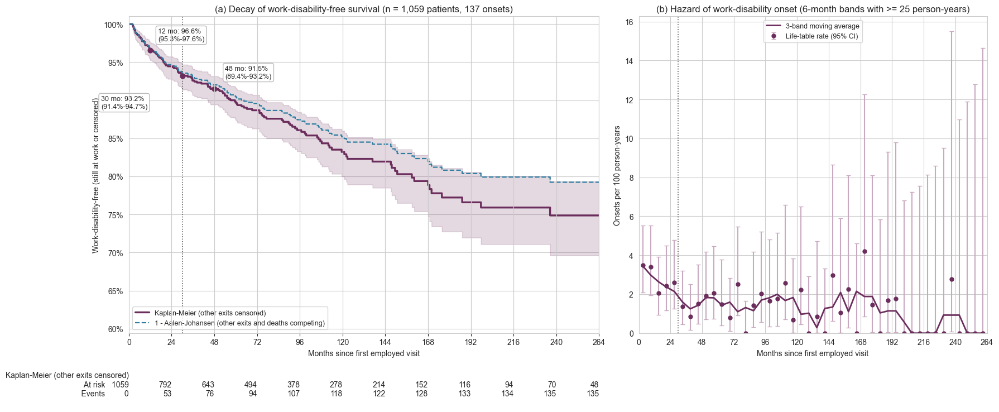

Work-disability-free at 30 months: KM 93.2% (cumulative incidence 6.8%); with other exits and deaths as competing events, cumulative incidence 6.4%
Onset rate per 100 person-years by band:
   band  events     py  rate   lo    hi
    0-6      18 515.01  3.50 2.07  5.52
   6-12      16 469.86  3.41 1.95  5.53
  12-18       9 437.34  2.06 0.94  3.91
  18-24      10 409.38  2.44 1.17  4.49
  24-30      10 384.42  2.60 1.25  4.78
  30-36       5 364.82  1.37 0.45  3.20
  36-42       3 348.14  0.86 0.18  2.52
  42-48       5 331.23  1.51 0.49  3.52
  48-54       6 312.40  1.92 0.70  4.18
  54-60       6 292.99  2.05 0.75  4.46
  60-66       4 271.80  1.47 0.40  3.77
  66-72       2 254.12  0.79 0.10  2.84
  72-78       6 238.59  2.51 0.92  5.47
  78-84       0 222.70  0.00 0.00  1.66
  84-90       3 210.56  1.42 0.29  4.16
  90-96       4 196.90  2.03 0.55  5.20
 96-102       3 182.31  1.65 0.34  4.81
102-108       3 169.82  1.77 0.36  5.16
108-114       4 155.57  2.57 0.70  6.58
114-120    

In [24]:
"""
Follow-up diagnostics and Kaplan-Meier decay of work-disability-free survival.

Time zero = first employed visit; event = first work-disability onset (dated as in the landmark builder). The
Kaplan-Meier curve censors the competing causes (other exit, death) as well as the last visit and age 65; the
Aalen-Johansen curve treats other exits and deaths as competing events (the cumulative incidence the models target).

1. How index follow-up ends, and for how long patients are followed.
2. Kaplan-Meier figure:
   (a) work-disability-free survival S(t) with its 95% CI, the number at risk underneath, and S(t) marked at 12,
       30 and 48 months -- the decay of the employed cohort. 1 - Aalen-Johansen is overlaid: it treats other exits
       and deaths as competing events instead of censoring them (the lower, 'real-world' cumulative incidence).
   (b) the hazard behind that decay: life-table onset rate per 100 person-years in 6-month bands, with exact
       Poisson 95% CIs, i.e. whether the risk of onset is front-loaded or constant over follow-up.
3. Landmark-level follow-up: how it ends, and how many landmarks are censored before 30 months (kept via IPCW).
"""
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.plotting import add_at_risk_counts

km_df = patients_df[patients_df["ever_employed"] & (patients_df["km_time_days"] > 0)].copy()
km_df["t_months"] = km_df["km_time_days"] / MONTH_DAYS
W = 100

# ------------------------------------------------------------------ 1. follow-up by how it ends
print("=" * W)
print("1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)")
print("-" * W)
fu = km_df.groupby("km_exit")["t_months"].agg(N="size", median="median", q1=lambda s: s.quantile(.25),
                                             q3=lambda s: s.quantile(.75), max="max")
fu["%"] = 100 * fu["N"] / len(km_df)
print(fu.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
rkm = KaplanMeierFitter().fit(km_df["t_months"], 1 - km_df["km_event"])
print(f"\nMedian potential follow-up (reverse Kaplan-Meier): {rkm.median_survival_time_:.1f} months")
print(f"Patients followed < {PRIMARY_HORIZON_MONTHS} months without an onset: "
      f"{int(((km_df['t_months'] < PRIMARY_HORIZON_MONTHS) & (km_df['km_event'] == 0)).sum())} "
      f"(kept through the censoring-aware target)")

# ------------------------------------------------------------------ 2. Kaplan-Meier decay + hazard
kmf = KaplanMeierFitter(label="Kaplan-Meier (other exits censored)").fit(km_df["t_months"], km_df["km_event"])
ev_code = km_df["km_cause"].astype(int).values          # 1 disability, 2 other exit, 3 death, 0 censored
with warnings.catch_warnings():                      # tied times are jittered by lifelines (seeded)
    warnings.simplefilter("ignore")
    ajf = AalenJohansenFitter(calculate_variance=False, seed=SEED).fit(
        pd.Series(km_df["t_months"].values), pd.Series(ev_code), event_of_interest=1)

x_max = float(np.ceil(km_df["t_months"].quantile(0.95) / 12) * 12)
ticks = list(np.arange(0, x_max + 1, 24))
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
kmf.plot_survival_function(ax=ax, color="#6b2d5c", lw=2.4, ci_show=True, ci_alpha=0.18)
aj_s = 1 - ajf.cumulative_density_.iloc[:, 0]
ax.step(aj_s.index, aj_s.values, where="post", color="#2c7da0", lw=1.6, ls="--",
        label="1 - Aalen-Johansen (other exits and deaths competing)")
for m, off in [(12, (10, 12)), (PRIMARY_HORIZON_MONTHS, (-105, -42)), (48, (14, 14))]:
    s = float(kmf.survival_function_at_times(m).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(m).values
    ax.scatter([m], [s], color="#6b2d5c", zorder=5, s=40)
    ax.annotate(f"{m} mo: {s:.1%}\n({lo:.1%}-{hi:.1%})", (m, s), textcoords="offset points",
                xytext=off, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb"))
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
med = kmf.median_survival_time_
if np.isfinite(med):
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.text(med, 0.51, f"median {med:.0f} mo", fontsize=9, color="gray")
ax.set_xlim(0, x_max); ax.set_xticks(ticks)
ax.set_ylim(max(0.0, float(kmf.survival_function_.values.min()) - 0.1), 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Work-disability-free (still at work or censored)")
ax.set_title(f"(a) Decay of work-disability-free survival (n = {len(km_df):,} patients, "
             f"{int(km_df['km_event'].sum())} onsets)")
ax.legend(loc="lower left", fontsize=9)
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"], xticks=ticks)

# (b) life-table hazard in 6-month bands
band = 6.0
edges = np.arange(0, x_max + band, band)
T, E = km_df["t_months"].values, km_df["km_event"].values
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    exposure_py = np.clip(np.minimum(T, hi) - lo, 0, None).sum() / 12.0
    d = int(((E == 1) & (T > lo) & (T <= hi)).sum())
    if exposure_py < 25:                             # too little person-time for a readable rate
        continue
    ci_lo = stats.chi2.ppf(0.025, 2 * d) / 2 if d > 0 else 0.0
    ci_hi = stats.chi2.ppf(0.975, 2 * d + 2) / 2
    rows.append({"band_mid": (lo + hi) / 2, "events": d, "py": exposure_py, "rate": 100 * d / exposure_py,
                 "lo": 100 * ci_lo / exposure_py, "hi": 100 * ci_hi / exposure_py})
hz = pd.DataFrame(rows)
ax = axes[1]
ax.errorbar(hz["band_mid"], hz["rate"], yerr=[hz["rate"] - hz["lo"], hz["hi"] - hz["rate"]], fmt="o",
            color="#6b2d5c", ecolor="#c9a9c0", capsize=3, ms=5, label="Life-table rate (95% CI)")
if len(hz) >= 3:
    sm = hz["rate"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(hz["band_mid"], sm, color="#6b2d5c", lw=2, label="3-band moving average")
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
ax.set_xlim(0, x_max); ax.set_xticks(ticks); ax.set_ylim(0, None)
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Onsets per 100 person-years")
ax.set_title("(b) Hazard of work-disability onset (6-month bands with >= 25 person-years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/revised_v21_km_work_disability_decay.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

s30 = float(kmf.survival_function_at_times(PRIMARY_HORIZON_MONTHS).iloc[0])
aj30 = float(ajf.cumulative_density_.asof(PRIMARY_HORIZON_MONTHS).iloc[0])
print(f"Work-disability-free at {PRIMARY_HORIZON_MONTHS} months: KM {s30:.1%} (cumulative incidence {1 - s30:.1%}); "
      f"with other exits and deaths as competing events, cumulative incidence {aj30:.1%}")
print("Onset rate per 100 person-years by band:")
print(hz.assign(band=lambda d: [f"{m - band / 2:.0f}-{m + band / 2:.0f}" for m in d["band_mid"]])
      [["band", "events", "py", "rate", "lo", "hi"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# ------------------------------------------------------------------ 3. landmark-level censoring
print("\n" + "=" * W)
print(f"3. LANDMARKS BY HOW FOLLOW-UP ENDS, and share censored before {PRIMARY_HORIZON_MONTHS} months")
print("-" * W)
lt = land.assign(before_h=(land["cause"] == 0) & (land["time_days"] <= HORIZON_DAYS))
tab = lt.groupby("exit_type").agg(landmarks=("pid", "size"), patients=("pid", "nunique"),
                                  median_fu_mo=("time_days", lambda s: s.median() / MONTH_DAYS),
                                  censored_before_30mo=("before_h", "sum"))
print(tab.to_string(float_format=lambda v: f"{v:.1f}"))
G_diag = CensoringKM(T_ALL, C_ALL)
print(f"Censoring survival G(30 mo) = {float(G_diag.at([HORIZON_DAYS])[0]):.2f}: controls are up-weighted by about "
      f"{1 / max(float(G_diag.at([HORIZON_DAYS])[0]), IPCW_MIN_G):.1f}x in every IPCW metric.")
print("=" * W)

## 11.3.1 Is censoring informative?

Censoring is harmless only if who is censored does not depend on disability risk. A **discrete-time hazard of
censoring** (the end of follow-up at the last recorded employment status or at age 65, before any onset or exit) is
fitted on the 12 variables and the calendar year in 5 patient-grouped folds and scored on the held-out patients with Uno's C for
"censored by 30 months". The interval indicators alone give C = 0.5, so the C-index measures how much the variables say
about who is censored. The rule is fixed in advance (`CENSORING_SIGNAL_C`): **C ≥ 0.60** means censoring carries
information. The sequence models' and the baseline's loss are then weighted by $1/\hat G_k(x)$ from a censoring model
fitted inside every training set, and Section 11.15.5 adds covariate-adjusted AUROC(t). Otherwise simple censoring is
kept.

In [25]:
"""
Censoring diagnostic and the censoring model used for covariate IPCW.

CensoringModel: a person-interval logistic regression of CENSORING (cause 0) on CENSORING_COLS
(training-fold skew transform + one imputation + standardisation, as the tabular models), with interval indicators as
the baseline hazard, landmark-weighted. A landmark is at risk of censoring in every interval up to the
end of its follow-up; an onset, exit or death ends that risk without being censoring (censor_causes=(0,)). With
censor_causes=(0, 2, 3) it models 'censored or a competing event', the censoring of the cause-specific evaluation.
G_before(idx)[:, k] = P(not censored before interval k | x), the weight 1 / G of interval k.
"""
from sklearn.model_selection import StratifiedGroupKFold as _SGKF


class CensoringModel:
    def __init__(self, censor_causes=(0,), C=1.0):
        self.censor_causes, self.C = tuple(censor_causes), C

    def fit(self, idx):
        idx = np.asarray(idx)
        self.prep = TabularPrep(CENSORING_COLS, m=1, method="linear")
        X = self.prep.fit_transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], T_ALL[idx], side="left")[:, None]
        k = np.arange(N_INTERVALS)[None, :]
        cens = np.isin(C_ALL[idx], self.censor_causes)[:, None]
        R = (k < b) | ((k == b) & cens)                                     # at risk of censoring in interval k
        r, kk = np.nonzero(R)
        y = (cens & (k == b))[r, kk].astype(int)
        Z = np.hstack([X[r], np.eye(N_INTERVALS)[kk]])
        self.lr = LogisticRegression(C=self.C, fit_intercept=False, max_iter=3000).fit(
            Z, y, sample_weight=norm_weights(land["weight"].values[idx])[r])
        return self

    def hazards(self, idx):
        idx = np.asarray(idx)
        X = self.prep.transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        Z = np.hstack([np.repeat(X, N_INTERVALS, axis=0), np.tile(np.eye(N_INTERVALS), (len(idx), 1))])
        return self.lr.predict_proba(Z)[:, 1].reshape(len(idx), N_INTERVALS)

    def G_before(self, idx):
        h = self.hazards(idx)
        return np.cumprod(np.hstack([np.ones((len(h), 1)), 1 - h[:, :-1]]), axis=1)

    def G_at_days(self, idx, days, before=False):
        """P(not censored by `days` | x) (through the interval containing `days`; before=True: before it)."""
        G = np.cumprod(1 - self.hazards(idx), axis=1)
        G0 = np.hstack([np.ones((len(G), 1)), G[:, :-1]])
        b = np.minimum(np.searchsorted(INTERVAL_EDGES_DAYS[1:], np.broadcast_to(days, (len(G),)), side="left"),
                       N_INTERVALS - 1)
        return (G0 if before else G)[np.arange(len(G)), b]


_CW_CACHE = {}


def censoring_weights(idx):
    """(len(idx), N_INTERVALS) weights 1 / G_k(x) for landmark rows idx, from a CensoringModel fitted on idx only
    (cached in memory and in the fold-input cache: every configuration, model and re-run shares them)."""
    idx = np.asarray(idx)
    key = hashlib.sha1(idx.tobytes()).hexdigest()
    if key not in _CW_CACHE:
        if len(_CW_CACHE) >= 8:
            _CW_CACHE.pop(next(iter(_CW_CACHE)))
        ck = fc_key("cw", idx, X_for(idx, CENSORING_COLS), T_ALL[idx], C_ALL[idx], land["weight"].values[idx],
                    PID_ALL[idx])
        cw = fc_get("cw", ck)
        if cw is None:
            G = CensoringModel().fit(idx).G_before(idx)
            cw = fc_put("cw", ck, (1.0 / np.maximum(G, IPCW_MIN_G)).astype(np.float32))
        _CW_CACHE[key] = cw
    return _CW_CACHE[key]


def censoring_diagnostic(n_splits=5):
    """Out-of-fold risk of censoring by 30 months and Uno's C per held-out fold."""
    oof, cs = np.full(len(land), np.nan), []
    for a, b in _SGKF(n_splits, shuffle=True, random_state=CV_SEED).split(np.zeros(len(land)), land["pt_event"].values,
                                                                          PID_ALL):
        oof[b] = 1 - CensoringModel().fit(a).G_at_days(b, HORIZON_DAYS)
        cs.append(uno_c_index(T_ALL[b], (C_ALL[b] == 0).astype(int), oof[b], HORIZON_DAYS))
    return np.array(cs), oof


cens_c, cens_oof = censoring_diagnostic()
CENSORING_C_CV = float(np.nanmean(cens_c))
print(f"Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by {PRIMARY_HORIZON_MONTHS} months' = "
      f"{CENSORING_C_CV:.3f} (folds {', '.join(f'{c:.3f}' for c in cens_c)}); 0.5 = no information")
q = pd.qcut(cens_oof, 5, labels=False, duplicates="drop")
rows = []
for g in range(int(q.max()) + 1):
    k = q == g
    km = KaplanMeierFitter().fit(T_ALL[k], (C_ALL[k] == 0).astype(int))
    rows.append({"Quintile of predicted censoring risk": g + 1, "Landmarks": int(k.sum()),
                 "Predicted, by 30 mo": float(cens_oof[k].mean()),
                 "Observed (Kaplan-Meier), by 30 mo": float(1 - km.survival_function_at_times(HORIZON_DAYS).iloc[0]),
                 "Onset within 30 mo (share of resolved)": float(np.nanmean(land["label30"].values[k]))})
display(pd.DataFrame(rows).set_index("Quintile of predicted censoring risk").round(3))
cm_all = CensoringModel().fit(np.arange(len(land)))
coef = pd.Series(cm_all.lr.coef_[0][:len(CENSORING_COLS)], index=[DISPLAY_NAMES.get(c, c) for c in CENSORING_COLS])
print("Strongest predictors of censoring (log-odds per SD, all landmarks; for description):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:10].round(3).to_string())
if CENSORING_IPCW == "auto":
    CENSORING_IPCW_ON = CENSORING_C_CV >= CENSORING_SIGNAL_C
else:
    CENSORING_IPCW_ON = bool(CENSORING_IPCW)
print(f"\nDecision (C >= {CENSORING_SIGNAL_C:.2f}, CENSORING_IPCW = {CENSORING_IPCW!r}): "
      + ("censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the "
         "sequence models' and the baseline's loss and in the cause-specific AUROC(t)" if CENSORING_IPCW_ON
         else "no real signal -> simple censoring; no covariate IPCW"))

Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by 30 months' = 0.804 (folds 0.844, 0.819, 0.810, 0.801, 0.748); 0.5 = no information


,Landmarks,"Predicted, by 30 mo","Observed (Kaplan-Meier), by 30 mo",Onset within 30 mo (share of resolved)
Quintile of predicted censoring risk,,,,
1,3371,0.066,0.049,0.050
2,3370,0.099,0.053,0.044
3,3370,0.147,0.072,0.052
4,3370,0.255,0.087,0.040
5,3370,0.596,0.492,0.032


Strongest predictors of censoring (log-odds per SD, all landmarks; for description):
Calendar year, spline term (adjustment)    1.592
Calendar year (adjustment)                -0.858
Years since first employed visit          -0.290
Days since last visit                      0.185
Education: not recorded                   -0.176
Age                                        0.079
Steroid dose (mg/day)                      0.051
SLEDAI-2K                                 -0.035
SDI damage score                           0.027
Education: higher                         -0.014

Decision (C >= 0.60, CENSORING_IPCW = 'auto'): censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the sequence models' and the baseline's loss and in the cause-specific AUROC(t)


## 11.4 Table 1 — baseline characteristics by outcome group

In [26]:
"""
Table 1 -- baseline characteristics by outcome group.

Groups (patient level, mutually exclusive, first match wins):
  Became Disabled   : a work-disability onset after some landmark
  Other Exits       : follow-up of some landmark ended in retirement / homemaker / student / job-seeking / other
  Deceased          : died
  Remained Employed : none of the above (censored at last visit)
Plus an 'Overall' column across every patient who contributes a landmark.

Baseline = the INDEX (first employed) visit row, so every baseline value comes from the same visit. Follow-up, disease course and treatment are
aggregated over each patient's full visit record. Continuous -> mean (SD) | median [IQR], Kruskal-Wallis;
categorical -> n (%), chi-square.
"""


def _patient_outcome_group(land, pts):
    g = land.groupby("pid")
    ev = g["event"].max()
    other = g["exit_type"].apply(lambda s: (s == "other_exit").any())
    out = pd.Series("Remained Employed", index=ev.index)
    out[pts.loc[ev.index, "dead"].values] = "Deceased"
    out[other] = "Other Exits"
    out[ev == 1] = "Became Disabled"
    return out.rename("outcome_group")


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, pts, visits):
    outcome = _patient_outcome_group(land, pts)
    v = visits[visits["PTNO"].isin(outcome.index)]
    g = v.groupby("PTNO")
    idx_rows = v[v["ASSDT"] == v["PTNO"].map(pts["index_date"])].set_index("PTNO")
    last_rows = g.last()
    ever = lambda col: g[col].apply(lambda s: int((pd.to_numeric(s, errors="coerce").fillna(0) > 0).any()))
    b = pd.DataFrame(index=outcome.index)
    # ---- sociodemographics (patient-constant: first recorded value across all visits)
    b["sex"] = g["SEX"].apply(_first_nonnull)
    b["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    b["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    b["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    b["age_index"] = idx_rows["age_at_record"]
    b["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]
    # ---- follow-up
    b["n_visits"] = g.size()
    b["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    b["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()
    b["n_landmarks"] = land.groupby("pid").size()
    # ---- disease activity, flares and damage
    b["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    b["sledai_mean"] = g["SLEDAI2_I"].mean()
    b["sledai_ams_index"] = idx_rows["SLEDAI_AMS"]
    b["ever_flare_mild"] = g["FLARE_MILD_MOD"].max().astype(int)
    b["ever_flare_severe"] = g["FLARE_SEVERE"].max().astype(int)
    b["sdi_baseline"] = idx_rows["score_n"]
    b["sdi_last"] = last_rows["score_n"]
    # ---- employment history at index / during follow-up
    b["prior_sick_leave"] = (idx_rows["PRIOR_SICK_LEAVE_VISITS"] > 0).astype(int)
    b["ever_sick_leave"] = g["EMP"].apply(lambda s: int(s.isin(SICK_STATES).any()))
    # ---- treatment, ever during follow-up
    b["ever_steroid"] = g["ON_STEROID"].max().astype(int)
    b["steroid_dose_mean"] = g["STERAVER"].mean()
    b["ever_steroid_pulse"] = ever("STPDOSE")
    b["ever_antimalarial"] = g["ON_ANTIMALARIAL"].max().astype(int)
    b["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    b["ever_cyclophosphamide"] = ever("IS_CYCLOPHOSPHAMIDE_DOSE")
    b["ever_mycophenolate"] = ever("IS_MYCOPHENOLATE_DOSE")
    b["ever_methotrexate"] = ever("IS_METHOTREXATE_DOSE")
    b["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    b["ever_rituximab"] = ever("BIOG_RIT")
    b["ever_belimumab"] = ever("BIOG_BEL")
    return b.join(outcome, how="inner")


def _fmt_cont(s):
    s = s.dropna().astype(float)
    if not len(s):
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f}) | {s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]"


def _fmt_cat(s, level):
    s = s.dropna()
    n = int((s == level).sum())
    return f"{n} ({100 * n / len(s):.1f}%)" if len(s) else "0"


def _pval(test):
    try:
        return f"{test():.3f}"
    except ValueError:
        return "n/a"


def make_table1(b, groups=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [x for x in groups if x in set(b["outcome_group"])]
    rows = [{"Variable": "N", "Overall": str(len(b)), **{x: str((b.outcome_group == x).sum()) for x in groups},
             "p": ""}]
    section = lambda t: rows.append({"Variable": f"**{t}**", "Overall": "", **{x: "" for x in groups}, "p": ""})

    def cont(col, label):
        arrs = [a for a in (b.loc[b.outcome_group == x, col].dropna().astype(float) for x in groups) if len(a)]
        rows.append({"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_cont(b[col]),
                     **{x: _fmt_cont(b.loc[b.outcome_group == x, col]) for x in groups},
                     "p": _pval(lambda: stats.kruskal(*arrs).pvalue)})

    def cat(col, label, levels=None, names=None):
        p = _pval(lambda: stats.chi2_contingency(pd.crosstab(b[col], b["outcome_group"]))[1])
        levels = levels or sorted(b[col].dropna().unique().tolist(), key=str)
        if len(levels) > 1:
            rows.append({"Variable": f"{label}, n (%)", "Overall": "", **{x: "" for x in groups}, "p": p})
        for lv in levels:
            nm = (names or {}).get(lv, lv)
            rows.append({"Variable": f"    {nm}" if len(levels) > 1 else f"{label}, n (%)",
                         "Overall": _fmt_cat(b[col], lv),
                         **{x: _fmt_cat(b.loc[b.outcome_group == x, col], lv) for x in groups},
                         "p": "" if len(levels) > 1 else p})

    section("Sociodemographics")
    cont("age_index", "Age at index (years)")
    cat("sex", "Sex")
    cat("race", "Race")
    cat("ethnicity", "Ethnicity")
    cat("education", "Education (DS_MAX_EDU)", names={0.0: "Lower", 1.0: "Higher"})
    cont("disease_duration_yrs", "Disease duration at index (years)")
    section("Follow-up")
    cont("n_visits", "Number of visits")
    cont("followup_years", "Follow-up from index (years)")
    cont("mean_gap_days", "Mean time between visits (days)")
    cont("n_landmarks", "Landmark visits")
    section("Disease activity, flares and damage")
    cont("sledai_baseline", "SLEDAI-2K at index")
    cont("sledai_ams_index", "Adjusted mean SLEDAI-2K at index")
    cont("sledai_mean", "SLEDAI-2K, mean across follow-up")
    cat("ever_flare_mild", "Any mild/moderate flare (SLEDAI-2K +4 to +10)", levels=[1])
    cat("ever_flare_severe", "Any severe flare (SLEDAI-2K > +10)", levels=[1])
    cont("sdi_baseline", "SDI at index")
    cont("sdi_last", "SDI at last visit")
    section("Employment history")
    cat("prior_sick_leave", "Sick leave before index", levels=[1])
    cat("ever_sick_leave", "Any sick leave during follow-up", levels=[1])
    section("Treatment (ever during follow-up)")
    cat("ever_steroid", "Ever on steroids", levels=[1])
    cont("steroid_dose_mean", "Average daily steroid dose, mg (visits with a value)")
    cat("ever_steroid_pulse", "Ever received steroid pulse", levels=[1])
    cat("ever_antimalarial", "Ever on antimalarial", levels=[1])
    cat("ever_immunosuppressive", "Ever on immunosuppressive therapy", levels=[1])
    cat("ever_cyclophosphamide", "    Ever cyclophosphamide", levels=[1])
    cat("ever_mycophenolate", "    Ever mycophenolate", levels=[1])
    cat("ever_methotrexate", "    Ever methotrexate", levels=[1])
    cat("ever_biologic", "Ever on biologic therapy", levels=[1])
    cat("ever_rituximab", "    Ever rituximab", levels=[1])
    cat("ever_belimumab", "    Ever belimumab", levels=[1])
    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land, patients_df, visits)
table1 = make_table1(table1_base)
pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics_model_revised_v21.csv", index=False)

,Variable,Overall,Remained Employed,Became Disabled,Deceased,Other Exits,p
0,N,1059,687,150,33,189,
1,**Sociodemographics**,,,,,,
2,"Age at index (years), mean (SD) | median [IQR]",36.1 (10.9) | 34.5 [27.3-43.8],35.5 (10.6) | 33.7 [27.6-42.4],38.4 (11.1) | 38.8 [29.3-47.0],42.3 (12.1) | 42.4 [31.9-53.5],35.0 (11.4) | 33.9 [25.7-43.3],0.000
3,"Sex, n (%)",,,,,,0.020
4,F,933 (88.2%),603 (87.9%),138 (92.0%),24 (72.7%),168 (88.9%),
5,M,125 (11.8%),83 (12.1%),12 (8.0%),9 (27.3%),21 (11.1%),
6,"Race, n (%)",,,,,,0.000
7,Black,151 (14.7%),94 (14.4%),29 (19.3%),7 (21.2%),21 (11.2%),
8,Caucasian,611 (59.6%),355 (54.2%),99 (66.0%),20 (60.6%),137 (72.9%),
9,Chinese,111 (10.8%),86 (13.1%),10 (6.7%),3 (9.1%),12 (6.4%),


## 11.5 Variables

Section 5. The candidate pool, the outcome-free pre-filter and the LASSO selection made once on all data: 15 variables
that every model reads, with the CV curve, path and stability.

Sample-size cap (Riley et al.; time-to-event; anticipated C = 0.72):


,value
Patients (n),1059
Patients with an onset,150
Anticipated C,0.72
Anticipated R2_CS,0.0916
Max R2_CS,0.9295
P allowed: shrinkage >= 0.9,11.4
P allowed: optimism <= 0.05,53.0
n needed: overall risk +-0.05,187
Criterion (iii) met,True
P_MAX,11


revised_v21: 15 variables by design (17 parameters with the calendar-year terms); the Riley et al. cap would allow 11 parameters, so more optimism and a calibration slope below 1 are expected (sensitivity analysis 'riley_cap').
-> at most 17 parameters: 5 forced (Age, SDI damage score, SLEDAI-2K, Calendar year (adjustment), Calendar year, spline term (adjustment)) + up to 12 selected by the LASSO.

All-data LASSO (cap rule; 406s): 12 selected (the CV-optimal penalty would select 33; binding: cap):


,Group,"Coefficient (log-odds per SD, penalised)"
Dyspnoea,Symptoms,0.1786
Steroid dose (mg/day),Treatment,0.1312
"Acute visit (pulse, steroid increase or new immunosuppressant)",Treatment,0.1031
Arthralgia,Symptoms,0.0876
Disease duration (yrs),Demographics,-0.0798
SLEDAI: increased anti-dsDNA,Laboratory,-0.0671
Fibromyalgia,Comorbidities and damage,0.0528
EULAR treatment step (0-4),Treatment,0.0355
Fatigue,Symptoms,0.0194
SLEDAI-2K: CNS,Severity scores,0.0160



The CV-optimal set (lambda_min, no cap): 38 columns = the 5 forced terms + 33 selected; read by the sequence models and LogReg-W (not used: SEQ_WIDE_INPUTS = False):
Sex: female, Current smoker, Disease duration (yrs), SDI change since last visit, SDI neuropsychiatric damage, SDI cardiovascular damage, SDI pulmonary damage, SDI peripheral vascular damage, SDI skin damage, BP >= 140 / 90, Fibromyalgia, eGFR < 60, ESR (log), eGFR (CKD-EPI 2021), SLEDAI: increased anti-dsDNA, Diastolic BP, Clinical SLEDAI-2K (no serology), SLEDAI-2K: musculoskeletal, SLEDAI-2K: CNS, Steroid dose (mg/day), Acute visit (pulse, steroid increase or new immunosuppressant), Not on an antimalarial, Azathioprine, Mycophenolate, Methotrexate, EULAR treatment step (0-4), Fatigue, Arthralgia, Dyspnoea, Alopecia, Days since last visit, LLDAS lost since last visit, Remission lost since last visit

Pre-filter decisions for every candidate (no outcome used):


,Group,Missing at landmarks,Prevalence (binary),Decision
Variable,,,,
Age,Demographics,0.0%,NaN,forced (unpenalised)
Sex: female,Demographics,0.0%,0.893709,candidate
Education: higher,Demographics,12.4%,0.473748,candidate
Current smoker,Demographics,0.5%,0.093974,candidate
BMI (kg/m2),Demographics,17.3%,NaN,candidate
Disease duration (yrs),Demographics,0.0%,NaN,candidate
Age at diagnosis,Demographics,0.0%,NaN,candidate
SDI damage score,Comorbidities and damage,0.0%,NaN,forced (unpenalised)
SDI change since last visit,Comorbidities and damage,0.0%,NaN,candidate


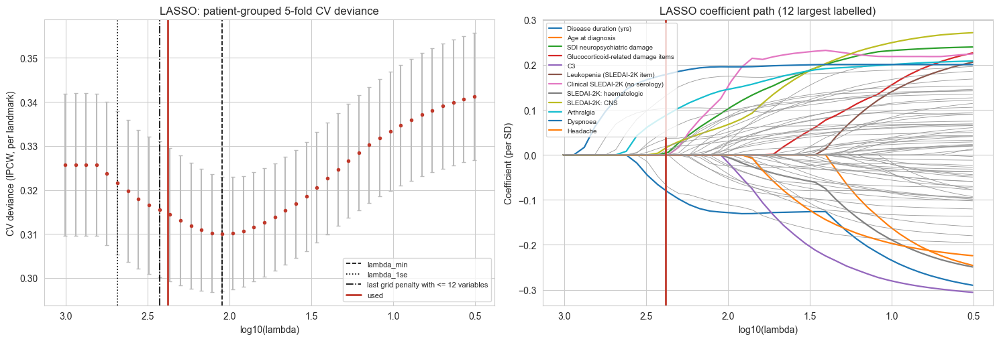

Bootstrap stability (200 patient resamples, penalty fixed): candidates selected in >= 20% of resamples


,Selected on all data,Bootstrap frequency
Dyspnoea,True,0.980
"Acute visit (pulse, steroid increase or new immunosuppressant)",True,0.880
Steroid dose (mg/day),True,0.880
Arthralgia,True,0.825
Fibromyalgia,True,0.700
Disease duration (yrs),True,0.685
SLEDAI: increased anti-dsDNA,True,0.645
EULAR treatment step (0-4),True,0.595
SLEDAI-2K: CNS,True,0.535
Fatigue,True,0.535


(array([[ 118.44662137,   83.4616831 ,   50.70415653, ...,   -0.2871971 ,
           -0.41187347,   -0.45697213],
        [ 123.44418433,   83.4616831 , -139.72335661, ...,   -0.2871971 ,
           -0.41187347,   -0.45697213],
        [ 126.32869639,   83.4616831 , -139.72335661, ...,   -0.2871971 ,
           -0.41187347,   -0.45697213],
        ...,
        [  49.75082842, -125.71682522,   -9.73635654, ...,    3.48192932,
           -0.41187347,    2.18831725],
        [ -22.34597923, -125.71682522, -139.72335661, ...,   -0.2871971 ,
            2.42793009,    2.18831725],
        [-133.95476902, -125.71682522,   50.70415653, ...,   -0.2871971 ,
           -0.41187347,   -0.45697213]], shape=(71920, 81)),
 array([0, 0, 0, ..., 0, 0, 1], shape=(71920,)),
 array([0.24472806, 0.24472806, 0.24472806, ..., 0.48945611, 1.95782446,
        3.354651  ], shape=(71920,)),
 array([  17,   17,   17, ..., 2271, 2294, 2298], shape=(71920,)))

In [27]:
"""
Variables: candidate pool, pre-filter and LASSO selection (Sections 5.1-5.3; TRIPOD+AI items 9 and 10).

CAP. The largest number of parameters P_MAX that meets the three criteria of Riley et al. (BMJ 2020; Stat Med 2019,
time-to-event version) for the cohort -- n = patients with a landmark, phi = share with an onset -- at an anticipated
C of ANTICIPATED_C (revised_v12's visit-level C of every model): (i) expected uniform shrinkage >= 0.9, (ii) optimism
in Nagelkerke R2 <= 0.05, (iii) the overall risk within +-0.05. The anticipated Cox-Snell R2 comes from a simulated
time-to-event cohort with this event share whose Harrell C equals ANTICIPATED_C. The forced terms (age, the two
calendar-year terms) take len(FORCED_COLS) of the P_MAX parameters; the LASSO may select up to LASSO_MAX_SELECTED.

LASSO (lasso_select). L1-penalised logistic regression of 'onset within 30 months' -- the competing-risk IPCW label of
every metric in this notebook (an other exit by 30 months is a resolved non-event; landmarks censored earlier drop out)
-- on the standardised candidates, weighted IPCW x landmark weight, the M imputations stacked with weight 1/M (Wood,
White & Royston, Stat Med 2008). Forced terms are unpenalised (their columns are scaled up by FORCE_SCALE, which
makes their L1 penalty negligible). The penalty path has LASSO_N_LAMBDA values; the CV deviance comes from
LASSO_CV_SPLITS patient-grouped folds of the same rows (as Chen et al., 5-fold). The penalty used:
  'cap'  (main)        : lambda* = max(lambda_min, lambda_cap): the largest set with <= LASSO_MAX_SELECTED variables, but
                         never weaker than the CV-optimal penalty;
  '1se' / 'min'        : the sensitivity analyses (Chen et al.'s rule; no cap).
The selection is made ONCE, here, on all landmarks, and every model of every CV fold uses it (Section 11.8, part 3),
so the cross-validated performance does not include the selection step. It is also the published model, the nomogram
and the final refits; shown with its CV curve, coefficient path and bootstrap stability. The CV-optimal set of the same
path (lambda_min, no cap; 'features_wide') is what the sequence models and LogReg-W read (SEQ_WIDE_INPUTS).
"""
from sklearn.model_selection import StratifiedGroupKFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

FORCE_SCALE = 100.0
LASSO_REFINE_STEPS = 8              # bisection steps between two grid penalties when the cap falls between them


def _sim_survival(sigma, phi, n, seed):
    """A time-to-event cohort: exponential event times with log-hazard ~ N(0, sigma^2), uniform censoring scaled so
    that a share phi has the event."""
    rng = np.random.default_rng(seed)
    lp = rng.normal(0.0, sigma, n)
    t, u = rng.exponential(np.exp(-lp)), rng.random(n)
    m = brentq(lambda mm: (t < u * mm).mean() - phi, 1e-6, 1e6)
    c = u * m
    return lp, np.minimum(t, c), (t < c).astype(int)


def riley_pmax(n, events, c_stat, S=0.9, n_sim=None, seed=SEED):
    """P_MAX of Riley et al.'s criteria (time-to-event version) for n patients with `events` onsets at anticipated
    Harrell C `c_stat`."""
    n_sim = n_sim or (5000 if SMOKE else 20000)
    phi = events / n
    c_of = lambda s: concordance_index(*(lambda lp, t, e: (t, -lp, e))(*_sim_survival(s, phi, n_sim, seed)))
    sigma = brentq(lambda s: c_of(s) - c_stat, 0.05, 3.0, xtol=1e-3)
    lp, t, e = _sim_survival(sigma, phi, n_sim, seed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph = CoxPHFitter().fit(pd.DataFrame({"t": t, "e": e, "lp": lp}), "t", "e")
    lr = float(cph.log_likelihood_ratio_test().test_statistic)
    r2 = 1 - np.exp(-lr / n_sim)
    r2max = 1 - np.exp(2 * (cph.log_likelihood_ - lr / 2) / n_sim)
    p_of = lambda s: n * (s - 1) * np.log(1 - r2 / s)
    s2 = r2 / (r2 + 0.05 * r2max)
    p1, p2 = p_of(S), p_of(s2)
    n3 = (1.96 / 0.05) ** 2 * phi * (1 - phi)
    return {"Patients (n)": n, "Patients with an onset": events, "Anticipated C": c_stat,
            "Anticipated R2_CS": round(r2, 4), "Max R2_CS": round(r2max, 4),
            "P allowed: shrinkage >= 0.9": round(p1, 1), "P allowed: optimism <= 0.05": round(p2, 1),
            "n needed: overall risk +-0.05": int(np.ceil(n3)), "Criterion (iii) met": bool(n >= n3),
            "P_MAX": int(np.floor(min(p1, p2)))}


RILEY = riley_pmax(int(land["pid"].nunique()), int(land.groupby("pid")["event"].max().sum()), ANTICIPATED_C)
# revised_v21: N_MODEL_VARIABLES variables (the forced ones included) + the calendar-year adjustment terms; None = the
# Riley et al. cap
P_MAX = RILEY["P_MAX"] if N_MODEL_VARIABLES is None else N_MODEL_VARIABLES + len(ADJUST_COLS)
LASSO_MAX_SELECTED = max(1, P_MAX - len(FORCED_COLS))


def _lasso_data(rows, m=None):
    """Stacked LASSO design of landmark rows: (X, y, w, patient, columns). Forced columns first (scaled by
    FORCE_SCALE), then PENALISED_COLS; rows resolved at 30 months only."""
    rows = np.asarray(rows)
    cols = FORCED_COLS + PENALISED_COLS
    prep = TabularPrep(cols, m=m)
    Xs = prep.fit_transform(X_for(rows, cols), PID_ALL[rows])
    y, w = ipcw_label_weight(T_ALL[rows], C_ALL[rows], HORIZON_DAYS, CensoringKM(T_ALL[rows], C_ALL[rows]))
    w = w * land["weight"].values[rows]
    k = w > 0
    nf = len(FORCED_COLS)
    X = np.vstack([np.hstack([Xk[k][:, :nf] * FORCE_SCALE, Xk[k][:, nf:]]) for Xk in Xs])
    mm = len(Xs)
    return X, np.tile(y[k], mm), np.tile(w[k] / w[k].mean(), mm) / mm, np.tile(PID_ALL[rows][k], mm), cols


def _l1_fit(X, y, w, C):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return LogisticRegression(l1_ratio=1.0, solver="liblinear", C=C, intercept_scaling=FORCE_SCALE, tol=1e-4,
                                  max_iter=500).fit(X, y, sample_weight=w)


def _wdev(model, X, y, w):
    p = np.clip(model.predict_proba(X)[:, 1], 1e-9, 1 - 1e-9)
    return -np.sum(w * (y * np.log(p) + (1 - y) * np.log(1 - p))) / w.sum()


def lasso_select(rows, seed=SEED, rule=None, keep_path=False):
    """The LASSO selection on landmark rows `rows` (Section 5.3). Returns the selected model columns (forced terms
    first), the 0/1 selection of every penalised candidate ('freq'), the penalty and its coefficients; with keep_path,
    also the path and the CV curve."""
    rule = rule or SELECTION_RULE
    t0 = time.time()
    X, y, w, g, cols = _lasso_data(rows, m=LASSO_M_IMPUTATIONS)
    nf = len(FORCED_COLS)
    r = w * (y - np.average(y, weights=w))
    c0 = 1.0 / max(np.max(np.abs(X[:, nf:].T @ r)), 1e-12)               # the weakest penalty with no variable in
    Cs = c0 * np.logspace(0, LASSO_C_DECADES, LASSO_N_LAMBDA)
    path = np.array([_l1_fit(X, y, w, C).coef_[0, nf:] for C in Cs])
    nsel = (path != 0).sum(1)
    folds = list(StratifiedGroupKFold(LASSO_CV_SPLITS, shuffle=True, random_state=seed).split(X, y, g))
    dev = np.array([[_wdev(_l1_fit(X[a], y[a], w[a], C), X[b], y[b], w[b]) for C in Cs] for a, b in folds])
    mean, se = dev.mean(0), dev.std(0, ddof=1) / np.sqrt(len(folds))
    i_min = int(np.argmin(mean))
    i_1se = int(np.min(np.flatnonzero(mean <= mean[i_min] + se[i_min])))
    over = np.flatnonzero(nsel > LASSO_MAX_SELECTED)
    i_cap = int(over[0] - 1) if len(over) else len(Cs) - 1
    i_cap = max(i_cap, 0)
    i_star = {"cap": min(i_min, i_cap), "min": i_min, "1se": i_1se}[rule]
    C_star, b_star = Cs[i_star], path[i_star]
    if rule == "cap" and i_cap < i_min and i_cap + 1 < len(Cs):
        # the count can jump past the cap between two penalties of the grid: bisect (log scale) for the weakest penalty
        # in between that still selects <= LASSO_MAX_SELECTED (never weaker than lambda_min, since i_cap < i_min)
        lo, hi = np.log(Cs[i_cap]), np.log(Cs[i_cap + 1])
        for _ in range(LASSO_REFINE_STEPS):
            mid = 0.5 * (lo + hi)
            b = _l1_fit(X, y, w, np.exp(mid)).coef_[0, nf:]
            if (b != 0).sum() <= LASSO_MAX_SELECTED:
                lo, C_star, b_star = mid, np.exp(mid), b
            else:
                hi = mid
    chosen = {c for c, b in zip(PENALISED_COLS, b_star) if b != 0}
    chosen_min = {c for c, b in zip(PENALISED_COLS, path[i_min]) if b != 0}         # the CV-optimal set, no cap
    out = {"features": [c for c in FEATURE_CANDIDATES if c in FORCED_COLS or c in chosen],
           "features_wide": [c for c in FEATURE_CANDIDATES if c in FORCED_COLS or c in chosen_min],
           "freq": pd.Series([float(c in chosen) for c in PENALISED_COLS], index=PENALISED_COLS),
           "coef": pd.Series(b_star, index=PENALISED_COLS), "rule": rule, "C": float(C_star),
           "index": {"min": i_min, "1se": i_1se, "cap": i_cap, "chosen": i_star}, "n_selected": len(chosen),
           "n_at_min": int(nsel[i_min]),
           "binding": ("cap" if i_cap < i_min else "lambda_min") if rule == "cap" else rule,
           "seconds": time.time() - t0}
    if keep_path:
        out.update(Cs=Cs, path=path, nsel=nsel, cv_mean=mean, cv_se=se, data=(X, y, w, g))
    return out


SELECTION_ALL = lasso_select(np.arange(len(land)), keep_path=True)
print(f"Sample-size cap (Riley et al.; time-to-event; anticipated C = {ANTICIPATED_C}):")
display(pd.Series(RILEY).to_frame("value"))
if N_MODEL_VARIABLES is not None:
    print(f"revised_v21: {N_MODEL_VARIABLES} variables by design ({P_MAX} parameters with the calendar-year terms); the "
          f"Riley et al. cap would allow {RILEY['P_MAX']} parameters, so more optimism and a calibration slope below 1 "
          f"are expected (sensitivity analysis 'riley_cap').")
print(f"-> at most {P_MAX} parameters: {len(FORCED_COLS)} forced ({', '.join(DISPLAY_NAMES.get(c, c) for c in FORCED_COLS)}) "
      f"+ up to {LASSO_MAX_SELECTED} selected by the LASSO.")
print(f"\nAll-data LASSO ({SELECTION_ALL['rule']} rule; {SELECTION_ALL['seconds']:.0f}s): {SELECTION_ALL['n_selected']} "
      f"selected (the CV-optimal penalty would select {SELECTION_ALL['n_at_min']}; binding: {SELECTION_ALL['binding']}):")
_sel = SELECTION_ALL["coef"][SELECTION_ALL["coef"] != 0]
display(pd.DataFrame({"Group": [FEATURE_GROUP_OF.get(c, "") for c in _sel.index],
                      "Coefficient (log-odds per SD, penalised)": _sel.values},
                     index=[DISPLAY_NAMES.get(c, c) for c in _sel.index]).sort_values(
    "Coefficient (log-odds per SD, penalised)", key=np.abs, ascending=False).round(4))
_wide = [c for c in SELECTION_ALL["features_wide"] if c not in FORCED_COLS]
print(f"\nThe CV-optimal set (lambda_min, no cap): {len(SELECTION_ALL['features_wide'])} columns = the "
      f"{len(FORCED_COLS)} forced terms + {len(_wide)} selected; read by the sequence models and LogReg-W"
      + ("" if SEQ_WIDE_INPUTS else " (not used: SEQ_WIDE_INPUTS = False)") + ":")
print(", ".join(DISPLAY_NAMES.get(c, c) for c in _wide))

if SLE_VARIANT == "main":
    print("\nPre-filter decisions for every candidate (no outcome used):")
    display(PREFILTER_TABLE.assign(**{"Missing at landmarks": PREFILTER_TABLE["Missing at landmarks"].map("{:.1%}".format)})
            .set_index("Variable"))
    PREFILTER_TABLE.to_csv("candidate_prefilter_revised_v21.csv")
    # ---- CV curve and coefficient path (Chen et al. Figure 2)
    s = SELECTION_ALL
    ll = np.log10(1.0 / s["Cs"])                                           # log10 lambda (liblinear: lambda = 1 / C)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    ax = axes[0]
    ax.errorbar(ll, s["cv_mean"], yerr=s["cv_se"], fmt="o", ms=3, color="#c0392b", ecolor="#bbbbbb", capsize=2)
    for key, ls, lab in [("min", "--", "lambda_min"), ("1se", ":", "lambda_1se"),
                         ("cap", "-.", f"last grid penalty with <= {LASSO_MAX_SELECTED} variables")]:
        ax.axvline(ll[s["index"][key]], color="black", ls=ls, lw=1.2, label=lab)
    ax.axvline(np.log10(1.0 / s["C"]), color="#c0392b", lw=2, label="used")
    ax.set_xlabel("log10(lambda)"); ax.set_ylabel("CV deviance (IPCW, per landmark)")
    ax.set_title("LASSO: patient-grouped 5-fold CV deviance"); ax.legend(fontsize=8)
    top = np.argsort(-np.abs(s["path"][-1]))[:12]
    ax = axes[1]
    for j in range(s["path"].shape[1]):
        ax.plot(ll, s["path"][:, j], color="#999999" if j not in top else None, lw=0.6 if j not in top else 1.6,
                label=DISPLAY_NAMES.get(PENALISED_COLS[j], PENALISED_COLS[j]) if j in top else None)
    ax.axvline(np.log10(1.0 / s["C"]), color="#c0392b", lw=2)
    ax.set_xlabel("log10(lambda)"); ax.set_ylabel("Coefficient (per SD)")
    ax.set_title("LASSO coefficient path (12 largest labelled)"); ax.legend(fontsize=7, loc="upper left")
    for a in axes:
        a.invert_xaxis()                                                   # weaker penalty to the right
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_lasso_path.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # ---- bootstrap stability of the all-data selection (the penalty fixed at the all-data one)
    X_, y_, w_, g_ = s["data"]
    codes, inv = np.unique(g_, return_inverse=True)
    _ck = fc_key("lasso_boot", X_, y_, w_, g_, float(s["C"]), LASSO_BOOT, len(FORCED_COLS), 2033)
    hits = fc_get("lasso_boot", _ck)
    if hits is None:                                                       # not in the fold-input cache yet
        rng_ = np.random.default_rng(2033)
        hits = np.zeros(len(PENALISED_COLS))
        for _ in range(LASSO_BOOT):
            cnt = np.bincount(rng_.integers(0, len(codes), len(codes)), minlength=len(codes))[inv].astype(float)
            k = cnt > 0
            hits += _l1_fit(X_[k], y_[k], (w_ * cnt)[k], s["C"]).coef_[0, len(FORCED_COLS):] != 0
        fc_put("lasso_boot", _ck, hits)
    SEL_BOOT_FREQ = pd.Series(hits / LASSO_BOOT, index=PENALISED_COLS)
    print(f"Bootstrap stability ({LASSO_BOOT} patient resamples, penalty fixed): candidates selected in >= 20% of resamples")
    _b = SEL_BOOT_FREQ[SEL_BOOT_FREQ >= 0.2].sort_values(ascending=False)
    display(pd.DataFrame({"Selected on all data": [bool(SELECTION_ALL["freq"][c]) for c in _b.index],
                          "Bootstrap frequency": _b.values}, index=[DISPLAY_NAMES.get(c, c) for c in _b.index]).round(3))
else:
    SEL_BOOT_FREQ = None
SELECTION_ALL.pop("data", None)

## 11.6 Patient-level evaluation

Section 9.2: every patient's 30-month window (before onset; before retirement / homemaker at ≥ 60; or the latest fully
observed 30 months), the final-status strata and age bands, and the functions that turn visit alarms into
TP / FN / TN / FP and a patient probability. Printed: the evaluation funnel.

In [28]:
"""
Patient-level evaluation (PATIENT_RULE = 'mixed', revised_v21): an event patient is a TP when ANY landmark in the
EVENT_LOOKBACK_MONTHS (60) before onset alarmed; an event-free patient is a TN when the alarm is OFF at their LAST
landmark (the end of their follow-up) and an FP when it is on there.

Nothing is trained or tuned at the patient level. Every model is trained on landmark visits and its alarm threshold
is learned at visit level inside each training fold (Section 9). A landmark ALARMS when its calibrated 30-month risk
is >= that threshold. Patients are scored while held out, from their test-fold visit alarms:

  Event patients (a work-disability onset):
    window  the landmarks in the 60 months before the first onset
    TP / FN a landmark of the window alarmed / none did; dated at the earliest alarm (lead time = that landmark ->
            onset). No landmark in the 60 months: not assessable.
  Event-free patients, stratified by FINAL STATUS (state at their last visit: 'Employed at final visit',
  'Retired / homemaker >= 60' = left work for it at >= 60, 'Other final status'):
    window  the patient's last landmark (the last employed visit before the end of follow-up, an exit or age 65)
    TN / FP no alarm / an alarm at that landmark
The 30-month windows of revised_v17-v18 (LAND_PT_WIN_30: event patients, the 30 months before onset; event-free
patients, the latest fully observed 30-month window, or the 30 months before a retirement at >= 60) give the
comparison rules 'any alarm, 30-month window' (revised_v18) and 'last landmark, 30-month window' (revised_v17) in
the columns *_30. PATIENT_RULE = 'any' / 'last' makes one of those the main rule again.
The rule is asymmetric: an event patient has up to 60 months of visits to alarm once, an event-free patient one
visit to stay quiet, so sensitivity, specificity and the C-index are not comparable with revised_v17-v18.

The primary table uses every evaluable patient; each final-status stratum also gets its own table (all event
patients vs that stratum's negatives), and specificity and the C-index are reported by age band (age at the end of
the window).

Patient probability, for the C-index, Brier score and calibration: the highest calibrated 30-month risk in the
window (event-free patients: the risk at the last landmark; PATIENT_RULE = 'last': the risk at the window's last
landmark), mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted (OOF) risks. PPV and NPV are also given at the cohort's share of
patients with an onset (Bayes' rule on sensitivity and specificity). Everything here is computed from the stored
fold predictions, so the definition can change without re-running the cross-validation.
"""
STRATA = ["Employed at final visit", f"Retired / homemaker >= {NEG_MIN_AGE}", "Other final status"]
AGE_BANDS = [(0, 40, "< 40"), (40, 50, "40-49"), (50, 60, "50-59"), (60, 200, ">= 60")]


def _exit_to_final_state(p):
    """(date, age) of the first visit of the patient's final non-working run if it was entered straight from
    employment, else (None, None)."""
    states = [_state_of(e) for e in p["EMP"].values]
    j = len(states) - 1
    while j >= 0 and states[j] != "W":
        j -= 1
    if j < 0 or j == len(states) - 1:
        return None, None
    k = j + 1
    while k < len(states) and states[k] == "U":
        k += 1
    if k >= len(states):
        return None, None
    return p["ASSDT"].iat[k], float(p["age_at_record"].iat[k])


def build_patient_truth(visits, land):
    """One row per patient with landmarks: group ('event' / 'negative' / 'excluded'), final-status stratum, the reason
    for exclusion, and the window end (onset, exit, or the end of the fully observed negative window)."""
    lg = land.groupby("pid", sort=False)
    ev, has_win = lg["event"].max(), lg["in_window"].max()
    rows = []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        if pid not in ev.index:
            continue
        p = visits.iloc[idx]
        final = p["EMP"].iat[-1]
        rec = {"pid": pid, "group": "excluded", "stratum": None, "reason": None, "final_status": final,
               "exit_date": pd.NaT}
        if ev[pid] == 1:
            rec["stratum"] = "Event"
            if has_win[pid]:
                rec["group"] = "event"
            else:
                rec["reason"] = "onset with no landmark in the 30 months before"
            rows.append(rec)
            continue
        d_exit, a_exit = _exit_to_final_state(p)
        if final in NEG_EXIT_STATES and d_exit is not None and a_exit >= NEG_MIN_AGE:
            rec.update(stratum=STRATA[1], exit_date=d_exit)
        elif final in WORKING_STATES:
            rec["stratum"] = STRATA[0]
        else:
            rec["stratum"] = STRATA[2]
        rec["group"] = "negative"                        # confirmed below: needs a landmark in its window
        rows.append(rec)
    return pd.DataFrame(rows).set_index("pid")


PT_TRUTH = build_patient_truth(visits, land)
_stratum = PT_TRUTH["stratum"].reindex(PID_ALL).values
_exit = pd.to_datetime(PT_TRUTH["exit_date"].reindex(PID_ALL).values)
_vdate = pd.to_datetime(land["visit_date"].values)
_days_to_exit = np.asarray((_exit - _vdate).days, float)          # NaN if no retirement exit
# retirees: the 30 months before the exit
_win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= HORIZON_DAYS)
# everyone else event-free: the latest 30 months of landmarks each followed >= 30 months with no onset or exit
_resolved = (land["time_days"].values > HORIZON_DAYS) & (land["event"].values == 0)
_neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & _resolved
_last_resolved = pd.Series(np.where(_neg_other, _vdate.values, np.datetime64("NaT")),
                           dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_observed = _neg_other & ((_last_resolved - _vdate.values) / np.timedelta64(1, "D") <= HORIZON_DAYS)
LAND_PT_WIN_30 = np.where(_stratum == "Event", land["in_window"].values == 1, _win_retired | _win_observed)
# revised_v21 ('mixed'): event patients -- the landmarks in the EVENT_LOOKBACK_MONTHS before onset; event-free
# patients -- their last landmark (the end of their follow-up)
_win_event_long = ((_stratum == "Event") & (land["event"].values == 1)
                   & (land["time_days"].values <= EVENT_LOOKBACK_DAYS))
_neg_any = np.isin(_stratum, STRATA)
_last_land = pd.Series(np.where(_neg_any, _vdate.values, np.datetime64("NaT")),
                       dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_neg_last = _neg_any & (_vdate.values == _last_land)
LAND_PT_WIN = (_win_event_long | _win_neg_last) if PATIENT_RULE == "mixed" else LAND_PT_WIN_30
PATIENT_RULE_TEXT = {"any": "any alarm in the 30-month window",
                     "last": "the alarm at the last landmark of the 30-month window",
                     "mixed": f"event patients: any alarm in the {EVENT_LOOKBACK_MONTHS} months before onset; "
                              "event-free patients: the alarm at their last landmark"}[PATIENT_RULE]

_has_window = pd.Series(LAND_PT_WIN).groupby(PID_ALL).max().reindex(PT_TRUTH.index).fillna(False).astype(bool)
if PATIENT_RULE == "mixed":                         # event patients: evaluable with a landmark in the 60 months
    _ev_pt = PT_TRUTH["stratum"] == "Event"
    PT_TRUTH.loc[_ev_pt & _has_window, "group"] = "event"
    PT_TRUTH.loc[_ev_pt & _has_window, "reason"] = None
    PT_TRUTH.loc[_ev_pt & ~_has_window, "group"] = "excluded"
    PT_TRUTH.loc[_ev_pt & ~_has_window, "reason"] = f"onset with no landmark in the {EVENT_LOOKBACK_MONTHS} months before"
_no_win = (PT_TRUTH["group"] == "negative") & ~_has_window
PT_TRUTH.loc[_no_win, "reason"] = np.where(PT_TRUTH.loc[_no_win, "stratum"] == STRATA[1],
                                          "retired >= 60: no landmark in the 30 months before the exit",
                                          "event-free: never followed >= 30 months after a landmark")
PT_TRUTH.loc[_no_win, "group"] = "excluded"
PT_Y = (PT_TRUTH["group"] == "event").astype(int)
# age at the end of each evaluable patient's window (its last deciding landmark)
PT_AGE = pd.Series(land["age_at_record"].values[LAND_PT_WIN]).groupby(PID_ALL[LAND_PT_WIN]).max()
PT_AGE_BAND = pd.cut(PT_AGE, [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                     labels=[lab for _, _, lab in AGE_BANDS]).astype(str)
COHORT_EVENT_SHARE = float(land.groupby("pid")["event"].max().mean())   # share of landmark patients with an onset


def print_patient_funnel():
    t = PT_TRUTH
    ev = t[t.group == "event"]
    print(f"Patient-level evaluation set ({len(t)} patients with landmarks; cohort share with an onset "
          f"{COHORT_EVENT_SHARE:.1%}):")
    lb = EVENT_LOOKBACK_MONTHS if PATIENT_RULE == "mixed" else 30
    print(f"Patient rule: {PATIENT_RULE_TEXT}")
    print(f"  event patients with a landmark in the {lb} months before onset (TP / FN): {len(ev)}")
    print("  event-free patients (TN / FP" + (", judged at their last landmark" if PATIENT_RULE == "mixed" else
                                             ", with a 30-month window") + "), by final status:")
    for s in STRATA:
        n = int(((t.group == "negative") & (t.stratum == s)).sum())
        print(f"    {s:<40}{n:>6}")
    print("  not evaluated:")
    for reason, n in t[t.group == "excluded"]["reason"].value_counts().items():
        print(f"    {reason:<62}{n:>6}")
    ages = pd.DataFrame({"age band": PT_AGE_BAND, "y": PT_Y.reindex(PT_AGE_BAND.index)})
    print("  evaluable patients by age at the end of their window (events / event-free): "
          + ", ".join(f"{b}: {int((g.y == 1).sum())} / {int((g.y == 0).sum())}"
                      for b, g in ages.groupby("age band", sort=False)))
    print(f"  landmarks that decide a patient's outcome: {int(LAND_PT_WIN.sum()):,}")


print_patient_funnel()


VDAY_ALL = np.asarray((_vdate - _vdate.min()).days, float)     # days since the earliest landmark (order and gaps)
_EVENT_LAND = _stratum == "Event"                                # landmarks of event patients


def patient_collapse(r, s, a):
    """One row per patient from window landmarks r with scores s and alarms a, in date order. An event patient with
    several onsets (landmarks after disability) keeps the window of the first. Columns: score / flag under
    PATIENT_RULE; for comparison score_last / flag_last (the last landmark of the window), score_max /
    flag_any (revised_v16: the highest risk, any alarm) and score_first / flag_first; n_win and n_alarm; run_len (alarmed
    landmarks in the uninterrupted run that ends at the last landmark, 0 if that one is not alarmed); lead_mo (event
    patients: months from the first landmark of that run to onset; under 'any', from the earliest alarm);
    first_alarm_lead_mo (the earliest alarm's lead time); run_lead_mo (the final run's, under either rule); run_mo (months from the start of the run to the last landmark);
    day_last (VDAY_ALL of the last landmark)."""
    r = np.asarray(r)
    d = pd.DataFrame({"pid": PID_ALL[r], "day": VDAY_ALL[r], "t": T_ALL[r], "s": np.asarray(s, float),
                      "a": np.asarray(a, bool), "ev": _EVENT_LAND[r]})
    od = np.where(d["ev"].values, d["day"].values + d["t"].values, np.inf)           # onset day of event landmarks
    first_od = pd.Series(od).groupby(d["pid"].values).transform("min").values
    d = d[~d["ev"].values | (od <= first_od + 0.5)].sort_values(["pid", "day"], kind="mergesort")
    off = (~d["a"]).astype(int)
    g_off = off.groupby(d["pid"].values)
    d["in_run"] = (g_off.transform("sum") - g_off.cumsum() + off) == 0                # no un-alarmed landmark from here on
    g = d.groupby("pid", sort=True)
    first, last = g.head(1).set_index("pid"), g.tail(1).set_index("pid")
    run = d[d["in_run"]].groupby("pid")
    f = pd.DataFrame({"score_last": last["s"], "flag_last": last["a"].astype(int)})
    f["score_max"], f["flag_any"] = g["s"].max(), g["a"].max().astype(int)
    f["score_first"], f["flag_first"] = first["s"], first["a"].astype(int)
    f["n_win"], f["n_alarm"] = g.size(), g["a"].sum().astype(int)
    f["run_len"] = run.size().reindex(f.index).fillna(0).astype(int)
    ev = g["ev"].max().reindex(f.index).values.astype(bool)
    f["lead_mo"] = np.where(ev, run["t"].max().reindex(f.index).values / MONTH_DAYS, np.nan)
    f["run_lead_mo"] = f["lead_mo"]                                                   # the final run's lead time
    f["first_alarm_lead_mo"] = np.where(ev, d[d["a"]].groupby("pid")["t"].max().reindex(f.index).values / MONTH_DAYS,
                                        np.nan)
    f["run_mo"] = (last["day"] - run["day"].min().reindex(f.index)) / MONTH_DAYS
    f["day_last"] = last["day"]
    if PATIENT_RULE in ("any", "mixed"):            # mixed: an event-free window is one landmark
        f["score"], f["flag"], f["lead_mo"] = f["score_max"], f["flag_any"], f["first_alarm_lead_mo"]
    else:
        f["score"], f["flag"] = f["score_last"], f["flag_last"]
    return f


def patient_frame(rows, p, thr):
    """Collapses landmark `rows` (calibrated 30-month risks p and visit thresholds thr, aligned with rows) to one row
    per evaluable patient over the patient's 30-month window (LAND_PT_WIN) with patient_collapse: score, flag and the
    comparison columns, plus y (1 = event patient), stratum and age band."""
    rows, p = np.asarray(rows), np.asarray(p, float)
    thr = np.broadcast_to(np.asarray(thr, float), p.shape)
    k = LAND_PT_WIN[rows]
    f = patient_collapse(rows[k], p[k], p[k] >= thr[k])
    if PATIENT_RULE == "mixed":                     # comparison rules on revised_v17-v18's 30-month windows
        k30 = LAND_PT_WIN_30[rows]
        g = patient_collapse(rows[k30], p[k30], p[k30] >= thr[k30])
        f = f.join(g[["score_max", "flag_any", "score_last", "flag_last"]].add_suffix("_30"), how="left")
    f["y"] = PT_Y.loc[f.index].values
    f["stratum"] = PT_TRUTH.loc[f.index, "stratum"].values
    f["age_band"] = PT_AGE_BAND.loc[f.index].values
    return f


def fit_patient_calibrator(tr, p_oof):
    """Logistic recalibration of the patient score to 'event patient', on the training patients' OOF risks."""
    f = patient_frame(tr, p_oof, np.inf)
    return Calibrator().fit(f["score"].values, f["y"].values, np.ones(len(f)), True)


def patient_counts(f):
    y, a = f["y"].values, f["flag"].values
    return {"TP": int(((y == 1) & (a == 1)).sum()), "FN": int(((y == 1) & (a == 0)).sum()),
            "TN": int(((y == 0) & (a == 0)).sum()), "FP": int(((y == 0) & (a == 1)).sum())}


# subgroup attributes (fairness, Section 11.17): sex and race per patient; age band per landmark (visit level) and at
# the end of the window (patient level)
_first = lambda s: s.dropna().iloc[0] if s.notna().any() else None
_pv = visits.groupby("PTNO")[["SEX", "RACE_LABEL"]].agg(_first)
RACE_GROUPS = {"Caucasian": "White", "Black": "Black", "Chinese": "Asian (Chinese, Filipino)",
               "Filipino": "Asian (Chinese, Filipino)"}
PT_ATTR = pd.DataFrame({"sex": _pv["SEX"].map({"F": "Female", "M": "Male"}).fillna("Not recorded"),
                        "race": _pv["RACE_LABEL"].map(RACE_GROUPS).fillna("Other / not recorded")}).reindex(PT_TRUTH.index)
LAND_ATTR = {"sex": PT_ATTR["sex"].reindex(PID_ALL).values, "race": PT_ATTR["race"].reindex(PID_ALL).values,
             "age": pd.cut(land["age_at_record"], [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                           labels=[lab for _, _, lab in AGE_BANDS]).astype(str).values}


Patient-level evaluation set (1059 patients with landmarks; cohort share with an onset 14.2%):
Patient rule: event patients: any alarm in the 60 months before onset; event-free patients: the alarm at their last landmark
  event patients with a landmark in the 60 months before onset (TP / FN): 148
  event-free patients (TN / FP, judged at their last landmark), by final status:
    Employed at final visit                    765
    Retired / homemaker >= 60                   28
    Other final status                         116
  not evaluated:
    onset with no landmark in the 60 months before                     2
  evaluable patients by age at the end of their window (events / event-free): >= 60: 8 / 115, 50-59: 45 / 190, 40-49: 33 / 200, < 40: 62 / 403, nan: 0 / 1
  landmarks that decide a patient's outcome: 1,966


1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon 30 mo; data cut 2024-04-08)
----------------------------------------------------------------------------------------------------
GROUP                                                         N  MEDIAN             IQR    MIN    MAX
A. Employed only at the last recorded status (excluded)      53     0.0       0.0 - 0.0    0.0    0.0
B. Work-disability onset (kept)                             150    35.6     12.2 - 84.3    2.1  311.9
C. Onset-free, resolved at horizon (kept)                   744    90.0    51.5 - 147.1    1.2  390.3
D. Onset-free, censored before horizon (kept, IPCW)         165    14.0      7.0 - 21.6    1.9   30.0

Group D: how far short of 30 months?
  0-6 mo                         33   20.0%  cumulative  20.0%
  6-12 mo                        37   22.4%  cumulative  42.4%
  12-18 mo                       31   18.8%  cumulative  61.2%
  18-24 mo                       38   23.0%  cumulative  84.2%
  24-30 mo 

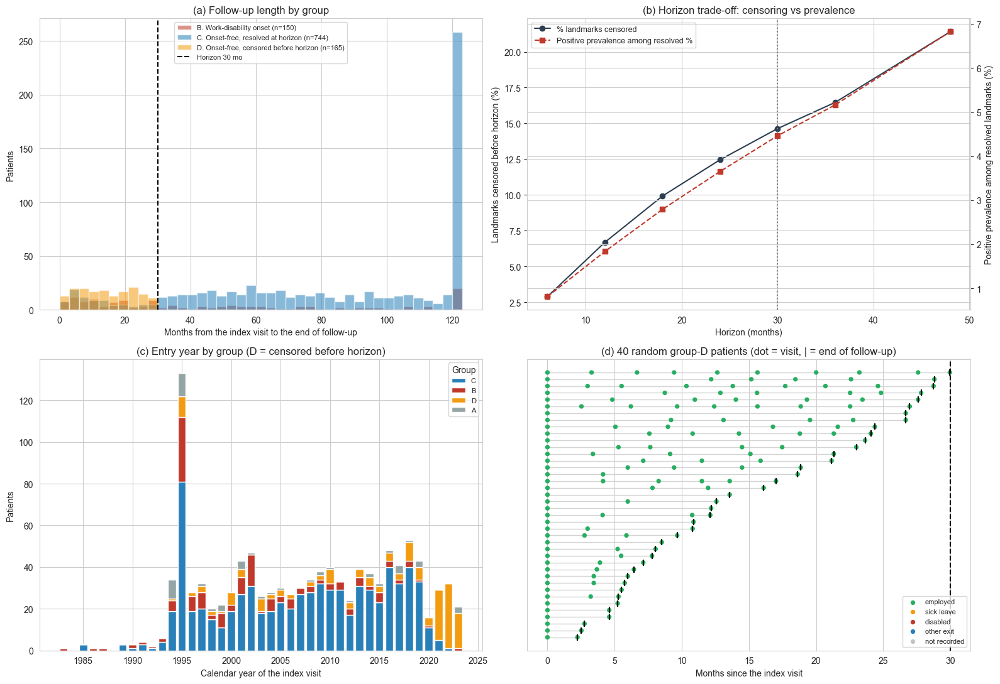

In [29]:
"""
Follow-up diagnostics for the landmark cohort. Run AFTER 11.2 (uses visits, land, patients_df, _state_of,
FEATURE_CANDIDATES, DISPLAY_NAMES, HORIZON_DAYS, MONTH_DAYS, AGE_CAP_YEARS, DEATH_AS_COMPETING_EVENT, CensoringKM).

No patient is dropped for short follow-up here: censored landmarks are kept and handled by IPCW. So the question is
not 'who is lost?' but 'who is censored before 30 months, why, and do they differ from the rest?'. Patient groups
(index = first employed visit before age 65; follow-up from it as in patients_df, i.e. cell 11.3):
  A  ever employed, no landmark (the only employed visit is the last recorded status)        -> excluded
  B  a work-disability onset at some landmark                                                 -> kept
  C  onset-free, resolved at the horizon: followed >= horizon, or other exit / death before it -> kept, label 0
  D  onset-free, censored before the horizon                                                  -> kept, IPCW-weighted
"""
GROUP_LABELS = {
    "A": "A. Employed only at the last recorded status (excluded)",
    "B": "B. Work-disability onset (kept)",
    "C": "C. Onset-free, resolved at horizon (kept)",
    "D": "D. Onset-free, censored before horizon (kept, IPCW)",
}
STATE_COLORS = {"W": "#27ae60", "S": "#f39c12", "D": "#c0392b", "O": "#2980b9", "U": "#bdc3c7"}


def followup_diagnostics(horizon_days=HORIZON_DAYS, horizon_grid_months=(6, 12, 18, 24, 30, 36, 48),
                         ltfu_window_days=365, n_swim=40, seed=CV_SEED, plot=True):
    H_m = horizon_days / MONTH_DAYS
    data_cut = visits["ASSDT"].max()
    gidx = visits.groupby("PTNO", sort=False).indices
    first_onset = land.loc[land["event"] == 1].groupby("pid")["event_date"].min()

    recs = []
    for pid, r in patients_df[patients_df["ever_employed"]].iterrows():
        p = visits.iloc[gidx[pid]]
        idx_date, fu_d = r["index_date"], r["km_time_days"]
        post = p[p["ASSDT"] >= idx_date]
        gaps = post["ASSDT"].diff().dt.days.dropna()
        last_visit = p["ASSDT"].max()                          # any visit (attendance)
        end_date = idx_date + pd.Timedelta(days=fu_d)          # end of index follow-up (last recorded status / cap)
        has_event = pid in first_onset.index
        if r["n_landmarks"] == 0:
            grp = "A"
        elif has_event:
            grp = "B"
        elif fu_d >= horizon_days or r["km_cause"] >= 2:
            grp = "C"
        else:
            grp = "D"
        reason = ""
        if grp == "D":
            if r["km_exit"] == "age_cap":
                reason = f"Reached age {AGE_CAP_YEARS}"
            elif r["dead"]:
                reason = "Died (censored at last recorded status)"
            elif r["trailing_unrecorded"] > 0:
                reason = "Later visits, employment status not recorded"
            elif (data_cut - last_visit).days <= ltfu_window_days:
                reason = "Still attending at data cut (late entry)"
            else:
                reason = "Stopped attending > 1 yr before data cut (probable LTFU)"
        lcdt = pd.to_datetime(p["LCDT"], errors="coerce").max()
        row = p.loc[p["ASSDT"] == idx_date].iloc[0]
        rec = {"pid": pid, "group": grp, "reason": reason, "has_event": has_event, "km_exit": r["km_exit"],
               "index_date": idx_date, "index_year": idx_date.year, "fu_m": fu_d / MONTH_DAYS,
               "time_to_event_m": (first_onset[pid] - idx_date).days / MONTH_DAYS if has_event else np.nan,
               "n_visits": len(post), "n_landmarks": r["n_landmarks"],
               "median_gap_d": gaps.median() if len(gaps) else np.nan,
               "max_gap_d": gaps.max() if len(gaps) else np.nan,
               "days_last_visit_to_cut": (data_cut - last_visit).days,
               "lcdt_minus_end_d": (lcdt - end_date).days if pd.notna(lcdt) else np.nan,
               "_visits": list(zip((post["ASSDT"] - idx_date).dt.days / MONTH_DAYS, post["EMP"].map(_state_of)))}
        rec.update({f"base_{c}": row[c] for c in FEATURE_CANDIDATES})
        recs.append(rec)
    d = pd.DataFrame(recs)
    W = 100

    # ------------------------------------------------------------------ 1. follow-up length by group
    print("=" * W)
    print(f"1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon {H_m:.0f} mo; data cut {data_cut.date()})")
    print("-" * W)
    print(f"{'GROUP':<58}{'N':>5}{'MEDIAN':>8}{'IQR':>16}{'MIN':>7}{'MAX':>7}")
    for g, lab in GROUP_LABELS.items():
        x = d.loc[d.group == g, "fu_m"]
        if len(x):
            print(f"{lab:<58}{len(x):>5}{x.median():>8.1f}{f'{x.quantile(.25):.1f} - {x.quantile(.75):.1f}':>16}"
                  f"{x.min():>7.1f}{x.max():>7.1f}")
    D = d[d.group == "D"]
    if len(D):
        edges = [0, 6, 12, 18, H_m - 6, H_m]
        labels = ["0-6 mo", "6-12 mo", "12-18 mo", f"18-{H_m - 6:.0f} mo", f"{H_m - 6:.0f}-{H_m:.0f} mo (near miss)"]
        t = pd.cut(D["fu_m"], bins=edges, labels=labels, include_lowest=True).value_counts().reindex(labels)
        print(f"\nGroup D: how far short of {H_m:.0f} months?")
        for lab, n in t.items():
            print(f"  {lab:<28}{n:>5}  {n / len(D):>6.1%}  cumulative {t.loc[:lab].sum() / len(D):>6.1%}")

        # ------------------------------------------------------------ 2. why is it short
        print("\n" + "=" * W)
        print("2. WHY IS FOLLOW-UP SHORT? (group D)")
        print("-" * W)
        r = D.groupby("reason").agg(N=("pid", "size"), median_fu_mo=("fu_m", "median"),
                                    median_last_visit_to_cut_d=("days_last_visit_to_cut", "median"))
        r["%"] = r["N"] / len(D) * 100
        print(r.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
        lc = D["lcdt_minus_end_d"].dropna()
        if len(lc):
            print(f"\nLCDT (last contact) minus end of follow-up, group D: median {lc.median():.0f} d; "
                  f"{(lc > 180).mean():.1%} have contact > 6 mo later (alive and in contact, status unknown)")

    # ------------------------------------------------------------------ 3. visit pattern
    print("\n" + "=" * W)
    print("3. VISIT PATTERN (from the index visit)")
    print("-" * W)
    vp = d.groupby("group").agg(N=("pid", "size"), visits_med=("n_visits", "median"),
                                landmarks_med=("n_landmarks", "median"), gap_med_d=("median_gap_d", "median"),
                                max_gap_med_d=("max_gap_d", "median"),
                                last_visit_to_cut_med_d=("days_last_visit_to_cut", "median"))
    print(vp.to_string(float_format=lambda v: f"{v:.1f}"))
    print("\nBy calendar year of the index visit (are recent entrants the censored ones?):")
    ct = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
    ct["% censored (D)"] = ct["D"] / ct.sum(axis=1) * 100
    print(ct.to_string(float_format=lambda v: f"{v:.0f}"))

    # ------------------------------------------------------------------ 4. horizon: how many landmark labels resolve
    print("\n" + "=" * W)
    print("4. HORIZON SENSITIVITY (landmark set is fixed; only which labels resolve changes)")
    print("-" * W)
    G = CensoringKM(T_ALL, C_ALL)
    rows = []
    for m in horizon_grid_months:
        H = round(m * MONTH_DAYS)
        h = land["time_days"] <= H
        pos = (land["cause"] == 1) & h
        neg = ~h | (land["cause"] >= 2)
        cens = ~pos & ~neg
        rows.append({"Horizon (mo)": m, "Positive rows": int(pos.sum()), "Negative rows": int(neg.sum()),
                     "Censored rows": int(cens.sum()), "% censored": 100 * cens.mean(),
                     "Prevalence among resolved %": 100 * pos.sum() / max((pos | neg).sum(), 1),
                     "Patients w/ positive row": land.loc[pos, "pid"].nunique(),
                     "G(h)": float(G.at([H])[0])})
    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

    # ------------------------------------------------------------------ 5. what dropping D would do
    print("\n" + "=" * W)
    print("5. WOULD DROPPING THE CENSORED PATIENTS BIAS THE COHORT?")
    print("-" * W)
    e = d[d.group != "A"]
    kept = e[e.group.isin(["B", "C"])]
    within = lambda x: (x["has_event"] & (x["time_to_event_m"] <= H_m))
    print(f"Onset within {H_m:.0f} mo of the index visit:")
    print(f"  crude, all patients with a landmark (censored = onset-free) : {within(e).mean():.1%}  (n={len(e)})")
    print(f"  crude, resolved patients only (B+C; drops D)                : {within(kept).mean():.1%}  (n={len(kept)})")
    km_in = patients_df.loc[e["pid"]]
    kmf = KaplanMeierFitter().fit(km_in["km_time_days"] / MONTH_DAYS, km_in["km_event"])
    print(f"  Kaplan-Meier (censoring-aware; other exits censored)        : {1 - kmf.predict(H_m):.1%}")
    print("  -> the gap between 'resolved only' and KM is the bias IPCW avoids by keeping group D.")

    if len(D):
        print(f"\nIndex-visit variables, resolved (B+C) vs censored (D) -- standardised mean difference:")
        out = []
        for c in [c for c in FEATURE_CANDIDATES if c != "YRS_SINCE_INDEX"]:   # 0 at every index visit
            a, b = kept[f"base_{c}"].astype(float), D[f"base_{c}"].astype(float)
            sd = np.sqrt((a.var() + b.var()) / 2)
            out.append({"Variable": DISPLAY_NAMES.get(c, c), "Resolved mean": a.mean(), "Censored mean": b.mean(),
                        "SMD": (a.mean() - b.mean()) / sd if sd > 0 else np.nan})
        smd = pd.DataFrame(out).sort_values("SMD", key=np.abs, ascending=False)
        smd["Flag"] = np.where(smd["SMD"].abs() > 0.1, "<-- imbalance (>0.1)", "")
        print(smd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
        print("(Calendar year is expected to differ: late entrants are censored. Cell 11.3.1 tests whether censoring "
              "is predictable from the variables.)")
    print("=" * W)

    # ------------------------------------------------------------------ plots
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(16, 11))
        a = ax[0, 0]
        bins = np.arange(0, min(d["fu_m"].max(), 120) + 6, 3)
        for g, col in [("B", "#c0392b"), ("C", "#2980b9"), ("D", "#f39c12")]:
            x = d.loc[d.group == g, "fu_m"].clip(upper=bins[-1] - 0.01)
            a.hist(x, bins=bins, alpha=0.55, color=col, label=GROUP_LABELS[g].split(" (")[0] + f" (n={len(x)})")
        a.axvline(H_m, color="black", ls="--", label=f"Horizon {H_m:.0f} mo")
        a.set_xlabel("Months from the index visit to the end of follow-up"); a.set_ylabel("Patients")
        a.set_title("(a) Follow-up length by group"); a.legend(fontsize=8)

        a = ax[0, 1]
        a.plot(sens["Horizon (mo)"], sens["% censored"], "o-", color="#2c3e50", label="% landmarks censored")
        a.set_xlabel("Horizon (months)"); a.set_ylabel("Landmarks censored before horizon (%)")
        a2 = a.twinx()
        a2.plot(sens["Horizon (mo)"], sens["Prevalence among resolved %"], "s--", color="#c0392b",
                label="Positive prevalence among resolved %")
        a2.set_ylabel("Positive prevalence among resolved landmarks (%)")
        a.axvline(H_m, color="gray", ls=":"); a.set_title("(b) Horizon trade-off: censoring vs prevalence")
        h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
        a.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)

        a = ax[1, 0]
        bottom = np.zeros(len(ct))
        for g, col in [("C", "#2980b9"), ("B", "#c0392b"), ("D", "#f39c12"), ("A", "#95a5a6")]:
            a.bar(ct.index, ct[g], bottom=bottom, color=col, label=g); bottom += ct[g].values
        a.set_xlabel("Calendar year of the index visit"); a.set_ylabel("Patients")
        a.set_title("(c) Entry year by group (D = censored before horizon)"); a.legend(title="Group", fontsize=8)

        a = ax[1, 1]
        sw = D.sample(min(n_swim, len(D)), random_state=seed).sort_values("fu_m") if len(D) else D
        for k, (_, r) in enumerate(sw.iterrows()):
            xs = [x for x, _ in r["_visits"]]
            a.plot([0, max(xs)], [k, k], color="lightgray", lw=1, zorder=1)
            a.scatter(xs, [k] * len(xs), c=[STATE_COLORS[s] for _, s in r["_visits"]], s=18, zorder=2)
            a.scatter([r["fu_m"]], [k], marker="|", color="black", s=60, zorder=3)
        a.axvline(H_m, color="black", ls="--"); a.set_yticks([])
        for s, lab in [("W", "employed"), ("S", "sick leave"), ("D", "disabled"), ("O", "other exit"), ("U", "not recorded")]:
            a.scatter([], [], c=STATE_COLORS[s], s=18, label=lab)
        a.legend(fontsize=8, loc="lower right")
        a.set_xlabel("Months since the index visit")
        a.set_title(f"(d) {len(sw)} random group-D patients (dot = visit, | = end of follow-up)")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/revised_v21_followup_diagnostics.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close()
    return d, sens


fu_df, horizon_table = followup_diagnostics()

## 11.6.1 Sample size and missing data

TRIPOD+AI items 10 and 11: the Riley et al. minimum sample size for the number of candidate parameters, at anticipated
C-statistics of 0.65, 0.70 and 0.75; and, for every variable, how often it was recorded at the landmark visits, how
much is still missing after carry-forward, and how the rest is handled.

In [30]:
"""
Sample size and missing data (TRIPOD+AI items 10 and 11).

SAMPLE SIZE. Minimum sample size for developing a prediction model of a binary outcome (Riley et al., BMJ 2020): the
largest n that meets
  (1) expected uniform shrinkage >= 0.9:          n = P / ((S - 1) ln(1 - R2_CS / S)), S = 0.9
  (2) optimism in Nagelkerke R2 <= 0.05:          as (1) with S = R2_CS / (R2_CS + 0.05 R2_CS,max)
  (3) overall risk estimated within +-0.05:       n = (1.96 / 0.05)^2 phi (1 - phi)
P = candidate predictor parameters, phi = outcome proportion, R2_CS = the anticipated Cox-Snell R2, derived from an
anticipated C-statistic (Riley et al. 2021: a logistic model with a normal linear predictor whose C-statistic and
outcome proportion match). The unit is the PATIENT (landmarks of one patient are not independent), with phi = the
share of patients with an onset. P is given for the cap of Section 11.5 (set by the time-to-event version of these criteria) and for the whole
candidate pool.
These criteria are for regression models; flexible models (RSF, LSTM, GRU, Transformer) typically need more data.

MISSING DATA. For each variable: how often its source was recorded AT the landmark visit, how often it is still
missing after carry-forward, and how the remainder is handled (multiple imputation, fitted inside each training fold).
"""
PRED_UNIT_N = int(land["pid"].nunique())
PRED_UNIT_EVENTS = int(land.groupby("pid")["event"].max().sum())
P_LINEAR = P_MAX                                       # the cap (Section 11.5): forced terms + the LASSO's selection
P_LOGREG = len(FEATURE_CANDIDATES)                     # every candidate after the pre-filter, if nothing were selected


def r2cs_from_c(c, phi, n=400_000, seed=SEED):
    """Cox-Snell R2 of a logistic model with a normal linear predictor whose C-statistic is c and mean risk phi."""
    z = np.random.RandomState(seed).standard_normal(n)
    expit = lambda v: 1.0 / (1.0 + np.exp(-v))

    def model(sigma):
        mu = brentq(lambda m: expit(m + sigma * z).mean() - phi, -30, 30)
        return mu + sigma * z, expit(mu + sigma * z)

    def c_of(sigma):
        lp, p = model(sigma)
        return roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[lp, lp], sample_weight=np.r_[p, 1 - p])

    sigma = brentq(lambda s: c_of(s) - c, 0.01, 6.0)
    _, p = model(sigma)
    ll_model = np.mean(p * np.log(p) + (1 - p) * np.log(1 - p))
    ll_null = phi * np.log(phi) + (1 - phi) * np.log(1 - phi)
    return 1 - np.exp(-2 * (ll_model - ll_null)), 1 - np.exp(2 * ll_null)


def riley_sample_size(P, phi, c):
    r2, r2max = r2cs_from_c(c, phi)
    n_of = lambda S: P / ((S - 1) * np.log(1 - r2 / S))
    s2 = r2 / (r2 + 0.05 * r2max)
    n1, n2, n3 = n_of(0.9), n_of(s2), (1.96 / 0.05) ** 2 * phi * (1 - phi)
    n = int(np.ceil(max(n1, n2, n3)))
    return {"Anticipated C": c, "Predictor parameters (P)": P, "Anticipated R2_CS": round(r2, 3),
            "n: shrinkage >= 0.9": int(np.ceil(n1)), "n: optimism <= 0.05": int(np.ceil(n2)),
            "n: overall risk +-0.05": int(np.ceil(n3)), "Minimum n (patients)": n,
            "Minimum events": int(np.ceil(n * phi)), "Events per parameter needed": round(n * phi / P, 1)}


phi_pt = PRED_UNIT_EVENTS / PRED_UNIT_N
sample_size = pd.DataFrame([riley_sample_size(P, phi_pt, c) for P in (P_LINEAR, P_LOGREG) for c in (0.65, 0.70, ANTICIPATED_C, 0.75)])
print(f"Available: {PRED_UNIT_N} patients, {PRED_UNIT_EVENTS} with a work-disability onset (phi = {phi_pt:.3f}); "
      f"{PRED_UNIT_EVENTS / P_LINEAR:.1f} events per parameter at the cap of {P_LINEAR} parameters, "
      f"{PRED_UNIT_EVENTS / P_LOGREG:.1f} for all {P_LOGREG} candidates (binary approximation below; the cap itself "
      f"comes from the time-to-event version, Section 11.5).")
display(sample_size.set_index(["Predictor parameters (P)", "Anticipated C"]))
print("Minimum sample size met for:", ", ".join(f"P = {r['Predictor parameters (P)']}, C = {r['Anticipated C']}"
                                                for _, r in sample_size.iterrows()
                                                if r["Minimum n (patients)"] <= PRED_UNIT_N) or "none")

# ---------------------------------------------------------------------------------------------------- missing data


def _handling(c):
    if c in TREATMENT_COLS:
        return "not recorded at the visit = not on the drug (0); never imputed"
    if c.endswith("_NA"):
        return f"indicator: not measured in the last {STALE_MONTHS} months (complete)"
    if c in STALE_CONT or c in ("HIGH_BP", "EGFR_LT60"):
        return (f"carried forward for at most {STALE_MONTHS} months; then multiply imputed (auxiliaries: the last value "
                f"ever recorded and its age)")
    if c in ADJUST_COLS:
        return "visit date (never missing); clipped to the training years at prediction"
    if c in PATIENT_CONSTANT_COLS:
        return "patient-level; multiply imputed (one value per patient)" + ("; + 'not recorded' indicator"
                                                                           if c == "EDU_HIGHER" else "")
    return "carried forward (or derived from carried-forward items); the remainder multiply imputed"


missing_table = pd.DataFrame([{"Group": FEATURE_GROUP_OF.get(c, ""), "Variable": DISPLAY_NAMES.get(c, c),
                               "Missing after carry-forward / derivation": f"{land[c].isna().mean():.1%}",
                               "Handling": _handling(c)} for c in FEATURE_CANDIDATES]).set_index("Variable")
print("\nMissing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, "
      f"then multiple imputation by chained equations (m = {M_IMPUTATIONS}, "
      f"{'random-forest' if IMPUTATION == 'rf' else 'Bayesian linear'} conditionals with draws, fitted on each training "
      "fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and "
      "the predicted risks are averaged.")
display(missing_table)

Available: 1059 patients, 150 with a work-disability onset (phi = 0.142); 8.8 events per parameter at the cap of 17 parameters, 1.9 for all 81 candidates (binary approximation below; the cap itself comes from the time-to-event version, Section 11.5).


Anticipated R2_CS  \
Predictor parameters (P) Anticipated C                      
17                       0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   
81                       0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   

                                        n: shrinkage >= 0.9  \
Predictor parameters (P) Anticipated C                        
17                       0.65                          4311   
                         0.70                          2367   
                         0.72                          1933   
                         0.75                          1466   
81                       0.65                         20541   
                         0.70                         11274   
                         0.72                          9207   
                         0.75                          6985   

                                        n: optimism <= 0.05  \
Predictor parameters (P) Anticipated C                        
17                       0.65                           591   
                         0.70                           582   
                         0.72                           578   
                         0.75                           571   
81                       0.65                          2813   
                         0.70                          2772   
                         0.72                          2752   
                         0.75                          2717   

                                        n: overall risk +-0.05  \
Predictor parameters (P) Anticipated C                           
17                       0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   
81                       0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   

                                        Minimum n (patients)  Minimum events  \
Predictor parameters (P) Anticipated C                                         
17                       0.65                           4311             611   
                         0.70                           2367             336   
                         0.72                           1933             274   
                         0.75                           1466             208   
81                       0.65                          20541            2910   
                         0.70                          11274            1597   
                         0.72                           9207            1305   
                         0.75                           6985             990   

                                        Events per parameter needed  
Predictor parameters (P) Anticipated C                               
17                       0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2  
81                       0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2

Minimum sample size met for: none

Missing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, then multiple imputation by chained equations (m = 5, random-forest conditionals with draws, fitted on each training fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and the predicted risks are averaged.


,Group,Missing after carry-forward / derivation,Handling
Variable,,,
Age,Demographics,0.0%,carried forward (or derived from carried-forwa...
Sex: female,Demographics,0.0%,patient-level; multiply imputed (one value per...
Education: higher,Demographics,12.4%,patient-level; multiply imputed (one value per...
Current smoker,Demographics,0.5%,carried forward (or derived from carried-forwa...
BMI (kg/m2),Demographics,17.3%,carried forward for at most 12 months; then mu...
Disease duration (yrs),Demographics,0.0%,carried forward (or derived from carried-forwa...
Age at diagnosis,Demographics,0.0%,carried forward (or derived from carried-forwa...
SDI damage score,Comorbidities and damage,0.0%,carried forward (or derived from carried-forwa...
SDI change since last visit,Comorbidities and damage,0.0%,carried forward (or derived from carried-forwa...


## 11.6.2 Participant flow

TRIPOD+AI item 20a: patients and landmark visits at every step, with events, for the visit-level analysis and the
patient-level evaluation.

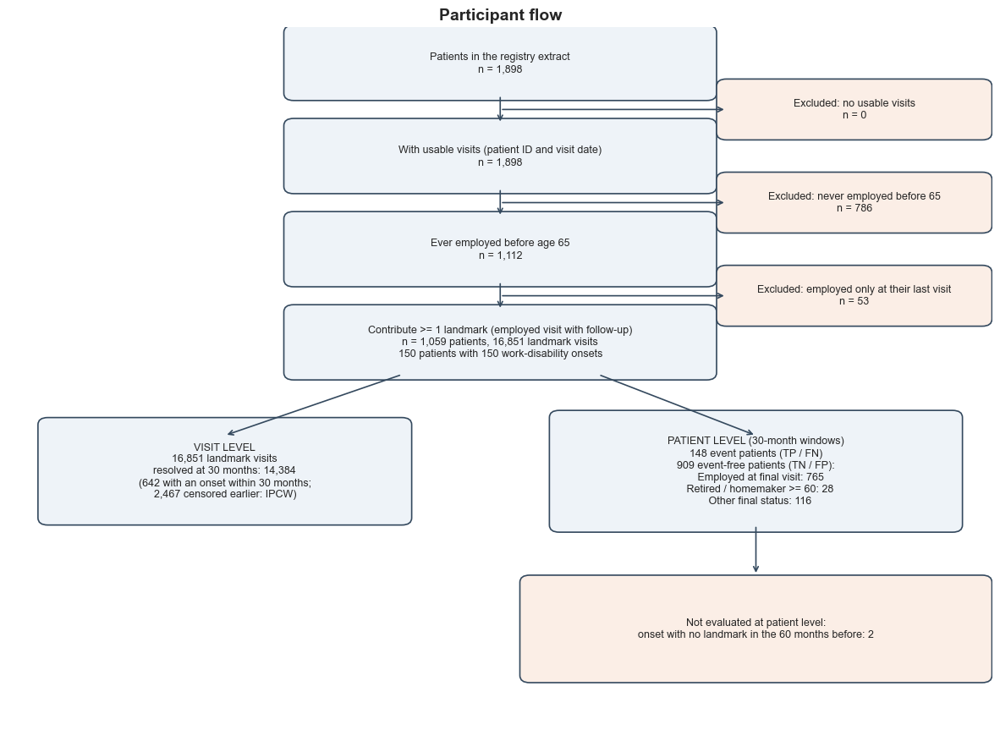

In [31]:
"""Participant flow diagram (TRIPOD+AI item 20a): patients and landmark visits at every step, with events, for the
visit-level analysis (left) and the patient-level evaluation (right)."""
from matplotlib.patches import FancyBboxPatch


def _box(ax, x, y, text, w=0.3, h=0.085, fc="#eef3f8"):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01", fc=fc, ec="#34495e", lw=1.2))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def _arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="#34495e", lw=1.2))


def plot_flow():
    a, pts, t = load_audit, patients_df, PT_TRUTH
    y30, w30 = ipcw_label_weight(T_ALL, C_ALL, HORIZON_DAYS, CensoringKM(T_ALL, C_ALL))
    n_onsets = int((land.loc[land["event"] == 1, "visit_date"] + pd.to_timedelta(
        land.loc[land["event"] == 1, "time_days"], unit="D")).groupby(land.loc[land["event"] == 1, "pid"]).nunique().sum())
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    steps = [(0.95, f"Patients in the registry extract\nn = {a['raw_patients']:,}"),
             (0.82, f"With usable visits (patient ID and visit date)\nn = {a['usable_patients']:,}"),
             (0.69, f"Ever employed before age {AGE_CAP_YEARS}\nn = {int(pts['ever_employed'].sum()):,}"),
             (0.56, f"Contribute >= 1 landmark (employed visit with follow-up)\nn = {land['pid'].nunique():,} patients, "
                    f"{len(land):,} landmark visits\n{int(t.stratum.eq('Event').sum())} patients with "
                    f"{n_onsets} work-disability onsets")]
    for (y, txt), (y2, _) in zip(steps, steps[1:] + [(None, None)]):
        _box(ax, 0.5, y, txt, w=0.42)
        if y2 is not None:
            _arrow(ax, 0.5, y - 0.045, 0.5, y2 + 0.045)
    excl = [(0.885, f"Excluded: no usable visits\nn = {a['raw_patients'] - a['usable_patients']:,}"),
            (0.755, f"Excluded: never employed before {AGE_CAP_YEARS}\n"
                    f"n = {a['usable_patients'] - int(pts['ever_employed'].sum()):,}"),
            (0.625, f"Excluded: employed only at their last visit\n"
                    f"n = {int(pts['ever_employed'].sum()) - land['pid'].nunique():,}")]
    for y, txt in excl:
        _box(ax, 0.86, y, txt, w=0.26, h=0.065, fc="#fbeee6")
        _arrow(ax, 0.5, y, 0.73, y)
    # visit level
    _arrow(ax, 0.4, 0.515, 0.22, 0.43)
    _box(ax, 0.22, 0.38, f"VISIT LEVEL\n{len(land):,} landmark visits\nresolved at 30 months: {int((w30 > 0).sum()):,}\n"
                         f"({int(((y30 == 1) & (w30 > 0)).sum()):,} with an onset within 30 months;\n"
                         f"{int((w30 == 0).sum()):,} censored earlier: IPCW)", w=0.36, h=0.13)
    # patient level
    _arrow(ax, 0.6, 0.515, 0.76, 0.43)
    neg = t[t.group == "negative"]
    _box(ax, 0.76, 0.38, f"PATIENT LEVEL (30-month windows)\n{int(t.group.eq('event').sum())} event patients "
                         f"(TP / FN)\n{len(neg)} event-free patients (TN / FP):\n"
                         + "\n".join(f"   {s}: {int(neg.stratum.eq(s).sum())}" for s in STRATA), w=0.4, h=0.15)
    ex = t[t.group == "excluded"]["reason"].value_counts()
    _arrow(ax, 0.76, 0.305, 0.76, 0.235)
    _box(ax, 0.76, 0.16, "Not evaluated at patient level:\n" + "\n".join(f"{r}: {n}" for r, n in ex.items()),
         w=0.46, h=0.13, fc="#fbeee6")
    ax.set_title("Participant flow", fontsize=14, fontweight="bold")
    plt.savefig(f"{OUT_DIR}/revised_v21_flow_diagram.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


plot_flow()

## 11.7 Sequential models (time-aware LSTM / GRU / Transformer)

Section 6.1. The main model is the LSTM; GRU and Transformer use the same recipe. A smoke test on 40 real
patients (half with an onset) runs at the end of the cell. It checks whole-history and windowed batching, pretraining,
the cause-specific hazard heads (with the interval-censored likelihood and the warm start), early stopping and the seed ensemble in a few seconds.

In [32]:
"""Sequence models: the main LSTM, plus GRU and Transformer on the same recipe.

  * Encoder: a 1-layer LSTM with 16 hidden units (the main LSTM and its variants; GRU / Transformer 32), dropout 0.3 on
    its output. GRU and Transformer: one pass per patient over the WHOLE visit history (visits before the index visit and
    while not employed included), with a prediction at every landmark. The LSTM reads each landmark's last 8 visits
    (LSTM1: the current visit alone).
  * Skip connection (the LSTMs): the heads also receive the current visit's variables, warm-started from a
    person-interval logistic regression. Auxiliary heads (the LSTMs; aux): three logistic heads on the hidden state
    predict AUX_TARGETS within 12 months (masked binary cross-entropy, patient-weighted, x aux_weight), training only.
  * Inputs per visit: the CV-optimal LASSO set (Section 11.5; the capped selection if not SEQ_WIDE_INPUTS), log(1 + years since the previous visit), and the
    visit's employment state (employed / sick leave / disabled / other exit, one-hot). The calendar year (ADJUST_COLS,
    clipped to the training years) is NOT an encoder input: it feeds the hazard heads only. Scaled with the training
    fold's landmark rows (skew transform + multiple imputation + standardisation + clipping); seed s of the ensemble
    trains on imputation s (mod M_IMPUTATIONS).
  * Self-supervised pretraining: before seeing any disability label, the encoder learns to predict the next visit's
    SLEDAI-2K, SDI and steroid dose (squared error) from the history and the gap to that visit, for 10 epochs, on every
    patient outside the held-out ones. Pretraining is redone for every seed.
  * Heads: one linear layer from the hidden state to a logistic hazard per 3-month interval (16 intervals) for work
    disability and, with exit_head, a second one for other exits (and death, if counted): discrete-time
    cause-specific hazards, each head treating the other cause as censoring. Output: the cause-specific risk of work
    disability, R(k) = 1 - prod_{j <= k} (1 - h_1(j)).
  * Loss: the cause-specific likelihood (cs_hazard_nll) -- survived intervals log(1 - h); an event log h_b, or
    log[S(a - 1) - S(b)] when interval-censored between the last employed visit and the recording visit -- weighted by
    the landmark weight (and 1 / G_k(x) with covariate IPCW). No class weights or balanced batches.
  * Warm start: interval biases at the training life-table (Kaplan-Meier) hazards; then the calendar-year weights
    and the biases (with the skip connection, also the skip weights) from a person-interval logistic regression.
  * Training: AdamW (lr 3e-3, weight decay 1e-2),
    gradient clipping, batches of 64 patients, up to 60 epochs with EARLY STOPPING (patience 8) on 20% of the fit's
    patients held out as a validation set; the best-validation weights are kept.
  * Ensemble: 5 seeds (each with its own pretraining, initialisation and validation split) in the outer-fold fit; their
    per-interval hazards are averaged.
  * LSTM history window: fixed (SEQ_GRIDS; the main LSTM k = 8, LSTM1 k = 1, supplementary k = 4, 16).

GRU and Transformer: the identical recipe (inputs, pretraining, head, early stopping, 5 seeds) with a GRU cell or a
1-layer causal Transformer (2 heads, feed-forward 64, lr 1e-3, plus elapsed years since the first visit as an input).

History window (max_visits; None = whole history for GRU and Transformer): each landmark sees only its last k
visits (Section 11.12.1).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

#torch.set_num_threads(max(1, os.cpu_count() or 1))
torch.set_num_threads(1) 
VIS_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + AUX_ALL))               # every candidate + imputation auxiliaries
VX_RAW = visits[VIS_COLS].values.astype(float)                             # encoder features, every visit
VIS_IDX = {c: j for j, c in enumerate(VIS_COLS)}
V_GAP = np.log1p(visits.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0.0).values / 365.25).astype(np.float32)
V_STATE = visits[["EMP_WORKING", "EMP_SICK", "EMP_DISABLED", "EMP_OTHER"]].values.astype(np.float32)
V_ELAPSED = ((visits["ASSDT"] - visits.groupby("PTNO")["ASSDT"].transform("min")).dt.days.values
             / 365.25 / 10.0).astype(np.float32)                           # decades since the first visit (Transformer)
PRETRAIN_COLS = ["SLEDAI2_I", "score_n", "STERAVER_0"]                   # next-visit targets of the pretraining
_tg = visits[PRETRAIN_COLS].values.astype(float)                          # label-free: standardised over all visits
_tg = np.where(np.isnan(_tg), np.nanmedian(_tg, 0), _tg)
V_PRETRAIN_TGT = ((_tg - _tg.mean(0)) / (_tg.std(0) + 1e-8)).astype(np.float32)
PATIENT_ROWS = visits.groupby("PTNO", sort=False).indices                 # pid -> visit row indices (date order)
_VROW_TO_POS = np.empty(len(visits), dtype=np.int64)
for _pid, _rows in PATIENT_ROWS.items():
    _VROW_TO_POS[_rows] = np.arange(len(_rows))
LAND_POS = _VROW_TO_POS[land["visit_row"].values]                         # landmark -> position in its patient
SEQ_KIND = {**{m: "lstm" for m in SEQ_GRIDS if m.startswith("LSTM")}, "GRU": "gru", "Transformer": "transformer"}
N_STATE = V_STATE.shape[1]


def seq_cfg(model, cfg_name):
    return {**SEQ_CONFIG, **SEQ_GRIDS[model][cfg_name]}


def cif_from_probs(P):
    """(n, K, N_CLASSES) per-interval class probabilities -> (n, K) cumulative incidence of work disability."""
    S = np.cumprod(P[..., 0], axis=-1)
    S_prev = np.concatenate([np.ones_like(S[..., :1]), S[..., :-1]], axis=-1)
    return np.cumsum(S_prev * P[..., 1], axis=-1)


def cif_to_risk(cif):
    """(n, K) cumulative incidence -> (n, n_horizons) risk of onset by each evaluation horizon."""
    return cif[:, np.array(HORIZON_INTERVALS) - 1]


def hazard_risk(Hz, head=0):
    """(n, H, K) per-interval hazards -> (n, n_horizons) cause-specific risk 1 - prod(1 - h) of head `head` by each
    evaluation horizon (head 0 = work disability, 1 = other exit)."""
    return cif_to_risk(1.0 - np.cumprod(1.0 - Hz[:, head], axis=-1))


def composite_risk(Hz):
    """Risk of leaving work for any reason by each horizon, 1 - prod_k (1 - h_1k)(1 - h_2k)."""
    return cif_to_risk(1.0 - np.cumprod((1.0 - Hz[:, 0]) * (1.0 - Hz[:, 1]), axis=-1))


def cs_hazard_nll(z, S, E, W, w):
    """Weighted negative log-likelihood of cause-specific discrete-time (logistic) hazards.
    z: (n, H, K) hazard logits; S, E: (n, H, K) survived / event intervals (cause_specific_targets); W: (n, K) interval
    weights (1 / G_k(x), or ones); w: (n,) patient weights. Per landmark and cause:
        sum_{k survived} W_k log(1 - h_k)  +  W_a log(1 - prod_{k=a..b} (1 - h_k))   (if an event in [a, b]),
    i.e. log h_b for an exactly dated event (a = b) and log[S(a-1) - S(b)] - log S(a-1) for an interval-censored one.
    Normalised by the sum of the patient weights."""
    log_s = F.logsigmoid(-z)                                               # log(1 - h)
    ll = (S * W.unsqueeze(1) * log_s).sum(-1)                              # (n, H)
    has = E.sum(-1) > 0
    s_ev = (E * log_s).sum(-1).clamp(max=-1e-7)                            # log P(no event over [a, b])
    w_ev = W.unsqueeze(1).expand_as(E).gather(-1, E.argmax(-1, keepdim=True)).squeeze(-1)   # weight of interval a
    ll = ll + torch.where(has, w_ev * torch.log(-torch.expm1(s_ev)), torch.zeros_like(s_ev))
    return -(ll.sum(-1) * w).sum() / w.sum().clamp(min=1e-8)


class SeqNet(nn.Module):
    """Encoder over [variables, log(1 + gap), employment state] at every visit; per-visit hazard head with
    n_hazards x N_INTERVALS logits (work disability, + other exit with exit_head) on [hidden state, (current variables
    with skip), calendar year]; pretraining head for the next visit's PRETRAIN_COLS. adj_idx: the columns of x that
    feed the head only (the calendar year)."""

    def __init__(self, n_feat, kind="lstm", hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64, skip=False,
                 time_decay=False, state_pretrain=False, exit_head=True, adj_idx=(), aux=False, aux_weight=0.0, **_):
        super().__init__()
        self.n_aux, self.aux_weight = (len(AUX_TARGETS) if aux else 0), float(aux_weight)
        self.kind, self.hidden, self.skip, self.state_pretrain = kind, hidden, skip, state_pretrain
        self.n_hazards = 2 if exit_head else 1
        self.time_decay = time_decay and kind in ("lstm", "gru") and layers == 1
        self.adj_idx = list(adj_idx)                                        # columns of x that feed the head only
        self.enc_idx = [j for j in range(n_feat) if j not in self.adj_idx]  # columns of x read by the encoder
        self.head_idx = (self.enc_idx if skip else []) + self.adj_idx       # columns of x fed to the head
        n_in = len(self.enc_idx) + 1 + N_STATE
        if self.time_decay:                                                 # GRU-D style decay of the memory
            self.cell = nn.LSTMCell(n_in, hidden) if kind == "lstm" else nn.GRUCell(n_in, hidden)
            self.h_decay = nn.Linear(1, hidden)
        elif kind == "lstm":
            self.rnn = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        elif kind == "gru":
            self.rnn = nn.GRU(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        else:
            self.proj = nn.Linear(n_in + 1, hidden)                         # + elapsed time since the first visit
            layer = nn.TransformerEncoderLayer(hidden, n_heads, dim_feedforward=ff_dim, dropout=drop,
                                               batch_first=True, norm_first=True)
            self.encoder = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
            self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden + len(self.head_idx), self.n_hazards * N_INTERVALS)
        self.pre_head = nn.Linear(hidden + 1, len(PRETRAIN_COLS) + (N_STATE if state_pretrain else 0))
        self.aux_head = nn.Linear(hidden, self.n_aux) if self.n_aux else None
        self.max_visits = None                                              # set by the fitter (history window)

    def encode(self, b):
        inp = torch.cat([b["x"][..., self.enc_idx], b["gap"].unsqueeze(-1), b["state"]], dim=-1)
        T = inp.shape[1]
        if self.kind == "transformer":
            h = self.proj(torch.cat([inp, b["elapsed"].unsqueeze(-1)], dim=-1))
            causal = torch.triu(torch.full((T, T), float("-inf")), diagonal=1)
            # padding sits AFTER every real visit, so the causal mask keeps it out of every real visit's context
            return self.norm(self.encoder(h, mask=causal))
        if self.time_decay:
            B = inp.shape[0]
            h, c = inp.new_zeros(B, self.hidden), inp.new_zeros(B, self.hidden)
            outs = []
            for t in range(T):
                g = torch.exp(-torch.relu(self.h_decay(b["gap"][:, t:t + 1])))   # memory fades with the visit gap
                if self.kind == "lstm":
                    h, c = self.cell(inp[:, t], (h * g, c * g))
                else:
                    h = self.cell(inp[:, t], h * g)
                outs.append(h)
            return torch.stack(outs, dim=1)                                 # padding comes after every real visit
        packed = pack_padded_sequence(inp, b["lengths"], batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        return pad_packed_sequence(out, batch_first=True, total_length=T)[0]

    def forward_with_aux(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) and auxiliary logits (B, T, n_aux) or None."""
        H = self.drop(self.encode(b))
        out = self.head(torch.cat([H, b["x"][..., self.head_idx]], dim=-1) if self.head_idx else H)
        return out.view(*out.shape[:2], self.n_hazards, N_INTERVALS), (self.aux_head(H) if self.n_aux else None)

    def forward(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) at every visit."""
        return self.forward_with_aux(b)[0]

    def pretrain_out(self, b):
        H = self.drop(self.encode(b))
        gap_next = torch.cat([b["gap"][:, 1:], b["gap"].new_zeros(b["gap"].shape[0], 1)], dim=1).unsqueeze(-1)
        return self.pre_head(torch.cat([H, gap_next], dim=-1))


def make_seq_net(model, n_feat, cfg, adj_idx=()):
    return SeqNet(n_feat, kind=SEQ_KIND[model], adj_idx=adj_idx, **cfg)


class SeqData:
    """Scaled encoder features for every visit, plus the landmark targets placed at their visits."""

    def __init__(self, prep, cols):
        self.cols = list(cols)
        self.VXs = [V.astype(np.float32) for V in
                    prep.transform(VX_RAW[:, [VIS_IDX[c] for c in prep.in_cols]], visits["PTNO"].values)]
        self.VX = self.VXs[0]
        self.cw = None                                                       # (len(land), K) interval IPCW weights

    def view(self, k):
        """The same data with imputation k as the encoder features."""
        d = copy.copy(self)
        d.VX = self.VXs[k]
        return d

    def batch(self, pids, lbp=None, max_visits=None):
        """Padded tensors for patients `pids`. Without lbp: whole visit histories (pretraining). With lbp (dict
        pid -> landmark rows): sequences stop at each patient's last landmark and the landmark targets come along
        (land_b / land_t give each landmark's position in the batch). With max_visits, every landmark becomes its own
        sequence of its last max_visits visits. One vectorised gather (the same tensors as batch_reference)."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            R_, L = window_rows(max_visits)
            L = L[li]
            land_b = np.arange(len(li))
            land_t = L - 1
        if lbp is None or max_visits is None:
            L = np.array([len(r) for r in seqs])
            R_ = np.zeros((len(seqs), L.max()), np.int64)
            for b, r in enumerate(seqs):
                R_[b, :len(r)] = r
            rows = R_
        else:
            rows = R_[li, :L.max()]
        T, B = L.max(), len(L)
        mask = np.arange(T)[None, :] < L[:, None]                          # real visits; padding after them
        r = rows[mask]
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        x[mask], st[mask], gap[mask], tg[mask] = self.VX[r], V_STATE[r], V_GAP[r], V_PRETRAIN_TGT[r]
        el[mask] = V_ELAPSED[r] - np.repeat(V_ELAPSED[rows[:, 0]], L)
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg))
        if lbp is not None:
            cw = np.ones((len(li), N_INTERVALS), np.float32) if self.cw is None else self.cw[li]
            out.update(s=torch.from_numpy(S_CS[li]), e=torch.from_numpy(E_CS[li]), cw=torch.from_numpy(cw),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       aux_y=torch.from_numpy(AUX_Y[li]), aux_m=torch.from_numpy(AUX_M[li]),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out

    def batch_reference(self, pids, lbp=None, max_visits=None):
        """revised_v20's loop version of batch() (kept for the equality check in smoke_test_seq)."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            seqs = [PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - max_visits + 1): LAND_POS[l] + 1] for l in li]
            land_b = np.arange(len(li))
            land_t = np.array([len(r) - 1 for r in seqs])
        L = np.array([len(r) for r in seqs])
        T, B = L.max(), len(seqs)
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        for b, r in enumerate(seqs):
            n = len(r)
            x[b, :n], st[b, :n], gap[b, :n], el[b, :n], tg[b, :n] = \
                self.VX[r], V_STATE[r], V_GAP[r], V_ELAPSED[r] - V_ELAPSED[r[0]], V_PRETRAIN_TGT[r]
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg))
        if lbp is not None:
            cw = np.ones((len(li), N_INTERVALS), np.float32) if self.cw is None else self.cw[li]
            out.update(s=torch.from_numpy(S_CS[li]), e=torch.from_numpy(E_CS[li]), cw=torch.from_numpy(cw),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       aux_y=torch.from_numpy(AUX_Y[li]), aux_m=torch.from_numpy(AUX_M[li]),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out


_WINDOW_ROWS = {}


def window_rows(k):
    """(len(land), k) visit rows of every landmark's last k visits (padding 0 after them) and their number."""
    if k not in _WINDOW_ROWS:
        R = np.zeros((len(land), k), np.int64)
        L = np.zeros(len(land), np.int64)
        for l in range(len(land)):
            r = PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - k + 1): LAND_POS[l] + 1]
            R[l, :len(r)], L[l] = r, len(r)
        _WINDOW_ROWS[k] = (R, L)
    return _WINDOW_ROWS[k]


def land_by_pid(idx):
    idx = np.asarray(idx)
    return {p: np.asarray(r) for p, r in pd.Series(idx).groupby(PID_ALL[idx])}


def _batches(pids, size, rng):
    """Length-bucketed batches: sort by sequence length, chunk, shuffle the chunks (rng None: keep the order)."""
    order = sorted(pids, key=lambda p: len(PATIENT_ROWS[p]))
    chunks = [order[i:i + size] for i in range(0, len(order), size)]
    if rng is not None:
        rng.shuffle(chunks)
    return chunks


def pretrain(net, data, pids, cfg, seed):
    """Next-visit SLEDAI-2K / SDI / steroid dose (squared error), plus the next employment state (cross-entropy) if
    state_pretrain, over every visit of patients `pids`."""
    rng = np.random.RandomState(seed)
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    for _ in range(cfg["pretrain_epochs"]):
        net.train()
        for chunk in _batches(pids, cfg["batch_patients"], rng):
            b = data.batch(chunk)
            out = net.pretrain_out(b)[:, :-1]
            nc = len(PRETRAIN_COLS)
            valid = (torch.arange(out.shape[1]).unsqueeze(0) < (b["lengths"] - 1).unsqueeze(1)).float()
            loss = (((out[..., :nc] - b["tgt"][:, 1:]) ** 2).mean(-1) * valid).sum() / valid.sum().clamp(min=1)
            if net.state_pretrain:                                          # + next visit's employment state
                nxt = b["state"][:, 1:].argmax(-1)
                ce = F.cross_entropy(out[..., nc:].reshape(-1, N_STATE), nxt.reshape(-1), reduction="none")
                loss = loss + (ce.view_as(valid) * valid).sum() / valid.sum().clamp(min=1)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()


def _landmark_loss(net, data, b):
    z, a = net.forward_with_aux(b)
    z = z[b["land_b"], b["land_t"]]                                        # (nL, n_hazards, K) hazard logits
    H = net.n_hazards
    loss = cs_hazard_nll(z, b["s"][:, :H], b["e"][:, :H], b["cw"], b["w"])
    if net.n_aux:                                                          # auxiliary 12-month heads (training only)
        a = a[b["land_b"], b["land_t"]]
        bce = F.binary_cross_entropy_with_logits(a, b["aux_y"], reduction="none") * b["aux_m"]
        per = bce.sum(-1) / b["aux_m"].sum(-1).clamp(min=1.0)
        loss = loss + net.aux_weight * (per * b["w"]).sum() / b["w"].sum().clamp(min=1e-8)
    return loss


def _warm_start_head(net, data, tr_idx, warm_start):
    """Head initialisation from the training landmarks. Every interval's bias starts at the life-table (Kaplan-Meier)
    hazard of its cause, sum(w * events) / sum(w * at risk); interval-censored events count in their last possible
    interval here. With warm_start, the weights of the head's direct inputs (the calendar year; with a skip connection
    also the current visit's variables) and the biases come from a person-interval logistic regression of the event on
    those inputs and interval indicators (the discrete-time equivalent of a logistic-regression warm start)."""
    H, K = net.n_hazards, N_INTERVALS
    S, E = S_CS[tr_idx, :H], E_CS[tr_idx, :H]
    w = norm_weights(land["weight"].values[tr_idx])
    ev = E.sum(-1) > 0                                                      # (n, H)
    last = (E * np.arange(1, K + 1)).argmax(-1)                            # last possible interval of the event
    D = np.zeros_like(E)
    r, h = np.nonzero(ev)
    D[r, h, last[r, h]] = 1.0
    R = np.maximum(S, E)                                                    # at risk in the interval
    Wt = net.head.weight.data.view(H, K, -1)
    bt = net.head.bias.data.view(H, K)
    X = data.VX[land["visit_row"].values[tr_idx]][:, net.head_idx] if (net.head_idx and warm_start) else None
    for c in range(H):
        d, n = (w[:, None] * D[:, c]).sum(0), (w[:, None] * R[:, c]).sum(0)
        haz = np.clip(np.where(n > 0, d / np.maximum(n, 1e-12), 0.0), 1e-4, 0.5)
        bt[c] = torch.as_tensor(np.log(haz / (1 - haz)), dtype=torch.float32)
        if X is not None and ev[:, c].any():
            rr, kk = np.nonzero(R[:, c])
            ck = fc_key("warm_start", X, R[:, c], D[:, c], w)              # the same for every skip-LSTM and seed
            coef = fc_get("warm_start", ck)
            if coef is None:
                lr = LogisticRegression(C=1.0, fit_intercept=False, max_iter=2000).fit(
                    np.hstack([X[rr], np.eye(K)[kk]]), D[rr, c, kk], sample_weight=w[rr])
                coef = fc_put("warm_start", ck, lr.coef_[0].copy())
            p = X.shape[1]
            Wt[c, :, net.hidden:] = torch.as_tensor(coef[:p], dtype=torch.float32).expand(K, -1)
            bt[c] = torch.as_tensor(coef[p:], dtype=torch.float32)


def _validation_split(fit_idx, seed, frac):
    """Patients of fit_idx split into training / early-stopping validation, stratified by patient event status."""
    pts = pd.Series(land["pt_event"].values[fit_idx], index=PID_ALL[fit_idx]).groupby(level=0).max()
    rng = np.random.RandomState(seed)
    val = set()
    for _, g in pts.groupby(pts):
        val |= set(rng.choice(g.index.values, int(round(frac * len(g))), replace=False))
    is_val = np.isin(PID_ALL[fit_idx], list(val))
    return fit_idx[~is_val], fit_idx[is_val]


def train_one(data, fit_idx, model, cfg, seed, pre_pids):
    """One seed: (pretraining) -> warm-started hazard head -> early-stopped fine-tuning."""
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    net = make_seq_net(model, data.VX.shape[1], cfg,
                       adj_idx=[data.cols.index(c) for c in ADJUST_COLS if c in data.cols])
    net.max_visits = cfg["max_visits"]
    if cfg["pretrain"]:
        pretrain(net, data, pre_pids, cfg, seed)
    tr_idx, va_idx = _validation_split(fit_idx, seed, cfg["val_frac"])
    with torch.no_grad():
        _warm_start_head(net, data, tr_idx, cfg["warm_start"])
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lb_tr, lb_va = land_by_pid(tr_idx), land_by_pid(va_idx)
    best, best_state, bad, n_ep = np.inf, None, 0, 0
    for ep in range(cfg["max_epochs"]):
        net.train()
        for chunk in _batches(list(lb_tr), cfg["batch_patients"], rng):
            loss = _landmark_loss(net, data, data.batch(chunk, lb_tr, net.max_visits))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()
        net.eval()
        with torch.no_grad():
            vl = float(np.mean([_landmark_loss(net, data, data.batch(ch, lb_va, net.max_visits)).item()
                                for ch in _batches(list(lb_va), 256, None)]))
        n_ep = ep + 1
        if vl < best - 1e-5:
            best, bad, best_state = vl, 0, {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    net.load_state_dict(best_state)
    net.eval()
    net.n_epochs = n_ep
    return net


def predict_hazards_seq(nets, data, idx):
    """Per-interval hazards (len(idx), n_hazards, N_INTERVALS) for landmark rows idx, averaged over the seed
    ensemble."""
    idx = np.asarray(idx)
    lbp = land_by_pid(idx)
    out = np.zeros((len(idx), nets[0].n_hazards, N_INTERVALS))
    row_of = {r: i for i, r in enumerate(idx)}
    with torch.no_grad():
        for chunk in _batches(list(lbp), 128, None):
            for k in sorted({getattr(net, "imp", 0) for net in nets}):         # each net reads its own imputation
                b = data.view(k).batch(chunk, lbp, nets[0].max_visits)
                pos = np.array([row_of[r] for r in b["land_rows"]])
                for net in nets:
                    if getattr(net, "imp", 0) == k:
                        net.eval()
                        out[pos] += torch.sigmoid(net(b))[b["land_b"], b["land_t"]].numpy() / len(nets)
    return out


def make_seq_fitter(model):
    def fit(fit_idx, pred_idx, cfg_name, ctx):
        """The encoder scaler uses no labels and is shared by every fit inside one outer fold (fitted on the outer
        training fold's landmark visits). Pretraining excludes the held-out patients of every fit (the test fold, and
        the inner held-out part in cross-fitting); everything that sees disability labels uses fit_idx only (with
        covariate IPCW, the censoring model too). The outer-fold fit also leaves the exit head's risk and the
        any-exit risk in ctx["aux"] (Section 11.15.6)."""
        cfg = seq_cfg(model, cfg_name)
        cols = seq_input_columns(cfg, ctx)
        if ctx.get("seq_cols") != cols:                                     # one scaler per input set and outer fold
            ctx["seq_cols"] = cols
            ctx["seq_prep"] = TabularPrep(cols).fit(X_for(ctx["outer_train"], cols), PID_ALL[ctx["outer_train"]])
            ctx["seq_data"] = SeqData(ctx["seq_prep"], cols)
        data = ctx["seq_data"]
        fit_idx = np.asarray(fit_idx)
        if CENSORING_IPCW_ON:                                               # 1 / G_k(x), fitted on fit_idx only
            data = copy.copy(data)
            data.cw = np.ones((len(land), N_INTERVALS), np.float32)
            data.cw[fit_idx] = censoring_weights(fit_idx)
        held_out = set(ctx["exclude_pids"]) | (set(PID_ALL[pred_idx]) if ctx.get("inner") else set())
        pre_pids = [p for p in PATIENT_ROWS if p not in held_out]
        n_seeds = cfg["n_seeds_inner"] if ctx.get("inner") else cfg["n_seeds"]
        nets = []
        for s in range(n_seeds):                                            # seed s <-> imputation s (Rubin pooling)
            k = s % len(data.VXs)
            net = train_one(data.view(k), fit_idx, model, cfg, ctx["seed"] + 17 * s, pre_pids)
            net.imp = k
            nets.append(net)
        ctx.setdefault("epochs", []).append([net.n_epochs for net in nets])
        Hz = predict_hazards_seq(nets, data, pred_idx)
        if not ctx.get("inner") and Hz.shape[1] > 1:
            ctx["aux"] = {"exit_raw": hazard_risk(Hz, 1).astype(np.float32),
                          "composite_raw": composite_risk(Hz).astype(np.float32)}
        return hazard_risk(Hz), nets, data
    return fit


def seq_input_columns(cfg, ctx):
    """Model columns shared with every model: the variables and the calendar year (SeqNet sends ADJUST_COLS to the
    hazard heads only)."""
    return list(ctx["features"])


SEQ_FITTERS = {m: (make_seq_fitter(m), list(SEQ_GRIDS[m])) for m in SEQ_GRIDS}


def smoke_test_seq(n_patients=40, seed=0):
    """A few seconds: one tiny fit per sequence model on real patients -- checks batching (whole history and history
    window), pretraining, the cause-specific hazard heads and their warm start, early stopping and the LSTM's optional variants (skip connection,
    memory decay, employment-state pretraining) before the multi-hour CV."""
    rng = np.random.RandomState(seed)
    pids = rng.choice(np.unique(PID_ALL[E_ALL == 1]), n_patients // 2, replace=False)
    pids = np.r_[pids, rng.choice(np.unique(PID_ALL[E_ALL == 0]), n_patients // 2, replace=False)]
    idx = np.flatnonzero(np.isin(PID_ALL, pids))
    tiny = dict(max_epochs=2, patience=1, pretrain_epochs=1, n_seeds_inner=1, n_seeds=2)
    for m in ["LSTM", "LSTM1", "GRU", "Transformer"]:
        for mv in (None, 3):
            cfg_name = list(SEQ_GRIDS[m])[0]
            saved = SEQ_GRIDS[m][cfg_name]
            opts = dict(skip=True, state_pretrain=True, time_decay=mv is not None) \
                if m == "LSTM" else {}                                      # the LSTM's optional variants too
            SEQ_GRIDS[m][cfg_name] = {**saved, **tiny, **opts, "max_visits": mv}
            try:
                ctx = {"outer_train": idx, "exclude_pids": set(np.unique(PID_ALL)) - set(pids), "seed": seed,
                       "inner": False, "features": SELECTION_ALL["features"], "sel_freq": SELECTION_ALL["freq"]}
                P = SEQ_FITTERS[m][0](idx, idx, cfg_name, ctx)[0]
            finally:
                SEQ_GRIDS[m][cfg_name] = saved
            assert P.shape == (len(idx), len(EVAL_HORIZONS_MONTHS)) and np.isfinite(P).all(), m
            assert (np.diff(P, axis=1) >= -1e-9).all() and (P >= 0).all() and (P <= 1).all(), \
                f"{m}: risk must be in [0, 1] and non-decreasing in the horizon"
    # the likelihood: exact event = log h_b + log S(b-1); interval [a, b] = log[S(a-1) - S(b)]
    z = torch.tensor([[[-1.0, -2.0, -0.5]]]); Wt = torch.ones(1, 3); w1 = torch.ones(1)
    h = torch.sigmoid(z[0, 0])
    ex = cs_hazard_nll(z, torch.tensor([[[1., 1., 0.]]]), torch.tensor([[[0., 0., 1.]]]), Wt, w1)
    iv = cs_hazard_nll(z, torch.tensor([[[1., 0., 0.]]]), torch.tensor([[[0., 1., 1.]]]), Wt, w1)
    S_ = torch.cumprod(1 - h, 0)
    assert torch.isclose(ex, -(torch.log(1 - h[:2]).sum() + torch.log(h[2]))), "exact-event likelihood"
    assert torch.isclose(iv, -torch.log(S_[0] - S_[2])), "interval-censored likelihood"
    # the vectorised batch equals the loop version (whole histories, landmark sequences, windows of 1, 3 and 8)
    d0 = SeqData(TabularPrep(SELECTION_ALL["features"]).fit(X_for(idx, SELECTION_ALL["features"]), PID_ALL[idx]),
                 SELECTION_ALL["features"])
    lbp = land_by_pid(idx)
    for args in [(None, None), (lbp, None), (lbp, 1), (lbp, 3), (lbp, 8)]:
        b1, b2 = d0.batch(list(pids), *args), d0.batch_reference(list(pids), *args)
        for key in b2:
            v1, v2 = b1[key], b2[key]
            same = torch.equal(v1, v2) if torch.is_tensor(v2) else np.array_equal(v1, v2)
            assert same, f"vectorised batch differs from the loop version: {key} (max_visits={args[1]})"
    print("smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, "
          "cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; "
          "risk in [0, 1] and non-decreasing)")


smoke_test_seq()

smoke_test_seq: OK (LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; risk in [0, 1] and non-decreasing)


## 11.8 Repeated cross-validation

Section 8. Part 1 builds the folds; part 2 holds the tabular fitters; part 3 the cross-fitted, checkpointed runner
(tuning, calibration and the visit threshold learned inside each training fold); part 4 pooling, the
metric tables and calibration plots, and the final refits; part 5 (Section 11.8.1) computes every fold's
imputations and censoring weights once, before the models. `run_analysis(model)` is what each model section calls.

**Reporting order.** Every model is trained and thresholded on **landmark visits** and each model section opens with
its visit-level table and calibration plot, followed by its patient-level tables and calibration plot and its
supplementary visit-level results. The objectives come one at a time (Section 8.1):

* **11.10 Objective 1:** LSTM-8, LSTM-1, LSTM-4, LSTM-16 and the LogReg (with its nomogram); all of them side by side
  at the visit and the patient level with every pairwise comparison; the test; supplementary LSTM variants, static vs
  longitudinal, trajectory screen; conclusion.
* **11.11 The other comparators:** Baseline, RSF, Cox, GRU, Transformer, Stack, the visit-level summary of all models
  and every model against the LogReg and LSTM-8 (with the signal test against the Baseline).
* **11.12 Objective 2:** horizons and exclusive intervals for every model (LSTM-8 highlighted), test, conclusion.
* **11.13 Objective 3:** calibration, decision curves, fixed-threshold metrics, utility of the alarm rule, alarms by
  era, patient-level summaries, subgroups; conclusion.
* **11.14 Objective 4:** SHAP; conclusion. **11.15:** summary of the objectives.
* **11.16 (additional analyses):** LASSO stability, model specification, cause-specific survival evaluation, two-cause
  heads, results overview, risk trajectories. **11.17:** temporal validation and the sensitivity analyses.


In [33]:
"""
Repeated cross-validation, part 1/4 -- folds.

Repeated, patient-grouped K-fold, stratified by patient event status: a patient and all their landmarks sit wholly in
one fold, and every model sees identical folds (paired comparisons). Repeat r uses random_state = CV_SEED + r.
"""
from sklearn.model_selection import StratifiedGroupKFold


def cv_make_folds(n_splits=None, n_repeats=None, seed=None):
    """[(repeat, fold, train_row_idx, test_row_idx), ...]. Rows of one patient never straddle train/test."""
    n_splits = CV_N_SPLITS if n_splits is None else n_splits
    n_repeats = CV_N_REPEATS if n_repeats is None else n_repeats
    seed = CV_SEED if seed is None else seed
    folds = []
    strat = land["pt_event"].values
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for k, (tr, te) in enumerate(sgkf.split(np.zeros(len(land)), strat, PID_ALL)):
            folds.append((r, k, tr, te))
    return folds


def cv_check_folds(folds):
    rows = []
    for r, k, tr, te in folds:
        assert not (set(PID_ALL[tr]) & set(PID_ALL[te])), f"patient in both train and test (repeat {r}, fold {k})"
        rows.append({"test_patients": len(set(PID_ALL[te])), "test_rows": len(te),
                     "test_rows_onset_30mo": int(land["in_window"].values[te].sum()),
                     "test_event_patients": int(pd.Series(land["pt_event"].values[te]).groupby(PID_ALL[te]).max().sum())})
    d = pd.DataFrame(rows)
    print(f"{len(folds)} folds ({CV_N_REPEATS} repeats x {CV_N_SPLITS}), no patient shared between train and test.")
    print(d.agg(["min", "median", "max"]).T.to_string())
    return d


cv_folds_report = cv_check_folds(cv_make_folds())

25 folds (5 repeats x 5), no patient shared between train and test.
                         min  median     max
test_patients          210.0   212.0   213.0
test_rows             3370.0  3370.0  3371.0
test_rows_onset_30mo   107.0   130.0   149.0
test_event_patients     28.0    30.0    31.0


In [34]:
"""
Repeated cross-validation, part 2/4 -- tabular fitters.

Each fitter trains on landmark rows `fit_idx` using the variables (ctx["features"]) and returns, for
rows `pred_idx`, a RAW risk matrix (len(pred_idx), len(EVAL_HORIZONS_MONTHS)) -- the probability of onset by each
horizon (for RSF, one risk score repeated across horizons) -- plus the fitted model and its preprocessing.

  LogReg : discrete-time competing-risk (pooled MULTINOMIAL) logistic regression on landmark x 3-month-interval rows:
           per interval, the outcome is none / work disability / other exit / death; interval dummies = the baseline
           hazards, the fold's selected variables as linear terms, L2 penalty. The output is the cumulative
           incidence of work disability -- the same estimand as the sequence models.
  CoxPH  : cause-specific Cox for work disability (other exits and deaths censored), capped at MAX_HORIZON_MONTHS.
  RSF    : random survival forest on the same capped, cause-specific target.
           Both output 1 - S_1(t), not a cumulative incidence; the per-horizon recalibration against the competing-risk
           label (Section 7) puts them on the same scale, and their ranking is what the comparison is about.
Preprocessing: training-fold skew transform + multiple imputation + standardisation + clipping (TabularPrep). Each
model is fitted once per imputed dataset and the predicted risks are averaged (MIPooled). The imputed
matrices of a (fit rows, prediction rows) pair are computed once and shared by every configuration of a tuning grid
(_prepared); ctx["m"] (set by the runner while comparing penalties) uses the first m imputations only; the
per-imputation LogReg and Cox fits run in parallel (MI_N_JOBS workers; RSF already uses every core per forest). No class
re-weighting: landmark weights only (rescaled to mean 1), so the outputs are probabilities.
  LogRegW: the same LogReg on the sequence models' (wider) variable set (model_features).
"""
from sklearn.preprocessing import SplineTransformer
from scipy.stats import t as t_dist
from joblib import Parallel, delayed



def expand_person_interval(X, Y, M, w):
    """Landmark rows -> one row per observed (landmark, interval). Returns X_long, interval index, class, weight."""
    r, k = np.nonzero(M)
    return X[r], k, Y[r, k], w[r]


def _interval_onehot(k):
    Z = np.zeros((len(k), N_INTERVALS))
    Z[np.arange(len(k)), k] = 1.0
    return Z


def _full_proba(m, Z):
    """predict_proba of a multinomial model, with a zero column for any class absent from its training rows."""
    P = np.zeros((len(Z), N_CLASSES))
    P[:, m.classes_.astype(int)] = m.predict_proba(Z)
    return P


class MIPooled:
    """One fitted model per imputation; the risk is the mean of the per-imputation risks (Rubin's rules for
    predictions). predict_risk takes the list of imputed matrices that TabularPrep.transform returns."""

    def __init__(self, models):
        self.models = models

    def predict_risk(self, Xs):
        return np.mean([m.predict_risk(X) for m, X in zip(self.models, Xs)], axis=0)


def pooled_cox_summary(fitted):
    """Cox log-hazard ratios pooled over the imputations with Rubin's rules (Rubin's 1987 degrees of freedom)."""
    S = [m.cph.summary for m in fitted.models]
    terms = [c for c in S[0].index if all(c in s.index for s in S)]
    Q = np.array([s.loc[terms, "coef"].values for s in S])
    U = np.array([s.loc[terms, "se(coef)"].values ** 2 for s in S])
    m = len(S)
    qbar, W, B = Q.mean(0), U.mean(0), Q.var(0, ddof=1) if m > 1 else np.zeros(Q.shape[1])
    T = W + (1 + 1 / m) * B
    r = np.where(W > 0, (1 + 1 / m) * B / np.where(W > 0, W, 1), 0.0)
    df = np.where(r > 0, (m - 1) * (1 + 1 / np.where(r > 0, r, 1)) ** 2, np.inf)
    p = 2 * t_dist.sf(np.abs(qbar / np.sqrt(T)), df)
    return pd.DataFrame({"coef": qbar, "exp(coef)": np.exp(qbar), "se (pooled)": np.sqrt(T), "p": p}, index=terms)


def _cols_idx(ctx):
    return [X_COLS.index(c) for c in ctx["features"]]


_PREP_CACHE = {}    # (features, m, fit rows, prediction rows) -> (TabularPrep, imputed fit matrices, imputed pred matrices)


def _prepared(fit_idx, pred_idx, ctx):
    """TabularPrep fitted on fit_idx with ctx["m"] imputations (default M_IMPUTATIONS) and the scaled imputed matrices
    of the fit and prediction rows. Cached: the imputations do not depend on the model configuration, so every
    configuration of a tuning grid reuses them. The matrices are shared -- fitters must not modify them in place."""
    m = ctx.get("m") or M_IMPUTATIONS
    key = (tuple(ctx["features"]), m, hashlib.sha1(np.asarray(fit_idx).tobytes()).hexdigest(),
           hashlib.sha1(np.asarray(pred_idx).tobytes()).hexdigest())
    if key not in _PREP_CACHE:
        prep = TabularPrep(ctx["features"], m=m)
        Xs = prep.fit_transform(X_for(fit_idx, ctx["features"]), PID_ALL[fit_idx])
        Xp = prep.transform(X_for(pred_idx, ctx["features"]), PID_ALL[pred_idx])
        if len(_PREP_CACHE) >= 4:
            _PREP_CACHE.pop(next(iter(_PREP_CACHE)))
        _PREP_CACHE[key] = (prep, Xs, Xp)
    return _PREP_CACHE[key]


class PooledLogReg:
    def __init__(self, C, cols):
        self.C, self.cols = C, list(cols)

    def _design(self, X, k):
        keep = np.delete(X, self.spl_idx, axis=1)
        splines = [self.spl.transform(X[:, self.spl_idx])] if self.spl is not None else []
        return np.hstack([keep] + splines + [_interval_onehot(k)])

    def fit(self, X, Y, M, w, spl=None):
        self.spl_idx = [self.cols.index(c) for c in SPLINE_COLS if c in self.cols]
        self.spl = (spl if spl is not None or not self.spl_idx
                    else SplineTransformer(n_knots=4, degree=3).fit(X[:, self.spl_idx]))
        Xl, k, y, wl = expand_person_interval(X, Y, M, norm_weights(w))
        self.m = LogisticRegression(C=self.C, max_iter=3000).fit(self._design(Xl, k), y, sample_weight=wl)
        return self

    def predict_probs(self, X):
        n = len(X)
        k = np.tile(np.arange(N_INTERVALS), n)
        return _full_proba(self.m, self._design(np.repeat(X, N_INTERVALS, axis=0), k)).reshape(n, N_INTERVALS, N_CLASSES)

    def predict_risk(self, X):
        return cif_to_risk(cif_from_probs(self.predict_probs(X)))


def _fit_pooled_logreg(C, cols, X, Y, M, w, spl):
    return PooledLogReg(C=C, cols=cols).fit(X, Y, M, w, spl=spl)


def fit_logreg(fit_idx, pred_idx, cfg, ctx):
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    spl_idx = [ctx["features"].index(c) for c in SPLINE_COLS if c in ctx["features"]]
    spl = (SplineTransformer(n_knots=4, degree=3).fit(np.vstack(Xs)[:, spl_idx])    # one basis for every imputation
           if spl_idx else None)
    args = (Y_CR[fit_idx], M_CR[fit_idx], land["weight"].values[fit_idx], spl)
    n_jobs = min(MI_N_JOBS, len(Xs))
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        fits = Parallel(n_jobs=n_jobs)(delayed(_fit_pooled_logreg)(cfg, ctx["features"], X, *args) for X in Xs)
    else:
        fits = [_fit_pooled_logreg(cfg, ctx["features"], X, *args) for X in Xs]
    m = MIPooled(fits)
    return m.predict_risk(Xp), m, prep


def _capped_survival(idx):
    t = T_ALL[idx]
    e = np.where(t > MAX_HORIZON_DAYS, 0, E_ALL[idx])
    return np.minimum(t, MAX_HORIZON_DAYS), e


class CoxWrap:
    def __init__(self, cph, keep):
        self.cph, self.keep = cph, keep

    def predict_risk(self, X):
        Xp = pd.DataFrame(X, columns=self.all_cols)[self.keep]
        return 1.0 - self.cph.predict_survival_function(Xp, times=HORIZON_DAYS_GRID).T.values


def _fit_cox_one(X, cols, t, e, w, cfg, groups=None):
    from lifelines import CoxPHFitter
    Xf = pd.DataFrame(X, columns=cols)
    keep = [c for c in cols if Xf[c].nunique() > 1]                    # a constant column cannot be estimated
    df = Xf[keep].assign(duration=t, event=e, weight=w)
    robust = {}
    if groups is not None:                                             # cluster-robust (patient) standard errors
        df = df.assign(cluster_pid=pd.factorize(np.asarray(groups))[0])
        robust = dict(robust=True, cluster_col="cluster_pid")
    last, cph = None, None
    for pen in [cfg, cfg * 5, cfg * 25]:                               # back off if Newton fails to converge
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                cph = CoxPHFitter(penalizer=pen).fit(df, "duration", "event", weights_col="weight", **robust)
            break
        except Exception as exc:
            last, cph = exc, None
    if cph is None:
        raise last
    mk = CoxWrap(cph, keep)
    mk.all_cols = cols
    return mk


def fit_cox(fit_idx, pred_idx, cfg, ctx):
    cols = ctx["features"]
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    robust = bool(ctx.get("final"))                                    # cluster-robust SEs only where they are reported
    args = (cols, t, e, norm_weights(land["weight"].values[fit_idx]), cfg, PID_ALL[fit_idx] if robust else None)
    n_jobs = 1 if robust else min(MI_N_JOBS, len(Xs))                  # the robust variance is memory-hungry
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        models = Parallel(n_jobs=n_jobs)(delayed(_fit_cox_one)(X, *args) for X in Xs)
    else:
        models = [_fit_cox_one(X, *args) for X in Xs]
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class RSFWrap:
    def __init__(self, m):
        self.m = m

    def predict_risk(self, X):
        return np.repeat(self.m.predict(X)[:, None], len(EVAL_HORIZONS_MONTHS), axis=1)


def fit_rsf(fit_idx, pred_idx, cfg, ctx):
    from sksurv.ensemble import RandomSurvivalForest
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    t = np.ceil(t / RSF_TIME_BIN_DAYS) * RSF_TIME_BIN_DAYS              # monthly bins: ~50x faster, same ranking
    ys = np.array(list(zip(e.astype(bool), t)), dtype=[("event", "bool"), ("time", "float")])
    # one forest per imputation with 1/M of the trees: the pooled forest keeps RSF_PARAMS' total tree count
    params = {**RSF_PARAMS, "n_estimators": max(10, RSF_PARAMS["n_estimators"] // prep.m)}
    models = []
    for k, X in enumerate(Xs):
        rsf = RandomSurvivalForest(**params, random_state=CV_SEED + k)
        rsf.fit(X, ys, sample_weight=land["weight"].values[fit_idx])
        models.append(RSFWrap(rsf))
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class HazardLinear:
    """Baseline for the signal test: a linear discrete-time (logistic) hazard of work disability,
    logit h_k(x) = b_k + x'beta, fitted by maximum likelihood (L-BFGS) on the sequence models' cause-specific,
    interval-censored likelihood (cs_hazard_nll) with a small ridge on beta: the sequence models' target and loss
    without the sequence."""

    def __init__(self, l2=BASELINE_L2):
        self.l2 = l2

    def fit(self, X, S, E, W, w):
        Xt = torch.as_tensor(X, dtype=torch.float32)
        S, E = torch.as_tensor(S[:, :1]), torch.as_tensor(E[:, :1])
        W, w = torch.as_tensor(W, dtype=torch.float32), torch.as_tensor(norm_weights(w), dtype=torch.float32)
        rate = float(E.sum() / (S + E).sum().clamp(min=1))
        self.beta = torch.zeros(X.shape[1], requires_grad=True)
        self.b = torch.full((N_INTERVALS,), float(np.log(max(rate, 1e-4) / (1 - max(rate, 1e-4)))), requires_grad=True)
        opt = torch.optim.LBFGS([self.beta, self.b], lr=1.0, max_iter=500, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            z = (Xt @ self.beta)[:, None, None] + self.b[None, None, :]
            loss = cs_hazard_nll(z, S, E, W, w) + self.l2 * (self.beta ** 2).sum()
            loss.backward()
            return loss
        opt.step(closure)
        return self

    def predict_risk(self, X):
        with torch.no_grad():
            h = torch.sigmoid(torch.as_tensor(X, dtype=torch.float32) @ self.beta[:, None] + self.b[None, :]).numpy()
        return hazard_risk(h[:, None, :])


def fit_baseline(fit_idx, pred_idx, cfg, ctx):
    """Baseline: HazardLinear on BASELINE_COLS (age, education, calendar year; no clinical variable), one fit per
    imputation."""
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, {**ctx, "features": BASELINE_COLS})
    fit_idx = np.asarray(fit_idx)
    W = censoring_weights(fit_idx) if CENSORING_IPCW_ON else np.ones((len(fit_idx), N_INTERVALS), np.float32)
    m = MIPooled([HazardLinear().fit(X, S_CS[fit_idx], E_CS[fit_idx], W, land["weight"].values[fit_idx]) for X in Xs])
    return m.predict_risk(Xp), m, prep


TABULAR_FITTERS = {"LogReg": (fit_logreg, LOGREG_C_GRID), "LogRegW": (fit_logreg, LOGREG_C_GRID),
                   "CoxPH": (fit_cox, COX_PENALIZER_GRID),
                   "RSF": (fit_rsf, [None]), "Baseline": (fit_baseline, [None])}
MODEL_FITTERS = {**TABULAR_FITTERS, **SEQ_FITTERS}
RISK_IS_PROBABILITY = {m: m != "RSF" for m in MODEL_FITTERS}   # RSF returns a cumulative-hazard score
RISK_IS_PROBABILITY.update({m: True for m in STACK_SPECS})        # the stacks (Section 6.3) are probabilities

In [35]:
"""
Repeated cross-validation, part 3/4 -- the runner (cross-fitted, checkpointed and resumable).

For every outer fold (repeat r, fold k):
  0. Every model of every fold uses the all-data LASSO selection (SELECTION_ALL, Section 11.5), made once before
     the CV.
  1. The training fold is split into CV_INNER_SPLITS patient-grouped folds. Every candidate configuration is fitted
     on each inner-training part and predicts the inner-held-out part -> cross-fitted out-of-fold (OOF) risks for
     EVERY training patient.
  2. The configuration with the highest IPCW cost-weighted net benefit (at its best threshold, R = the training
     fold's data-driven cost ratio, fold_cost_ratio) on the OOF 30-month risks is chosen (the sequence models have a single,
     fixed configuration each). Tabular candidates
     are compared on M_IMPUTATIONS_TUNE imputations; the chosen one's OOF risks are then recomputed on all
     M_IMPUTATIONS, so steps 3-4 see the same pooled risks as the test fold.
  3. An IPCW-weighted logistic recalibration per horizon is fitted on the chosen configuration's OOF risks.
  4. Thresholds, all from the calibrated OOF risks of the training patients, era-standardised (Section 9.1; the
     score logit(risk) - f(year), f fitted on the same OOF risks) and returned per test row on the risk scale:
       visit level   : the threshold maximising the cost-weighted net benefit (IPCW, at the fold's R;
                       also at every COST_RATIO_GRID ratio) and one per alert budget; 'absolute' = the single risk
                       threshold of the same rule without the era offset (comparison, Section 11.15.7); and the same
                       rule at every horizon (visit_thr_h, each on its own label and offset; Section 11.12.3);
       (no patient-level threshold: the patient level accumulates these visit alarms, Section 11.6).
  5. The chosen configuration is refitted on the whole training fold and predicts the test fold; the test fold's
     decisions use the thresholds from step 4. With refit_all (the LSTM, LSTM_REFIT_ALL_WINDOWS), every other window
     is refitted and scored too (res['windows'], Section 11.12.1); the chosen one alone is the model.
Nothing in 0-5 sees the test fold. Results pool the test folds of each repeat (every landmark predicted exactly once
per repeat) and report mean (SD) across repeats; no threshold or calibration is ever fitted on pooled predictions.
All IPCW labels are competing-risk labels (C_ALL): an other exit or death before 30 months is a resolved control.
The stacks (Section 6.3) fit only their meta-learner: in each fold, on the members' calibrated cross-fitted OOF risks
of the training fold; then they go through steps 3-4 like any model.

"""
def _fold_selection(state, r, k, tr, seed):
    """The variables of outer fold (r, k): the all-data LASSO selection, the same in every fold."""
    return SELECTION_ALL


def _fit_decisions(tr, te, oof_raw, raw_te, is_prob):
    """Steps 3-4 (and the test-fold scoring of step 5) from the training fold's OOF raw risks and the test fold's raw
    risks: per-horizon recalibration, then per horizon the era offset f(year) and the alarm threshold (Section 9.1).
    Every threshold is returned PER TEST ROW on the calibrated-risk scale, expit(c + f(year)), so 'risk >= threshold'
    is the alarm under either rule; 'absolute' keeps the single risk threshold (revised_v11) for comparison."""
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    H = len(EVAL_HORIZONS_MONTHS)
    lab = [ipcw_label_weight(T_ALL[tr], C_ALL[tr], hd, G_tr) for hd in HORIZON_DAYS_GRID]
    cals = [Calibrator().fit(oof_raw[:, j], lab[j][0], lab[j][1], is_prob) for j in range(H)]
    P_oof = np.column_stack([cals[j].transform(oof_raw[:, j]) for j in range(H)])
    P_te = np.column_stack([cals[j].transform(raw_te[:, j]) for j in range(H)])
    yr_tr, yr_te, w_lm = CAL_YEAR_ALL[tr], CAL_YEAR_ALL[te], land["weight"].values[tr]
    thr_h, visit_thr, era_coef = np.empty((len(te), H)), None, None
    for j in range(H):
        (yh, wh), era = lab[j], EraOffset().fit(yr_tr, P_oof[:, j], w_lm)
        s_oof = era.score(yr_tr, P_oof[:, j])
        if j == PRIMARY_COL:
            visit_thr = {key: era.risk_threshold(c, yr_te) for key, c in visit_thresholds(yh, s_oof, wh).items()}
            visit_thr["absolute"] = np.full(len(te), cost_threshold(yh, P_oof[:, j], wh)[0])
            thr_h[:, j], era_coef = visit_thr["target"], era.beta.copy()
        else:
            thr_h[:, j] = era.risk_threshold(cost_threshold(yh, s_oof, wh)[0], yr_te)
    return {"tr": tr, "te": te, "P": P_te, "raw": raw_te, "oof_P": P_oof.astype(np.float32), "visit_thr": visit_thr,
            "visit_thr_h": thr_h, "era_coef": era_coef, "cost_ratio": fold_cost_ratio(*lab[PRIMARY_COL])}


def _nn_logistic(Z, y, w, lam):
    """Weighted logistic regression of y on the members' logits Z with NON-NEGATIVE coefficients and a ridge penalty
    lam * ||beta||^2 (free intercept), by L-BFGS-B. Returns (intercept, beta)."""
    from scipy.optimize import minimize
    w = np.asarray(w, float) / np.sum(w)

    def f(v):
        eta = v[0] + Z @ v[1:]
        g = _expit(eta) - y
        return (float(np.sum(w * (np.logaddexp(0.0, eta) - y * eta)) + lam * v[1:] @ v[1:]),
                np.r_[np.sum(w * g), Z.T @ (w * g) + 2 * lam * v[1:]])
    v0 = np.r_[0.0, np.full(Z.shape[1], 1.0 / Z.shape[1])]
    r = minimize(f, v0, jac=True, method="L-BFGS-B", bounds=[(None, None)] + [(0.0, None)] * Z.shape[1])
    return float(r.x[0]), r.x[1:]


def _mlp_meta(Z, y, w, seed):
    """The MLP meta-learner (sensitivity analysis; Chen et al.'s alternative): one hidden layer of STACK_MLP['hidden']
    units on the standardised member logits, weighted cross-entropy, weight decay, full-batch Adam for
    STACK_MLP['epochs'] epochs. Returns a function Z -> logit."""
    torch.manual_seed(seed)
    mu, sd = Z.mean(0), Z.std(0) + 1e-6
    net = nn.Sequential(nn.Linear(Z.shape[1], STACK_MLP["hidden"]), nn.ReLU(), nn.Linear(STACK_MLP["hidden"], 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=STACK_MLP["weight_decay"])
    Zt, yt, wt = (torch.as_tensor(a, dtype=torch.float32) for a in ((Z - mu) / sd, y, w / np.mean(w)))
    for _ in range(STACK_MLP["epochs"]):
        opt.zero_grad()
        loss = (F.binary_cross_entropy_with_logits(net(Zt).squeeze(-1), yt, reduction="none") * wt).mean()
        loss.backward(); opt.step()
    net.eval()
    return lambda Zn: net(torch.as_tensor((Zn - mu) / sd, dtype=torch.float32)).squeeze(-1).detach().numpy().astype(float)


def stack_fold(members, names, tr, te, meta="logistic", seed=0):
    """The stacking ensemble of one fold (Section 6.3) from its members' fold results (same tr / te). Level-1 data:
    each member's logit of its calibrated, CROSS-FITTED out-of-fold 30-month risk on the training fold (no member saw
    the label of a row it predicted). Meta-learner: a non-negative, ridge-penalised IPCW logistic regression (penalty
    chosen by 3-fold patient-grouped CV of the training fold from STACK_RIDGE_GRID) or the MLP. The weights learned at
    30 months combine the members' logits at every horizon; then recalibration and thresholds on the training fold
    (steps 3-4), as for every model."""
    t0 = time.time()
    for f in members:
        assert np.array_equal(f["tr"], tr) and np.array_equal(f["te"], te), "members were fitted on other folds"
    lg = lambda a: _logit(np.clip(np.asarray(a, float), 1e-6, 1 - 1e-6))
    Zo = np.stack([lg(f["oof_P"]) for f in members], -1)                  # (n_train, horizons, members)
    Zt = np.stack([lg(f["P"]) for f in members], -1)
    y, w = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, CensoringKM(T_ALL[tr], C_ALL[tr]))
    w = w * land["weight"].values[tr]
    k = w > 0
    Z30, yk, wk, gk = Zo[k, PRIMARY_COL], y[k], w[k], PID_ALL[tr][k]
    info = {"weights": None, "ridge": None}
    if meta == "logistic":
        cv = list(StratifiedGroupKFold(3, shuffle=True, random_state=seed).split(Z30, yk, gk))

        def cv_dev(lam):
            out = []
            for a, b in cv:
                a0, bb = _nn_logistic(Z30[a], yk[a], wk[a], lam)
                eta = a0 + Z30[b] @ bb
                out.append(np.sum(wk[b] * (np.logaddexp(0.0, eta) - yk[b] * eta)) / wk[b].sum())
            return float(np.mean(out))
        lam = min(STACK_RIDGE_GRID, key=cv_dev)
        _, beta = _nn_logistic(Z30, yk, wk, lam)
        comb = lambda Z: Z @ beta
        info = {"weights": dict(zip(names, beta.round(4))), "ridge": lam}
    else:
        comb = _mlp_meta(Z30, yk, wk, seed)
    H = Zo.shape[1]
    oof = np.column_stack([_expit(comb(Zo[:, j])) for j in range(H)])
    pte = np.column_stack([_expit(comb(Zt[:, j])) for j in range(H)])
    res = _fit_decisions(tr, te, oof, pte, True)
    res.update(best=f"stack ({meta} meta-learner)", scores={}, tune_m=None, features=list(members[0]["features"]),
               members=list(names), seconds=time.time() - t0, epochs=None, aux=None, **info)
    return res


def _window_entry(d, score):
    """What the window comparison keeps of one window's fold result (float32)."""
    return {"P": d["P"].astype(np.float32), "target": d["visit_thr"]["target"].astype(np.float32),
            "thr_h": d["visit_thr_h"].astype(np.float32), "inner_score": float(score)}


def run_fold(model, tr, te, seed, features, sel_freq=None, exclude_pids=None, refit_all=False):
    fitter, grid = MODEL_FITTERS[model]
    t0 = time.time()
    # exclude_pids: patients kept out of the sequence models' label-free pretraining (default: the test patients)
    ctx = {"outer_train": tr, "exclude_pids": set(PID_ALL[te]) if exclude_pids is None else set(exclude_pids),
           "seed": seed, "inner": True, "features": features,
           "sel_freq": sel_freq}
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
    oof = {cfg: np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan) for cfg in grid}
    splits = list(inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr]))
    _PREP_CACHE.clear()
    # a tabular grid is compared on the first M_IMPUTATIONS_TUNE imputations only
    tune_m = (M_IMPUTATIONS_TUNE if model in TABULAR_FITTERS and len(grid) > 1 and M_IMPUTATIONS_TUNE < M_IMPUTATIONS
              else None)
    ctx["m"] = tune_m
    for a, b in splits:
        for cfg in grid:
            oof[cfg][b] = fitter(tr[a], tr[b], cfg, ctx)[0]
    y30, w30 = ipcw_label_weight(T_ALL[tr], C_ALL[tr], HORIZON_DAYS, G_tr)
    if model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc":
        scores = {cfg: w_auroc(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    else:
        scores = {cfg: max_net_benefit(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    best = max(grid, key=lambda c: -np.inf if np.isnan(scores[c]) else scores[c])
    ctx["m"] = None
    if tune_m:                                         # the chosen configuration's OOF risks on all M imputations
        oof[best] = np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan)
        for a, b in splits:
            oof[best][b] = fitter(tr[a], tr[b], best, ctx)[0]
    ctx["inner"] = False
    raw_te = fitter(tr, te, best, ctx)[0]
    res = _fit_decisions(tr, te, oof[best], raw_te, RISK_IS_PROBABILITY[model])
    _PREP_CACHE.clear()
    res.update(best=best, scores=scores, tune_m=tune_m, features=list(features), seconds=time.time() - t0,
               aux=ctx.get("aux"),
               epochs=ctx.get("epochs", [])[-1] if ctx.get("epochs") else None)
    if refit_all and len(grid) > 1:                    # every other window, for the comparison only (Section 11.12.1)
        res["windows"] = {best: _window_entry(res, scores[best])}
        for cfg in grid:
            if cfg != best:
                d = _fit_decisions(tr, te, oof[cfg], fitter(tr, te, cfg, ctx)[0], RISK_IS_PROBABILITY[model])
                res["windows"][cfg] = _window_entry(d, scores[cfg])
        res["seconds"] = time.time() - t0
    return res


def _cv_config():
    return {"features": list(FEATURE_CANDIDATES), "n_rows": len(land),
            "n_splits": CV_N_SPLITS, "n_repeats": CV_N_REPEATS, "seed": CV_SEED, "inner": CV_INNER_SPLITS,
            "intervals": INTERVAL_EDGES_DAYS.tolist(), "horizons": EVAL_HORIZONS_MONTHS, "budgets": BUDGET_GRID,
            "pauc_min_tpr": SENS_PAUC_MIN_TPR,
            "decision": ("max cost-weighted net benefit", COST_RATIO_RULE, COST_FN_TO_FP, tuple(COST_RATIO_GRID), SENS_GE_SPEC),
            "era": (ERA_STANDARDISED_ALARMS, CAL_YEAR_KNOT_PCTS),
            "windows": (sorted(WINDOW_TUNED_MODELS), WINDOW_SELECTION_METRIC, LSTM_REFIT_ALL_WINDOWS, LSTM_COMPARE_REPEATS),
            "adjust": (ADJUST_COLS, sorted(CLAMP_TO_TRAINING_RANGE)), "stacks": STACK_SPECS,
            "stack_meta": (STACK_RIDGE_GRID, STACK_MLP),
            "logreg": LOGREG_C_GRID, "cox": COX_PENALIZER_GRID, "mi": (M_IMPUTATIONS, M_IMPUTATIONS_TUNE, MI_MAX_ITER), "rsf": RSF_PARAMS, "seq": SEQ_CONFIG,
            "seq_grids": SEQ_GRIDS, "log1p": sorted(LOG1P_FEATURES),
            "outcome": ("disabled or sick leave without return", DEATH_LINK_DAYS, AGE_CAP_YEARS), "splines": SPLINE_COLS,
            "flares": (FLARE_MILD_INCREASE, FLARE_SEVERE_INCREASE),
            "seq_head": ("cause-specific logistic hazard", HAZARD_CAUSES, INTERVAL_CENSORED_ONSET),
            "death_as_cause": DEATH_AS_COMPETING_EVENT, "censoring_ipcw": bool(CENSORING_IPCW_ON),
            "baseline": (BASELINE_COLS, BASELINE_L2),
            "selection": ("all data, once", tuple(SELECTION_ALL["features"]), tuple(SELECTION_ALL["features_wide"]),
                          SEQ_WIDE_INPUTS, SELECTION_RULE, ANTICIPATED_C, FORCED_COLS, LASSO_MAX_SELECTED, LASSO_N_LAMBDA,
                          LASSO_C_DECADES, LASSO_CV_SPLITS, LASSO_M_IMPUTATIONS),
            "prefilter": (PREFILTER_MAX_MISSING, PREFILTER_MIN_PREV, PREFILTER_MAX_CORR, MISSING_INDICATORS,
                          MISSING_INDICATOR_MIN),
            "imputation": (IMPUTATION, RF_IMPUTE, STALE_MONTHS),
            "landmarks": (LANDMARK_SPACING_MONTHS, LANDMARK_PICK, LANDMARK_WEIGHTING),
            "model_repeats": MODEL_REPEATS, "aux": AUX_TARGETS}


def load_cv_state(path=CV_STATE_PATH):
    """Loads (resumes) the checkpointed CV state. Any difference in the shared settings (data, outcome, folds,
    selection, decisions...) is an error. A difference only in a sequence model's configuration grid drops the fits of
    that model and keeps every other model's fits. If `path` does not exist yet, the main CV starts from CV_RESUME_FROM
    (revised_v20's checkpoint) when its configuration is identical."""
    if (not os.path.exists(path) and path == CV_STATE_PATH and CV_RESUME_FROM
            and os.path.exists(CV_RESUME_FROM)):
        try:
            with open(CV_RESUME_FROM, "rb") as f:
                prev = pickle.load(f)
        except Exception as exc:                                           # e.g. being written by another kernel
            prev = None
            print(f"{CV_RESUME_FROM} could not be read ({type(exc).__name__}) -- not used.")
        if prev is None:
            pass
        elif ({k: v for k, v in dict(prev["config"]).items() if k != "model_repeats"}
              == {k: v for k, v in _cv_config().items() if k != "model_repeats"}):
            with open(path, "wb") as f:
                pickle.dump(prev, f)
            print(f"Starting from {CV_RESUME_FROM} (identical configuration): {len(prev['folds'])} model-fold fits.")
        else:
            print(f"{CV_RESUME_FROM} has a different configuration -- not used.")
    if os.path.exists(path):
        with open(path, "rb") as f:
            state = pickle.load(f)
        old, new = dict(state["config"]), _cv_config()
        old_grids, new_grids = old.pop("seq_grids", {}), new.pop("seq_grids")
        old.pop("model_repeats", None); new.pop("model_repeats", None)    # more repeats only add fits
        if old != new:
            diff = [k for k in new if old.get(k) != new[k]]
            raise ValueError(f"{path} was produced with a different configuration ({diff}). Delete it or change "
                             f"CV_STATE_PATH.")
        changed = {m for m in new_grids if old_grids.get(m) != new_grids[m]}
        if changed:
            n = sum(k[0] in changed for k in state["folds"])
            state["folds"] = {k: v for k, v in state["folds"].items() if k[0] not in changed}
            state["config"] = _cv_config()
            with open(path, "wb") as f:
                pickle.dump(state, f)
            print(f"Configuration grid changed for {sorted(changed)}: their {n} fits were dropped and will be redone.")
        print(f"Resuming from {path}: {len(state['folds'])} model-fold fits already done.")
        return state
    return {"config": _cv_config(), "folds": {}, "selection": {}}


def run_repeated_cv(models=None, path=CV_STATE_PATH):
    """Fits every model in `models` on every outer fold (checkpointed after each fit; re-running resumes)."""
    models = list(CV_MODELS if models is None else models)
    state = load_cv_state(path)
    t_start = time.time()
    for r, k, tr, te in cv_make_folds():
        for m in models:
            if (m, r, k) in state["folds"] or r >= MODEL_REPEATS.get(m, CV_N_REPEATS):
                continue
            seed = CV_SEED + 1000 * r + 10 * k
            sel = _fold_selection(state, r, k, tr, seed)
            try:
                if m in STACK_SPECS:
                    mem, meta = STACK_SPECS[m]
                    missing = [x for x in mem if (x, r, k) not in state["folds"]]
                    if missing:
                        print(f"[{m}] repeat {r + 1} fold {k + 1}: waiting for {missing} -- run their sections "
                              f"first.")
                        continue
                    res = stack_fold([state["folds"][(x, r, k)] for x in mem], mem, tr, te, meta, seed)
                else:
                    res = run_fold(m, tr, te, seed, model_features(m, sel), sel["freq"],
                                   refit_all=(m in WINDOW_TUNED_MODELS and LSTM_REFIT_ALL_WINDOWS
                                              and r < LSTM_COMPARE_REPEATS))
            except Exception as exc:
                print(f"[{m}] repeat {r + 1} fold {k + 1}: FAILED -- {type(exc).__name__}: {exc}. Skipped "
                      f"(re-run the cell to retry).")
                continue
            state["folds"][(m, r, k)] = res
            with open(path, "wb") as f:
                pickle.dump(state, f)
            G = CensoringKM(T_ALL[tr], C_ALL[tr])
            y, w = ipcw_label_weight(T_ALL[te], C_ALL[te], HORIZON_DAYS, G)
            p = res["P"][:, PRIMARY_COL]
            tp, fp, fn, tn = w_confusion(y, p >= res["visit_thr"]["target"], w)
            ptc = patient_counts(patient_frame(te, p, res["visit_thr"]["target"]))
            pt_sens = ptc["TP"] / max(ptc["TP"] + ptc["FN"], 1)
            pt_spec = ptc["TN"] / max(ptc["TN"] + ptc["FP"], 1)
            print(f"[{m:<11}] repeat {r + 1}/{CV_N_REPEATS} fold {k + 1}/{CV_N_SPLITS} | AUROC {w_auroc(y, p, w):.3f} "
                  f"NB(R={res.get('cost_ratio', COST_FN_TO_FP):.1f}) "
                  f"{(tp - fp / res.get('cost_ratio', COST_FN_TO_FP)) / max(tp + fp + fn + tn, 1e-9):.4f} | visit sens/spec "
                  f"{tp / max(tp + fn, 1e-9):.2f}/{tn / max(tn + fp, 1e-9):.2f} | patient sens/spec "
                  f"{pt_sens:.2f}/{pt_spec:.2f} (TN/FP {ptc['TN']}/{ptc['FP']}) | cfg "
                  f"{res['best']} | {len(res['features'])} feats | {res['seconds']:.0f}s")
    print(f"CV for {models}: {(time.time() - t_start) / 60:.1f} min this call; {len(state['folds'])} model-fold fits "
          f"in {path}.")
    return state

In [36]:
"""
Repeated cross-validation, part 4/4 -- pooling, the metric tables, calibration plots and the final refits. Every
model section calls `run_analysis(model)`, which runs (or resumes) that model's CV and reports its VISIT-LEVEL
table and, right after it, its PATIENT-LEVEL tables (`report_patient_level`).

Within each repeat the K test folds cover every landmark exactly once, so their predictions and decisions are pooled
into one out-of-fold set -- each prediction made by a model that never saw that patient, each decision made with the
threshold learned in that fold's own training data.

THE TABLES (one per model and level):
  Concordance index    visit: IPCW AUROC of the 30-month risk against 'onset within 30 months' (the 30-month
                       time-dependent C-index, competing-risk label); patient: AUROC of the patient probability
  Brier, calibration   of the calibrated 30-month risk (visit, IPCW) / of the patient probability (patient). Slope:
                       logistic regression of the outcome on logit(p); intercept: calibration-in-the-large with the
                       slope fixed at 1
  Sens / spec / PPV / NPV / balanced accuracy
                       visit: landmark alarms at the fold's visit threshold (IPCW); patient: the rules of Section 11.6
  PPV / NPV at cohort prevalence (patient tables): from sensitivity and specificity at the cohort's share of patients
                       with an onset, since the evaluated sample's event share is not the clinic's
  Patient tables: all evaluable patients; then each final-status stratum (all event patients vs that stratum's
  negatives, specificity also with an exact Clopper-Pearson CI); then by age band at the end of the window.
  Value = mean over the CV repeats of the metric on the pooled test folds. 95% CI = percentile interval over BOOT_N
  PATIENT-CLUSTER bootstrap resamples (all landmarks of a resampled patient come along), applied identically to every
  repeat and averaged over repeats. It reflects sampling variability of the evaluated patients, not refitting.
"""
G_ALL = CensoringKM(T_ALL, C_ALL)
IPCW = {h: ipcw_label_weight(T_ALL, C_ALL, hd, G_ALL) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
ALL_ROWS = np.arange(len(land))
PT_CODE = pd.Index(PT_TRUTH.index)                    # one code per patient, shared by both levels
LAND_CODE = PT_CODE.get_indexer(PID_ALL)
# final status of each patient, for the colour of the calibration-plot histograms
FINAL_GROUPS = ["Disabled (work-disability onset)", "Employed at final visit", "Other final status"]
FINAL_GROUP_COLORS = dict(zip(FINAL_GROUPS, ["#c0392b", "#2c7da0", "#95a5a6"]))
FINAL_GROUP_OF_CODE = np.where(PT_TRUTH["stratum"].values == "Event", FINAL_GROUPS[0],
                               np.where(PT_TRUTH["stratum"].values == STRATA[0], FINAL_GROUPS[1], FINAL_GROUPS[2]))

# Alert burden over the WHOLE follow-up (supplement). 'Stayed employed' = no onset and no other exit after any
# landmark (every landmark's follow-up censored) and employed at the last recorded status. py = the person-time each
# landmark stands for (the gap to the next landmark of its segment).
def _last_recorded_state(emps):
    return next((st for st in map(_state_of, emps[::-1]) if st != "U"), "U")


_final_state = visits.groupby("PTNO", sort=False)["EMP"].agg(lambda s: _last_recorded_state(list(s.values)))
_never_left = land.groupby("pid")["cause"].max() == 0
STAYED_EMPLOYED_PIDS = np.array([p for p in _never_left.index[_never_left.values] if _final_state.get(p) == "W"])
STAYED_ROWS = np.isin(PID_ALL, STAYED_EMPLOYED_PIDS)
PY_ALL = land["py"].values.astype(float)


def alert_burden(pr):
    """Alerts per 100 landmark visits and per patient-year (all landmarks); among patients who stayed employed, the
    share never alerted at any landmark and their alerts per patient-year. Alarms at each fold's visit threshold."""
    alert = pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]
    st = STAYED_ROWS
    ever = pd.Series(alert[st]).groupby(PID_ALL[st]).max()
    return {"alerts_per_100_all": 100.0 * float(alert.mean()), "alerts_per_py": float(alert.sum() / PY_ALL.sum()),
            "never_alerted_stayed": float((ever == 0).mean()) if len(ever) else np.nan,
            "alerts_per_py_stayed": float(alert[st].sum() / PY_ALL[st].sum()) if st.any() else np.nan}


def alert_burden_summary(model, preds):
    d = pd.DataFrame([alert_burden(pr) for (m, _), pr in preds.items() if m == model])
    if d.empty:
        return {}
    py_st = pd.Series(PY_ALL[STAYED_ROWS]).groupby(PID_ALL[STAYED_ROWS]).sum()
    return {"Alerts / 100 landmark visits": _fmt(d["alerts_per_100_all"], 1),
            "Alerts / patient-year": _fmt(d["alerts_per_py"], 2),
            "Stayed employed: patients": len(py_st),
            "Stayed employed: follow-up, median yrs": round(float(py_st.median()), 1),
            "Stayed employed: never alerted (share)": _fmt(d["never_alerted_stayed"], 3),
            "Stayed employed: alerts / patient-year": _fmt(d["alerts_per_py_stayed"], 2)}


# ------------------------------------------------------------------------------------------------ pooling
def pooled_repeat(state, model, r):
    """Pooled out-of-fold arrays of one completed repeat (None if incomplete), with the patient frame 'pt' (one row
    per evaluable patient, scored in its test fold)."""
    fs = [v for (m, rr, k), v in state["folds"].items() if m == model and rr == r]
    if len(fs) < CV_N_SPLITS:
        return None
    N = len(land)
    out = {"P": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan), "raw": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan),
           "visit_thr": {key: np.full(N, np.nan) for key in fs[0]["visit_thr"]},
           "visit_thr_h": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan)}
    pts = []
    for f in fs:
        te = f["te"]
        out["P"][te], out["raw"][te] = f["P"], f["raw"]
        for key, v in f["visit_thr"].items():
            out["visit_thr"][key][te] = v
        out["visit_thr_h"][te] = f["visit_thr_h"]
        cal = fit_patient_calibrator(f["tr"], f["oof_P"][:, PRIMARY_COL])
        a = patient_frame(te, f["P"][:, PRIMARY_COL], f["visit_thr"]["target"])
        a["prob"] = cal.transform(a["score"].values)
        pts.append(a)
    out["pt"] = pd.concat(pts)
    out["cost_ratio"] = float(np.mean([f.get("cost_ratio", COST_FN_TO_FP) for f in fs]))   # the folds' R
    return out


# ------------------------------------------------------------------------------------------------ table metrics
def _expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fast_calibration(y, p, w):
    """(slope, intercept) by weighted maximum likelihood -- the estimands of w_calibration, by Newton steps (fast
    enough to bootstrap). Slope: logistic regression of y on logit(p); intercept: logit(p) as an offset."""
    if w[y == 1].sum() <= 0 or w[y == 0].sum() <= 0:
        return np.nan, np.nan
    lp = _logit(p)
    # nearly constant predictions: the slope is not identified (reported as n/a); the intercept still is
    flat = np.sqrt(np.average((lp - np.average(lp, weights=w)) ** 2, weights=w)) < 0.05
    X = np.column_stack([np.ones_like(lp), lp])
    beta = np.array([0.0, 1.0])
    for _ in range(50):
        mu = _expit(X @ beta)
        h = w * mu * (1 - mu)
        step = np.linalg.solve(X.T @ (X * h[:, None]) + 1e-10 * np.eye(2), X.T @ (w * (y - mu)))
        beta += step
        if np.abs(step).max() < 1e-9:
            break
    a = 0.0
    for _ in range(100):
        mu = _expit(a + lp)
        step = np.sum(w * (y - mu)) / max(np.sum(w * mu * (1 - mu)), 1e-12)
        a += step
        if abs(step) < 1e-10:
            break
    slope = float(beta[1])
    if flat or not np.isfinite(slope) or abs(slope) > 50:            # 50: a diverged fit, not a calibration slope
        slope = np.nan
    return slope, float(a)


TABLE_ROWS = [("c_index", "Concordance Index", "Discrimination"),
              ("brier", "Brier Score", "Overall accuracy (lower=better)"),
              ("cal_slope", "Calibration Slope", "Ideal = 1.0"),
              ("cal_intercept", "Calibration Intercept", "Ideal = 0.0"),
              ("oe_ratio", "Observed / Expected", "Ideal = 1.0"),
              ("sensitivity", "Sensitivity", ""), ("specificity", "Specificity", ""), ("ppv", "PPV", ""),
              ("npv", "NPV", ""), ("bal_acc", "Balanced Accuracy", ""),
              ("ppv_cohort", "PPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset"),
              ("npv_cohort", "NPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset")]
TABLE_KEYS = [k for k, _, _ in TABLE_ROWS]
N_VISIT_ROWS = 10                                       # the visit tables stop at balanced accuracy


def table_metrics(y, p, w, alert):
    """The reported metrics of probabilities p and decisions `alert`, weighted by w (IPCW x bootstrap multiplicity)."""
    k = w > 0
    y, p, w, alert = y[k], p[k], w[k], alert[k]
    tp, fp, fn, tn = w_confusion(y, alert, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    both = w[y == 1].sum() > 0 and w[y == 0].sum() > 0
    slope, icpt = fast_calibration(y, p, w) if both else (np.nan, np.nan)
    pi = COHORT_EVENT_SHARE
    return np.array([roc_auc_score(y, p, sample_weight=w) if both else np.nan,
                     float(np.average((p - y) ** 2, weights=w)), slope, icpt,
                     div(float(np.sum(w * y)), float(np.sum(w * p))),
                     sens, spec, div(tp, tp + fp), div(tn, tn + fn), 0.5 * (sens + spec),
                     div(sens * pi, sens * pi + (1 - spec) * (1 - pi)),
                     div(spec * (1 - pi), spec * (1 - pi) + (1 - sens) * pi)])


def _patient_subset(f, level):
    """Rows of patient frame f for `level`: 'patient' (all), 'stratum:<final status>' (every event patient + that
    stratum's negatives), 'age:<band>' (events and negatives in that age band)."""
    if level == "patient":
        return f
    kind, val = level.split(":", 1)
    if kind == "stratum":
        return f[(f["y"] == 1) | (f["stratum"] == val)]
    return f[f["age_band"] == val]


def level_arrays(model, preds, level, sub=None):
    """Per completed repeat: (y, p, w, alert, patient code) at `level` ('visit', or a patient level: see
    _patient_subset), optionally restricted to a subgroup sub = (attribute, value), attribute in 'sex', 'race', 'age'
    (age band at the landmark for visits, at the end of the window for patients)."""
    out = []
    for (m, r), pr in sorted(preds.items(), key=lambda kv: kv[0][1]):
        if m != model:
            continue
        if level == "visit":
            y, w = IPCW[PRIMARY_HORIZON_MONTHS]
            k = w > 0                                                     # resolved 30-month landmarks
            if sub is not None:
                k = k & (LAND_ATTR[sub[0]] == sub[1])
            p = pr["P"][:, PRIMARY_COL]
            out.append((y[k], p[k], w[k], (p >= pr["visit_thr"]["target"])[k], LAND_CODE[k]))
        else:
            f = _patient_subset(pr["pt"], level)
            if sub is not None:
                a = f["age_band"].values if sub[0] == "age" else PT_ATTR[sub[0]].reindex(f.index).values
                f = f[a == sub[1]]
            out.append((f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1,
                        PT_CODE.get_indexer(f.index)))
    return out


def metric_table(model, preds, level="visit", n_boot=None, seed=SEED, sub=None, arrs=None):
    """Metric | Value (mean over repeats) | 95% patient-cluster bootstrap CI | info. `arrs` (from level_arrays, or
    built elsewhere, e.g. temporal validation) overrides model / preds / level / sub."""
    n_boot = BOOT_N if n_boot is None else n_boot
    arrs = level_arrays(model, preds, level, sub) if arrs is None else arrs
    if not arrs:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        point = np.nanmean([table_metrics(y, p, w, a) for y, p, w, a, _ in arrs], axis=0)
        codes = np.unique(np.concatenate([c for *_, c in arrs]))
        pos = [np.searchsorted(codes, c) for *_, c in arrs]
        rng = np.random.RandomState(seed)
        boots = np.empty((n_boot, len(TABLE_KEYS)))
        for b in range(n_boot):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            boots[b] = np.nanmean([table_metrics(y, p, w * cnt[ix], a) for (y, p, w, a, _), ix in zip(arrs, pos)],
                                  axis=0)
        lo, hi = np.nanpercentile(boots, 2.5, axis=0), np.nanpercentile(boots, 97.5, axis=0)
    n = N_VISIT_ROWS if level == "visit" else len(TABLE_KEYS)
    return pd.DataFrame({"Metric": [lab for _, lab, _ in TABLE_ROWS], "Value": point, "CI low": lo, "CI high": hi,
                         "Info": [info for _, _, info in TABLE_ROWS]}, index=TABLE_KEYS).iloc[:n]


def exact_spec_ci(model, preds, level):
    """Clopper-Pearson 95% CI for specificity from the per-repeat mean counts (small strata)."""
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    n = int((fr[0]["y"] == 0).sum())
    x = int(round(np.mean([((f["y"] == 0) & (f["flag"] == 0)).sum() for f in fr])))
    lo = stats.beta.ppf(0.025, x, n - x + 1) if x > 0 else 0.0
    hi = stats.beta.ppf(0.975, x + 1, n - x) if x < n else 1.0
    return x, n, lo, hi


def print_metric_table(tab, title, notes=()):
    W = 96
    print("=" * W)
    print(title)
    for n in notes:
        print(f"  {n}")
    print("-" * W)
    print(f"{'METRIC':<30} | {'VALUE':<10} | 95% CI / INFO")
    print("-" * W)
    for _, r in tab.iterrows():
        if not np.isfinite(r["Value"]):
            print(f"{r['Metric']:<30} | {'n/a':<10} | predictions nearly constant: not identified")
            continue
        print(f"{r['Metric']:<30} | {r['Value']:<10.4f} | [{r['CI low']:.3f}, {r['CI high']:.3f}]"
              + (f"  {r['Info']}" if r["Info"] else ""))
    print("=" * W)


SMOOTH_BOOT = 50 if SMOKE else 200                  # bootstrap resamples for the smoothed curve's 95% band
_SMOOTH_CACHE = {}


def rcs_basis(x, knots):
    """Restricted cubic spline basis (Harrell): x plus k - 2 cubic terms, linear beyond the outer knots."""
    t, k = np.asarray(knots, float), len(knots)
    pos3 = lambda v: np.clip(v, 0, None) ** 3
    scale = (t[-1] - t[0]) ** 2
    cols = [x]
    for j in range(k - 2):
        cols.append((pos3(x - t[j]) - pos3(x - t[k - 2]) * (t[k - 1] - t[j]) / (t[k - 1] - t[k - 2])
                     + pos3(x - t[k - 1]) * (t[k - 2] - t[j]) / (t[k - 1] - t[k - 2])) / scale)
    return np.column_stack(cols)


def smooth_calibration(arrs, key, n_grid=200, seed=SEED, p_range=None):
    """Smoothed calibration curve over `p_range` (default: the whole range of the predictions): a weighted logistic
    regression of the
    outcome on a restricted cubic spline of logit(p) (knots at the 5/35/65/95th percentiles, linear beyond the outer knots), IPCW-weighted at
    visit level, all repeats stacked. 95% band: SMOOTH_BOOT patient-cluster bootstrap resamples (the spline basis is
    kept, the logistic model is refitted). Returns (grid of p, fitted observed risk, band low, band high); cached."""
    key = (key, p_range)
    if key in _SMOOTH_CACHE:
        return _SMOOTH_CACHE[key]
    y, p, w, code = (np.concatenate([a[i] for a in arrs]) for i in (0, 1, 2, 4))
    w = w / w.mean()
    x = _logit(p)
    knots = np.percentile(x, [5, 35, 65, 95])
    B = rcs_basis(x, knots)
    grid = np.linspace(*(p_range or (p.min(), p.max())), n_grid)
    Bg = rcs_basis(_logit(grid), knots)
    fit = lambda ww: LogisticRegression(C=1e4, max_iter=2000).fit(B, y, sample_weight=ww).predict_proba(Bg)[:, 1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        curve = fit(w)
        codes, inv = np.unique(code, return_inverse=True)
        rng = np.random.RandomState(seed)
        boots = []
        for _ in range(SMOOTH_BOOT):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            ww = w * cnt[inv]
            if ww[y == 1].sum() > 0 and ww[y == 0].sum() > 0:
                boots.append(fit(ww))
    lo, hi = np.percentile(boots, 2.5, axis=0), np.percentile(boots, 97.5, axis=0)
    _SMOOTH_CACHE[key] = (grid, curve, lo, hi)
    return _SMOOTH_CACHE[key]


def plot_calibration(ax, model, preds, level, tab=None, color=None, n_bins=None, title=None, arrs=None, key=None):
    """Calibration plot over the CENTRAL 95% of the predictions (2.5th-97.5th percentile, all repeats stacked), where
    the data lie: the smoothed calibration curve with its 95% band (smooth_calibration, fitted on all predictions and
    drawn over that range), plus bin averages as a check -- mean predicted vs observed (IPCW at visit level) by
    quantile bin of the predictions in that range, 95% bars from the per-repeat effective sample size. Histograms of
    the predictions by the patient's final status underneath. The slope and intercept use all predictions."""
    arrs = level_arrays(model, preds, level) if arrs is None else arrs
    y, p, w = (np.concatenate([a[i] for a in arrs]) for i in range(3))
    lo, hi = (float(q) for q in np.percentile(p, [2.5, 97.5]))        # central 95% of the predictions
    grid, curve, c_lo, c_hi = smooth_calibration(arrs, key or (model, level), p_range=(lo, hi))
    ax.fill_between(grid, np.clip(c_lo, 0, 1), np.clip(c_hi, 0, 1), color="black", alpha=0.15, lw=0,
                    label="Smoothed calibration, 95% band")
    ax.plot(grid, curve, color="black", lw=2.2, label="Smoothed calibration curve")
    n_bins = n_bins or (10 if level == "visit" else 5)
    k = (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], n_bins, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "w2": w[k] ** 2, "b": b}).groupby("b").sum()
    pred, obs = cd["pw"] / cd["w"], cd["yw"] / cd["w"]
    n_eff = cd["w"] ** 2 / cd["w2"] / len(arrs)
    half = 1.96 * np.sqrt(np.clip(obs * (1 - obs), 1e-9, None) / n_eff)
    ax.errorbar(pred, obs, yerr=[np.minimum(half, obs), np.minimum(half, 1 - obs)], fmt="o", color="#555555",
                ms=5, capsize=3, label=f"Bin averages ({n_bins} quantile bins, 95% CI)")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.6, label="Perfect calibration")
    y_hi = max(hi, float(np.nanmax(np.clip(c_hi, 0, 1))), float((obs + half).max()))
    ax.set_xlim(lo, hi); ax.set_ylim(0, min(1.0, y_hi * 1.05))
    # histogram of the predictions by the patient's final status, each group scaled to its own total so their shapes
    # can be compared (disabled vs employed); other final statuses as an outline
    from matplotlib.patches import Patch
    grp = np.concatenate([FINAL_GROUP_OF_CODE[a[4]] for a in arrs])
    in_rng = k
    ins = ax.inset_axes([0, 0, 1, 0.22], sharex=ax)
    for g in FINAL_GROUPS:
        k = (grp == g) & in_rng
        if k.any():
            ins.hist(p[k], bins=40, range=(lo, hi), density=True, color=FINAL_GROUP_COLORS[g],
                     histtype="step" if g == FINAL_GROUPS[2] else "stepfilled",
                     alpha=0.9 if g == FINAL_GROUPS[2] else 0.45, lw=1.2)
    ins.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    handles += [Patch(color=FINAL_GROUP_COLORS[g], alpha=0.45 if g != FINAL_GROUPS[2] else 0.9,
                      fill=g != FINAL_GROUPS[2]) for g in FINAL_GROUPS]
    labels += [f"{g} (histogram)" for g in FINAL_GROUPS]
    if tab is not None:
        r = tab.loc[["cal_slope", "cal_intercept"]]
        ax.text(0.97, 0.6, "\n".join(f"{x['Metric'].split()[-1].capitalize()} {x['Value']:.2f} "
                                      f"[{x['CI low']:.2f}, {x['CI high']:.2f}]" for _, x in r.iterrows()),
                transform=ax.transAxes, va="top", ha="right", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    lab = "30-month risk" if level == "visit" else "patient probability"
    ax.set_xlabel(f"Predicted {lab} (central 95% of predictions)")
    ax.set_ylabel("Observed onset rate (IPCW)" if level == "visit" else "Observed share of event patients")
    ax.set_title(title or f"{model} -- {'visit' if level == 'visit' else 'patient'}-level calibration")
    ax.legend(handles, labels, fontsize=8, loc="upper left")


def _R_text(model, preds):
    R = [pr["cost_ratio"] for (m, _), pr in preds.items() if m == model]
    return (f"(1 - onset rate) / onset rate of the training fold, mean {np.mean(R):.1f}" if COST_RATIO_RULE == "prevalence"
            else f"{COST_FN_TO_FP:g}")


def visit_notes(model, preds):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    thr = np.mean([np.nanmean(pr["visit_thr"]["target"]) for (m, _), pr in preds.items() if m == model])
    n_rep = sum(m == model for m, _ in preds)
    return [f"{len(land):,} landmark visits of {land['pid'].nunique():,} patients; resolved at 30 months: "
            f"{int(k.sum()):,} ({int((y[k] == 1).sum()):,} with an onset within 30 months); IPCW-weighted",
            f"alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal "
            f"cost-weighted net benefit; a missed onset costs R false alarms, R = {_R_text(model, preds)}"
            f"{'; sensitivity >= specificity in the training fold' if SENS_GE_SPEC else ''}); mean threshold {thr:.3f}",
            f"mean over {n_rep} CV repeat(s) of the pooled test folds; 95% CI: {BOOT_N} patient-cluster bootstrap "
            f"resamples",
            "alert burden: " + "; ".join(f"{k} {v}" for k, v in alert_burden_summary(model, preds).items())]


def patient_notes(model, preds, level="patient"):
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    c = pd.DataFrame([patient_counts(f) for f in fr]).mean()
    tp = [f.loc[(f.y == 1) & (f.flag == 1)] for f in fr]
    lead = pd.concat([t["lead_mo"] for t in tp])
    whole = pd.concat([t["run_len"] == t["n_win"] for t in tp])
    negs = fr[0].loc[fr[0]["y"] == 0, "stratum"].value_counts()
    rule = "the alarm at the last landmark of the window" if PATIENT_RULE == "last" else "any alarm in the window"
    when = "the final alarm run started" if PATIENT_RULE == "last" else "the earliest alarm came"
    rule_ev = (f"any alarm in the {EVENT_LOOKBACK_MONTHS} months before onset" if PATIENT_RULE == "mixed"
               else f"{rule}, before onset")
    rule_neg = "the alarm at their last landmark" if PATIENT_RULE == "mixed" else rule
    return [f"{int(fr[0]['y'].sum())} event patients (TP / FN: {rule_ev}) vs "
            f"{int((fr[0]['y'] == 0).sum())} event-free patients (FP / TN: {rule_neg}): "
            + ", ".join(f"{k} {v}" for k, v in negs.items()),
            f"mean counts per repeat: TP {c['TP']:.1f}, FN {c['FN']:.1f}, TN {c['TN']:.1f}, FP {c['FP']:.1f}; flagged event "
            f"patients: {when} a median {lead.median():.1f} months before onset "
            f"({whole.mean():.0%} alarmed at every landmark of their window)",
            f"patient probability = the visit risk at {'the last landmark' if PATIENT_RULE == 'last' else 'the highest-risk landmark'}"
            f"{' (event-free patients: their last landmark)' if PATIENT_RULE == 'mixed' else ''} "
            "of the window, recalibrated on the training patients in each fold; alarms use the visit threshold",
            f"mean over {len(fr)} CV repeat(s); 95% CI: {BOOT_N} patient bootstrap resamples"]


# ------------------------------------------------------------------------------------------------ per-repeat metrics
def repeat_metrics(pr):
    """Visit-level (IPCW) and patient-level metrics of one pooled repeat (the per-repeat CSV)."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    p = pr["P"][:, PRIMARY_COL]
    alert = p >= pr["visit_thr"]["target"]
    out = binary_metrics(y, p, w, alert.astype(int), w_patient=land["pt_weight"].values)
    out["uno_c"] = uno_c_index(T_ALL, E_ALL, p, HORIZON_DAYS)          # cause-specific (competing events censored)
    out.update(alert_burden(pr))                                        # alerts per patient-year, never-alerted share
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        yh, wh = IPCW[h]
        out[f"td_auroc_{h}"] = w_auroc(yh, pr["P"][:, j], wh)
        out[f"brier_{h}"] = float(np.average((pr["P"][wh > 0, j] - yh[wh > 0]) ** 2, weights=wh[wh > 0]))
        out[f"cal_slope_{h}"], out[f"cal_intercept_{h}"] = w_calibration(yh, pr["P"][:, j], wh)
    for b in BUDGET_GRID:
        a = p >= pr["visit_thr"][b]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@{b:.0%}"] = tp / (tp + fn)
        out[f"spec@{b:.0%}"] = tn / (tn + fp)
    tp, fp, fn, tn = w_confusion(y, alert, w)
    R = pr["cost_ratio"]
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    out["cost_ratio"] = R
    out["net_benefit"] = (tp - fp / R) / (tp + fp + fn + tn)                  # cost-weighted at the folds' R
    out["nb_treat_all"] = prev - (1 - prev) / R                               # alarm at every visit, same R
    for rc in COST_RATIO_GRID:
        a = p >= pr["visit_thr"][f"cost{rc:g}"]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@R{rc:g}"], out[f"spec@R{rc:g}"] = tp / (tp + fn), tn / (tn + fp)
        out[f"alerts@R{rc:g}"] = 100.0 * float(np.mean(a))
    for level in ["patient"] + [f"stratum:{st}" for st in STRATA]:
        f = _patient_subset(pr["pt"], level)
        key = "pt" if level == "patient" else f"pt[{level.split(':', 1)[1]}]"
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            vals = table_metrics(f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1)
        out.update({f"{key}_{k}": v for k, v in zip(TABLE_KEYS, vals)})
        out.update({f"{key}_{k}": v for k, v in patient_counts(f).items()})
    return out


def collect_results(state, models=None):
    models = [m for m in (models or CV_MODELS) if any(k[0] == m for k in state["folds"])]
    rows, preds = [], {}
    for m in models:
        for r in range(CV_N_REPEATS):
            pr = pooled_repeat(state, m, r)
            if pr is None:
                continue
            preds[(m, r)] = pr
            rows.append({"model": m, "repeat": r, **repeat_metrics(pr)})
    return pd.DataFrame(rows), preds


def _fmt(s, nd=3):
    s = pd.Series(s, dtype=float).dropna()
    if not len(s):
        return "n/a"
    return f"{s.mean():.{nd}f} ({s.std():.{nd}f})" if len(s) > 1 else f"{s.mean():.{nd}f}"


def summarise(df, cols, labels=None, nd=3):
    out = []
    for m in [x for x in CV_MODELS if x in set(df["model"])]:
        d = df[df["model"] == m]
        out.append({"Model": m, "Repeats": len(d), **{(labels or {}).get(c, c): _fmt(d[c], nd) for c in cols}})
    return pd.DataFrame(out).set_index("Model")


def stacked(model, preds, col=PRIMARY_COL, horizon=PRIMARY_HORIZON_MONTHS):
    """All completed repeats of a model stacked: (p, y, w, visit alert at the cost-weighted threshold, n repeats)."""
    y, w = IPCW[horizon]
    prs = [pr for (m, r), pr in preds.items() if m == model]
    return (np.concatenate([pr["P"][:, col] for pr in prs]), np.tile(y, len(prs)), np.tile(w, len(prs)),
            np.concatenate([pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"] for pr in prs]), len(prs))


# ------------------------------------------------------------------------------------------------ one model section
SUPP_VISIT_COLS = {"cost_ratio": "Cost ratio R (mean over folds)", "net_benefit": "Net benefit at R",
                   "nb_treat_all": "Net benefit, alarm at every visit",
                   "pauc_sens": f"pAUROC (sens>={SENS_PAUC_MIN_TPR:.0%})", "auroc_pt_weighted": "AUROC (patient-weighted)",
                   "uno_c": "Uno C (30 mo, cause-specific)", "auprc": "PR-AUC", "alerts_per_100": "Alerts / 100 visits",
                   "alerts_per_py": "Alerts / patient-year", "never_alerted_stayed": "Stayed employed: never alerted",
                   "alerts_per_py_stayed": "Stayed employed: alerts / patient-year"}


def report_cv_model(model, name=None):
    """Runs (or resumes) the repeated CV for one model; reports its visit-level table and calibration plot, then its
    patient-level tables and calibration plot (report_patient_level), then supplementary visit-level results."""
    global cv_state
    name = name or model
    color = CV_COLORS.get(model, "#444444")
    cv_state = run_repeated_cv(models=[model])
    res_df, preds = collect_results(cv_state, [model])
    if res_df.empty:
        print(f"No completed repeat for {model} yet -- re-run this cell.")
        return None
    tab = metric_table(model, preds, "visit")
    print_metric_table(tab, f"{name} -- VISIT LEVEL (30-month work-disability onset)", visit_notes(model, preds))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "visit", tab, title=f"{name} -- visit-level calibration (30-month risk)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_calibration_visit_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    out = {"model": model, "name": name, "preds": preds, "visit_table": tab,
           "patient_table": metric_table(model, preds, "patient"),
           "stratum_tables": {st: metric_table(model, preds, f"stratum:{st}") for st in STRATA},
           "age_tables": {lab: metric_table(model, preds, f"age:{lab}") for _, _, lab in AGE_BANDS}}
    report_patient_level(out)                           # the patient level right after the visit level

    print("\nSupplementary visit-level results, mean (SD) over repeats:")
    display(summarise(res_df, list(SUPP_VISIT_COLS), SUPP_VISIT_COLS))
    print("Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):")
    display(summarise(res_df, [f"sens@{b:.0%}" for b in BUDGET_GRID] + [f"spec@{b:.0%}" for b in BUDGET_GRID]))
    print(f"Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; "
          "main analysis: R = (1 - onset rate) / onset rate of each training fold):")
    display(summarise(res_df, [f"{s}@R{rc:g}" for s in ("sens", "spec", "alerts") for rc in COST_RATIO_GRID]))
    print("Time-dependent AUROC by horizon (months):")
    display(summarise(res_df, [f"td_auroc_{h}" for h in EVAL_HORIZONS_MONTHS],
                      {f"td_auroc_{h}": f"{h} mo" for h in EVAL_HORIZONS_MONTHS}))
    chosen = pd.Series([v["best"] for k, v in cv_state["folds"].items() if k[0] == model]).value_counts()
    crit = ("IPCW AUROC" if model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc"
            else "cost-weighted net benefit")
    print(f"Configuration chosen per fold (visit-level cross-fitted {crit}): {chosen.to_dict()}")
    ep = [e for k, v in cv_state["folds"].items() if k[0] == model and v.get("epochs") for e in v["epochs"]]
    if ep:
        print(f"Early stopping, outer-fold fits: median {np.median(ep):.0f} epochs (range {min(ep)}-{max(ep)})")
    p, y, w, alert, n_rep = stacked(model, preds)
    thr_all = np.array([pr["visit_thr"]["target"] for (m, r), pr in preds.items() if m == model], float).ravel()
    thr_mean = float(np.mean(thr_all[np.isfinite(thr_all)])) if np.isfinite(thr_all).any() else np.inf
    plot_decision_curve(name, y, p, w, color=color, thr=thr_mean)
    plot_performance_grid(name, y, p, w, thr_mean)
    plot_confusion(name, y, alert, w, n_repeats=n_rep)
    return {**out, "res_df": res_df, "p": p, "y": y, "w": w}


def age_band_table(res):
    """Compact per-age-band table: counts, C-index, sensitivity and specificity with bootstrap CIs."""
    rows = []
    f0 = next(pr["pt"] for (m, _), pr in res["preds"].items() if m == res["model"])
    for _, _, lab in AGE_BANDS:
        t, g = res["age_tables"][lab], f0[f0["age_band"] == lab]
        cell = lambda k: (f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"
                          if np.isfinite(t.loc[k, "Value"]) else "n/a")
        rows.append({"Age at end of window": lab, "Event patients": int((g.y == 1).sum()),
                     "Event-free patients": int((g.y == 0).sum()), "Concordance Index": cell("c_index"),
                     "Sensitivity": cell("sensitivity"), "Specificity": cell("specificity")})
    return pd.DataFrame(rows).set_index("Age at end of window")


STRATUM_DROP = ["brier", "cal_slope", "cal_intercept", "oe_ratio"]   # calibration within a final-status stratum is
                                                                  # not interpretable (probability calibrated to the pooled case mix)


def report_patient_level(res):
    """One model's patient-level tables (visit alarms accumulated per patient) -- all evaluable patients, each
    final-status stratum, the age bands -- and the patient-level calibration plot."""
    model, name, preds = res["model"], res["name"], res["preds"]
    print_metric_table(res["patient_table"], f"{name} -- PATIENT LEVEL, all evaluable patients",
                       patient_notes(model, preds))
    for st in STRATA:
        level = f"stratum:{st}"
        x, n, lo, hi = exact_spec_ci(model, preds, level)
        n_ev = int(next(pr["pt"] for (m, _), pr in preds.items() if m == model)["y"].sum())
        print_metric_table(res["stratum_tables"][st].drop(index=STRATUM_DROP, errors="ignore"),
                           f"{name} -- PATIENT LEVEL (supplementary), event patients vs event-free "
                           f"patients '{st}'", patient_notes(model, preds, level)[:2]
                           + [f"specificity, exact Clopper-Pearson 95% CI (TN {x} of {n}, mean per repeat): "
                              f"[{lo:.3f}, {hi:.3f}]",
                              f"calibration rows omitted: the patient probability is calibrated to the pooled case "
                              f"mix, not to this subset's event share ({n_ev / (n_ev + n):.0%})"])
    print(f"{name} -- patient level by age at the end of the window (sensitivity: event patients in the band; "
          f"specificity: event-free patients in the band):")
    display(age_band_table(res))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "patient", res["patient_table"],
                     title=f"{name} -- patient-level calibration (all evaluable patients)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_calibration_patient_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


# ------------------------------------------------------------------------------------------------ final refit
def _final_calibrator(model, preds):
    """30-month recalibration of the final all-data refit, fitted on the pooled out-of-fold RAW risks of repeat 0
    against the IPCW label (the final refit has no out-of-fold predictions of its own)."""
    pr = preds[(model, min(r for (m, r) in preds if m == model))]
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    return Calibrator().fit(pr["raw"][:, PRIMARY_COL], y, w, RISK_IS_PROBABILITY[model])


def final_refit(model, preds):
    """Refits `model` ONCE on all landmark rows with the all-data LASSO selection and the configuration chosen most
    often in CV. Used only for risk-sensitivity curves and SHAP; no reported metric comes from it."""
    if model not in MODEL_FITTERS:
        return None
    t0 = time.time()
    chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == model]
    best = max(set(chosen), key=chosen.count)
    ctx = {"outer_train": ALL_ROWS, "exclude_pids": set(), "seed": SEED, "inner": False,
           "features": model_features(model, SELECTION_ALL), "sel_freq": SELECTION_ALL["freq"],
           "final": True}
    _, fitted, prep = MODEL_FITTERS[model][0](ALL_ROWS, ALL_ROWS[:5], best, ctx)
    print(f"{model}: final refit on all rows (config {best}, {len(ctx['features'])} features) in {time.time() - t0:.0f}s")
    return {"model": model, "fitted": fitted, "prep": prep, "ctx": ctx, "cal": _final_calibrator(model, preds)}


def predict_final(fr, rows, col=None, value=None):
    """Calibrated 30-month risk of the final refit for landmark `rows`, optionally with feature `col` forced to
    `value` (original units) -- for the sequence models at EVERY visit of the patients' histories."""
    cols = fr["ctx"]["features"]
    if fr["model"] in SEQ_FITTERS:
        data = fr["prep"]                                   # SeqData for sequence models
        cols = data.cols
        if col is not None and col in cols:                 # the value is set at every visit of the patients' histories
            data = copy.copy(data)
            vrows = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[rows])])
            j, z = cols.index(col), fr["ctx"]["seq_prep"].transform_value(cols.index(col), value)
            data.VXs = [V.copy() for V in data.VXs]
            for V in data.VXs:                                  # every imputation
                V[vrows, j] = z
            data.VX = data.VXs[0]
        raw = hazard_risk(predict_hazards_seq(fr["fitted"], data, rows))[:, PRIMARY_COL]
    else:
        X = X_for(rows, cols).copy()
        if col is not None:
            X[:, cols.index(col)] = value
        raw = fr["fitted"].predict_risk(fr["prep"].transform(X, PID_ALL[rows]))[:, PRIMARY_COL]
    return fr["cal"].transform(raw)


def compute_risk_sensitivity(fr, features, n_grid=10, n_sample=400, seed=SEED):
    rng = np.random.RandomState(seed)
    rows = np.sort(rng.choice(len(land), size=min(n_sample, len(land)), replace=False))
    curves = {}
    for col in features:
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        grid = uniq if binary else np.unique(np.percentile(vals, np.linspace(5, 95, n_grid)))
        if not binary and len(grid) < 3:                    # mostly-zero features (e.g. doses)
            grid = np.unique(np.percentile(vals, np.linspace(5, 99.5, n_grid)))
        r = [predict_final(fr, rows, col, v) for v in grid]
        curves[col] = {"grid": grid, "mean": np.array([x.mean() for x in r]),
                       "q25": np.array([np.percentile(x, 25) for x in r]),
                       "q75": np.array([np.percentile(x, 75) for x in r]),
                       "binary": binary, "median": float(np.median(vals))}
    return curves


def run_analysis(model, name=None):
    """One model section: repeated CV (visit level), then the final refit's risk-sensitivity curves."""
    if model not in CV_MODELS:
        print(f"{model} is not in CV_MODELS -- section skipped.")
        return None
    res = report_cv_model(model, name)
    if res is None:
        return None
    fr = final_refit(model, res["preds"])
    if fr is None:
        return res
    # the variables of the capped selection (a wide-input model shows the same panels as the LogReg)
    curves = compute_risk_sensitivity(fr, [c for c in fr["ctx"]["features"] if c in FEATURE_CANDIDATES
                                           and (c in SELECTION_ALL["features"] or model not in WIDE_INPUT_MODELS)],
                                      n_sample=150 if SMOKE else 400)
    plot_risk_sensitivity(name or model, curves, save=f"{OUT_DIR}/revised_v21_risk_sensitivity_{model}.png")
    return {**res, "final": fr, "sensitivity": curves}


cv_state = load_cv_state()

Resuming from cv_state_model_revised_v21.pkl: 49 model-fold fits already done.


## 11.8.1 Fold inputs, computed once

Every fold's imputations, the sequence models' imputed visit matrices and the censoring weights do not depend on the
model, so they are computed here once, before the model sections, and kept on disk. The first run takes a while; a
re-run, and every model section, reads them.

In [37]:
"""
Repeated cross-validation, part 5/5 -- fold inputs computed once, before any model.

Everything a fold needs that does not depend on the model is computed here and kept in the fold-input cache
(FOLD_CACHE_DIR, Section 11.1). For every outer fold (repeat r, fold k):
  * the multiple imputations (M_IMPUTATIONS completed datasets) of the model variables and of the Baseline's variables,
    fitted on the outer training fold (applied to the test fold) and on each inner cross-fitting training part
    (applied to its held-out part) -- the same splits as run_fold;
  * the sequence models' imputed visit matrices (every visit, imputer of the outer training fold);
  * the censoring weights 1 / G_k(x) of every fit (with covariate IPCW).
The model sections then read these instead of refitting them, so a model takes only its own training time. Nothing
here sees a test fold's labels: each imputation and censoring model is fitted on the training rows only, exactly as in
the model sections. A re-run finds everything on disk and takes seconds.
"""
def precompute_fold_inputs(models=None):
    if not FOLD_CACHE_ON:
        print("FOLD_CACHE_ON = False: the fold inputs are computed inside each model section.")
        return
    models = [m for m in (CV_MODELS if models is None else models) if m in MODEL_FITTERS] + ["Baseline"]
    feats = {tuple(BASELINE_COLS)} | {tuple(model_features(m, SELECTION_ALL)) for m in models if m != "Baseline"}
    seq_feats = {tuple(model_features(m, SELECTION_ALL)) for m in models if m in SEQ_FITTERS}
    n_rep = max(MODEL_REPEATS.get(m, CV_N_REPEATS) for m in models)
    t_all = time.time()
    for r, k, tr, te in cv_make_folds():
        if r >= n_rep:
            continue
        t0 = time.time()
        seed = CV_SEED + 1000 * r + 10 * k
        inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
        pairs = [(tr[a], tr[b]) for a, b in inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr])] + [(tr, te)]
        for f in feats:
            for fit_idx, pred_idx in pairs:                                # as _prepared(fit_idx, pred_idx, ctx)
                prep = TabularPrep(list(f))
                prep.fit_transform(X_for(fit_idx, list(f)), PID_ALL[fit_idx])
                prep.transform(X_for(pred_idx, list(f)), PID_ALL[pred_idx])
        for f in seq_feats:                                                # as make_seq_fitter's SeqData
            SeqData(TabularPrep(list(f)).fit(X_for(tr, list(f)), PID_ALL[tr]), list(f))
        if CENSORING_IPCW_ON:
            for fit_idx, _ in pairs:
                censoring_weights(fit_idx)
        _MI_CACHE.clear()                                                  # the fitted imputers are not needed again
        print(f"fold inputs: repeat {r + 1} fold {k + 1} ready ({time.time() - t0:.0f}s)", flush=True)
    print(f"Fold inputs for {models}: {(time.time() - t_all) / 60:.1f} min ({FOLD_CACHE_DIR}).")


precompute_fold_inputs()

fold inputs: repeat 1 fold 1 ready (1s)
fold inputs: repeat 1 fold 2 ready (1s)
fold inputs: repeat 1 fold 3 ready (1s)
fold inputs: repeat 1 fold 4 ready (1s)
fold inputs: repeat 1 fold 5 ready (1s)
fold inputs: repeat 2 fold 1 ready (1s)
fold inputs: repeat 2 fold 2 ready (1s)
fold inputs: repeat 2 fold 3 ready (1s)
fold inputs: repeat 2 fold 4 ready (1s)
fold inputs: repeat 2 fold 5 ready (1s)
fold inputs: repeat 3 fold 1 ready (1s)
fold inputs: repeat 3 fold 2 ready (1s)
fold inputs: repeat 3 fold 3 ready (1s)
fold inputs: repeat 3 fold 4 ready (1s)
fold inputs: repeat 3 fold 5 ready (1s)
fold inputs: repeat 4 fold 1 ready (1s)
fold inputs: repeat 4 fold 2 ready (1s)
fold inputs: repeat 4 fold 3 ready (1s)
fold inputs: repeat 4 fold 4 ready (1s)
fold inputs: repeat 4 fold 5 ready (1s)
fold inputs: repeat 5 fold 1 ready (1s)
fold inputs: repeat 5 fold 2 ready (1s)
fold inputs: repeat 5 fold 3 ready (1s)
fold inputs: repeat 5 fold 4 ready (1s)
fold inputs: repeat 5 fold 5 ready (1s)


## 11.9 Testing tools

Shared by Sections 11.10–11.15 and the results overview: the IPCW AUROC of the pooled out-of-fold risks (weighted
Mann–Whitney; ties count ½), one patient-cluster bootstrap used by every comparison (`HYP_BOOT` resamples of
patients with all their landmarks), the paired ΔAUROC (pooled, or era-stratified: case–control pairs from the same
calendar era only). Section 11.9.1 adds the six-metric engine that every hypothesis uses. Nothing is fitted here.

In [38]:
"""
Testing tools (Section 8.1). Every estimate is the mean over the CV repeats that the model(s) completed of
the competing-risk IPCW AUROC of the pooled test folds (calibrated risks); CIs come from a patient-cluster bootstrap
expressed as multiplicities on the IPCW weights, the same HYP_BOOT resamples for every comparison and horizon.
"""
import textwrap

HYP_BOOT = 200 if SMOKE else 1000
H_ = len(EVAL_HORIZONS_MONTHS)
Y30, W30 = IPCW[PRIMARY_HORIZON_MONTHS]
ERA_IDX_LAND = np.digitize(CAL_YEAR_ALL, [b[1] for b in ERA_BANDS[:-1]])   # calendar era of each landmark: 0, 1, ...
N_ERAS = len(ERA_BANDS)
OBJ_CONCLUSIONS = {}                # objective -> conclusion text
# the result variable of every model section (Objective 1 reads the models before the all-model summary exists)
RES_VARS = {"LSTM": "res_lstm", "LSTM_w16": "res_lstm16", "LSTM_w4": "res_lstm4", "LSTM1": "res_lstm1",
            "LogReg": "res_logreg", "RSF": "res_rsf", "CoxPH": "res_cox", "GRU": "res_gru",
            "Transformer": "res_transformer", "Stack": "res_stack", "Baseline": "res_baseline"}


def model_res(m):
    """The run_analysis result of model m, or None if its section has not run."""
    return globals().get(RES_VARS.get(m, ""))


def auc_prep(y, p):
    """Sort once; auc_w then gives the weighted AUROC for any weights (ties count 1/2; rows with weight 0 drop out)."""
    o = np.argsort(p, kind="mergesort")
    _, start = np.unique(p[o], return_index=True)
    return o, start, np.asarray(y)[o] == 1


def auc_w(prep, w):
    o, start, pos = prep
    ws = np.asarray(w, float)[o]
    wp, wn = np.add.reduceat(ws * pos, start), np.add.reduceat(ws * ~pos, start)
    den = wp.sum() * wn.sum()
    return float((wp * (np.cumsum(wn) - 0.5 * wn)).sum() / den) if den > 0 else np.nan


def patient_boot_counts(n_boot, seed=2026):
    """Patient-cluster bootstrap as multiplicities: (per landmark, per patient code) for each resample."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        cnt = np.bincount(rng.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)
        out.append((cnt[LAND_CODE], cnt))
    return out


def model_repeats(m):
    """Pooled test folds of every completed repeat of model m: [(P (N, H), 30-month threshold (N,), thresholds per
    horizon (N, H)), ...] in repeat order."""
    out = []
    for r in range(CV_N_REPEATS):
        if sum(1 for (mm, rr, _) in cv_state["folds"] if mm == m and rr == r) < CV_N_SPLITS:
            continue
        pr = pooled_repeat(cv_state, m, r)
        out.append((pr["P"], pr["visit_thr"]["target"], pr["visit_thr_h"]))
    return out


def selected_repeats():
    """The main LSTM (LSTM-8) in the format of model_repeats (Section 11.12.1)."""
    return model_repeats("LSTM")


_OOF_CACHE = {}


def oof(model, col=PRIMARY_COL):
    """Pooled out-of-fold calibrated risks at horizon column `col`: {repeat: vector} for every completed repeat.
    Recomputed when the model has gained folds since the last call."""
    n = sum(1 for k in cv_state["folds"] if k[0] == model)
    if _OOF_CACHE.get((model, col), (None,))[0] != n:
        out = {}
        for (m, r, k), v in cv_state["folds"].items():
            if m == model:
                out.setdefault(r, np.full(len(land), np.nan))[v["te"]] = v["P"][:, col]
        _OOF_CACHE[(model, col)] = (n, {r: p for r, p in out.items() if not np.isnan(p).any()})
    return _OOF_CACHE[(model, col)][1]


_PREP_H = {}


def _auc_of(key, score, w, era_strat=False, h=PRIMARY_HORIZON_MONTHS):
    """IPCW AUROC of `score` against the label 'onset by h months': pooled, or era-stratified (case-control pairs from
    the same calendar era only, each era weighted by its number of weighted pairs)."""
    y = IPCW[h][0]
    if not era_strat:
        if key not in _PREP_H:
            _PREP_H[key] = auc_prep(y, score)
        return auc_w(_PREP_H[key], w)
    num = den = 0.0
    for e in range(N_ERAS):
        k = ERA_IDX_LAND == e
        if (key, e) not in _PREP_H:
            _PREP_H[(key, e)] = auc_prep(y[k], score[k])
        ww = w[k]
        n1, n0 = (ww * (y[k] == 1)).sum(), (ww * (y[k] == 0)).sum()
        a = auc_w(_PREP_H[(key, e)], ww)
        if np.isfinite(a) and n1 > 0 and n0 > 0:
            num, den = num + a * n1 * n0, den + n1 * n0
    return num / den if den > 0 else np.nan


_rng_h = np.random.default_rng(2031)
HYP_MULT = [np.bincount(_rng_h.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)[LAND_CODE]
            for _ in range(HYP_BOOT)]


def model_auc(m, era_strat=False, scores=None, w=None, tag="", h=PRIMARY_HORIZON_MONTHS):
    """Mean over repeats of one model's AUROC, with its bootstrap distribution."""
    scores = scores or oof(m, EVAL_HORIZONS_MONTHS.index(h))
    w = IPCW[h][1] if w is None else w
    f = lambda mult: np.mean([_auc_of((m, r, tag, h), scores[r], w * mult, era_strat, h) for r in sorted(scores)])
    return f(1.0), np.array([f(mult) for mult in HYP_MULT])


def paired_delta(a, b, era_strat=False, scores_a=None, scores_b=None, w=None, tag="", h=PRIMARY_HORIZON_MONTHS):
    """Delta AUROC (a - b), mean over the repeats both completed; the two AUROCs; 95% bootstrap CI; share of
    resamples > 0. None if the two models share no completed repeat."""
    j = EVAL_HORIZONS_MONTHS.index(h)
    sa, sb = scores_a or oof(a, j), scores_b or oof(b, j)
    reps = sorted(set(sa) & set(sb))
    if not reps:
        return None
    w = IPCW[h][1] if w is None else w
    auc = lambda m, s, mult: np.mean([_auc_of((m, r, tag, h), s[r], w * mult, era_strat, h) for r in reps])
    f = lambda mult: auc(a, sa, mult) - auc(b, sb, mult)
    est, B = f(1.0), np.array([f(mult) for mult in HYP_MULT])
    lo, hi = np.nanpercentile(B, [2.5, 97.5])
    return {"AUROC a": auc(a, sa, 1.0), "AUROC b": auc(b, sb, 1.0), "Delta": est, "CI low": lo, "CI high": hi,
            "Share of resamples > 0": float(np.nanmean(B > 0)), "Repeats": len(reps)}


def fmt_d(d, nd=3):
    """'+0.012 [-0.004, +0.027]' for a paired-Delta result."""
    return "n/a" if d is None else f"{d['Delta']:+.{nd}f} [{d['CI low']:+.{nd}f}, {d['CI high']:+.{nd}f}]"


def mlab(m):
    """Display label of a model (not 'lab': later cells use that name for loop variables)."""
    return MODEL_LABELS.get(m, m)


def oof_all(model):
    """{repeat: (N, H)} pooled out-of-fold calibrated risks at every horizon, completed repeats only."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full((len(land), H_), np.nan))[v["te"]] = v["P"]
    return {r: P for r, P in out.items() if not np.isnan(P).any()}


_PT_BOOT = [cnt for _, cnt in patient_boot_counts(HYP_BOOT, seed=2041)]


def pt_reps(m):
    """{repeat: patient frame} of model m (Section 11.6 rule): y, score, flag per evaluable patient."""
    r_ = model_res(m)
    return {} if r_ is None else {r: pr["pt"] for (mm, r), pr in r_["preds"].items() if mm == m}


def patient_delta(a, b, col="score"):
    """Patient-level Delta AUROC (C-index, a - b) on the same patients, mean over paired repeats, 95% patient bootstrap
    CI (HYP_BOOT resamples). None if the two models share no repeat."""
    ra, rb = pt_reps(a), pt_reps(b)
    preps = []
    for r in sorted(set(ra) & set(rb)):
        ix = ra[r].index.intersection(rb[r].index)
        y = ra[r].loc[ix, "y"].values
        preps.append((auc_prep(y, ra[r].loc[ix, col].values), auc_prep(y, rb[r].loc[ix, col].values),
                      PT_CODE.get_indexer(ix)))
    if not preps:
        return None
    f = lambda cnt: np.mean([auc_w(pa, cnt[c]) - auc_w(pb, cnt[c]) for pa, pb, c in preps])
    B = np.array([f(cnt) for cnt in _PT_BOOT])
    return {"Delta": f(np.ones(len(PT_CODE))), "CI low": np.nanpercentile(B, 2.5), "CI high": np.nanpercentile(B, 97.5),
            "Share of resamples > 0": float(np.nanmean(B > 0)), "Repeats": len(preps)}


print(f"Testing tools ready: {HYP_BOOT} patient-bootstrap resamples, {N_ERAS} calendar eras "
      f"({', '.join(e[2] for e in ERA_BANDS)}).")

Testing tools ready: 1000 patient-bootstrap resamples, 4 calendar eras (< 2000, 2000-05, 2006-11, >= 2012).


## 11.9.1 Multi-metric comparison engine

The six metrics of Section 8.1 for any model, level, horizon or subset of landmarks, every one on the same
patient-cluster bootstrap resamples, so that a difference between two models, between two horizons of one model, or a
trend over the LSTM's window is paired. Every difference is oriented so that a positive value favours the first term
(Brier: the sign is flipped). Nothing is fitted here.

In [39]:
"""
Multi-metric comparison engine (Section 8.1). Six metrics, no metric primary:
  AUROC        visit: competing-risk IPCW AUROC of the calibrated risk at horizon h against 'onset by h';
               patient: AUROC of the patient score (Section 11.6)
  C-index      visit: competing-risk truncated concordance (Wolbers et al., Epidemiology 2014). A landmark i with an
               onset at T_i <= h is compared with every landmark j still followed at T_i (T_j > T_i; pair weight
               1 / (G(T_i-) G(T_i))) and every landmark whose other exit came first (cause >= 2, T_j <= T_i; weight
               1 / (G(T_i-) G(T_j-))); concordant if risk_i > risk_j, ties 1/2; G = Kaplan-Meier censoring
               distribution (G_ALL). Patient: the outcome is binary, so the C-index is the AUROC (not shown twice)
  Sensitivity, specificity, balanced accuracy
               at each fold's cost-weighted alarm threshold (visit_thr_h: maximum IPCW cost-weighted net benefit at the
               fold's data-driven R, era-standardised; each horizon its own); visit level per landmark (IPCW), patient
               level by the Section 11.6 rule
  Brier score  of the calibrated risk (visit, IPCW) / of the patient probability (patient); lower is better
core_metrics(m, level, h) -> {metric: {repeat: (1 + B,) array}}: column 0 is the estimate, columns 1.. the B
resamples (visit: HYP_MULT; patient: _PT_BOOT). Estimates average the repeats; differences use the repeats both terms
completed, column by column, so they are paired.
"""
CORE_METRICS = [("auroc", "AUROC"), ("c_index", "C-index"), ("sensitivity", "Sensitivity"),
                ("specificity", "Specificity"), ("bal_acc", "Balanced accuracy"), ("brier", "Brier score")]
CORE_LABEL = dict(CORE_METRICS)
CORE_ORDER = [lab_ for _, lab_ in CORE_METRICS]
CORE_SIGN = {k: (-1.0 if k == "brier" else 1.0) for k, _ in CORE_METRICS}      # +1: higher is better
LEVEL_METRICS = {"visit": [k for k, _ in CORE_METRICS], "patient": [k for k, _ in CORE_METRICS if k != "c_index"]}
CI_CHUNK = 256                                                                 # onsets per block of the C-index
_MV = np.column_stack([np.ones(len(land))] + list(HYP_MULT)).astype(np.float32)        # landmarks x (1 + B)
_MP = np.column_stack([np.ones(len(PT_CODE))] + list(_PT_BOOT)).astype(np.float32)     # patients x (1 + B)
OBJ_ROWS = []                       # one row per hypothesis, comparison, level and metric (read by Section 11.15)


def _auc_cols(y, p, w, M, block=256):
    """Weighted AUROC (ties 1/2) for every column of the multiplicities M."""
    pos = np.asarray(y) == 1
    o = np.argsort(p, kind="mergesort")
    _, start = np.unique(p[o], return_index=True)
    wp, wn = (w * pos)[o].astype(np.float32), (w * ~pos)[o].astype(np.float32)
    out = np.empty(M.shape[1])
    for s in range(0, M.shape[1], block):
        Mo = M[o, s:s + block]
        WP = np.add.reduceat(wp[:, None] * Mo, start, axis=0).astype(float)
        WN = np.add.reduceat(wn[:, None] * Mo, start, axis=0).astype(float)
        den = WP.sum(0) * WN.sum(0)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[s:s + block] = np.where(den > 0, (WP * (np.cumsum(WN, axis=0) - 0.5 * WN)).sum(0) / den, np.nan)
    return out


def _core_cols(y, w, p, a, M):
    """AUROC, sensitivity, specificity, balanced accuracy and Brier score for every column of M (rows with w = 0
    drop out)."""
    k = w > 0
    y, w, p, a, M = np.asarray(y)[k], w[k], p[k], a[k], M[k]
    pos = y == 1
    V = np.vstack([w * (pos & a), w * (pos & ~a), w * (~pos & a), w * (~pos & ~a), w * (p - y) ** 2, w])
    tp, fn, fp, tn, se, ww = (V.astype(np.float32) @ M).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        sens, spec = tp / (tp + fn), tn / (tn + fp)
        return {"auroc": _auc_cols(y, p, w, M), "sensitivity": sens, "specificity": spec,
                "bal_acc": 0.5 * (sens + spec), "brier": se / ww}


_CI_DEN = {}


def _cr_cindex(p, h, M, tag=""):
    """Competing-risk truncated C-index of risk p for onset by horizon h, for every column of M (see the docstring)."""
    hd = HORIZON_DAYS_GRID[EVAL_HORIZONS_MONTHS.index(h)]
    case = np.flatnonzero((C_ALL == 1) & (T_ALL <= hd))
    if not len(case):
        return np.full(M.shape[1], np.nan)
    Ti = T_ALL[case]
    a_i = (1.0 / np.maximum(G_ALL.before(Ti), IPCW_MIN_G)).astype(np.float32)
    g_i = 1.0 / np.maximum(G_ALL.at(Ti), IPCW_MIN_G)
    comp = C_ALL >= 2
    g_j = np.where(comp, 1.0 / np.maximum(G_ALL.before(T_ALL), IPCW_MIN_G), 0.0)
    dkey = (h, tag, M.shape[1])
    need_den = dkey not in _CI_DEN                                         # the denominator does not depend on p
    num, den = np.zeros(M.shape[1]), np.zeros(M.shape[1])
    for s in range(0, len(case), CI_CHUNK):
        I = case[s:s + CI_CHUNK]
        ti = T_ALL[I][:, None]
        Bw = np.where(T_ALL[None, :] > ti, g_i[s:s + CI_CHUNK, None],
                      np.where(comp[None, :] & (T_ALL[None, :] <= ti), g_j[None, :], 0.0)).astype(np.float32)
        pi_ = p[I][:, None]
        K = Bw * ((pi_ > p[None, :]).astype(np.float32) + np.float32(0.5) * (pi_ == p[None, :]))
        wi = a_i[s:s + CI_CHUNK, None] * M[I]
        num += (wi * (K @ M)).sum(0, dtype=float)
        if need_den:
            den += (wi * (Bw @ M)).sum(0, dtype=float)
    if need_den:
        _CI_DEN[dkey] = den
    den = _CI_DEN[dkey]
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)


_CORE_CACHE = {}


def core_metrics(m, level="visit", h=PRIMARY_HORIZON_MONTHS, mask=None, tag="", boot=True):
    """{metric: {repeat: (1 + B,) array}} of model m (one column only with boot=False). `mask` (with a unique `tag`)
    restricts the visit level to a subset of landmarks (both members of every pair, for the C-index)."""
    r_ = model_res(m)
    if r_ is None:
        return {}
    reps = {r: pr for (mm, r), pr in r_["preds"].items() if mm == m and pr is not None}
    key = (m, level, h, tag, boot, tuple(sorted(reps)))
    if key in _CORE_CACHE:
        return _CORE_CACHE[key]
    out = {k: {} for k in LEVEL_METRICS[level]}
    if level == "visit":
        j = EVAL_HORIZONS_MONTHS.index(h)
        y, w = IPCW[h]
        M = _MV if boot else _MV[:, :1]
        if mask is not None:
            M = M * np.asarray(mask, np.float32)[:, None]
        for r, pr in sorted(reps.items()):
            p = pr["P"][:, j].astype(float)
            vals = _core_cols(y, w, p, p >= pr["visit_thr_h"][:, j], M)
            vals["c_index"] = _cr_cindex(p, h, M, tag)
            for k in out:
                out[k][r] = vals[k]
    else:
        assert h == PRIMARY_HORIZON_MONTHS, "patient level: 30-month windows only (other horizons: Section 11.12.1)"
        M = _MP if boot else _MP[:, :1]
        for r, pr in sorted(reps.items()):
            f = pr["pt"]
            Mp = M[PT_CODE.get_indexer(f.index)]
            y, w1 = f["y"].values.astype(int), np.ones(len(f))
            vals = _core_cols(y, w1, f["prob"].values.astype(float), f["flag"].values == 1, Mp)
            vals["auroc"] = _auc_cols(y, f["score"].values.astype(float), w1, Mp)
            for k in out:
                out[k][r] = vals[k]
    _CORE_CACHE[key] = out
    return out


def _cols(m, k, level="visit", h=PRIMARY_HORIZON_MONTHS, reps=None, **kw):
    """Mean over repeats (all, or `reps`) of metric k: (1 + B,) array, or None."""
    d = core_metrics(m, level, h, **kw).get(k, {})
    reps = sorted(d) if reps is None else [r for r in reps if r in d]
    return np.mean([d[r] for r in reps], axis=0) if reps else None


def _ci(v):
    if v is None or len(v) < 2:
        return np.nan, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        lo, hi = np.nanpercentile(v[1:], [2.5, 97.5])
    return float(lo), float(hi)


def core_value(m, k, level="visit", h=PRIMARY_HORIZON_MONTHS, **kw):
    """{'Value', 'CI low', 'CI high'} of metric k of model m, or None."""
    v = _cols(m, k, level, h, **kw)
    if v is None:
        return None
    lo, hi = _ci(v)
    return {"Value": float(v[0]), "CI low": lo, "CI high": hi}


def fmt_v(d, nd=3):
    if d is None or not np.isfinite(d["Value"]):
        return "n/a"
    return f"{d['Value']:.{nd}f} [{d['CI low']:.{nd}f}, {d['CI high']:.{nd}f}]"


def common_reps(models, level="visit", h=PRIMARY_HORIZON_MONTHS):
    sets = [set(core_metrics(m, level, h).get("auroc", {})) for m in models]
    return sorted(set.intersection(*sets)) if sets else []


def core_delta(a, b, k, level="visit", h_a=PRIMARY_HORIZON_MONTHS, h_b=None, **kw):
    """Oriented paired difference of metric k: a - b (b - a for the Brier score), models a and b at horizons h_a and
    h_b (default h_a), on the repeats both completed; with its 95% bootstrap CI. None if no common repeat."""
    h_b = h_a if h_b is None else h_b
    da, db = core_metrics(a, level, h_a, **kw).get(k, {}), core_metrics(b, level, h_b, **kw).get(k, {})
    reps = sorted(set(da) & set(db))
    if not reps:
        return None
    v = CORE_SIGN[k] * (np.mean([da[r] for r in reps], axis=0) - np.mean([db[r] for r in reps], axis=0))
    lo, hi = _ci(v)
    return {"Delta": float(v[0]), "CI low": lo, "CI high": hi,
            "Share of resamples > 0": float(np.nanmean(v[1:] > 0)) if len(v) > 1 else np.nan, "Repeats": len(reps)}


def delta_long(pairs, level="visit", h=PRIMARY_HORIZON_MONTHS, h_b=None, **kw):
    """One row per (a, b, label) pair and metric of `level`: the oriented paired difference and its criterion."""
    rows = []
    for a, b, what in pairs:
        for k in LEVEL_METRICS[level]:
            d = core_delta(a, b, k, level, h, h_b, **kw)
            if d is not None:
                rows.append({"Comparison": what, "a": a, "b": b, "Level": level, "Metric": CORE_LABEL[k], "key": k,
                             **d, "Lower bound > 0": bool(d["CI low"] > 0)})
    return pd.DataFrame(rows)


def delta_wide(long, nd=3):
    """One row per comparison and level, one column per metric: 'Delta [95% CI]' ('*' = lower bound > 0)."""
    if long is None or long.empty:
        return pd.DataFrame()
    long = long.assign(cell=[fmt_d(r, nd) + (" *" if r["Lower bound > 0"] else "") for _, r in long.iterrows()])
    w = long.pivot_table(index=["Comparison", "Level"], columns="Metric", values="cell", aggfunc="first", sort=False)
    w = w[[c for c in CORE_ORDER if c in w.columns]]
    w["Lower bound > 0 on"] = long.groupby(["Comparison", "Level"], sort=False)["Lower bound > 0"].agg(
        lambda s: f"{int(s.sum())} of {len(s)} metrics")
    return w


def value_table(models, level="visit", h=PRIMARY_HORIZON_MONTHS):
    """One row per model, one column per metric of `level`: 'value [95% CI]'."""
    return pd.DataFrame({mlab(m): {CORE_LABEL[k]: fmt_v(core_value(m, k, level, h)) for k in LEVEL_METRICS[level]}
                         for m in models}).T


def record(hyp, long, crit="lower 95% bound > 0", nd=3):
    """Adds the rows of a delta_long frame to OBJ_ROWS (the summary of Section 11.15)."""
    if long is None or long.empty:
        return
    for _, r in long.iterrows():
        OBJ_ROWS.append({"Hypothesis": hyp, "Comparison": r["Comparison"], "Level": r["Level"], "Metric": r["Metric"],
                         "Estimate [95% CI]": fmt_d(r, nd), "Criterion": crit, "Met": bool(r["Lower bound > 0"])})


def forest_metrics(long, title, fname, color_of=None, nd_label=""):
    """One panel per metric, one row per comparison and level: the oriented difference with its 95% CI (filled marker =
    lower bound > 0; circle = visit level, square = patient level)."""
    if long is None or long.empty:
        return
    mets = [c for c in CORE_ORDER if c in set(long["Metric"])]
    rows_ = list(dict.fromkeys(zip(long["Comparison"], long["Level"])))
    fig, axes = plt.subplots(1, len(mets), figsize=(3.2 * len(mets) + 3.0, 0.42 * len(rows_) + 2.0), sharey=True)
    axes = np.atleast_1d(axes)
    ys = np.arange(len(rows_))[::-1]
    for ax, met in zip(axes, mets):
        for y_, (cmp_, lev) in zip(ys, rows_):
            r = long[(long["Comparison"] == cmp_) & (long["Level"] == lev) & (long["Metric"] == met)]
            if r.empty or not np.isfinite(r.iloc[0]["Delta"]):
                continue
            r = r.iloc[0]
            c_ = CV_COLORS.get(r["a"], "#444444") if color_of is None else color_of(r)
            ax.errorbar(r["Delta"], y_, xerr=[[r["Delta"] - r["CI low"]], [r["CI high"] - r["Delta"]]],
                        fmt="o" if lev == "visit" else "s", ms=6, capsize=3, color=c_, ecolor=c_,
                        mfc=c_ if r["Lower bound > 0"] else "white", mew=1.5)
        ax.axvline(0, color="k", lw=1)
        ax.set_title(met + (" (b - a)" if met == "Brier score" else ""), fontsize=10)
        ax.grid(axis="x", alpha=0.3)
    axes[0].set_yticks(ys)
    axes[0].set_yticklabels([f"{c} ({l})" for c, l in rows_], fontsize=8)
    fig.supxlabel("Oriented difference" + nd_label + ": > 0 favours the first term (95% patient-bootstrap CI; "
                  "filled = lower bound > 0; circle = visit, square = patient)", fontsize=9)
    plt.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def verdict_words(long, cmp_, level):
    """'better on ..., worse on ..., no clear difference on ...' for one comparison and level."""
    s = long[(long["Comparison"] == cmp_) & (long["Level"] == level)]
    if s.empty:
        return None
    b = [r["Metric"] for _, r in s.iterrows() if r["CI low"] > 0]
    w = [r["Metric"] for _, r in s.iterrows() if r["CI high"] < 0]
    n = [r["Metric"] for _, r in s.iterrows() if r["Metric"] not in b + w]
    parts = []
    if b:
        parts.append(f"better on {', '.join(b)}")
    if w:
        parts.append(f"worse on {', '.join(w)}")
    if n:
        parts.append(f"no clear difference on {', '.join(n)}")
    return "; ".join(parts)


def _o1_cell(t, k):
    """'value [CI low, CI high]' of row k of a per-model metric table."""
    if k not in t.index or not np.isfinite(t.loc[k, "Value"]):
        return "n/a"
    return f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"


print(f"Comparison engine ready: {len(CORE_METRICS)} metrics ({', '.join(CORE_ORDER)}), {HYP_BOOT} paired "
      "patient-bootstrap resamples.")

Comparison engine ready: 6 metrics (AUROC, C-index, Sensitivity, Specificity, Balanced accuracy, Brier score), 1000 paired patient-bootstrap resamples.


---
# 11.10 Objective 1 — Prognostic value improves with more visit history (primary objective)

| | Hypothesis | Comparison | Success criterion (per metric) |
|---|---|---|---|
| **H1a** | Visit history improves discrimination | LSTM-8 (last 8 visits) vs LSTM-1 vs LogReg (every pair), visit and patient level | Difference in the metric, lower 95 % bound > 0 |
| **H1b** | Performance increases with the number of visits | Linear trend of each metric across k = 1, 4, 8, 16 | Lower 95 % bound of the slope > 0 |

Six metrics, none primary (Section 8.1): AUROC, C-index, sensitivity, specificity, balanced accuracy (at the
cost-weighted alarm threshold) and Brier score. The answer is the pattern across metrics and levels, not one test.

## 11.10.1 LSTM-8 (main model)

The main model reads the 15 selected variables (Section 5.4), $\log(1 + \text{gap})$ and the
employment state at each of the landmark's **last 8 visits** (all of them if the patient has fewer), with a skip
connection from the current visit to the hazard heads and three auxiliary 12-month heads (Section 6.1). Its visit-level
table follows. Section 11.10.2 fits its reference, LSTM-1 (the same network on the current visit alone); Section 11.10.8
compares the two on identical folds, with the supplementary LSTM variants; Section 11.12.1 follows LSTM-8 from 6 to 48
months at the visit and patient level. Every model is compared with it on all six metrics in Section 11.11.8.

Resuming from cv_state_model_revised_v21.pkl: 49 model-fold fits already done.
CV for ['LSTM']: 0.0 min this call; 49 model-fold fits in cv_state_model_revised_v21.pkl.
LSTM-8 (main model) -- VISIT LEVEL (30-month work-disability onset)
  16,851 landmark visits of 1,059 patients; resolved at 30 months: 14,384 (642 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal cost-weighted net benefit; a missed onset costs R false alarms, R = (1 - onset rate) / onset rate of the training fold, mean 23.2); mean threshold 0.039
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
  alert burden: Alerts / 100 landmark visits 37.7 (3.8); Alerts / patient-year 0.82 (0.08); Stayed employed: patients 704; Stayed employed: follow-up, median yrs 5.9; Stayed employed: never alerted (share) 0.287 (0.032); Stayed employed: alerts / patient-year 0.74 (0.08)
-------------

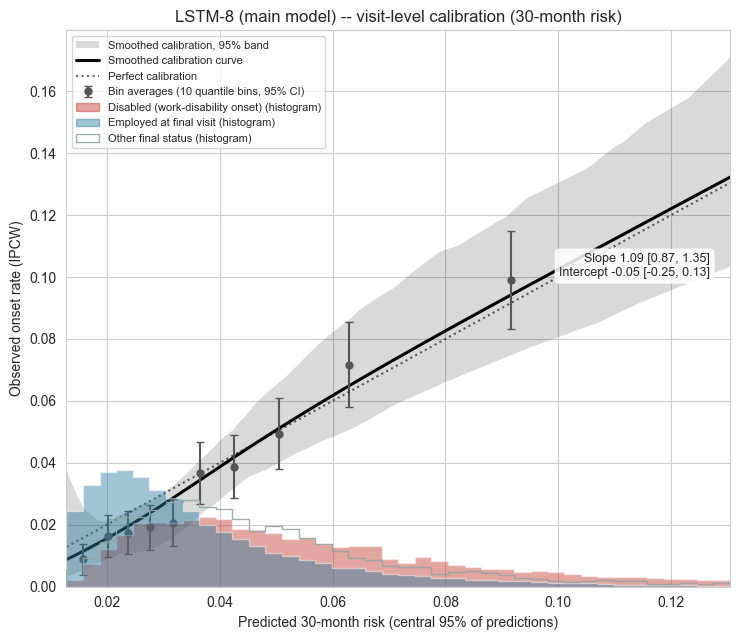

LSTM-8 (main model) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 124.0, FN 24.0, TN 640.2, FP 268.8; flagged event patients: the earliest alarm came a median 28.4 months before onset (57% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-----------------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.924 [0.886, 0.956]","0.852 [0.764, 0.925]","0.756 [0.720, 0.790]"
40-49,33,200,"0.939 [0.905, 0.967]","0.885 [0.773, 0.971]","0.662 [0.606, 0.723]"
50-59,45,190,"0.890 [0.844, 0.933]","0.787 [0.664, 0.903]","0.644 [0.587, 0.704]"
>= 60,8,115,"0.856 [0.699, 0.984]","0.825 [0.550, 1.000]","0.692 [0.617, 0.766]"


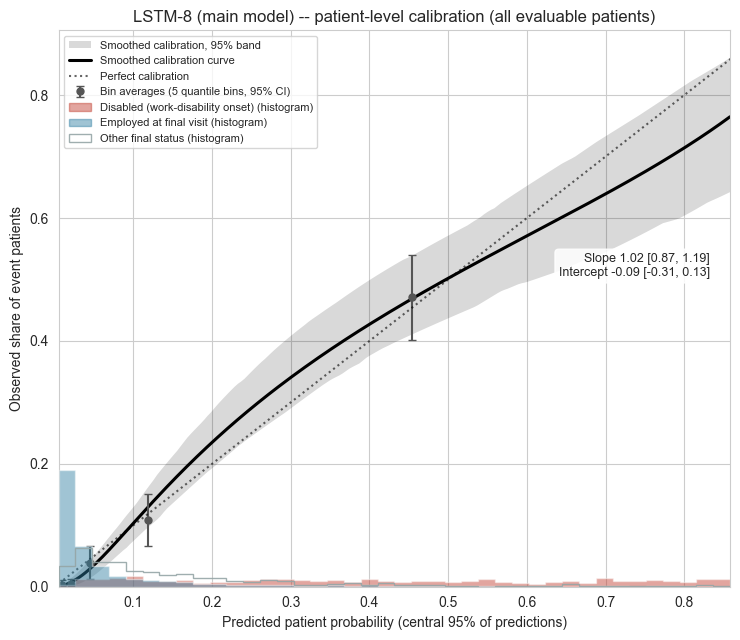


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.591 (0.007),0.770 (0.004),0.721 (0.002),0.111 (0.003),37.659 (3.800),0.816 (0.082),0.287 (0.032),0.744 (0.076)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM,5,0.172 (0.012),0.288 (0.013),0.383 (0.022),0.470 (0.022),0.601 (0.014),0.952 (0.004),0.901 (0.005),0.848 (0.004),0.795 (0.004),0.691 (0.005)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM,5,0.035 (0.013),0.149 (0.024),0.361 (0.073),0.554 (0.041),0.812 (0.019),0.994 (0.002),0.956 (0.010),0.845 (0.039),0.719 (0.030),0.425 (0.023),0.706 (0.226),4.753 (1.053),16.054 (3.908),28.813 (2.875),58.152 (2.391)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM,5,0.722 (0.005),0.724 (0.003),0.715 (0.002),0.712 (0.002),0.714 (0.002),0.715 (0.001),0.711 (0.001),0.707 (0.001)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w8': 25}
Early stopping, outer-fold fits: median 16 epochs (range 13-35)


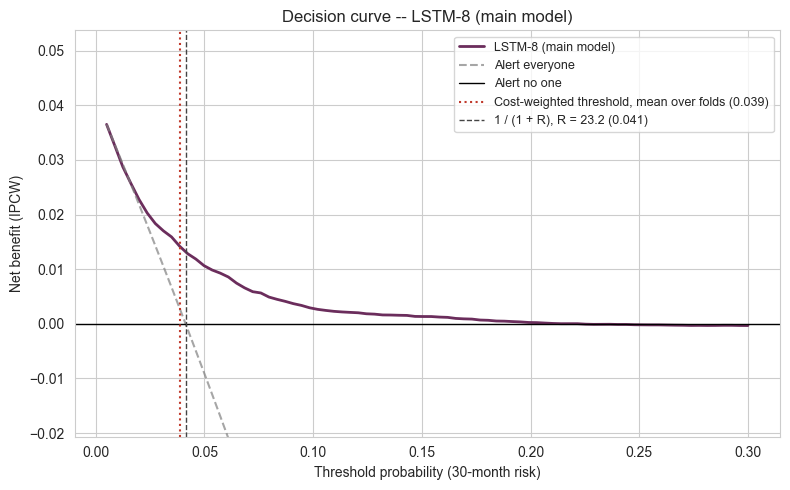

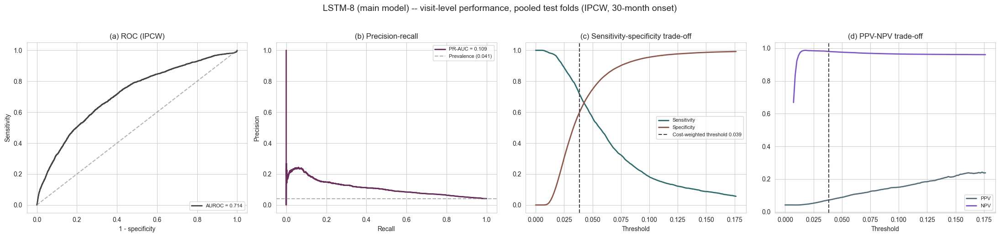

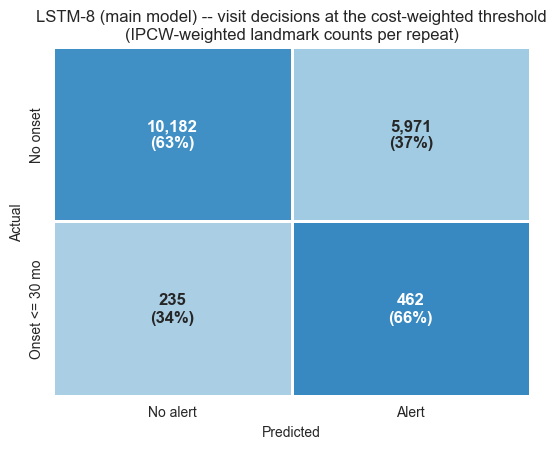

LSTM: final refit on all rows (config w8, 17 features) in 51s


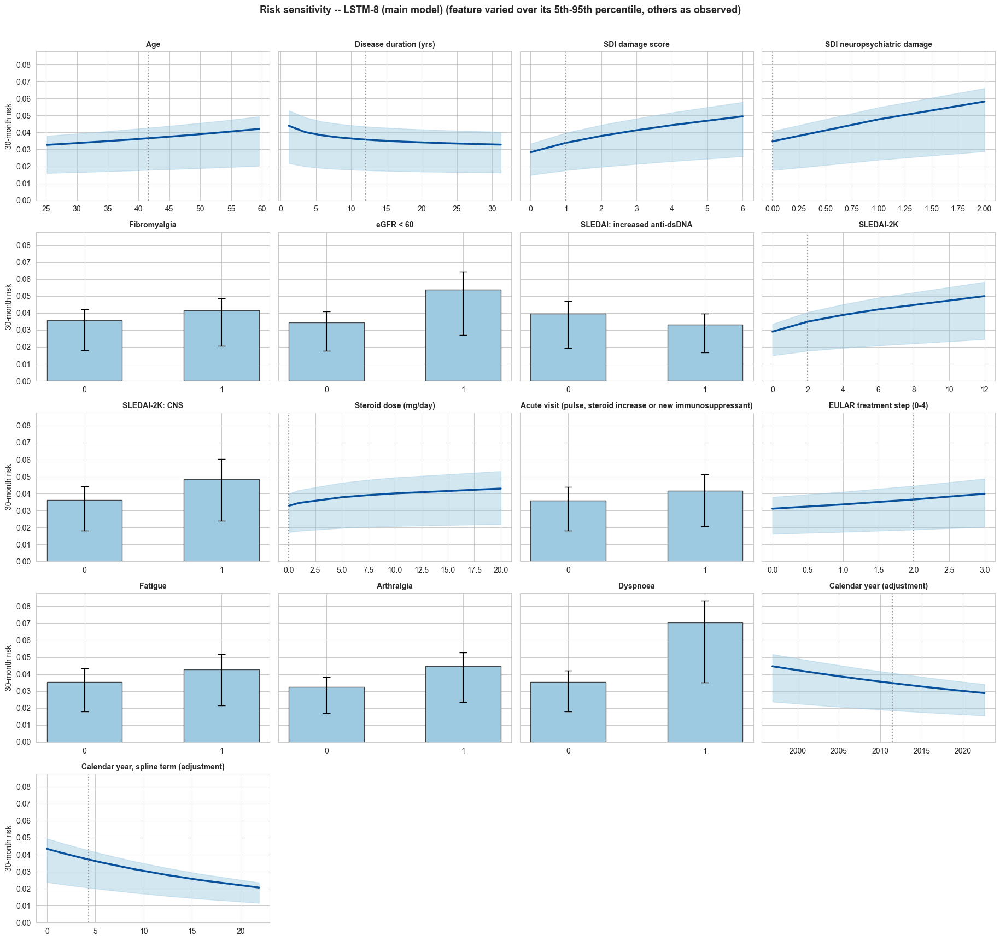


Risk-sensitivity summary -- LSTM-8 (main model) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0354       0.0706                0.0352
                                   SDI neuropsychiatric damage      0.0348       0.0582                0.0234
                       Calendar year, spline term (adjustment)      0.0434       0.0206                0.0228
                                              SDI damage score      0.0283       0.0495                0.0211
                                                     SLEDAI-2K      0.0290       0.0499                0.0209
                                                     eGFR < 60      0.0345       0.0538                0.0192
                                    Calendar year (adjustment)      0.0446       0.0288                0.0158
                                 

In [40]:
"""The main model (Section 6.1 / 11.7): LSTM-8 -- an LSTM over each landmark's last 8 visits, 16 units, a skip connection
from the current visit's variables to the hazard heads (warm-started from a logistic regression), four auxiliary
12-month heads (training only), next-visit pretraining, cause-specific hazard heads (+ calendar-year terms), early
stopping, 5-seed ensemble in the outer-fold fit."""
res_lstm = run_analysis("LSTM", "LSTM-8 (main model)")

## 11.10.2 LSTM-1 (the main network on the current visit alone)

The same network as LSTM-8 -- skip connection, auxiliary heads, seeds, folds -- reading only the landmark visit. It is
the reference of H2 (Section 8.1).

Resuming from cv_state_model_revised_v21.pkl: 49 model-fold fits already done.
[LSTM1      ] repeat 5/5 fold 5/5 | AUROC 0.720 NB(R=22.5) 0.0086 | visit sens/spec 0.62/0.67 | patient sens/spec 0.83/0.77 (TN/FP 141/41) | cfg w1 | 17 feats | 37s
CV for ['LSTM1']: 0.6 min this call; 50 model-fold fits in cv_state_model_revised_v21.pkl.
LSTM-1 (current visit only) -- VISIT LEVEL (30-month work-disability onset)
  16,851 landmark visits of 1,059 patients; resolved at 30 months: 14,384 (642 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal cost-weighted net benefit; a missed onset costs R false alarms, R = (1 - onset rate) / onset rate of the training fold, mean 23.2); mean threshold 0.038
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
  alert burden: Alerts / 100 landmark visits 39.1 (3.4); Alerts / patient-year 0.85 (0.07); Stayed employed: pa

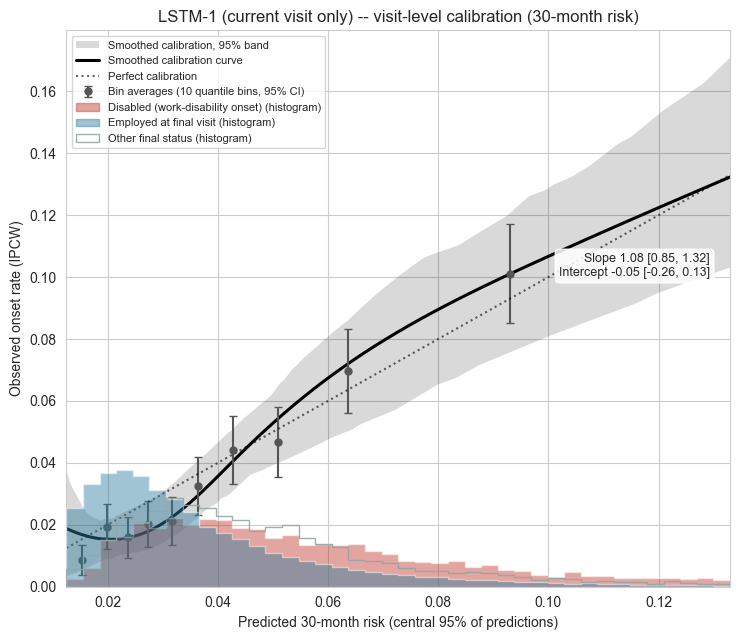

LSTM-1 (current visit only) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 125.0, FN 23.0, TN 632.6, FP 276.4; flagged event patients: the earliest alarm came a median 29.9 months before onset (55% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
---------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.924 [0.886, 0.956]","0.842 [0.756, 0.919]","0.755 [0.718, 0.787]"
40-49,33,200,"0.944 [0.912, 0.970]","0.903 [0.807, 0.979]","0.647 [0.591, 0.707]"
50-59,45,190,"0.891 [0.846, 0.933]","0.809 [0.700, 0.915]","0.624 [0.567, 0.684]"
>= 60,8,115,"0.863 [0.714, 0.988]","0.825 [0.525, 1.000]","0.690 [0.618, 0.765]"


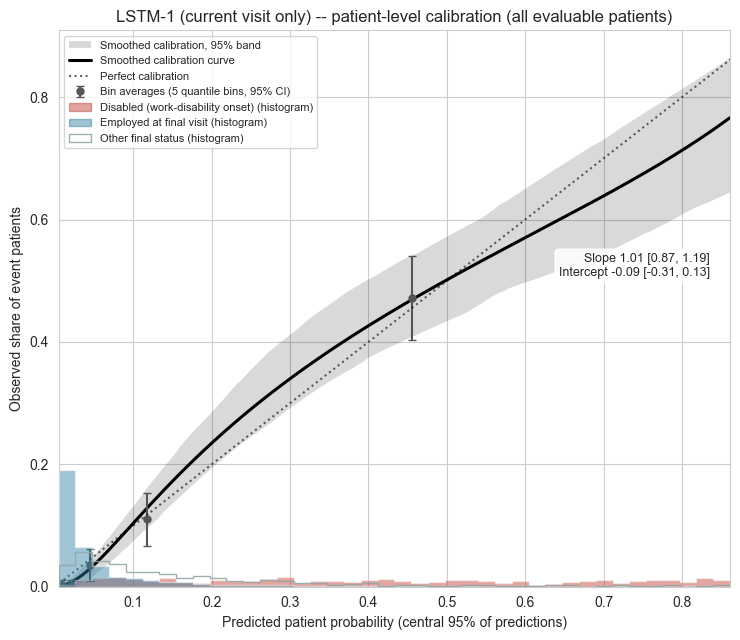


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM1,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.589 (0.007),0.764 (0.005),0.720 (0.002),0.109 (0.003),39.102 (3.404),0.847 (0.074),0.293 (0.030),0.770 (0.070)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM1,5,0.175 (0.011),0.289 (0.024),0.386 (0.023),0.470 (0.028),0.604 (0.023),0.952 (0.004),0.900 (0.005),0.850 (0.007),0.798 (0.007),0.695 (0.008)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM1,5,0.042 (0.017),0.164 (0.034),0.371 (0.058),0.580 (0.043),0.805 (0.018),0.993 (0.004),0.951 (0.017),0.850 (0.026),0.696 (0.050),0.450 (0.057),0.846 (0.405),5.222 (1.723),15.579 (2.602),30.994 (5.012),55.473 (5.646)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM1,5,0.717 (0.005),0.721 (0.002),0.713 (0.001),0.710 (0.002),0.713 (0.002),0.715 (0.002),0.711 (0.002),0.707 (0.002)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w1': 25}
Early stopping, outer-fold fits: median 20 epochs (range 15-39)


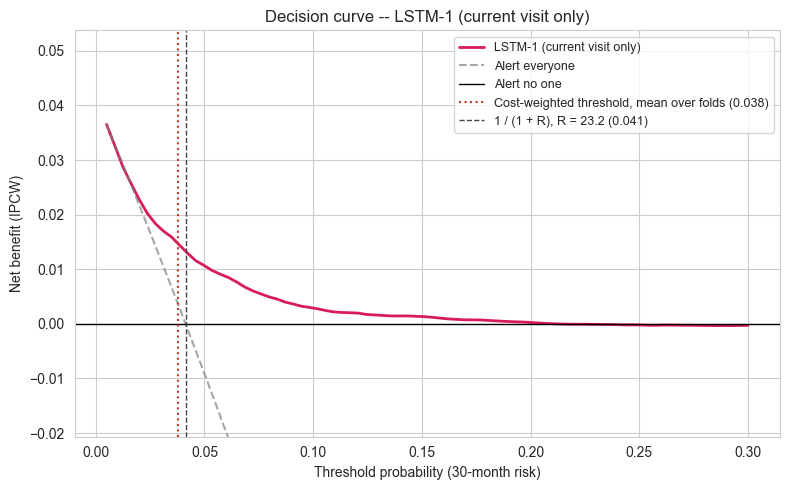

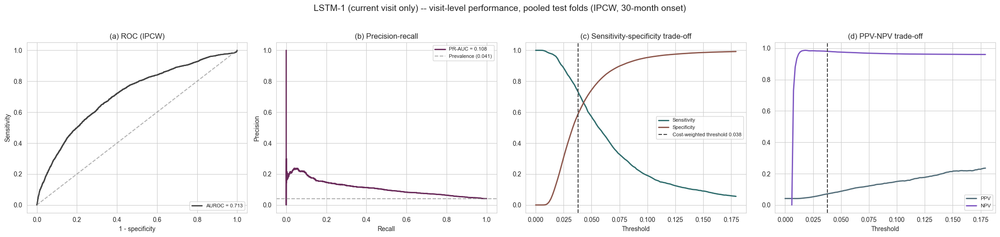

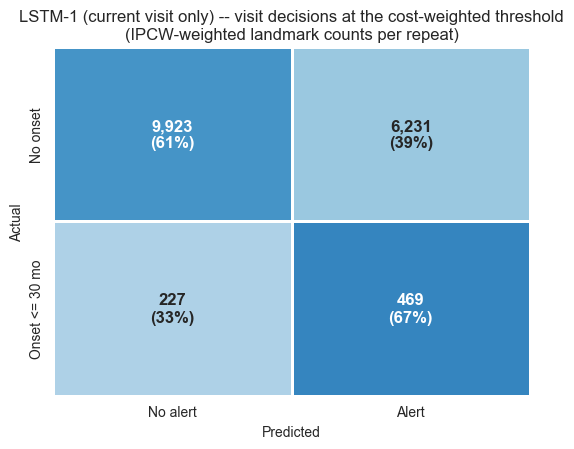

LSTM1: final refit on all rows (config w1, 17 features) in 27s


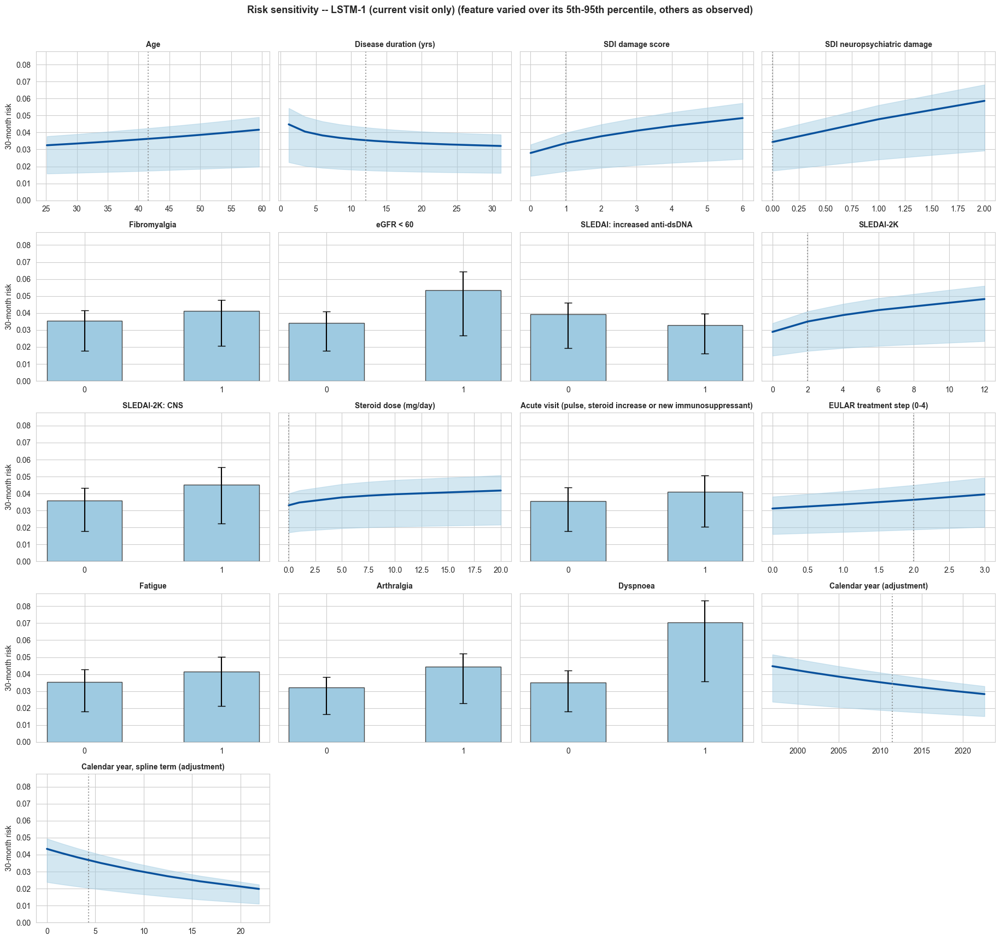


Risk-sensitivity summary -- LSTM-1 (current visit only) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0350       0.0706                0.0356
                                   SDI neuropsychiatric damage      0.0344       0.0586                0.0242
                       Calendar year, spline term (adjustment)      0.0434       0.0198                0.0236
                                              SDI damage score      0.0279       0.0485                0.0205
                                                     SLEDAI-2K      0.0289       0.0482                0.0193
                                                     eGFR < 60      0.0342       0.0534                0.0191
                                    Calendar year (adjustment)      0.0447       0.0282                0.0164
                         

In [41]:
"""LSTM-1: the main LSTM's recipe (Section 6.1) with a window of 1 visit (the current visit alone); the reference of
Objective 1."""
res_lstm1 = run_analysis("LSTM1", "LSTM-1 (current visit only)")


## 11.10.3 LSTM-4 and LSTM-16 (the dose-response of the history)

The main network (skip connection, auxiliary heads, pretraining, 5-seed ensemble) on each landmark's last 4 and last 16
visits, identical folds and repeats.

Resuming from cv_state_model_revised_v21.pkl: 50 model-fold fits already done.
[LSTM_w4    ] repeat 1/5 fold 1/5 | AUROC 0.713 NB(R=23.9) 0.0160 | visit sens/spec 0.78/0.52 | patient sens/spec 0.90/0.59 (TN/FP 107/75) | cfg w4 | 17 feats | 50s
[LSTM_w4    ] repeat 1/5 fold 2/5 | AUROC 0.742 NB(R=22.9) 0.0111 | visit sens/spec 0.67/0.64 | patient sens/spec 0.87/0.71 (TN/FP 128/53) | cfg w4 | 17 feats | 49s
[LSTM_w4    ] repeat 1/5 fold 3/5 | AUROC 0.703 NB(R=23.6) 0.0156 | visit sens/spec 0.68/0.65 | patient sens/spec 0.90/0.77 (TN/FP 140/42) | cfg w4 | 17 feats | 55s
[LSTM_w4    ] repeat 1/5 fold 4/5 | AUROC 0.733 NB(R=23.3) 0.0148 | visit sens/spec 0.77/0.56 | patient sens/spec 0.87/0.68 (TN/FP 124/58) | cfg w4 | 17 feats | 48s
[LSTM_w4    ] repeat 1/5 fold 5/5 | AUROC 0.697 NB(R=22.4) 0.0049 | visit sens/spec 0.68/0.55 | patient sens/spec 0.83/0.54 (TN/FP 98/84) | cfg w4 | 17 feats | 51s
[LSTM_w4    ] repeat 2/5 fold 1/5 | AUROC 0.723 NB(R=22.8) 0.0090 | visit sens/spec 0.61/0.66 | p

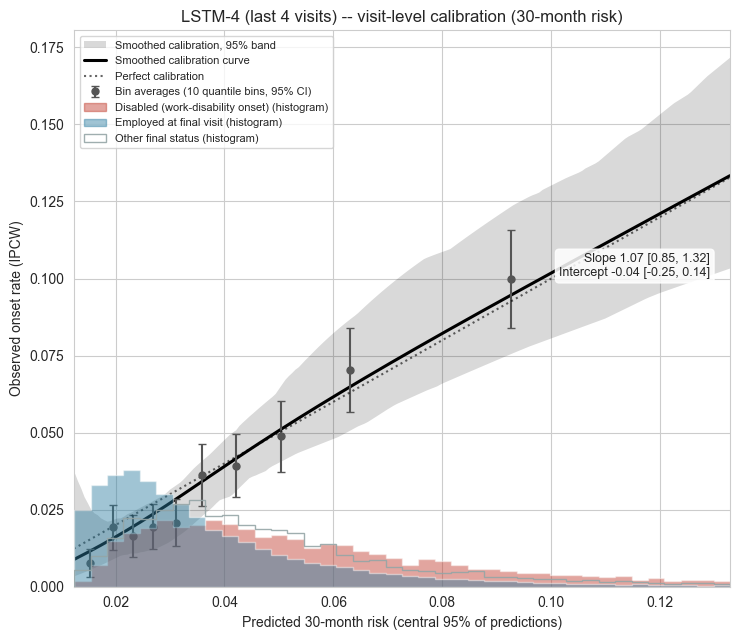

LSTM-4 (last 4 visits) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 125.8, FN 22.2, TN 641.4, FP 267.6; flagged event patients: the earliest alarm came a median 29.2 months before onset (57% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
--------------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.925 [0.886, 0.956]","0.865 [0.780, 0.936]","0.762 [0.726, 0.796]"
40-49,33,200,"0.940 [0.905, 0.967]","0.897 [0.793, 0.979]","0.667 [0.615, 0.728]"
50-59,45,190,"0.890 [0.844, 0.933]","0.800 [0.690, 0.909]","0.635 [0.579, 0.697]"
>= 60,8,115,"0.862 [0.711, 0.986]","0.825 [0.525, 1.000]","0.689 [0.614, 0.764]"


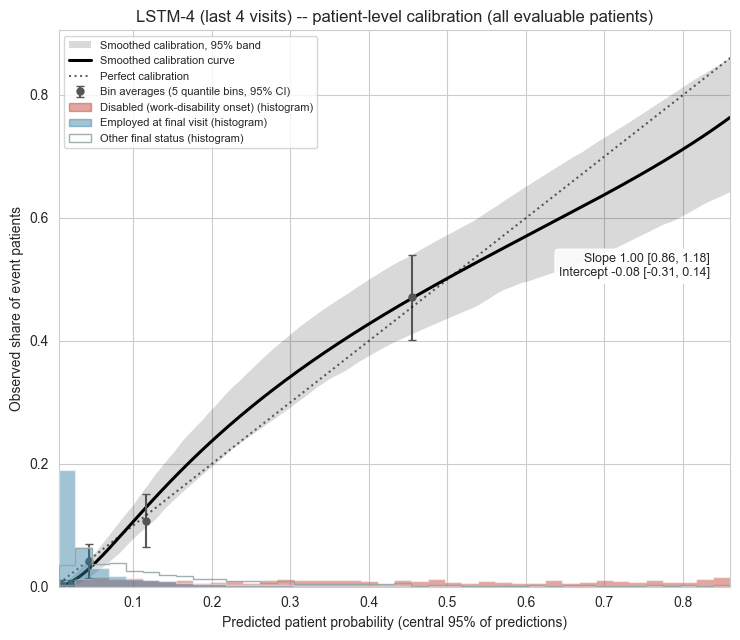


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_w4,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.591 (0.006),0.769 (0.005),0.721 (0.001),0.111 (0.003),37.868 (3.851),0.820 (0.083),0.290 (0.037),0.747 (0.081)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_w4,5,0.172 (0.012),0.292 (0.018),0.386 (0.019),0.470 (0.023),0.596 (0.017),0.952 (0.005),0.901 (0.005),0.850 (0.005),0.799 (0.006),0.698 (0.008)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_w4,5,0.032 (0.017),0.163 (0.031),0.352 (0.035),0.559 (0.054),0.810 (0.025),0.994 (0.002),0.952 (0.018),0.856 (0.022),0.722 (0.025),0.426 (0.040),0.682 (0.226),5.184 (1.832),14.921 (2.137),28.440 (2.294),58.075 (4.308)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_w4,5,0.720 (0.005),0.723 (0.002),0.714 (0.002),0.711 (0.002),0.714 (0.002),0.715 (0.002),0.711 (0.002),0.707 (0.002)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w4': 25}
Early stopping, outer-fold fits: median 16 epochs (range 13-46)


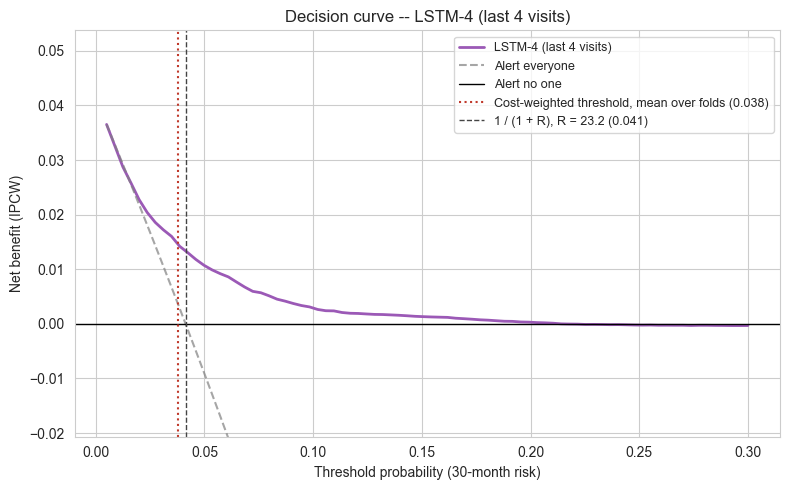

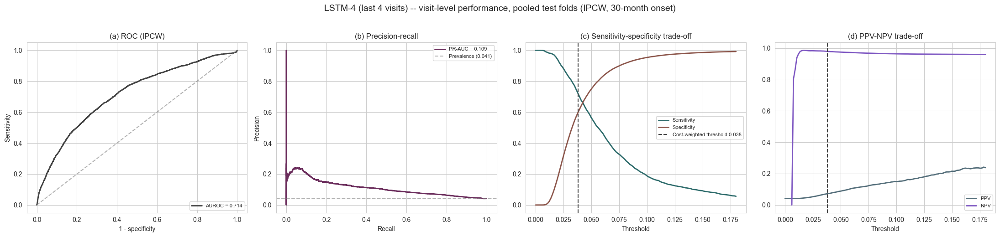

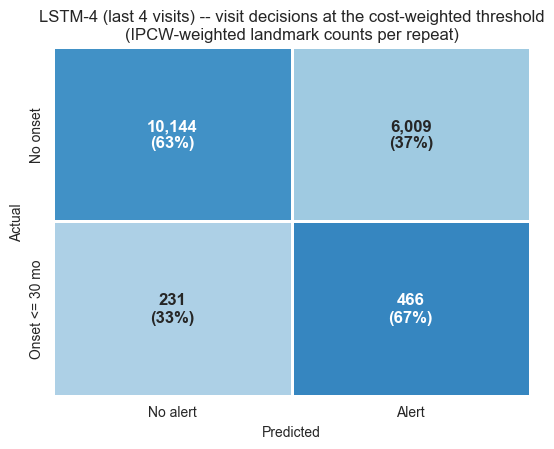

LSTM_w4: final refit on all rows (config w4, 17 features) in 39s


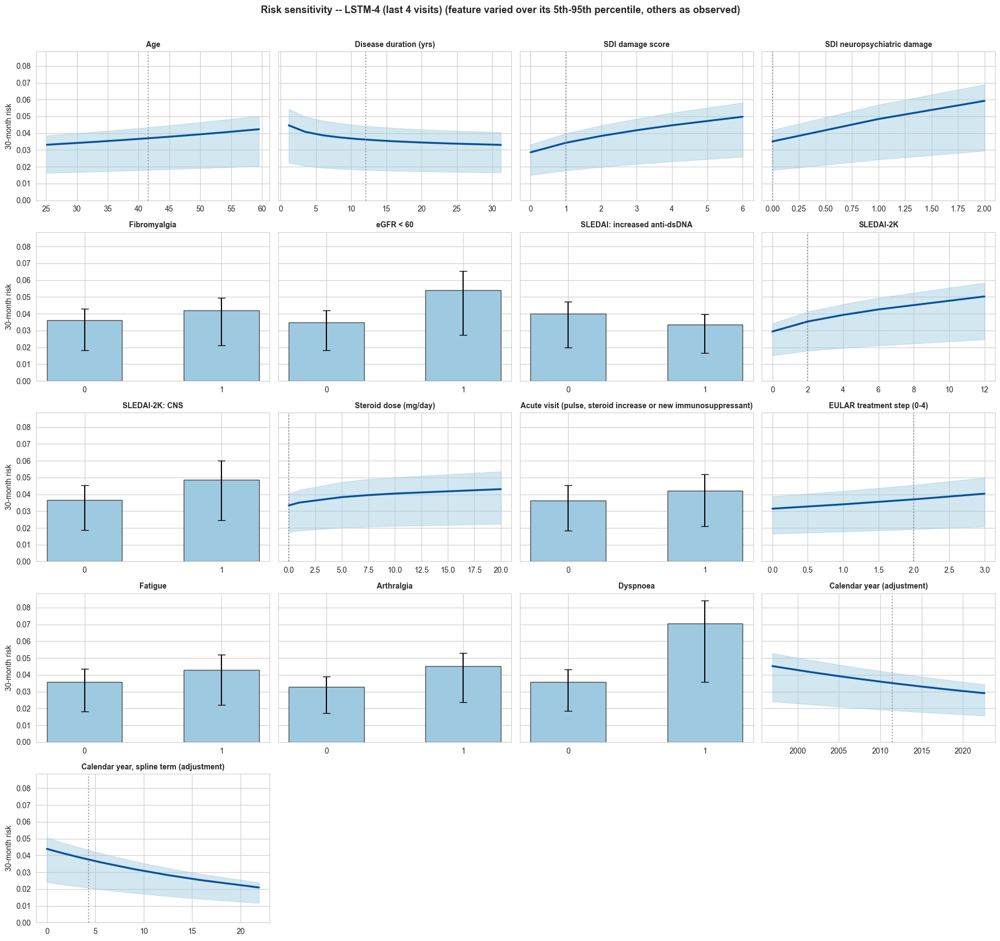


Risk-sensitivity summary -- LSTM-4 (last 4 visits) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0358       0.0704                0.0346
                                   SDI neuropsychiatric damage      0.0351       0.0592                0.0241
                       Calendar year, spline term (adjustment)      0.0439       0.0209                0.0230
                                              SDI damage score      0.0286       0.0498                0.0212
                                                     SLEDAI-2K      0.0294       0.0503                0.0209
                                                     eGFR < 60      0.0349       0.0542                0.0192
                                    Calendar year (adjustment)      0.0452       0.0291                0.0161
                              

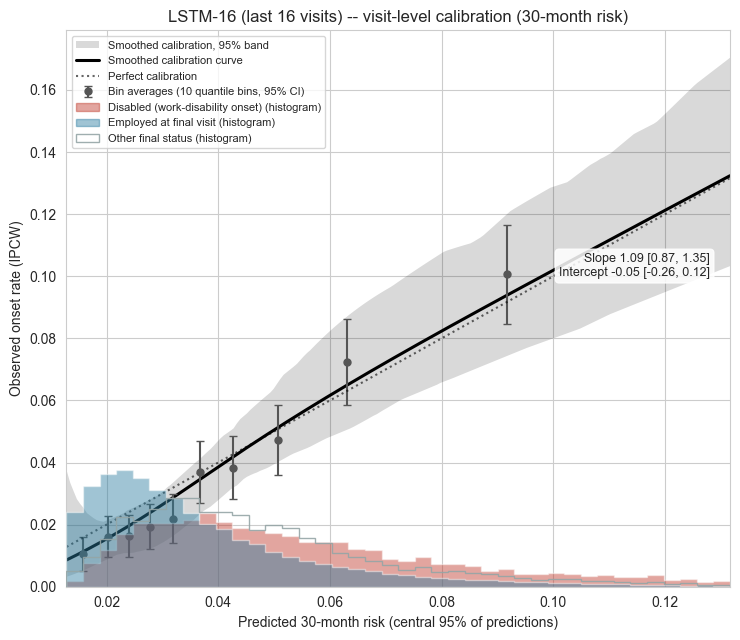

LSTM-16 (last 16 visits) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 125.2, FN 22.8, TN 651.0, FP 258.0; flagged event patients: the earliest alarm came a median 28.6 months before onset (56% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.925 [0.887, 0.956]","0.852 [0.767, 0.929]","0.768 [0.730, 0.800]"
40-49,33,200,"0.939 [0.904, 0.967]","0.891 [0.796, 0.970]","0.678 [0.623, 0.737]"
50-59,45,190,"0.890 [0.846, 0.933]","0.804 [0.687, 0.917]","0.655 [0.597, 0.713]"
>= 60,8,115,"0.858 [0.707, 0.984]","0.850 [0.560, 1.000]","0.701 [0.625, 0.776]"


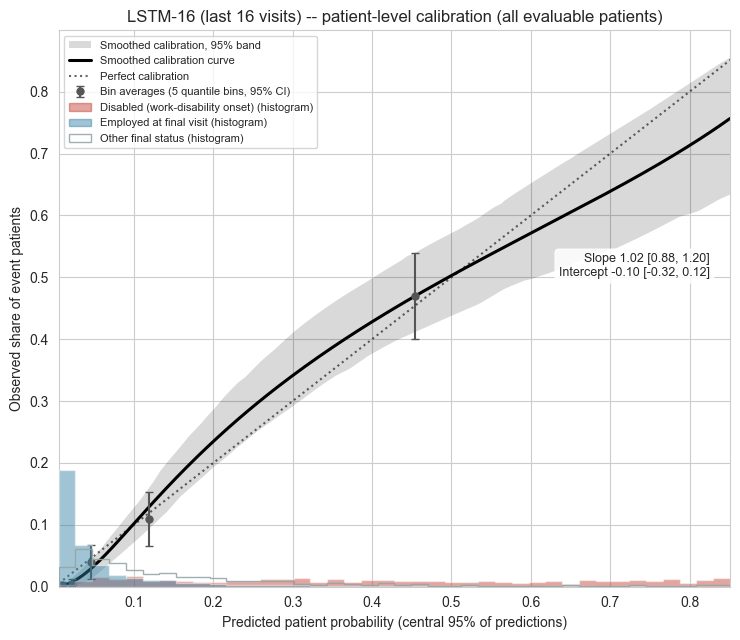


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_w16,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.592 (0.007),0.770 (0.004),0.721 (0.002),0.110 (0.004),36.689 (2.437),0.795 (0.053),0.293 (0.024),0.721 (0.046)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_w16,5,0.172 (0.014),0.290 (0.017),0.386 (0.020),0.470 (0.024),0.604 (0.011),0.952 (0.005),0.901 (0.005),0.848 (0.003),0.794 (0.004),0.689 (0.009)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_w16,5,0.037 (0.021),0.161 (0.014),0.369 (0.072),0.560 (0.060),0.799 (0.019),0.994 (0.004),0.954 (0.010),0.843 (0.032),0.717 (0.051),0.442 (0.025),0.777 (0.461),4.965 (1.091),16.160 (3.209),29.031 (4.884),56.391 (2.536)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_w16,5,0.721 (0.005),0.724 (0.003),0.715 (0.002),0.712 (0.002),0.713 (0.002),0.715 (0.002),0.711 (0.002),0.707 (0.001)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'w16': 25}
Early stopping, outer-fold fits: median 16 epochs (range 13-35)


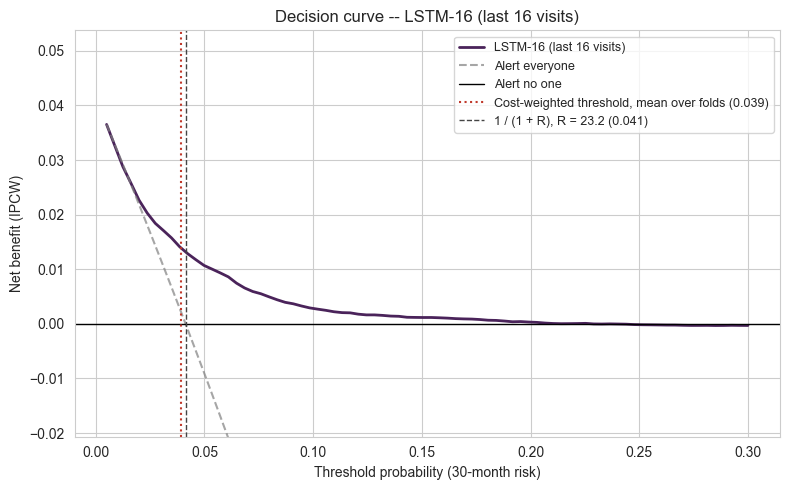

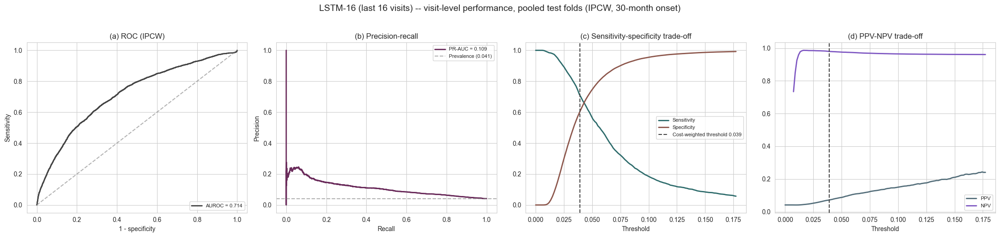

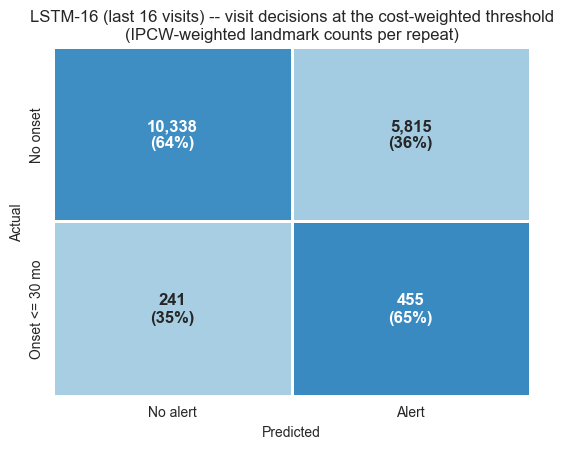

LSTM_w16: final refit on all rows (config w16, 17 features) in 120s


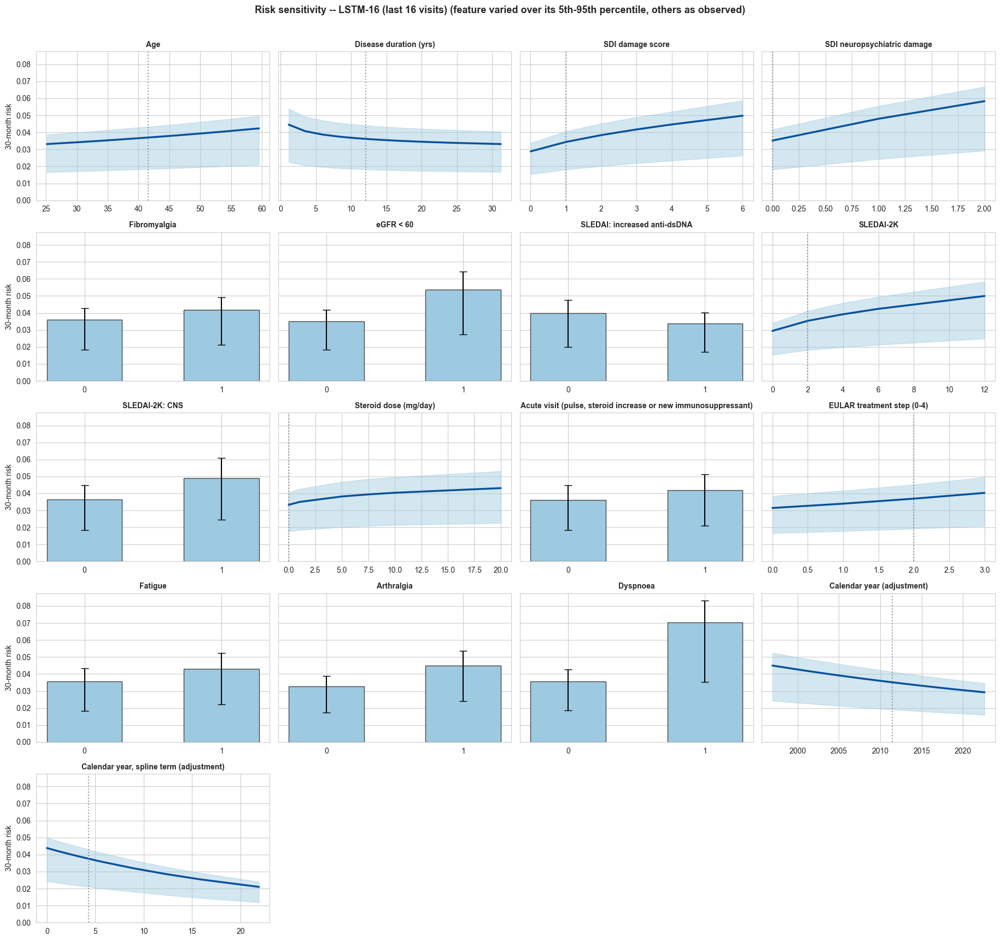


Risk-sensitivity summary -- LSTM-16 (last 16 visits) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0358       0.0702                0.0344
                                   SDI neuropsychiatric damage      0.0352       0.0583                0.0232
                       Calendar year, spline term (adjustment)      0.0438       0.0210                0.0229
                                              SDI damage score      0.0288       0.0498                0.0210
                                                     SLEDAI-2K      0.0294       0.0499                0.0205
                                                     eGFR < 60      0.0350       0.0538                0.0188
                                    Calendar year (adjustment)      0.0450       0.0292                0.0157
                            

In [42]:
"""LSTM-4 and LSTM-16: the main LSTM's recipe (Section 6.1) with windows of 4 and 16 visits (Objective 1)."""
res_lstm4 = run_analysis("LSTM_w4", "LSTM-4 (last 4 visits)")
res_lstm16 = run_analysis("LSTM_w16", "LSTM-16 (last 16 visits)")

## 11.10.4 Competing-risk logistic regression on the last visit (LogReg)

Resuming from cv_state_model_revised_v21.pkl: 100 model-fold fits already done.


Python(12039) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12040) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12041) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12107) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12108) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12109) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12110) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12111) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[LogReg     ] repeat 1/5 fold 1/5 | AUROC 0.717 NB(R=23.9) 0.0165 | visit sens/spec 0.80/0.50 | patient sens/spec 0.90/0.53 (TN/FP 97/85) | cfg 0.1 | 17 feats | 96s


Python(12183) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12246) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12248) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12249) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12250) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(12252) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[LogReg     ] repeat 1/5 fold 2/5 | AUROC 0.738 NB(R=22.9) 0.0104 | visit sens/spec 0.74/0.56 | patient sens/spec 0.97/0.65 (TN/FP 117/64) | cfg 0.001 | 17 feats | 84s


...

[LogReg     ] repeat 5/5 fold 3/5 | AUROC 0.818 NB(R=23.5) 0.0200 | visit sens/spec 0.89/0.55 | patient sens/spec 0.90/0.67 (TN/FP 122/60) | cfg 0.001 | 17 feats | 50s


Python(15013) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15014) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15063) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15064) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15065) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15066) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15067) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[LogReg     ] repeat 5/5 fold 4/5 | AUROC 0.703 NB(R=23.7) 0.0131 | visit sens/spec 0.63/0.63 | patient sens/spec 0.81/0.66 (TN/FP 121/61) | cfg 0.01 | 17 feats | 52s


Python(15100) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15101) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15185) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15186) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15187) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15188) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[LogReg     ] repeat 5/5 fold 5/5 | AUROC 0.728 NB(R=22.5) 0.0088 | visit sens/spec 0.63/0.67 | patient sens/spec 0.86/0.71 (TN/FP 129/53) | cfg 0.001 | 17 feats | 67s
CV for ['LogReg']: 32.1 min this call; 125 model-fold fits in cv_state_model_revised_v21.pkl.
LogReg (discrete-time, competing risks) -- VISIT LEVEL (30-month work-disability onset)
  16,851 landmark visits of 1,059 patients; resolved at 30 months: 14,384 (642 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal cost-weighted net benefit; a missed onset costs R false alarms, R = (1 - onset rate) / onset rate of the training fold, mean 23.2); mean threshold 0.035
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
  alert burden: Alerts / 100 landmark visits 41.9 (1.6); Alerts / patient-year 0.91 (0.03); Stayed employed: patients 704; Stayed employed: follow-up, median yrs 5.9; Staye

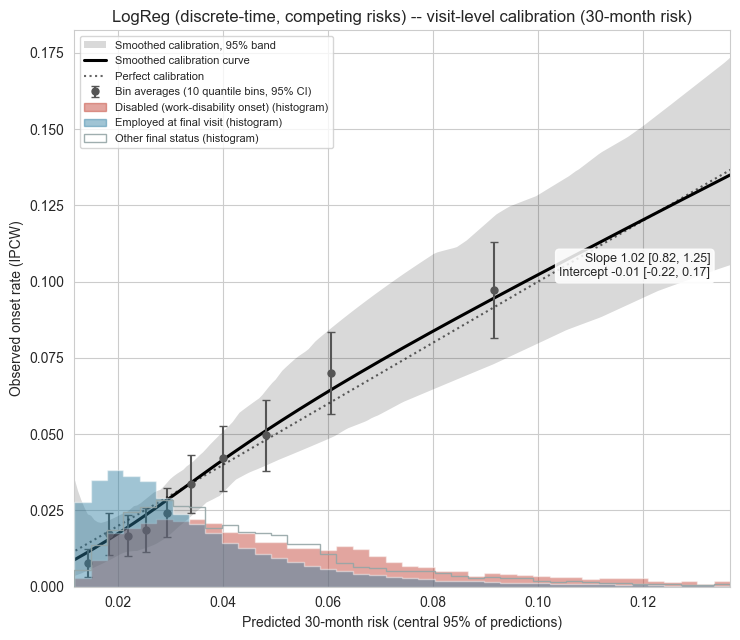

LogReg (discrete-time, competing risks) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 129.4, FN 18.6, TN 582.0, FP 327.0; flagged event patients: the earliest alarm came a median 28.1 months before onset (57% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
---------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.925 [0.887, 0.957]","0.855 [0.762, 0.933]","0.701 [0.658, 0.740]"
40-49,33,200,"0.946 [0.914, 0.971]","0.915 [0.819, 0.986]","0.567 [0.503, 0.630]"
50-59,45,190,"0.888 [0.839, 0.931]","0.862 [0.763, 0.952]","0.583 [0.522, 0.649]"
>= 60,8,115,"0.875 [0.725, 0.988]","0.925 [0.750, 1.000]","0.647 [0.566, 0.726]"


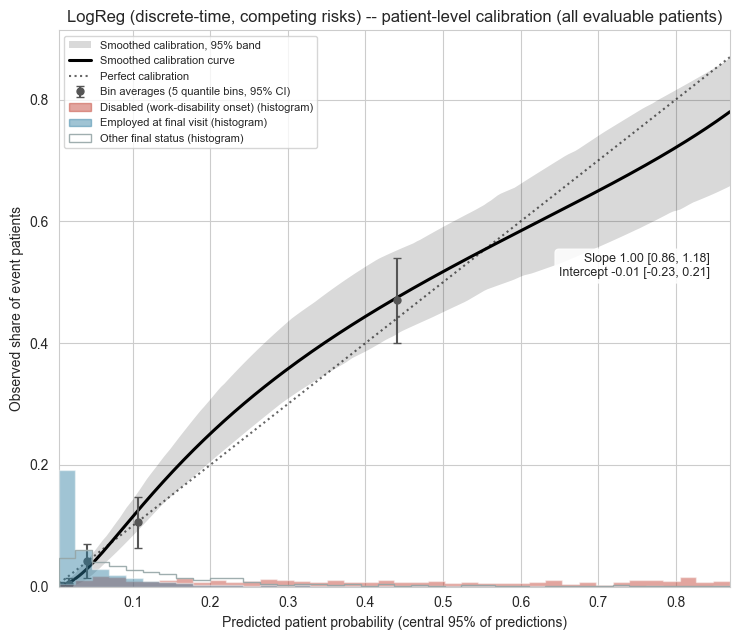


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LogReg,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.594 (0.003),0.768 (0.003),0.720 (0.000),0.111 (0.003),41.861 (1.577),0.907 (0.034),0.254 (0.007),0.857 (0.037)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LogReg,5,0.162 (0.006),0.258 (0.004),0.348 (0.009),0.412 (0.007),0.553 (0.013),0.954 (0.002),0.908 (0.003),0.860 (0.003),0.812 (0.006),0.713 (0.006)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LogReg,5,0.051 (0.021),0.145 (0.020),0.360 (0.028),0.583 (0.025),0.776 (0.019),0.991 (0.002),0.964 (0.008),0.840 (0.011),0.682 (0.017),0.475 (0.023),1.090 (0.307),4.063 (0.753),16.814 (1.105),32.949 (1.652),53.729 (2.425)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LogReg,5,0.717 (0.003),0.722 (0.002),0.714 (0.001),0.711 (0.001),0.713 (0.000),0.713 (0.001),0.708 (0.001),0.702 (0.001)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {0.001: 13, 0.01: 5, 0.003: 4, 0.3: 2, 0.1: 1}


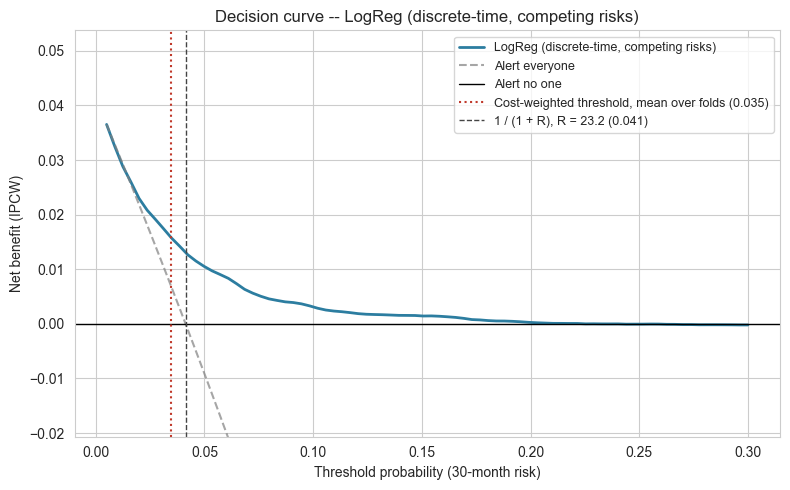

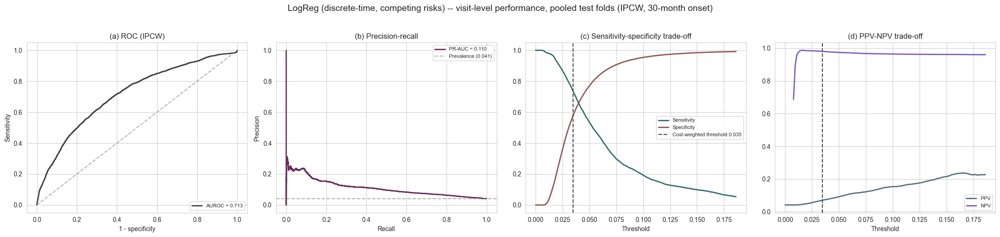

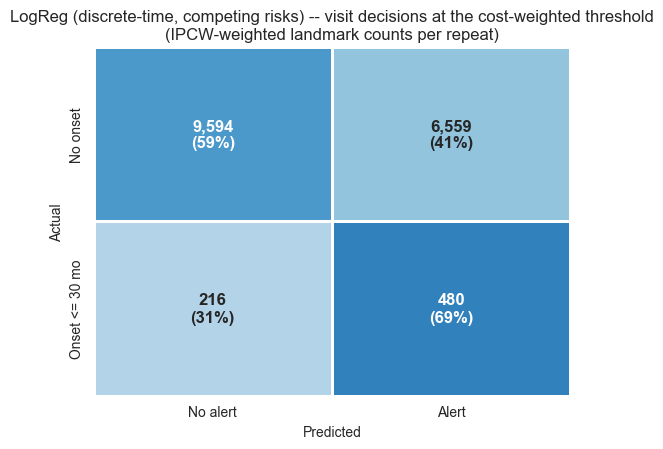

Python(15573) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15574) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15575) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15576) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


LogReg: final refit on all rows (config 0.001, 17 features) in 8s


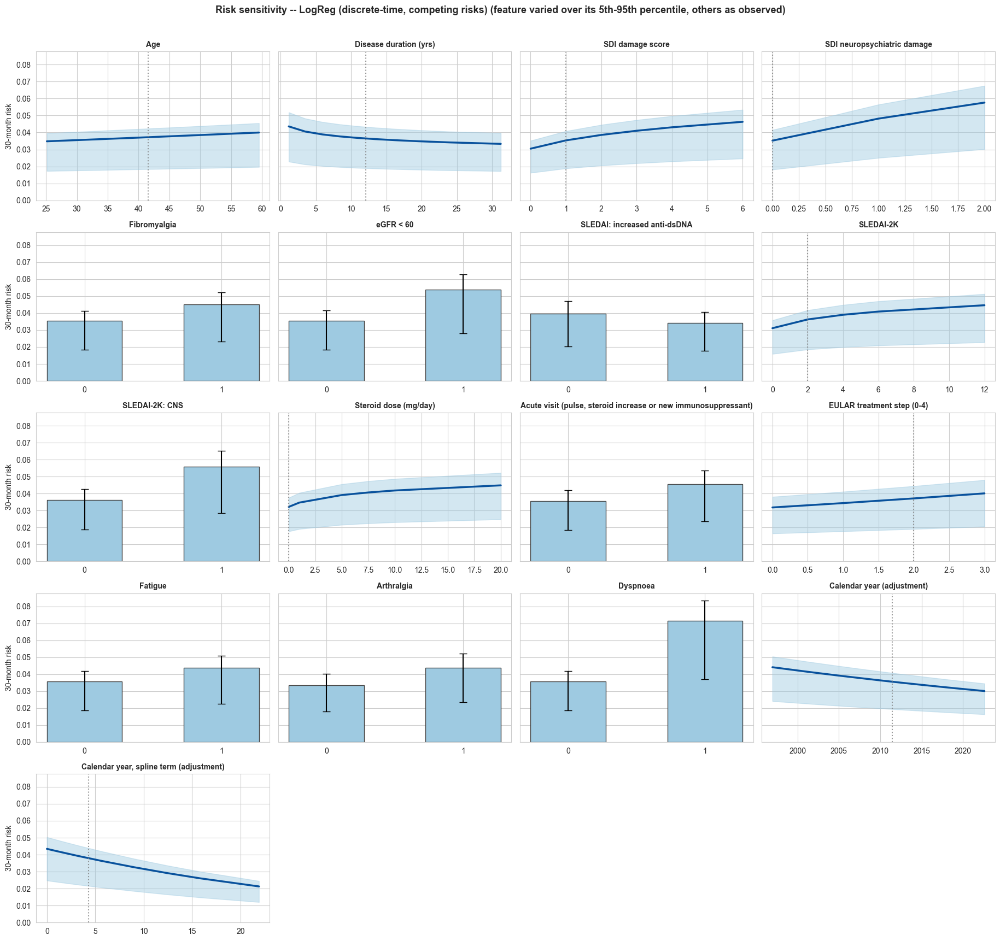


Risk-sensitivity summary -- LogReg (discrete-time, competing risks) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0357       0.0713                0.0356
                                   SDI neuropsychiatric damage      0.0352       0.0576                0.0224
                       Calendar year, spline term (adjustment)      0.0435       0.0213                0.0221
                                                SLEDAI-2K: CNS      0.0362       0.0558                0.0196
                                                     eGFR < 60      0.0353       0.0537                0.0183
                                              SDI damage score      0.0305       0.0463                0.0158
                                    Calendar year (adjustment)      0.0441       0.0301                0.0140
             

In [43]:
"""discrete-time competing-risk (pooled multinomial) logistic regression: cumulative incidence of work
disability with other exits and death competing. The fold's LASSO-selected variables (linear), the calendar-year terms; L2 penalty C tuned
inside each training fold on the cross-fitted cost-weighted net benefit."""
res_logreg = run_analysis("LogReg", "LogReg (discrete-time, competing risks)")

## 11.10.5 Nomogram

The readable form of the regression (Chen et al.'s nomogram model; Section 6.2): the variables selected on all data,
refitted without a penalty as an IPCW logistic regression of onset within 30 months, pooled over the imputations, with
the intercept temporally recalibrated to the last 8 calendar years.

Nomogram model: 17 terms (Age, Disease duration (yrs), SDI damage score, SDI neuropsychiatric damage, Fibromyalgia, eGFR < 60, SLEDAI: increased anti-dsDNA, SLEDAI-2K, SLEDAI-2K: CNS, Steroid dose (mg/day), Acute visit (pulse, steroid increase or new immunosuppressant), EULAR treatment step (0-4), Fatigue, Arthralgia, Dyspnoea, Calendar year (adjustment), Calendar year, spline term (adjustment)); 14,384 resolved landmarks, 5 imputations pooled. Temporal recalibration on the landmarks from 2016: intercept shift -0.199 (mean predicted risk there 0.058 -> observed 0.048).


,log-odds per SD,"SE (Rubin, cluster-robust)",OR per SD,OR 95% CI low,OR 95% CI high,p
(Intercept),-2.6527,0.1286,0.0705,0.0548,0.0907,0.0000
Age,0.0920,0.1200,1.0963,0.8665,1.3871,0.4435
Disease duration (yrs),-0.1995,0.1092,0.8191,0.6613,1.0145,0.0676
SDI damage score,0.2591,0.1260,1.2957,1.0122,1.6587,0.0398
SDI neuropsychiatric damage,0.1579,0.0939,1.1710,0.9741,1.4077,0.0928
Fibromyalgia,0.1520,0.0846,1.1641,0.9863,1.3739,0.0723
eGFR < 60,0.1740,0.0789,1.1900,1.0196,1.3890,0.0274
SLEDAI: increased anti-dsDNA,-0.2177,0.1063,0.8043,0.6531,0.9906,0.0405
SLEDAI-2K,0.2729,0.1264,1.3138,1.0254,1.6833,0.0309
SLEDAI-2K: CNS,0.1126,0.0759,1.1192,0.9644,1.2988,0.1382


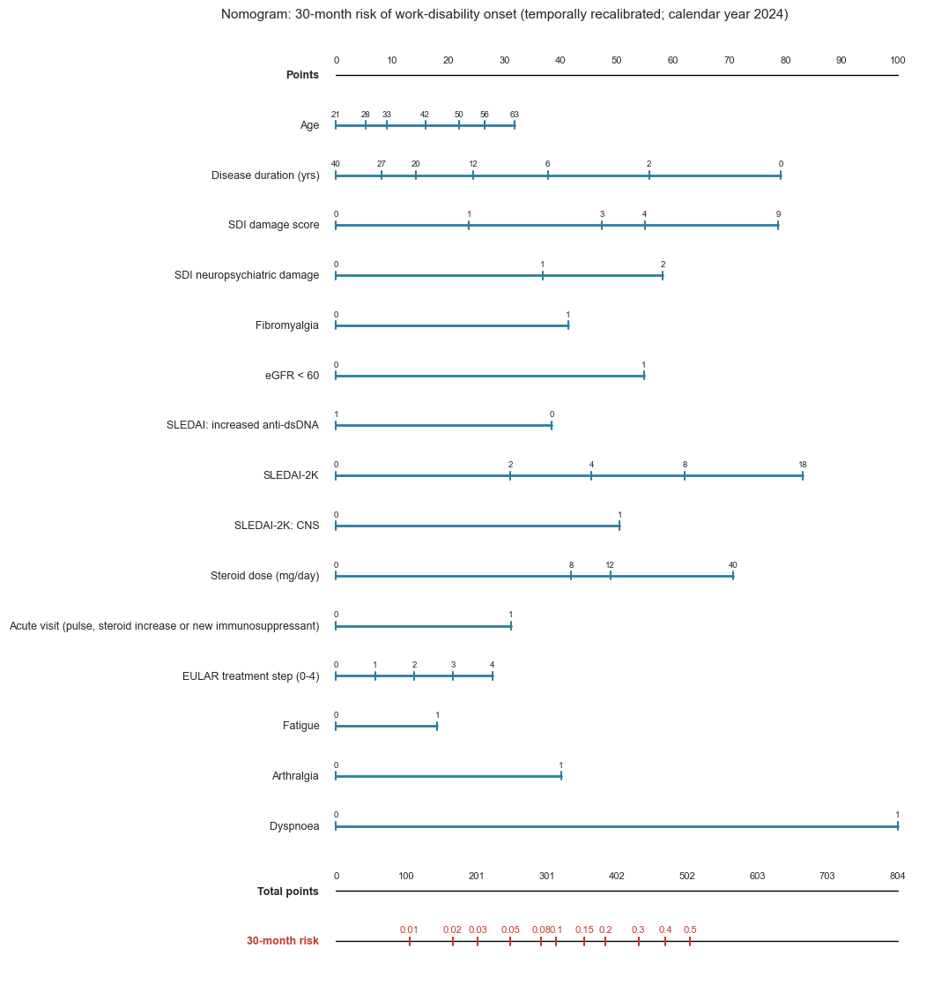

In [44]:
"""
The nomogram model (Section 6.2; Chen et al.'s logistic-regression nomogram): the 30-month risk of work-disability
onset as an IPCW logistic regression of 'onset within 30 months' (the competing-risk label of the LASSO) on the
variables the LASSO selected on all landmarks (SELECTION_ALL), refitted WITHOUT a penalty on each of the
M_IMPUTATIONS completed datasets and pooled with Rubin's rules (patient-clustered robust SEs). For the published model
the intercept is TEMPORALLY RECALIBRATED (Booth et al., Int J Epidemiol 2020): re-estimated on the landmarks of the last
TEMPORAL_RECAL_YEARS calendar years, with the calendar year held at the latest year in the data. Its cross-validated
performance is that of the LASSO-selected LogReg (Section 11.10.4), which is the same variables in a competing-risk
discrete-time form; the nomogram is the readable, by-hand version.
"""
import statsmodels.api as sm

NOMO_COLS = list(SELECTION_ALL["features"])
_rows = np.arange(len(land))
_prep_nomo = TabularPrep(NOMO_COLS)
_Xs_nomo = _prep_nomo.fit_transform(X_for(_rows, NOMO_COLS), PID_ALL[_rows])
_y_n, _w_n = IPCW[PRIMARY_HORIZON_MONTHS]
_w_n = _w_n * land["weight"].values
_k_n = _w_n > 0
_grp_n = pd.factorize(PID_ALL[_k_n])[0]
_fits = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X in _Xs_nomo:
        _fits.append(sm.GLM(_y_n[_k_n], sm.add_constant(X[_k_n]), family=sm.families.Binomial(),
                            var_weights=_w_n[_k_n] / _w_n[_k_n].mean()).fit(cov_type="cluster",
                                                                             cov_kwds={"groups": _grp_n}))
_Q = np.array([f.params for f in _fits])
_U = np.array([np.diag(f.cov_params()) for f in _fits])
_m = len(_fits)
NOMO_BETA = _Q.mean(0)
_T = _U.mean(0) + (1 + 1 / _m) * _Q.var(0, ddof=1)
_se = np.sqrt(_T)
_names = ["(Intercept)"] + [DISPLAY_NAMES.get(c, c) for c in NOMO_COLS]
nomo_table = pd.DataFrame({"log-odds per SD": NOMO_BETA, "SE (Rubin, cluster-robust)": _se,
                           "OR per SD": np.exp(NOMO_BETA), "OR 95% CI low": np.exp(NOMO_BETA - 1.96 * _se),
                           "OR 95% CI high": np.exp(NOMO_BETA + 1.96 * _se),
                           "p": 2 * stats.norm.sf(np.abs(NOMO_BETA / _se))}, index=_names)
# temporal recalibration of the intercept, with the calendar year at the latest year
_lp_all = np.mean([sm.add_constant(X) @ NOMO_BETA for X in _Xs_nomo], axis=0)
_recent = (CAL_YEAR_ALL >= CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS) & _k_n
NOMO_SHIFT = brentq(lambda a: np.average(_expit(a + _lp_all[_recent]), weights=_w_n[_recent])
                    - np.average(_y_n[_recent], weights=_w_n[_recent]), -10, 10)
_year_terms = {c: _prep_nomo.transform_value(NOMO_COLS.index(c), float(land[c].max())) for c in ADJUST_COLS
               if c in NOMO_COLS}
NOMO_CONST = NOMO_BETA[0] + NOMO_SHIFT + sum(NOMO_BETA[1 + NOMO_COLS.index(c)] * z for c, z in _year_terms.items())
print(f"Nomogram model: {len(NOMO_COLS)} terms ({', '.join(_names[1:])}); {int(_k_n.sum()):,} resolved landmarks, "
      f"{_m} imputations pooled. Temporal recalibration on the landmarks from {CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS:.0f}: "
      f"intercept shift {NOMO_SHIFT:+.3f} (mean predicted risk there {np.average(_expit(_lp_all[_recent]), weights=_w_n[_recent]):.3f} "
      f"-> observed {np.average(_y_n[_recent], weights=_w_n[_recent]):.3f}).")
display(nomo_table.round(4))
nomo_table.to_csv("nomogram_model_coefficients_revised_v21.csv")


def draw_nomogram(save=None):
    """Points per variable (0 at the value with the lowest risk contribution; 100 = the widest range among the
    variables, 1st-99th percentile of the landmarks), total points, and the temporally recalibrated 30-month risk."""
    rows_ = []
    for j, c in enumerate(NOMO_COLS):
        if c in ADJUST_COLS:
            continue
        x = land[c].dropna().values.astype(float)
        binary = set(np.unique(x)) <= {0.0, 1.0}
        nd = 0 if np.ptp(np.percentile(x, [1, 99])) >= 10 else (1 if np.ptp(np.percentile(x, [1, 99])) >= 1 else 2)
        vals = np.array([0.0, 1.0]) if binary else np.unique(np.round(np.percentile(x, [1, 10, 25, 50, 75, 90, 99]), nd))
        contrib = np.array([NOMO_BETA[1 + j] * _prep_nomo.transform_value(j, v) for v in vals])
        rows_.append((c, vals, contrib))
    span = max(np.ptp(cb) for _, _, cb in rows_) or 1.0
    scale = 100.0 / span
    fig, ax = plt.subplots(figsize=(11, 0.55 * (len(rows_) + 4) + 1))
    y = len(rows_) + 2
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for p_ in range(0, 101, 10):
        ax.text(p_, y + 0.25, f"{p_}", ha="center", fontsize=8)
    ax.text(-3, y, "Points", ha="right", va="center", fontsize=9, fontweight="bold")
    base = 0.0
    for c, vals, cb in rows_:
        y -= 1
        pts = (cb - cb.min()) * scale
        base += cb.min()
        ax.plot([pts.min(), pts.max()], [y, y], color="#2c7da0", lw=2)
        for v, p_ in zip(vals, pts):
            ax.plot([p_, p_], [y - 0.08, y + 0.08], color="#2c7da0")
            ax.text(p_, y + 0.18, f"{v:g}", ha="center", fontsize=7)
        ax.text(-3, y, DISPLAY_NAMES.get(c, c), ha="right", va="center", fontsize=9)
    max_total = sum(np.ptp(cb) for _, _, cb in rows_) * scale
    y -= 1.3
    tot_ticks = np.linspace(0, max_total, 9)
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for t in tot_ticks:
        ax.text(t / max_total * 100, y + 0.25, f"{t:.0f}", ha="center", fontsize=8)
    ax.text(-3, y, "Total points", ha="right", va="center", fontsize=9, fontweight="bold")
    y -= 1.0
    ax.plot([0, 100], [y, y], color="black", lw=1)
    lp_of_points = lambda tp: NOMO_CONST + base + tp / scale
    for r_ in [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
        tp = (_logit(r_) - NOMO_CONST - base) * scale
        if 0 <= tp <= max_total:
            ax.plot([tp / max_total * 100] * 2, [y - 0.08, y + 0.08], color="#c0392b")
            ax.text(tp / max_total * 100, y + 0.18, f"{r_:g}", ha="center", fontsize=8, color="#c0392b")
    ax.text(-3, y, "30-month risk", ha="right", va="center", fontsize=9, fontweight="bold", color="#c0392b")
    ax.set_xlim(-45, 105); ax.set_ylim(y - 1, len(rows_) + 3); ax.axis("off")
    ax.set_title(f"Nomogram: 30-month risk of work-disability onset (temporally recalibrated; calendar year "
                 f"{CAL_YEAR_ALL.max():.0f})", fontsize=11)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    return lp_of_points


nomogram_lp = draw_nomogram(save=f"{OUT_DIR}/revised_v21_nomogram.png")

## 11.10.6 Objective 1 side by side: six metrics, visit and patient level

Each Objective 1 model on the six metrics, value [95 % patient-cluster bootstrap CI], at the visit level (30-month
onset, IPCW) and the patient level (Section 11.6 rule); how every metric changes with the number of visits the LSTM
reads (the LogReg on the last visit as a reference line); and what the history adds (LSTM-8 − LSTM-1, every metric)
by the number of clinic visits the patient already had.


OBJECTIVE 1 -- VISIT LEVEL (30-month onset, IPCW, every landmark visit): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the cost-weighted alarm threshold


,Visits read,CV repeats,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score
LSTM-1 (current visit),1,5,"0.713 [0.660, 0.758]","0.718 [0.668, 0.761]","0.674 [0.605, 0.740]","0.614 [0.584, 0.642]","0.644 [0.606, 0.678]","0.038 [0.032, 0.046]"
LSTM-4 (last 4 visits),4,5,"0.714 [0.661, 0.758]","0.719 [0.669, 0.762]","0.669 [0.599, 0.735]","0.628 [0.599, 0.654]","0.648 [0.612, 0.682]","0.038 [0.032, 0.046]"
LSTM-8 (main),8,5,"0.714 [0.661, 0.759]","0.719 [0.668, 0.762]","0.663 [0.592, 0.729]","0.630 [0.601, 0.657]","0.647 [0.609, 0.680]","0.038 [0.032, 0.046]"
LSTM-16 (last 16 visits),16,5,"0.713 [0.661, 0.758]","0.719 [0.669, 0.762]","0.654 [0.584, 0.719]","0.640 [0.610, 0.667]","0.647 [0.609, 0.680]","0.038 [0.032, 0.046]"
LogReg (last visit),1,5,"0.713 [0.660, 0.758]","0.718 [0.668, 0.761]","0.690 [0.621, 0.753]","0.594 [0.561, 0.624]","0.642 [0.605, 0.674]","0.038 [0.032, 0.046]"



OBJECTIVE 1 -- PATIENT LEVEL (visit alarms accumulated per patient, Section 11.6 rule; C-index = AUROC for this binary outcome): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the cost-weighted alarm threshold


,Visits read,CV repeats,AUROC,Sensitivity,Specificity,Balanced accuracy,Brier score
LSTM-1 (current visit),1,5,"0.916 [0.893, 0.937]","0.845 [0.793, 0.893]","0.696 [0.672, 0.721]","0.770 [0.743, 0.799]","0.072 [0.061, 0.083]"
LSTM-4 (last 4 visits),4,5,"0.915 [0.892, 0.937]","0.850 [0.797, 0.899]","0.706 [0.680, 0.730]","0.778 [0.750, 0.806]","0.072 [0.062, 0.083]"
LSTM-8 (main),8,5,"0.915 [0.891, 0.936]","0.838 [0.785, 0.890]","0.704 [0.679, 0.729]","0.771 [0.742, 0.801]","0.073 [0.062, 0.084]"
LSTM-16 (last 16 visits),16,5,"0.915 [0.892, 0.936]","0.846 [0.796, 0.896]","0.716 [0.690, 0.741]","0.781 [0.754, 0.809]","0.073 [0.062, 0.084]"
LogReg (last visit),1,5,"0.917 [0.895, 0.939]","0.874 [0.825, 0.921]","0.640 [0.614, 0.668]","0.757 [0.730, 0.785]","0.072 [0.061, 0.083]"


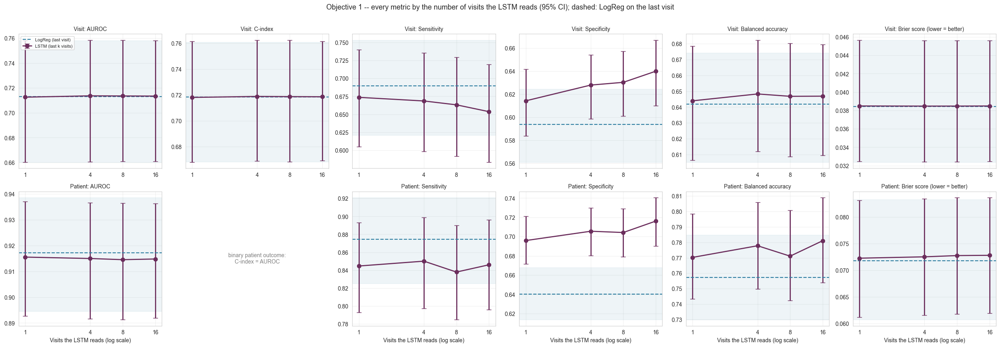


LSTM-8 - LSTM-1 (visit level, 30 months) by the number of clinic visits before the landmark -- oriented difference [95% CI] on every metric (descriptive):


,Landmarks,Onsets <= 30 mo,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score
Prior clinic visits,,,,,,,,
0,783,51,"-0.002 [-0.005, +0.001]","-0.001 [-0.004, +0.001]","+0.028 [+0.003, +0.057]","-0.052 [-0.061, -0.042]","-0.012 [-0.025, +0.003]","+0.000 [-0.000, +0.000]"
1-3,2127,108,"+0.000 [-0.004, +0.004]","+0.000 [-0.004, +0.004]","+0.011 [-0.011, +0.035]","-0.015 [-0.021, -0.008]","-0.002 [-0.013, +0.011]","+0.000 [-0.000, +0.000]"
4-7,2456,81,"+0.006 [+0.001, +0.012]","+0.005 [+0.000, +0.011]","-0.013 [-0.048, +0.020]","+0.026 [+0.019, +0.034]","+0.006 [-0.011, +0.023]","+0.000 [-0.000, +0.000]"
8-15,3848,135,"+0.004 [-0.002, +0.010]","+0.004 [-0.002, +0.009]","-0.018 [-0.044, +0.005]","+0.028 [+0.022, +0.035]","+0.005 [-0.008, +0.017]","+0.000 [+0.000, +0.000]"
>=16,7637,267,"-0.003 [-0.007, +0.002]","-0.003 [-0.007, +0.002]","-0.021 [-0.040, -0.004]","+0.022 [+0.015, +0.028]","+0.000 [-0.010, +0.009]","-0.000 [-0.000, +0.000]"


In [45]:
"""
Objective 1 side by side (Section 8.1): the LSTM on 1, 4, 8 and 16 visits and the LogReg on the last visit.
  1. visit- and patient-level tables, one row per model, the six metrics (value [95% patient-bootstrap CI]);
  2. every metric against the number of visits the LSTM reads (the dose-response behind H1b);
  3. LSTM-8 - LSTM-1 on every visit-level metric by the number of prior clinic visits (descriptive).
"""

OBJ1_HAVE = [m for m in OBJ1_MODELS if model_res(m) is not None and oof(m)]
O1_TABLES = {}
for level in ("visit", "patient"):
    t = value_table(OBJ1_HAVE, level)
    t.insert(0, "Visits read", [WINDOW_OF[m] for m in OBJ1_HAVE])
    t.insert(1, "CV repeats", [len(oof(m)) for m in OBJ1_HAVE])
    O1_TABLES[level] = t
    print(f"\nOBJECTIVE 1 -- {level.upper()} LEVEL ("
          + ("30-month onset, IPCW, every landmark visit" if level == "visit" else
             "visit alarms accumulated per patient, Section 11.6 rule; C-index = AUROC for this binary outcome")
          + "): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the "
            "cost-weighted alarm threshold")
    display(t)

# ---- every metric by the number of visits the LSTM reads (visit level top, patient level bottom)
fig, axes = plt.subplots(2, len(CORE_METRICS), figsize=(4.2 * len(CORE_METRICS), 8.6))
for i_, level in enumerate(("visit", "patient")):
    for j_, (k, lab_) in enumerate(CORE_METRICS):
        ax = axes[i_, j_]
        if k not in LEVEL_METRICS[level]:
            ax.text(0.5, 0.5, "binary patient outcome:\nC-index = AUROC", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.axis("off")
            continue
        xs, vs = [], []
        for m in [x for x in OBJ1_WINDOW_MODELS if x in OBJ1_HAVE]:
            v = core_value(m, k, level)
            if v is not None:
                xs.append(WINDOW_OF[m]); vs.append(v)
        if xs:
            mu = np.array([v["Value"] for v in vs])
            lo, hi = np.array([v["CI low"] for v in vs]), np.array([v["CI high"] for v in vs])
            ax.errorbar(xs, mu, yerr=[mu - lo, hi - mu], fmt="-o", capsize=4, color=CV_COLORS["LSTM"], lw=2, ms=7,
                        label="LSTM (last k visits)")
        v = core_value("LogReg", k, level) if "LogReg" in OBJ1_HAVE else None
        if v is not None:
            ax.axhline(v["Value"], color=CV_COLORS["LogReg"], ls="--", lw=1.6, label="LogReg (last visit)")
            ax.axhspan(v["CI low"], v["CI high"], color=CV_COLORS["LogReg"], alpha=0.08)
        ax.set_xscale("log", base=2); ax.set_xticks([1, 4, 8, 16]); ax.set_xticklabels(["1", "4", "8", "16"])
        ax.set_title(f"{level.capitalize()}: {lab_}" + (" (lower = better)" if k == "brier" else ""), fontsize=10)
        ax.grid(alpha=0.3)
        if i_ == 1:
            ax.set_xlabel("Visits the LSTM reads (log scale)")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Objective 1 -- every metric by the number of visits the LSTM reads (95% CI); dashed: LogReg on the last "
             "visit", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective1_dose_response.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- what the history adds by the number of prior clinic visits: LSTM-8 - LSTM-1 on every visit-level metric
PRIOR_BINS = [(0, 0, "0"), (1, 3, "1-3"), (4, 7, "4-7"), (8, 15, "8-15"), (16, 10 ** 6, ">=16")]
o1_prior = pd.DataFrame()
if all(x in OBJ1_HAVE for x in ("LSTM", "LSTM1")):
    _rows = []
    for lo_, hi_, lab_ in PRIOR_BINS:
        mask = (LAND_POS >= lo_) & (LAND_POS <= hi_)
        n_ev = int(((Y30 == 1) & (W30 > 0) & mask).sum())
        row = {"Prior clinic visits": lab_, "Landmarks": int(mask.sum()), "Onsets <= 30 mo": n_ev}
        if n_ev > 0:
            for k in LEVEL_METRICS["visit"]:
                row[CORE_LABEL[k]] = fmt_d(core_delta("LSTM", "LSTM1", k, mask=mask, tag=f"prior{lab_}"))
        _rows.append(row)
    o1_prior = pd.DataFrame(_rows).set_index("Prior clinic visits")
    print("\nLSTM-8 - LSTM-1 (visit level, 30 months) by the number of clinic visits before the landmark -- oriented "
          "difference [95% CI] on every metric (descriptive):")
    display(o1_prior)
    o1_prior.to_csv("objective1_by_prior_visits_revised_v21.csv")
for level, t in O1_TABLES.items():
    t.to_csv(f"objective1_{level}_level_revised_v21.csv")


## 11.10.7 H1a and H1b, and the within-patient secondary estimands

**H1a:** every pair of LSTM-8, LSTM-1 and the LogReg, on each of the six metrics, at the visit and the patient level;
per metric, the criterion is a lower 95 % bound of the oriented difference > 0. **H1b:** the least-squares slope of
each metric over the number of visits the LSTM reads (k = 1, 4, 8, 16), per visit, on the CV repeats all four models
completed; per metric, the criterion is a lower 95 % bound of the slope > 0. No metric is primary; the table is read
as a whole. Then the **within-patient secondary estimands** (descriptive): rising risk before onset (case minus
risk-set placebo concordance) and the AUROC of the 12-month change in predicted log-odds, LSTM-8 − LSTM-1.

H1a -- every pair on every metric: oriented paired difference [95% patient-cluster bootstrap CI, 1000 resamples] (> 0 favours the first model; Brier: b - a); * = lower bound > 0:


Metric                                     AUROC                  C-index  \
Comparison      Level                                                       
LSTM-8 - LSTM-1 visit    +0.001 [-0.002, +0.004]  +0.001 [-0.002, +0.003]   
                patient  -0.001 [-0.003, +0.001]                      NaN   
LSTM-8 - LogReg visit    +0.000 [-0.005, +0.007]  +0.000 [-0.005, +0.006]   
                patient  -0.003 [-0.006, +0.001]                      NaN   
LSTM-1 - LogReg visit    -0.000 [-0.006, +0.006]  -0.000 [-0.005, +0.006]   
                patient  -0.002 [-0.005, +0.001]                      NaN   

Metric                               Sensitivity                Specificity  \
Comparison      Level                                                         
LSTM-8 - LSTM-1 visit    -0.010 [-0.023, +0.001]  +0.016 [+0.012, +0.021] *   
                patient  -0.007 [-0.020, +0.008]  +0.008 [+0.002, +0.014] *   
LSTM-8 - LogReg visit    -0.026 [-0.051, -0.001]  +0.036 [+0.028, +0.045] *   
                patient  -0.036 [-0.065, -0.006]  +0.064 [+0.051, +0.078] *   
LSTM-1 - LogReg visit    -0.016 [-0.038, +0.008]  +0.020 [+0.011, +0.029] *   
                patient  -0.030 [-0.056, -0.003]  +0.056 [+0.043, +0.070] *   

Metric                         Balanced accuracy              Brier score  \
Comparison      Level                                                       
LSTM-8 - LSTM-1 visit    +0.003 [-0.003, +0.009]  +0.000 [-0.000, +0.000]   
                patient  +0.001 [-0.006, +0.009]  -0.000 [-0.001, +0.000]   
LSTM-8 - LogReg visit    +0.005 [-0.008, +0.018]  -0.000 [-0.000, +0.000]   
                patient  +0.014 [-0.002, +0.031]  -0.001 [-0.002, +0.000]   
LSTM-1 - LogReg visit    +0.002 [-0.009, +0.014]  -0.000 [-0.000, +0.000]   
                patient  +0.013 [-0.001, +0.028]  -0.000 [-0.002, +0.001]   

Metric                  Lower bound > 0 on  
Comparison      Level                       
LSTM-8 - LSTM-1 visit       1 of 6 metrics  
                patient     1 of 5 metrics  
LSTM-8 - LogReg visit       1 of 6 metrics  
                patient     1 of 5 metrics  
LSTM-1 - LogReg visit       1 of 6 metrics  
                patient     1 of 5 metrics

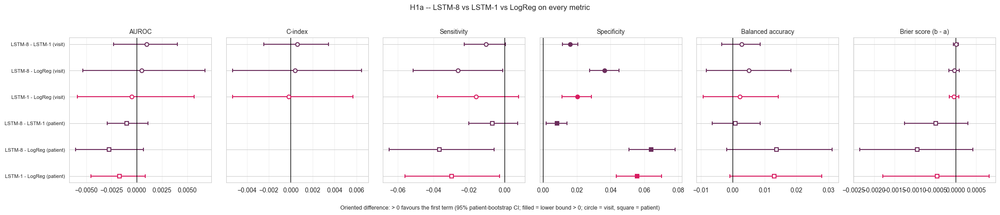


H1b -- each metric of the LSTM on the last k visits and its least-squares slope per visit read (oriented: > 0 = improves with more visits; Brier sign flipped), repeats all 4 completed:


k = 1   k = 4   k = 8  k = 16  \
Level   Metric                                              
visit   AUROC              0.7126  0.7137  0.7135  0.7135   
        C-index            0.7180  0.7188  0.7186  0.7185   
        Sensitivity        0.6737  0.6686  0.6633  0.6538   
        Specificity        0.6143  0.6280  0.6304  0.6400   
        Balanced accuracy  0.6440  0.6483  0.6468  0.6469   
        Brier score        0.0385  0.0385  0.0385  0.0385   
patient AUROC              0.9155  0.9150  0.9145  0.9148   
        Sensitivity        0.8446  0.8500  0.8378  0.8459   
        Specificity        0.6959  0.7056  0.7043  0.7162   
        Balanced accuracy  0.7703  0.7778  0.7711  0.7811   
        Brier score        0.0722  0.0725  0.0727  0.0728   

                             Slope per visit [95% CI]  Lower bound > 0  \
Level   Metric                                                           
visit   AUROC              +0.0000 [-0.0002, +0.0003]            False   
        C-index            +0.0000 [-0.0002, +0.0002]            False   
        Sensitivity        -0.0013 [-0.0021, -0.0005]            False   
        Specificity        +0.0015 [+0.0012, +0.0019]             True   
        Balanced accuracy  +0.0001 [-0.0003, +0.0006]            False   
        Brier score        -0.0000 [-0.0000, +0.0000]            False   
patient AUROC              -0.0000 [-0.0002, +0.0001]            False   
        Sensitivity        -0.0001 [-0.0011, +0.0008]            False   
        Specificity        +0.0012 [+0.0007, +0.0017]             True   
        Balanced accuracy  +0.0006 [-0.0000, +0.0011]            False   
        Brier score        -0.0000 [-0.0001, +0.0000]            False   

                           Repeats  
Level   Metric                      
visit   AUROC                    5  
        C-index                  5  
        Sensitivity              5  
        Specificity              5  
        Balanced accuracy        5  
        Brier score              5  
patient AUROC                    5  
        Sensitivity              5  
        Specificity              5  
        Balanced accuracy        5  
        Brier score              5

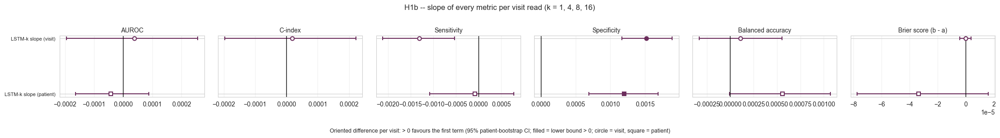


WITHIN-PATIENT SECONDARY ESTIMANDS OF OBJECTIVE 1 (descriptive; 95% CIs, no success criterion):


,AUROC a,AUROC b,Delta,CI low,CI high,Share of resamples > 0,Repeats
"Change-in-risk AUROC, LSTM-8 - LSTM-1",0.5409,0.5402,0.0007,-0.0045,0.0057,0.608,5.0
"Within-patient case - placebo concordance, LSTM-8 - LSTM-1",NaN,NaN,-0.0049,-0.0243,0.0136,0.334,5.0



Detail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), 76 event patients vs 339 risk-set placebo controls (pseudo-onset at the case's years since the first employed visit, same calendar era):


,Cases: P(near > far),Placebo: P(near > far),Case - placebo,CI low,CI high
Model,,,,,
LSTM-1 (current visit),0.4261,0.2961,0.1300,0.0638,0.1989
LSTM-4 (last 4 visits),0.4007,0.2744,0.1263,0.0604,0.1943
LSTM-8 (main),0.3928,0.2677,0.1251,0.0603,0.1922
LSTM-16 (last 16 visits),0.3899,0.2645,0.1254,0.0614,0.1933
LogReg (last visit),0.4354,0.3145,0.1210,0.0541,0.1875


In [46]:
"""
Objective 1 (Section 8.1), on all six metrics, no metric primary:
  H1a  LSTM-8 vs LSTM-1 vs LogReg, every pair, oriented paired differences at the visit and the patient level;
       criterion per metric: lower 95% bound > 0.
  H1b  least-squares slope of each metric on k = 1, 4, 8, 16 (the LSTM on the last k visits), per visit read, on the
       repeats all four completed, the same resamples for every k; criterion per metric: lower 95% bound > 0.
Then the within-patient secondary estimands (descriptive).
"""
H1A_PAIRS = [("LSTM", "LSTM1", "LSTM-8 - LSTM-1"), ("LSTM", "LogReg", "LSTM-8 - LogReg"),
             ("LSTM1", "LogReg", "LSTM-1 - LogReg")]
_pairs = [p for p in H1A_PAIRS if p[0] in OBJ1_HAVE and p[1] in OBJ1_HAVE]
h1a = pd.concat([delta_long(_pairs, level) for level in ("visit", "patient")], ignore_index=True)
print(f"H1a -- every pair on every metric: oriented paired difference [95% patient-cluster bootstrap CI, {HYP_BOOT} "
      "resamples] (> 0 favours the first model; Brier: b - a); * = lower bound > 0:")
display(delta_wide(h1a))
forest_metrics(h1a, "H1a -- LSTM-8 vs LSTM-1 vs LogReg on every metric", "revised_v21_h1a_forest.png")
record("H1a", h1a)

H1B_MODELS = [m for m in OBJ1_WINDOW_MODELS if m in OBJ1_HAVE]
K_ = np.array([WINDOW_OF[m] for m in H1B_MODELS], float)
_rows = []
if len(H1B_MODELS) >= 3:
    kc = K_ - K_.mean()
    for level in ("visit", "patient"):
        reps = common_reps(H1B_MODELS, level)
        if not reps:
            continue
        for k in LEVEL_METRICS[level]:
            V = np.array([_cols(m, k, level, reps=reps) for m in H1B_MODELS])          # (k values, 1 + B)
            S = CORE_SIGN[k] * (kc @ (V - V.mean(0))) / (kc @ kc)
            lo, hi = _ci(S)
            _rows.append({"Comparison": "slope per visit read", "a": "LSTM", "b": "", "Level": level,
                          "Metric": CORE_LABEL[k], "key": k, "Delta": float(S[0]), "CI low": lo, "CI high": hi,
                          "Share of resamples > 0": float(np.nanmean(S[1:] > 0)), "Repeats": len(reps),
                          "Lower bound > 0": bool(lo > 0),
                          **{f"k = {int(x)}": float(v) for x, v in zip(K_, V[:, 0])}})
h1b = pd.DataFrame(_rows)
if h1b.empty:
    print("\nH1b skipped: fewer than three window models have run.")
else:
    _show = h1b.set_index(["Level", "Metric"])
    _show = _show[[c for c in _show.columns if c.startswith("k = ")]].round(4).assign(
        **{"Slope per visit [95% CI]": [fmt_d(r, 4) for _, r in h1b.iterrows()],
           "Lower bound > 0": h1b["Lower bound > 0"].values, "Repeats": h1b["Repeats"].values})
    print(f"\nH1b -- each metric of the LSTM on the last k visits and its least-squares slope per visit read "
          f"(oriented: > 0 = improves with more visits; Brier sign flipped), repeats all {len(H1B_MODELS)} completed:")
    display(_show)
    forest_metrics(h1b.assign(Comparison="LSTM-k slope"), "H1b -- slope of every metric per visit read (k = "
                   + ", ".join(str(int(x)) for x in K_) + ")", "revised_v21_h1b_forest.png", nd_label=" per visit")
    record("H1b", h1b, crit="lower 95% bound of the slope > 0", nd=4)
pd.concat([h1a, h1b], ignore_index=True).to_csv("objective1_tests_revised_v21.csv", index=False)


o1_sec = {}


# ---- change in risk: the 12-month change in predicted log-odds (vs the landmark 9-15 months earlier, nearest to 12 months)
def _prior_12m():
    out = np.full(len(land), -1)
    d = pd.to_datetime(land["visit_date"]).values
    for _, idx in land.groupby("pid").indices.items():
        t = d[idx]
        for j in range(len(idx)):
            dt = (t[j] - t[:j]) / np.timedelta64(1, "D")
            c = np.flatnonzero((dt >= 270) & (dt <= 460))
            if len(c):
                out[idx[j]] = idx[c[np.argmin(np.abs(dt[c] - 365))]]
    return out


PRIOR_12M = _prior_12m()
HAS_PRIOR = PRIOR_12M >= 0
change = lambda m: {r: np.where(HAS_PRIOR, _logit(p) - _logit(p[np.maximum(PRIOR_12M, 0)]), 0.0) for r, p in oof(m).items()}
if oof("LSTM") and oof("LSTM1"):
    d = paired_delta("LSTM", "LSTM1", scores_a=change("LSTM"), scores_b=change("LSTM1"), w=W30 * HAS_PRIOR, tag="change")
    o1_sec["Change-in-risk AUROC, LSTM-8 - LSTM-1"] = d


# ---- within-patient rising risk: within-patient case-minus-placebo concordance (risk-set placebo)
def placebo_pairs(seed=2026, k_ctrl=5):
    lm = land.assign(onset_y=land["YRS_SINCE_INDEX"] + land["time_days"] / 365.25)
    by = {p: g for p, g in lm.groupby("pid")}
    ctrl_pids = lm.loc[lm["pt_event"] == 0, "pid"].unique()
    ctrl_fu = {q: float(by[q]["onset_y"].max()) for q in ctrl_pids}
    ctrl_y0 = {q: float((by[q]["CAL_YEAR"] - by[q]["YRS_SINCE_INDEX"]).min()) for q in ctrl_pids}
    edges, hy = [b[1] for b in ERA_BANDS[:-1]], HORIZON_DAYS / 365.25
    rng = np.random.default_rng(seed)
    cases, ctrls = [], []
    for p in lm.loc[lm["event"] == 1, "pid"].unique():
        g = by[p]
        near, far = g.index[g["time_days"] <= HORIZON_DAYS].values, g.index[g["time_days"] > HORIZON_DAYS].values
        if not len(near) or not len(far):
            continue
        T = float(g["onset_y"].iloc[0])
        e_case = np.digitize(float((g["CAL_YEAR"] + g["time_days"] / 365.25).iloc[0]), edges)
        cases.append((near, far))
        elig = []
        for q in ctrl_pids:
            if ctrl_fu[q] < T + hy or np.digitize(ctrl_y0[q] + T, edges) != e_case:
                continue
            gq = by[q]
            nq = gq.index[(gq["YRS_SINCE_INDEX"] > T - hy) & (gq["YRS_SINCE_INDEX"] <= T)].values
            fq = gq.index[gq["YRS_SINCE_INDEX"] <= T - hy].values
            if len(nq) and len(fq):
                elig.append((nq, fq))
        for i in (rng.choice(len(elig), min(k_ctrl, len(elig)), replace=False) if elig else []):
            ctrls.append(elig[i])
    return cases, ctrls


PL_CASES, PL_CTRLS = placebo_pairs()


def _conc(p, pairs):
    return np.array([(p[a][:, None] > p[b][None, :]).mean() + 0.5 * (p[a][:, None] == p[b][None, :]).mean()
                     for a, b in pairs])


def did_components(m):
    """Per case and per control concordance, averaged over the model's repeats."""
    P_ = oof(m)
    reps = sorted(P_)
    return (np.mean([_conc(P_[r], PL_CASES) for r in reps], axis=0),
            np.mean([_conc(P_[r], PL_CTRLS) for r in reps], axis=0))


_rng_d = np.random.default_rng(2032)
_bi_c = [_rng_d.integers(0, len(PL_CASES), len(PL_CASES)) for _ in range(HYP_BOOT)]
_bi_k = [_rng_d.integers(0, len(PL_CTRLS), len(PL_CTRLS)) for _ in range(HYP_BOOT)]
did_rows, DID = [], {}
for m in [x for x in OBJ1_MODELS if oof(x)]:
    cs, cc = did_components(m)
    DID[m] = (cs, cc)
    B = np.array([cs[i].mean() - cc[j].mean() for i, j in zip(_bi_c, _bi_k)])
    did_rows.append({"Model": mlab(m), "Cases: P(near > far)": cs.mean(),
                     "Placebo: P(near > far)": cc.mean(), "Case - placebo": cs.mean() - cc.mean(),
                     "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5)})
did_df = pd.DataFrame(did_rows).set_index("Model")
if "LSTM" in DID and "LSTM1" in DID:
    (c8, k8), (c1, k1) = DID["LSTM"], DID["LSTM1"]
    B = np.array([(c8[i].mean() - k8[j].mean()) - (c1[i].mean() - k1[j].mean()) for i, j in zip(_bi_c, _bi_k)])
    est = (c8.mean() - k8.mean()) - (c1.mean() - k1.mean())
    o1_sec["Within-patient case - placebo concordance, LSTM-8 - LSTM-1"] = {
        "Delta": est, "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5),
        "Share of resamples > 0": float(np.mean(B > 0)), "Repeats": len(oof("LSTM"))}
sec_df = pd.DataFrame(o1_sec).T
print("\nWITHIN-PATIENT SECONDARY ESTIMANDS OF OBJECTIVE 1 (descriptive; 95% CIs, no success criterion):")
display(sec_df.round(4))
print(f"\nDetail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), "
      f"{len(PL_CASES)} event patients vs {len(PL_CTRLS)} risk-set placebo controls (pseudo-onset at the case's years "
      f"since the first employed visit, same calendar era):")
display(did_df.round(4))
sec_df.to_csv("secondary_estimands_revised_v21.csv")
did_df.to_csv("within_patient_did_revised_v21.csv")

## 11.10.8 Supplementary LSTM variants and what the history adds by horizon

LSTM-8 against LSTM-1 on identical folds (the formal test of H2 is in Section 11.10.7),
at every horizon from 6 to 48 months, with the supplementary variants (last 4 or 16 visits; no skip connection; no
auxiliary heads; one CV repeat each, paired with the first repeat of LSTM-1).

Resuming from cv_state_model_revised_v21.pkl: 125 model-fold fits already done.
[LSTM_noskip] repeat 1/5 fold 1/5 | AUROC 0.736 NB(R=23.9) 0.0155 | visit sens/spec 0.56/0.75 | patient sens/spec 0.79/0.83 (TN/FP 151/31) | cfg w8_noskip | 17 feats | 79s
[LSTM_noaux ] repeat 1/5 fold 1/5 | AUROC 0.716 NB(R=23.9) 0.0138 | visit sens/spec 0.57/0.70 | patient sens/spec 0.83/0.77 (TN/FP 140/42) | cfg w8_noaux | 17 feats | 64s
[LSTM_noskip] repeat 1/5 fold 2/5 | AUROC 0.706 NB(R=22.9) 0.0064 | visit sens/spec 0.51/0.68 | patient sens/spec 0.83/0.75 (TN/FP 136/45) | cfg w8_noskip | 17 feats | 87s
[LSTM_noaux ] repeat 1/5 fold 2/5 | AUROC 0.743 NB(R=22.9) 0.0086 | visit sens/spec 0.46/0.77 | patient sens/spec 0.70/0.83 (TN/FP 150/31) | cfg w8_noaux | 17 feats | 58s
[LSTM_noskip] repeat 1/5 fold 3/5 | AUROC 0.685 NB(R=23.6) 0.0139 | visit sens/spec 0.55/0.76 | patient sens/spec 0.80/0.84 (TN/FP 152/30) | cfg w8_noskip | 17 feats | 91s
[LSTM_noaux ] repeat 1/5 fold 3/5 | AUROC 0.703 NB(R=23.6) 0.0

,CV repeats,AUROC 6 mo,AUROC 12 mo,AUROC 18 mo,AUROC 24 mo,AUROC 30 mo,AUROC 36 mo,AUROC 42 mo,AUROC 48 mo,Brier (30 mo),Visit sensitivity,Visit specificity,Alerts / 100 visits,Patient C-index,Patient sensitivity,Patient specificity
LSTM-8 (main),5,0.722,0.724,0.715,0.712,0.714,0.715,0.711,0.707,0.038,0.663,0.630,37.659,0.915,0.838,0.704
LSTM-16 (last 16 visits),5,0.721,0.724,0.715,0.712,0.713,0.715,0.711,0.707,0.038,0.654,0.640,36.689,0.915,0.846,0.716
LSTM-4 (last 4 visits),5,0.720,0.723,0.714,0.711,0.714,0.715,0.711,0.707,0.038,0.669,0.628,37.868,0.915,0.850,0.706
LSTM-1 (current visit),5,0.717,0.721,0.713,0.710,0.713,0.715,0.711,0.707,0.038,0.674,0.614,39.102,0.916,0.845,0.696
LSTM-8 without skip connection,1,0.718,0.718,0.706,0.703,0.707,0.709,0.708,0.705,0.039,0.591,0.702,30.503,0.904,0.804,0.763
LSTM-8 without auxiliary heads,1,0.728,0.728,0.719,0.715,0.718,0.719,0.714,0.710,0.038,0.596,0.696,31.173,0.917,0.804,0.751



Delta AUROC vs LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; 200 patient-bootstrap resamples):


Model,LSTM-16 (last 16 visits),LSTM-4 (last 4 visits),LSTM-8 (main),LSTM-8 without auxiliary heads,LSTM-8 without skip connection
Horizon (mo),,,,,
6,0.004,0.003,0.005,0.006,-0.004
12,0.003,0.002,0.003,0.005,-0.005
18,0.002,0.001,0.002,0.005,-0.007
24,0.002,0.001,0.002,0.003,-0.009
30,0.001,0.001,0.001,0.003,-0.008
36,0.000,0.000,0.000,0.002,-0.007
42,-0.000,0.000,-0.000,0.002,-0.005
48,-0.000,0.000,0.000,0.001,-0.004


,Paired repeats,Horizon (mo),Delta AUROC vs LSTM-1,95% CI,Share of resamples > 0
Model,,,,,
LSTM-8 (main),5,30,0.001,"[-0.003, +0.004]",0.725
LSTM-16 (last 16 visits),5,30,0.001,"[-0.003, +0.005]",0.690
LSTM-4 (last 4 visits),5,30,0.001,"[-0.002, +0.004]",0.790
LSTM-8 without skip connection,1,30,-0.008,"[-0.025, +0.008]",0.175
LSTM-8 without auxiliary heads,1,30,0.003,"[-0.001, +0.007]",0.925


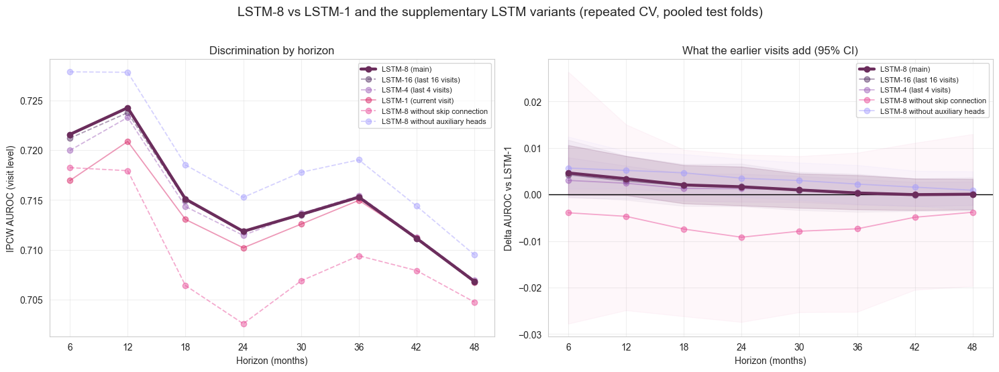

In [47]:
"""
What the history adds (Section 11.10.8): LSTM-8 and the supplementary LSTM variants against LSTM-1 (the same network on
the current visit alone), from the pooled test folds (no refitting for LSTM-8 / LSTM-1; the variants are fitted here,
MODEL_REPEATS repeat(s) each): visit AUROC at every horizon, 30-month Brier, sensitivity, specificity and alert rate,
30-month patient C-index, sensitivity and specificity, and Delta AUROC (model - LSTM-1) at every horizon with a
patient-cluster bootstrap CI (the same resamples in every repeat; pairs of repeats both models completed).
"""
cv_state = run_repeated_cv(models=SUPP_LSTM_MODELS)       # the supplementary variants (checkpointed, resumable)
N_BOOT_WIN = 100 if SMOKE else 200
HISTORY_REF = "LSTM1"
HISTORY_MODELS = ["LSTM", "LSTM_w16", "LSTM_w4", "LSTM1"] + SUPP_LSTM_MODELS


def window_metrics(reps):
    """Mean over repeats of the test-fold metrics of one model."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    rows = []
    for P, thr, _ in reps:
        p = P[:, PRIMARY_COL]
        a = p >= thr
        tp, fp, fn, tn = w_confusion(y[k], a[k], w[k])
        f = patient_frame(ALL_ROWS, p, thr)
        pc = patient_counts(f)
        rows.append({**{f"AUROC {h} mo": w_auroc(IPCW[h][0], P[:, j], IPCW[h][1])
                        for j, h in enumerate(EVAL_HORIZONS_MONTHS)},
                     "Brier (30 mo)": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
                     "Visit sensitivity": tp / max(tp + fn, 1e-12), "Visit specificity": tn / max(tn + fp, 1e-12),
                     "Alerts / 100 visits": 100.0 * float(np.mean(a)),
                     "Patient C-index": w_auroc(f["y"].values, f["score"].values, np.ones(len(f))),
                     "Patient sensitivity": pc["TP"] / max(pc["TP"] + pc["FN"], 1),
                     "Patient specificity": pc["TN"] / max(pc["TN"] + pc["FP"], 1)})
    return pd.DataFrame(rows).mean()


def delta_auc_by_horizon(reps_a, reps_b, boots):
    """Delta AUROC (a - b) at every horizon, mean over paired repeats, with the bootstrap distribution."""
    n = min(len(reps_a), len(reps_b))
    d0, B = np.zeros(H_), np.zeros((len(boots), H_))
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        y, w = IPCW[h]
        preps = [(auc_prep(y, A[0][:, j]), auc_prep(y, Bm[0][:, j])) for A, Bm in zip(reps_a[:n], reps_b[:n])]
        d0[j] = np.mean([auc_w(pa, w) - auc_w(pb, w) for pa, pb in preps])
        for i, (m_land, _) in enumerate(boots):
            ww = w * m_land
            B[i, j] = np.mean([auc_w(pa, ww) - auc_w(pb, ww) for pa, pb in preps])
    return d0, B


HIST_REPS = {m: model_repeats(m) for m in HISTORY_MODELS}
HIST_HAVE = [m for m in HISTORY_MODELS if HIST_REPS[m]]
if HISTORY_REF not in HIST_HAVE or "LSTM" not in HIST_HAVE:
    print("Run Sections 11.10.1 and 11.10.2 first.")
else:
    lab = lambda m: MODEL_LABELS.get(m, m)
    hist_table = pd.DataFrame({lab(m): window_metrics(HIST_REPS[m]) for m in HIST_HAVE}).T
    hist_table.insert(0, "CV repeats", [len(HIST_REPS[m]) for m in HIST_HAVE])
    print("LSTM-8, LSTM-1 and the supplementary LSTM variants -- pooled test folds, mean over the completed repeats:")
    display(hist_table.round(3))
    boots = patient_boot_counts(N_BOOT_WIN)
    DELTA_HIST, drows = {}, []
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, B = delta_auc_by_horizon(HIST_REPS[m], HIST_REPS[HISTORY_REF], boots)
        lo, hi = np.nanpercentile(B, [2.5, 97.5], axis=0)
        DELTA_HIST[lab(m)] = (d0, lo, hi)
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            drows.append({"Model": lab(m), "Paired repeats": min(len(HIST_REPS[m]), len(HIST_REPS[HISTORY_REF])),
                          "Horizon (mo)": h, "Delta AUROC vs LSTM-1": d0[j], "95% CI": f"[{lo[j]:+.3f}, {hi[j]:+.3f}]",
                          "Share of resamples > 0": float(np.mean(B[:, j] > 0))})
    delta_hist = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; "
          f"{N_BOOT_WIN} patient-bootstrap resamples):")
    display(delta_hist.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC vs LSTM-1").round(3))
    display(delta_hist[delta_hist["Horizon (mo)"] == PRIMARY_HORIZON_MONTHS].set_index("Model").round(3))
    hist_table.to_csv("lstm_history_comparison_revised_v21.csv")
    delta_hist.to_csv("lstm_history_delta_auroc_revised_v21.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
    ax = axes[0]
    for m in HIST_HAVE:
        row = hist_table.loc[lab(m), [f"AUROC {h} mo" for h in EVAL_HORIZONS_MONTHS]]
        ax.plot(EVAL_HORIZONS_MONTHS, row.values, marker="o", ls="-" if m in ("LSTM", "LSTM1") else "--", label=lab(m),
                **model_style(m))
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC (visit level)")
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, lo, hi = DELTA_HIST[lab(m)]
        c_ = CV_COLORS.get(m, "#444444")
        ax.plot(EVAL_HORIZONS_MONTHS, d0, marker="o", label=lab(m), **model_style(m))
        ax.fill_between(EVAL_HORIZONS_MONTHS, lo, hi, color=c_, alpha=0.15 if m == "LSTM" else 0.04)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Delta AUROC vs LSTM-1"); ax.set_title("What the earlier visits add (95% CI)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("LSTM-8 vs LSTM-1 and the supplementary LSTM variants (repeated CV, pooled test folds)", y=1.02,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_lstm_history.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.10.9 Static vs longitudinal models by horizon and by history length

The static models (LogReg, Cox, RSF, LSTM-1) see the current visit; the longitudinal models (LSTM, GRU,
Transformer) read the variables over the patient's history. From the **same pooled out-of-fold risks** as the main tables:

1. **By horizon.** The IPCW AUROC of every model at 6, 12, …, 48 months, each horizon scored against its own
   competing-risk label (onset by that horizon; an earlier other exit is a resolved negative).
2. **By history length.** The 30-month AUROC in strata of the number of the patient's clinic visits before the
   landmark (about quintiles: 0–3, 4–9, 10–17, 18–30, ≥ 31).

ΔAUROC = sequence model − LogReg, paired on identical folds, averaged over the CV repeats; the 95 % CI comes from a
patient-cluster bootstrap (the same resample in every repeat). If the history carried information beyond the current
visit, ΔAUROC should be positive, especially at short horizons (a change heralding onset) and for patients with a long
history.

IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:


,Type,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
LogReg,static,0.717,0.722,0.714,0.711,0.713,0.713,0.708,0.702
LSTM1,static,0.717,0.721,0.713,0.710,0.713,0.715,0.711,0.707
LSTM,longitudinal,0.722,0.724,0.715,0.712,0.714,0.715,0.711,0.707
LSTM_w16,longitudinal,0.721,0.724,0.715,0.712,0.713,0.715,0.711,0.707
LSTM_w4,longitudinal,0.720,0.723,0.714,0.711,0.714,0.715,0.711,0.707



Delta AUROC vs LogReg by horizon (paired; 500 patient-bootstrap resamples):


Model,LSTM,LSTM1,LSTM_w16,LSTM_w4
Horizon (mo),,,,
6,0.004,-0.000,0.004,0.003
12,0.003,-0.001,0.002,0.002
18,0.001,-0.001,0.000,-0.000
24,0.001,-0.000,0.001,0.001
30,0.000,-0.000,0.000,0.001
36,0.002,0.002,0.002,0.003
42,0.004,0.004,0.003,0.004
48,0.005,0.005,0.005,0.005


Delta AUROC            95% CI  Share of resamples > 0
Model    Horizon (mo)                                                       
LSTM     6                   0.004  [-0.006, +0.014]                   0.782
         12                  0.003  [-0.006, +0.011]                   0.728
         18                  0.001  [-0.005, +0.007]                   0.564
         24                  0.001  [-0.004, +0.008]                   0.650
         30                  0.000  [-0.005, +0.007]                   0.546
         36                  0.002  [-0.003, +0.008]                   0.808
         42                  0.004  [-0.002, +0.010]                   0.868
         48                  0.005  [-0.001, +0.012]                   0.938
LSTM_w16 6                   0.004  [-0.006, +0.014]                   0.746
         12                  0.002  [-0.007, +0.011]                   0.690
         18                  0.000  [-0.006, +0.007]                   0.532
         24                  0.001  [-0.005, +0.008]                   0.646
         30                  0.000  [-0.006, +0.007]                   0.538
         36                  0.002  [-0.003, +0.009]                   0.774
         42                  0.003  [-0.003, +0.011]                   0.848
         48                  0.005  [-0.001, +0.012]                   0.906
LSTM_w4  6                   0.003  [-0.007, +0.012]                   0.662
         12                  0.002  [-0.007, +0.010]                   0.662
         18                 -0.000  [-0.006, +0.006]                   0.474
         24                  0.001  [-0.005, +0.007]                   0.600
         30                  0.001  [-0.005, +0.006]                   0.562
         36                  0.003  [-0.003, +0.009]                   0.828
         42                  0.004  [-0.002, +0.011]                   0.866
         48                  0.005  [-0.001, +0.012]                   0.940


30-month IPCW AUROC by the number of clinic visits before the landmark:


,Landmarks,Patients,Event patients,LogReg,LSTM1,LSTM,LSTM_w16,LSTM_w4
Prior visits,,,,,,,,
0-3,2910,865,64,0.728,0.717,0.717,0.718,0.718
4-9,3536,741,39,0.728,0.726,0.731,0.732,0.732
10-17,3557,574,42,0.709,0.703,0.706,0.704,0.706
18-30,3660,413,38,0.716,0.721,0.720,0.722,0.718
>=31,3188,215,15,0.646,0.661,0.654,0.653,0.657


Delta AUROC vs LogReg at 30 months by history length:


Delta AUROC            95% CI  Share of resamples > 0
Model    Prior visits                                                       
LSTM     0-3                -0.010  [-0.019, -0.001]                   0.014
         4-9                 0.003  [-0.005, +0.013]                   0.766
         10-17              -0.003  [-0.012, +0.008]                   0.242
         18-30               0.004  [-0.008, +0.016]                   0.774
         >=31                0.008  [-0.014, +0.034]                   0.752
LSTM_w16 0-3                -0.010  [-0.019, -0.001]                   0.016
         4-9                 0.004  [-0.004, +0.012]                   0.786
         10-17              -0.005  [-0.015, +0.006]                   0.156
         18-30               0.006  [-0.007, +0.019]                   0.824
         >=31                0.007  [-0.015, +0.033]                   0.718
LSTM_w4  0-3                -0.009  [-0.018, +0.000]                   0.026
         4-9                 0.004  [-0.004, +0.013]                   0.804
         10-17              -0.004  [-0.013, +0.008]                   0.192
         18-30               0.002  [-0.011, +0.014]                   0.652
         >=31                0.011  [-0.010, +0.036]                   0.836

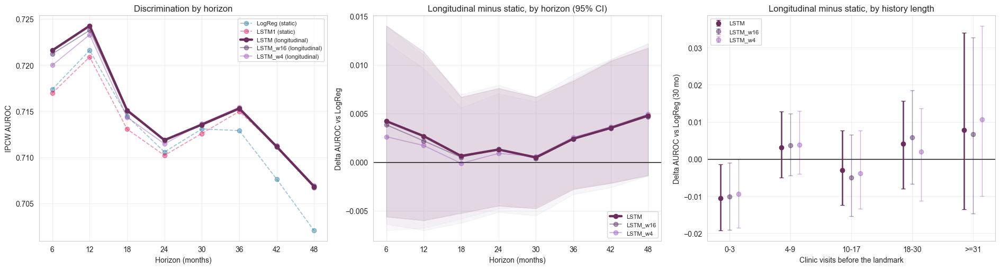

In [48]:
"""
Static vs longitudinal models, from the main CV state (no refitting): IPCW AUROC by horizon (6-48 mo) and by the number
of prior clinic visits (30 mo), with paired Delta AUROC (sequence model - LogReg) and patient-cluster bootstrap CIs.
"""
STATIC_MODELS = [m for m in ["LogReg", "LogRegW", "CoxPH", "RSF", "LSTM1"] if m in CV_MODELS]
LONGITUDINAL_MODELS = [m for m in ["LSTM", "LSTM_w16", "LSTM_w4", "GRU", "Transformer"] if m in CV_MODELS]
DELTA_REFERENCE = "LogReg"
N_BOOT_DELTA = 100 if SMOKE else 500
HISTORY_BINS = [0, 4, 10, 18, 31, np.inf]
HISTORY_LABELS = ["0-3", "4-9", "10-17", "18-30", ">=31"]


def fast_w_auc(y, p, w):
    """IPCW AUROC by the weighted Mann-Whitney statistic (ties count 1/2); equals roc_auc_score with weights."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    if len(y) == 0 or y.min() == y.max():
        return np.nan
    o = np.argsort(p, kind="mergesort")
    p, y, w = p[o], y[o], w[o]
    _, start = np.unique(p, return_index=True)
    wp, wn = np.add.reduceat(w * (y == 1), start), np.add.reduceat(w * (y == 0), start)
    below = np.cumsum(wn) - wn
    return float((wp * (below + 0.5 * wn)).sum() / (wp.sum() * wn.sum()))


def oof_risks(model):
    """Pooled out-of-fold calibrated risks, one (n_landmarks, n_horizons) matrix per completed repeat."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full((len(land), len(EVAL_HORIZONS_MONTHS)), np.nan))[v["te"]] = v["P"]
    return [out[r] for r in sorted(out) if not np.isnan(out[r][:, 0]).any()]


SL_MODELS = [m for m in STATIC_MODELS + LONGITUDINAL_MODELS if oof_risks(m)]
OOF = {m: oof_risks(m) for m in SL_MODELS}
N_PRIOR_VISITS = LAND_POS                                            # clinic visits before the landmark visit
HIST_STRATUM = pd.cut(N_PRIOR_VISITS, HISTORY_BINS, right=False, labels=HISTORY_LABELS).astype(str)
_rows_of = pd.Series(np.arange(len(land))).groupby(PID_ALL).apply(np.asarray)
_rng = np.random.default_rng(2026)
BOOT_ROWS = [np.concatenate(_rows_of.loc[_rng.choice(_rows_of.index.values, len(_rows_of))].values)
             for _ in range(N_BOOT_DELTA)]


def auc_mean(model, j, idx):
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    return float(np.mean([fast_w_auc(y[idx], P[idx, j], w[idx]) for P in OOF[model]]))


def delta_ci(model, j, idx_of_boot, base_idx):
    """Delta AUROC (model - reference) at horizon column j on rows base_idx; CI over the bootstrap resamples."""
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    n_rep = min(len(OOF[model]), len(OOF[DELTA_REFERENCE]))
    pairs = list(zip(OOF[model][:n_rep], OOF[DELTA_REFERENCE][:n_rep]))
    def d(idx):
        return np.mean([fast_w_auc(y[idx], A[idx, j], w[idx]) - fast_w_auc(y[idx], B[idx, j], w[idx]) for A, B in pairs])
    boots = np.array([d(idx_of_boot(b)) for b in BOOT_ROWS])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return d(base_idx), lo, hi, float(np.nanmean(boots > 0))


if len(SL_MODELS) < 2 or DELTA_REFERENCE not in SL_MODELS:
    print("Static vs longitudinal comparison skipped: run the model sections first.")
else:
    ALL_ROWS = np.arange(len(land))
    # ---- 1. by horizon
    tab_h = pd.DataFrame({f"{h} mo": [auc_mean(m, j, ALL_ROWS) for m in SL_MODELS]
                          for j, h in enumerate(EVAL_HORIZONS_MONTHS)}, index=SL_MODELS)
    tab_h.insert(0, "Type", ["static" if m in STATIC_MODELS else "longitudinal" for m in SL_MODELS])
    print("IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:")
    display(tab_h.round(3))
    drows, DELTA_H = [], {}
    for m in [x for x in LONGITUDINAL_MODELS + STATIC_MODELS if x in SL_MODELS and x != DELTA_REFERENCE]:
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            d0, lo, hi, share = delta_ci(m, j, lambda b: b, ALL_ROWS)
            DELTA_H[(m, h)] = (d0, lo, hi)
            drows.append({"Model": m, "Horizon (mo)": h, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                          "Share of resamples > 0": share})
    delta_h = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs {DELTA_REFERENCE} by horizon (paired; {N_BOOT_DELTA} patient-bootstrap resamples):")
    display(delta_h.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC").round(3))
    display(delta_h[delta_h["Model"].isin(LONGITUDINAL_MODELS)].set_index(["Model", "Horizon (mo)"]).round(3))

    # ---- 2. by history length (30 months)
    j30 = PRIMARY_COL
    hrows = []
    for lab in HISTORY_LABELS:
        idx = np.flatnonzero(HIST_STRATUM == lab)
        y, w = IPCW[PRIMARY_HORIZON_MONTHS]
        r = {"Prior visits": lab, "Landmarks": len(idx), "Patients": len(np.unique(PID_ALL[idx])),
             "Event patients": len(np.unique(PID_ALL[idx][(y[idx] == 1) & (w[idx] > 0)]))}
        r.update({m: auc_mean(m, j30, idx) for m in SL_MODELS})
        hrows.append(r)
    tab_hist = pd.DataFrame(hrows).set_index("Prior visits")
    print(f"\n{PRIMARY_HORIZON_MONTHS}-month IPCW AUROC by the number of clinic visits before the landmark:")
    display(tab_hist.round(3))
    hd, DELTA_HISTLEN = [], {}
    in_stratum = {lab: HIST_STRATUM == lab for lab in HISTORY_LABELS}
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        for lab in HISTORY_LABELS:
            mask = in_stratum[lab]
            d0, lo, hi, share = delta_ci(m, j30, lambda b, mask=mask: b[mask[b]], np.flatnonzero(mask))
            DELTA_HISTLEN[(m, lab)] = (d0, lo, hi)
            hd.append({"Model": m, "Prior visits": lab, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                       "Share of resamples > 0": share})
    delta_histlen = pd.DataFrame(hd)
    print(f"Delta AUROC vs {DELTA_REFERENCE} at {PRIMARY_HORIZON_MONTHS} months by history length:")
    display(delta_histlen.set_index(["Model", "Prior visits"]).round(3))

    pd.concat([tab_h.assign(table="AUROC by horizon"), delta_h.assign(table="Delta by horizon"),
               tab_hist.reset_index().assign(table="AUROC by history"), delta_histlen.assign(table="Delta by history")],
              ignore_index=False).to_csv("static_vs_longitudinal_revised_v21.csv")

    # ---- plots
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
    ax = axes[0]
    for m in SL_MODELS:
        ax.plot(EVAL_HORIZONS_MONTHS, tab_h.loc[m, [f"{h} mo" for h in EVAL_HORIZONS_MONTHS]].values, marker="o",
                ls="-" if m in LONGITUDINAL_MODELS else "--", label=f"{m} ({tab_h.loc[m, 'Type']})", **model_style(m))
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC"); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        d = np.array([DELTA_H[(m, h)] for h in EVAL_HORIZONS_MONTHS])
        ax.plot(EVAL_HORIZONS_MONTHS, d[:, 0], marker="o", label=m, **model_style(m))
        ax.fill_between(EVAL_HORIZONS_MONTHS, d[:, 1], d[:, 2], color=CV_COLORS.get(m), alpha=0.12 if m == "LSTM" else 0.04)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE}")
    ax.set_title("Longitudinal minus static, by horizon (95% CI)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[2]
    xs = np.arange(len(HISTORY_LABELS))
    for i_m, m in enumerate([x for x in LONGITUDINAL_MODELS if x in SL_MODELS]):
        d = np.array([DELTA_HISTLEN[(m, lab)] for lab in HISTORY_LABELS])
        off = (i_m - 1) * 0.15
        ax.errorbar(xs + off, d[:, 0], yerr=[d[:, 0] - d[:, 1], d[:, 2] - d[:, 0]], fmt="o", capsize=3, label=m,
                    **model_style(m, 1.8, 1.0))
    ax.axhline(0, color="k", lw=1); ax.set_xticks(xs); ax.set_xticklabels(HISTORY_LABELS)
    ax.set_xlabel("Clinic visits before the landmark"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE} ({PRIMARY_HORIZON_MONTHS} mo)")
    ax.set_title("Longitudinal minus static, by history length"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_static_vs_longitudinal.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.10.10 Is there signal in the trajectory? (engineered change variables)

A longitudinal model can only beat a static one if the course of the disease says something the current visit does
not. This screen asks that directly with hand-built trajectory variables: each is **added on its own to the
current-visit variables** in a simple logistic model of onset within 30 months (IPCW × $1/n_i$ weights, signed log1p,
median imputation and standardisation inside the training fold, the main CV folds), and the change in the
**out-of-fold IPCW AUROC** is reported (mean and range over the CV repeats). A nonlinear check (gradient boosting,
current-visit variables with and without all trajectory variables) follows.

**Descriptive only:** no model in this notebook uses these variables. Candidates cover disease activity (time-averaged
SLEDAI-2K, 12-month mean / peak / slope, change since the previous visit, flares), damage accrual, treatment course
(steroid change, time on steroids, mean dose since entry, acute visits and acute-care events over 1–2 years),
visit pattern (visit rate, gap relative to the patient's usual gap), symptom course (share of visits with each
symptom over 12 months and since entry, new onset, persistence, symptom burden and its change), laboratory and
weight change, and employment history (sick leave).

In [49]:
"""
Trajectory-signal screen: engineered change / trajectory variables added one at a time to the current-visit set, in a
simple IPCW-weighted logistic model of onset within 30 months, on the main CV folds. Descriptive; no model uses them.
"""
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

TRAJ_C = 0.05                                    # L2 strength of the screening model (fixed; not tuned)


def _roll(s, win, how):
    t = pd.DataFrame({"PTNO": visits["PTNO"].values, "ASSDT": visits["ASSDT"].values, "x": np.asarray(s, float)})
    r = t.set_index("ASSDT").groupby("PTNO", sort=False)["x"].rolling(win, min_periods=1)
    return pd.Series(getattr(r, how)().values, index=visits.index)


def build_trajectory_candidates(v):
    prev = lambda s: s.groupby(v["PTNO"]).shift(1)
    T = {}
    T["Adjusted mean SLEDAI-2K (since entry)"] = v["SLEDAI_AMS"]
    T["SLEDAI-2K change since previous visit"] = v["SLEDAI2_I"] - prev(v["SLEDAI2_I"])
    T["SLEDAI-2K slope, 12 mo"] = v["SLEDAI_SLOPE_1Y"]
    T["SLEDAI-2K peak, 12 mo"] = v["SLEDAI_MAX_1Y"]
    T["SLEDAI-2K mean, 12 mo"] = _roll(v["SLEDAI2_I"], "365D", "mean")
    T["SLEDAI-2K minus its 12-mo mean"] = v["SLEDAI2_I"] - T["SLEDAI-2K mean, 12 mo"]
    T["SLEDAI-2K flares, 12 mo"] = v["FLARES_1Y"]
    T["SDI accrual, 12 mo"] = v["score_n"] - _roll(v["score_n"], "365D", "min")
    T["SDI accrual, 24 mo"] = v["SDI_ACCRUAL_2Y"]
    T["Steroid change since previous visit"] = v["STEROID_DELTA"]
    T["Steroid change, 12 mo"] = v["STEROID_CHANGE_1Y"]
    T["Share of visits on steroids, 12 mo"] = v["PROP_ON_STEROID_1Y"]
    T["Mean steroid dose, 12 mo"] = _roll(v["STERAVER_0"], "365D", "mean")
    T["Mean steroid dose since entry"] = v["STEROID_MEAN_SINCE_ENTRY"]
    T["Acute-care events, 12 mo"] = v["ACUTE_CARE_1Y"]
    T["Acute visits, 24 mo"] = _roll(v["ACUTE_VISIT"], "730D", "sum")
    T["Clinic-visit rate, 12 mo"] = v["VISIT_RATE_1Y"]
    usual_gap = v["DAYS_SINCE_LAST_VISIT"].groupby(v["PTNO"]).transform(lambda s: s.expanding().median().shift(1))
    T["Visit gap / patient's usual gap"] = (v["DAYS_SINCE_LAST_VISIT"] / usual_gap).clip(0, 5)
    sym = {"FATIGUE": "Fatigue", "FIBROMYALGIA": "Fibromyalgia", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea"}
    for c, nm in sym.items():
        x = v[c].fillna(0.0)
        T[f"{nm}: share of visits, 12 mo"] = _roll(x, "365D", "mean")
        T[f"{nm}: share of visits since entry"] = x.groupby(v["PTNO"]).transform(lambda s: s.expanding().mean())
        T[f"{nm}: new in the last 12 mo"] = _roll(((v[c] == 1) & (prev(v[c]) == 0)).astype(float), "365D", "max")
        T[f"{nm}: present at this and the previous visit"] = ((v[c] == 1) & (prev(v[c]) == 1)).astype(float)
    count = v[list(sym)].fillna(0.0).sum(1)
    T["Symptom burden, 12-mo mean count"] = _roll(count, "365D", "mean")
    T["Symptom count minus its 12-mo mean"] = count - T["Symptom burden, 12-mo mean count"]
    for c, nm in [("C3", "C3"), ("LOG_ESR", "ESR (log)"), ("LOG_SCR", "Creatinine (log)")]:
        T[f"{nm} minus its 12-mo mean"] = v[c] - _roll(v[c], "365D", "mean")
    wt = pd.to_numeric(v["WEIGHT"], errors="coerce").groupby(v["PTNO"]).ffill()
    T["Weight minus its 12-mo mean"] = wt - _roll(wt, "365D", "mean")
    T["Sick-leave episodes, 24 mo"] = v["SICK_EPISODES_2Y"]
    T["Prior sick-leave visits"] = v["PRIOR_SICK_LEAVE_VISITS"]
    T["Years since last sick leave"] = v["YRS_SINCE_SICK_LEAVE"]
    return pd.DataFrame(T)


TRAJ = build_trajectory_candidates(visits).iloc[land["visit_row"].values].reset_index(drop=True)
BASE_X = land[SELECTION_ALL["features"]].reset_index(drop=True).astype(float)   # the all-data LASSO selection
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_fitw = _w30 * land["weight"].values
_res = _w30 > 0
_folds = [(r, tr, te) for r, k, tr, te in cv_make_folds()]
_n_rep = max(r for r, _, _ in _folds) + 1


def _prep(A, tr):
    A = np.sign(A) * np.log1p(np.abs(A))
    med = np.nanmedian(A[tr], 0)
    A = np.where(np.isnan(A), np.where(np.isnan(med), 0.0, med), A)
    mu, sd = A[tr].mean(0), A[tr].std(0) + 1e-9
    return np.clip((A - mu) / sd, -CLIP_Z, CLIP_Z)


def screen_auc(extra=(), learner="lr"):
    A = np.column_stack([BASE_X.values] + [TRAJ[c].values[:, None] for c in extra]).astype(float)
    P = np.full((_n_rep, len(land)), np.nan)
    for r, tr, te in _folds:
        k = tr[_res[tr]]
        if learner == "lr":
            Z = _prep(A, tr)
            m = LogisticRegression(C=TRAJ_C, max_iter=2000).fit(Z[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.decision_function(Z[te])
        else:
            m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=300, min_samples_leaf=100,
                                               l2_regularization=1.0, random_state=r)
            m.fit(A[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.predict_proba(A[te])[:, 1]
    return np.array([roc_auc_score(_y30[_res], P[r, _res], sample_weight=_w30[_res]) for r in range(_n_rep)])


_base = screen_auc()
print(f"Current-visit variables only ({BASE_X.shape[1]} columns, logistic screen): out-of-fold IPCW AUROC "
      f"{_base.mean():.3f} (repeats {', '.join(f'{a:.3f}' for a in _base)})")
_rows = []
for c in TRAJ.columns:
    d = screen_auc([c]) - _base
    _rows.append({"Trajectory variable": c, "Delta AUROC": d.mean(), "min over repeats": d.min(),
                  "max over repeats": d.max(), "missing at landmarks": TRAJ[c].isna().mean()})
traj_screen = pd.DataFrame(_rows).sort_values("Delta AUROC", ascending=False).set_index("Trajectory variable")
print("\nEach trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):")
display(traj_screen.round(4))
_all = screen_auc(list(TRAJ.columns)) - _base
print(f"All {TRAJ.shape[1]} trajectory variables together (logistic): Delta AUROC {_all.mean():+.4f} "
      f"(range {_all.min():+.4f} to {_all.max():+.4f})")
_gb0, _gb1 = screen_auc(learner="gb"), screen_auc(list(TRAJ.columns), learner="gb")
print(f"Gradient boosting (nonlinear check): current visit {_gb0.mean():.3f}; + all trajectory variables "
      f"{_gb1.mean():.3f} (Delta {np.mean(_gb1 - _gb0):+.4f})")
traj_screen.to_csv("trajectory_screen_revised_v21.csv")

Current-visit variables only (17 columns, logistic screen): out-of-fold IPCW AUROC 0.705 (repeats 0.706, 0.707, 0.708, 0.702, 0.702)

Each trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):


,Delta AUROC,min over repeats,max over repeats,missing at landmarks
Trajectory variable,,,,
"Symptom burden, 12-mo mean count",0.0045,0.0036,0.0053,0.0000
Symptom count minus its 12-mo mean,0.0039,0.0028,0.0048,0.0000
"Clinic-visit rate, 12 mo",0.0036,0.0029,0.0042,0.0000
"Arthralgia: share of visits, 12 mo",0.0036,0.0028,0.0044,0.0000
Dyspnoea: new in the last 12 mo,0.0033,0.0028,0.0041,0.0000
Arthralgia: share of visits since entry,0.0030,0.0024,0.0036,0.0000
Dyspnoea: share of visits since entry,0.0027,0.0017,0.0042,0.0000
"SLEDAI-2K slope, 12 mo",0.0013,0.0006,0.0021,0.0000
"SLEDAI-2K mean, 12 mo",0.0009,0.0004,0.0020,0.0001


All 43 trajectory variables together (logistic): Delta AUROC -0.0079 (range -0.0145 to -0.0009)


Python(18093) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Gradient boosting (nonlinear check): current visit 0.686; + all trajectory variables 0.697 (Delta +0.0105)


## 11.10.11 Conclusion — Objective 1

Printed from this run's estimates (Sections 11.10.6–11.10.10).

In [50]:
"""Conclusion of Objective 1, written from this run's estimates (Sections 11.10.6-11.10.10): metric by metric."""
if h1a.empty:
    txt = "Objective 1 could not be assessed: LSTM-8, LSTM-1 and the LogReg have no common completed CV repeat."
else:
    _v = lambda m, k, lv="visit": core_value(m, k, lv)
    txt = ("Visit level, 30 months -- " + "; ".join(
        f"{mlab(m)}: " + ", ".join(f"{CORE_LABEL[k]} {_v(m, k)['Value']:.3f}" for k in LEVEL_METRICS["visit"]
                                   if _v(m, k) is not None)
        for m in ["LSTM", "LSTM1", "LogReg"] if m in OBJ1_HAVE) + ". ")
    txt += "H1a (oriented paired differences, 95% CI): " + "; ".join(
        f"{cmp_} at the {lv} level: {verdict_words(h1a, cmp_, lv)}"
        for _, _, cmp_ in H1A_PAIRS for lv in ("visit", "patient") if verdict_words(h1a, cmp_, lv)) + ". "
    if not h1b.empty:
        txt += "H1b (slope per visit read over k = " + ", ".join(str(int(x)) for x in K_) + "): " + "; ".join(
            f"{lv} level: " + verdict_words(h1b.assign(Comparison="s"), "s", lv).replace("better on", "increases on")
            .replace("worse on", "decreases on").replace("no clear difference on", "no clear trend on")
            for lv in ("visit", "patient") if verdict_words(h1b.assign(Comparison="s"), "s", lv)) + ". "
    n_b = int(h1a["Lower bound > 0"].sum())
    txt += (f"Across the {len(h1a)} metric comparisons of H1a, {n_b} have a lower bound above 0. "
            "A gain on the threshold metrics (sensitivity, specificity) without one on AUROC / C-index reflects where "
            "the cost-weighted threshold falls, not better ranking; read the six metrics together. Any gain is a "
            "predictive one, not the identification of a latent process; associations are not causal.")
OBJ_CONCLUSIONS["Objective 1"] = txt
print(textwrap.fill(txt, 118))


Visit level, 30 months -- LSTM-8 (main): AUROC 0.714, C-index 0.719, Sensitivity 0.663, Specificity 0.630, Balanced
accuracy 0.647, Brier score 0.038; LSTM-1 (current visit): AUROC 0.713, C-index 0.718, Sensitivity 0.674, Specificity
0.614, Balanced accuracy 0.644, Brier score 0.038; LogReg (last visit): AUROC 0.713, C-index 0.718, Sensitivity 0.690,
Specificity 0.594, Balanced accuracy 0.642, Brier score 0.038. H1a (oriented paired differences, 95% CI): LSTM-8 -
LSTM-1 at the visit level: better on Specificity; no clear difference on AUROC, C-index, Sensitivity, Balanced
accuracy, Brier score; LSTM-8 - LSTM-1 at the patient level: better on Specificity; no clear difference on AUROC,
Sensitivity, Balanced accuracy, Brier score; LSTM-8 - LogReg at the visit level: better on Specificity; worse on
Sensitivity; no clear difference on AUROC, C-index, Balanced accuracy, Brier score; LSTM-8 - LogReg at the patient
level: better on Specificity; worse on Sensitivity; no clear difference on AURO

---
# 11.11 The other comparators (not an objective)

The Baseline without clinical variables, the RSF, the cause-specific Cox, the GRU, the Transformer and the stacking
ensemble, then the visit-level summary of every model, every model on every metric (Section 11.11.8) and the AUROC detail with the signal test against the Baseline (Section 11.11.9). They are used in
Objectives 2 and 3 (every model by horizon, calibration, decision curves) and are descriptive.

## 11.11.1 Baseline (no clinical variable)

Age, education and the calendar-year terms in the sequence models' cause-specific discrete-time hazard model, on the
same folds (no sequence, no clinical variable). It is a reference, not a candidate tool: its visit- and patient-level
tables are shown for completeness.

Resuming from cv_state_model_revised_v21.pkl: 135 model-fold fits already done.
[Baseline   ] repeat 1/5 fold 1/5 | AUROC 0.625 NB(R=23.9) 0.0055 | visit sens/spec 1.00/0.00 | patient sens/spec 1.00/0.00 (TN/FP 0/182) | cfg None | 17 feats | 12s
[Baseline   ] repeat 1/5 fold 2/5 | AUROC 0.693 NB(R=22.9) 0.0065 | visit sens/spec 0.33/0.85 | patient sens/spec 0.33/0.76 (TN/FP 137/44) | cfg None | 17 feats | 11s
[Baseline   ] repeat 1/5 fold 3/5 | AUROC 0.630 NB(R=23.6) 0.0030 | visit sens/spec 0.96/0.04 | patient sens/spec 0.97/0.02 (TN/FP 3/179) | cfg None | 17 feats | 13s
[Baseline   ] repeat 1/5 fold 4/5 | AUROC 0.599 NB(R=23.3) -0.0021 | visit sens/spec 0.11/0.83 | patient sens/spec 0.17/0.75 (TN/FP 136/46) | cfg None | 17 feats | 10s
[Baseline   ] repeat 1/5 fold 5/5 | AUROC 0.572 NB(R=22.4) -0.0091 | visit sens/spec 0.83/0.11 | patient sens/spec 0.83/0.09 (TN/FP 17/165) | cfg None | 17 feats | 11s
[Baseline   ] repeat 2/5 fold 1/5 | AUROC 0.696 NB(R=22.8) 0.0040 | visit sens/spec 0

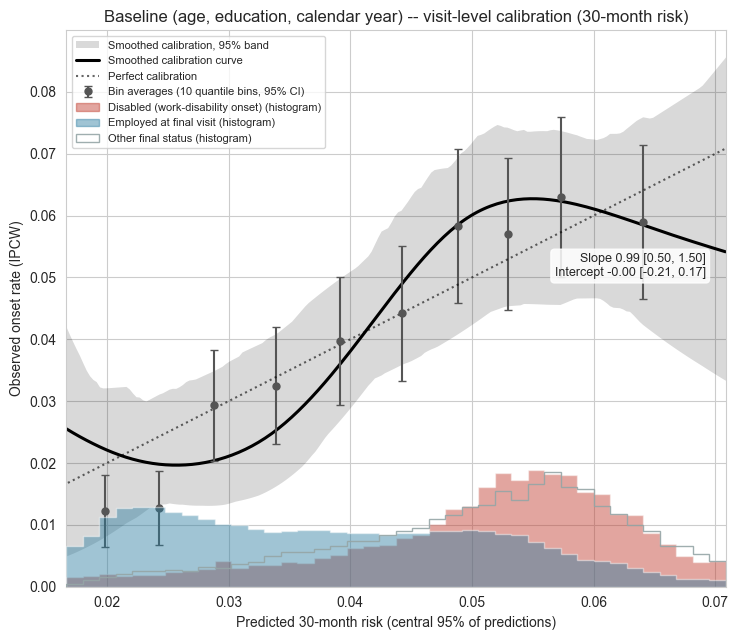

Baseline (age, education, calendar year) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 76.8, FN 71.2, TN 426.0, FP 483.0; flagged event patients: the earliest alarm came a median 44.2 months before onset (94% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
---------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.817 [0.764, 0.865]","0.326 [0.267, 0.381]","0.620 [0.594, 0.644]"
40-49,33,200,"0.879 [0.836, 0.919]","0.570 [0.471, 0.670]","0.450 [0.406, 0.490]"
50-59,45,190,"0.841 [0.789, 0.890]","0.733 [0.643, 0.807]","0.320 [0.285, 0.363]"
>= 60,8,115,"0.756 [0.612, 0.881]","0.600 [0.400, 0.800]","0.214 [0.177, 0.252]"


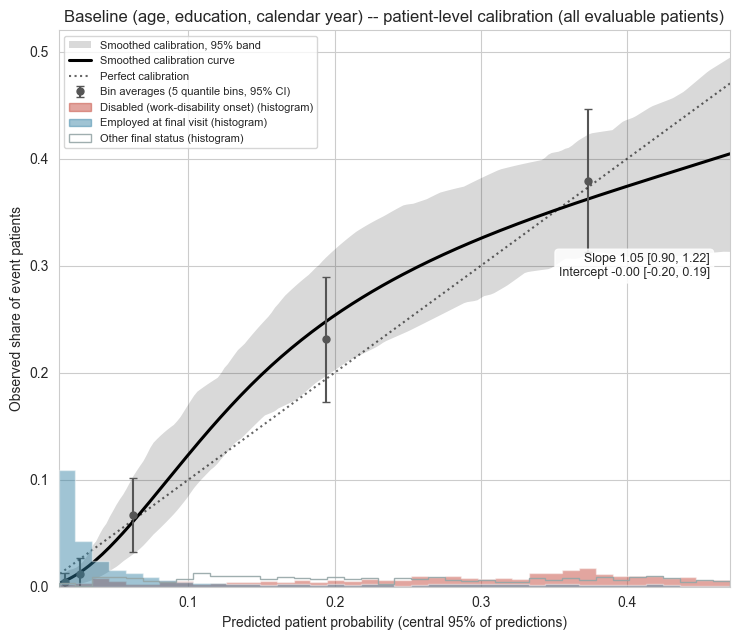


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
Baseline,5,23.203 (0.005),0.002 (0.002),0.000 (0.000),0.562 (0.005),0.629 (0.005),0.634 (0.004),0.056 (0.001),49.467 (9.507),1.071 (0.206),0.475 (0.095),1.036 (0.188)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Baseline,5,0.003 (0.005),0.027 (0.028),0.076 (0.027),0.134 (0.031),0.280 (0.067),0.992 (0.007),0.973 (0.010),0.940 (0.010),0.898 (0.016),0.763 (0.035)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Baseline,5,0.000 (0.000),0.000 (0.000),0.005 (0.008),0.128 (0.125),0.922 (0.074),1.000 (0.000),1.000 (0.000),0.989 (0.010),0.888 (0.105),0.077 (0.077),0.000 (0.000),0.000 (0.000),1.339 (1.294),11.793 (10.576),92.488 (7.628)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Baseline,5,0.596 (0.002),0.610 (0.004),0.614 (0.004),0.613 (0.003),0.617 (0.004),0.623 (0.004),0.625 (0.004),0.621 (0.004)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {}


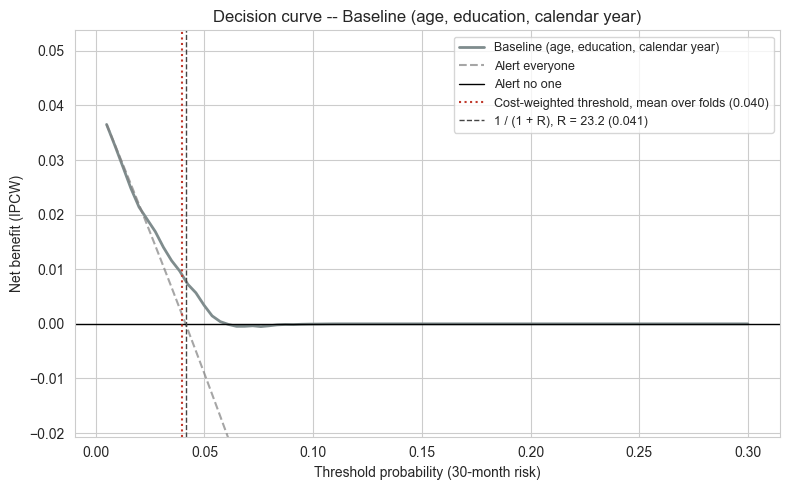

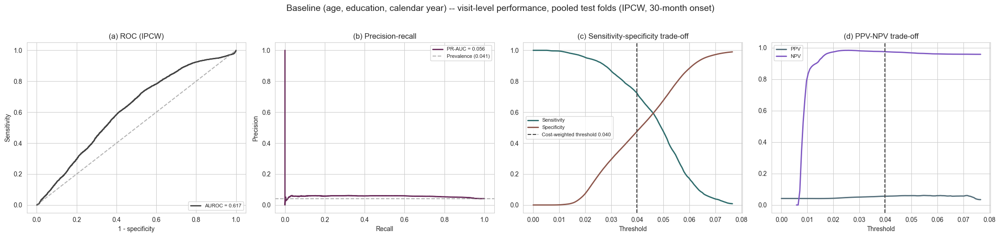

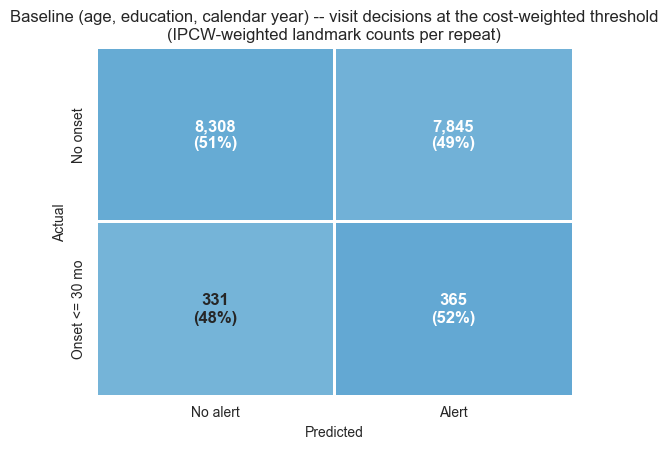

In [51]:
"""Baseline (Section 6.2): linear cause-specific discrete-time hazard on age, education and the calendar-year terms
(BASELINE_COLS), identical folds, same checkpoint (resumable). H1a's reference."""
CV_MODELS.append("Baseline")                     # report_cv_model's tables list the models of CV_MODELS
try:
    res_baseline = report_cv_model("Baseline", "Baseline (age, education, calendar year)")
finally:
    CV_MODELS.remove("Baseline")                 # not a candidate model: no stack, overview or sensitivity refit

## 11.11.2 Random survival forest

Resuming from cv_state_model_revised_v21.pkl: 160 model-fold fits already done.
[RSF        ] repeat 1/5 fold 1/5 | AUROC 0.709 NB(R=23.9) 0.0121 | visit sens/spec 0.64/0.57 | patient sens/spec 0.86/0.54 (TN/FP 98/84) | cfg None | 17 feats | 8s
[RSF        ] repeat 1/5 fold 2/5 | AUROC 0.773 NB(R=22.9) 0.0093 | visit sens/spec 0.51/0.74 | patient sens/spec 0.73/0.65 (TN/FP 117/64) | cfg None | 17 feats | 8s
[RSF        ] repeat 1/5 fold 3/5 | AUROC 0.701 NB(R=23.6) 0.0112 | visit sens/spec 0.66/0.56 | patient sens/spec 0.87/0.41 (TN/FP 74/108) | cfg None | 17 feats | 9s
[RSF        ] repeat 1/5 fold 4/5 | AUROC 0.687 NB(R=23.3) 0.0107 | visit sens/spec 0.64/0.59 | patient sens/spec 0.87/0.40 (TN/FP 72/110) | cfg None | 17 feats | 7s
[RSF        ] repeat 1/5 fold 5/5 | AUROC 0.699 NB(R=22.4) 0.0056 | visit sens/spec 0.73/0.53 | patient sens/spec 0.90/0.44 (TN/FP 80/102) | cfg None | 17 feats | 5s
[RSF        ] repeat 2/5 fold 1/5 | AUROC 0.734 NB(R=22.8) 0.0067 | visit sens/spec 0.60/0.

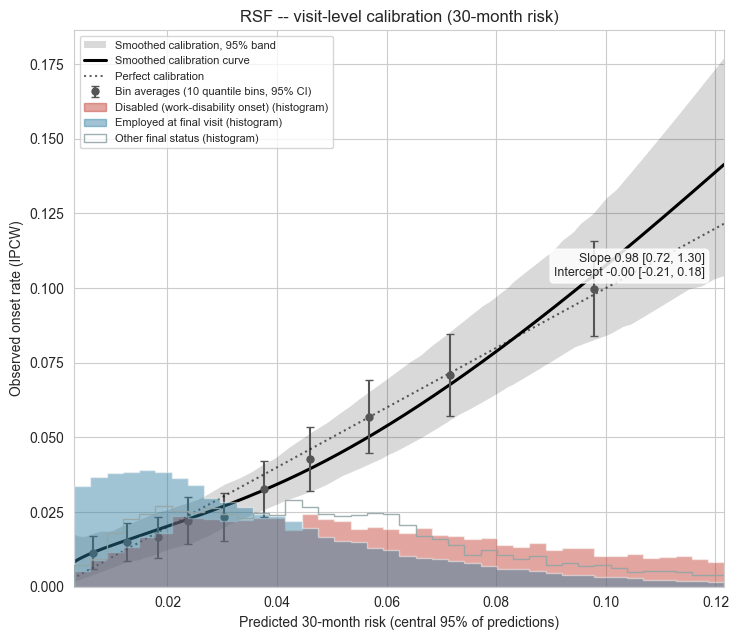

RSF -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 134.0, FN 14.0, TN 414.0, FP 495.0; flagged event patients: the earliest alarm came a median 29.9 months before onset (56% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Co

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.916 [0.882, 0.944]","0.877 [0.800, 0.945]","0.600 [0.557, 0.641]"
40-49,33,200,"0.942 [0.902, 0.971]","0.927 [0.862, 0.988]","0.472 [0.416, 0.534]"
50-59,45,190,"0.856 [0.795, 0.910]","0.916 [0.849, 0.969]","0.289 [0.235, 0.350]"
>= 60,8,115,"0.801 [0.549, 0.994]","0.975 [0.917, 1.000]","0.188 [0.125, 0.250]"


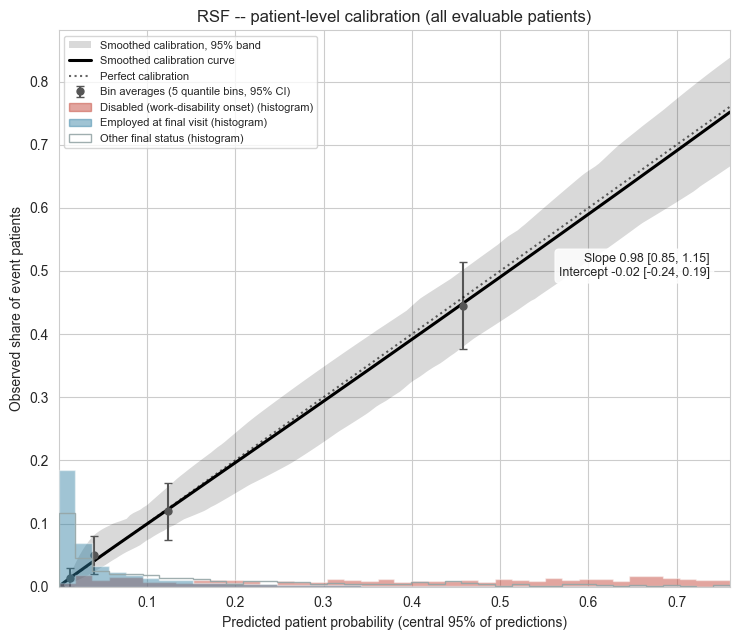


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
RSF,5,23.203 (0.005),0.011 (0.001),0.000 (0.000),0.606 (0.005),0.772 (0.005),0.719 (0.005),0.106 (0.004),46.868 (2.800),1.015 (0.061),0.161 (0.012),0.951 (0.056)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
RSF,5,0.121 (0.013),0.213 (0.012),0.302 (0.013),0.385 (0.015),0.517 (0.018),0.958 (0.003),0.914 (0.004),0.871 (0.006),0.825 (0.009),0.728 (0.009)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
RSF,5,0.004 (0.004),0.095 (0.031),0.415 (0.045),0.650 (0.058),0.787 (0.023),0.998 (0.001),0.964 (0.010),0.791 (0.030),0.607 (0.032),0.482 (0.027),0.256 (0.094),4.458 (1.047),23.379 (3.017),42.092 (3.300),54.531 (2.514)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
RSF,5,0.726 (0.003),0.730 (0.003),0.719 (0.004),0.716 (0.005),0.716 (0.005),0.717 (0.005),0.713 (0.004),0.708 (0.004)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {}


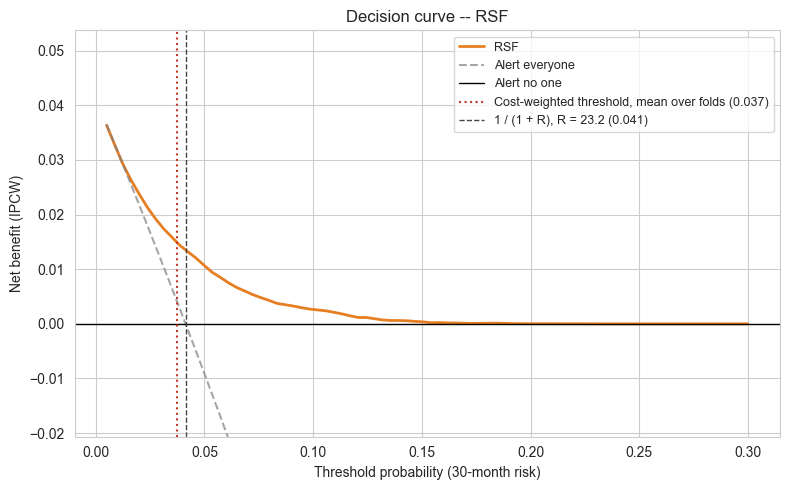

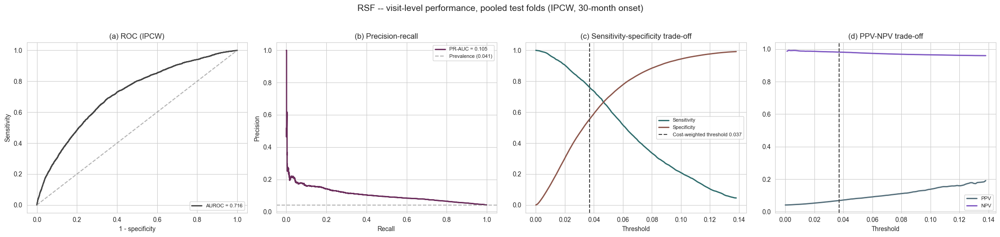

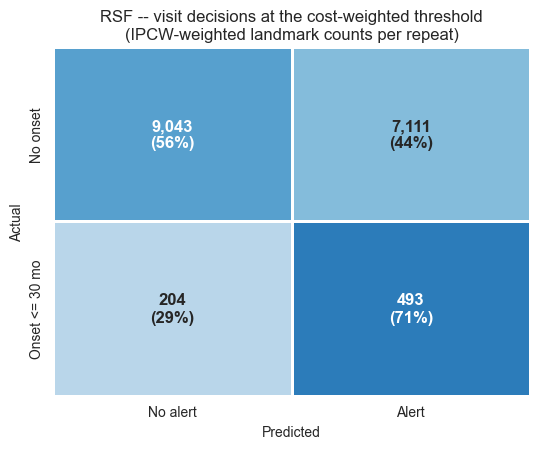

RSF: final refit on all rows (config None, 17 features) in 3s


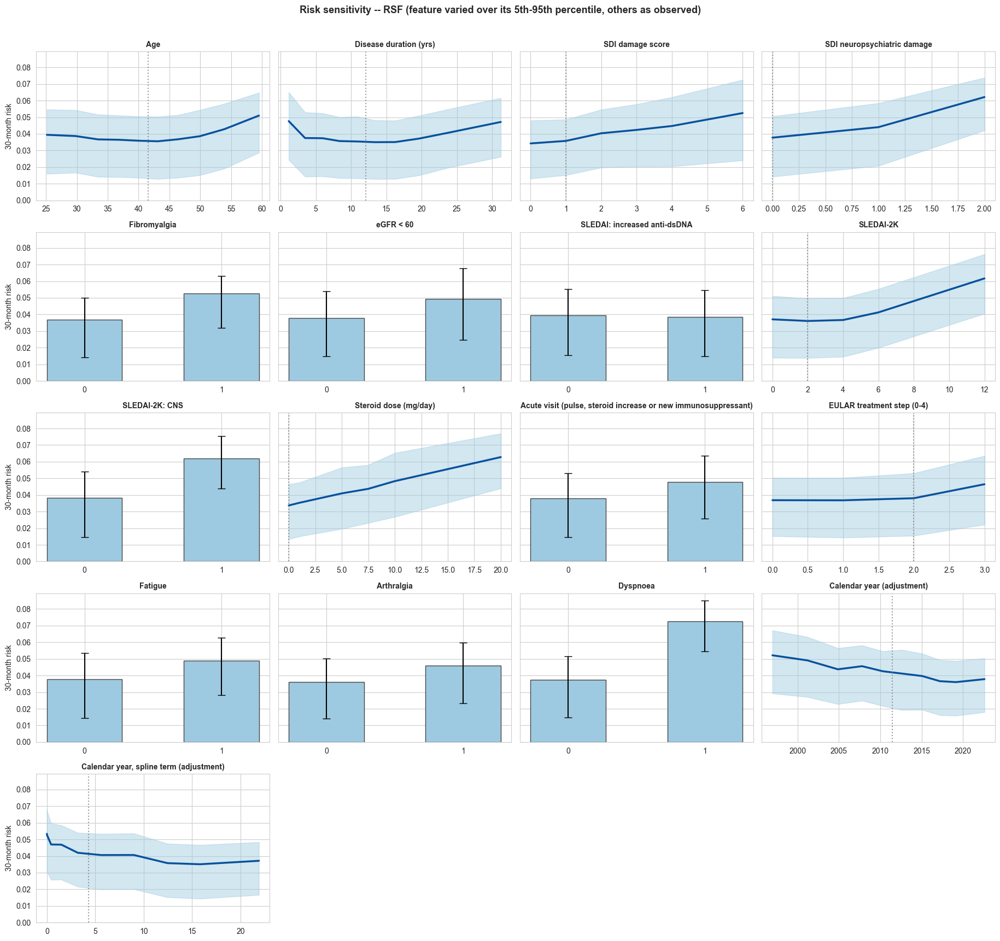


Risk-sensitivity summary -- RSF (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0376       0.0727                0.0352
                                         Steroid dose (mg/day)      0.0337       0.0628                0.0291
                                                     SLEDAI-2K      0.0370       0.0617                0.0256
                                   SDI neuropsychiatric damage      0.0377       0.0621                0.0244
                                                SLEDAI-2K: CNS      0.0382       0.0620                0.0238
                       Calendar year, spline term (adjustment)      0.0534       0.0372                0.0183
                                              SDI damage score      0.0342       0.0525                0.0183
                                    Calendar year

In [52]:
"""random survival forest on the cause-specific (other exits and deaths censored), 48-month-capped
target (monthly time bins, patient-weighted subsampling). One fixed configuration."""
res_rsf = run_analysis("RSF", "RSF")

## 11.11.3 Cause-specific Cox proportional hazards

Resuming from cv_state_model_revised_v21.pkl: 185 model-fold fits already done.


Python(25341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25361) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25362) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CoxPH      ] repeat 1/5 fold 1/5 | AUROC 0.726 NB(R=23.9) 0.0178 | visit sens/spec 0.81/0.53 | patient sens/spec 0.90/0.54 (TN/FP 98/84) | cfg 0.1 | 17 feats | 40s


Python(25388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25397) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25398) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25400) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25401) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25402) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CoxPH      ] repeat 1/5 fold 2/5 | AUROC 0.728 NB(R=22.9) 0.0078 | visit sens/spec 0.47/0.75 | patient sens/spec 0.80/0.76 (TN/FP 138/43) | cfg 1.0 | 17 feats | 39s


...

[CoxPH      ] repeat 5/5 fold 3/5 | AUROC 0.814 NB(R=23.5) 0.0210 | visit sens/spec 0.90/0.56 | patient sens/spec 0.93/0.65 (TN/FP 118/64) | cfg 1.0 | 17 feats | 23s


Python(26678) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26679) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26684) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26685) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26686) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26687) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26688) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CoxPH      ] repeat 5/5 fold 4/5 | AUROC 0.696 NB(R=23.7) 0.0102 | visit sens/spec 0.55/0.65 | patient sens/spec 0.90/0.66 (TN/FP 120/62) | cfg 1.0 | 17 feats | 18s


Python(26702) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26703) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26710) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26712) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26713) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26714) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CoxPH      ] repeat 5/5 fold 5/5 | AUROC 0.729 NB(R=22.5) 0.0090 | visit sens/spec 0.68/0.63 | patient sens/spec 0.90/0.63 (TN/FP 115/67) | cfg 1.0 | 17 feats | 18s
CV for ['CoxPH']: 13.1 min this call; 210 model-fold fits in cv_state_model_revised_v21.pkl.
CoxPH (cause-specific) -- VISIT LEVEL (30-month work-disability onset)
  16,851 landmark visits of 1,059 patients; resolved at 30 months: 14,384 (642 with an onset within 30 months); IPCW-weighted
  alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal cost-weighted net benefit; a missed onset costs R false alarms, R = (1 - onset rate) / onset rate of the training fold, mean 23.2); mean threshold 0.035
  mean over 5 CV repeat(s) of the pooled test folds; 95% CI: 1000 patient-cluster bootstrap resamples
  alert burden: Alerts / 100 landmark visits 41.3 (2.3); Alerts / patient-year 0.89 (0.05); Stayed employed: patients 704; Stayed employed: follow-up, median yrs 5.9; Stayed employed: never al

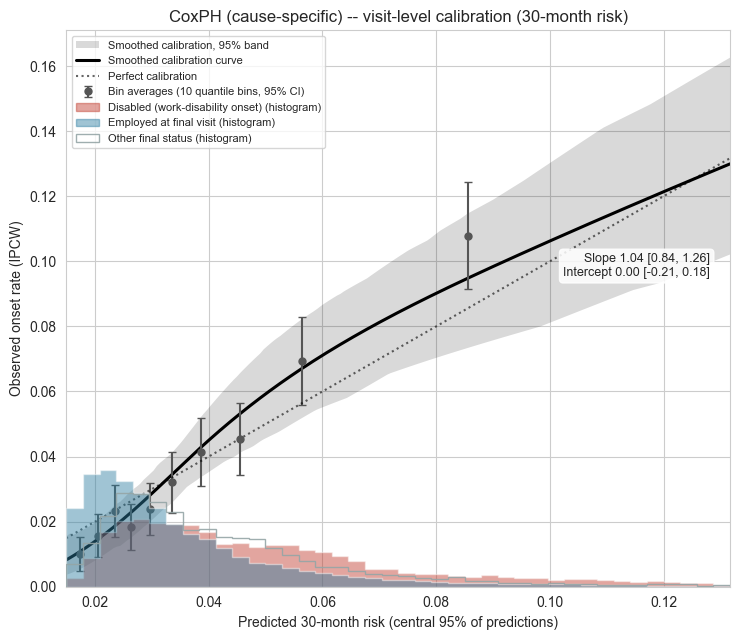

CoxPH (cause-specific) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 131.4, FN 16.6, TN 568.4, FP 340.6; flagged event patients: the earliest alarm came a median 29.2 months before onset (51% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
--------------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.932 [0.900, 0.959]","0.881 [0.790, 0.952]","0.664 [0.623, 0.704]"
40-49,33,200,"0.950 [0.919, 0.975]","0.927 [0.830, 1.000]","0.557 [0.495, 0.616]"
50-59,45,190,"0.881 [0.831, 0.929]","0.862 [0.761, 0.953]","0.584 [0.528, 0.650]"
>= 60,8,115,"0.909 [0.795, 0.991]","0.925 [0.750, 1.000]","0.673 [0.595, 0.747]"


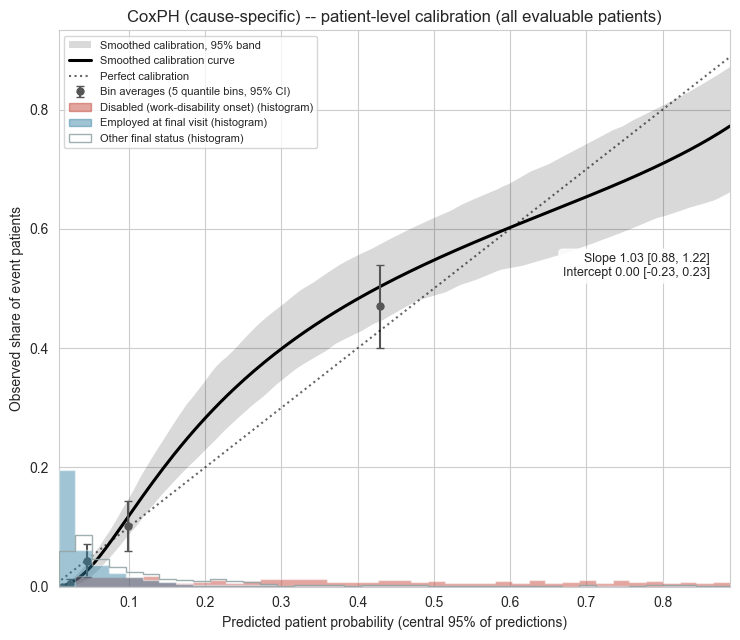


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
CoxPH,5,23.203 (0.005),0.011 (0.001),0.000 (0.000),0.595 (0.003),0.774 (0.003),0.719 (0.003),0.108 (0.003),41.289 (2.345),0.894 (0.051),0.242 (0.013),0.850 (0.052)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
CoxPH,5,0.163 (0.003),0.256 (0.013),0.350 (0.010),0.421 (0.011),0.547 (0.012),0.955 (0.001),0.909 (0.003),0.862 (0.001),0.813 (0.003),0.713 (0.004)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
CoxPH,5,0.032 (0.014),0.158 (0.022),0.340 (0.029),0.602 (0.018),0.764 (0.044),0.993 (0.001),0.952 (0.011),0.856 (0.016),0.670 (0.005),0.485 (0.039),0.756 (0.138),5.219 (1.137),15.244 (1.620),34.464 (0.644),53.212 (4.035)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
CoxPH,5,0.720 (0.012),0.722 (0.005),0.714 (0.005),0.711 (0.002),0.713 (0.003),0.713 (0.003),0.709 (0.003),0.705 (0.003)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {1.0: 14, 0.1: 8, 10.0: 3}


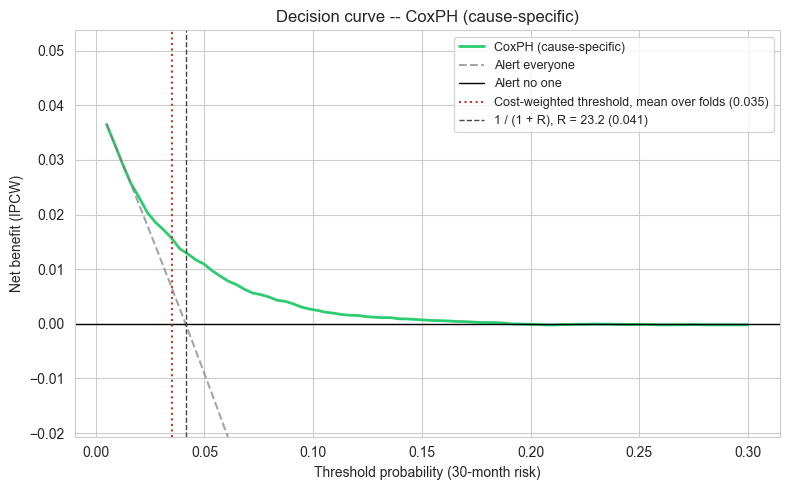

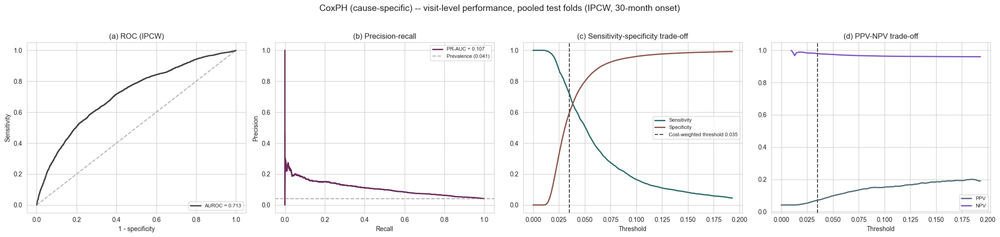

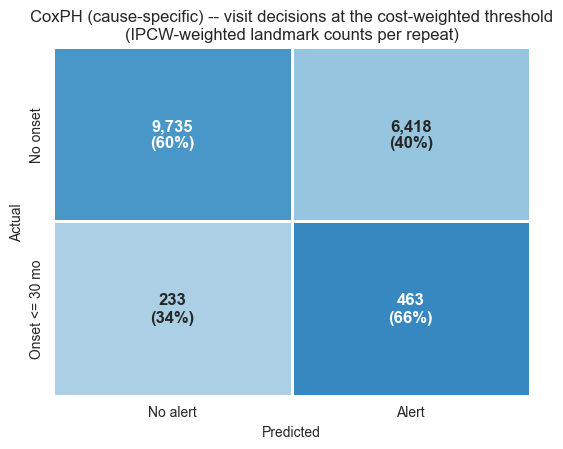

CoxPH: final refit on all rows (config 1.0, 17 features) in 59s


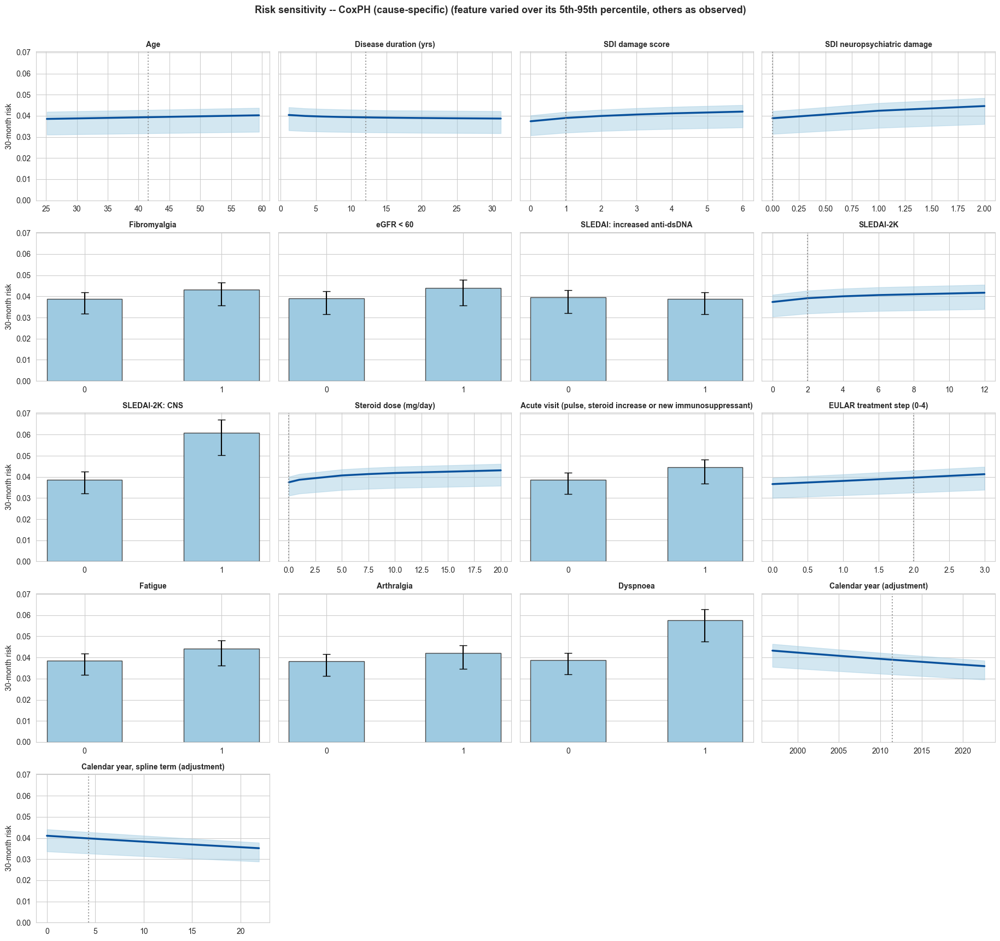


Risk-sensitivity summary -- CoxPH (cause-specific) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                SLEDAI-2K: CNS      0.0387       0.0609                0.0222
                                                      Dyspnoea      0.0387       0.0576                0.0189
                                    Calendar year (adjustment)      0.0432       0.0359                0.0073
Acute visit (pulse, steroid increase or new immunosuppressant)      0.0387       0.0446                0.0059
                       Calendar year, spline term (adjustment)      0.0411       0.0352                0.0059
                                   SDI neuropsychiatric damage      0.0389       0.0446                0.0058
                                         Steroid dose (mg/day)      0.0375       0.0431                0.0057
                              

,coef,exp(coef),se (pooled),p
"Calendar year, spline term (adjustment)",-0.044,0.957,0.006,0.000
Calendar year (adjustment),-0.049,0.952,0.008,0.000
Steroid dose (mg/day),0.047,1.048,0.008,0.000
Arthralgia,0.037,1.037,0.007,0.000
"Acute visit (pulse, steroid increase or new immunosuppressant)",0.038,1.039,0.008,0.000
EULAR treatment step (0-4),0.036,1.036,0.008,0.000
SDI damage score,0.034,1.034,0.008,0.000
SLEDAI-2K,0.032,1.032,0.008,0.000
Dyspnoea,0.066,1.069,0.016,0.000
Fatigue,0.034,1.035,0.009,0.000


In [53]:
"""cause-specific Cox proportional hazards (other exits and deaths censored), follow-up capped at 48 months;
ridge penalizer tuned inside each training fold."""
res_cox = run_analysis("CoxPH", "CoxPH (cause-specific)")
if res_cox is not None:
    print("\nCox hazard ratios, final refit on all rows, pooled over the imputations with Rubin's rules "
          "(standardised features; for description only):")
    display(pooled_cox_summary(res_cox["final"]["fitted"])
            .rename(index=lambda c: DISPLAY_NAMES.get(c, c)).sort_values("p").round(3))

## 11.11.4 GRU

Resuming from cv_state_model_revised_v21.pkl: 210 model-fold fits already done.
[GRU        ] repeat 1/5 fold 1/5 | AUROC 0.741 NB(R=23.9) 0.0158 | visit sens/spec 0.51/0.81 | patient sens/spec 0.76/0.87 (TN/FP 158/24) | cfg h32_pretrain | 17 feats | 66s
[GRU        ] repeat 1/5 fold 2/5 | AUROC 0.710 NB(R=22.9) 0.0078 | visit sens/spec 0.57/0.65 | patient sens/spec 0.87/0.68 (TN/FP 123/58) | cfg h32_pretrain | 17 feats | 65s
[GRU        ] repeat 1/5 fold 3/5 | AUROC 0.701 NB(R=23.6) 0.0171 | visit sens/spec 0.69/0.68 | patient sens/spec 0.90/0.77 (TN/FP 140/42) | cfg h32_pretrain | 17 feats | 69s
[GRU        ] repeat 1/5 fold 4/5 | AUROC 0.720 NB(R=23.3) 0.0163 | visit sens/spec 0.61/0.76 | patient sens/spec 0.77/0.80 (TN/FP 145/37) | cfg h32_pretrain | 17 feats | 70s
[GRU        ] repeat 1/5 fold 5/5 | AUROC 0.718 NB(R=22.4) 0.0102 | visit sens/spec 0.58/0.76 | patient sens/spec 0.72/0.81 (TN/FP 147/35) | cfg h32_pretrain | 17 feats | 61s
[GRU        ] repeat 2/5 fold 1/5 | AUROC 0.7

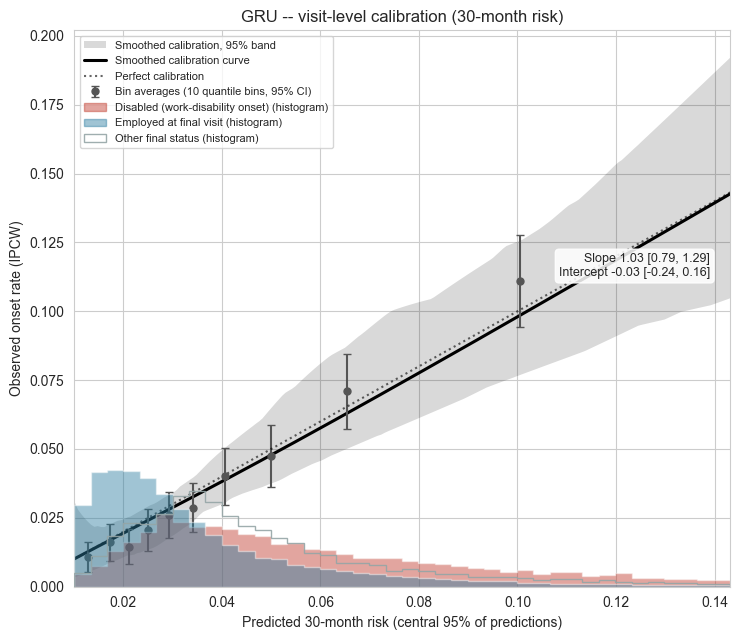

GRU -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 120.2, FN 27.8, TN 689.8, FP 219.2; flagged event patients: the earliest alarm came a median 28.0 months before onset (65% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------------------------------------------------------------
Co

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.921 [0.886, 0.951]","0.829 [0.746, 0.915]","0.797 [0.760, 0.829]"
40-49,33,200,"0.920 [0.881, 0.953]","0.861 [0.752, 0.957]","0.722 [0.672, 0.769]"
50-59,45,190,"0.877 [0.827, 0.922]","0.773 [0.663, 0.877]","0.731 [0.680, 0.779]"
>= 60,8,115,"0.826 [0.646, 0.973]","0.700 [0.400, 0.960]","0.737 [0.670, 0.797]"


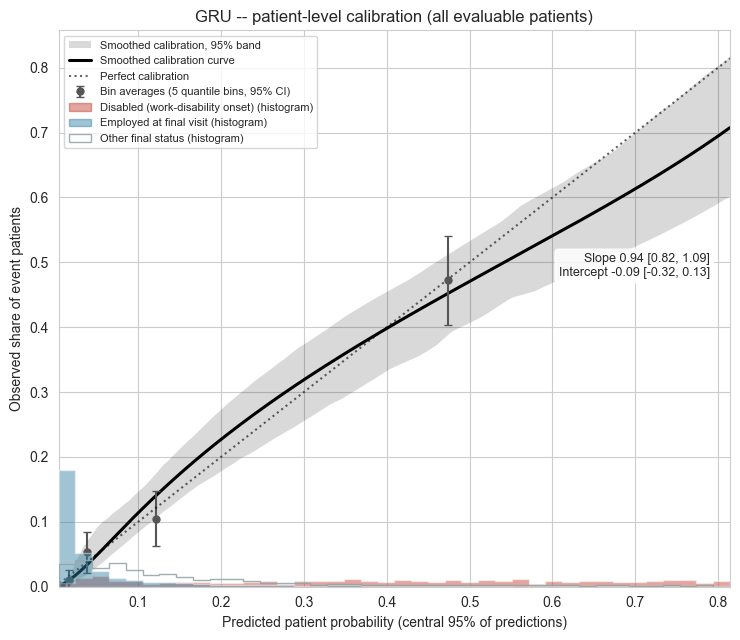


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
GRU,5,23.203 (0.005),0.013 (0.001),0.000 (0.000),0.593 (0.005),0.772 (0.003),0.723 (0.005),0.107 (0.004),31.592 (5.770),0.684 (0.125),0.318 (0.049),0.613 (0.127)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
GRU,5,0.191 (0.028),0.321 (0.034),0.423 (0.026),0.509 (0.047),0.613 (0.054),0.941 (0.010),0.890 (0.011),0.841 (0.011),0.795 (0.016),0.719 (0.034)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
GRU,5,0.023 (0.024),0.201 (0.032),0.455 (0.047),0.547 (0.055),0.747 (0.073),0.997 (0.004),0.926 (0.017),0.821 (0.017),0.760 (0.025),0.538 (0.105),0.392 (0.417),7.756 (1.732),18.672 (1.802),24.796 (2.662),46.931 (10.693)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
GRU,5,0.721 (0.005),0.728 (0.005),0.718 (0.005),0.714 (0.005),0.716 (0.005),0.716 (0.006),0.713 (0.006),0.709 (0.006)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'h32_pretrain': 25}
Early stopping, outer-fold fits: median 16 epochs (range 11-31)


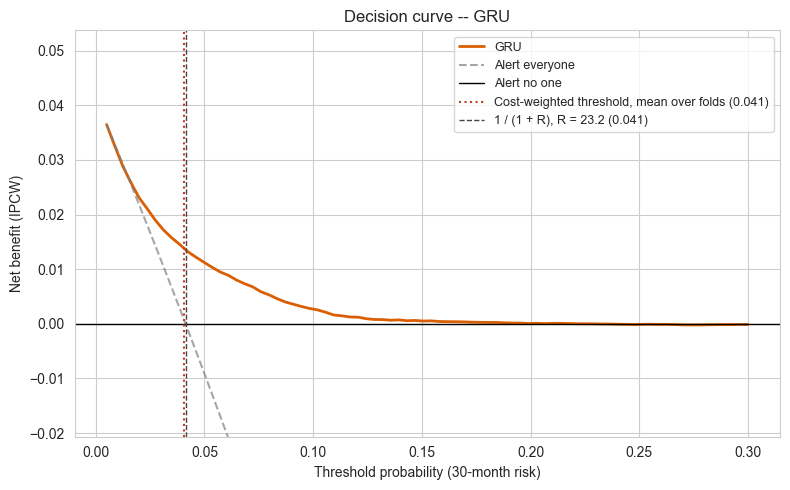

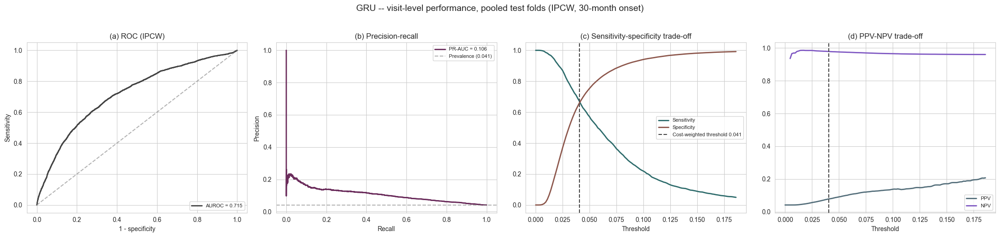

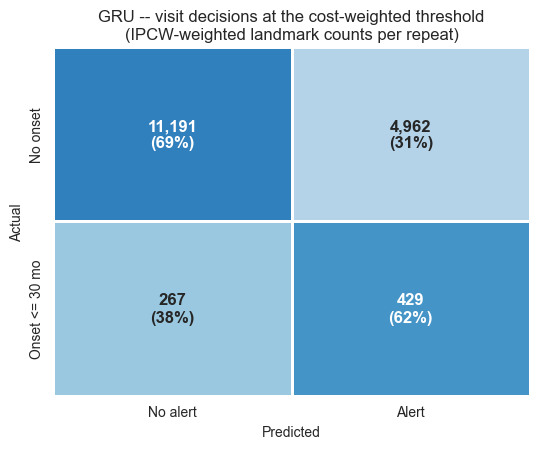

GRU: final refit on all rows (config h32_pretrain, 17 features) in 80s


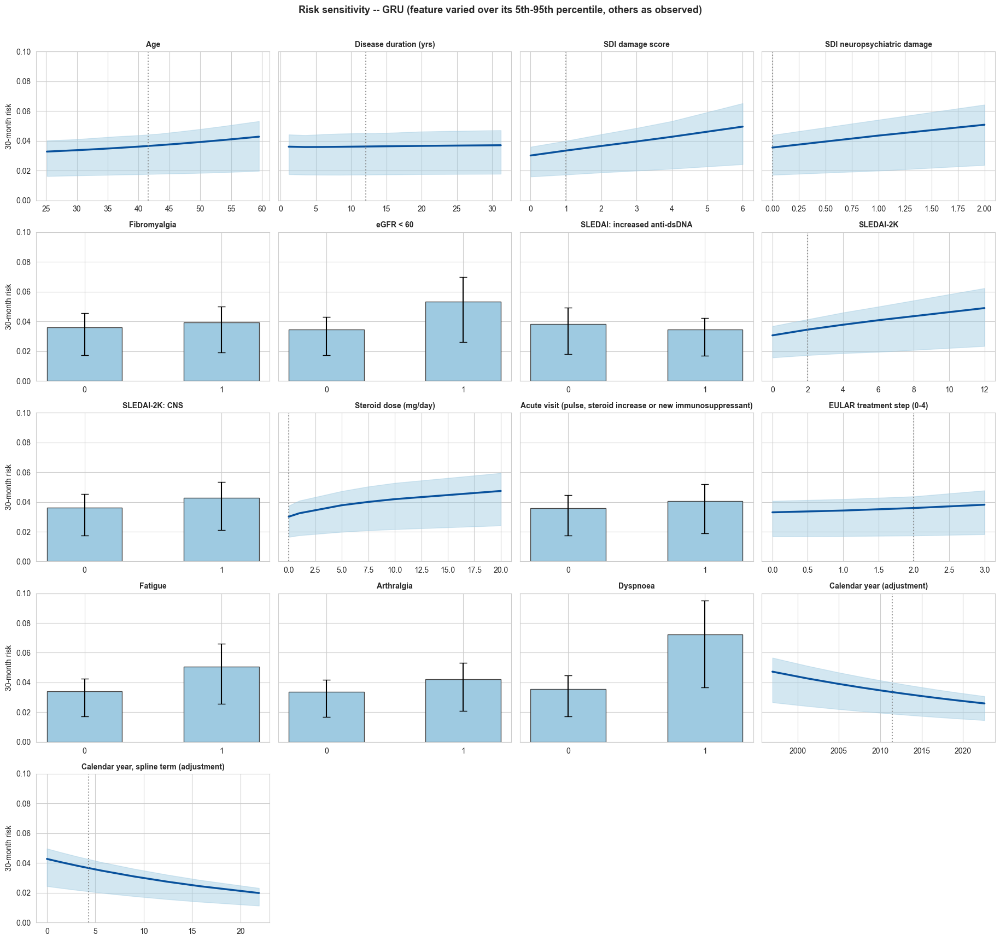


Risk-sensitivity summary -- GRU (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0356       0.0723                0.0368
                       Calendar year, spline term (adjustment)      0.0428       0.0198                0.0229
                                    Calendar year (adjustment)      0.0473       0.0259                0.0214
                                              SDI damage score      0.0302       0.0496                0.0194
                                                     eGFR < 60      0.0346       0.0531                0.0185
                                                     SLEDAI-2K      0.0306       0.0489                0.0183
                                         Steroid dose (mg/day)      0.0301       0.0474                0.0173
                                                 

In [54]:
"""GRU (the main model's recipe -- inputs, pretraining, hazard heads (+ calendar year), early stopping, 5 seeds --
with a GRU cell, over the whole history)."""
res_gru = run_analysis("GRU", "GRU")

## 11.11.5 Causal Transformer

Resuming from cv_state_model_revised_v21.pkl: 235 model-fold fits already done.
[Transformer] repeat 1/5 fold 1/5 | AUROC 0.689 NB(R=23.9) 0.0098 | visit sens/spec 0.34/0.86 | patient sens/spec 0.66/0.92 (TN/FP 167/15) | cfg d32_pretrain | 17 feats | 114s
[Transformer] repeat 1/5 fold 2/5 | AUROC 0.716 NB(R=22.9) 0.0084 | visit sens/spec 0.53/0.71 | patient sens/spec 0.67/0.75 (TN/FP 135/46) | cfg d32_pretrain | 17 feats | 135s
[Transformer] repeat 1/5 fold 3/5 | AUROC 0.700 NB(R=23.6) 0.0146 | visit sens/spec 0.70/0.61 | patient sens/spec 0.87/0.69 (TN/FP 125/57) | cfg d32_pretrain | 17 feats | 123s
[Transformer] repeat 1/5 fold 4/5 | AUROC 0.709 NB(R=23.3) 0.0132 | visit sens/spec 0.48/0.82 | patient sens/spec 0.60/0.83 (TN/FP 151/31) | cfg d32_pretrain | 17 feats | 122s
[Transformer] repeat 1/5 fold 5/5 | AUROC 0.701 NB(R=22.4) 0.0090 | visit sens/spec 0.53/0.78 | patient sens/spec 0.76/0.79 (TN/FP 144/38) | cfg d32_pretrain | 17 feats | 106s
[Transformer] repeat 2/5 fold 1/5 | AURO

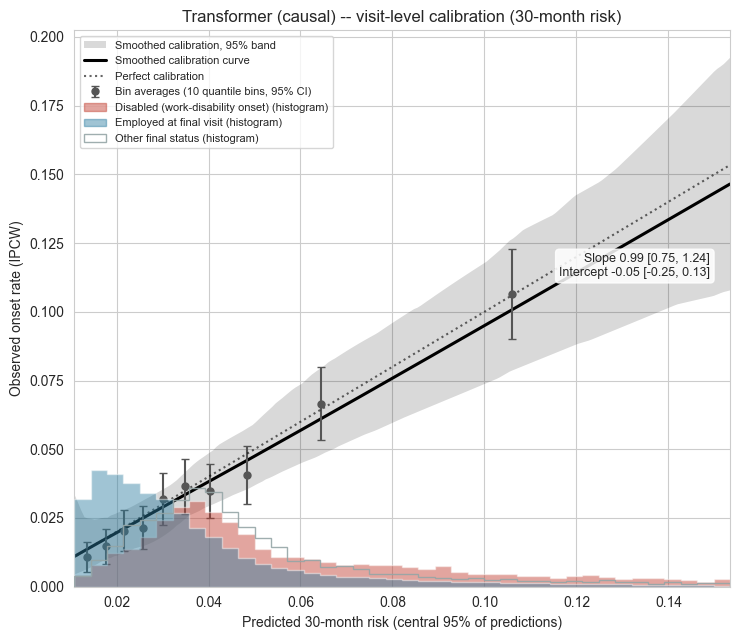

Transformer (causal) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 113.4, FN 34.6, TN 706.0, FP 203.0; flagged event patients: the earliest alarm came a median 27.5 months before onset (60% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
----------------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.916 [0.878, 0.949]","0.800 [0.702, 0.885]","0.797 [0.761, 0.829]"
40-49,33,200,"0.923 [0.886, 0.955]","0.800 [0.684, 0.909]","0.760 [0.711, 0.808]"
50-59,45,190,"0.883 [0.835, 0.927]","0.707 [0.590, 0.819]","0.744 [0.695, 0.795]"
>= 60,8,115,"0.835 [0.682, 0.967]","0.700 [0.467, 0.920]","0.788 [0.728, 0.844]"


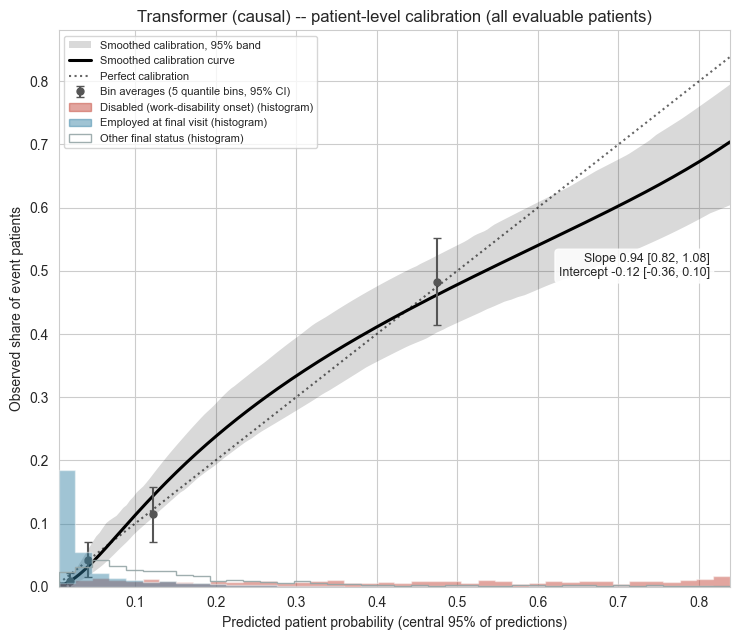


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
Transformer,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.587 (0.007),0.764 (0.002),0.711 (0.003),0.106 (0.004),28.506 (2.207),0.617 (0.048),0.417 (0.028),0.552 (0.050)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Transformer,5,0.209 (0.033),0.325 (0.027),0.414 (0.030),0.491 (0.024),0.594 (0.031),0.937 (0.011),0.886 (0.009),0.838 (0.006),0.793 (0.010),0.719 (0.026)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Transformer,5,0.043 (0.048),0.233 (0.031),0.417 (0.060),0.555 (0.049),0.710 (0.033),0.990 (0.012),0.924 (0.015),0.824 (0.033),0.742 (0.026),0.561 (0.044),1.058 (1.264),8.041 (1.474),18.427 (3.723),26.709 (2.908),44.807 (5.136)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Transformer,5,0.714 (0.003),0.716 (0.001),0.705 (0.002),0.700 (0.002),0.702 (0.003),0.703 (0.004),0.699 (0.004),0.692 (0.005)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'d32_pretrain': 25}
Early stopping, outer-fold fits: median 19 epochs (range 13-49)


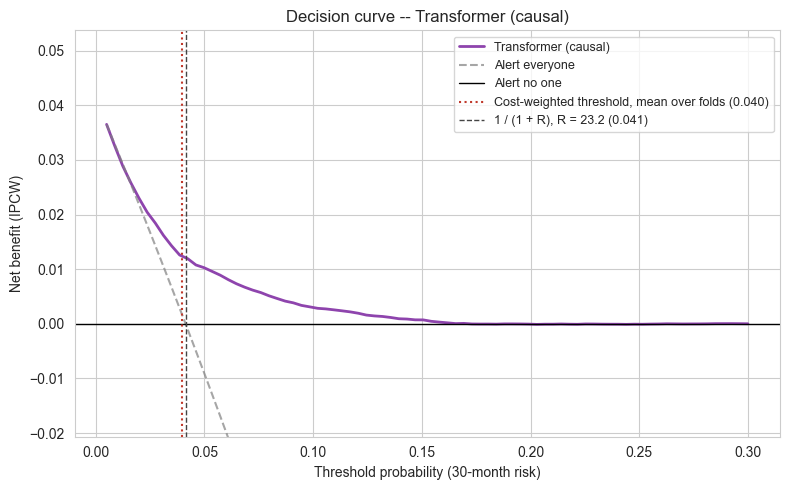

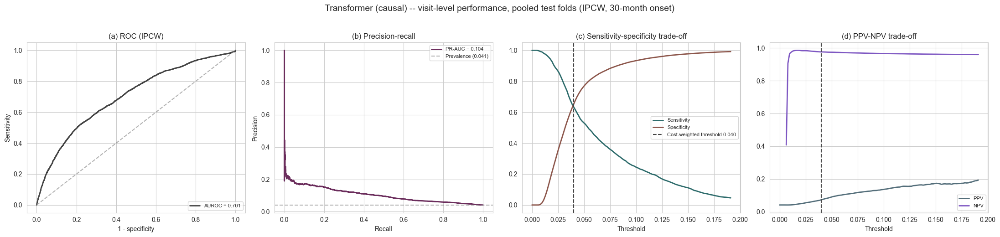

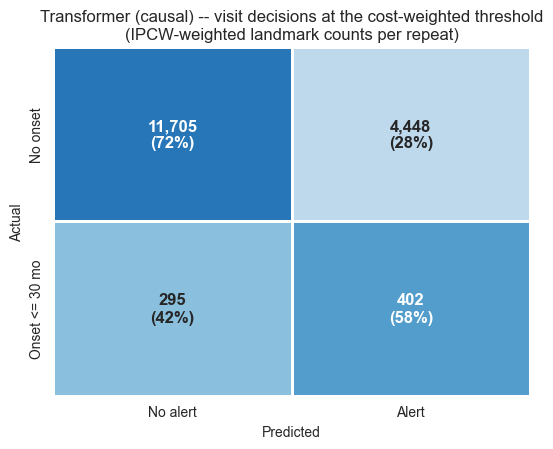

Transformer: final refit on all rows (config d32_pretrain, 17 features) in 84s


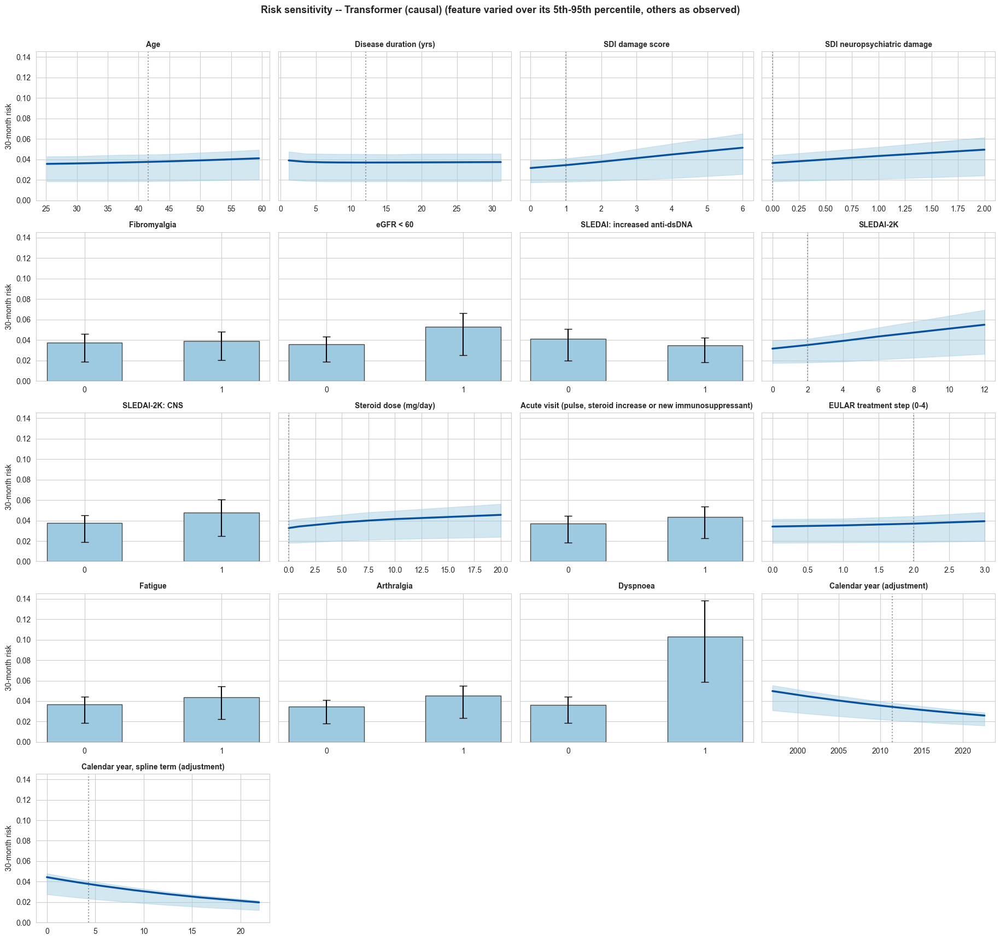


Risk-sensitivity summary -- Transformer (causal) (mean 30-month risk; ranked by swing)
                                                       Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                                      Dyspnoea      0.0364       0.1032                0.0669
                       Calendar year, spline term (adjustment)      0.0444       0.0197                0.0246
                                    Calendar year (adjustment)      0.0498       0.0259                0.0239
                                                     SLEDAI-2K      0.0316       0.0549                0.0234
                                              SDI damage score      0.0316       0.0515                0.0198
                                                     eGFR < 60      0.0358       0.0527                0.0169
                                   SDI neuropsychiatric damage      0.0365       0.0496                0.0131
                                

In [55]:
"""causal Transformer (the main model's recipe with a 1-layer causal Transformer encoder over the whole history; elapsed time
since the first visit as an extra input)."""
res_transformer = run_analysis("Transformer", "Transformer (causal)")

## 11.11.6 Stacking ensemble

The six members' cross-fitted 30-month logits combined by a non-negative IPCW logistic meta-learner in every training
fold (Section 6.3); then the meta-weights, and the supplementary stacks (Chen et al.'s MLP meta-learner; the tabular
members only) on the same folds.

Resuming from cv_state_model_revised_v21.pkl: 260 model-fold fits already done.
[Stack      ] repeat 1/5 fold 1/5 | AUROC 0.718 NB(R=23.9) 0.0141 | visit sens/spec 0.70/0.56 | patient sens/spec 0.90/0.56 (TN/FP 102/80) | cfg stack (logistic meta-learner) | 17 feats | 1s
[Stack      ] repeat 1/5 fold 2/5 | AUROC 0.745 NB(R=22.9) 0.0125 | visit sens/spec 0.73/0.62 | patient sens/spec 0.90/0.62 (TN/FP 113/68) | cfg stack (logistic meta-learner) | 17 feats | 1s
[Stack      ] repeat 1/5 fold 3/5 | AUROC 0.711 NB(R=23.6) 0.0132 | visit sens/spec 0.61/0.67 | patient sens/spec 0.90/0.57 (TN/FP 104/78) | cfg stack (logistic meta-learner) | 17 feats | 1s
[Stack      ] repeat 1/5 fold 4/5 | AUROC 0.719 NB(R=23.3) 0.0136 | visit sens/spec 0.71/0.60 | patient sens/spec 0.80/0.62 (TN/FP 112/70) | cfg stack (logistic meta-learner) | 17 feats | 1s
[Stack      ] repeat 1/5 fold 5/5 | AUROC 0.699 NB(R=22.4) 0.0046 | visit sens/spec 0.73/0.50 | patient sens/spec 0.93/0.47 (TN/FP 86/96) | cfg stack (logis

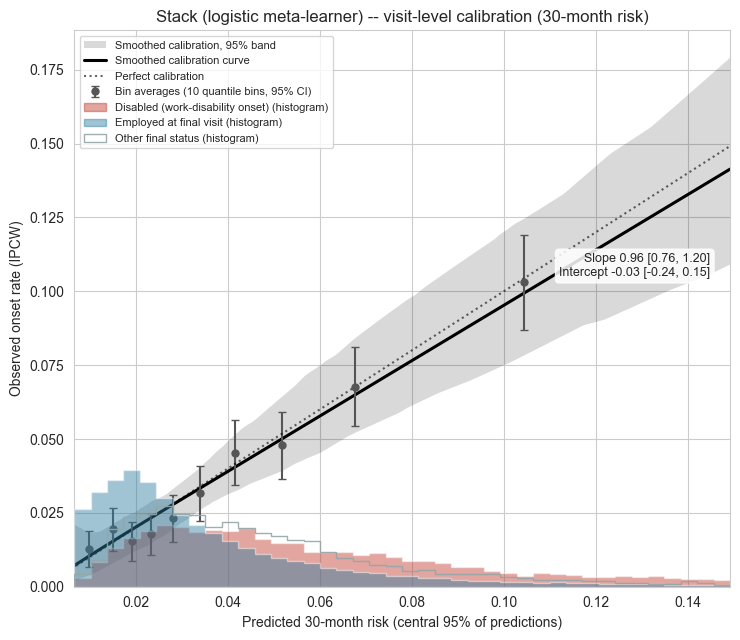

Stack (logistic meta-learner) -- PATIENT LEVEL, all evaluable patients
  148 event patients (TP / FN: any alarm in the 60 months before onset) vs 909 event-free patients (FP / TN: the alarm at their last landmark): Employed at final visit 765, Other final status 116, Retired / homemaker >= 60 28
  mean counts per repeat: TP 132.6, FN 15.4, TN 518.8, FP 390.2; flagged event patients: the earliest alarm came a median 29.9 months before onset (58% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark (event-free patients: their last landmark) of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-------------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,62,403,"0.928 [0.897, 0.957]","0.890 [0.820, 0.953]","0.667 [0.624, 0.708]"
40-49,33,200,"0.944 [0.909, 0.970]","0.921 [0.840, 0.983]","0.563 [0.499, 0.623]"
50-59,45,190,"0.879 [0.829, 0.926]","0.876 [0.773, 0.960]","0.471 [0.409, 0.537]"
>= 60,8,115,"0.850 [0.662, 0.988]","0.950 [0.833, 1.000]","0.409 [0.334, 0.483]"


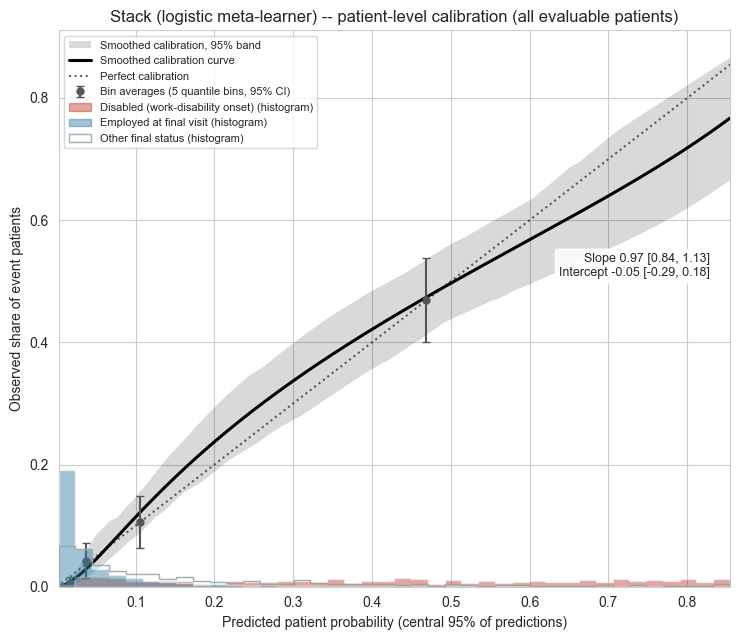


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
Stack,5,23.203 (0.005),0.012 (0.001),0.000 (0.000),0.600 (0.009),0.779 (0.005),0.724 (0.004),0.111 (0.004),43.336 (2.113),0.939 (0.046),0.215 (0.018),0.875 (0.044)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Stack,5,0.172 (0.011),0.272 (0.015),0.370 (0.025),0.445 (0.015),0.571 (0.017),0.950 (0.003),0.901 (0.006),0.854 (0.007),0.807 (0.007),0.714 (0.004)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Stack,5,0.035 (0.014),0.171 (0.029),0.413 (0.056),0.663 (0.010),0.796 (0.032),0.993 (0.001),0.943 (0.011),0.822 (0.031),0.625 (0.018),0.489 (0.028),0.851 (0.140),6.182 (1.197),19.003 (3.168),39.455 (1.727),53.441 (2.689)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Stack,5,0.731 (0.003),0.733 (0.003),0.722 (0.004),0.718 (0.004),0.719 (0.004),0.720 (0.005),0.716 (0.005),0.711 (0.005)


Configuration chosen per fold (visit-level cross-fitted cost-weighted net benefit): {'stack (logistic meta-learner)': 25}


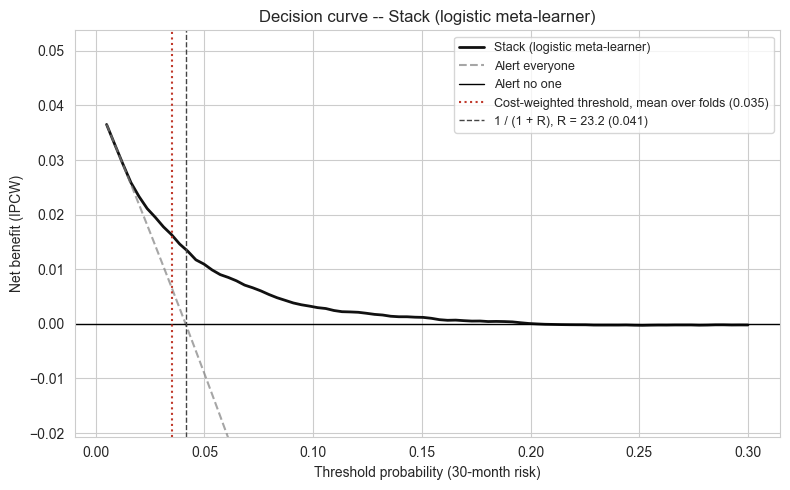

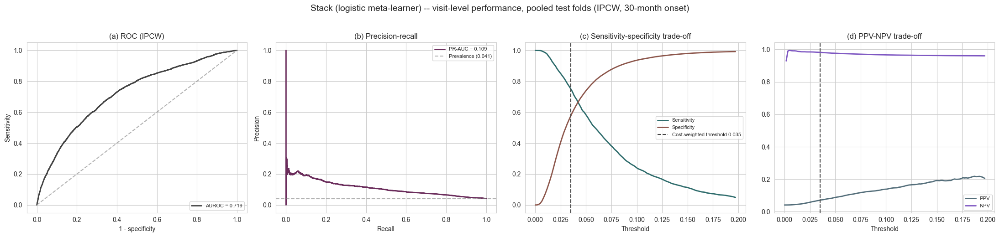

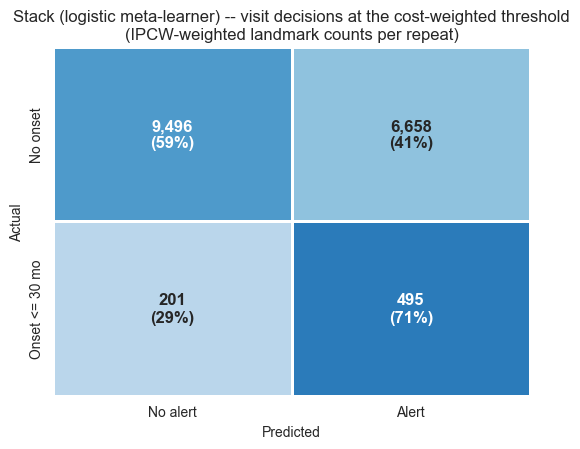

Meta-learner weights over the folds (non-negative; on the members' 30-month logits):


,Mean,Min,Max,Share of folds > 0
LSTM-8 (main),0.109,0.000,0.388,0.52
LogReg (last visit),0.104,0.000,0.342,0.52
RSF,0.492,0.288,0.769,1.00
CoxPH,0.418,0.182,0.728,1.00
GRU,0.156,0.000,0.600,0.80
Transformer,0.125,0.000,0.472,0.68


Ridge penalty chosen per fold: {0.001: 15, 0.01: 10}
Resuming from cv_state_model_revised_v21.pkl: 285 model-fold fits already done.
[StackMLP   ] repeat 1/5 fold 1/5 | AUROC 0.725 NB(R=23.9) 0.0179 | visit sens/spec 0.78/0.56 | patient sens/spec 0.90/0.61 (TN/FP 111/71) | cfg stack (mlp meta-learner) | 17 feats | 1s
[StackTab   ] repeat 1/5 fold 1/5 | AUROC 0.722 NB(R=23.9) 0.0147 | visit sens/spec 0.71/0.56 | patient sens/spec 0.90/0.55 (TN/FP 100/82) | cfg stack (logistic meta-learner) | 17 feats | 1s
[StackMLP   ] repeat 1/5 fold 2/5 | AUROC 0.736 NB(R=22.9) 0.0106 | visit sens/spec 0.71/0.59 | patient sens/spec 0.90/0.56 (TN/FP 101/80) | cfg stack (mlp meta-learner) | 17 feats | 2s
[StackTab   ] repeat 1/5 fold 2/5 | AUROC 0.760 NB(R=22.9) 0.0111 | visit sens/spec 0.71/0.60 | patient sens/spec 0.87/0.57 (TN/FP 103/78) | cfg stack (logistic meta-learner) | 17 feats | 1s
[StackMLP   ] repeat 1/5 fold 3/5 | AUROC 0.717 NB(R=23.6) 0.0161 | visit sens/spec 0.65/0.69 | patient sens/spec

,auroc,auroc_pt_weighted,brier,cal_slope,net_benefit,uno_c
model,,,,,,
Stack (logistic meta-learner),0.7189,0.7791,0.0384,0.9622,0.0124,0.7244
Stack (MLP meta-learner),0.7166,0.7758,0.0384,0.9602,0.0124,0.7221
Stack (tabular members only),0.7182,0.7781,0.0384,0.9897,0.0116,0.7226


In [56]:
"""The stacking ensemble (Section 6.3): formed per fold from the members' stored fold results (seconds; the member
sections must have run). Then the meta-weights over the folds and the supplementary stacks."""
res_stack = run_analysis("Stack", "Stack (logistic meta-learner)")
if res_stack is not None:
    _W = pd.DataFrame([v["weights"] for k, v in cv_state["folds"].items() if k[0] == "Stack" and v.get("weights")])
    print("Meta-learner weights over the folds (non-negative; on the members' 30-month logits):")
    display(pd.DataFrame({"Mean": _W.mean(), "Min": _W.min(), "Max": _W.max(), "Share of folds > 0": (_W > 0).mean()},
                         ).rename(index=lambda m: MODEL_LABELS.get(m, m)).round(3))
    print("Ridge penalty chosen per fold:",
          pd.Series([v["ridge"] for k, v in cv_state["folds"].items() if k[0] == "Stack"]).value_counts().to_dict())
cv_state = run_repeated_cv(models=SUPP_STACK_MODELS)
_res_s, _ = collect_results(cv_state, ["Stack"] + SUPP_STACK_MODELS)
if not _res_s.empty:
    print("\nThe stacks compared (pooled test folds; mean over repeats):")
    display(_res_s.groupby("model")[["auroc", "auroc_pt_weighted", "brier", "cal_slope", "net_benefit", "uno_c"]]
            .mean().rename(index=lambda m: MODEL_LABELS.get(m, m)).round(4))

## 11.11.7 Visit-level summary — all models

Every metric of the per-model visit tables, value [95 % patient-bootstrap CI], with LaTeX rows for the manuscript.

In [57]:
"""
Visit-level summary for all models: every metric of the per-model tables, value [95% patient-bootstrap CI], one row per
model, with LaTeX rows for the manuscript. The per-repeat metrics go to cv_model_revised_v21_pooled_metrics_by_repeat.csv.
"""
MODEL_RESULTS = {m: model_res(m) for m in CV_MODELS if model_res(m) is not None}   # every model that has run
res_all = pd.concat([r["res_df"] for r in MODEL_RESULTS.values()], ignore_index=True)
preds_all = {k: v for r in MODEL_RESULTS.values() for k, v in r["preds"].items()}
res_all.to_csv("cv_model_revised_v21_pooled_metrics_by_repeat.csv", index=False)


def wide_table(key):
    """One row per model: 'value [CI low, CI high]' for every metric of table `key`."""
    cell = lambda row: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                        if np.isfinite(row["Value"]) else "n/a")
    return pd.DataFrame({m: {row["Metric"]: cell(row) for _, row in r[key].iterrows()}
                         for m, r in MODEL_RESULTS.items()}).T


def latex_table_rows(key):
    return [f"{m:<11} & " + " & ".join(f"{row['Value']:.3f} ({row['CI low']:.3f}--{row['CI high']:.3f})"
                                       if np.isfinite(row["Value"]) else "n/a"
                                       for _, row in r[key].iterrows()) + " \\\\"
            for m, r in MODEL_RESULTS.items()]


visit_summary = wide_table("visit_table")
print("VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test "
      "folds; 30-month onset, IPCW; alarms at each fold's visit threshold")
display(visit_summary)
print("\nLaTeX rows (" + " & ".join(visit_summary.columns) + "):")
print("\n".join(latex_table_rows("visit_table")))

VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test folds; 30-month onset, IPCW; alarms at each fold's visit threshold


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LSTM,"0.714 [0.665, 0.761]","0.038 [0.032, 0.045]","1.095 [0.866, 1.348]","-0.047 [-0.252, 0.129]","0.957 [0.790, 1.128]","0.663 [0.599, 0.729]","0.630 [0.601, 0.656]","0.072 [0.057, 0.088]","0.978 [0.971, 0.984]","0.647 [0.612, 0.683]"
LSTM_w16,"0.713 [0.664, 0.761]","0.038 [0.032, 0.045]","1.094 [0.869, 1.348]","-0.052 [-0.259, 0.124]","0.953 [0.785, 1.121]","0.654 [0.589, 0.719]","0.640 [0.611, 0.666]","0.073 [0.058, 0.088]","0.977 [0.971, 0.983]","0.647 [0.611, 0.683]"
LSTM_w4,"0.714 [0.664, 0.761]","0.038 [0.032, 0.045]","1.074 [0.846, 1.323]","-0.043 [-0.249, 0.135]","0.961 [0.793, 1.134]","0.669 [0.603, 0.734]","0.628 [0.599, 0.654]","0.072 [0.057, 0.088]","0.978 [0.972, 0.984]","0.648 [0.613, 0.684]"
LSTM1,"0.713 [0.664, 0.760]","0.038 [0.032, 0.045]","1.078 [0.851, 1.322]","-0.052 [-0.259, 0.126]","0.953 [0.785, 1.124]","0.674 [0.607, 0.740]","0.614 [0.585, 0.641]","0.070 [0.056, 0.086]","0.978 [0.971, 0.983]","0.644 [0.608, 0.681]"
LogReg,"0.713 [0.664, 0.760]","0.038 [0.032, 0.045]","1.025 [0.816, 1.254]","-0.006 [-0.217, 0.172]","0.994 [0.817, 1.172]","0.690 [0.626, 0.756]","0.594 [0.563, 0.622]","0.068 [0.054, 0.083]","0.978 [0.972, 0.984]","0.642 [0.608, 0.676]"
RSF,"0.716 [0.673, 0.761]","0.038 [0.032, 0.045]","0.984 [0.719, 1.300]","-0.003 [-0.211, 0.179]","0.997 [0.820, 1.181]","0.707 [0.644, 0.769]","0.560 [0.533, 0.585]","0.065 [0.052, 0.078]","0.978 [0.972, 0.984]","0.634 [0.602, 0.668]"
CoxPH,"0.713 [0.668, 0.760]","0.039 [0.032, 0.045]","1.045 [0.840, 1.256]","0.002 [-0.208, 0.179]","1.002 [0.824, 1.178]","0.665 [0.601, 0.730]","0.603 [0.574, 0.630]","0.067 [0.053, 0.082]","0.977 [0.970, 0.983]","0.634 [0.600, 0.670]"
GRU,"0.716 [0.667, 0.763]","0.038 [0.032, 0.045]","1.032 [0.791, 1.291]","-0.028 [-0.241, 0.156]","0.974 [0.799, 1.156]","0.616 [0.545, 0.685]","0.693 [0.666, 0.719]","0.080 [0.064, 0.098]","0.977 [0.971, 0.983]","0.655 [0.617, 0.691]"
Transformer,"0.702 [0.650, 0.749]","0.038 [0.032, 0.045]","0.995 [0.753, 1.242]","-0.046 [-0.254, 0.135]","0.958 [0.789, 1.133]","0.577 [0.498, 0.654]","0.725 [0.696, 0.750]","0.083 [0.065, 0.102]","0.975 [0.969, 0.981]","0.651 [0.612, 0.690]"
Stack,"0.719 [0.672, 0.766]","0.038 [0.032, 0.045]","0.964 [0.757, 1.197]","-0.032 [-0.241, 0.151]","0.971 [0.800, 1.148]","0.711 [0.647, 0.776]","0.588 [0.559, 0.615]","0.069 [0.056, 0.084]","0.979 [0.973, 0.985]","0.650 [0.614, 0.686]"



LaTeX rows (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy):
LSTM        & 0.714 (0.665--0.761) & 0.038 (0.032--0.045) & 1.095 (0.866--1.348) & -0.047 (-0.252--0.129) & 0.957 (0.790--1.128) & 0.663 (0.599--0.729) & 0.630 (0.601--0.656) & 0.072 (0.057--0.088) & 0.978 (0.971--0.984) & 0.647 (0.612--0.683) \\
LSTM_w16    & 0.713 (0.664--0.761) & 0.038 (0.032--0.045) & 1.094 (0.869--1.348) & -0.052 (-0.259--0.124) & 0.953 (0.785--1.121) & 0.654 (0.589--0.719) & 0.640 (0.611--0.666) & 0.073 (0.058--0.088) & 0.977 (0.971--0.983) & 0.647 (0.611--0.683) \\
LSTM_w4     & 0.714 (0.664--0.761) & 0.038 (0.032--0.045) & 1.074 (0.846--1.323) & -0.043 (-0.249--0.135) & 0.961 (0.793--1.134) & 0.669 (0.603--0.734) & 0.628 (0.599--0.654) & 0.072 (0.057--0.088) & 0.978 (0.972--0.984) & 0.648 (0.613--0.684) \\
LSTM1       & 0.713 (0.664--0.760) & 0.038 (0.032--0.045) & 1.078 (0.851--1.322) & -0.

## 11.11.8 Every model on every metric

All models -- the Objective 1 models, the RSF, Cox, GRU, Transformer, the Stack and the Baseline -- on the six metrics
of Section 8.1 at the visit (30 months, IPCW) and the patient level, none of them primary:

1. **Values**, value [95 % patient-cluster bootstrap CI].
2. **Rank heatmap**: each cell coloured by the model's rank on that metric (darker = better), with its value.
3. **Paired differences** of LSTM-8 against every model and of every model against the LogReg, on every metric
   (forest plots; > 0 favours the first model).
4. **Bootstrap rank probabilities**: the share of resamples in which each model ranks first on each metric, and its
   mean rank. Models whose differences lie within the CIs are not distinguished by a rank.


EVERY MODEL -- VISIT LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at each model's cost-weighted alarm threshold


,CV repeats,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score
LSTM-8 (main),5,"0.714 [0.661, 0.759]","0.719 [0.668, 0.762]","0.663 [0.592, 0.729]","0.630 [0.601, 0.657]","0.647 [0.609, 0.680]","0.038 [0.032, 0.046]"
LSTM-16 (last 16 visits),5,"0.713 [0.661, 0.758]","0.719 [0.669, 0.762]","0.654 [0.584, 0.719]","0.640 [0.610, 0.667]","0.647 [0.609, 0.680]","0.038 [0.032, 0.046]"
LSTM-4 (last 4 visits),5,"0.714 [0.661, 0.758]","0.719 [0.669, 0.762]","0.669 [0.599, 0.735]","0.628 [0.599, 0.654]","0.648 [0.612, 0.682]","0.038 [0.032, 0.046]"
LSTM-1 (current visit),5,"0.713 [0.660, 0.758]","0.718 [0.668, 0.761]","0.674 [0.605, 0.740]","0.614 [0.584, 0.642]","0.644 [0.606, 0.678]","0.038 [0.032, 0.046]"
LogReg (last visit),5,"0.713 [0.660, 0.758]","0.718 [0.668, 0.761]","0.690 [0.621, 0.753]","0.594 [0.561, 0.624]","0.642 [0.605, 0.674]","0.038 [0.032, 0.046]"
RSF,5,"0.716 [0.666, 0.759]","0.716 [0.668, 0.759]","0.707 [0.640, 0.767]","0.560 [0.531, 0.588]","0.634 [0.600, 0.665]","0.038 [0.032, 0.046]"
CoxPH,5,"0.713 [0.662, 0.757]","0.717 [0.668, 0.759]","0.665 [0.597, 0.729]","0.603 [0.571, 0.631]","0.634 [0.597, 0.668]","0.039 [0.032, 0.046]"
GRU,5,"0.716 [0.662, 0.762]","0.721 [0.670, 0.765]","0.616 [0.544, 0.685]","0.693 [0.665, 0.721]","0.655 [0.615, 0.690]","0.038 [0.032, 0.046]"
Transformer,5,"0.702 [0.648, 0.748]","0.709 [0.657, 0.753]","0.577 [0.507, 0.651]","0.725 [0.694, 0.753]","0.651 [0.613, 0.688]","0.038 [0.033, 0.046]"
Stack (logistic meta-learner),5,"0.719 [0.666, 0.763]","0.722 [0.671, 0.766]","0.711 [0.644, 0.775]","0.588 [0.556, 0.617]","0.650 [0.612, 0.683]","0.038 [0.032, 0.046]"



EVERY MODEL -- PATIENT LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at each model's cost-weighted alarm threshold


,CV repeats,AUROC,Sensitivity,Specificity,Balanced accuracy,Brier score
LSTM-8 (main),5,"0.915 [0.891, 0.936]","0.838 [0.785, 0.890]","0.704 [0.679, 0.729]","0.771 [0.742, 0.801]","0.073 [0.062, 0.084]"
LSTM-16 (last 16 visits),5,"0.915 [0.892, 0.936]","0.846 [0.796, 0.896]","0.716 [0.690, 0.741]","0.781 [0.754, 0.809]","0.073 [0.062, 0.084]"
LSTM-4 (last 4 visits),5,"0.915 [0.892, 0.937]","0.850 [0.797, 0.899]","0.706 [0.680, 0.730]","0.778 [0.750, 0.806]","0.072 [0.062, 0.083]"
LSTM-1 (current visit),5,"0.916 [0.893, 0.937]","0.845 [0.793, 0.893]","0.696 [0.672, 0.721]","0.770 [0.743, 0.799]","0.072 [0.061, 0.083]"
LogReg (last visit),5,"0.917 [0.895, 0.939]","0.874 [0.825, 0.921]","0.640 [0.614, 0.668]","0.757 [0.730, 0.785]","0.072 [0.061, 0.083]"
RSF,5,"0.901 [0.877, 0.923]","0.905 [0.866, 0.941]","0.455 [0.427, 0.483]","0.680 [0.656, 0.702]","0.077 [0.066, 0.087]"
CoxPH,5,"0.922 [0.901, 0.941]","0.888 [0.838, 0.931]","0.625 [0.597, 0.652]","0.757 [0.729, 0.782]","0.072 [0.061, 0.083]"
GRU,5,"0.902 [0.880, 0.925]","0.812 [0.759, 0.869]","0.759 [0.735, 0.781]","0.786 [0.754, 0.814]","0.079 [0.068, 0.090]"
Transformer,5,"0.904 [0.882, 0.927]","0.766 [0.709, 0.825]","0.777 [0.755, 0.798]","0.771 [0.740, 0.802]","0.079 [0.067, 0.091]"
Stack (logistic meta-learner),5,"0.916 [0.895, 0.936]","0.896 [0.854, 0.932]","0.571 [0.544, 0.597]","0.733 [0.708, 0.757]","0.073 [0.062, 0.084]"


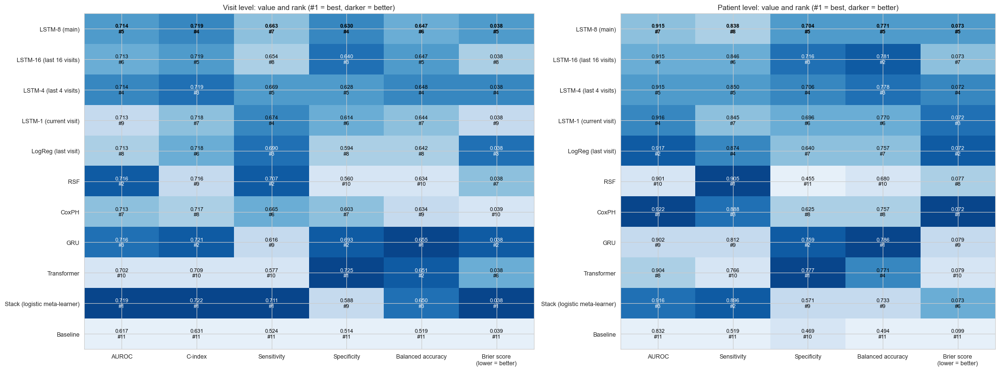


LSTM-8 AGAINST EVERY MODEL -- oriented paired difference [95% CI] (* = lower bound > 0):


Metric                                                              AUROC  \
Comparison                             Level                                
LSTM-8 - LSTM-16 (last 16 visits)      visit      +0.000 [-0.001, +0.001]   
                                       patient    -0.000 [-0.001, +0.001]   
LSTM-8 - LSTM-4 (last 4 visits)        visit      -0.000 [-0.001, +0.001]   
                                       patient    -0.000 [-0.001, +0.000]   
LSTM-8 - LSTM-1 (current visit)        visit      +0.001 [-0.002, +0.004]   
                                       patient    -0.001 [-0.003, +0.001]   
LSTM-8 - LogReg (last visit)           visit      +0.000 [-0.005, +0.007]   
                                       patient    -0.003 [-0.006, +0.001]   
LSTM-8 - RSF                           visit      -0.003 [-0.025, +0.019]   
                                       patient    +0.014 [-0.000, +0.028]   
LSTM-8 - CoxPH                         visit      +0.000 [-0.010, +0.011]   
                                       patient    -0.007 [-0.016, +0.001]   
LSTM-8 - GRU                           visit      -0.002 [-0.013, +0.008]   
                                       patient  +0.012 [+0.002, +0.022] *   
LSTM-8 - Transformer                   visit      +0.012 [-0.001, +0.024]   
                                       patient  +0.010 [+0.002, +0.018] *   
LSTM-8 - Stack (logistic meta-learner) visit      -0.005 [-0.017, +0.006]   
                                       patient    -0.002 [-0.009, +0.005]   
LSTM-8 - Baseline                      visit    +0.096 [+0.055, +0.137] *   
                                       patient  +0.083 [+0.062, +0.105] *   

Metric                                                            C-index  \
Comparison                             Level                                
LSTM-8 - LSTM-16 (last 16 visits)      visit      +0.000 [-0.001, +0.001]   
                                       patient                        NaN   
LSTM-8 - LSTM-4 (last 4 visits)        visit      -0.000 [-0.001, +0.001]   
                                       patient                        NaN   
LSTM-8 - LSTM-1 (current visit)        visit      +0.001 [-0.002, +0.003]   
                                       patient                        NaN   
LSTM-8 - LogReg (last visit)           visit      +0.000 [-0.005, +0.006]   
                                       patient                        NaN   
LSTM-8 - RSF                           visit      +0.002 [-0.019, +0.023]   
                                       patient                        NaN   
LSTM-8 - CoxPH                         visit      +0.001 [-0.009, +0.011]   
                                       patient                        NaN   
LSTM-8 - GRU                           visit      -0.002 [-0.013, +0.008]   
                                       patient                        NaN   
LSTM-8 - Transformer                   visit      +0.010 [-0.003, +0.022]   
                                       patient                        NaN   
LSTM-8 - Stack (logistic meta-learner) visit      -0.004 [-0.015, +0.007]   
                                       patient                        NaN   
LSTM-8 - Baseline                      visit    +0.087 [+0.049, +0.126] *   
                                       patient                        NaN   

Metric                                                        Sensitivity  \
Comparison                             Level                                
LSTM-8 - LSTM-16 (last 16 visits)      visit    +0.009 [+0.000, +0.019] *   
                                       patient    -0.008 [-0.018, +0.003]   
LSTM-8 - LSTM-4 (last 4 visits)        visit      -0.005 [-0.016, +0.005]   
                                       patient    -0.012 [-0.024, -0.001]   
LSTM-8 - LSTM-1 (current visit)        visit      -0.010 [-0.023, +0.001]   
                                       patient    -0.007 [-0.020, +0.00

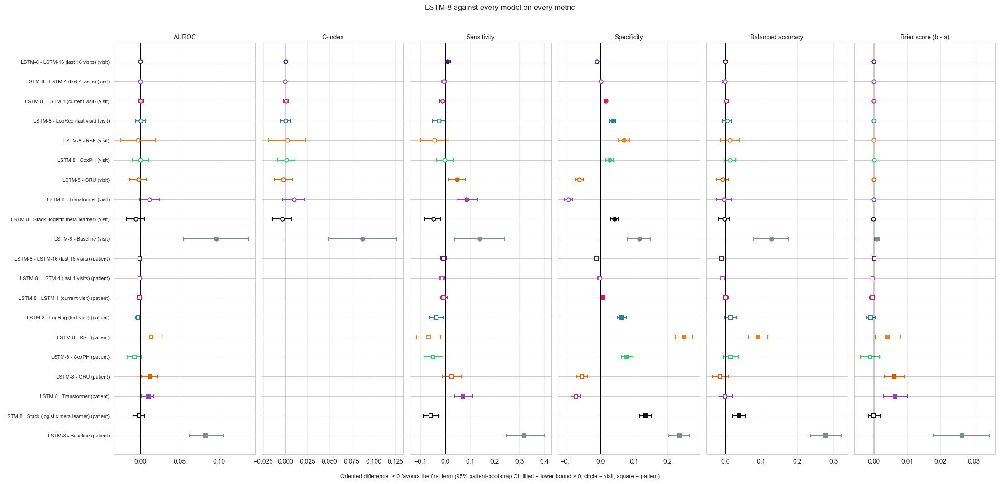


EVERY MODEL AGAINST THE LOGREG (LAST VISIT) -- oriented paired difference [95% CI] (* = lower bound > 0):


Metric                                                            AUROC  \
Comparison                             Level                              
LSTM-8 (main) - LogReg                 visit    +0.000 [-0.005, +0.007]   
                                       patient  -0.003 [-0.006, +0.001]   
LSTM-16 (last 16 visits) - LogReg      visit    +0.000 [-0.006, +0.007]   
                                       patient  -0.002 [-0.006, +0.001]   
LSTM-4 (last 4 visits) - LogReg        visit    +0.001 [-0.005, +0.007]   
                                       patient  -0.002 [-0.005, +0.001]   
LSTM-1 (current visit) - LogReg        visit    -0.000 [-0.006, +0.006]   
                                       patient  -0.002 [-0.005, +0.001]   
RSF - LogReg                           visit    +0.003 [-0.021, +0.027]   
                                       patient  -0.017 [-0.030, -0.002]   
CoxPH - LogReg                         visit    +0.000 [-0.008, +0.009]   
                                       patient  +0.005 [-0.002, +0.012]   
GRU - LogReg                           visit    +0.003 [-0.011, +0.016]   
                                       patient  -0.015 [-0.025, -0.003]   
Transformer - LogReg                   visit    -0.011 [-0.027, +0.004]   
                                       patient  -0.013 [-0.022, -0.004]   
Stack (logistic meta-learner) - LogReg visit    +0.006 [-0.007, +0.019]   
                                       patient  -0.001 [-0.008, +0.006]   
Baseline - LogReg                      visit    -0.096 [-0.138, -0.054]   
                                       patient  -0.085 [-0.107, -0.064]   

Metric                                                          C-index  \
Comparison                             Level                              
LSTM-8 (main) - LogReg                 visit    +0.000 [-0.005, +0.006]   
                                       patient                      NaN   
LSTM-16 (last 16 visits) - LogReg      visit    +0.000 [-0.006, +0.007]   
                                       patient                      NaN   
LSTM-4 (last 4 visits) - LogReg        visit    +0.001 [-0.005, +0.007]   
                                       patient                      NaN   
LSTM-1 (current visit) - LogReg        visit    -0.000 [-0.005, +0.006]   
                                       patient                      NaN   
RSF - LogReg                           visit    -0.002 [-0.025, +0.021]   
                                       patient                      NaN   
CoxPH - LogReg                         visit    -0.001 [-0.009, +0.008]   
                                       patient                      NaN   
GRU - LogReg                           visit    +0.003 [-0.010, +0.015]   
                                       patient                      NaN   
Transformer - LogReg                   visit    -0.010 [-0.025, +0.005]   
                                       patient                      NaN   
Stack (logistic meta-learner) - LogReg visit    +0.004 [-0.008, +0.016]   
                                       patient                      NaN   
Baseline - LogReg                      visit    -0.087 [-0.126, -0.048]   
                                       patient                      NaN   

Metric                                                      Sensitivity  \
Comparison                             Level                              
LSTM-8 (main) - LogReg                 visit    -0.026 [-0.051, -0.001]   
                                       patient  -0.036 [-0.065, -0.006]   
LSTM-16 (last 16 visits) - LogReg      visit    -0.036 [-0.058, -0.014]   
                                       patient  -0.028 [-0.054, -0.002]   
LSTM-4 (last 4 visits) - LogReg        visit    -0.021 [-0.042, +0.000]   
                                       patient  -0.024 [-0.051, +0.002]   
LSTM-1 (current visit) - LogReg        visit    -0.016 [-0.038, +0.008]   
                       

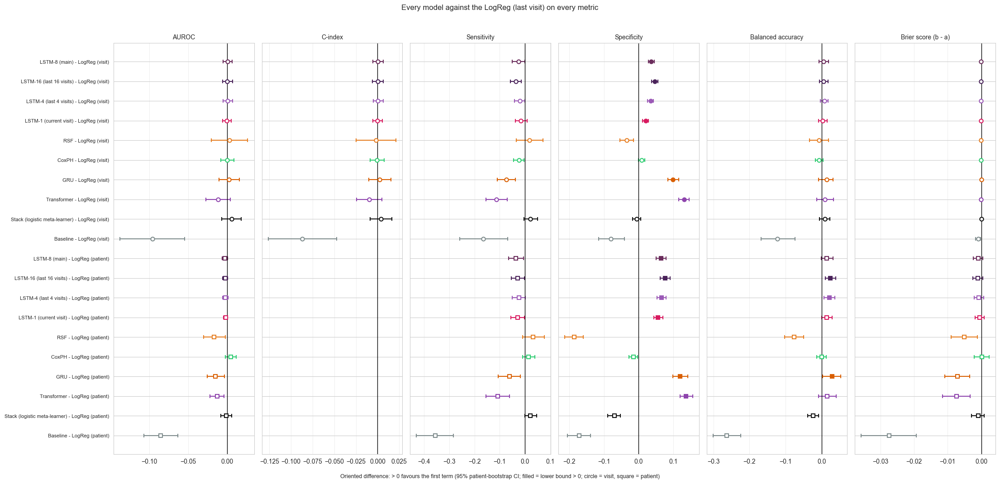


BOOTSTRAP P(RANK 1) on every metric (1000 resamples; models with fewer CV repeats are averaged over their own repeats):


Level                          visit                                  \
Metric                         AUROC C-index Sensitivity Specificity   
Model                                                                  
LSTM-8 (main)                  0.016   0.018       0.000         0.0   
LSTM-16 (last 16 visits)       0.006   0.007       0.000         0.0   
LSTM-4 (last 4 visits)         0.023   0.031       0.000         0.0   
LSTM-1 (current visit)         0.024   0.048       0.006         0.0   
LogReg (last visit)            0.057   0.087       0.046         0.0   
RSF                            0.304   0.159       0.408         0.0   
CoxPH                          0.064   0.063       0.000         0.0   
GRU                            0.227   0.305       0.000         0.0   
Transformer                    0.002   0.004       0.000         1.0   
Stack (logistic meta-learner)  0.277   0.278       0.540         0.0   
Baseline                       0.000   0.000       0.000         0.0   

Level                                                       patient  \
Metric                        Balanced accuracy Brier score   AUROC   
Model                                                                 
LSTM-8 (main)                             0.025       0.024   0.002   
LSTM-16 (last 16 visits)                  0.015       0.007   0.006   
LSTM-4 (last 4 visits)                    0.067       0.015   0.010   
LSTM-1 (current visit)                    0.004       0.003   0.027   
LogReg (last visit)                       0.015       0.134   0.063   
RSF                                       0.015       0.200   0.000   
CoxPH                                     0.001       0.011   0.882   
GRU                                       0.409       0.141   0.000   
Transformer                               0.275       0.121   0.000   
Stack (logistic meta-learner)             0.174       0.344   0.010   
Baseline                                  0.000       0.000   0.000   

Level                                                                    \
Metric                        Sensitivity Specificity Balanced accuracy   
Model                                                                     
LSTM-8 (main)                       0.000         0.0             0.000   
LSTM-16 (last 16 visits)            0.000         0.0             0.259   
LSTM-4 (last 4 visits)              0.000         0.0             0.081   
LSTM-1 (current visit)              0.000         0.0             0.000   
LogReg (last visit)                 0.005         0.0             0.000   
RSF                                 0.663         0.0             0.000   
CoxPH                               0.182         0.0             0.001   
GRU                                 0.000         0.0             0.640   
Transformer                         0.000         1.0             0.019   
Stack (logistic meta-learner)       0.150         0.0             0.000   
Baseline                            0.000         0.0             0.000   

Level                                      
Metric                        Brier score  
Model                                      
LSTM-8 (main)                       0.001  
LSTM-16 (last 16 visits)            0.006  
LSTM-4 (last 4 visits)              0.031  
LSTM-1 (current visit)              0.111  
LogReg (last visit)                 0.276  
RSF                                 0.004  
CoxPH                               0.531  
GRU                                 0.000  
Transformer                         0.000  
Stack (logistic meta-learner)       0.040  
Baseline                            0.000


BOOTSTRAP MEAN RANK on every metric (1000 resamples; models with fewer CV repeats are averaged over their own repeats):


Level                           visit                                  \
Metric                          AUROC C-index Sensitivity Specificity   
Model                                                                   
LSTM-8 (main)                   5.282   5.093       6.295       4.134   
LSTM-16 (last 16 visits)        5.452   5.262       7.716       3.000   
LSTM-4 (last 4 visits)          5.004   4.735       5.320       4.866   
LSTM-1 (current visit)          6.494   5.867       4.263       6.020   
LogReg (last visit)             5.785   5.502       2.832       8.139   
RSF                             4.740   6.184       2.196      10.002   
CoxPH                           5.748   6.142       5.914       7.007   
GRU                             4.317   3.974       9.054       2.000   
Transformer                     9.510   9.159      10.144       1.000   
Stack (logistic meta-learner)   2.668   3.082       1.486       8.834   
Baseline                       11.000  11.000      10.780      10.998   

Level                                                       patient  \
Metric                        Balanced accuracy Brier score   AUROC   
Model                                                                 
LSTM-8 (main)                             5.005       5.426   5.975   
LSTM-16 (last 16 visits)                  4.864       6.490   5.138   
LSTM-4 (last 4 visits)                    3.885       5.165   4.773   
LSTM-1 (current visit)                    6.587       6.319   4.171   
LogReg (last visit)                       6.979       4.271   2.618   
RSF                                       8.313       5.793   9.227   
CoxPH                                     8.974       8.416   1.314   
GRU                                       2.618       4.670   9.057   
Transformer                               3.853       5.876   8.555   
Stack (logistic meta-learner)             3.922       2.616   4.172   
Baseline                                 11.000      10.958  11.000   

Level                                                                    \
Metric                        Sensitivity Specificity Balanced accuracy   
Model                                                                     
LSTM-8 (main)                       7.753       4.664             4.899   
LSTM-16 (last 16 visits)            6.137       3.002             2.063   
LSTM-4 (last 4 visits)              5.402       4.338             2.911   
LSTM-1 (current visit)              6.778       5.996             5.175   
LogReg (last visit)                 3.833       7.006             7.217   
RSF                                 1.624      10.832            10.000   
CoxPH                               2.637       7.994             7.188   
GRU                                 8.770       2.000             1.856   
Transformer                         9.997       1.000             4.701   
Stack (logistic meta-learner)       2.069       9.000             8.990   
Baseline                           11.000      10.168            11.000   

Level                                      
Metric                        Brier score  
Model                                      
LSTM-8 (main)                       5.276  
LSTM-16 (last 16 visits)            5.791  
LSTM-4 (last 4 visits)              3.879  
LSTM-1 (current visit)              3.196  
LogReg (last visit)                 2.326  
RSF                                 8.280  
CoxPH                               2.542  
GRU                                 9.245  
Transformer                         9.405  
Stack (logistic meta-learner)       5.060  
Baseline                           11.000

In [58]:
"""
Every model on every metric (Section 11.11.8): values, rank heatmap, paired differences against LSTM-8 and the LogReg,
and bootstrap rank probabilities; visit level (30 months, IPCW) and patient level (Section 11.6 rule). Descriptive.
"""
ALL_CMP_MODELS = [m for m in CV_MODELS + ["Baseline"] if model_res(m) is not None and oof(m)]
ALL_VALUES = {}
for level in ("visit", "patient"):
    t = value_table(ALL_CMP_MODELS, level)
    t.insert(0, "CV repeats", [len(oof(m)) for m in ALL_CMP_MODELS])
    ALL_VALUES[level] = t
    print(f"\nEVERY MODEL -- {level.upper()} LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; "
          "sensitivity / specificity at each model's cost-weighted alarm threshold")
    display(t)
    t.to_csv(f"all_models_{level}_metrics_revised_v21.csv")

# ---- rank heatmap
fig, axes = plt.subplots(1, 2, figsize=(21, 0.48 * len(ALL_CMP_MODELS) + 2.6),
                         gridspec_kw={"width_ratios": [len(LEVEL_METRICS["visit"]), len(LEVEL_METRICS["patient"])]})
for ax, level in zip(axes, ("visit", "patient")):
    mets = LEVEL_METRICS[level]
    V = np.array([[(core_value(m, k, level) or {"Value": np.nan})["Value"] for k in mets] for m in ALL_CMP_MODELS])
    R = pd.DataFrame(V * np.array([CORE_SIGN[k] for k in mets])).rank(ascending=False, method="min").values
    n_ = len(ALL_CMP_MODELS)
    ax.imshow(np.where(np.isfinite(R), n_ + 1 - R, 0), cmap="Blues", aspect="auto", vmin=0, vmax=n_ + 1)
    for i in range(n_):
        for j in range(len(mets)):
            if np.isfinite(V[i, j]):
                ax.text(j, i, f"{V[i, j]:.3f}\n#{int(R[i, j])}", ha="center", va="center", fontsize=8,
                        color="white" if R[i, j] <= n_ / 3 else "black",
                        fontweight="bold" if ALL_CMP_MODELS[i] == "LSTM" else "normal")
    ax.set_xticks(range(len(mets)))
    ax.set_xticklabels([CORE_LABEL[k] + ("\n(lower = better)" if k == "brier" else "") for k in mets], fontsize=9)
    ax.set_yticks(range(n_)); ax.set_yticklabels([mlab(m) for m in ALL_CMP_MODELS], fontsize=9)
    ax.set_title(f"{level.capitalize()} level: value and rank (#1 = best, darker = better)", fontsize=11)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_all_models_rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- paired differences: LSTM-8 against every model, every model against the LogReg
ALL_VS = {}
for ref, pairs_of, title, colour in [
        ("LSTM", lambda: [("LSTM", m, f"LSTM-8 - {mlab(m)}") for m in ALL_CMP_MODELS if m != "LSTM"],
         "LSTM-8 against every model", lambda r: CV_COLORS.get(r["b"], "#444444")),
        ("LogReg", lambda: [(m, "LogReg", f"{mlab(m)} - LogReg") for m in ALL_CMP_MODELS if m != "LogReg"],
         "Every model against the LogReg (last visit)", None)]:
    if ref not in ALL_CMP_MODELS:
        continue
    long = pd.concat([delta_long(pairs_of(), level) for level in ("visit", "patient")], ignore_index=True)
    ALL_VS[ref] = long
    print(f"\n{title.upper()} -- oriented paired difference [95% CI] (* = lower bound > 0):")
    display(delta_wide(long))
    forest_metrics(long, title + " on every metric", f"revised_v21_all_models_vs_{ref.lower()}.png", color_of=colour)
if ALL_VS:
    pd.concat(ALL_VS, names=["Reference"]).to_csv("all_models_paired_differences_revised_v21.csv")

# ---- bootstrap rank probabilities
_rows = []
for level in ("visit", "patient"):
    for k in LEVEL_METRICS[level]:
        V = [_cols(m, k, level) for m in ALL_CMP_MODELS]
        ok = [i for i, v in enumerate(V) if v is not None and len(v) > 1]
        if len(ok) < 2:
            continue
        Vb = np.array([CORE_SIGN[k] * V[i][1:] for i in ok])
        Rb = np.argsort(np.argsort(-np.nan_to_num(Vb, nan=-np.inf), axis=0), axis=0) + 1
        for i_, i in enumerate(ok):
            _rows.append({"Level": level, "Metric": CORE_LABEL[k], "Model": mlab(ALL_CMP_MODELS[i]),
                          "P(rank 1)": float(np.mean(Rb[i_] == 1)), "Mean rank": float(Rb[i_].mean())})
rank_df = pd.DataFrame(_rows)
if not rank_df.empty:
    for col in ("P(rank 1)", "Mean rank"):
        t = rank_df.pivot_table(index="Model", columns=["Level", "Metric"], values=col, sort=False)
        print(f"\nBOOTSTRAP {col.upper()} on every metric ({HYP_BOOT} resamples; models with fewer CV repeats are "
              "averaged over their own repeats):")
        display(t.round(3))
    rank_df.to_csv("all_models_rank_probabilities_revised_v21.csv", index=False)

## 11.11.9 AUROC detail: every model against the LogReg and LSTM-8, and the signal test against the Baseline

The paired 30-month ΔAUROC of every model against the LogReg (last visit) and of LSTM-8 against every model, the stack
against its best member, and LSTM-8 against the Baseline (age, education, calendar year) over all landmarks and within
calendar eras (case–control pairs from the same era only). Descriptive.

EVERY MODEL -- 30-month AUROC and paired Deltas (95% patient-cluster bootstrap CI, same resamples; descriptive):


,Type,Repeats,AUROC [95% CI],Model - LogReg,LSTM-8 - model
Model,,,,,
LSTM-8 (main),main,5,"0.714 [0.661, 0.759]","+0.000 [-0.005, +0.007]",n/a
LSTM-16 (last 16 visits),Objective 1,5,"0.713 [0.661, 0.758]","+0.000 [-0.006, +0.007]","+0.000 [-0.001, +0.001]"
LSTM-4 (last 4 visits),Objective 1,5,"0.714 [0.661, 0.758]","+0.001 [-0.005, +0.007]","-0.000 [-0.001, +0.001]"
LSTM-1 (current visit),Objective 1,5,"0.713 [0.660, 0.758]","-0.000 [-0.006, +0.006]","+0.001 [-0.002, +0.004]"
LogReg (last visit),Objective 1,5,"0.713 [0.660, 0.758]",n/a,"+0.000 [-0.005, +0.007]"
RSF,comparator,5,"0.716 [0.666, 0.759]","+0.003 [-0.021, +0.027]","-0.003 [-0.025, +0.019]"
CoxPH,comparator,5,"0.713 [0.662, 0.757]","+0.000 [-0.008, +0.009]","+0.000 [-0.010, +0.011]"
GRU,comparator,5,"0.716 [0.662, 0.762]","+0.003 [-0.011, +0.016]","-0.002 [-0.013, +0.008]"
Transformer,comparator,5,"0.702 [0.648, 0.748]","-0.011 [-0.027, +0.004]","+0.012 [-0.001, +0.024]"


Stack - its best single member (RSF, chosen on these folds): +0.003 [-0.010, +0.014]


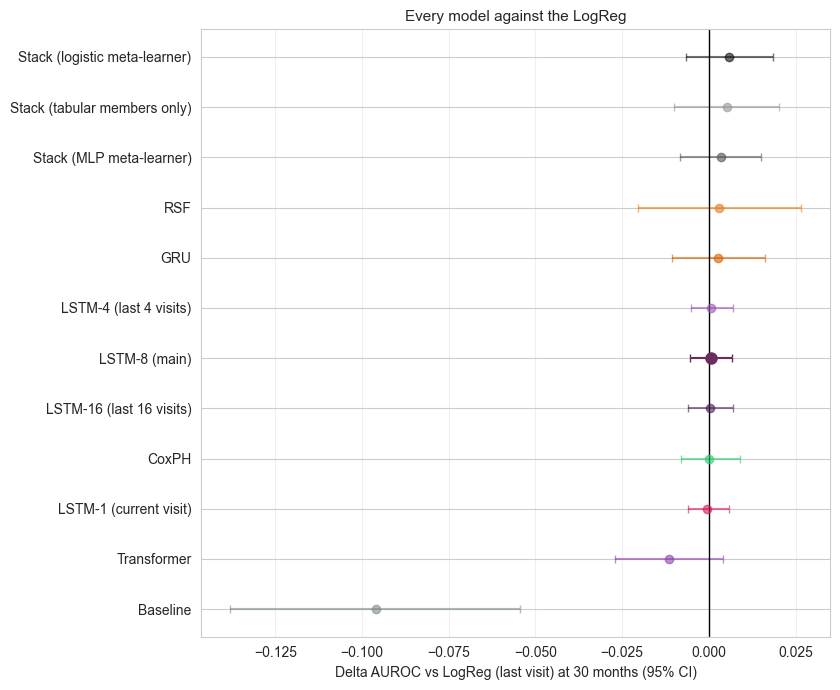


SIGNAL TEST -- AUROC(LSTM-8) - AUROC(Baseline: age, education, calendar year), pooled and era-stratified (case-control pairs from the same calendar era only):


,AUROC LSTM-8,AUROC Baseline,Delta,CI low,CI high,Share of resamples > 0,Repeats
pooled,0.7135,0.6172,0.0963,0.0551,0.1374,1.0,5.0
era-stratified,0.6762,0.5597,0.1166,0.0460,0.1852,1.0,5.0



AUROC within each calendar era (95% patient-bootstrap CI):


,Landmarks,Landmarks with onset <= 30 mo,AUROC LSTM-8 (main),AUROC LogReg (last visit),AUROC Baseline
Era,,,,,
< 2000,1931,133,"0.780 [0.723, 0.830]","0.785 [0.725, 0.833]","0.506 [0.401, 0.595]"
2000-05,2618,153,"0.699 [0.623, 0.774]","0.705 [0.631, 0.782]","0.469 [0.380, 0.557]"
2006-11,3795,193,"0.661 [0.575, 0.739]","0.648 [0.565, 0.727]","0.586 [0.499, 0.667]"
>= 2012,6040,163,"0.652 [0.542, 0.747]","0.657 [0.553, 0.753]","0.589 [0.485, 0.696]"


In [59]:
"""
Every model against the LogReg and against LSTM-8 at 30 months (paired, identical folds, 95% patient-cluster bootstrap
CI; descriptive), the stack against its best single member, and the signal test: LSTM-8 - Baseline, pooled and
era-stratified, with each model's AUROC within each calendar era.
"""
cmp_rows = []
for m in [x for x in CV_MODELS + SUPP_STACK_MODELS + ["Baseline"] if oof(x)]:
    a_, B_ = model_auc(m)
    vs_lr = paired_delta(m, "LogReg") if m != "LogReg" else None
    vs_l8 = paired_delta("LSTM", m) if m != "LSTM" else None
    cmp_rows.append({"Model": mlab(m), "Type": ("main" if m == "LSTM" else "Objective 1" if m in OBJ1_MODELS
                                                 else "baseline" if m == "Baseline" else "comparator"),
                     "Repeats": len(oof(m)),
                     "AUROC [95% CI]": f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]",
                     "Model - LogReg": fmt_d(vs_lr), "LSTM-8 - model": fmt_d(vs_l8),
                     "_d": vs_lr["Delta"] if vs_lr else (0.0 if m == "LogReg" else np.nan),
                     "_lo": vs_lr["CI low"] if vs_lr else np.nan, "_hi": vs_lr["CI high"] if vs_lr else np.nan,
                     "_key": m})
cmp_df = pd.DataFrame(cmp_rows).set_index("Model")
print(f"EVERY MODEL -- {PRIMARY_HORIZON_MONTHS}-month AUROC and paired Deltas (95% patient-cluster bootstrap CI, same "
      "resamples; descriptive):")
display(cmp_df[[c for c in cmp_df.columns if not c.startswith("_")]])
_members_done = [m for m in STACK_MEMBERS if oof(m)]
stack_vs_best = None
if oof("Stack") and _members_done:
    _best = max(_members_done, key=lambda m: model_auc(m)[0])
    stack_vs_best = (_best, paired_delta("Stack", _best))
    print(f"Stack - its best single member ({mlab(_best)}, chosen on these folds): {fmt_d(stack_vs_best[1])}")
_f = cmp_df[np.isfinite(cmp_df["_lo"])].sort_values("_d")
if len(_f):
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(_f) + 1.6))
    ys = np.arange(len(_f))
    for y_, (name, r_) in zip(ys, _f.iterrows()):
        ax.errorbar(r_["_d"], y_, xerr=[[r_["_d"] - r_["_lo"]], [r_["_hi"] - r_["_d"]]], fmt="o", capsize=3,
                    ms=8 if r_["_key"] == "LSTM" else 6, color=CV_COLORS.get(r_["_key"], "#444444"),
                    alpha=1.0 if r_["_key"] == "LSTM" else FADED_ALPHA + 0.15)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(ys); ax.set_yticklabels(_f.index); ax.grid(axis="x", alpha=0.3)
    ax.set_xlabel(f"Delta AUROC vs LogReg (last visit) at {PRIMARY_HORIZON_MONTHS} months (95% CI)")
    ax.set_title("Every model against the LogReg", fontsize=11)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_comparators_vs_logreg.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# ---- signal test: LSTM-8 against the Baseline (no clinical variable), pooled and within calendar eras
sig_rows = {"pooled": paired_delta("LSTM", "Baseline"),
            "era-stratified": paired_delta("LSTM", "Baseline", era_strat=True)}
sig_df = pd.DataFrame({k: v for k, v in sig_rows.items() if v is not None}).T
if not sig_df.empty:
    print("\nSIGNAL TEST -- AUROC(LSTM-8) - AUROC(Baseline: age, education, calendar year), pooled and era-stratified "
          "(case-control pairs from the same calendar era only):")
    display(sig_df.rename(columns={"AUROC a": "AUROC LSTM-8", "AUROC b": "AUROC Baseline"}).round(4))
era_rows = []
for e, (_, _, era_lab) in enumerate(ERA_BANDS):
    k = (ERA_IDX_LAND == e)
    w_e = W30 * k
    n_ev = int(((Y30 == 1) & (w_e > 0)).sum())
    row = {"Era": era_lab, "Landmarks": int((w_e > 0).sum()), "Landmarks with onset <= 30 mo": n_ev}
    for m in ["LSTM", "LogReg", "Baseline"]:
        if oof(m) and n_ev > 0:
            a_, B_ = model_auc(m, w=w_e, tag=f"era{e}")
            row[f"AUROC {mlab(m)}"] = f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]"
    era_rows.append(row)
print("\nAUROC within each calendar era (95% patient-bootstrap CI):")
display(pd.DataFrame(era_rows).set_index("Era"))
cmp_df.drop(columns=[c for c in cmp_df.columns if c.startswith("_")]).to_csv("comparators_vs_logreg_revised_v21.csv")
sig_df.to_csv("signal_test_baseline_revised_v21.csv")

---
# 11.12 Objective 2 — Performance worsens across longer prediction horizons

| | Hypothesis | Comparison | Success criterion (per metric) |
|---|---|---|---|
| **H2** | Discrimination is higher at shorter horizons | Time-dependent metrics of LSTM-8 at 6 months − at 48 months | Lower 95 % bound > 0 |

Reported descriptively: time-dependent discrimination and calibration for the cumulative risk at 6-month increments to
48 months (every model, LSTM-8 highlighted), and for the conditional risk in exclusive 12-month intervals (0–12, 12–24,
24–36, 36–48) among the landmarks still at risk at the start of each interval. Every horizon comes from the same fit
(16 three-month hazard intervals) with its own recalibration and cost-weighted alarm threshold inside the training
folds.

## 11.12.1 LSTM-8 from 6 to 48 months: visit and patient level

Each horizon with its own calibrated risk and era-standardised alarm threshold, from the pooled test folds.


LSTM-8 -- VISIT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Onset rate (IPCW),AUROC,Brier,calibration slope,calibration intercept,sensitivity,specificity,PPV,NPV,alerts / 100 visits
Horizon (mo),,,,,,,,,,
6,0.008,"0.722 [0.671, 0.763]","0.008 [0.006, 0.009]","1.075 [0.867, 1.264]","-0.079 [-0.266, 0.106]","0.658 [0.590, 0.728]","0.632 [0.608, 0.656]","0.014 [0.012, 0.017]","0.996 [0.994, 0.997]","37.035 [34.637, 39.443]"
12,0.018,"0.724 [0.676, 0.768]","0.017 [0.015, 0.020]","1.072 [0.859, 1.268]","-0.059 [-0.225, 0.115]","0.644 [0.564, 0.712]","0.660 [0.634, 0.685]","0.033 [0.027, 0.041]","0.990 [0.987, 0.993]","34.550 [32.056, 37.184]"
18,0.026,"0.715 [0.666, 0.761]","0.025 [0.021, 0.030]","1.088 [0.856, 1.339]","-0.053 [-0.231, 0.111]","0.640 [0.560, 0.711]","0.655 [0.626, 0.681]","0.048 [0.040, 0.058]","0.985 [0.980, 0.989]","35.236 [32.646, 38.172]"
24,0.034,"0.712 [0.662, 0.761]","0.032 [0.028, 0.038]","1.094 [0.850, 1.346]","-0.051 [-0.240, 0.113]","0.670 [0.585, 0.740]","0.627 [0.596, 0.654]","0.060 [0.049, 0.072]","0.982 [0.976, 0.987]","38.281 [35.567, 41.397]"
30,0.041,"0.714 [0.662, 0.762]","0.038 [0.033, 0.045]","1.095 [0.842, 1.363]","-0.047 [-0.234, 0.119]","0.663 [0.582, 0.735]","0.630 [0.597, 0.656]","0.072 [0.060, 0.087]","0.978 [0.971, 0.984]","38.179 [35.586, 41.405]"
36,0.047,"0.715 [0.664, 0.763]","0.044 [0.037, 0.052]","1.108 [0.846, 1.379]","-0.045 [-0.234, 0.126]","0.653 [0.579, 0.724]","0.648 [0.614, 0.674]","0.084 [0.069, 0.102]","0.974 [0.966, 0.981]","36.667 [34.095, 39.861]"
42,0.054,"0.711 [0.662, 0.759]","0.049 [0.042, 0.059]","1.121 [0.844, 1.428]","-0.047 [-0.262, 0.131]","0.651 [0.578, 0.722]","0.638 [0.604, 0.667]","0.093 [0.076, 0.113]","0.970 [0.961, 0.977]","37.719 [35.097, 41.125]"
48,0.060,"0.707 [0.656, 0.759]","0.055 [0.047, 0.065]","1.131 [0.829, 1.451]","-0.044 [-0.269, 0.149]","0.658 [0.589, 0.729]","0.623 [0.587, 0.651]","0.101 [0.083, 0.122]","0.966 [0.955, 0.975]","39.363 [36.626, 42.820]"



LSTM-8 -- PATIENT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Evaluable (events / event-free),C-index,sensitivity,specificity,PPV,NPV,balanced accuracy
Horizon (mo),,,,,,,
6,148 / 909,"0.917 [0.897, 0.937]","0.827 [0.773, 0.874]","0.692 [0.669, 0.712]","0.309 [0.271, 0.352]","0.961 [0.948, 0.974]","0.759 [0.732, 0.788]"
12,148 / 909,"0.916 [0.895, 0.936]","0.830 [0.773, 0.888]","0.741 [0.717, 0.765]","0.345 [0.301, 0.393]","0.964 [0.951, 0.976]","0.785 [0.755, 0.817]"
18,148 / 909,"0.915 [0.894, 0.935]","0.835 [0.774, 0.895]","0.734 [0.705, 0.758]","0.338 [0.296, 0.382]","0.965 [0.951, 0.978]","0.784 [0.754, 0.818]"
24,148 / 909,"0.915 [0.893, 0.935]","0.845 [0.789, 0.899]","0.707 [0.681, 0.733]","0.321 [0.282, 0.365]","0.966 [0.952, 0.979]","0.776 [0.746, 0.806]"
30,148 / 909,"0.915 [0.893, 0.935]","0.838 [0.778, 0.894]","0.704 [0.676, 0.729]","0.317 [0.279, 0.361]","0.964 [0.950, 0.978]","0.771 [0.742, 0.805]"
36,148 / 909,"0.913 [0.891, 0.934]","0.831 [0.773, 0.889]","0.718 [0.690, 0.743]","0.325 [0.285, 0.366]","0.963 [0.949, 0.977]","0.775 [0.744, 0.807]"
42,148 / 909,"0.912 [0.889, 0.933]","0.832 [0.776, 0.888]","0.706 [0.678, 0.731]","0.317 [0.278, 0.358]","0.963 [0.948, 0.977]","0.769 [0.738, 0.803]"
48,148 / 909,"0.911 [0.888, 0.933]","0.836 [0.779, 0.891]","0.691 [0.663, 0.717]","0.307 [0.269, 0.349]","0.963 [0.948, 0.977]","0.764 [0.733, 0.796]"


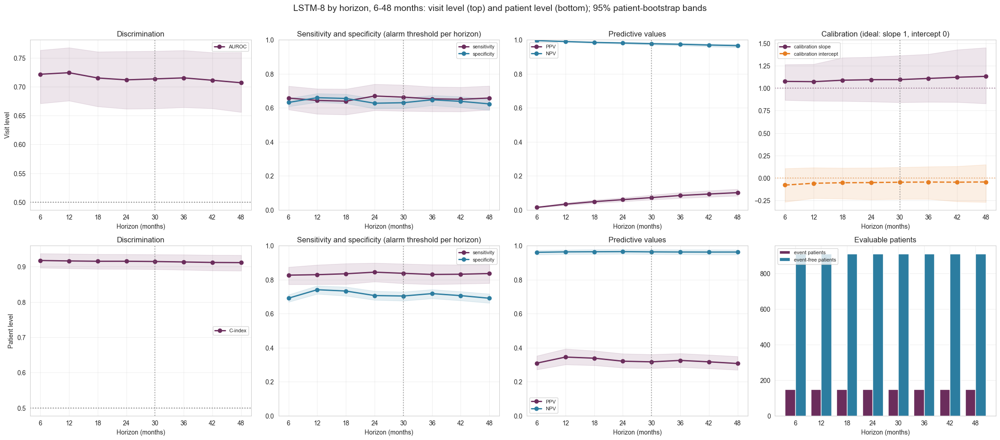

In [60]:
"""
LSTM-8 at every horizon (Section 11.12.1): visit- and patient-level metrics with each horizon's own
calibrated risk and era-standardised alarm threshold (visit_thr_h), from the pooled test folds; plots by horizon.
"""
HZ_BOOT = 100 if SMOKE else 200


def horizon_patient_window(hd):
    """Landmarks that decide a patient's outcome at horizon hd (days): Section 9.2 with hd in place of 30 months."""
    ev = land["event"].values == 1
    win_event = ev & (T_ALL <= hd)
    win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= hd)
    neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & (T_ALL > hd) & ~ev
    last = pd.Series(np.where(neg_other, _vdate.values, np.datetime64("NaT")), dtype="datetime64[ns]") \
        .groupby(PID_ALL).transform("max").values
    win_obs = neg_other & ((last - _vdate.values) / np.timedelta64(1, "D") <= hd)
    return np.where(_stratum == "Event", win_event, win_retired | win_obs)


PT_WIN_H = {h: horizon_patient_window(hd) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
assert np.array_equal(PT_WIN_H[PRIMARY_HORIZON_MONTHS], LAND_PT_WIN_30), "30-month windows must match Section 11.6"
if PATIENT_RULE == "mixed":     # revised_v21: the same patient windows at every horizon (only the risk and threshold change)
    PT_WIN_H = {h: LAND_PT_WIN for h in EVAL_HORIZONS_MONTHS}
PT_IS_EVENT = (PT_TRUTH["stratum"] == "Event").values.astype(int)


def horizon_pieces(P, thr_h, j):
    """Visit and patient arrays of one repeat at horizon column j (fixed across bootstrap resamples); the patient level
    uses the rule of Section 11.6 (patient_collapse) on that horizon's windows."""
    h = EVAL_HORIZONS_MONTHS[j]
    y, w = IPCW[h]
    p = P[:, j]
    a = p >= thr_h[:, j]
    k = np.flatnonzero(PT_WIN_H[h])
    f = patient_collapse(k, p[k], a[k])
    code_pt = PT_CODE.get_indexer(f.index)
    y_pt = PT_IS_EVENT[code_pt]
    return dict(y=y, w=w, p=p, a=a, prep=auc_prep(y, p), code_pt=code_pt, y_pt=y_pt,
                a_pt=f["flag"].values.astype(bool), prep_pt=auc_prep(y_pt, f["score"].values))


def horizon_metrics(pc, m_land=None, m_pt=None):
    div = lambda a_, b_: a_ / b_ if b_ > 0 else np.nan
    w = pc["w"] if m_land is None else pc["w"] * m_land
    k = w > 0
    y, p, a = pc["y"][k], pc["p"][k], pc["a"][k]
    tp, fp, fn, tn = w_confusion(y, a, w[k])
    slope, icpt = fast_calibration(y, p, w[k])
    wp = np.ones(len(pc["y_pt"])) if m_pt is None else m_pt[pc["code_pt"]]
    yp, ap = pc["y_pt"], pc["a_pt"]
    TP, FP = wp[(yp == 1) & ap].sum(), wp[(yp == 0) & ap].sum()
    FN, TN = wp[(yp == 1) & ~ap].sum(), wp[(yp == 0) & ~ap].sum()
    return {"visit: AUROC": auc_w(pc["prep"], w), "visit: Brier": float(np.average((p - y) ** 2, weights=w[k])),
            "visit: calibration slope": slope, "visit: calibration intercept": icpt,
            "visit: sensitivity": div(tp, tp + fn), "visit: specificity": div(tn, tn + fp),
            "visit: PPV": div(tp, tp + fp), "visit: NPV": div(tn, tn + fn),
            "visit: alerts / 100 visits": 100.0 * div((a * w[k]).sum(), w[k].sum()),
            "patient: C-index": auc_w(pc["prep_pt"], wp), "patient: sensitivity": div(TP, TP + FN),
            "patient: specificity": div(TN, TN + FP), "patient: PPV": div(TP, TP + FP), "patient: NPV": div(TN, TN + FN),
            "patient: balanced accuracy": (div(TP, TP + FN) + div(TN, TN + FP)) / 2}


HZ_REPS = selected_repeats() if res_lstm is not None else []
if not HZ_REPS:
    print("Run Section 11.10.1 first.")
else:
    boots_h = patient_boot_counts(HZ_BOOT, seed=2027)
    rows, HZ_CI = [], {}
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        pcs = [horizon_pieces(P, thr_h, j) for P, _, thr_h in HZ_REPS]
        est = pd.DataFrame([horizon_metrics(pc) for pc in pcs]).mean()
        B = pd.DataFrame([pd.DataFrame([horizon_metrics(pc, ml, mp) for pc in pcs]).mean() for ml, mp in boots_h])
        lo, hi = B.quantile(0.025), B.quantile(0.975)
        n_ev, n_neg = int((pcs[0]["y_pt"] == 1).sum()), int((pcs[0]["y_pt"] == 0).sum())
        yh, wh = IPCW[h]
        rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                     "Event patients": n_ev, "Event-free patients": n_neg,
                     **{c: est[c] for c in est.index}, **{f"{c} lo": lo[c] for c in est.index},
                     **{f"{c} hi": hi[c] for c in est.index}})
    hz_df = pd.DataFrame(rows).set_index("Horizon (mo)")
    hz_df.to_csv("lstm_by_horizon_revised_v21.csv")
    mets = [c for c in est.index]
    fmt = lambda c: hz_df.apply(lambda r: f"{r[c]:.3f} [{r[c + ' lo']:.3f}, {r[c + ' hi']:.3f}]"
                                if np.isfinite(r[c]) else "n/a", axis=1)
    for level in ("visit", "patient"):
        t = pd.DataFrame({c.split(": ", 1)[1]: fmt(c) for c in mets if c.startswith(level)})
        if level == "visit":
            t.insert(0, "Onset rate (IPCW)", hz_df["Onset rate (IPCW)"].round(3))
        else:
            t.insert(0, "Evaluable (events / event-free)",
                     hz_df["Event patients"].astype(str) + " / " + hz_df["Event-free patients"].astype(str))
        print(f"\nLSTM-8 -- {level.upper()} LEVEL by horizon: value [95% patient-bootstrap CI], mean over "
              f"{len(HZ_REPS)} repeat(s)")
        display(t)

    def band(ax, c, color, label, ls="-"):
        ax.plot(EVAL_HORIZONS_MONTHS, hz_df[c], marker="o", color=color, ls=ls, lw=2, label=label)
        ax.fill_between(EVAL_HORIZONS_MONTHS, hz_df[c + " lo"], hz_df[c + " hi"], color=color, alpha=0.12)

    C1, C2, C3 = CV_COLORS["LSTM"], "#2c7da0", "#e67e22"
    fig, axes = plt.subplots(2, 4, figsize=(22, 9.5))
    for r_, level, disc in [(0, "visit", "visit: AUROC"), (1, "patient", "patient: C-index")]:
        ax = axes[r_, 0]
        band(ax, disc, C1, disc.split(": ")[1]); ax.axhline(0.5, color="gray", ls=":")
        ax.set_ylabel(f"{level.capitalize()} level"); ax.set_title("Discrimination")
        ax = axes[r_, 1]
        band(ax, f"{level}: sensitivity", C1, "sensitivity"); band(ax, f"{level}: specificity", C2, "specificity")
        ax.set_ylim(0, 1); ax.set_title("Sensitivity and specificity (alarm threshold per horizon)")
        ax = axes[r_, 2]
        band(ax, f"{level}: PPV", C1, "PPV"); band(ax, f"{level}: NPV", C2, "NPV")
        ax.set_ylim(0, 1); ax.set_title("Predictive values")
    ax = axes[0, 3]
    band(ax, "visit: calibration slope", C1, "calibration slope"); band(ax, "visit: calibration intercept", C3,
                                                                          "calibration intercept", ls="--")
    ax.axhline(1, color=C1, ls=":", alpha=0.6); ax.axhline(0, color=C3, ls=":", alpha=0.6)
    ax.set_title("Calibration (ideal: slope 1, intercept 0)")
    ax = axes[1, 3]
    x = np.arange(len(EVAL_HORIZONS_MONTHS))
    ax.bar(x - 0.2, hz_df["Event patients"], 0.4, color=C1, label="event patients")
    ax.bar(x + 0.2, hz_df["Event-free patients"], 0.4, color=C2, label="event-free patients")
    ax.set_xticks(x); ax.set_xticklabels(EVAL_HORIZONS_MONTHS); ax.set_title("Evaluable patients")
    for ax in axes.ravel()[:-1]:
        ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":", alpha=0.7)
    for ax in axes.ravel():
        ax.set_xlabel("Horizon (months)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("LSTM-8 by horizon, 6-48 months: visit level (top) and patient level (bottom); "
                 "95% patient-bootstrap bands", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_lstm_by_horizon.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.12.2 Cumulative risk by horizon (6–48 months) — every model, LSTM-8 highlighted

Discrimination and calibration at every horizon (every model; LSTM-8 highlighted) from the same cross-validation (the hazard head gives all horizons
from one fit). These are validated, out-of-fold numbers. The selected LSTM's visit- and patient-level metrics by
horizon, with bootstrap CIs and alarm thresholds per horizon, are in Section 11.12.1.

LSTM -- performance by horizon, pooled test folds (mean (SD) over repeats)


,Onset rate (IPCW),AUROC,Brier,Cal. slope,Cal. intercept
Horizon (mo),,,,,
6,0.008004,0.722 (0.005),0.008 (0.000),1.074 (0.056),-0.079 (0.019)
12,0.017732,0.724 (0.003),0.017 (0.000),1.073 (0.033),-0.059 (0.010)
18,0.026491,0.715 (0.002),0.025 (0.000),1.089 (0.022),-0.053 (0.010)
24,0.034212,0.712 (0.002),0.032 (0.000),1.094 (0.038),-0.051 (0.009)
30,0.041334,0.714 (0.002),0.038 (0.000),1.096 (0.049),-0.047 (0.009)
36,0.047370,0.715 (0.001),0.044 (0.000),1.109 (0.049),-0.045 (0.010)
42,0.053922,0.711 (0.001),0.049 (0.000),1.122 (0.054),-0.047 (0.012)
48,0.060484,0.707 (0.001),0.055 (0.000),1.131 (0.067),-0.044 (0.013)


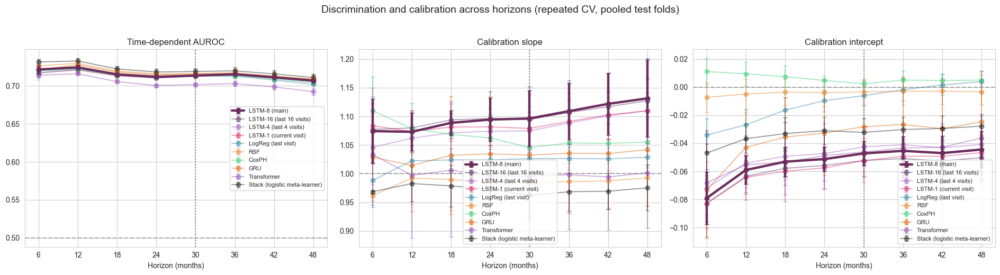

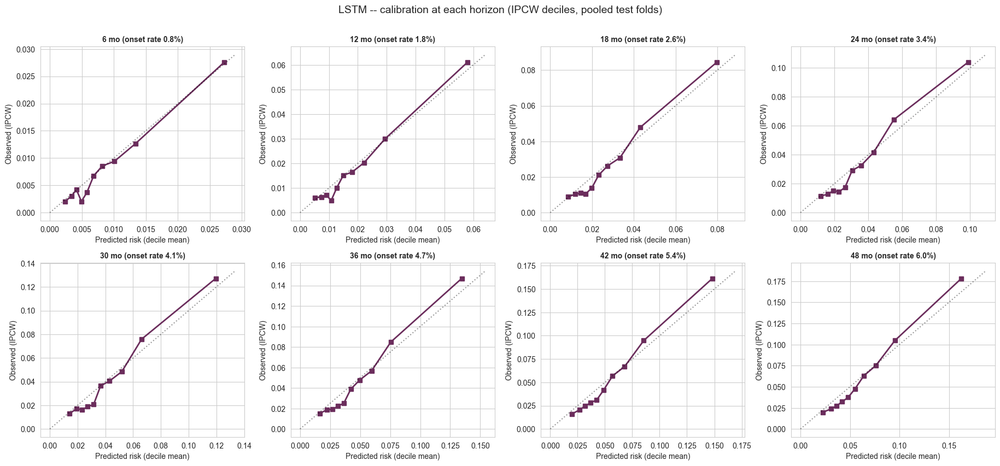

In [61]:
"""
LSTM multi-horizon performance (6-48 months) -- from the SAME repeated CV.

The discrete-time hazard head gives the risk of onset by every horizon from one fit, and each horizon has its own
recalibration learned inside the training folds. So
these are validated, out-of-fold numbers: time-dependent IPCW AUROC, Brier score, calibration slope and intercept per
horizon, mean (SD) over repeats, and a reliability plot per horizon.
"""
HZ_MODEL = "LSTM" if res_lstm is not None else next(iter(MODEL_RESULTS))
d = MODEL_RESULTS[HZ_MODEL]["res_df"]
rows = []
for h in EVAL_HORIZONS_MONTHS:
    yh, wh = IPCW[h]
    rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                 **{lab: _fmt(d[f"{c}_{h}"]) for c, lab in [("td_auroc", "AUROC"), ("brier", "Brier"),
                                                            ("cal_slope", "Cal. slope"),
                                                            ("cal_intercept", "Cal. intercept")]}})
horizon_df = pd.DataFrame(rows).set_index("Horizon (mo)")
print(f"{HZ_MODEL} -- performance by horizon, pooled test folds (mean (SD) over repeats)")
display(horizon_df)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (c, lab, ideal) in zip(axes, [("td_auroc", "Time-dependent AUROC", 0.5), ("cal_slope", "Calibration slope", 1.0),
                                      ("cal_intercept", "Calibration intercept", 0.0)]):
    for m, r in MODEL_RESULTS.items():
        dd = r["res_df"]
        mu = [dd[f"{c}_{h}"].mean() for h in EVAL_HORIZONS_MONTHS]
        sd = [dd[f"{c}_{h}"].std() if len(dd) > 1 else 0 for h in EVAL_HORIZONS_MONTHS]
        ax.errorbar(EVAL_HORIZONS_MONTHS, mu, yerr=sd, marker="o", capsize=3, label=mlab(m), **model_style(m))
    ax.axhline(ideal, color="gray", ls="--", alpha=0.6)
    ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_title(lab)
    ax.legend(fontsize=8)
plt.suptitle("Discrimination and calibration across horizons (repeated CV, pooled test folds)", y=1.03, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_horizons.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

ncols = 4
nrows = int(np.ceil(len(EVAL_HORIZONS_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
for ax, (j, h) in zip(axes.ravel(), enumerate(EVAL_HORIZONS_MONTHS)):
    p, y, w, _, _ = stacked(HZ_MODEL, MODEL_RESULTS[HZ_MODEL]["preds"], col=j, horizon=h)
    k = w > 0
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    hi = float(max((cd["pw"] / cd["w"]).max(), (cd["yw"] / cd["w"]).max())) * 1.05
    ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color=CV_COLORS[HZ_MODEL], lw=2)
    ax.plot([0, hi], [0, hi], "k:", alpha=0.4)
    ax.set_title(f"{h} mo (onset rate {np.average(y[k], weights=w[k]):.1%})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted risk (decile mean)"); ax.set_ylabel("Observed (IPCW)")
for ax in axes.ravel()[len(EVAL_HORIZONS_MONTHS):]:
    ax.set_visible(False)
plt.suptitle(f"{HZ_MODEL} -- calibration at each horizon (IPCW deciles, pooled test folds)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show(); plt.close()

## 11.12.3 Exclusive 12-month intervals: when does the onset happen?

Risk in months 0–12, 12–24, 24–36 and 36–48 **among the landmarks still at risk at the start of the interval**
(employed, event-free and uncensored), each interval with its own competing-risk IPCW label and its own recalibration
inside the training folds. Every model, LSTM-8 highlighted.

EXCLUSIVE 12-MONTH INTERVALS -- conditional on being at risk at the start of the interval; mean over CV repeats; AUROC with 95% patient-cluster bootstrap CI (200 resamples):


,,At risk at the start,Resolved (IPCW > 0),Observed risk (IPCW),Mean predicted risk,AUROC,95% CI,E/O,Cal. slope,Cal. intercept
Interval (mo),Model,,,,,,,,,
0-12,LSTM-8 (main),16851,15722,0.018,0.019,0.724,"[0.675, 0.770]",1.059,1.072,-0.059
12-24,LSTM-8 (main),15060,14089,0.017,0.018,0.707,"[0.647, 0.756]",1.037,1.133,-0.037
24-36,LSTM-8 (main),13527,12852,0.014,0.015,0.727,"[0.665, 0.786]",1.017,1.116,-0.017
36-48,LSTM-8 (main),12386,11554,0.015,0.015,0.695,"[0.634, 0.752]",1.028,1.164,-0.028
0-12,LSTM-16 (last 16 visits),16851,15722,0.018,0.019,0.724,"[0.675, 0.769]",1.063,1.079,-0.063
12-24,LSTM-16 (last 16 visits),15060,14089,0.017,0.018,0.707,"[0.647, 0.756]",1.042,1.125,-0.042
24-36,LSTM-16 (last 16 visits),13527,12852,0.014,0.015,0.728,"[0.665, 0.786]",1.026,1.105,-0.026
36-48,LSTM-16 (last 16 visits),12386,11554,0.015,0.015,0.696,"[0.634, 0.753]",1.034,1.169,-0.034
0-12,LSTM-4 (last 4 visits),16851,15722,0.018,0.019,0.723,"[0.672, 0.769]",1.054,1.061,-0.054


AUROC by interval (models in columns):


Model,Baseline,CoxPH,GRU,LSTM-1 (current visit),LSTM-16 (last 16 visits),LSTM-4 (last 4 visits),LSTM-8 (main),LogReg (last visit),RSF,Stack (logistic meta-learner),Transformer
Interval (mo),,,,,,,,,,,
0-12,0.610,0.722,0.728,0.721,0.724,0.723,0.724,0.722,0.730,0.733,0.716
12-24,0.632,0.702,0.709,0.706,0.707,0.707,0.707,0.705,0.703,0.708,0.694
24-36,0.662,0.704,0.726,0.732,0.728,0.729,0.727,0.721,0.716,0.721,0.716
36-48,0.657,0.674,0.711,0.701,0.696,0.697,0.695,0.680,0.687,0.697,0.686


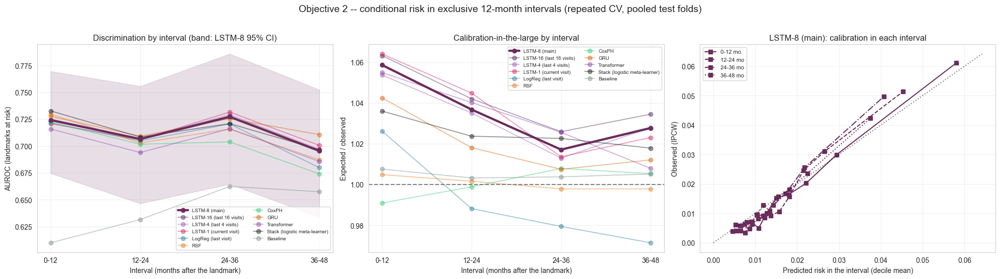

In [62]:
"""
Objective 2, the 'when' analysis: risk in exclusive 12-month intervals, CONDITIONAL on being at risk at the start --
months a to a + 12 among the landmarks with follow-up beyond a months and no event or competing exit before it
(T > a). From the same fit: the calibrated cumulative risks give r = 1 - (1 - P(a + 12)) / (1 - P(a)) (P(12) itself
for 0-12 months), recalibrated per fold on the training rows' cross-fitted r against the training rows' interval label
(an IPCW logistic recalibration, as in Section 7; the censoring distribution restarts at month a). Evaluated only in the
landmarks at risk: AUROC with a 95% patient-cluster bootstrap CI, O/E, calibration slope and intercept, mean over repeats.
"""
INT_BOOT = HYP_MULT[:200]
HZ_IDX = {h: j for j, h in enumerate(EVAL_HORIZONS_MONTHS)}


def interval_label(a, b, rows=None):
    """(y, w): onset in months (a, b] among the rows at risk at month a (w = 0 elsewhere), IPCW from month a."""
    rows = ALL_ROWS if rows is None else np.asarray(rows)
    ad, hd = round(a * MONTH_DAYS), round((b - a) * MONTH_DAYS)
    at = T_ALL[rows] > ad
    y, w = np.zeros(len(rows)), np.zeros(len(rows))
    if at.sum() > 0:
        t, c = T_ALL[rows][at] - ad, C_ALL[rows][at]
        y[at], w[at] = ipcw_label_weight(t, c, hd, CensoringKM(t, c))
    return y, w


def interval_score(P, a, b):
    """Conditional risk of the interval from the cumulative risks P (N, H)."""
    Pb = P[:, HZ_IDX[b]]
    if a == 0:
        return np.clip(Pb, 1e-6, 1 - 1e-6)
    Pa = P[:, HZ_IDX[a]]
    return np.clip(1.0 - (1.0 - Pb) / np.clip(1.0 - Pa, 1e-6, None), 1e-6, 1 - 1e-6)


INT_LAB = {iv: interval_label(*iv) for iv in OBJ2_INTERVALS}


def interval_oof(model, a, b):
    """{repeat: recalibrated interval risk (N,)} for every completed repeat of `model`."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m != model or v.get("oof_P") is None:
            continue
        ytr, wtr = interval_label(a, b, v["tr"])
        cal = Calibrator().fit(interval_score(np.asarray(v["oof_P"], float), a, b), ytr, wtr, True)
        out.setdefault(r, np.full(len(land), np.nan))[v["te"]] = cal.transform(interval_score(np.asarray(v["P"], float), a, b))
    return {r: p for r, p in out.items() if not np.isnan(p).any()}


INT_MODELS = [m for m in CV_MODELS + ["Baseline"] if oof(m)]
int_rows, INT_RES, INT_PRED = [], {}, {}
for m in INT_MODELS:
    for (a, b) in OBJ2_INTERVALS:
        y, w = INT_LAB[(a, b)]
        k = w > 0
        S = interval_oof(m, a, b)
        if not S or y[k].min() == y[k].max():
            continue
        INT_PRED[(m, (a, b))] = S
        preps = {r: auc_prep(y, s) for r, s in S.items()}
        f = lambda mult: np.mean([auc_w(preps[r], w * mult) for r in S])
        est, B = f(1.0), np.array([f(mm) for mm in INT_BOOT])
        lo, hi = np.nanpercentile(B, [2.5, 97.5])
        cal = np.array([fast_calibration(y[k], s[k], w[k]) for s in S.values()], float)
        pred = float(np.mean([np.average(s[k], weights=w[k]) for s in S.values()]))
        obs = float(np.average(y[k], weights=w[k]))
        INT_RES[(m, (a, b))] = (est, lo, hi, pred / obs if obs > 0 else np.nan)
        int_rows.append({"Model": mlab(m), "Interval (mo)": f"{a}-{b}", "At risk at the start": int((T_ALL > round(a * MONTH_DAYS)).sum()),
                         "Resolved (IPCW > 0)": int(k.sum()), "Observed risk (IPCW)": obs, "Mean predicted risk": pred,
                         "AUROC": est, "95% CI": f"[{lo:.3f}, {hi:.3f}]", "E/O": pred / obs if obs > 0 else np.nan,
                         "Cal. slope": float(np.nanmean(cal[:, 0])), "Cal. intercept": float(np.nanmean(cal[:, 1]))})
int_df = pd.DataFrame(int_rows)
if int_df.empty:
    print("No model has a completed repeat yet.")
else:
    print("EXCLUSIVE 12-MONTH INTERVALS -- conditional on being at risk at the start of the interval; mean over CV "
          f"repeats; AUROC with 95% patient-cluster bootstrap CI ({len(INT_BOOT)} resamples):")
    display(int_df.set_index(["Interval (mo)", "Model"]).round(3))
    print("AUROC by interval (models in columns):")
    display(int_df.pivot(index="Interval (mo)", columns="Model", values="AUROC").round(3))
    labels_iv = [f"{a}-{b}" for a, b in OBJ2_INTERVALS]
    xs = np.arange(len(OBJ2_INTERVALS))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.4))
    for m in INT_MODELS:
        v = np.array([INT_RES.get((m, iv), (np.nan,) * 4) for iv in OBJ2_INTERVALS], float)
        if np.isnan(v[:, 0]).all():
            continue
        axes[0].plot(xs, v[:, 0], marker="o", label=mlab(m), **model_style(m))
        axes[1].plot(xs, v[:, 3], marker="o", label=mlab(m), **model_style(m))
        if m == OBJ2_MODEL:
            axes[0].fill_between(xs, v[:, 1], v[:, 2], color=CV_COLORS[m], alpha=0.15)
    axes[0].set_ylabel("AUROC (landmarks at risk)"); axes[0].set_title("Discrimination by interval (band: LSTM-8 95% CI)")
    axes[1].axhline(1, color="gray", ls="--"); axes[1].set_ylabel("Expected / observed")
    axes[1].set_title("Calibration-in-the-large by interval")
    for ax in axes[:2]:
        ax.set_xticks(xs); ax.set_xticklabels(labels_iv); ax.set_xlabel("Interval (months after the landmark)")
        ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
    ax = axes[2]
    hi_ = 0.0
    for iv, ls in zip(OBJ2_INTERVALS, ["-", "--", "-.", ":"]):
        S = INT_PRED.get((OBJ2_MODEL, iv))
        if not S:
            continue
        y, w = INT_LAB[iv]
        k = w > 0
        p_ = np.concatenate([s[k] for s in S.values()]); y_ = np.tile(y[k], len(S)); w_ = np.tile(w[k], len(S))
        bins = pd.qcut(p_, 10, labels=False, duplicates="drop")
        cd = pd.DataFrame({"pw": p_ * w_, "yw": y_ * w_, "w": w_, "b": bins}).groupby("b").sum()
        ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], marker="s", ls=ls, color=CV_COLORS[OBJ2_MODEL],
                label=f"{iv[0]}-{iv[1]} mo")
        hi_ = max(hi_, float((cd["pw"] / cd["w"]).max()), float((cd["yw"] / cd["w"]).max()))
    ax.plot([0, hi_ * 1.05], [0, hi_ * 1.05], "k:", alpha=0.5)
    ax.set_xlabel("Predicted risk in the interval (decile mean)"); ax.set_ylabel("Observed (IPCW)")
    ax.set_title(f"{mlab(OBJ2_MODEL)}: calibration in each interval"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("Objective 2 -- conditional risk in exclusive 12-month intervals (repeated CV, pooled test folds)",
                 y=1.02, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective2_intervals.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    int_df.to_csv("objective2_intervals_revised_v21.csv", index=False)

## 11.12.4 H2: every metric at 6 minus 48 months

LSTM-8's six visit-level metrics at the shortest (6 months) minus the longest (48 months) horizon, each horizon against
its own competing-risk label, IPCW weights and cost-weighted alarm threshold, paired on the same resamples; per metric,
the criterion is a lower 95 % bound > 0 (Brier: 48 minus 6 months, since lower is better -- it also falls with the
onset rate, so it is reported, not read as discrimination). With it: every metric at every horizon for LSTM-8 (95 % CI)
and for every model (point estimates, LSTM-8 highlighted), and every model's 6 − 48-month difference.

H2 -- LSTM-8, every metric at 6 minus 48 months (oriented: > 0 = better at 6 months; Brier 48 minus 6), 95% patient-cluster bootstrap CI (1000 resamples); * = lower bound > 0:


,Metric,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score,Lower bound > 0 on
Comparison,Level,,,,,,,
LSTM-8: 6 mo - 48 mo,visit,"+0.015 [-0.023, +0.052]","+0.008 [-0.028, +0.043]","-0.000 [-0.059, +0.058]","+0.009 [-0.008, +0.024]","+0.004 [-0.026, +0.034]","+0.047 [+0.039, +0.056] *",1 of 6 metrics



LSTM-8 -- every metric by horizon (cumulative risk; value [95% CI]):


,Onset rate (IPCW),AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score
6 mo,0.008,"0.722 [0.673, 0.766]","0.723 [0.675, 0.767]","0.658 [0.590, 0.722]","0.632 [0.608, 0.656]","0.645 [0.609, 0.677]","0.008 [0.006, 0.010]"
12 mo,0.018,"0.724 [0.676, 0.768]","0.727 [0.681, 0.771]","0.644 [0.578, 0.709]","0.660 [0.634, 0.685]","0.652 [0.616, 0.685]","0.017 [0.014, 0.021]"
18 mo,0.026,"0.715 [0.666, 0.761]","0.720 [0.672, 0.765]","0.640 [0.570, 0.711]","0.655 [0.628, 0.681]","0.647 [0.610, 0.682]","0.025 [0.021, 0.030]"
24 mo,0.034,"0.712 [0.660, 0.758]","0.718 [0.669, 0.762]","0.670 [0.603, 0.739]","0.627 [0.599, 0.653]","0.649 [0.612, 0.683]","0.032 [0.027, 0.038]"
30 mo,0.041,"0.714 [0.661, 0.759]","0.719 [0.668, 0.762]","0.663 [0.592, 0.729]","0.630 [0.601, 0.657]","0.647 [0.609, 0.680]","0.038 [0.032, 0.046]"
36 mo,0.047,"0.715 [0.661, 0.761]","0.720 [0.669, 0.763]","0.653 [0.578, 0.721]","0.648 [0.617, 0.676]","0.650 [0.612, 0.685]","0.044 [0.037, 0.052]"
42 mo,0.054,"0.711 [0.657, 0.756]","0.716 [0.665, 0.758]","0.651 [0.574, 0.721]","0.638 [0.606, 0.667]","0.645 [0.605, 0.680]","0.049 [0.041, 0.059]"
48 mo,0.060,"0.707 [0.654, 0.752]","0.715 [0.664, 0.756]","0.658 [0.584, 0.728]","0.623 [0.590, 0.654]","0.641 [0.600, 0.676]","0.055 [0.046, 0.065]"


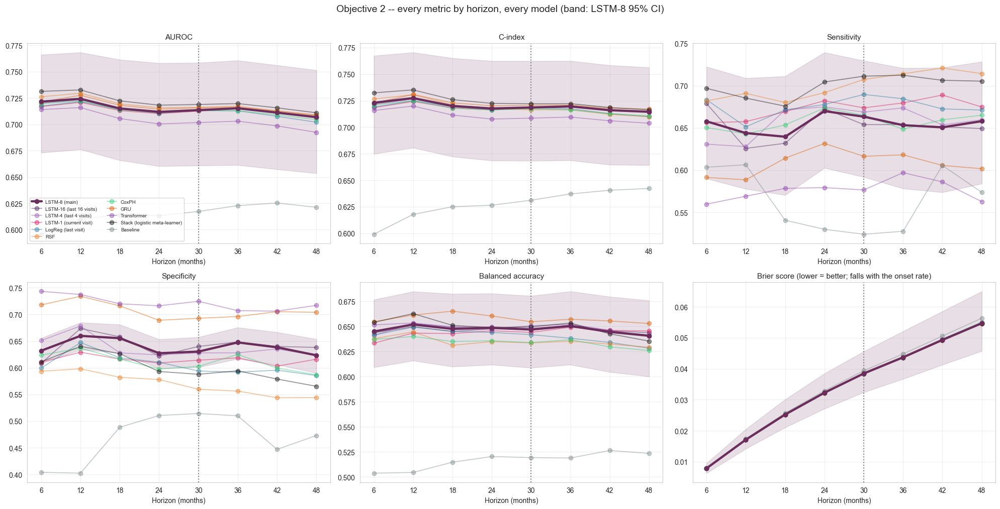


Every model -- every metric at 6 minus 48 months (oriented; descriptive):


,Metric,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Brier score,Lower bound > 0 on
Comparison,Level,,,,,,,
LSTM-8 (main): 6 - 48 mo,visit,"+0.015 [-0.023, +0.052]","+0.008 [-0.028, +0.043]","-0.000 [-0.059, +0.058]","+0.009 [-0.008, +0.024]","+0.004 [-0.026, +0.034]","+0.047 [+0.039, +0.056] *",1 of 6 metrics
LSTM-16 (last 16 visits): 6 - 48 mo,visit,"+0.014 [-0.023, +0.052]","+0.008 [-0.028, +0.043]","+0.030 [-0.025, +0.083]","-0.030 [-0.047, -0.014]","-0.000 [-0.029, +0.028]","+0.047 [+0.039, +0.056] *",1 of 6 metrics
LSTM-4 (last 4 visits): 6 - 48 mo,visit,"+0.013 [-0.025, +0.051]","+0.007 [-0.029, +0.042]","-0.029 [-0.088, +0.030]","+0.028 [+0.011, +0.044] *","-0.001 [-0.032, +0.030]","+0.047 [+0.039, +0.056] *",2 of 6 metrics
LSTM-1 (current visit): 6 - 48 mo,visit,"+0.010 [-0.029, +0.050]","+0.003 [-0.033, +0.041]","-0.019 [-0.083, +0.045]","-0.006 [-0.022, +0.011]","-0.012 [-0.045, +0.021]","+0.047 [+0.039, +0.056] *",1 of 6 metrics
LogReg (last visit): 6 - 48 mo,visit,"+0.015 [-0.023, +0.051]","+0.009 [-0.027, +0.044]","+0.012 [-0.054, +0.076]","+0.014 [+0.002, +0.026] *","+0.013 [-0.021, +0.045]","+0.047 [+0.039, +0.056] *",2 of 6 metrics
RSF: 6 - 48 mo,visit,"+0.018 [-0.017, +0.051]","+0.017 [-0.016, +0.048]","-0.032 [-0.097, +0.033]","+0.050 [+0.038, +0.061] *","+0.009 [-0.025, +0.042]","+0.047 [+0.039, +0.056] *",2 of 6 metrics
CoxPH: 6 - 48 mo,visit,"+0.015 [-0.022, +0.050]","+0.010 [-0.026, +0.044]","-0.015 [-0.088, +0.051]","+0.037 [+0.021, +0.052] *","+0.011 [-0.026, +0.046]","+0.047 [+0.039, +0.057] *",2 of 6 metrics
GRU: 6 - 48 mo,visit,"+0.012 [-0.026, +0.047]","+0.006 [-0.031, +0.039]","-0.010 [-0.075, +0.052]","+0.014 [-0.000, +0.028]","+0.002 [-0.032, +0.034]","+0.047 [+0.039, +0.056] *",1 of 6 metrics
Transformer: 6 - 48 mo,visit,"+0.022 [-0.018, +0.058]","+0.012 [-0.026, +0.046]","-0.003 [-0.067, +0.057]","+0.026 [+0.012, +0.041] *","+0.012 [-0.022, +0.042]","+0.047 [+0.039, +0.056] *",2 of 6 metrics


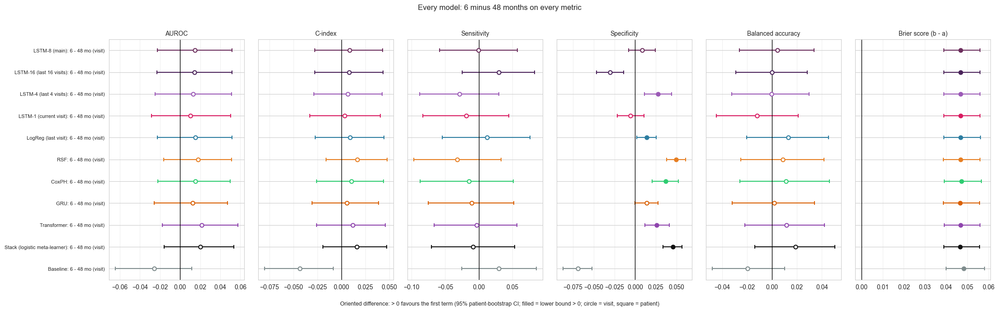

In [63]:
"""
Objective 2 (Section 8.1), H2 on all six metrics: OBJ2_MODEL's metric at the shortest horizon minus at the longest, each
horizon against its own competing-risk label, IPCW weights, censoring distribution and cost-weighted alarm threshold
(visit_thr_h), the same resamples at both horizons; criterion per metric: lower 95% bound > 0. Descriptive: every
metric at every horizon (OBJ2_MODEL with 95% CIs; every model as point estimates) and every model's difference.
"""
O2_NAME = "LSTM-8" if OBJ2_MODEL == "LSTM" else mlab(OBJ2_MODEL)
H_S, H_L = EVAL_HORIZONS_MONTHS[0], EVAL_HORIZONS_MONTHS[-1]
H2_LABEL = f"{O2_NAME}: {H_S} mo - {H_L} mo"
h2 = pd.DataFrame()
if model_res(OBJ2_MODEL) is None or not oof(OBJ2_MODEL):
    print(f"Objective 2 skipped: {OBJ2_MODEL} has no completed repeat.")
else:
    h2 = delta_long([(OBJ2_MODEL, OBJ2_MODEL, H2_LABEL)], "visit", H_S, h_b=H_L)
    print(f"H2 -- {O2_NAME}, every metric at {H_S} minus {H_L} months (oriented: > 0 = better at {H_S} months; Brier "
          f"{H_L} minus {H_S}), 95% patient-cluster bootstrap CI ({HYP_BOOT} resamples); * = lower bound > 0:")
    display(delta_wide(h2))
    record("H2", h2)

    # ---- every metric at every horizon: OBJ2_MODEL with CIs, every model as point estimates
    O2_TAB = pd.DataFrame({f"{h} mo": {CORE_LABEL[k]: fmt_v(core_value(OBJ2_MODEL, k, "visit", h))
                                       for k in LEVEL_METRICS["visit"]} for h in EVAL_HORIZONS_MONTHS}).T
    O2_TAB.insert(0, "Onset rate (IPCW)", [round(float(np.average(IPCW[h][0][IPCW[h][1] > 0],
                                                                  weights=IPCW[h][1][IPCW[h][1] > 0])), 3)
                                           for h in EVAL_HORIZONS_MONTHS])
    print(f"\n{O2_NAME} -- every metric by horizon (cumulative risk; value [95% CI]):")
    display(O2_TAB)
    O2_MODELS = [m for m in CV_MODELS + ["Baseline"] if model_res(m) is not None and oof(m)]
    O2_PTS = {m: {k: [(_cols(m, k, "visit", h, boot=False) if m != OBJ2_MODEL else _cols(m, k, "visit", h))[0]
                      for h in EVAL_HORIZONS_MONTHS] for k in LEVEL_METRICS["visit"]} for m in O2_MODELS}
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    for ax, k in zip(axes.ravel(), LEVEL_METRICS["visit"]):
        for m in O2_MODELS:
            ax.plot(EVAL_HORIZONS_MONTHS, O2_PTS[m][k], marker="o", label=mlab(m), **model_style(m))
        b_ = [core_value(OBJ2_MODEL, k, "visit", h) for h in EVAL_HORIZONS_MONTHS]
        ax.fill_between(EVAL_HORIZONS_MONTHS, [b["CI low"] for b in b_], [b["CI high"] for b in b_],
                        color=CV_COLORS[OBJ2_MODEL], alpha=0.15)
        ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
        ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)")
        ax.set_title(CORE_LABEL[k] + (" (lower = better; falls with the onset rate)" if k == "brier" else ""),
                     fontsize=11)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=7, ncol=2)
    plt.suptitle(f"Objective 2 -- every metric by horizon, every model (band: {O2_NAME} 95% CI)", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective2_metrics_by_horizon.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()

    # ---- every model's shortest - longest horizon difference, every metric
    o2_all = pd.concat([delta_long([(m, m, f"{mlab(m)}: {H_S} - {H_L} mo")], "visit", H_S, h_b=H_L)
                        for m in O2_MODELS], ignore_index=True)
    print(f"\nEvery model -- every metric at {H_S} minus {H_L} months (oriented; descriptive):")
    display(delta_wide(o2_all))
    forest_metrics(o2_all.assign(a=[r for r in o2_all["a"]]), f"Every model: {H_S} minus {H_L} months on every metric",
                   "revised_v21_objective2_test.png")
    O2_TAB.to_csv("objective2_metrics_by_horizon_revised_v21.csv")
    o2_all.to_csv("objective2_all_models_revised_v21.csv", index=False)
    pd.DataFrame({m: {f"{CORE_LABEL[k]} {h} mo": v for k in O2_PTS[m] for h, v in zip(EVAL_HORIZONS_MONTHS, O2_PTS[m][k])}
                  for m in O2_MODELS}).T.to_csv("metrics_by_horizon_all_models_revised_v21.csv")


## 11.12.5 Conclusion — Objective 2

Printed from this run's estimates (Sections 11.12.1–11.12.4).

In [64]:
"""Conclusion of Objective 2, written from the estimates of Sections 11.12.1-11.12.4: metric by metric."""
if h2.empty:
    txt = "Objective 2 could not be assessed: LSTM-8 has no completed repeat."
else:
    txt = (f"{O2_NAME} at {H_S} vs {H_L} months: " + "; ".join(
        f"{CORE_LABEL[k]} {core_value(OBJ2_MODEL, k, 'visit', H_S)['Value']:.3f} vs "
        f"{core_value(OBJ2_MODEL, k, 'visit', H_L)['Value']:.3f}" for k in LEVEL_METRICS["visit"]) + ". ")
    txt += (f"H2 (oriented differences, 95% CI): {verdict_words(h2, H2_LABEL, 'visit')} at the shorter horizon "
            f"({int(h2['Lower bound > 0'].sum())} of {len(h2)} metrics with a lower bound above 0). The Brier score "
            "falls with the onset rate, so its difference reflects the horizon's incidence as much as skill. ")
    _iv = [(iv, INT_RES.get((OBJ2_MODEL, iv))) for iv in OBJ2_INTERVALS]
    _iv = [(iv, r_) for iv, r_ in _iv if r_ is not None]
    if _iv:
        txt += ("In the exclusive intervals, among the patients still at risk at the start, the AUROC is "
                + ", ".join(f"{r_[0]:.3f} in months {iv[0]}-{iv[1]} (E/O {r_[3]:.2f})" for iv, r_ in _iv) + ". ")
    txt += ("Every horizon is recalibrated and thresholded inside the training folds, so the absolute risks and the "
            "alarm metrics at each horizon are validated; cumulative risk is the quantity to present to clinicians, "
            "the intervals say when the onsets fall.")
OBJ_CONCLUSIONS["Objective 2"] = txt
print(textwrap.fill(txt, 118))


LSTM-8 at 6 vs 48 months: AUROC 0.722 vs 0.707; C-index 0.723 vs 0.715; Sensitivity 0.658 vs 0.658; Specificity 0.632
vs 0.623; Balanced accuracy 0.645 vs 0.641; Brier score 0.008 vs 0.055. H2 (oriented differences, 95% CI): better on
Brier score; no clear difference on AUROC, C-index, Sensitivity, Specificity, Balanced accuracy at the shorter horizon
(1 of 6 metrics with a lower bound above 0). The Brier score falls with the onset rate, so its difference reflects the
horizon's incidence as much as skill. In the exclusive intervals, among the patients still at risk at the start, the
AUROC is 0.724 in months 0-12 (E/O 1.06), 0.707 in months 12-24 (E/O 1.04), 0.727 in months 24-36 (E/O 1.02), 0.695 in
months 36-48 (E/O 1.03). Every horizon is recalibrated and thresholded inside the training folds, so the absolute
risks and the alarm metrics at each horizon are validated; cumulative risk is the quantity to present to clinicians,
the intervals say when the onsets fall.


---
# 11.13 Objective 3 — Calibration and clinical utility

Whether the predicted risks are accurate, and whether acting on them yields net benefit.

| | Hypothesis | Estimand | Success criterion |
|---|---|---|---|
| **H3a** | Predicted risks are well calibrated | Calibration slope and intercept at the primary horizon (30 months) | Slope within [0.8, 1.2]; 95 % CI of the intercept includes 0 |
| **H3b** | The model provides net benefit over default strategies | Net benefit vs treat-all and treat-none | Net benefit higher than both at every threshold in [10 %, 40 %] |

Reported descriptively: sensitivity, specificity, PPV and NPV at fixed 30-month risks of 5 % and 10 % (and, in every
model table, at the cost-weighted alarm threshold), and discrimination and calibration by sex, ethnicity (race), age
and calendar era. Both hypotheses are shown for every model, LSTM-8 highlighted.

## 11.13.1 Calibration — all models

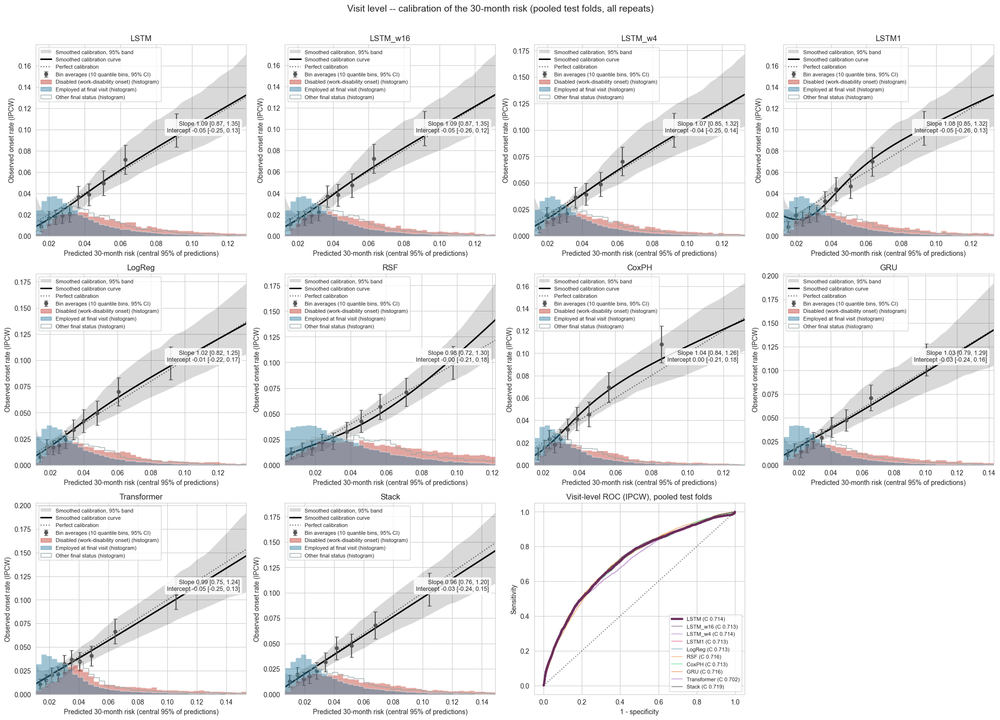

In [65]:
"""Visit-level calibration of every model (one panel each: IPCW deciles of the pooled out-of-fold 30-month risk, all
repeats stacked, with the slope and intercept of its table) and the IPCW ROC curves of all models."""
_ms = list(MODEL_RESULTS)
_ncols = 4
_nrows = int(np.ceil((len(_ms) + 1) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "visit", MODEL_RESULTS[m]["visit_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    p, y, w = r["p"], r["y"], r["w"]
    k = w > 0
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    ax.plot(fpr, tpr, **model_style(m),
            label=f"{m} (C {r['visit_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("Visit-level ROC (IPCW), pooled test folds"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Visit level -- calibration of the 30-month risk (pooled test folds, all repeats)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_calibration_visit_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 11.13.2 H3a, H3b: calibration criteria, decision curves and fixed risk thresholds

**H3a** for every model from its visit-level table (30 months, IPCW): calibration slope within [0.8, 1.2] and the
calibration intercept's 95 % CI containing 0. **H3b**: the visit-level decision curve of every model (LSTM-8 with a
95 % bootstrap band) against alarming at every visit and at none, drawn over 1–40 % with the hypothesis range (10–40 %)
shaded and the cost-weighted alarm threshold marked; per model, the number of thresholds in the range at which it is
above both. Then sensitivity, specificity, PPV, NPV and alerts per 100 visits at fixed 30-month risks of 5 % and 10 %,
and every model's AUROC within each calendar era.

H3a -- calibration of the 30-month risk, visit level (IPCW), value [95% patient-cluster bootstrap CI]:


,Calibration slope [95% CI],Calibration intercept [95% CI],Observed / expected,"Slope in [0.8, 1.2]",Intercept CI includes 0,Both
Model,,,,,,
LSTM-8 (main),"1.095 [0.866, 1.348]","-0.047 [-0.252, 0.129]",0.957,True,True,True
LSTM-16 (last 16 visits),"1.094 [0.869, 1.348]","-0.052 [-0.259, 0.124]",0.953,True,True,True
LSTM-4 (last 4 visits),"1.074 [0.846, 1.323]","-0.043 [-0.249, 0.135]",0.961,True,True,True
LSTM-1 (current visit),"1.078 [0.851, 1.322]","-0.052 [-0.259, 0.126]",0.953,True,True,True
LogReg (last visit),"1.025 [0.816, 1.254]","-0.006 [-0.217, 0.172]",0.994,True,True,True
RSF,"0.984 [0.719, 1.300]","-0.003 [-0.211, 0.179]",0.997,True,True,True
CoxPH,"1.045 [0.840, 1.256]","0.002 [-0.208, 0.179]",1.002,True,True,True
GRU,"1.032 [0.791, 1.291]","-0.028 [-0.241, 0.156]",0.974,True,True,True
Transformer,"0.995 [0.753, 1.242]","-0.046 [-0.254, 0.135]",0.958,True,True,True



H3b -- net benefit per landmark visit (IPCW, 30 months) against treat-all and treat-none at 31 thresholds from 10% to 40%:


,Thresholds above both,Highest threshold above both,Mean net benefit over the range,Share of resamples above both over the whole range,Met
Model,,,,,
LSTM-8 (main),13 of 31,22%,0.0003,0.005,False
LSTM-16 (last 16 visits),13 of 31,22%,0.0003,0.005,False
LSTM-4 (last 4 visits),12 of 31,21%,0.0003,0.005,False
LSTM-1 (current visit),12 of 31,21%,0.0003,0.010,False
LogReg (last visit),14 of 31,23%,0.0004,0.090,False
RSF,13 of 31,22%,0.0003,0.000,False
CoxPH,10 of 31,19%,0.0002,0.050,False
GRU,14 of 31,23%,0.0002,0.030,False
Transformer,18 of 31,39%,0.0003,0.000,False


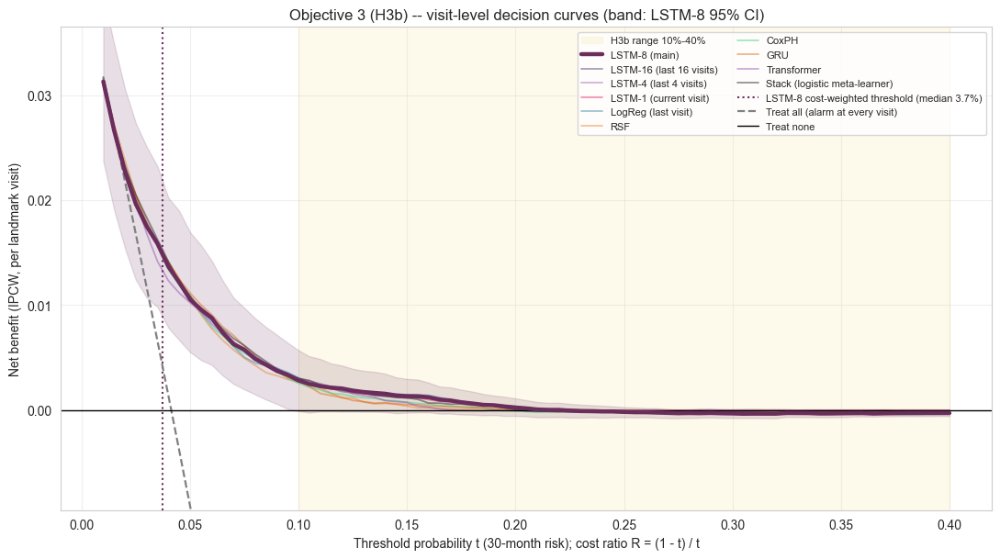


FIXED 30-MONTH RISK THRESHOLDS -- visit level (IPCW; 95% patient-cluster bootstrap CI) and patient level (Section 11.6 rule with the fixed threshold; mean over repeats):


Visit Sensitivity  \
Threshold Model                                                 
5%        LSTM-8 (main)                  0.564 [0.485, 0.634]   
          LSTM-16 (last 16 visits)       0.567 [0.491, 0.637]   
          LSTM-4 (last 4 visits)         0.564 [0.485, 0.633]   
          LSTM-1 (current visit)         0.571 [0.488, 0.636]   
          LogReg (last visit)            0.533 [0.454, 0.602]   
          RSF                            0.629 [0.561, 0.700]   
          CoxPH                          0.510 [0.427, 0.586]   
          GRU                            0.570 [0.489, 0.645]   
          Transformer                    0.530 [0.456, 0.596]   
          Stack (logistic meta-learner)  0.582 [0.501, 0.642]   
10%       LSTM-8 (main)                  0.183 [0.123, 0.227]   
          LSTM-16 (last 16 visits)       0.185 [0.125, 0.228]   
          LSTM-4 (last 4 visits)         0.188 [0.128, 0.231]   
          LSTM-1 (current visit)         0.191 [0.133, 0.233]   
          LogReg (last visit)            0.192 [0.133, 0.236]   
          RSF                            0.209 [0.149, 0.263]   
          CoxPH                          0.164 [0.115, 0.204]   
          GRU                            0.219 [0.158, 0.276]   
          Transformer                    0.245 [0.185, 0.301]   
          Stack (logistic meta-learner)  0.239 [0.173, 0.291]   

                                            Visit Specificity  \
Threshold Model                                                 
5%        LSTM-8 (main)                  0.747 [0.723, 0.775]   
          LSTM-16 (last 16 visits)       0.746 [0.722, 0.773]   
          LSTM-4 (last 4 visits)         0.750 [0.726, 0.776]   
          LSTM-1 (current visit)         0.744 [0.720, 0.771]   
          LogReg (last visit)            0.771 [0.746, 0.797]   
          RSF                            0.697 [0.667, 0.726]   
          CoxPH                          0.798 [0.772, 0.822]   
          GRU                            0.754 [0.726, 0.781]   
          Transformer                    0.769 [0.744, 0.796]   
          Stack (logistic meta-learner)  0.739 [0.713, 0.768]   
10%       LSTM-8 (main)                  0.956 [0.946, 0.966]   
          LSTM-16 (last 16 visits)       0.955 [0.945, 0.965]   
          LSTM-4 (last 4 visits)         0.954 [0.944, 0.964]   
          LSTM-1 (current visit)         0.953 [0.944, 0.964]   
          LogReg (last visit)            0.954 [0.945, 0.963]   
          RSF                            0.944 [0.934, 0.955]   
          CoxPH                          0.960 [0.952, 0.969]   
          GRU                            0.941 [0.927, 0.953]   
          Transformer                    0.933 [0.920, 0.946]   
          Stack (logistic meta-learner)  0.936 [0.924, 0.948]   

                                                    Visit PPV  \
Threshold Model                                                 
5%        LSTM-8 (main)                  0.088 [0.071, 0.110]   
          LSTM-16 (last 16 visits)       0.088 [0.071, 0.111]   
          LSTM-4 (last 4 visits)         0.089 [0.071, 0.111]   
          LSTM-1 (current visit)         0.088 [0.070, 0.110]   
          LogReg (last visit)            0.091 [0.072, 0.117]   
          RSF                            0.082 [0.065, 0.104]   
          CoxPH                          0.098 [0.078, 0.123]   
          GRU                            0.091 [0.073, 0.115]   
          Transformer                    0.090 [0.071, 0.113]   
          Stack (logistic meta-learner)  0.088 [0.070, 0.111]   
10%       LSTM-8 (main)                  0.151 [0.098, 0.203]   
          LSTM-16 (last 16 visits)       0.151 [0.099, 0.203]   
          LSTM-4 (last 4 visits)         0.150 [0.097, 0.201]   
          LSTM-1 (current visit)         0.150 [0.101, 0.200]   
          LogReg (last visit)            0.153 [0.101, 0.206]   
          RSF                            0.139 [0.093, 0.177]   
          Co


AUROC (30 months) within each calendar era of the landmark visit (95% patient-cluster bootstrap CI):


,Landmarks,Onsets <= 30 mo,LSTM-8 (main),LSTM-16 (last 16 visits),LSTM-4 (last 4 visits),LSTM-1 (current visit),LogReg (last visit),RSF,CoxPH,GRU,Transformer,Stack (logistic meta-learner)
Era,,,,,,,,,,,,
< 2000,1931,133,"0.780 [0.723, 0.830]","0.781 [0.724, 0.830]","0.781 [0.725, 0.831]","0.776 [0.717, 0.825]","0.785 [0.725, 0.833]","0.762 [0.673, 0.825]","0.787 [0.729, 0.834]","0.803 [0.742, 0.853]","0.798 [0.724, 0.852]","0.792 [0.725, 0.844]"
2000-05,2618,153,"0.699 [0.623, 0.774]","0.698 [0.623, 0.773]","0.700 [0.623, 0.775]","0.703 [0.628, 0.775]","0.705 [0.631, 0.782]","0.675 [0.594, 0.751]","0.702 [0.625, 0.777]","0.689 [0.605, 0.765]","0.688 [0.604, 0.765]","0.697 [0.621, 0.774]"
2006-11,3795,193,"0.661 [0.575, 0.739]","0.660 [0.574, 0.739]","0.659 [0.574, 0.738]","0.660 [0.577, 0.741]","0.648 [0.565, 0.727]","0.671 [0.589, 0.749]","0.641 [0.557, 0.721]","0.671 [0.584, 0.754]","0.638 [0.557, 0.718]","0.663 [0.581, 0.744]"
>= 2012,6040,163,"0.652 [0.542, 0.747]","0.654 [0.547, 0.747]","0.653 [0.543, 0.746]","0.651 [0.545, 0.745]","0.657 [0.553, 0.753]","0.692 [0.593, 0.781]","0.673 [0.573, 0.763]","0.668 [0.557, 0.765]","0.655 [0.547, 0.752]","0.683 [0.578, 0.773]"


In [66]:
"""
Objective 3 (Section 8.1).
  H3a  calibration at the primary horizon (30 months), every model: the calibration slope (logistic regression of the
       outcome on logit(risk)) within H3A_SLOPE_RANGE, and the 95% CI of the calibration intercept (calibration-in-the-
       large, slope fixed at 1) containing 0; visit level, IPCW, from each model's metric table.
  H3b  IPCW net benefit per landmark visit of alarming when the calibrated 30-month risk >= t, mean over repeats,
       against treat-all (alarm at every visit) and treat-none (0), at every t in DCA_RANGE; criterion: above both at
       every threshold of the range (the bootstrap share of resamples in which it holds is reported with it). The
       curves are drawn over DCA_PLOT_RANGE with the hypothesis range shaded and the cost-weighted thresholds marked.
Then (descriptive) the fixed thresholds DECISION_THRESHOLDS and every model's AUROC within each calendar era.
"""
# ---- H3a
_rows = []
for m in [x for x in CV_MODELS + ["Baseline"] if model_res(x) is not None]:
    vt = model_res(m)["visit_table"]
    s_, i_ = vt.loc["cal_slope"], vt.loc["cal_intercept"]
    slope_ok = bool(np.isfinite(s_["Value"]) and H3A_SLOPE_RANGE[0] <= s_["Value"] <= H3A_SLOPE_RANGE[1])
    icpt_ok = bool(np.isfinite(i_["CI low"]) and i_["CI low"] <= 0 <= i_["CI high"])
    _rows.append({"Model": mlab(m), "Calibration slope [95% CI]": _o1_cell(vt, "cal_slope"),
                  "Calibration intercept [95% CI]": _o1_cell(vt, "cal_intercept"),
                  "Observed / expected": round(float(vt.loc["oe_ratio", "Value"]), 3),
                  f"Slope in [{H3A_SLOPE_RANGE[0]}, {H3A_SLOPE_RANGE[1]}]": slope_ok,
                  "Intercept CI includes 0": icpt_ok, "Both": slope_ok and icpt_ok})
    OBJ_ROWS.append({"Hypothesis": "H3a", "Comparison": mlab(m), "Level": "visit", "Metric": "calibration",
                     "Estimate [95% CI]": f"slope {_o1_cell(vt, 'cal_slope')}; intercept {_o1_cell(vt, 'cal_intercept')}",
                     "Criterion": f"slope in [{H3A_SLOPE_RANGE[0]}, {H3A_SLOPE_RANGE[1]}] and intercept CI includes 0",
                     "Met": slope_ok and icpt_ok})
h3a = pd.DataFrame(_rows).set_index("Model")
print(f"H3a -- calibration of the {PRIMARY_HORIZON_MONTHS}-month risk, visit level (IPCW), value [95% patient-cluster "
      "bootstrap CI]:")
display(h3a)

# ---- H3b
DCA_GRID = np.round(np.linspace(DCA_RANGE[0], DCA_RANGE[1], 31), 4)
DCA_PLOT_GRID = np.round(np.linspace(DCA_PLOT_RANGE[0], DCA_PLOT_RANGE[1], 79), 4)
DCA_BOOT = HYP_MULT[:200]
DCA_MODELS = [m for m in CV_MODELS if oof(m)]
_zero = np.zeros(len(Y30))


def nb_curve(m, grid, mult=1.0):
    return np.mean([ipcw_net_benefit(Y30, p, W30 * mult, grid)[0] for p in oof(m).values()], axis=0)


NB_ALL = ipcw_net_benefit(Y30, _zero, W30, DCA_GRID)[1]
NB_REF = np.maximum(NB_ALL, 0.0)
_Bref = np.array([np.maximum(ipcw_net_benefit(Y30, _zero, W30 * mm, DCA_GRID)[1], 0.0) for mm in DCA_BOOT])
_rows, H3B_ABOVE = [], {}
for m in DCA_MODELS:
    nb_ = nb_curve(m, DCA_GRID)
    above = nb_ > NB_REF
    H3B_ABOVE[m] = above
    _B = np.array([nb_curve(m, DCA_GRID, mm) for mm in DCA_BOOT])
    share = float(np.mean(np.all(_B > _Bref, axis=1)))
    _rows.append({"Model": mlab(m), "Thresholds above both": f"{int(above.sum())} of {len(DCA_GRID)}",
                  "Highest threshold above both": f"{DCA_GRID[above].max():.0%}" if above.any() else "none",
                  "Mean net benefit over the range": float(nb_.mean()),
                  "Share of resamples above both over the whole range": share, "Met": bool(above.all())})
    OBJ_ROWS.append({"Hypothesis": "H3b", "Comparison": mlab(m), "Level": "visit", "Metric": "net benefit",
                     "Estimate [95% CI]": f"above both at {int(above.sum())}/{len(DCA_GRID)} thresholds; whole range "
                                          f"in {share:.0%} of resamples",
                     "Criterion": f"above treat-all and treat-none at every threshold in "
                                  f"{DCA_RANGE[0]:.0%}-{DCA_RANGE[1]:.0%}", "Met": bool(above.all())})
h3b = pd.DataFrame(_rows).set_index("Model")
print(f"\nH3b -- net benefit per landmark visit (IPCW, 30 months) against treat-all and treat-none at {len(DCA_GRID)} "
      f"thresholds from {DCA_RANGE[0]:.0%} to {DCA_RANGE[1]:.0%}:")
display(h3b.round(4))

NB = {m: nb_curve(m, DCA_PLOT_GRID) for m in DCA_MODELS}
NB_ALL_PLOT = ipcw_net_benefit(Y30, _zero, W30, DCA_PLOT_GRID)[1]
dca_tab = pd.DataFrame({**{mlab(m): NB[m] for m in DCA_MODELS}, "Treat all": NB_ALL_PLOT, "Treat none": 0.0},
                       index=pd.Index(DCA_PLOT_GRID, name="Threshold (30-month risk)"))
_thr_med = {m: float(np.nanmedian(np.concatenate([pr["visit_thr"]["target"] for (mm, _), pr in
                                                  model_res(m)["preds"].items() if mm == m])))
            for m in DCA_MODELS if model_res(m) is not None}
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.axvspan(DCA_RANGE[0], DCA_RANGE[1], color="#f1c40f", alpha=0.08, label=f"H3b range {DCA_RANGE[0]:.0%}-{DCA_RANGE[1]:.0%}")
for m in DCA_MODELS:
    ax.plot(DCA_PLOT_GRID, NB[m], label=mlab(m), **model_style(m))
if "LSTM" in NB:
    _Bp = np.array([nb_curve("LSTM", DCA_PLOT_GRID, mm) for mm in DCA_BOOT])
    ax.fill_between(DCA_PLOT_GRID, *np.percentile(_Bp, [2.5, 97.5], axis=0), color=CV_COLORS["LSTM"], alpha=0.15)
    if "LSTM" in _thr_med:
        ax.axvline(_thr_med["LSTM"], color=CV_COLORS["LSTM"], ls=":", lw=1.5,
                   label=f"LSTM-8 cost-weighted threshold (median {_thr_med['LSTM']:.1%})")
ax.plot(DCA_PLOT_GRID, NB_ALL_PLOT, color="gray", ls="--", lw=1.6, label="Treat all (alarm at every visit)")
ax.axhline(0, color="black", lw=1, label="Treat none")
_top = max(float(np.nanmax(list(NB.values()))) if NB else 0.0, float(NB_ALL_PLOT.max()), 1e-4)
ax.set_ylim(-0.3 * _top, 1.15 * _top)
ax.set_xlabel("Threshold probability t (30-month risk); cost ratio R = (1 - t) / t")
ax.set_ylabel("Net benefit (IPCW, per landmark visit)")
ax.set_title("Objective 3 (H3b) -- visit-level decision curves (band: LSTM-8 95% CI)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective3_decision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- fixed thresholds: visit level (95% CI) and patient level
def _visit_stats(m, t, mult=1.0):
    out = []
    for p in oof(m).values():
        w = W30 * mult
        k = w > 0
        a = p >= t
        tp, fp, fn, tn = w_confusion(Y30[k], a[k], w[k])
        div = lambda x, y_: x / y_ if y_ > 0 else np.nan
        out.append([div(tp, tp + fn), div(tn, tn + fp), div(tp, tp + fp), div(tn, tn + fn), 100.0 * float(np.mean(a))])
    return np.nanmean(np.array(out, float), axis=0)


THR_COLS = ["Sensitivity", "Specificity", "PPV", "NPV", "Alerts / 100 visits"]
thr_rows = []
for t in DECISION_THRESHOLDS:
    for m in DCA_MODELS:
        est = _visit_stats(m, t)
        B = np.array([_visit_stats(m, t, mm) for mm in DCA_BOOT])
        lo_, hi_ = np.nanpercentile(B, [2.5, 97.5], axis=0)
        pcs = [patient_counts(patient_frame(ALL_ROWS, p, np.full(len(p), t))) for p in oof(m).values()]
        pt = np.nanmean([[c["TP"] / max(c["TP"] + c["FN"], 1), c["TN"] / max(c["TN"] + c["FP"], 1),
                          c["TP"] / (c["TP"] + c["FP"]) if c["TP"] + c["FP"] else np.nan,
                          c["TN"] / (c["TN"] + c["FN"]) if c["TN"] + c["FN"] else np.nan] for c in pcs], axis=0)
        thr_rows.append({"Threshold": f"{t:.0%}", "Model": mlab(m),
                         **{f"Visit {c}": (f"{e:.3f} [{l:.3f}, {h:.3f}]" if c != "Alerts / 100 visits" else f"{e:.1f}")
                            for c, e, l, h in zip(THR_COLS, est, lo_, hi_)},
                         **{f"Patient {c}": round(v, 3) for c, v in zip(THR_COLS[:4], pt)}})
thr_df = pd.DataFrame(thr_rows).set_index(["Threshold", "Model"])
print("\nFIXED 30-MONTH RISK THRESHOLDS -- visit level (IPCW; 95% patient-cluster bootstrap CI) and patient level "
      "(Section 11.6 rule with the fixed threshold; mean over repeats):")
display(thr_df)

# ---- every model's AUROC within each calendar era (subgroup: era)
era_rows3 = []
for e, (_, _, era_lab) in enumerate(ERA_BANDS):
    w_e = W30 * (ERA_IDX_LAND == e)
    n_ev = int(((Y30 == 1) & (w_e > 0)).sum())
    row = {"Era": era_lab, "Landmarks": int((w_e > 0).sum()), "Onsets <= 30 mo": n_ev}
    for m in DCA_MODELS:
        if n_ev > 0:
            a_, B_ = model_auc(m, w=w_e, tag=f"era{e}")
            row[mlab(m)] = f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]"
    era_rows3.append(row)
era_auc3 = pd.DataFrame(era_rows3).set_index("Era")
print("\nAUROC (30 months) within each calendar era of the landmark visit (95% patient-cluster bootstrap CI):")
display(era_auc3)
dca_tab.to_csv("objective3_decision_curves_revised_v21.csv")
thr_df.to_csv("objective3_fixed_thresholds_revised_v21.csv")
era_auc3.to_csv("objective3_auroc_by_era_revised_v21.csv")
h3a.to_csv("objective3_h3a_calibration_revised_v21.csv")
h3b.to_csv("objective3_h3b_net_benefit_revised_v21.csv")


## 11.13.3 Utility of each model's alarm rule

Every model's AUROC, the cost ratio of its folds and the one implied by its alarm thresholds, and the visit- and
patient-level net benefit of its alarm rule against flagging everyone.

In [67]:
"""
AUROC, cost ratios and net benefit of every model (pooled test folds; no refitting): the cost ratio R of the folds and the one
implied by the (era-standardised) alarm thresholds, and the visit- and patient-level net benefit of the alarm rule.
"""
# ------------------------------------------------------------------------------------------------ all models
eu_rows = []
pi = COHORT_EVENT_SHARE
R_pt = (1 - pi) / pi                                   # patient level: the data-driven R at the cohort's event share
t_pt = 1.0 / (1.0 + R_pt)
for m in [x for x in CV_MODELS if oof(x) and x in MODEL_RESULTS]:
    a_p, B_p = model_auc(m)
    preds = MODEL_RESULTS[m]["preds"]
    thr = np.concatenate([pr["visit_thr"]["target"] for (mm, _), pr in preds.items() if mm == m])
    thr = thr[np.isfinite(thr) & (thr > 0)]
    R_impl = (1 - thr) / thr
    R_fold = [v.get("cost_ratio", np.nan) for k, v in cv_state["folds"].items() if k[0] == m]
    res_df = MODEL_RESULTS[m]["res_df"]
    pt = MODEL_RESULTS[m]["patient_table"]
    sens, spec = pt.loc["sensitivity", "Value"], pt.loc["specificity", "Value"]
    nb_rule = sens * pi - (1 - spec) * (1 - pi) * t_pt / (1 - t_pt)
    nb_all = pi - (1 - pi) * t_pt / (1 - t_pt)
    eu_rows.append({"Model": MODEL_LABELS.get(m, m),
                    "AUROC": f"{a_p:.3f} [{np.percentile(B_p, 2.5):.3f}, {np.percentile(B_p, 97.5):.3f}]",
                    "Cost ratio R of the folds, median": float(np.nanmedian(R_fold)),
                    "Implied cost ratio of the alarm thresholds, median [IQR]":
                        f"{np.median(R_impl):.0f} [{np.percentile(R_impl, 25):.0f}, {np.percentile(R_impl, 75):.0f}]",
                    "Visit NB at the folds' R": float(res_df["net_benefit"].mean()),
                    "Visit NB, alarm at every visit": float(res_df["nb_treat_all"].mean()),
                    "Patient NB of the alarm rule": nb_rule,
                    "Patient NB, flag every patient": nb_all,
                    "Fewer unnecessary flags / 100 patients vs flagging all": 100 * (nb_rule - nb_all) / (t_pt / (1 - t_pt))})
eu_df = pd.DataFrame(eu_rows).set_index("Model")
print(f"\nALL MODELS -- AUROC, the cost ratio R of the folds and the one implied by the (era-standardised) alarm thresholds, "
      f"R = (1 - t) / t, and net benefit at the data-driven R (visit level: each fold's R; patient level: R = (1 - pi) / pi "
      f"= {R_pt:.1f} at the cohort's event share pi = {pi:.1%}, where flagging every patient has net benefit 0 and the "
      f"rule's net benefit is pi x (sensitivity + specificity - 1)):")
display(eu_df.round(4))
eu_df.to_csv("auroc_and_utility_revised_v21.csv")


ALL MODELS -- AUROC, the cost ratio R of the folds and the one implied by the (era-standardised) alarm thresholds, R = (1 - t) / t, and net benefit at the data-driven R (visit level: each fold's R; patient level: R = (1 - pi) / pi = 6.1 at the cohort's event share pi = 14.2%, where flagging every patient has net benefit 0 and the rule's net benefit is pi x (sensitivity + specificity - 1)):


,AUROC,"Cost ratio R of the folds, median","Implied cost ratio of the alarm thresholds, median [IQR]",Visit NB at the folds' R,"Visit NB, alarm at every visit",Patient NB of the alarm rule,"Patient NB, flag every patient",Fewer unnecessary flags / 100 patients vs flagging all
Model,,,,,,,,
LSTM-8 (main),"0.714 [0.661, 0.759]",23.2987,"26 [19, 36]",0.0121,0.0,0.0768,0.0,46.5340
LSTM-16 (last 16 visits),"0.713 [0.661, 0.758]",23.2987,"25 [19, 35]",0.0122,0.0,0.0796,0.0,48.2498
LSTM-4 (last 4 visits),"0.714 [0.661, 0.758]",23.2987,"26 [20, 37]",0.0123,0.0,0.0787,0.0,47.6912
LSTM-1 (current visit),"0.713 [0.660, 0.758]",23.2987,"26 [20, 37]",0.0119,0.0,0.0766,0.0,46.3963
LogReg (last visit),"0.713 [0.660, 0.758]",23.2987,"29 [21, 44]",0.0117,0.0,0.0729,0.0,44.1700
RSF,"0.716 [0.666, 0.759]",23.2987,"31 [21, 42]",0.0110,0.0,0.0511,0.0,30.9739
CoxPH,"0.713 [0.662, 0.757]",23.2987,"29 [22, 39]",0.0111,0.0,0.0727,0.0,44.0458
GRU,"0.716 [0.662, 0.762]",23.2987,"25 [18, 38]",0.0128,0.0,0.0809,0.0,49.0137
Transformer,"0.702 [0.648, 0.748]",23.2987,"26 [18, 41]",0.0125,0.0,0.0769,0.0,46.5997


## 11.13.4 Alarms by calendar era: era-standardised vs absolute threshold

Section 9.1. For every model, from the pooled test folds (no refitting), per calendar era of the landmark visit: the
onset rate, the mean predicted risk and observed / expected ratio, and the alarm rate,
sensitivity and specificity with the **era-standardised** threshold (the alarms of every other table) and with the
**single absolute threshold** of revised_v11 (learned on the same training folds). With the absolute threshold the alarm
rate follows the era's onset rate; with the era-standardised threshold it should be similar across eras, with
sensitivity and specificity closer to those of the whole cohort.

Alarms by calendar era of the landmark visit, 30-month label (IPCW), mean over CV repeats. Alarms in every other table: era-standardised.


Landmarks  Onset rate  Mean risk    O/E  \
Model       Era                                                
LSTM        < 2000      1931.0       0.064      0.067  0.965   
            2000-05     2618.0       0.054      0.062  0.881   
            2006-11     3795.0       0.047      0.043  1.103   
            >= 2012     6040.0       0.025      0.028  0.885   
LSTM_w16    < 2000      1931.0       0.064      0.067  0.960   
            2000-05     2618.0       0.054      0.062  0.877   
            2006-11     3795.0       0.047      0.043  1.098   
            >= 2012     6040.0       0.025      0.028  0.880   
LSTM_w4     < 2000      1931.0       0.064      0.067  0.964   
            2000-05     2618.0       0.054      0.062  0.878   
            2006-11     3795.0       0.047      0.043  1.107   
            >= 2012     6040.0       0.025      0.028  0.900   
LSTM1       < 2000      1931.0       0.064      0.067  0.955   
            2000-05     2618.0       0.054      0.063  0.865   
            2006-11     3795.0       0.047      0.043  1.093   
            >= 2012     6040.0       0.025      0.028  0.899   
LogReg      < 2000      1931.0       0.064      0.064  1.013   
            2000-05     2618.0       0.054      0.060  0.904   
            2006-11     3795.0       0.047      0.041  1.146   
            >= 2012     6040.0       0.025      0.027  0.922   
RSF         < 2000      1931.0       0.064      0.066  0.970   
            2000-05     2618.0       0.054      0.059  0.910   
            2006-11     3795.0       0.047      0.041  1.160   
            >= 2012     6040.0       0.025      0.026  0.944   
CoxPH       < 2000      1931.0       0.064      0.062  1.041   
            2000-05     2618.0       0.054      0.057  0.953   
            2006-11     3795.0       0.047      0.039  1.202   
            >= 2012     6040.0       0.025      0.029  0.849   
GRU         < 2000      1931.0       0.064      0.075  0.864   
            2000-05     2618.0       0.054      0.063  0.864   
            2006-11     3795.0       0.047      0.041  1.156   
            >= 2012     6040.0       0.025      0.024  1.018   
Transformer < 2000      1931.0       0.064      0.077  0.838   
            2000-05     2618.0       0.054      0.065  0.837   
            2006-11     3795.0       0.047      0.042  1.130   
            >= 2012     6040.0       0.025      0.024  1.040   
Stack       < 2000      1931.0       0.064      0.072  0.892   
            2000-05     2618.0       0.054      0.064  0.847   
            2006-11     3795.0       0.047      0.041  1.157   
            >= 2012     6040.0       0.025      0.025  0.988   

                     Alarm rate (era-standardised)  \
Model       Era                                      
LSTM        < 2000                           0.449   
            2000-05                          0.475   
            2006-11                          0.371   
            >= 2012                          0.327   
LSTM_w16    < 2000                           0.443   
            2000-05                          0.466   
            2006-11                          0.364   
            >= 2012                          0.314   
LSTM_w4     < 2000                           0.454   
            2000-05                          0.482   
            2006-11                          0.372   
            >= 2012                          0.327   
LSTM1       < 2000                           0.483   
            2000-05                          0.501   
            2006-11                          0.384   
            >= 2012                          0.334   
LogReg      < 2000                           0.415   
            2000-05                          0.476   
            2006-11                          0.397   
            >= 2012                          0.406   
RSF         < 2000                           0.361   
            2000-05                          0.519   
            2006-11                 

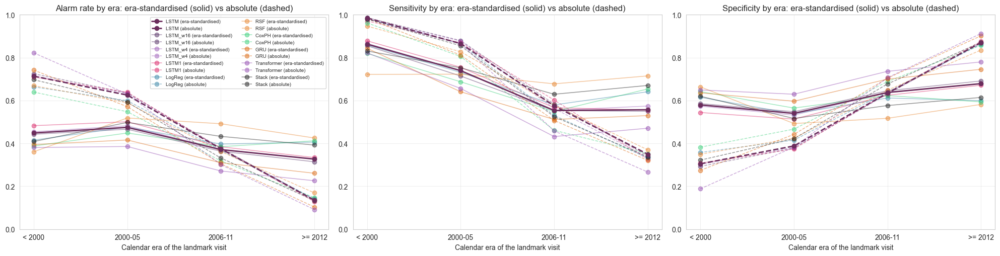

In [68]:
"""
Alarms by calendar era (Section 11.13.4), from the pooled test folds of every model: onset rate, mean risk, O/E,
and the alarm rate / sensitivity / specificity under the era-standardised and the absolute threshold,
IPCW-weighted (30-month label), mean over CV repeats.
"""
ERA_LABELS = [lab for *_, lab in ERA_BANDS]
ERA_OF_LAND = pd.cut(CAL_YEAR_ALL, [a for a, _, _ in ERA_BANDS] + [ERA_BANDS[-1][1]], right=False,
                     labels=ERA_LABELS).astype(str)
RULES = [("era-standardised", "target"), ("absolute", "absolute")]


def era_rows(model):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    out = []
    for (m, r), pr in preds_all.items():
        if m != model:
            continue
        p = pr["P"][:, PRIMARY_COL]
        for lab in ERA_LABELS:
            k = (ERA_OF_LAND == lab) & (w > 0)
            yy, ww, pp = y[k], w[k], p[k]
            row = {"Model": model, "Era": lab, "repeat": r, "Landmarks": int(k.sum()),
                   "Onset rate": float(np.average(yy, weights=ww)), "Mean risk": float(np.average(pp, weights=ww)),
                   "O/E": float((ww * yy).sum() / (ww * pp).sum())}
            for rule, key in RULES:
                tp, fp, fn, tn = w_confusion(yy, (p >= pr["visit_thr"][key])[k], ww)
                row[f"Alarm rate ({rule})"] = (tp + fp) / max(tp + fp + fn + tn, 1e-12)
                row[f"Sensitivity ({rule})"] = tp / max(tp + fn, 1e-12)
                row[f"Specificity ({rule})"] = tn / max(tn + fp, 1e-12)
            out.append(row)
    return out


era_df = pd.DataFrame([row for m in MODEL_RESULTS for row in era_rows(m)])
if era_df.empty:
    print("Run the model sections first.")
else:
    era_tab = era_df.drop(columns="repeat").groupby(["Model", "Era"], sort=False).mean()
    era_tab.to_csv("alarms_by_era_revised_v21.csv")
    print(f"Alarms by calendar era of the landmark visit, {PRIMARY_HORIZON_MONTHS}-month label (IPCW), mean over CV "
          f"repeats. Alarms in every other table: {'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'}.")
    display(era_tab.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2))
    xs = np.arange(len(ERA_LABELS))
    for ax, what in zip(axes, ["Alarm rate", "Sensitivity", "Specificity"]):
        for m in MODEL_RESULTS:
            d = era_tab.loc[m]
            for rule, _ in RULES:
                ax.plot(xs, d.loc[ERA_LABELS, f"{what} ({rule})"].values, marker="o",
                        ls="-" if rule == "era-standardised" else "--", label=f"{m} ({rule})",
                        **model_style(m, 2.0, 1.1))
        ax.set_xticks(xs); ax.set_xticklabels(ERA_LABELS); ax.set_xlabel("Calendar era of the landmark visit")
        ax.set_ylim(0, 1); ax.set_title(f"{what} by era: era-standardised (solid) vs absolute (dashed)"); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_alarms_by_era.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.13.5 Patient-level summary — all models

Every metric of the per-model patient tables, value [95 % patient-bootstrap CI]: all evaluable patients, each final
status, specificity by age band, LaTeX rows, and all tables of both levels in `metric_tables_model_revised_v21.csv`.

In [69]:
"""
Patient-level summary for all models (visit alarms accumulated per patient; Section 11.6): value [95% patient-bootstrap
CI] for all evaluable patients, then per final-status stratum, specificity by age band, LaTeX rows, and every table of
both levels in metric_tables_model_revised_v21.csv.
"""
_f0 = next(iter(next(iter(MODEL_RESULTS.values()))["preds"].values()))["pt"]
patient_summary = wide_table("patient_table")
print(f"PATIENT LEVEL -- all models, all evaluable patients ({int(_f0.y.sum())} event vs {int((_f0.y == 0).sum())} "
      f"event-free): value [95% patient bootstrap CI], mean over CV repeats")
display(patient_summary)
for _st in STRATA:
    print(f"\nPATIENT LEVEL -- event patients vs event-free '{_st}' "
          f"({int(((_f0.y == 0) & (_f0.stratum == _st)).sum())} patients):")
    display(pd.DataFrame({m: {row["Metric"]: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                                              if np.isfinite(row["Value"]) else "n/a")
                               for _, row in r["stratum_tables"][_st].drop(index=STRATUM_DROP, errors="ignore").iterrows()}
                          for m, r in MODEL_RESULTS.items()}).T)
print("\nSpecificity by age at the end of the window (event-free patients in the band):")
display(pd.DataFrame({m: age_band_table(r)["Specificity"] for m, r in MODEL_RESULTS.items()}).T)
print("\nLaTeX rows, patient level, all evaluable patients (" + " & ".join(patient_summary.columns) + "):")
print("\n".join(latex_table_rows("patient_table")))
metric_tables_long = pd.concat(
    [r["visit_table"].assign(model=m, level="visit") for m, r in MODEL_RESULTS.items()]
    + [r["patient_table"].assign(model=m, level="patient: all evaluable") for m, r in MODEL_RESULTS.items()]
    + [r["stratum_tables"][st].assign(model=m, level=f"patient: {st}") for m, r in MODEL_RESULTS.items()
       for st in STRATA]
    + [r["age_tables"][lab].assign(model=m, level=f"patient: age {lab}") for m, r in MODEL_RESULTS.items()
       for _, _, lab in AGE_BANDS])
metric_tables_long.to_csv("metric_tables_model_revised_v21.csv")

print("\nAlert burden over the whole follow-up (alarms at each fold's visit threshold; mean (SD) over repeats). "
      "'Stayed employed' = no onset or other exit after any landmark and employed at the last recorded status; "
      "'never alerted' = no alarm at any of their landmarks:")
display(pd.DataFrame({m: alert_burden_summary(m, r["preds"]) for m, r in MODEL_RESULTS.items()}).T)

PATIENT LEVEL -- all models, all evaluable patients (148 event vs 909 event-free): value [95% patient bootstrap CI], mean over CV repeats


,Concordance Index,Brier Score,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.915 [0.893, 0.936]","0.073 [0.061, 0.084]","1.016 [0.869, 1.187]","-0.091 [-0.313, 0.130]","0.955 [0.851, 1.069]","0.838 [0.785, 0.888]","0.704 [0.677, 0.728]","0.317 [0.275, 0.362]","0.964 [0.951, 0.976]","0.771 [0.741, 0.800]","0.320 [0.296, 0.345]","0.963 [0.952, 0.975]"
LSTM_w16,"0.916 [0.893, 0.936]","0.073 [0.062, 0.084]","1.024 [0.876, 1.198]","-0.097 [-0.317, 0.121]","0.952 [0.848, 1.065]","0.846 [0.793, 0.896]","0.716 [0.688, 0.740]","0.327 [0.285, 0.372]","0.966 [0.954, 0.978]","0.781 [0.752, 0.809]","0.330 [0.306, 0.355]","0.966 [0.954, 0.977]"
LSTM_w4,"0.916 [0.893, 0.936]","0.072 [0.061, 0.084]","1.003 [0.860, 1.176]","-0.081 [-0.306, 0.141]","0.960 [0.855, 1.075]","0.850 [0.796, 0.899]","0.706 [0.678, 0.730]","0.322 [0.280, 0.366]","0.967 [0.954, 0.978]","0.778 [0.749, 0.806]","0.325 [0.301, 0.349]","0.966 [0.955, 0.977]"
LSTM1,"0.917 [0.895, 0.937]","0.072 [0.061, 0.083]","1.010 [0.867, 1.188]","-0.091 [-0.314, 0.130]","0.955 [0.852, 1.068]","0.845 [0.790, 0.894]","0.696 [0.669, 0.721]","0.313 [0.273, 0.357]","0.965 [0.952, 0.977]","0.770 [0.741, 0.798]","0.316 [0.293, 0.341]","0.965 [0.953, 0.976]"
LogReg,"0.918 [0.895, 0.938]","0.072 [0.060, 0.084]","0.999 [0.858, 1.176]","-0.011 [-0.233, 0.210]","0.994 [0.888, 1.112]","0.874 [0.824, 0.922]","0.640 [0.611, 0.668]","0.284 [0.246, 0.323]","0.969 [0.955, 0.982]","0.757 [0.729, 0.786]","0.286 [0.267, 0.307]","0.969 [0.957, 0.980]"
RSF,"0.901 [0.877, 0.925]","0.077 [0.066, 0.088]","0.984 [0.854, 1.150]","-0.021 [-0.242, 0.193]","0.989 [0.875, 1.107]","0.905 [0.868, 0.944]","0.455 [0.425, 0.484]","0.213 [0.184, 0.243]","0.968 [0.953, 0.981]","0.680 [0.657, 0.704]","0.215 [0.205, 0.227]","0.967 [0.954, 0.981]"
CoxPH,"0.922 [0.900, 0.941]","0.072 [0.060, 0.083]","1.025 [0.878, 1.220]","0.002 [-0.229, 0.227]","1.001 [0.893, 1.122]","0.888 [0.837, 0.932]","0.625 [0.598, 0.653]","0.279 [0.244, 0.319]","0.972 [0.957, 0.984]","0.757 [0.729, 0.784]","0.282 [0.265, 0.301]","0.971 [0.959, 0.982]"
GRU,"0.904 [0.880, 0.926]","0.079 [0.067, 0.091]","0.942 [0.816, 1.089]","-0.095 [-0.319, 0.130]","0.952 [0.842, 1.067]","0.812 [0.755, 0.867]","0.759 [0.736, 0.781]","0.362 [0.315, 0.410]","0.962 [0.947, 0.974]","0.786 [0.754, 0.816]","0.365 [0.337, 0.397]","0.961 [0.950, 0.973]"
Transformer,"0.905 [0.881, 0.928]","0.079 [0.067, 0.091]","0.939 [0.818, 1.084]","-0.125 [-0.358, 0.101]","0.939 [0.834, 1.053]","0.766 [0.702, 0.826]","0.777 [0.753, 0.798]","0.361 [0.312, 0.408]","0.953 [0.938, 0.967]","0.771 [0.737, 0.805]","0.364 [0.334, 0.397]","0.953 [0.940, 0.965]"
Stack,"0.917 [0.895, 0.937]","0.073 [0.062, 0.084]","0.971 [0.844, 1.125]","-0.054 [-0.289, 0.175]","0.974 [0.866, 1.088]","0.896 [0.854, 0.937]","0.571 [0.543, 0.600]","0.255 [0.222, 0.289]","0.971 [0.958, 0.983]","0.733 [0.709, 0.758]","0.257 [0.242, 0.273]","0.971 [0.960, 0.982]"



PATIENT LEVEL -- event patients vs event-free 'Employed at final visit' (765 patients):


,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.933 [0.910, 0.951]","0.838 [0.779, 0.891]","0.712 [0.684, 0.740]","0.362 [0.310, 0.409]","0.958 [0.942, 0.973]","0.775 [0.741, 0.808]","0.326 [0.300, 0.356]","0.964 [0.951, 0.976]"
LSTM_w16,"0.933 [0.911, 0.951]","0.846 [0.788, 0.897]","0.723 [0.696, 0.751]","0.372 [0.322, 0.421]","0.960 [0.945, 0.974]","0.785 [0.753, 0.817]","0.336 [0.310, 0.367]","0.966 [0.954, 0.977]"
LSTM_w4,"0.933 [0.911, 0.952]","0.850 [0.793, 0.902]","0.711 [0.683, 0.740]","0.365 [0.316, 0.413]","0.961 [0.945, 0.975]","0.781 [0.748, 0.813]","0.329 [0.304, 0.358]","0.966 [0.955, 0.978]"
LSTM1,"0.934 [0.912, 0.952]","0.845 [0.792, 0.896]","0.703 [0.675, 0.731]","0.358 [0.306, 0.404]","0.959 [0.943, 0.974]","0.774 [0.740, 0.807]","0.322 [0.296, 0.350]","0.965 [0.953, 0.976]"
LogReg,"0.934 [0.912, 0.953]","0.874 [0.822, 0.921]","0.636 [0.606, 0.667]","0.318 [0.273, 0.361]","0.963 [0.947, 0.977]","0.755 [0.724, 0.785]","0.284 [0.263, 0.308]","0.968 [0.956, 0.980]"
RSF,"0.915 [0.891, 0.937]","0.905 [0.862, 0.942]","0.442 [0.411, 0.474]","0.239 [0.204, 0.276]","0.961 [0.943, 0.977]","0.674 [0.647, 0.698]","0.211 [0.199, 0.223]","0.966 [0.952, 0.980]"
CoxPH,"0.935 [0.915, 0.953]","0.888 [0.836, 0.933]","0.615 [0.584, 0.647]","0.309 [0.265, 0.353]","0.966 [0.948, 0.980]","0.751 [0.720, 0.779]","0.276 [0.257, 0.297]","0.971 [0.957, 0.982]"
GRU,"0.924 [0.903, 0.942]","0.812 [0.750, 0.867]","0.768 [0.745, 0.793]","0.413 [0.361, 0.464]","0.955 [0.939, 0.969]","0.790 [0.757, 0.820]","0.376 [0.347, 0.410]","0.961 [0.949, 0.973]"
Transformer,"0.928 [0.907, 0.946]","0.766 [0.700, 0.824]","0.783 [0.759, 0.807]","0.410 [0.353, 0.464]","0.946 [0.928, 0.960]","0.774 [0.739, 0.806]","0.372 [0.341, 0.407]","0.953 [0.941, 0.965]"
Stack,"0.933 [0.913, 0.951]","0.896 [0.848, 0.936]","0.563 [0.530, 0.595]","0.285 [0.244, 0.326]","0.965 [0.949, 0.979]","0.729 [0.699, 0.756]","0.254 [0.237, 0.272]","0.970 [0.957, 0.982]"



PATIENT LEVEL -- event patients vs event-free 'Retired / homemaker >= 60' (28 patients):


...

,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.829 [0.780, 0.875]","0.838 [0.784, 0.893]","0.669 [0.593, 0.747]","0.764 [0.695, 0.826]","0.765 [0.688, 0.840]","0.753 [0.708, 0.801]","0.295 [0.252, 0.356]","0.962 [0.948, 0.974]"
LSTM_w16,"0.829 [0.781, 0.875]","0.846 [0.793, 0.897]","0.678 [0.603, 0.754]","0.770 [0.704, 0.831]","0.776 [0.700, 0.850]","0.762 [0.717, 0.809]","0.302 [0.258, 0.363]","0.964 [0.951, 0.976]"
LSTM_w4,"0.829 [0.781, 0.877]","0.850 [0.797, 0.900]","0.681 [0.605, 0.756]","0.773 [0.705, 0.833]","0.781 [0.707, 0.855]","0.766 [0.719, 0.811]","0.307 [0.262, 0.369]","0.965 [0.952, 0.977]"
LSTM1,"0.829 [0.781, 0.877]","0.845 [0.792, 0.895]","0.666 [0.587, 0.739]","0.764 [0.694, 0.822]","0.772 [0.696, 0.844]","0.755 [0.709, 0.801]","0.295 [0.252, 0.355]","0.963 [0.950, 0.975]"
LogReg,"0.835 [0.788, 0.882]","0.874 [0.825, 0.919]","0.660 [0.582, 0.741]","0.767 [0.703, 0.827]","0.805 [0.727, 0.875]","0.767 [0.723, 0.813]","0.299 [0.257, 0.361]","0.969 [0.956, 0.981]"
RSF,"0.832 [0.785, 0.876]","0.905 [0.865, 0.943]","0.560 [0.480, 0.643]","0.725 [0.658, 0.783]","0.827 [0.752, 0.895]","0.733 [0.690, 0.779]","0.254 [0.223, 0.298]","0.973 [0.962, 0.984]"
CoxPH,"0.853 [0.807, 0.897]","0.888 [0.838, 0.931]","0.676 [0.598, 0.753]","0.778 [0.714, 0.837]","0.825 [0.747, 0.895]","0.782 [0.735, 0.828]","0.313 [0.268, 0.376]","0.973 [0.961, 0.984]"
GRU,"0.802 [0.749, 0.852]","0.812 [0.754, 0.867]","0.710 [0.637, 0.781]","0.783 [0.715, 0.843]","0.750 [0.676, 0.821]","0.761 [0.718, 0.805]","0.320 [0.273, 0.388]","0.958 [0.945, 0.970]"
Transformer,"0.791 [0.735, 0.845]","0.766 [0.704, 0.828]","0.740 [0.665, 0.811]","0.790 [0.718, 0.850]","0.714 [0.637, 0.787]","0.753 [0.705, 0.800]","0.327 [0.272, 0.400]","0.951 [0.937, 0.963]"
Stack,"0.837 [0.788, 0.883]","0.896 [0.854, 0.937]","0.636 [0.558, 0.716]","0.759 [0.691, 0.818]","0.828 [0.756, 0.894]","0.766 [0.723, 0.814]","0.289 [0.250, 0.345]","0.974 [0.962, 0.984]"



Specificity by age at the end of the window (event-free patients in the band):


Age at end of window,< 40,40-49,50-59,>= 60
LSTM,"0.756 [0.720, 0.790]","0.662 [0.606, 0.723]","0.644 [0.587, 0.704]","0.692 [0.617, 0.766]"
LSTM_w16,"0.768 [0.730, 0.800]","0.678 [0.623, 0.737]","0.655 [0.597, 0.713]","0.701 [0.625, 0.776]"
LSTM_w4,"0.762 [0.726, 0.796]","0.667 [0.615, 0.728]","0.635 [0.579, 0.697]","0.689 [0.614, 0.764]"
LSTM1,"0.755 [0.718, 0.787]","0.647 [0.591, 0.707]","0.624 [0.567, 0.684]","0.690 [0.618, 0.765]"
LogReg,"0.701 [0.658, 0.740]","0.567 [0.503, 0.630]","0.583 [0.522, 0.649]","0.647 [0.566, 0.726]"
RSF,"0.600 [0.557, 0.641]","0.472 [0.416, 0.534]","0.289 [0.235, 0.350]","0.188 [0.125, 0.250]"
CoxPH,"0.664 [0.623, 0.704]","0.557 [0.495, 0.616]","0.584 [0.528, 0.650]","0.673 [0.595, 0.747]"
GRU,"0.797 [0.760, 0.829]","0.722 [0.672, 0.769]","0.731 [0.680, 0.779]","0.737 [0.670, 0.797]"
Transformer,"0.797 [0.761, 0.829]","0.760 [0.711, 0.808]","0.744 [0.695, 0.795]","0.788 [0.728, 0.844]"
Stack,"0.667 [0.624, 0.708]","0.563 [0.499, 0.623]","0.471 [0.409, 0.537]","0.409 [0.334, 0.483]"



LaTeX rows, patient level, all evaluable patients (Concordance Index & Brier Score & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy & PPV (cohort prevalence) & NPV (cohort prevalence)):
LSTM        & 0.915 (0.893--0.936) & 0.073 (0.061--0.084) & 1.016 (0.869--1.187) & -0.091 (-0.313--0.130) & 0.955 (0.851--1.069) & 0.838 (0.785--0.888) & 0.704 (0.677--0.728) & 0.317 (0.275--0.362) & 0.964 (0.951--0.976) & 0.771 (0.741--0.800) & 0.320 (0.296--0.345) & 0.963 (0.952--0.975) \\
LSTM_w16    & 0.916 (0.893--0.936) & 0.073 (0.062--0.084) & 1.024 (0.876--1.198) & -0.097 (-0.317--0.121) & 0.952 (0.848--1.065) & 0.846 (0.793--0.896) & 0.716 (0.688--0.740) & 0.327 (0.285--0.372) & 0.966 (0.954--0.978) & 0.781 (0.752--0.809) & 0.330 (0.306--0.355) & 0.966 (0.954--0.977) \\
LSTM_w4     & 0.916 (0.893--0.936) & 0.072 (0.061--0.084) & 1.003 (0.860--1.176) & -0.081 (-0.306--0.141) & 0.960 (0.855--1.075) & 0.850 (0.796--0.899

,Alerts / 100 landmark visits,Alerts / patient-year,Stayed employed: patients,"Stayed employed: follow-up, median yrs",Stayed employed: never alerted (share),Stayed employed: alerts / patient-year
LSTM,37.7 (3.8),0.82 (0.08),704,5.9,0.287 (0.032),0.74 (0.08)
LSTM_w16,36.7 (2.4),0.79 (0.05),704,5.9,0.293 (0.024),0.72 (0.05)
LSTM_w4,37.9 (3.9),0.82 (0.08),704,5.9,0.290 (0.037),0.75 (0.08)
LSTM1,39.1 (3.4),0.85 (0.07),704,5.9,0.293 (0.030),0.77 (0.07)
LogReg,41.9 (1.6),0.91 (0.03),704,5.9,0.254 (0.007),0.86 (0.04)
RSF,46.9 (2.8),1.02 (0.06),704,5.9,0.161 (0.012),0.95 (0.06)
CoxPH,41.3 (2.3),0.89 (0.05),704,5.9,0.242 (0.013),0.85 (0.05)
GRU,31.6 (5.8),0.68 (0.12),704,5.9,0.318 (0.049),0.61 (0.13)
Transformer,28.5 (2.2),0.62 (0.05),704,5.9,0.417 (0.028),0.55 (0.05)
Stack,43.3 (2.1),0.94 (0.05),704,5.9,0.215 (0.018),0.88 (0.04)


In [ ]:
"""Patient-level performance grid for every model -- the patient-level version of the visit-level 4-panel figure:
(a) ROC, (b) precision-recall, (c) sensitivity/specificity vs threshold, (d) PPV/NPV vs threshold. The curves move a
threshold over the recalibrated patient probability. All CV repeats are stacked: one row per evaluable patient per
repeat, unweighted. The patient alarm rule (pr["pt"]["flag"]) is not a threshold on that probability, so it is
marked as a point in (a)/(b) and as dotted lines in (c)/(d), using sens/spec/PPV/NPV averaged over repeats."""
def plot_patient_performance_grid(m, res, save=None):
    arrs = level_arrays(m, res["preds"], "patient")             # per repeat: (y, prob, w=1, flag, patient code)
    y = np.concatenate([a[0] for a in arrs]).astype(float)
    p = np.concatenate([a[1] for a in arrs]).astype(float)
    w = np.ones_like(p)
    tab = res["patient_table"]
    op = {k: float(tab.loc[k, "Value"]) for k in ("sensitivity", "specificity", "ppv", "npv")}
    color = CV_COLORS.get(m, "#444444")
    name = MODEL_LABELS.get(m, m)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"AUROC = {tab.loc['c_index', 'Value']:.3f} "
                       f"[{tab.loc['c_index', 'CI low']:.3f}, {tab.loc['c_index', 'CI high']:.3f}]")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].scatter(1 - op["specificity"], op["sensitivity"], s=70, color="black", zorder=5,
                    label=f"Patient rule (sens {op['sensitivity']:.2f}, spec {op['specificity']:.2f})")
    axes[0].set_title("(a) ROC"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)

    prec, rec, _ = precision_recall_curve(y, p)
    prev = float(y.mean())
    axes[1].plot(rec, prec, color=color, lw=2, label=f"PR-AUC = {average_precision_score(y, p):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Event share ({prev:.3f})")
    axes[1].scatter(op["sensitivity"], op["ppv"], s=70, color="black", zorder=5, label="Patient rule")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)

    ts = np.linspace(0, float(np.quantile(p, 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    axes[2].axhline(op["sensitivity"], color="#2d6b6b", ls=":", lw=1.3, label="Patient rule: sens")
    axes[2].axhline(op["specificity"], color="#8c564b", ls=":", lw=1.3, label="Patient rule: spec")
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Patient probability threshold")
    axes[2].set_ylim(0, 1.02); axes[2].legend(fontsize=8)

    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    axes[3].axhline(op["ppv"], color="#546e7a", ls=":", lw=1.3, label="Patient rule: PPV")
    axes[3].axhline(op["npv"], color="#7e57c2", ls=":", lw=1.3, label="Patient rule: NPV")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Patient probability threshold")
    axes[3].set_ylim(0, 1.02); axes[3].legend(fontsize=8)

    n_ev, n_ne = int(arrs[0][0].sum()), int((arrs[0][0] == 0).sum())
    plt.suptitle(f"{name} -- patient-level performance, pooled test folds, {len(arrs)} repeats stacked "
                 f"({n_ev} event vs {n_ne} event-free patients)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


for _m, _res in MODEL_RESULTS.items():
    if _res.get("patient_table") is None:
        print(f"{_m}: no patient table -- skipped"); continue
    plot_patient_performance_grid(_m, _res, save=f"{OUT_DIR}/revised_v21_performance_grid_patient_{_m}.png")

## 11.13.6 Patient-level calibration and decision curve — all models

Smoothed calibration of the patient probability for every model, the patient-level ROC curves, and the patient-level
decision curve (net benefit of flagging patients above a probability threshold, against flagging everyone or no one).

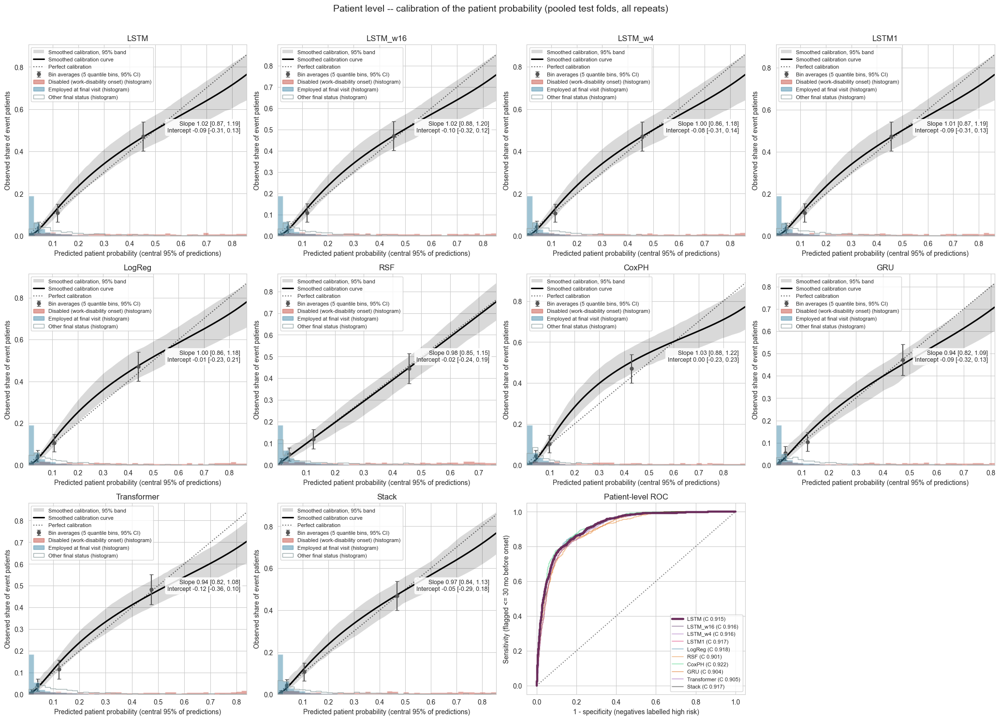

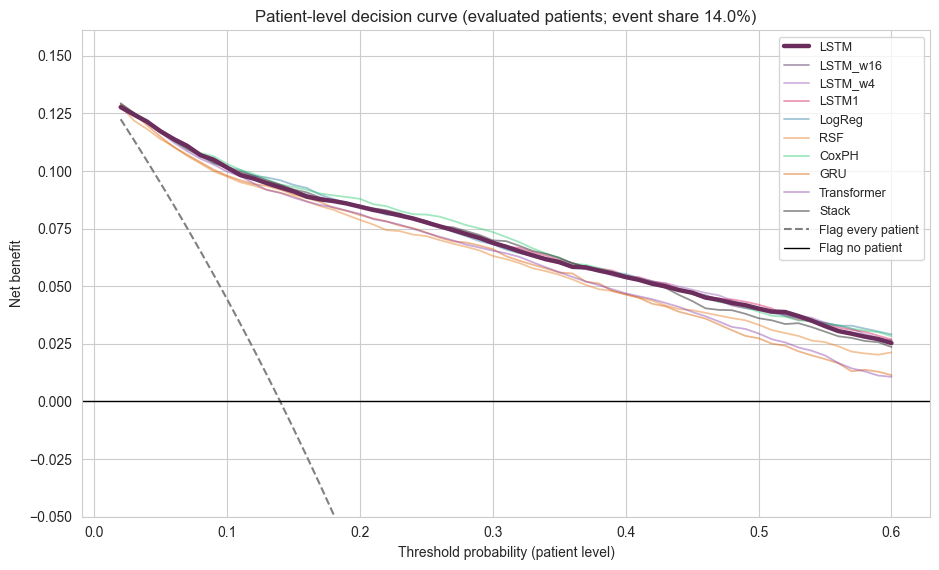

In [70]:
"""Patient-level calibration of every model (quintiles of the recalibrated patient probability, all repeats stacked,
with the slope and intercept of its table) and the patient-level ROC curves of all models."""
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "patient", MODEL_RESULTS[m]["patient_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    arrs = level_arrays(m, r["preds"], "patient")
    y, p = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, **model_style(m),
            label=f"{m} (C {r['patient_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity (negatives labelled high risk)"); ax.set_ylabel("Sensitivity (flagged <= 30 mo before onset)")
ax.set_title("Patient-level ROC"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Patient level -- calibration of the patient probability (pooled test folds, all repeats)", y=1.01,
             fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_calibration_patient_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# patient-level decision curve (TRIPOD+AI items 12e and 15, clinical usefulness): net benefit of flagging patients whose patient
# probability is >= a threshold, mean over CV repeats, against flagging everyone or no one
fig, ax = plt.subplots(figsize=(9.5, 5.8))
_pts = np.linspace(0.02, 0.6, 59)
for m, r in MODEL_RESULTS.items():
    _arrs = level_arrays(m, r["preds"], "patient")
    _nb = np.mean([ipcw_net_benefit(y, p, w, _pts)[0] for y, p, w, _, _ in _arrs], axis=0)
    ax.plot(_pts, _nb, label=m, **model_style(m))
_y0, _p0, _w0 = _arrs[0][:3]
ax.plot(_pts, ipcw_net_benefit(_y0, _p0, _w0, _pts)[1], color="gray", ls="--", label="Flag every patient")
ax.axhline(0, color="black", lw=1, label="Flag no patient")
_prev = float(_y0.mean())
ax.set_ylim(-0.05, _prev * 1.15)
ax.set_xlabel("Threshold probability (patient level)"); ax.set_ylabel("Net benefit")
ax.set_title(f"Patient-level decision curve (evaluated patients; event share {_prev:.1%})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_decision_curve_patient.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.13.7 Performance by subgroup (sex, race, age, calendar era)

TRIPOD+AI item 14: every model's C-index, calibration-in-the-large, sensitivity and specificity by sex, race and age band, at
the visit and the patient level, from the same pooled out-of-fold predictions as the main tables.

In [71]:
"""
Performance by subgroup (TRIPOD+AI item 14, fairness): sex, race, age band and calendar era, at the visit and the patient level, for
every model. Same pooled out-of-fold predictions and thresholds as the main tables; each subgroup is simply a subset
of the evaluated visits / patients (for patients: all event and event-free patients in that subgroup). 95% CIs from
SUBGROUP_BOOT patient-cluster bootstrap resamples. Calibration-in-the-large (intercept) shows whether a subgroup's risk
is systematically over- (negative) or under-estimated (positive). Small subgroups have wide intervals.
"""
SUBGROUP_BOOT = 50 if SMOKE else 200
_ERA_LAB = np.array([e[2] for e in ERA_BANDS])[np.digitize(CAL_YEAR_ALL, [b[1] for b in ERA_BANDS[:-1]])]
LAND_ATTR["era"] = _ERA_LAB                                           # visit level: era of the landmark visit
PT_ATTR["era"] = (pd.DataFrame({"pid": PID_ALL, "d": pd.to_datetime(land["visit_date"]).values, "era": _ERA_LAB})
                  .sort_values("d").groupby("pid")["era"].last().reindex(PT_ATTR.index))   # patient: last landmark
SUBGROUPS = [("sex", v) for v in ["Female", "Male"]] + \
            [("race", v) for v in ["White", "Black", "Asian (Chinese, Filipino)", "Other / not recorded"]] + \
            [("age", lab) for _, _, lab in AGE_BANDS] + [("era", e[2]) for e in ERA_BANDS]
SUBGROUP_METRICS = ["c_index", "cal_intercept", "sensitivity", "specificity"]


def _cell(t, k):
    v = t.loc[k]
    return f"{v['Value']:.3f} [{v['CI low']:.3f}, {v['CI high']:.3f}]" if np.isfinite(v["Value"]) else "n/a"


def subgroup_table(level):
    rows = []
    for attr, val in SUBGROUPS:
        for m, r in MODEL_RESULTS.items():
            arrs = level_arrays(m, r["preds"], level, sub=(attr, val))
            n_pos, n_neg = int(arrs[0][0].sum()), int((arrs[0][0] == 0).sum())
            if n_pos == 0 or n_neg == 0:
                continue
            t = metric_table(m, r["preds"], level, n_boot=SUBGROUP_BOOT, arrs=arrs)
            rows.append({"Attribute": attr, "Subgroup": val, "Model": m,
                         ("Onsets <= 30 mo / resolved visits" if level == "visit" else "Event / event-free patients"):
                             f"{n_pos} / {n_pos + n_neg}" if level == "visit" else f"{n_pos} / {n_neg}",
                         **{t.loc[k, "Metric"]: _cell(t, k) for k in SUBGROUP_METRICS}})
    return pd.DataFrame(rows).set_index(["Attribute", "Subgroup", "Model"])


t0 = time.time()
fairness_visit = subgroup_table("visit")
print("VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):")
display(fairness_visit)
fairness_patient = subgroup_table("patient")
print("\nPATIENT LEVEL by subgroup (30-month windows; value [95% CI]):")
display(fairness_patient)
pd.concat({"visit": fairness_visit, "patient": fairness_patient}).to_csv("subgroup_performance_model_revised_v21.csv")
print(f"({time.time() - t0:.0f}s)")

VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):


Onsets <= 30 mo / resolved visits  \
Attribute Subgroup                  Model                                           
sex       Female                    LSTM                              588 / 12886   
                                    LSTM_w16                          588 / 12886   
                                    LSTM_w4                           588 / 12886   
                                    LSTM1                             588 / 12886   
                                    LogReg                            588 / 12886   
                                    RSF                               588 / 12886   
                                    CoxPH                             588 / 12886   
                                    GRU                               588 / 12886   
                                    Transformer                       588 / 12886   
                                    Stack                             588 / 12886   
          Male                      LSTM                                54 / 1498   
                                    LSTM_w16                            54 / 1498   
                                    LSTM_w4                             54 / 1498   
                                    LSTM1                               54 / 1498   
                                    LogReg                              54 / 1498   
                                    RSF                                 54 / 1498   
                                    CoxPH                               54 / 1498   
                                    GRU                                 54 / 1498   
                                    Transformer                         54 / 1498   
                                    Stack                               54 / 1498   
race      White                     LSTM                               404 / 9050   
                                    LSTM_w16                           404 / 9050   
                                    LSTM_w4                            404 / 9050   
                                    LSTM1                              404 / 9050   
                                    LogReg                             404 / 9050   
                                    RSF                                404 / 9050   
                                    CoxPH                              404 / 9050   
                                    GRU                                404 / 9050   
                                    Transformer                        404 / 9050   
                                    Stack                              404 / 9050   
          Black                     LSTM                               140 / 2098   
                                    LSTM_w16                           140 / 2098   
                                    LSTM_w4                            140 / 2098   
                                    LSTM1                              140 / 2098   
                                    LogReg                             140 / 2098   
                                    RSF                                140 / 2098   
                                    CoxPH                              140 / 2098   
                                    GRU                                140 / 2098   
                                    Transformer                        140 / 2098   
                                    Stack                              140 / 2098   
          Asian (Chinese, Filipino) LSTM                                85 / 2271   
                                    LSTM_w16                            85 / 2271   
                                    LSTM_w4                             85 / 2271   
                                    LSTM1                               85 / 2271   
                                    LogReg                              85 / 2271   
                                    RSF              


PATIENT LEVEL by subgroup (30-month windows; value [95% CI]):


Event / event-free patients  \
Attribute Subgroup                  Model                                     
sex       Female                    LSTM                          136 / 795   
                                    LSTM_w16                      136 / 795   
                                    LSTM_w4                       136 / 795   
                                    LSTM1                         136 / 795   
                                    LogReg                        136 / 795   
                                    RSF                           136 / 795   
                                    CoxPH                         136 / 795   
                                    GRU                           136 / 795   
                                    Transformer                   136 / 795   
                                    Stack                         136 / 795   
          Male                      LSTM                           12 / 113   
                                    LSTM_w16                       12 / 113   
                                    LSTM_w4                        12 / 113   
                                    LSTM1                          12 / 113   
                                    LogReg                         12 / 113   
                                    RSF                            12 / 113   
                                    CoxPH                          12 / 113   
                                    GRU                            12 / 113   
                                    Transformer                    12 / 113   
                                    Stack                          12 / 113   
race      White                     LSTM                           97 / 512   
                                    LSTM_w16                       97 / 512   
                                    LSTM_w4                        97 / 512   
                                    LSTM1                          97 / 512   
                                    LogReg                         97 / 512   
                                    RSF                            97 / 512   
                                    CoxPH                          97 / 512   
                                    GRU                            97 / 512   
                                    Transformer                    97 / 512   
                                    Stack                          97 / 512   
          Black                     LSTM                           29 / 122   
                                    LSTM_w16                       29 / 122   
                                    LSTM_w4                        29 / 122   
                                    LSTM1                          29 / 122   
                                    LogReg                         29 / 122   
                                    RSF                            29 / 122   
                                    CoxPH                          29 / 122   
                                    GRU                            29 / 122   
                                    Transformer                    29 / 122   
                                    Stack                          29 / 122   
          Asian (Chinese, Filipino) LSTM                           16 / 149   
                                    LSTM_w16                       16 / 149   
                                    LSTM_w4                        16 / 149   
                                    LSTM1                          16 / 149   
                                    LogReg                         16 / 149   
                                    RSF                            16 / 149   
                                    CoxPH                          16 / 149   
                                    GRU                            16 / 149   
                                    Transformer                    16 / 149   
                   

(2165s)


## 11.13.8 Conclusion — Objective 3

Printed from this run's estimates (Sections 11.13.1–11.13.7).

In [72]:
"""Conclusion of Objective 3, written from the estimates of Sections 11.13.1-11.13.7."""
if "LSTM" not in MODEL_RESULTS:
    txt = "Objective 3 could not be assessed: LSTM-8 has not run."
else:
    vt = MODEL_RESULTS["LSTM"]["visit_table"]
    _ok = [m for m in h3a.index if h3a.loc[m, "Both"]]
    txt = (f"H3a: LSTM-8's {PRIMARY_HORIZON_MONTHS}-month risks have calibration slope {_o1_cell(vt, 'cal_slope')} and "
           f"intercept {_o1_cell(vt, 'cal_intercept')} (observed/expected {vt.loc['oe_ratio', 'Value']:.2f}), so the "
           f"criterion is {'met' if h3a.loc[mlab('LSTM'), 'Both'] else 'not met'}; models meeting it: "
           f"{', '.join(_ok) if _ok else 'none'}. ")
    if "LSTM" in H3B_ABOVE:
        _ab = H3B_ABOVE["LSTM"]
        _nb_ok = [m for m in h3b.index if h3b.loc[m, "Met"]]
        txt += (f"H3b: LSTM-8's net benefit is above alarming at every visit and at none at {int(_ab.sum())} of "
                f"{len(DCA_GRID)} thresholds between {DCA_RANGE[0]:.0%} and {DCA_RANGE[1]:.0%}; models above both over "
                f"the whole range: {', '.join(_nb_ok) if _nb_ok else 'none'}. ")
        if "LSTM" in _thr_med and not (DCA_RANGE[0] <= _thr_med["LSTM"] <= DCA_RANGE[1]):
            txt += (f"The cost-weighted alarm threshold (median {_thr_med['LSTM']:.1%}) lies outside this range, so the "
                    "H3b range does not contain the operating point of the alarm rule; the decision curve shows both. ")
    _r = [r_ for r_ in thr_rows if r_["Model"] == mlab("LSTM")]
    if _r:
        txt += ("At fixed 30-month risks: " + "; ".join(
            f"{r_['Threshold']} -- visit sensitivity {r_['Visit Sensitivity'].split(' ')[0]}, specificity "
            f"{r_['Visit Specificity'].split(' ')[0]}, PPV {r_['Visit PPV'].split(' ')[0]}, NPV "
            f"{r_['Visit NPV'].split(' ')[0]}" for r_ in _r) + ". ")
    txt += ("Discrimination and calibration by sex, race, age and calendar era are in Section 11.13.7; small subgroups "
            "have wide intervals.")
OBJ_CONCLUSIONS["Objective 3"] = txt
print(textwrap.fill(txt, 118))


H3a: LSTM-8's 30-month risks have calibration slope 1.095 [0.866, 1.348] and intercept -0.047 [-0.252, 0.129]
(observed/expected 0.96), so the criterion is met; models meeting it: LSTM-8 (main), LSTM-16 (last 16 visits), LSTM-4
(last 4 visits), LSTM-1 (current visit), LogReg (last visit), RSF, CoxPH, GRU, Transformer, Stack (logistic meta-
learner), Baseline. H3b: LSTM-8's net benefit is above alarming at every visit and at none at 13 of 31 thresholds
between 10% and 40%; models above both over the whole range: none. The cost-weighted alarm threshold (median 3.7%)
lies outside this range, so the H3b range does not contain the operating point of the alarm rule; the decision curve
shows both. At fixed 30-month risks: 5% -- visit sensitivity 0.564, specificity 0.747, PPV 0.088, NPV 0.975; 10% --
visit sensitivity 0.183, specificity 0.956, PPV 0.151, NPV 0.964. Discrimination and calibration by sex, race, age and
calendar era are in Section 11.13.7; small subgroups have wide intervals.


---
# 11.14 Objective 4 — What drives the predicted risk?

| Objective | What is shown | Success criterion |
|---|---|---|
| What drives predicted risk | SHAP of LSTM-8 by feature, by group of correlated variables and by visit recency, and individual patient examples | Descriptive |

These are **drivers of the prediction, not causes of work disability**: a modifiable variable with a large SHAP value
is not, on this evidence, a treatment target. Correlated lupus variables (disease activity, damage, steroid dose) share
attribution, so they are also shown grouped.

## 11.14.1 SHAP of the current visit (LSTM-8)

SHAP attributions of the calibrated 30-month risk from the LSTM's final all-data refit, to its current-visit inputs
presented as a short constant employed trajectory. The plots show the **15 variables with the largest mean |SHAP|**
(the table lists all of them). The stack is explained by its weights (Section 11.11.6) and the regression by its
nomogram (Section 11.10.5).

Computing SHAP values for the LSTM (200 landmarks, 100 background)...


PermutationExplainer explainer: 201it [03:11,  1.05it/s]                         


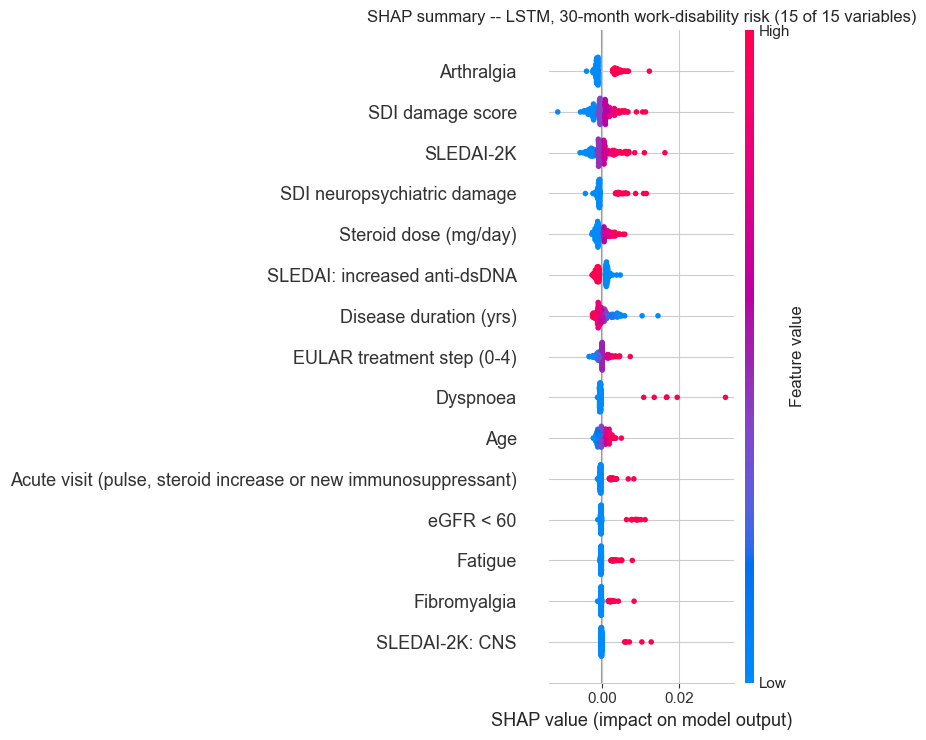

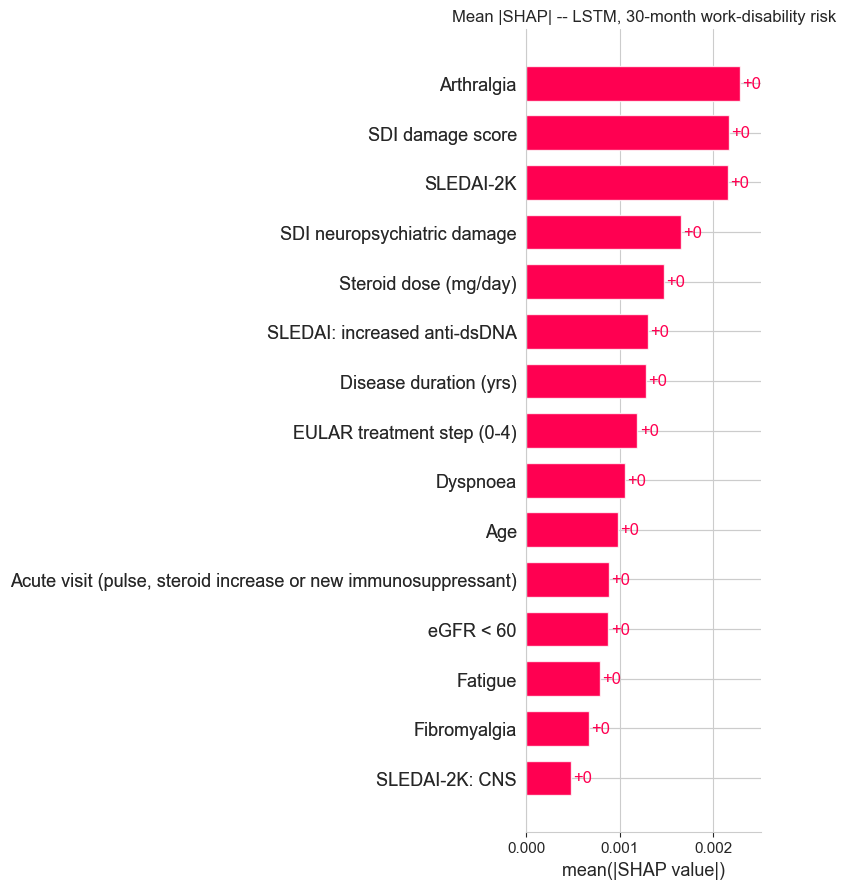

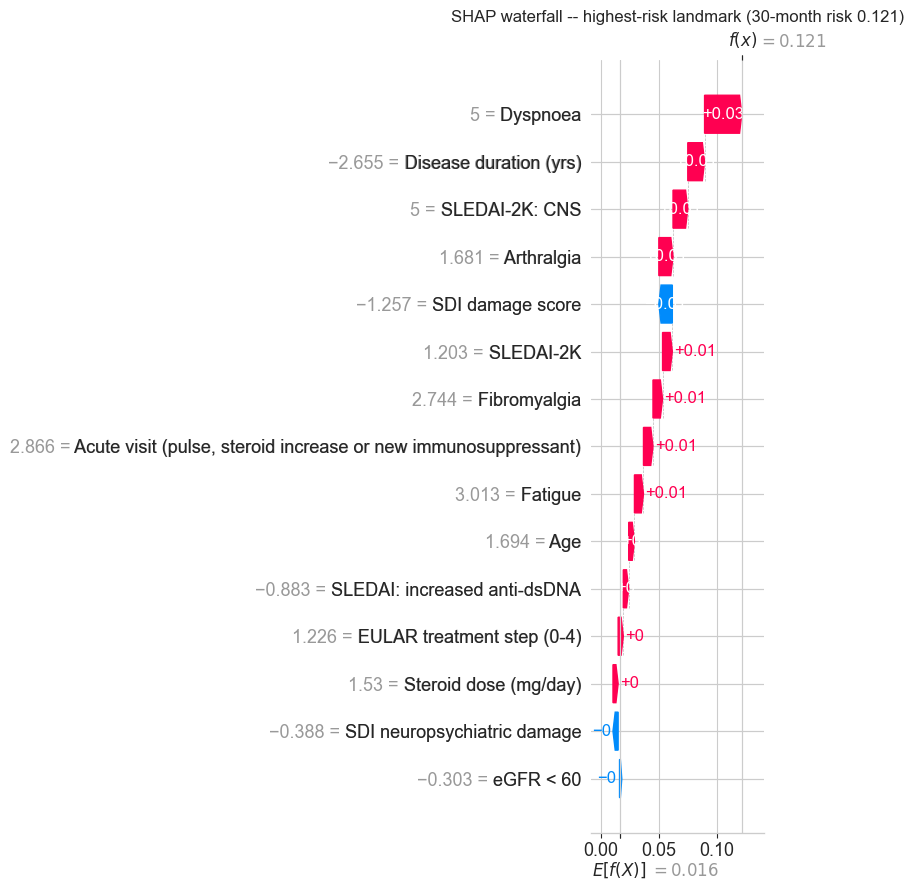

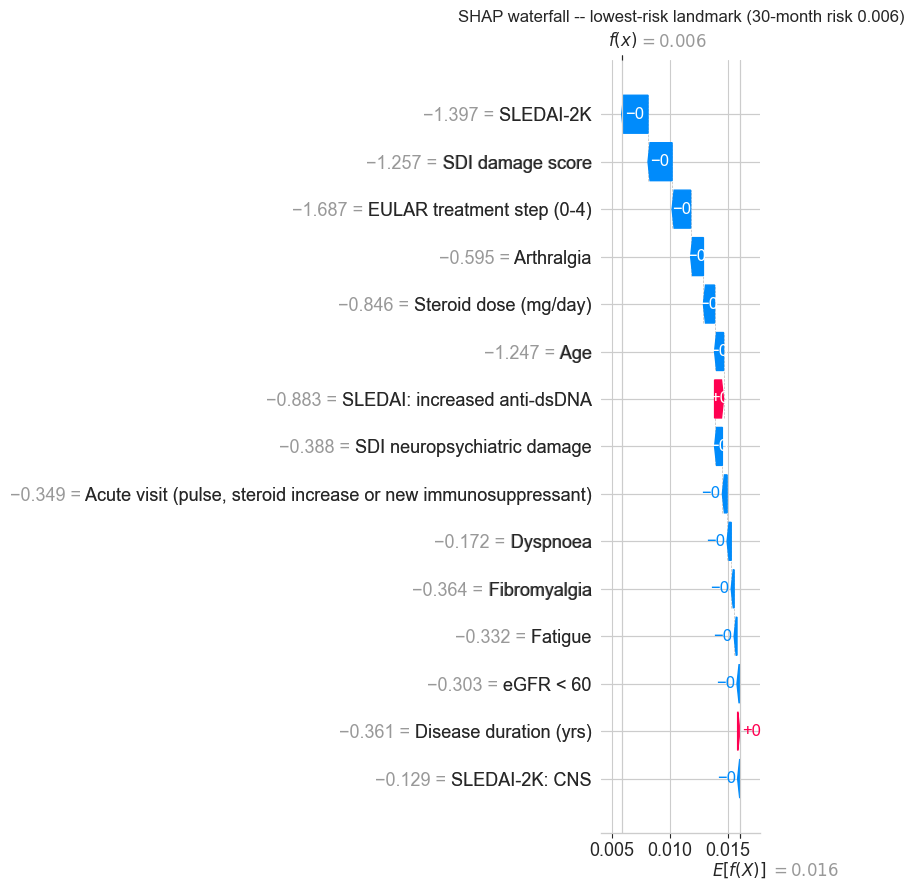

                                                       Feature  Mean |SHAP|
                                                    Arthralgia       0.0023
                                              SDI damage score       0.0022
                                                     SLEDAI-2K       0.0022
                                   SDI neuropsychiatric damage       0.0017
                                         Steroid dose (mg/day)       0.0015
                                  SLEDAI: increased anti-dsDNA       0.0013
                                        Disease duration (yrs)       0.0013
                                    EULAR treatment step (0-4)       0.0012
                                                      Dyspnoea       0.0011
                                                           Age       0.0010
Acute visit (pulse, steroid increase or new immunosuppressant)       0.0009
                                                     eGFR < 60       0.0009
            

In [73]:
"""SHAP explanations for the LSTM (final all-data refit).

The LSTM reads a visit history, so SHAP attributes the 30-month risk to the CURRENT visit presented as a short,
constant trajectory: the visit's encoder features are repeated over SHAP_SEQ_LEN employed visits (the history window
chosen most often, at most 4) at the cohort's median visit gap, and the risk is read at the last one. The features are the encoder's inputs; the gap and the employment
state are held fixed. This is a 'constant recent trajectory'
simplification; the risk-sensitivity curves show each feature's effect with the real histories held as observed. Values are
on the calibrated 30-month risk scale. The calendar year (an adjustment term, head only) is held at the latest
year in the extract, the year a new patient is scored at, and is not attributed. Background and explained landmarks use the first imputation's features
(every seed of the ensemble -- each trained on its own imputation -- is applied to them).
"""
import shap

SHAP_TOP = 15                                   # variables shown in the SHAP plots

SHAP_MODEL = "LSTM" if res_lstm is not None else next(m for m in ["GRU", "Transformer"] if m in MODEL_RESULTS)
_chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == SHAP_MODEL]
_mv = seq_cfg(SHAP_MODEL, max(set(_chosen), key=_chosen.count))["max_visits"] if _chosen else None
SHAP_SEQ_LEN = min(4, _mv or 4)
fr = MODEL_RESULTS[SHAP_MODEL]["final"]
data = fr["prep"]
cols = data.cols                                                # the model columns
shap_idx = [j for j, c in enumerate(cols) if c not in ADJUST_COLS]    # attributed: the variables
adj_fixed = {cols.index(c): fr["ctx"]["seq_prep"].transform_value(cols.index(c), float(land[c].max()))
             for c in ADJUST_COLS if c in cols}                        # calendar year held at the latest year
feature_names = [DISPLAY_NAMES.get(cols[j], cols[j]) for j in shap_idx]
gap_log = float(np.median(V_GAP[V_GAP > 0]))
employed = torch.tensor([1.0, 0.0, 0.0, 0.0])


def shap_predict(Z):
    Zs = np.asarray(Z, np.float32)
    n, L = len(Zs), SHAP_SEQ_LEN
    Z = np.zeros((n, len(cols)), np.float32)
    Z[:, shap_idx] = Zs
    for j, v in adj_fixed.items():
        Z[:, j] = v
    gap = torch.full((n, L), gap_log); gap[:, 0] = 0.0
    b = dict(x=torch.from_numpy(np.repeat(Z[:, None, :], L, axis=1)), gap=gap,
             state=employed.expand(n, L, -1).contiguous(),
             elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), L, dtype=torch.long))
    Hz = 0.0
    with torch.no_grad():
        for net in fr["fitted"]:
            Hz = Hz + torch.sigmoid(net(b))[:, -1].numpy() / len(fr["fitted"])
    return fr["cal"].transform(hazard_risk(Hz)[:, PRIMARY_COL])


rng = np.random.RandomState(SEED)
Z_all = data.VX[land["visit_row"].values][:, shap_idx]            # scaled variables of every landmark
background = Z_all[rng.choice(len(Z_all), 50 if SMOKE else 100, replace=False)]
explain = Z_all[rng.choice(len(Z_all), 40 if SMOKE else 200, replace=False)]
print(f"Computing SHAP values for the {SHAP_MODEL} ({len(explain)} landmarks, {len(background)} background)...")
explainer = shap.Explainer(shap_predict, shap.maskers.Independent(background, max_samples=len(background)),
                           feature_names=feature_names)
shap_values = explainer(explain)

plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=SHAP_TOP)
plt.title(f"SHAP summary -- {SHAP_MODEL}, 30-month work-disability risk ({min(SHAP_TOP, len(feature_names))} of "
          f"{len(feature_names)} variables)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=SHAP_TOP)
plt.title(f"Mean |SHAP| -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_shap_bar.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
preds_ = shap_predict(explain)
for label, i in [("highest-risk", int(np.argmax(preds_))), ("lowest-risk", int(np.argmin(preds_)))]:
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False, max_display=SHAP_TOP)
    plt.title(f"SHAP waterfall -- {label} landmark (30-month risk {preds_[i]:.3f})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                                    bbox_inches="tight"); plt.show(); plt.close()
shap_imp = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)}) \
    .sort_values("Mean |SHAP|", ascending=False)
print(shap_imp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))



## 11.14.2 SHAP over the visit window: by feature, by group and by visit recency

SHAP values for every variable **at every one of the last 8 visits** (and the gap to the previous visit) of LSTM-8's
final refit, aggregated by feature, by group and by visit position (how far back matters -- the link to Objective 1),
with three individual examples.

SHAP over the visit window: 150 landmarks, 80 background, 8 visits x 16 inputs (298s)


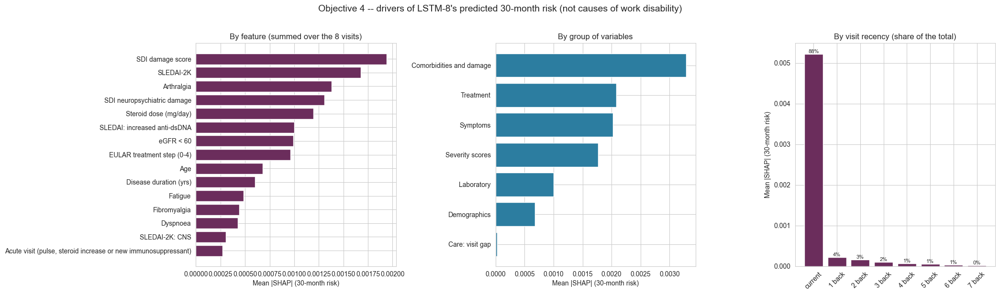

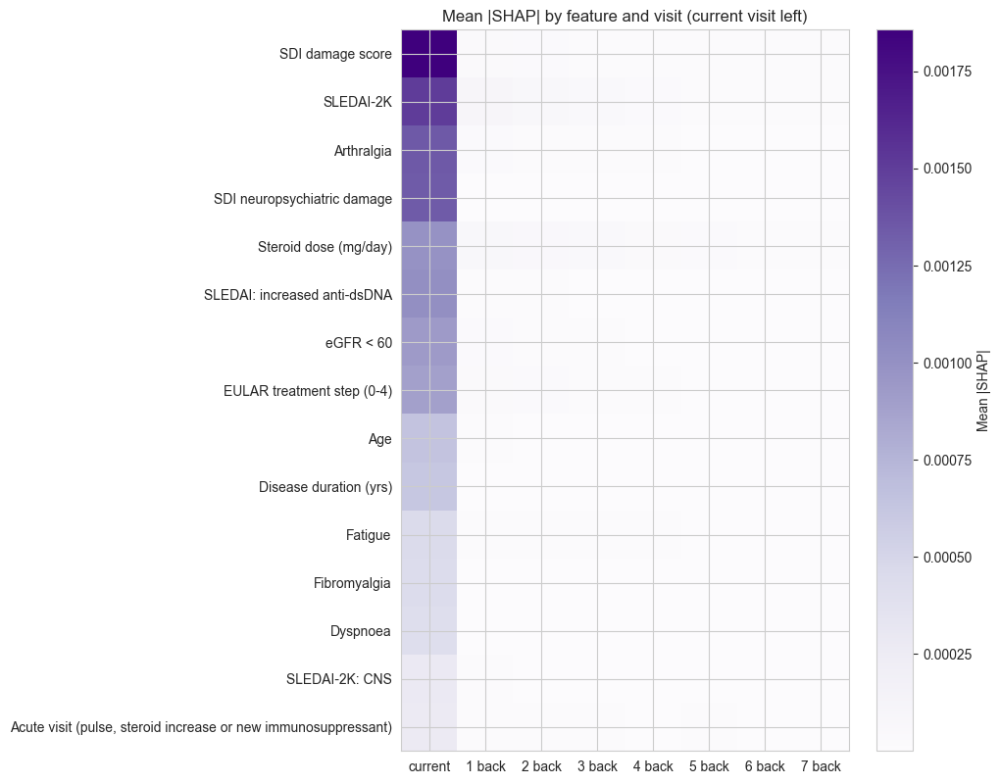

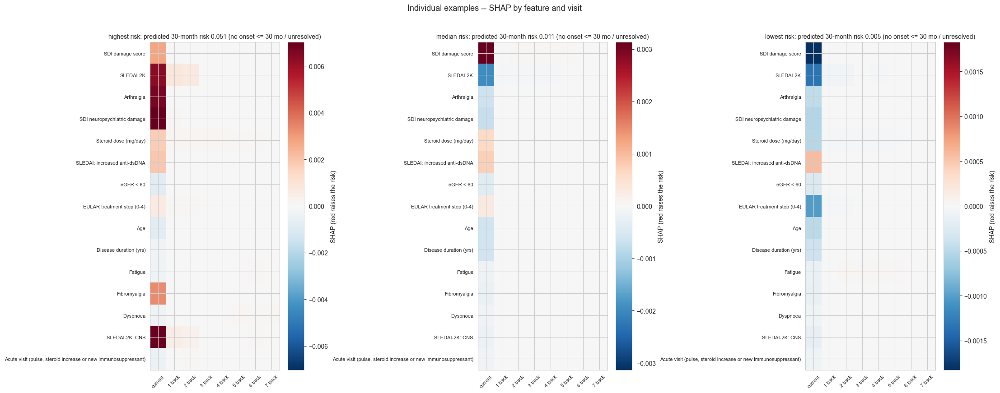

Mean |SHAP| by feature:
SDI damage score                                                  0.0019
SLEDAI-2K                                                         0.0017
Arthralgia                                                        0.0014
SDI neuropsychiatric damage                                       0.0013
Steroid dose (mg/day)                                             0.0012
SLEDAI: increased anti-dsDNA                                      0.0010
eGFR < 60                                                         0.0010
EULAR treatment step (0-4)                                        0.0010
Age                                                               0.0007
Disease duration (yrs)                                            0.0006
Fatigue                                                           0.0005
Fibromyalgia                                                      0.0004
Dyspnoea                                                          0.0004
SLEDAI-2K: CNS             

In [74]:
"""
SHAP of LSTM-8 over the real visit window (Objective 4). For landmarks with at least LSTM_MAIN_WINDOW visits, each
variable at each of the last 8 visits, and log(1 + gap) at each visit, is one feature (8 x (variables + 1)). The
explained output is the calibrated 30-month risk of the final all-data refit (every seed of the ensemble, first
imputation's features); the masker draws replacement values from other landmarks' windows; the employment state is
held at 'employed' and the calendar year at the latest year (as in Section 11.14.1). Aggregation: per landmark, the
signed SHAP summed over visits (by feature), over the variables of a group (by group) or over the variables of a visit
(by visit position), then mean |.| over landmarks. With the skip connection, the current visit's variables also reach
the hazard heads directly, so the current visit's attribution includes that path.
"""
SHAP_W = LSTM_MAIN_WINDOW
fr8 = MODEL_RESULTS.get("LSTM", {}).get("final") if "LSTM" in MODEL_RESULTS else None
if fr8 is None:
    print("Run Section 11.10.1 (LSTM-8) first.")
else:
    data8, cols8 = fr8["prep"], fr8["prep"].cols
    var_idx = [j for j, c in enumerate(cols8) if c not in ADJUST_COLS]
    q8 = len(var_idx)
    adj8 = {cols8.index(c): fr8["ctx"]["seq_prep"].transform_value(cols8.index(c), float(land[c].max()))
            for c in ADJUST_COLS if c in cols8}
    R8, _ = window_rows(SHAP_W)
    elig8 = np.flatnonzero(LAND_POS >= SHAP_W - 1)

    def flat8(rows_l):
        Rw = R8[np.asarray(rows_l)]
        X = data8.VX[Rw][:, :, var_idx]
        return np.concatenate([X, V_GAP[Rw][:, :, None]], axis=2).reshape(len(rows_l), -1)

    def f8(Z):
        Z = np.asarray(Z, np.float32).reshape(-1, SHAP_W, q8 + 1)
        n = len(Z)
        x = np.zeros((n, SHAP_W, len(cols8)), np.float32)
        x[:, :, var_idx] = Z[:, :, :q8]
        for j, v in adj8.items():
            x[:, :, j] = v
        gap = torch.from_numpy(np.ascontiguousarray(Z[:, :, q8]))
        b = dict(x=torch.from_numpy(x), gap=gap, state=torch.tensor([1.0, 0.0, 0.0, 0.0]).expand(n, SHAP_W, -1).contiguous(),
                 elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), SHAP_W, dtype=torch.long))
        Hz = 0.0
        with torch.no_grad():
            for net in fr8["fitted"]:
                Hz = Hz + torch.sigmoid(net(b))[:, -1].numpy() / len(fr8["fitted"])
        return fr8["cal"].transform(hazard_risk(Hz)[:, PRIMARY_COL])

    rng8 = np.random.RandomState(SEED + 4)
    bg8 = rng8.choice(elig8, min(len(elig8), 30 if SMOKE else 80), replace=False)
    ex8 = rng8.choice(np.setdiff1d(elig8, bg8), min(len(elig8) - len(bg8), 25 if SMOKE else 150), replace=False)
    var_names = [DISPLAY_NAMES.get(cols8[j], cols8[j]) for j in var_idx] + ["Visit gap"]
    POS_LAB = [f"{SHAP_W - 1 - t} back" if t < SHAP_W - 1 else "current" for t in range(SHAP_W)]   # t = 0 oldest
    t0 = time.time()
    expl8 = shap.Explainer(f8, shap.maskers.Independent(flat8(bg8), max_samples=len(bg8)),
                           feature_names=[f"{n} [{p}]" for p in POS_LAB for n in var_names])
    sv8 = expl8(flat8(ex8), max_evals=max(500, 2 * SHAP_W * (q8 + 1) + 1), silent=True)
    S8 = sv8.values.reshape(len(ex8), SHAP_W, q8 + 1)
    print(f"SHAP over the visit window: {len(ex8)} landmarks, {len(bg8)} background, {SHAP_W} visits x {q8 + 1} "
          f"inputs ({time.time() - t0:.0f}s)")
    group_of = [FEATURE_GROUP_OF.get(cols8[j], "Other") for j in var_idx] + ["Care: visit gap"]
    groups8 = list(dict.fromkeys(group_of))
    by_feat = pd.Series(np.abs(S8.sum(1)).mean(0), index=var_names).sort_values(ascending=False)
    Sg = np.stack([S8[:, :, [i for i, g in enumerate(group_of) if g == G]].sum(2) for G in groups8], 2)
    by_group = pd.Series(np.abs(Sg.sum(1)).mean(0), index=groups8).sort_values(ascending=False)
    by_pos = pd.Series(np.abs(S8.sum(2)).mean(0), index=POS_LAB)[::-1]               # current visit first
    SHAP_POS_SHARE = by_pos / by_pos.sum()
    heat = pd.DataFrame(np.abs(S8).mean(0).T, index=var_names, columns=POS_LAB)[POS_LAB[::-1]]

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    top = by_feat.iloc[:SHAP_TOP][::-1]
    axes[0].barh(top.index, top.values, color=CV_COLORS["LSTM"]); axes[0].set_title("By feature (summed over the 8 visits)")
    axes[0].set_xlabel("Mean |SHAP| (30-month risk)")
    axes[1].barh(by_group.index[::-1], by_group.values[::-1], color="#2c7da0"); axes[1].set_title("By group of variables")
    axes[1].set_xlabel("Mean |SHAP| (30-month risk)")
    axes[2].bar(by_pos.index, by_pos.values, color=CV_COLORS["LSTM"])
    for i_, (v_, s_) in enumerate(zip(by_pos.values, SHAP_POS_SHARE.values)):
        axes[2].text(i_, v_, f"{s_:.0%}", ha="center", va="bottom", fontsize=8)
    axes[2].set_title("By visit recency (share of the total)"); axes[2].set_ylabel("Mean |SHAP| (30-month risk)")
    axes[2].tick_params(axis="x", rotation=45)
    plt.suptitle("Objective 4 -- drivers of LSTM-8's predicted 30-month risk (not causes of work disability)", y=1.02,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective4_shap_aggregates.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    hv = heat.loc[by_feat.index[:SHAP_TOP]]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(hv) + 1.8))
    im = ax.imshow(hv.values, aspect="auto", cmap="Purples")
    ax.set_yticks(range(len(hv))); ax.set_yticklabels(hv.index); ax.set_xticks(range(SHAP_W)); ax.set_xticklabels(hv.columns)
    plt.colorbar(im, ax=ax, label="Mean |SHAP|"); ax.set_title("Mean |SHAP| by feature and visit (current visit left)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective4_shap_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ---- individual examples: the highest-, a median- and the lowest-risk explained landmark
    risk8 = f8(flat8(ex8))
    picks = [("highest risk", int(np.argmax(risk8))), ("median risk", int(np.argsort(risk8)[len(risk8) // 2])),
             ("lowest risk", int(np.argmin(risk8)))]
    fig, axes = plt.subplots(1, 3, figsize=(22, 0.42 * SHAP_TOP + 2.2))
    rows_top = [var_names.index(n) for n in by_feat.index[:SHAP_TOP]]
    for ax, (lab_, i_) in zip(axes, picks):
        M_ = S8[i_][:, rows_top].T[:, ::-1]                                    # features x visits, current first
        vmax = float(np.abs(M_).max()) or 1e-6
        im = ax.imshow(M_, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_yticks(range(len(rows_top))); ax.set_yticklabels([var_names[j] for j in rows_top], fontsize=8)
        ax.set_xticks(range(SHAP_W)); ax.set_xticklabels(POS_LAB[::-1], rotation=45, fontsize=8)
        onset = "onset <= 30 mo" if (Y30[ex8[i_]] == 1 and W30[ex8[i_]] > 0) else "no onset <= 30 mo / unresolved"
        ax.set_title(f"{lab_}: predicted 30-month risk {risk8[i_]:.3f} ({onset})", fontsize=10)
        plt.colorbar(im, ax=ax, label="SHAP (red raises the risk)")
    plt.suptitle("Individual examples -- SHAP by feature and visit", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_objective4_shap_examples.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("Mean |SHAP| by feature:"); print(by_feat.round(4).to_string())
    print("\nBy visit position (share):"); print(SHAP_POS_SHARE.round(3).to_string())
    pd.concat({"feature": by_feat, "group": by_group, "visit position": by_pos}).to_csv(
        "objective4_shap_aggregates_revised_v21.csv")

## 11.14.3 Conclusion — Objective 4

Printed from this run's estimates (Sections 11.14.1–11.14.2). Descriptive.

In [75]:
"""Conclusion of Objective 4 (descriptive), written from the SHAP results of Sections 11.14.1-11.14.2."""
if "by_feat" not in globals():
    txt = "Objective 4 could not be described: the SHAP sections have not run."
else:
    txt = ("The largest drivers of LSTM-8's predicted 30-month risk are " + ", ".join(by_feat.index[:5])
           + "; by group, " + ", ".join(by_group.index[:3]) + ". "
           f"The current visit carries {SHAP_POS_SHARE.iloc[0]:.0%} of the attribution and the 7 earlier visits "
           f"{1 - SHAP_POS_SHARE.iloc[0]:.0%}, which is how far back the model looks (compare Objective 1). "
           "These are drivers of the prediction, not causes of work disability; correlated variables share "
           "attribution, so the grouped view is the safer reading.")
OBJ_CONCLUSIONS["Objective 4"] = txt
print(textwrap.fill(txt, 118))

The largest drivers of LSTM-8's predicted 30-month risk are SDI damage score, SLEDAI-2K, Arthralgia, SDI
neuropsychiatric damage, Steroid dose (mg/day); by group, Comorbidities and damage, Treatment, Symptoms. The current
visit carries 88% of the attribution and the 7 earlier visits 12%, which is how far back the model looks (compare
Objective 1). These are drivers of the prediction, not causes of work disability; correlated variables share
attribution, so the grouped view is the safer reading.


---
# 11.15 Summary of the objectives

Every hypothesis on every metric: the estimate with its 95 % CI and whether its criterion is met (`*`), one table per
hypothesis, then every conclusion. No metric and no hypothesis is primary or gatekeeps another; the tables are read as
a whole.

In [76]:
"""Summary of Sections 11.10-11.14: every hypothesis on every metric, then every conclusion (no gatekeeping)."""
HYP_TEXT = {"H1a": "Visit history improves discrimination (LSTM-8 vs LSTM-1 vs LogReg)",
            "H1b": "Performance increases with the number of visits (slope over k = 1, 4, 8, 16)",
            "H2": "Discrimination is higher at shorter horizons (6 minus 48 months)",
            "H3a": "Predicted risks are well calibrated (30 months)",
            "H3b": "Net benefit over treat-all and treat-none"}
obj_summary = pd.DataFrame(OBJ_ROWS)
if obj_summary.empty:
    print("No objective has run.")
else:
    s_ = obj_summary.assign(Cell=[e + (" *" if m_ else "") for e, m_ in zip(obj_summary["Estimate [95% CI]"],
                                                                         obj_summary["Met"])])
    for hyp in ["H1a", "H1b", "H2"]:
        sub = s_[s_["Hypothesis"] == hyp]
        if sub.empty:
            continue
        w = sub.pivot_table(index=["Comparison", "Level"], columns="Metric", values="Cell", aggfunc="first", sort=False)
        w = w[[c for c in CORE_ORDER if c in w.columns]]
        w["Criterion met on"] = sub.groupby(["Comparison", "Level"], sort=False)["Met"].agg(
            lambda x: f"{int(x.sum())} of {len(x)} metrics")
        print(f"\n{hyp} -- {HYP_TEXT[hyp]}; criterion per metric: {sub['Criterion'].iloc[0]} (* = met)")
        display(w)
    for hyp in ["H3a", "H3b"]:
        sub = s_[s_["Hypothesis"] == hyp]
        if not sub.empty:
            print(f"\n{hyp} -- {HYP_TEXT[hyp]}; criterion: {sub['Criterion'].iloc[0]}")
            display(sub.set_index("Comparison")[["Estimate [95% CI]", "Met"]])
    print("\nObjective 4 -- drivers of predicted risk: SHAP by feature and by visit position (descriptive).")
    obj_summary.to_csv("objectives_summary_revised_v21.csv", index=False)
print("\nCONCLUSIONS")
for k in ["Objective 1", "Objective 2", "Objective 3", "Objective 4"]:
    print(f"\n{k}:")
    print(textwrap.fill(OBJ_CONCLUSIONS.get(k, "not run."), 118, initial_indent="  ", subsequent_indent="  "))



H1a -- Visit history improves discrimination (LSTM-8 vs LSTM-1 vs LogReg); criterion per metric: lower 95% bound > 0 (* = met)


Metric                                     AUROC                  C-index  \
Comparison      Level                                                       
LSTM-8 - LSTM-1 visit    +0.001 [-0.002, +0.004]  +0.001 [-0.002, +0.003]   
                patient  -0.001 [-0.003, +0.001]                      NaN   
LSTM-8 - LogReg visit    +0.000 [-0.005, +0.007]  +0.000 [-0.005, +0.006]   
                patient  -0.003 [-0.006, +0.001]                      NaN   
LSTM-1 - LogReg visit    -0.000 [-0.006, +0.006]  -0.000 [-0.005, +0.006]   
                patient  -0.002 [-0.005, +0.001]                      NaN   

Metric                               Sensitivity                Specificity  \
Comparison      Level                                                         
LSTM-8 - LSTM-1 visit    -0.010 [-0.023, +0.001]  +0.016 [+0.012, +0.021] *   
                patient  -0.007 [-0.020, +0.008]  +0.008 [+0.002, +0.014] *   
LSTM-8 - LogReg visit    -0.026 [-0.051, -0.001]  +0.036 [+0.028, +0.045] *   
                patient  -0.036 [-0.065, -0.006]  +0.064 [+0.051, +0.078] *   
LSTM-1 - LogReg visit    -0.016 [-0.038, +0.008]  +0.020 [+0.011, +0.029] *   
                patient  -0.030 [-0.056, -0.003]  +0.056 [+0.043, +0.070] *   

Metric                         Balanced accuracy              Brier score  \
Comparison      Level                                                       
LSTM-8 - LSTM-1 visit    +0.003 [-0.003, +0.009]  +0.000 [-0.000, +0.000]   
                patient  +0.001 [-0.006, +0.009]  -0.000 [-0.001, +0.000]   
LSTM-8 - LogReg visit    +0.005 [-0.008, +0.018]  -0.000 [-0.000, +0.000]   
                patient  +0.014 [-0.002, +0.031]  -0.001 [-0.002, +0.000]   
LSTM-1 - LogReg visit    +0.002 [-0.009, +0.014]  -0.000 [-0.000, +0.000]   
                patient  +0.013 [-0.001, +0.028]  -0.000 [-0.002, +0.001]   

Metric                  Criterion met on  
Comparison      Level                     
LSTM-8 - LSTM-1 visit     1 of 6 metrics  
                patient   1 of 5 metrics  
LSTM-8 - LogReg visit     1 of 6 metrics  
                patient   1 of 5 metrics  
LSTM-1 - LogReg visit     1 of 6 metrics  
                patient   1 of 5 metrics


H1b -- Performance increases with the number of visits (slope over k = 1, 4, 8, 16); criterion per metric: lower 95% bound of the slope > 0 (* = met)


Metric                                             AUROC  \
Comparison           Level                                 
slope per visit read visit    +0.0000 [-0.0002, +0.0003]   
                     patient  -0.0000 [-0.0002, +0.0001]   

Metric                                           C-index  \
Comparison           Level                                 
slope per visit read visit    +0.0000 [-0.0002, +0.0002]   
                     patient                         NaN   

Metric                                       Sensitivity  \
Comparison           Level                                 
slope per visit read visit    -0.0013 [-0.0021, -0.0005]   
                     patient  -0.0001 [-0.0011, +0.0008]   

Metric                                         Specificity  \
Comparison           Level                                   
slope per visit read visit    +0.0015 [+0.0012, +0.0019] *   
                     patient  +0.0012 [+0.0007, +0.0017] *   

Metric                                 Balanced accuracy  \
Comparison           Level                                 
slope per visit read visit    +0.0001 [-0.0003, +0.0006]   
                     patient  +0.0006 [-0.0000, +0.0011]   

Metric                                       Brier score Criterion met on  
Comparison           Level                                                 
slope per visit read visit    -0.0000 [-0.0000, +0.0000]   1 of 6 metrics  
                     patient  -0.0000 [-0.0001, +0.0000]   1 of 5 metrics


H2 -- Discrimination is higher at shorter horizons (6 minus 48 months); criterion per metric: lower 95% bound > 0 (* = met)


...


H3a -- Predicted risks are well calibrated (30 months); criterion: slope in [0.8, 1.2] and intercept CI includes 0


,Estimate [95% CI],Met
Comparison,,
LSTM-8 (main),"slope 1.095 [0.866, 1.348]; intercept -0.047 [...",True
LSTM-16 (last 16 visits),"slope 1.094 [0.869, 1.348]; intercept -0.052 [...",True
LSTM-4 (last 4 visits),"slope 1.074 [0.846, 1.323]; intercept -0.043 [...",True
LSTM-1 (current visit),"slope 1.078 [0.851, 1.322]; intercept -0.052 [...",True
LogReg (last visit),"slope 1.025 [0.816, 1.254]; intercept -0.006 [...",True
RSF,"slope 0.984 [0.719, 1.300]; intercept -0.003 [...",True
CoxPH,"slope 1.045 [0.840, 1.256]; intercept 0.002 [-...",True
GRU,"slope 1.032 [0.791, 1.291]; intercept -0.028 [...",True
Transformer,"slope 0.995 [0.753, 1.242]; intercept -0.046 [...",True



H3b -- Net benefit over treat-all and treat-none; criterion: above treat-all and treat-none at every threshold in 10%-40%


,Estimate [95% CI],Met
Comparison,,
LSTM-8 (main),above both at 13/31 thresholds; whole range in...,False
LSTM-16 (last 16 visits),above both at 13/31 thresholds; whole range in...,False
LSTM-4 (last 4 visits),above both at 12/31 thresholds; whole range in...,False
LSTM-1 (current visit),above both at 12/31 thresholds; whole range in...,False
LogReg (last visit),above both at 14/31 thresholds; whole range in...,False
RSF,above both at 13/31 thresholds; whole range in...,False
CoxPH,above both at 10/31 thresholds; whole range in...,False
GRU,above both at 14/31 thresholds; whole range in...,False
Transformer,above both at 18/31 thresholds; whole range in...,False



Objective 4 -- drivers of predicted risk: SHAP by feature and by visit position (descriptive).

CONCLUSIONS

Objective 1:
  Visit level, 30 months -- LSTM-8 (main): AUROC 0.714, C-index 0.719, Sensitivity 0.663, Specificity 0.630, Balanced
  accuracy 0.647, Brier score 0.038; LSTM-1 (current visit): AUROC 0.713, C-index 0.718, Sensitivity 0.674,
  Specificity 0.614, Balanced accuracy 0.644, Brier score 0.038; LogReg (last visit): AUROC 0.713, C-index 0.718,
  Sensitivity 0.690, Specificity 0.594, Balanced accuracy 0.642, Brier score 0.038. H1a (oriented paired differences,
  95% CI): LSTM-8 - LSTM-1 at the visit level: better on Specificity; no clear difference on AUROC, C-index,
  Sensitivity, Balanced accuracy, Brier score; LSTM-8 - LSTM-1 at the patient level: better on Specificity; no clear
  difference on AUROC, Sensitivity, Balanced accuracy, Brier score; LSTM-8 - LogReg at the visit level: better on
  Specificity; worse on Sensitivity; no clear difference on AUROC, C-index, Bal

---
# 11.16 Additional analyses (not tied to an objective)

LASSO stability, the full model specification, the cause-specific survival evaluation (with the signal test against
the Baseline), the two-cause heads, the results overview and the risk trajectories.

## 11.16.1 LASSO selection: bootstrap stability

How often each candidate was selected: on all data, and in the 200 patient bootstraps of the all-data selection
(penalty fixed). The selection is made once, so it does not vary across the CV folds. A variable selected in most
bootstraps is a stable part of the model; one selected rarely was one of several interchangeable candidates.

In [77]:
"""LASSO selection stability (Section 5.3): all data and the patient bootstraps (the selection is not refitted per fold)."""
if SEL_BOOT_FREQ is not None:
    _cols = [c for c in PENALISED_COLS if SELECTION_ALL["freq"][c] > 0 or SEL_BOOT_FREQ[c] >= 0.05]
    sel_stab = pd.DataFrame({"Group": [FEATURE_GROUP_OF.get(c, "") for c in _cols],
                             "Selected on all data": [bool(SELECTION_ALL["freq"][c]) for c in _cols],
                             "All-data coefficient (per SD, penalised)": [SELECTION_ALL["coef"][c] for c in _cols],
                             "Bootstrap frequency": [SEL_BOOT_FREQ[c] for c in _cols]},
                            index=[DISPLAY_NAMES.get(c, c) for c in _cols])
    display(sel_stab.sort_values("Bootstrap frequency", ascending=False).round(3))
    print(f"All data: {SELECTION_ALL['n_selected']} selected (binding: {SELECTION_ALL['binding']}); every CV fold uses "
          f"this set.")
    sel_stab.to_csv("lasso_selection_stability_revised_v21.csv")
else:
    print("No bootstrap stability in this run (sensitivity variant).")

,Group,Selected on all data,"All-data coefficient (per SD, penalised)",Bootstrap frequency
Dyspnoea,Symptoms,True,0.179,0.980
"Acute visit (pulse, steroid increase or new immunosuppressant)",Treatment,True,0.103,0.880
Steroid dose (mg/day),Treatment,True,0.131,0.880
Arthralgia,Symptoms,True,0.088,0.825
Fibromyalgia,Comorbidities and damage,True,0.053,0.700
Disease duration (yrs),Demographics,True,-0.080,0.685
SLEDAI: increased anti-dsDNA,Laboratory,True,-0.067,0.645
EULAR treatment step (0-4),Treatment,True,0.036,0.595
SLEDAI-2K: CNS,Severity scores,True,0.016,0.535
Fatigue,Symptoms,True,0.019,0.535


All data: 12 selected (binding: cap); every CV fold uses this set.


## 11.16.2 Full model specification and model availability

TRIPOD+AI item 22: the competing-risk LogReg written out in full (coefficients, baseline hazards,
preprocessing constants and recalibration), and every final all-data refit saved to `final_models_revised_v21/`.

In [78]:
"""
Full model specification and model availability (TRIPOD+AI items 22 and 18).

The competing-risk LogReg is written out in full: for every design term, its log-odds of each cause (work disability,
other exit, death) against 'no event' in a 3-month interval, from the final all-data refit; the interval terms are
the baseline hazards. The coefficients are the averages over the M_IMPUTATIONS per-imputation fits (Rubin's point estimates; they share
one spline basis). With the preprocessing constants (signed log1p, mean, SD, clipping at +-5 SD) anyone can
compute the 30-month cumulative incidence by hand, for a patient with complete data (missing values need the saved
imputation models; the notebook's own predictions average the per-imputation risks, which differs very slightly): per interval k, softmax over the four classes, then
CIF(30 mo) = sum_k S(k-1) h_1(k). The raw risk is then recalibrated (Section 7) with the intercept and slope below.
The Cox model's hazard ratios are in Section 11.11.3. Tree ensembles and neural networks cannot be written as an
equation, so every final refit is saved (tabular models pickled; sequence models as PyTorch state dicts + their
configuration and scaler).
"""
FINAL_MODEL_DIR = "final_models_revised_v21"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


def logreg_specification(fr):
    prep = fr["prep"]
    m = fr["fitted"].models[0]                                  # names and the shared spline basis
    kept = [c for i, c in enumerate(m.cols) if i not in m.spl_idx]
    spl_names = list(m.spl.get_feature_names_out([m.cols[i] for i in m.spl_idx])) if m.spl is not None else []
    names = ([DISPLAY_NAMES.get(c, c) for c in kept] + spl_names
             + [f"Interval {k * INTERVAL_MONTHS}-{(k + 1) * INTERVAL_MONTHS} mo (baseline)" for k in range(N_INTERVALS)])
    coef = np.zeros((N_CLASSES, len(names)))
    icpt = np.zeros(N_CLASSES)
    for mk in fr["fitted"].models:                              # Rubin's point estimate: the mean over imputations
        coef[mk.m.classes_.astype(int)] += mk.m.coef_ / len(fr["fitted"].models)
        icpt[mk.m.classes_.astype(int)] += mk.m.intercept_ / len(fr["fitted"].models)
    tab = pd.DataFrame({CAUSE_NAMES[c]: coef[c] - coef[0] for c in range(1, N_CLASSES)}, index=names)
    tab.loc["(Intercept)"] = [icpt[c] - icpt[0] for c in range(1, N_CLASSES)]
    tab.index.name = "Design term (standardised scale)"
    pre = pd.DataFrame({"Signed log1p": [j in prep.log_idx for j in range(len(prep.cols))],
                        "Mean": prep.sc.mean_, "SD": prep.sc.scale_},
                       index=[DISPLAY_NAMES.get(c, c) for c in prep.cols])
    pre.index.name = "Variable (in model order)"
    return tab, pre


if res_logreg is not None and "final" in res_logreg:
    logreg_coef, logreg_prep = logreg_specification(res_logreg["final"])
    cal = res_logreg["final"]["cal"]
    print("Competing-risk LogReg, final all-data refit: log-odds vs 'no event' per 3-month interval "
          "(standardised predictors)")
    display(logreg_coef.round(4))
    print("Preprocessing constants (fitted on all landmarks), in the order of the model's columns:")
    display(logreg_prep.round(4))
    print(f"30-month recalibration: calibrated risk = expit({cal.a:.4f} + {cal.b:.4f} * (logit(raw) - ({cal.mu:.4f})) "
          f"/ {cal.sd:.4f})")
    logreg_coef.to_csv(f"{FINAL_MODEL_DIR}/logreg_coefficients_model_revised_v21.csv")
    logreg_prep.to_csv(f"{FINAL_MODEL_DIR}/logreg_preprocessing_model_revised_v21.csv")

for m, r in MODEL_RESULTS.items():
    fr = r.get("final")
    if fr is None:
        continue
    if m in SEQ_FITTERS:
        torch.save({"state_dicts": [net.state_dict() for net in fr["fitted"]],
                    "config": seq_cfg(m, max(set(v["best"] for k, v in cv_state["folds"].items() if k[0] == m),
                                             key=[v["best"] for k, v in cv_state["folds"].items() if k[0] == m].count)),
                    "inputs": fr["prep"].cols, "scaler": fr["ctx"]["seq_prep"], "calibrator": fr["cal"]},
                   f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v21.pt")
    else:
        with open(f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v21.pkl", "wb") as f:
            pickle.dump({"model": fr["fitted"], "preprocessing": fr["prep"], "calibrator": fr["cal"],
                         "features": fr["ctx"]["features"]}, f)
print(f"\nFinal refits saved in {FINAL_MODEL_DIR}/: {sorted(os.listdir(FINAL_MODEL_DIR))}")
print("Code and model availability: the analysis code (this notebook and its build scripts) and the trained models "
      "will be available at [repository link to be added].")

Competing-risk LogReg, final all-data refit: log-odds vs 'no event' per 3-month interval (standardised predictors)


,work disability,other exit,death
Design term (standardised scale),,,
Age,0.0486,-0.0837,-0.0117
Disease duration (yrs),-0.1148,-0.1263,-0.0804
SDI damage score,0.1857,0.0277,0.0711
SDI neuropsychiatric damage,0.1624,0.1277,0.0967
Fibromyalgia,0.0991,0.0202,0.0398
eGFR < 60,0.1562,0.0846,0.0803
SLEDAI: increased anti-dsDNA,-0.0898,0.0269,-0.0210
SLEDAI-2K,0.1540,0.0097,0.0546
SLEDAI-2K: CNS,0.1072,-0.0129,0.0315


Preprocessing constants (fitted on all landmarks), in the order of the model's columns:


,Signed log1p,Mean,SD
Variable (in model order),,,
Age,False,41.7699,10.6294
Disease duration (yrs),True,2.4101,0.8184
SDI damage score,True,0.8332,0.6627
SDI neuropsychiatric damage,True,0.1012,0.2605
Fibromyalgia,False,0.1173,0.3217
eGFR < 60,False,0.0840,0.2774
SLEDAI: increased anti-dsDNA,False,0.4379,0.4961
SLEDAI-2K,True,1.1809,0.8452
SLEDAI-2K: CNS,False,0.0164,0.1272


30-month recalibration: calibrated risk = expit(-3.4641 + 0.7284 * (logit(raw) - (-2.6925)) / 0.9426)

Final refits saved in final_models_revised_v21/: ['CoxPH_final_model_revised_v21.pkl', 'GRU_final_model_revised_v21.pt', 'LSTM1_final_model_revised_v21.pt', 'LSTM_final_model_revised_v21.pt', 'LSTM_w16_final_model_revised_v21.pt', 'LSTM_w4_final_model_revised_v21.pt', 'LogReg_final_model_revised_v21.pkl', 'RSF_final_model_revised_v21.pkl', 'Transformer_final_model_revised_v21.pt', 'logreg_coefficients_model_revised_v21.csv', 'logreg_preprocessing_model_revised_v21.csv']
Code and model availability: the analysis code (this notebook and its build scripts) and the trained models will be available at [repository link to be added].


## 11.16.3 Cause-specific survival evaluation and the signal test (LSTM vs baseline)

Work disability as the event, other exits censored (the sequence models' estimand), follow-up truncated at 48 months.
In every outer fold `scikit-survival` takes the censoring distribution from the **training** fold and scores the
test fold: time-dependent AUROC at 12, 24 and 30 months, Uno's C truncated at 30 months, and the IPCW Brier score and
integrated Brier score for the models whose raw output is a cause-specific probability. The raw (uncalibrated)
30-month risk is compared with the Kaplan–Meier observed risk by decile.

**Signal test.** A baseline without the sequence (a linear discrete-time hazard on age, time since diagnosis, education,
race and calendar year) is run on the same folds. ΔAUROC(t) = LSTM − baseline, with a 95 % patient-cluster bootstrap CI and a paired
permutation null: within each patient, the two models' predictions are swapped at random, which is the null of no
difference between the models.

Resuming from cv_state_model_revised_v21.pkl: 335 model-fold fits already done.
CV for ['Baseline']: 0.0 min this call; 335 model-fold fits in cv_state_model_revised_v21.pkl.
Cause-specific survival metrics of the RAW risks (work disability; other exits censored; sksurv, censoring distribution from each training fold), mean (SD) over repeats:


,Repeats,AUROC 12 mo,AUROC 24 mo,AUROC 30 mo,Uno C (30 mo),Brier 12 mo,Brier 24 mo,Brier 30 mo,Integrated Brier (6-48 mo)
Model,,,,,,,,,
Baseline,5,0.619 (0.002),0.625 (0.002),0.631 (0.002),0.641 (0.002),0.022 (0.000),0.041 (0.000),0.049 (0.000),0.043 (0.000)
LSTM,5,0.726 (0.004),0.716 (0.002),0.719 (0.003),0.722 (0.003),0.022 (0.000),0.041 (0.000),0.048 (0.000),0.042 (0.000)
LSTM_w16,5,0.726 (0.004),0.716 (0.003),0.719 (0.003),0.722 (0.003),n/a,n/a,n/a,n/a
LSTM_w4,5,0.726 (0.004),0.716 (0.003),0.719 (0.003),0.722 (0.003),n/a,n/a,n/a,n/a
LSTM1,5,0.723 (0.004),0.714 (0.003),0.717 (0.003),0.721 (0.003),0.023 (0.000),0.042 (0.000),0.050 (0.000),0.044 (0.000)
LogReg,5,0.724 (0.003),0.714 (0.002),0.717 (0.002),0.720 (0.002),n/a,n/a,n/a,n/a
RSF,5,0.734 (0.002),0.723 (0.004),0.724 (0.004),0.722 (0.004),n/a,n/a,n/a,n/a
CoxPH,5,0.727 (0.002),0.716 (0.001),0.718 (0.001),0.720 (0.001),0.019 (0.000),0.037 (0.001),0.044 (0.001),0.039 (0.001)
GRU,5,0.731 (0.003),0.720 (0.002),0.722 (0.002),0.725 (0.002),0.022 (0.000),0.040 (0.000),0.048 (0.000),0.042 (0.000)


Check: weighted-form LSTM AUROC(t) vs sksurv cumulative_dynamic_auc, fold means: 12 mo 0.7262 vs 0.7262, 24 mo 0.7161 vs 0.7161, 30 mo 0.7190 vs 0.7190

SIGNAL TEST -- LSTM vs Baseline (age_at_record, EDU_HIGHER, CAL_YEAR, CAL_YEAR_NL), identical folds, 5 repeat(s); 1000 bootstrap resamples, 1000 permutations:


,AUROC Baseline,AUROC LSTM,Delta AUROC (LSTM - Baseline),95% CI (patient bootstrap),"Permutation null, 95% range",p (paired permutation)
Horizon (mo),,,,,,
12,0.6187,0.7262,0.1075,"[0.066, 0.148]","[-0.041, 0.048]",0.001
24,0.6255,0.7161,0.0906,"[0.052, 0.131]","[-0.042, 0.043]",0.001
30,0.6308,0.7190,0.0882,"[0.049, 0.130]","[-0.041, 0.044]",0.001


Covariate-adjusted IPCW (censoring or competing exit modelled on the variables, fitted on each training fold): 12 mo: LSTM 0.730, Baseline 0.631, Delta +0.100, 24 mo: LSTM 0.720, Baseline 0.637, Delta +0.083, 30 mo: LSTM 0.723, Baseline 0.642, Delta +0.082


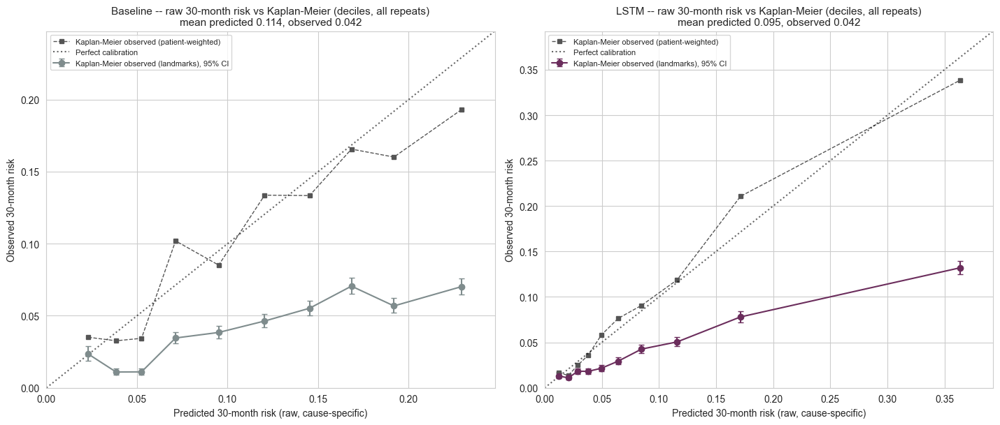

In [79]:
"""
Cause-specific survival evaluation of the RAW risks, and the paired signal test (LSTM vs Baseline).

Per outer fold (training fold -> censoring distribution; test fold -> metrics), with sksurv:
  cumulative_dynamic_auc   time-dependent AUROC at SURV_EVAL_TIMES_MONTHS
  concordance_index_ipcw   Uno's C truncated at 30 months
  brier_score, integrated_brier_score   at SURV_EVAL_TIMES_MONTHS and over 6-48 months (CS_PROB_MODELS only)
Fold metrics are averaged within a repeat; the table gives mean (SD) over repeats. The RSF's raw output is a score and
the LogReg's a cumulative incidence, so they get discrimination only.
Delta AUROC(t): the same IPCW AUROC in weighted form (cases 1 / G(T), controls followed past t; G = Kaplan-Meier of
the training fold, as in sksurv), so a patient-cluster bootstrap is a reweighting. Permutation null: within-fold
percentile ranks of the two models, swapped per patient with probability 1/2.
"""
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw, brier_score, integrated_brier_score
from scipy.stats import rankdata

cv_state = run_repeated_cv(models=["Baseline"])          # identical folds, same checkpoint as the other models
SURV_CAP_DAYS = MAX_HORIZON_DAYS + 1
SURV_T_DAYS = [round(h * MONTH_DAYS) for h in SURV_EVAL_TIMES_MONTHS]
SURV_T_COLS = [EVAL_HORIZONS_MONTHS.index(h) for h in SURV_EVAL_TIMES_MONTHS]
CS_PROB_MODELS = ["Baseline", "CoxPH", "GRU", "LSTM", "LSTM1", "Transformer"]      # raw output = 1 - S_1(t)
SURV_MODELS = ["Baseline"] + [m for m in CV_MODELS if any(k[0] == m for k in cv_state["folds"])]


def surv_y(idx, event=None):
    """sksurv (event, time) array for rows idx: `event` (default work disability; anything else censored), follow-up
    truncated at 48 months."""
    event = E_ALL if event is None else event
    t = T_ALL[idx]
    e = (event[idx] == 1) & (t <= MAX_HORIZON_DAYS)
    return np.array(list(zip(e, np.minimum(t, SURV_CAP_DAYS))), dtype=[("event", bool), ("time", float)])


def fold_surv_metrics(f, raw, prob, event=None):
    ytr, yte = surv_y(f["tr"], event), surv_y(f["te"], event)
    auc, _ = cumulative_dynamic_auc(ytr, yte, raw[:, SURV_T_COLS], SURV_T_DAYS)
    out = {f"AUROC {h} mo": a for h, a in zip(SURV_EVAL_TIMES_MONTHS, auc)}
    out[f"Uno C ({PRIMARY_HORIZON_MONTHS} mo)"] = concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL],
                                                                           tau=HORIZON_DAYS)[0]
    if prob:
        S = np.clip(1.0 - raw, 0.0, 1.0)
        bs = brier_score(ytr, yte, S[:, SURV_T_COLS], SURV_T_DAYS)[1]
        out.update({f"Brier {h} mo": v for h, v in zip(SURV_EVAL_TIMES_MONTHS, bs)})
        out["Integrated Brier (6-48 mo)"] = integrated_brier_score(ytr, yte, S, HORIZON_DAYS_GRID)
    return out


def model_folds(m):
    return {(r, k): v for (mm, r, k), v in cv_state["folds"].items() if mm == m}


def summarise_models(df, models, cols):
    rows = []
    for m in models:
        d = df[df["model"] == m]
        if len(d):
            rows.append({"Model": m, "Repeats": len(d), **{c: _fmt(d[c]) for c in cols}})
    return pd.DataFrame(rows).set_index("Model")


surv_folds = pd.DataFrame([{"model": m, "repeat": r, "fold": k, **fold_surv_metrics(f, f["raw"], m in CS_PROB_MODELS)}
                           for m in SURV_MODELS for (r, k), f in sorted(model_folds(m).items())])
surv_rep = surv_folds.groupby(["model", "repeat"]).mean(numeric_only=True).drop(columns="fold").reset_index()
surv_cols = [c for c in surv_rep.columns if c not in ("model", "repeat")]
surv_table = summarise_models(surv_rep, SURV_MODELS, surv_cols)
print("Cause-specific survival metrics of the RAW risks (work disability; other exits censored; sksurv, censoring "
      "distribution from each training fold), mean (SD) over repeats:")
display(surv_table)
surv_rep.to_csv("survival_metrics_by_repeat_model_revised_v21.csv", index=False)


# ------------------------------------------------------------------------------------------------ paired signal test
def _fold_entries(m_a="LSTM", m_b="Baseline"):
    """Per fold of both models: test rows, the two models' AUROC-at-t arrays (labels, weights) and scores."""
    fa, fb = model_folds(m_a), model_folds(m_b)
    out = []
    for key in sorted(set(fa) & set(fb)):
        a, b = fa[key], fb[key]
        assert np.array_equal(a["te"], b["te"]), "the two models must share their folds"
        tr, te = a["tr"], a["te"]
        G = CensoringKM(np.minimum(T_ALL[tr], SURV_CAP_DAYS), surv_y(tr)["event"].astype(int))
        cm = CensoringModel(censor_causes=(0, 2, 3)).fit(tr) if CENSORING_IPCW_ON else None
        T = np.minimum(T_ALL[te], SURV_CAP_DAYS)
        e = surv_y(te)["event"]
        lab = []
        for t_d, col in zip(SURV_T_DAYS, SURV_T_COLS):
            case, ctrl = e & (T <= t_d), T > t_d
            w = np.zeros(len(te))
            w[case] = 1.0 / np.maximum(G.at(T[case]), IPCW_MIN_G)
            w[ctrl] = 1.0
            wc = None
            if cm is not None:                                             # covariate-adjusted censoring weights
                wc = np.zeros(len(te))
                wc[case] = 1.0 / np.maximum(cm.G_at_days(te[case], T[case], before=True), IPCW_MIN_G)
                wc[ctrl] = 1.0 / np.maximum(cm.G_at_days(te[ctrl], t_d), IPCW_MIN_G)
            lab.append((case.astype(int), w, wc, col))
        out.append({"key": key, "tr": tr, "te": te, "code": LAND_CODE[te], "lab": lab, "pa": a["raw"], "pb": b["raw"],
                    "ra": rankdata(a["raw"][:, PRIMARY_COL]), "rb": rankdata(b["raw"][:, PRIMARY_COL])})
    return out


def delta_auc(entries, cnt=None, flip=None, covariate=False):
    """(AUROC_a, AUROC_b) at each time, mean over the folds of a repeat, then over repeats. cnt: patient bootstrap
    multiplicities; flip: per-patient swap of the two models (on percentile ranks)."""
    res = {}
    for f in entries:
        m = 1.0 if cnt is None else cnt[f["code"]]
        vals = []
        for y, w, wc, col in f["lab"]:
            ww = (wc if covariate else w) * m
            sa, sb = f["pa"][:, col], f["pb"][:, col]
            if flip is not None:
                sa, sb = rankdata(sa), rankdata(sb)
                s = flip[f["code"]]
                sa, sb = np.where(s, sb, sa), np.where(s, sa, sb)
            vals.append((w_auroc(y, sa, ww), w_auroc(y, sb, ww)))
        res.setdefault(f["key"][0], []).append(vals)
    per_rep = np.array([np.nanmean(v, axis=0) for v in res.values()])     # (repeats, times, 2)
    return np.nanmean(per_rep, axis=0)


if all(model_folds(m) for m in ("LSTM", "Baseline")):
    entries = _fold_entries()
    obs = delta_auc(entries)
    sk = np.nanmean([cumulative_dynamic_auc(surv_y(f["tr"]), surv_y(f["te"]), f["pa"][:, SURV_T_COLS], SURV_T_DAYS)[0]
                     for f in entries], axis=0)
    print(f"Check: weighted-form LSTM AUROC(t) vs sksurv cumulative_dynamic_auc, fold means: "
          + ", ".join(f"{h} mo {a:.4f} vs {s:.4f}" for h, a, s in zip(SURV_EVAL_TIMES_MONTHS, obs[:, 0], sk)))
    n_pt = len(PT_CODE)
    rng = np.random.RandomState(SEED)
    boots = np.array([delta_auc(entries, cnt=np.bincount(rng.randint(0, n_pt, n_pt), minlength=n_pt).astype(float))
                      for _ in range(BOOT_N)])
    d_obs = obs[:, 0] - obs[:, 1]
    d_boot = boots[:, :, 0] - boots[:, :, 1]
    rng = np.random.RandomState(SEED + 1)
    perms = np.array([(lambda r: r[:, 0] - r[:, 1])(delta_auc(entries, flip=rng.rand(n_pt) < 0.5))
                      for _ in range(PERM_N)])
    p_perm = (1 + (np.abs(perms) >= np.abs(d_obs)[None, :] - 1e-12).sum(0)) / (1 + PERM_N)
    signal = pd.DataFrame({
        "Horizon (mo)": SURV_EVAL_TIMES_MONTHS, "AUROC Baseline": obs[:, 1], "AUROC LSTM": obs[:, 0],
        "Delta AUROC (LSTM - Baseline)": d_obs,
        "95% CI (patient bootstrap)": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                       zip(np.nanpercentile(d_boot, 2.5, 0), np.nanpercentile(d_boot, 97.5, 0))],
        "Permutation null, 95% range": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                        zip(np.percentile(perms, 2.5, 0), np.percentile(perms, 97.5, 0))],
        "p (paired permutation)": p_perm}).set_index("Horizon (mo)")
    print(f"\nSIGNAL TEST -- LSTM vs Baseline ({', '.join(BASELINE_COLS)}), identical folds, "
          f"{len({f['key'][0] for f in entries})} repeat(s); {BOOT_N} bootstrap resamples, "
          f"{PERM_N} permutations:")
    display(signal.round(4))
    if CENSORING_IPCW_ON:
        cov = delta_auc(entries, covariate=True)
        print("Covariate-adjusted IPCW (censoring or competing exit modelled on the variables, fitted on "
              "each training fold): " + ", ".join(f"{h} mo: LSTM {a:.3f}, Baseline {b:.3f}, Delta {a - b:+.3f}"
                                                for h, (a, b) in zip(SURV_EVAL_TIMES_MONTHS, cov)))
else:
    print("Signal test skipped: the LSTM or the Baseline has no completed folds.")


# ------------------------------------------------------------------------------------------------ calibration vs KM
def km_risk(t, e, w=None, at=HORIZON_DAYS):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kmf = KaplanMeierFitter().fit(t, e, weights=w)
    s = float(kmf.survival_function_at_times(at).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(at).values
    return 1 - s, 1 - hi, 1 - lo


cal_models = [m for m in ["Baseline", "LSTM"] if model_folds(m)]
fig, axes = plt.subplots(1, len(cal_models), figsize=(7.2 * len(cal_models), 6.2), squeeze=False)
for ax, m in zip(axes[0], cal_models):
    fs = model_folds(m)
    p = np.concatenate([f["raw"][:, PRIMARY_COL] for f in fs.values()])
    rows = np.concatenate([f["te"] for f in fs.values()])
    t, e = np.minimum(T_ALL[rows], SURV_CAP_DAYS), surv_y(rows)["event"].astype(int)
    wpt = land["pt_weight"].values[rows]
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    pts = []
    for g in range(int(q.max()) + 1):
        k = q == g
        obs_, lo, hi = km_risk(t[k], e[k])
        pts.append((p[k].mean(), obs_, lo, hi, km_risk(t[k], e[k], wpt[k])[0]))
    pts = np.array(pts)
    ax.errorbar(pts[:, 0], pts[:, 1], yerr=[pts[:, 1] - pts[:, 2], pts[:, 3] - pts[:, 1]], fmt="o-",
                color=CV_COLORS[m], capsize=3, label="Kaplan-Meier observed (landmarks), 95% CI")
    ax.plot(pts[:, 0], pts[:, 4], "s--", color="#555555", ms=4, lw=1, label="Kaplan-Meier observed (patient-weighted)")
    hi_ = float(np.nanmax(pts[:, [0, 3]])) * 1.08
    ax.plot([0, hi_], [0, hi_], "k:", alpha=0.6, label="Perfect calibration")
    o_all = km_risk(t, e)[0]
    ax.set_title(f"{m} -- raw 30-month risk vs Kaplan-Meier (deciles, all repeats)\n"
                 f"mean predicted {p.mean():.3f}, observed {o_all:.3f}", fontsize=11)
    ax.set_xlabel("Predicted 30-month risk (raw, cause-specific)"); ax.set_ylabel("Observed 30-month risk")
    ax.set_xlim(0, hi_); ax.set_ylim(0, hi_); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_calibration_km_raw.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.16.4 Two-cause heads: work disability specifically, or leaving work for any reason?

The LSTM's second head estimates the cause-specific risk of an other exit; with the first it gives the risk of leaving
work for any reason. Each of the three risks is scored against each outcome (work disability, other exit, any exit from
work) with Uno's C and the time-dependent AUROC at 30 months, as in Section 11.16.3. A specific signal shows as the
disability head ranking work disability better than it ranks other exits. The any-exit row and column are the
composite-outcome sensitivity analysis.

In [80]:
"""
Two-cause heads -- work disability specifically vs leaving work for any reason (composite outcome), from the LSTM's
out-of-fold predictions (ctx["aux"] of every outer fold). Uno's C at 30 months and cumulative/dynamic AUROC at 30 months,
sksurv, censoring distribution from the training fold; the outcome's competing events are censored.
"""
lstm_folds = model_folds("LSTM") if "LSTM" in CV_MODELS else {}
if lstm_folds and all(f.get("aux") for f in lstm_folds.values()):
    OUTCOMES = {"Work disability": E_ALL, "Other exit": (C_ALL >= 2).astype(int),
                "Any exit from work (composite)": (C_ALL >= 1).astype(int)}
    RISKS = {"Disability head": lambda f: f["raw"], "Exit head": lambda f: f["aux"]["exit_raw"],
             "Any exit (both heads)": lambda f: f["aux"]["composite_raw"]}
    rows = []
    for (r, k), f in sorted(lstm_folds.items()):
        for rn, get in RISKS.items():
            raw = get(f)
            for on, ev in OUTCOMES.items():
                ytr, yte = surv_y(f["tr"], ev), surv_y(f["te"], ev)
                rows.append({"repeat": r, "fold": k, "risk": rn, "outcome": on,
                             "C": concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL], tau=HORIZON_DAYS)[0],
                             "AUROC": cumulative_dynamic_auc(ytr, yte, raw[:, [PRIMARY_COL]], [HORIZON_DAYS])[0][0]})
    two = pd.DataFrame(rows).groupby(["risk", "outcome", "repeat"])[["C", "AUROC"]].mean().reset_index()
    for metric in ["C", "AUROC"]:
        tab = two.groupby(["risk", "outcome"])[metric].agg(_fmt).unstack("outcome")
        tab = tab.reindex(index=list(RISKS), columns=list(OUTCOMES))
        print(f"LSTM two-cause heads -- {'Uno C' if metric == 'C' else 'time-dependent AUROC'} at "
              f"{PRIMARY_HORIZON_MONTHS} months, rows = risk, columns = outcome, mean (SD) over repeats:")
        display(tab)
    m_ = two.groupby(["risk", "outcome"])["C"].mean()
    print(f"Disability head: C {m_[('Disability head', 'Work disability')]:.3f} for work disability vs "
          f"{m_[('Disability head', 'Other exit')]:.3f} for other exits; exit head: "
          f"{m_[('Exit head', 'Other exit')]:.3f} for other exits vs {m_[('Exit head', 'Work disability')]:.3f} for "
          f"work disability.")
else:
    print("Two-cause analysis skipped: the LSTM was run without the exit head (SEQ_CONFIG['exit_head']) or has no "
          "completed folds.")

LSTM two-cause heads -- Uno C at 30 months, rows = risk, columns = outcome, mean (SD) over repeats:


outcome,Work disability,Other exit,Any exit from work (composite)
risk,,,
Disability head,0.722 (0.003),0.598 (0.004),0.653 (0.001)
Exit head,0.628 (0.014),0.624 (0.014),0.626 (0.007)
Any exit (both heads),0.705 (0.004),0.625 (0.008),0.661 (0.004)


LSTM two-cause heads -- time-dependent AUROC at 30 months, rows = risk, columns = outcome, mean (SD) over repeats:


outcome,Work disability,Other exit,Any exit from work (composite)
risk,,,
Disability head,0.719 (0.003),0.592 (0.004),0.648 (0.001)
Exit head,0.617 (0.015),0.612 (0.015),0.614 (0.008)
Any exit (both heads),0.700 (0.005),0.617 (0.008),0.654 (0.004)


Disability head: C 0.722 for work disability vs 0.598 for other exits; exit head: 0.624 for other exits vs 0.628 for work disability.


## 11.16.5 Results overview

The main comparisons in a few figures, from the pooled out-of-fold predictions above (nothing is refitted):

1. **Forest plot**: ΔC-index of every model against the LogReg, visit level (30-month AUROC) and patient level (the highest
   risk in the 60 months before onset; event-free patients: the risk at the last landmark), paired on identical folds, with 95 % patient-cluster bootstrap CIs and H1b's non-inferiority
   margin.
2. **Observed risk by predicted-risk group** (< 2 %, 2–5 %, 5–10 %, ≥ 10 % 30-month risk) and the **cumulative
   incidence** of work disability from the landmark in each group (Aalen–Johansen, other exits competing).
3. **Natural frequencies**: what the alarm rule does per 100 visits and per 100 patients.
4. **Risk before the decisive visit**: mean predicted risk and share of visits alarmed by months before the last
   landmark of the patient's window, event vs event-free patients — rising risk (early warning) or a persistently
   higher level (risk stratification)?
5. **Visit-level decision curves** of every model, with the data-driven threshold and revised_v16's R = 10 marked.
6. **The patient scoring rule**: the main rule (event patients: any alarm in the 60 months before onset; event-free: the last landmark) vs revised_v18's any alarm in the 30-month window vs revised_v17's last landmark of the 30-month window.


1. Delta C-index vs LogReg (paired on identical folds; 95% patient-cluster bootstrap CI, 1000 resamples):


,,Delta,95% CI
Level,Model,,
Visit (30-month AUROC),LSTM-8 (main),0.000,"[-0.005, +0.007]"
"Patient (C-index, highest risk <= 60 mo before onset / at the last landmark)",LSTM-8 (main),-0.003,"[-0.006, +0.001]"
Visit (30-month AUROC),LSTM-16 (last 16 visits),0.000,"[-0.006, +0.007]"
"Patient (C-index, highest risk <= 60 mo before onset / at the last landmark)",LSTM-16 (last 16 visits),-0.002,"[-0.006, +0.001]"
Visit (30-month AUROC),LSTM-4 (last 4 visits),0.001,"[-0.005, +0.007]"
"Patient (C-index, highest risk <= 60 mo before onset / at the last landmark)",LSTM-4 (last 4 visits),-0.002,"[-0.005, +0.001]"
Visit (30-month AUROC),LSTM-1 (current visit),-0.000,"[-0.006, +0.006]"
"Patient (C-index, highest risk <= 60 mo before onset / at the last landmark)",LSTM-1 (current visit),-0.002,"[-0.005, +0.001]"
Visit (30-month AUROC),RSF,0.003,"[-0.021, +0.027]"


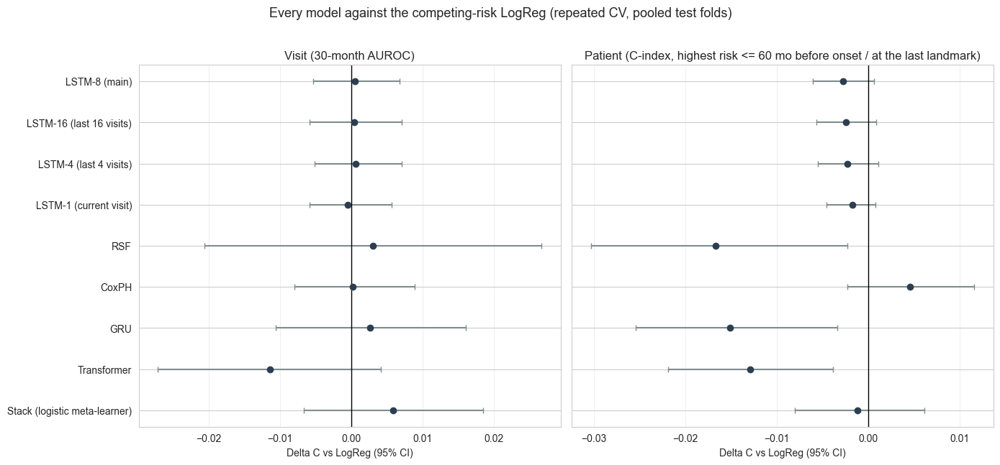


2. Visit level by predicted 30-month risk: share of landmark visits, patients with a visit in the group, mean predicted and observed onset rate within 30 months (IPCW), mean over repeats (overall onset rate 0.041):


Share of visits  Patients  \
Model                         Risk group                              
LSTM-8 (main)                 < 2%                  0.215     523.4   
                              2-5%                  0.540     845.6   
                              5-10%                 0.198     548.8   
                              >= 10%                0.046     222.2   
LSTM-16 (last 16 visits)      < 2%                  0.213     518.0   
                              2-5%                  0.542     844.8   
                              5-10%                 0.198     550.4   
                              >= 10%                0.047     224.2   
LSTM-4 (last 4 visits)        < 2%                  0.229     543.2   
                              2-5%                  0.529     842.2   
                              5-10%                 0.194     539.0   
                              >= 10%                0.048     224.6   
LSTM-1 (current visit)        < 2%                  0.224     548.4   
                              2-5%                  0.528     834.8   
                              5-10%                 0.199     537.2   
                              >= 10%                0.049     226.6   
LogReg (last visit)           < 2%                  0.268     589.6   
                              2-5%                  0.509     834.0   
                              5-10%                 0.175     508.8   
                              >= 10%                0.048     229.8   
RSF                           < 2%                  0.305     604.2   
                              2-5%                  0.395     809.4   
                              5-10%                 0.240     659.4   
                              >= 10%                0.059     265.2   
CoxPH                         < 2%                  0.193     507.0   
                              2-5%                  0.608     892.4   
                              5-10%                 0.157     523.6   
                              >= 10%                0.042     247.2   
GRU                           < 2%                  0.290     562.8   
                              2-5%                  0.471     805.8   
                              5-10%                 0.177     571.6   
                              >= 10%                0.062     206.4   
Transformer                   < 2%                  0.286     583.4   
                              2-5%                  0.490     759.8   
                              5-10%                 0.154     476.8   
                              >= 10%                0.070     255.0   
Stack (logistic meta-learner) < 2%                  0.322     606.8   
                              2-5%                  0.425     804.2   
                              5-10%                 0.186     555.0   
                              >= 10%                0.067     287.4   

                                          Mean predicted  Observed (IPCW)  
Model                         Risk group                                   
LSTM-8 (main)                 < 2%                 0.016            0.014  
                              2-5%                 0.033            0.027  
                              5-10%                0.067            0.073  
                              >= 10%               0.151            0.151  
LSTM-16 (last 16 visits)      < 2%                 0.016            0.015  
                              2-5%                 0.033            0.027  
                              5-10%                0.067            0.073  
                              >= 10%               0.151            0.151  
LSTM-4 (last 4 visits)        < 2%                 0.016            0.015  
                              2-5%                 0.032            0.028  
                              5-10%                0.067            0.074  
                              >= 10%               0.151            0.1

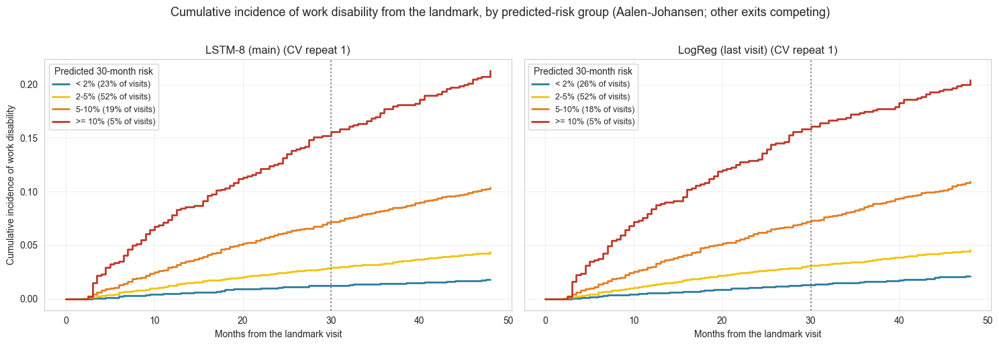


3. Natural frequencies -- visit level (alarms at each fold's threshold) and per 100 patients at the cohort's event share (14 of 100 patients have an onset; patient rule: event patients: any alarm in the 60 months before onset; event-free patients: the alarm at their last landmark):


,Alarms per 100 visits,Of 100 alarms: onset <= 30 mo,Of 100 visits before an onset: alarmed,Per 100 patients: onsets flagged,onsets missed,"flagged, no onset","not flagged, no onset",Patients flagged per onset caught
Model,,,,,,,,
LSTM-8 (main),37.7,7.2,66.3,11.9,2.3,25.4,60.5,3.1
LSTM-16 (last 16 visits),36.7,7.3,65.4,12.0,2.2,24.4,61.5,3.0
LSTM-4 (last 4 visits),37.9,7.2,66.9,12.0,2.1,25.3,60.6,3.1
LSTM-1 (current visit),39.1,7.0,67.4,12.0,2.2,26.1,59.7,3.2
LogReg (last visit),41.9,6.8,69.0,12.4,1.8,30.9,55.0,3.5
RSF,46.9,6.5,70.7,12.8,1.3,46.7,39.1,4.6
CoxPH,41.3,6.7,66.5,12.6,1.6,32.2,53.7,3.6
GRU,31.6,8.0,61.6,11.5,2.7,20.7,65.1,2.8
Transformer,28.5,8.3,57.7,10.9,3.3,19.2,66.7,2.8


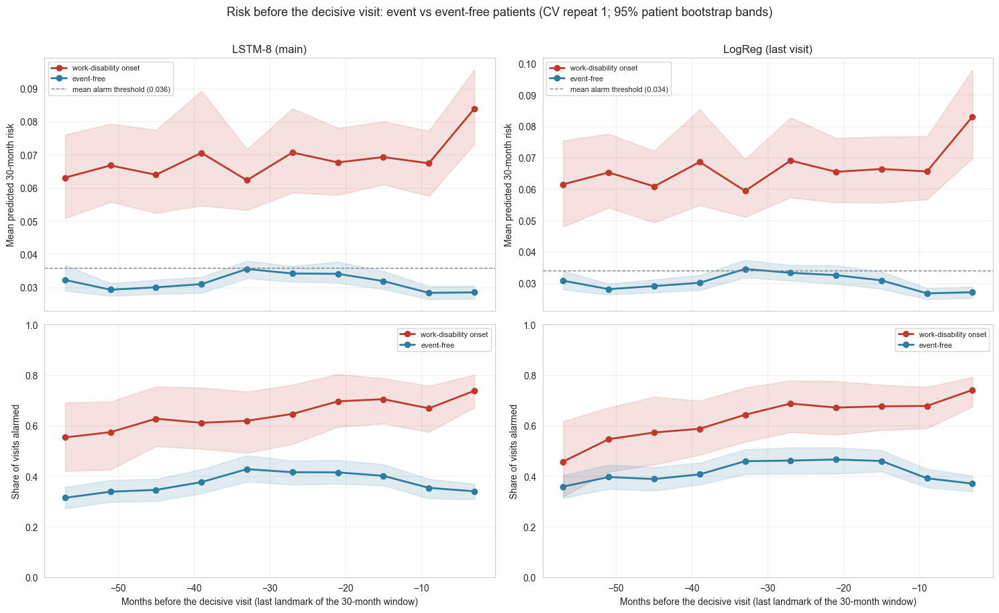

4. A flat, higher line for event patients = risk stratification (a persistently higher level); a line that rises towards the decisive visit = early warning.


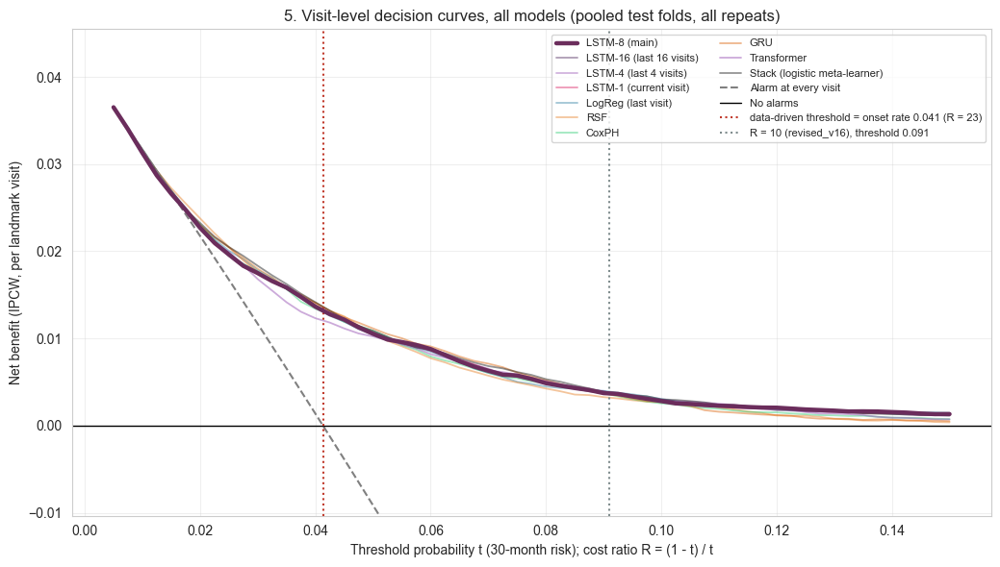


6. Patient level under three scoring rules (mean over repeats; C-index of the patient score, sensitivity and specificity of the patient flag; each rule on its own evaluable patients). The main rule gives event patients 60 months of visits to alarm once and judges event-free patients at one visit, so it has the highest sensitivity; the 30-month rules judge both groups over the same window:


events: any alarm <= 60 mo; event-free: last landmark (main)  \
                                                                                   C-index   
Model                                                                                        
LSTM-8 (main)                                                              0.915             
LSTM-16 (last 16 visits)                                                   0.915             
LSTM-4 (last 4 visits)                                                     0.915             
LSTM-1 (current visit)                                                     0.916             
LogReg (last visit)                                                        0.917             
RSF                                                                        0.901             
CoxPH                                                                      0.922             
GRU                                                                        0.902             
Transformer                                                                0.904             
Stack (logistic meta-learner)                                              0.916             

                                                                \
                              sensitivity specificity patients   
Model                                                            
LSTM-8 (main)                       0.838       0.704   1057.0   
LSTM-16 (last 16 visits)            0.846       0.716   1057.0   
LSTM-4 (last 4 visits)              0.850       0.706   1057.0   
LSTM-1 (current visit)              0.845       0.696   1057.0   
LogReg (last visit)                 0.874       0.640   1057.0   
RSF                                 0.905       0.455   1057.0   
CoxPH                               0.888       0.625   1057.0   
GRU                                 0.812       0.759   1057.0   
Transformer                         0.766       0.777   1057.0   
Stack (logistic meta-learner)       0.896       0.571   1057.0   

                              any alarm, 30-mo window (revised_v18)  \
                                                            C-index   
Model                                                                 
LSTM-8 (main)                                                 0.799   
LSTM-16 (last 16 visits)                                      0.800   
LSTM-4 (last 4 visits)                                        0.800   
LSTM-1 (current visit)                                        0.800   
LogReg (last visit)                                           0.798   
RSF                                                           0.785   
CoxPH                                                         0.785   
GRU                                                           0.802   
Transformer                                                   0.806   
Stack (logistic meta-learner)                                 0.799   

                                                                \
                              sensitivity specificity patients   
Model                                                            
LSTM-8 (main)                       0.809       0.503    833.0   
LSTM-16 (last 16 visits)            0.813       0.514    833.0   
LSTM-4 (last 4 visits)              0.818       0.505    833.0   
LSTM-1 (current visit)              0.811       0.492    833.0   
LogReg (last visit)                 0.831       0.447    833.0   
RSF                                 0.855       0.386    833.0   
CoxPH                               0.821       0.434    833.0   
GRU                                 0.732       0.613    833.0   
Transformer                         0.719       0.653    833.0   
Stack (logistic meta-learner)       0.850       0.427    833.0   

                              last landmark, 30-mo window (revised_v17)  \
                                                                C-index   
Model          

In [81]:
"""
Results overview (Section 11.16.5), from the pooled out-of-fold predictions already computed (nothing is refitted):
  1. forest plot of Delta C-index vs the LogReg (visit and patient level), paired, 95% patient-cluster bootstrap CIs;
  2. observed 30-month onset rate by predicted-risk group (visit level) and cumulative incidence by group
     (Aalen-Johansen, other exits competing) for LSTM-8 and the LogReg;
  3. natural frequencies per 100 visits and per 100 patients;
  4. risk and share alarmed by months before the decisive (last window) landmark, event vs event-free patients;
  5. visit-level decision curves of every model;
  6. patient scoring rules side by side (last landmark / any alarm / first landmark).
"""
OV_MODELS = [m for m in CV_MODELS if m in MODEL_RESULTS]
_PT_LEVEL = "Patient (C-index, " + {"any": "highest risk in the window)", "last": "risk at the last landmark)",
                                   "mixed": f"highest risk <= {EVENT_LOOKBACK_MONTHS} mo before onset / at the last "
                                            "landmark)"}[PATIENT_RULE]
OV_REF = "LogReg"
OV_BOOT = 200 if SMOKE else 1000
_lab = lambda m: MODEL_LABELS.get(m, m)
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
PI_VISIT = float(np.average(_y30[_w30 > 0], weights=_w30[_w30 > 0]))


def _pt_reps(m):
    return {r: pr["pt"] for (mm, r), pr in MODEL_RESULTS[m]["preds"].items() if mm == m}


_OV_PT_BOOT = [cnt for _, cnt in patient_boot_counts(OV_BOOT, seed=2041)]


def patient_delta_c(a, b, col="score"):
    """Delta patient C-index (a - b) on the same patients, mean over paired repeats, 95% patient bootstrap CI."""
    ra, rb = _pt_reps(a), _pt_reps(b)
    preps = []
    for r in sorted(set(ra) & set(rb)):
        ix = ra[r].index.intersection(rb[r].index)
        y = ra[r].loc[ix, "y"].values
        preps.append((auc_prep(y, ra[r].loc[ix, col].values), auc_prep(y, rb[r].loc[ix, col].values),
                      PT_CODE.get_indexer(ix)))
    if not preps:
        return None
    f = lambda cnt: np.mean([auc_w(pa, cnt[c]) - auc_w(pb, cnt[c]) for pa, pb, c in preps])
    B = np.array([f(cnt) for cnt in _OV_PT_BOOT])
    return {"Delta": f(np.ones(len(PT_CODE))), "CI low": np.nanpercentile(B, 2.5), "CI high": np.nanpercentile(B, 97.5)}


# ------------------------------------------------------------------------------------------------ 1. forest plot
forest = []
for m in [x for x in OV_MODELS if x != OV_REF]:
    dv, dp = paired_delta(m, OV_REF), patient_delta_c(m, OV_REF)
    if dv is not None:
        forest.append({"Model": _lab(m), "Level": "Visit (30-month AUROC)",
                       **{k: dv[k] for k in ("Delta", "CI low", "CI high")}})
    if dp is not None:
        forest.append({"Model": _lab(m), "Level": _PT_LEVEL, **dp})
forest_df = pd.DataFrame(forest)
if not forest_df.empty:
    forest_df["95% CI"] = forest_df.apply(lambda r: f"[{r['CI low']:+.3f}, {r['CI high']:+.3f}]", axis=1)
    print(f"1. Delta C-index vs {OV_REF} (paired on identical folds; 95% patient-cluster bootstrap CI, {OV_BOOT} resamples):")
    display(forest_df.set_index(["Level", "Model"])[["Delta", "95% CI"]].round(3))
    levels = list(dict.fromkeys(forest_df["Level"]))
    order = list(dict.fromkeys(forest_df["Model"]))[::-1]
    fig, axes = plt.subplots(1, len(levels), figsize=(7 * len(levels), 0.5 * len(order) + 1.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, lev in zip(axes, levels):
        d = forest_df[forest_df["Level"] == lev].set_index("Model").reindex(order)
        ys = np.arange(len(order))
        ax.errorbar(d["Delta"], ys, xerr=[d["Delta"] - d["CI low"], d["CI high"] - d["Delta"]], fmt="o",
                    color="#2c3e50", ecolor="#7f8c8d", capsize=3, ms=6)
        ax.axvline(0, color="black", lw=1)
        ax.set_yticks(ys); ax.set_yticklabels(order); ax.set_title(lev)
        ax.set_xlabel(f"Delta C vs {OV_REF} (95% CI)"); ax.grid(axis="x", alpha=0.3)
    plt.suptitle(f"Every model against the competing-risk LogReg (repeated CV, pooled test folds)", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_overview_forest.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    forest_df.to_csv("overview_delta_c_revised_v21.csv", index=False)

# ------------------------------------------------------------------------------------------------ 2. risk groups
RISK_CUTS = [0.02, 0.05, 0.10]
RISK_LABELS = ["< 2%", "2-5%", "5-10%", ">= 10%"]
rg_rows = []
for m in OV_MODELS:
    for (mm, r), pr in MODEL_RESULTS[m]["preds"].items():
        if mm != m:
            continue
        p = pr["P"][:, PRIMARY_COL]
        grp = np.digitize(p, RISK_CUTS)
        for j, lg in enumerate(RISK_LABELS):
            k = grp == j
            kr = k & (_w30 > 0)
            ok = _w30[kr].sum() > 0
            rg_rows.append({"Model": _lab(m), "Risk group": lg, "Share of visits": float(k.mean()),
                            "Patients": len(np.unique(PID_ALL[k])),
                            "Mean predicted": float(np.average(p[kr], weights=_w30[kr])) if ok else np.nan,
                            "Observed (IPCW)": float(np.average(_y30[kr], weights=_w30[kr])) if ok else np.nan})
rg = pd.DataFrame(rg_rows).groupby(["Model", "Risk group"], sort=False).mean()
print(f"\n2. Visit level by predicted 30-month risk: share of landmark visits, patients with a visit in the group, mean "
      f"predicted and observed onset rate within 30 months (IPCW), mean over repeats (overall onset rate {PI_VISIT:.3f}):")
display(rg.round(3))
rg.to_csv("overview_risk_groups_revised_v21.csv")


def aalen_johansen(t, c, grid, cause=1):
    """Cumulative incidence of `cause` at the times `grid` (Aalen-Johansen; every other observed cause competes, 0 =
    censored)."""
    t, c = np.asarray(t, float), np.asarray(c, int)
    ut = np.unique(t[c > 0])
    if not len(ut):
        return np.zeros(len(grid))
    n_at = len(t) - np.searchsorted(np.sort(t), ut, side="left")
    d1 = pd.Series((c == cause).astype(float)).groupby(t).sum().reindex(ut).fillna(0).values
    da = pd.Series((c > 0).astype(float)).groupby(t).sum().reindex(ut).fillna(0).values
    s_before = np.r_[1.0, np.cumprod(1 - da / n_at)[:-1]]
    F = np.cumsum(s_before * d1 / n_at)
    i = np.searchsorted(ut, grid, side="right") - 1
    return np.where(i >= 0, F[np.maximum(i, 0)], 0.0)


_grid_mo = np.linspace(0, MAX_HORIZON_MONTHS, 97)
_cif_models = [m for m in ["LSTM", OV_REF] if m in MODEL_RESULTS]
if _cif_models:
    fig, axes = plt.subplots(1, len(_cif_models), figsize=(7.5 * len(_cif_models), 5), sharey=True)
    axes = np.atleast_1d(axes)
    _cols = ["#2c7da0", "#f1c40f", "#e67e22", "#c0392b"]
    for ax, m in zip(axes, _cif_models):
        pr = MODEL_RESULTS[m]["preds"][(m, min(r for (mm, r) in MODEL_RESULTS[m]["preds"] if mm == m))]
        grp = np.digitize(pr["P"][:, PRIMARY_COL], RISK_CUTS)
        for j, lg in enumerate(RISK_LABELS):
            k = grp == j
            if k.sum() < 20:
                continue
            ax.step(_grid_mo, aalen_johansen(T_ALL[k] / MONTH_DAYS, C_ALL[k], _grid_mo), where="post", color=_cols[j],
                    lw=2, label=f"{lg} ({k.mean():.0%} of visits)")
        ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
        ax.set_xlabel("Months from the landmark visit"); ax.set_title(f"{_lab(m)} (CV repeat 1)")
        ax.grid(alpha=0.3); ax.legend(title="Predicted 30-month risk", fontsize=9)
    axes[0].set_ylabel("Cumulative incidence of work disability")
    plt.suptitle("Cumulative incidence of work disability from the landmark, by predicted-risk group "
                 "(Aalen-Johansen; other exits competing)", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_overview_cif_by_risk.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ 3. natural frequencies
pi = COHORT_EVENT_SHARE
nf_rows = []
for m in OV_MODELS:
    vt, pt = MODEL_RESULTS[m]["visit_table"]["Value"], MODEL_RESULTS[m]["patient_table"]["Value"]
    res_df = MODEL_RESULTS[m]["res_df"]
    sens, spec = pt["sensitivity"], pt["specificity"]
    caught, false_flag = 100 * pi * sens, 100 * (1 - pi) * (1 - spec)
    nf_rows.append({"Model": _lab(m),
                    "Alarms per 100 visits": res_df["alerts_per_100"].mean(),
                    "Of 100 alarms: onset <= 30 mo": 100 * vt["ppv"],
                    "Of 100 visits before an onset: alarmed": 100 * vt["sensitivity"],
                    "Per 100 patients: onsets flagged": caught,
                    "onsets missed": 100 * pi * (1 - sens),
                    "flagged, no onset": false_flag,
                    "not flagged, no onset": 100 * (1 - pi) * spec,
                    "Patients flagged per onset caught": (caught + false_flag) / caught if caught > 0 else np.nan})
nf_df = pd.DataFrame(nf_rows).set_index("Model")
print(f"\n3. Natural frequencies -- visit level (alarms at each fold's threshold) and per 100 patients at the cohort's event "
      f"share ({100 * pi:.0f} of 100 patients have an onset; patient rule: "
      f"{PATIENT_RULE_TEXT}):")
display(nf_df.round(1))
nf_df.to_csv("overview_natural_frequencies_revised_v21.csv")

# ------------------------------------------------------------------------------------------------ 4. risk before the decisive visit
TRAJ_BINS = np.arange(0, 61, 6)            # months before the last landmark of the window (the decisive visit)
TRAJ_BOOT = 100 if SMOKE else 300


def trajectory(m):
    """Per patient and 6-month bin before the decisive landmark: mean calibrated 30-month risk and share of landmarks
    alarmed (CV repeat 1), with y (1 = event patient)."""
    pr = MODEL_RESULTS[m]["preds"][(m, min(r for (mm, r) in MODEL_RESULTS[m]["preds"] if mm == m))]
    f = pr["pt"]
    p = pr["P"][:, PRIMARY_COL]
    dl = f["day_last"].reindex(PID_ALL).values
    mb = (dl - VDAY_ALL) / MONTH_DAYS
    k = np.isfinite(mb) & (mb >= 0) & (mb < TRAJ_BINS[-1])
    d = pd.DataFrame({"pid": PID_ALL[k], "bin": np.digitize(mb[k], TRAJ_BINS) - 1, "p": p[k],
                      "a": (p >= pr["visit_thr"]["target"])[k], "y": f["y"].reindex(PID_ALL[k]).values})
    return d.groupby(["y", "pid", "bin"]).agg(p=("p", "mean"), a=("a", "mean")).reset_index(), \
        float(np.nanmean(pr["visit_thr"]["target"]))


def _mean_ci(v, rng):
    v = np.asarray(v, float)
    b = [rng.choice(v, len(v)).mean() for _ in range(TRAJ_BOOT)]
    return v.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5)


_tm = [m for m in ["LSTM", OV_REF] if m in MODEL_RESULTS]
if _tm:
    fig, axes = plt.subplots(2, len(_tm), figsize=(7.5 * len(_tm), 9), sharex=True)
    axes = np.array(axes).reshape(2, len(_tm))
    rng_t = np.random.default_rng(2042)
    mids = -(TRAJ_BINS[:-1] + 3)
    traj_rows = []
    for c_, m in enumerate(_tm):
        per, thr_m = trajectory(m)
        for yv, col, lab_y in [(1, "#c0392b", "work-disability onset"), (0, "#2c7da0", "event-free")]:
            for row_, what in [(0, "p"), (1, "a")]:
                est = [_mean_ci(per.loc[(per.y == yv) & (per.bin == b), what], rng_t)
                       if ((per.y == yv) & (per.bin == b)).sum() >= 5 else (np.nan,) * 3 for b in range(len(mids))]
                e, lo, hi = (np.array(x) for x in zip(*est))
                axes[row_, c_].plot(mids, e, "o-", color=col, lw=2, label=lab_y)
                axes[row_, c_].fill_between(mids, lo, hi, color=col, alpha=0.15)
                if row_ == 0:
                    traj_rows += [{"Model": _lab(m), "Group": lab_y, "Months before decisive visit": -mm_, "Mean risk": ee,
                                   "Patients": int(((per.y == yv) & (per.bin == b)).sum())}
                                  for b, (mm_, ee) in enumerate(zip(mids, e))]
        axes[0, c_].axhline(thr_m, color="gray", ls="--", lw=1, label=f"mean alarm threshold ({thr_m:.3f})")
        axes[0, c_].set_title(_lab(m)); axes[0, c_].set_ylabel("Mean predicted 30-month risk")
        axes[1, c_].set_ylabel("Share of visits alarmed"); axes[1, c_].set_ylim(0, 1)
        axes[1, c_].set_xlabel("Months before the decisive visit (last landmark of the 30-month window)")
        for ax in axes[:, c_]:
            ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.suptitle("Risk before the decisive visit: event vs event-free patients (CV repeat 1; 95% patient bootstrap bands)",
                 y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_overview_risk_before_decision.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()
    pd.DataFrame(traj_rows).to_csv("overview_risk_before_decision_revised_v21.csv", index=False)
    print("4. A flat, higher line for event patients = risk stratification (a persistently higher level); a line that "
          "rises towards the decisive visit = early warning.")

# ------------------------------------------------------------------------------------------------ 5. decision curves
_pts = np.linspace(0.005, 0.15, 59)
fig, ax = plt.subplots(figsize=(10.5, 6))
for m in OV_MODELS:
    p, y, w, _, _ = stacked(m, MODEL_RESULTS[m]["preds"])
    ax.plot(_pts, ipcw_net_benefit(y, p, w, _pts)[0], label=_lab(m), **model_style(m))
ax.plot(_pts, ipcw_net_benefit(y, p, w, _pts)[1], color="gray", ls="--", label="Alarm at every visit")
ax.axhline(0, color="black", lw=1, label="No alarms")
ax.axvline(PI_VISIT, color="#c0392b", ls=":", lw=1.5,
           label=f"data-driven threshold = onset rate {PI_VISIT:.3f} (R = {(1 - PI_VISIT) / PI_VISIT:.0f})")
ax.axvline(1 / 11, color="#7f8c8d", ls=":", lw=1.5, label="R = 10 (revised_v16), threshold 0.091")
ax.set_ylim(-0.25 * PI_VISIT, 1.1 * PI_VISIT)
ax.set_xlabel("Threshold probability t (30-month risk); cost ratio R = (1 - t) / t")
ax.set_ylabel("Net benefit (IPCW, per landmark visit)")
ax.set_title("5. Visit-level decision curves, all models (pooled test folds, all repeats)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_overview_decision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ 6. patient scoring rules
if PATIENT_RULE == "mixed":
    PT_RULES = [(f"events: any alarm <= {EVENT_LOOKBACK_MONTHS} mo; event-free: last landmark (main)", "score", "flag"),
                ("any alarm, 30-mo window (revised_v18)", "score_max_30", "flag_any_30"),
                ("last landmark, 30-mo window (revised_v17)", "score_last_30", "flag_last_30")]
else:
    PT_RULES = [("any alarm" + (" (main)" if PATIENT_RULE == "any" else ""), "score_max", "flag_any"),
                ("last landmark" + (" (main)" if PATIENT_RULE == "last" else ""), "score_last", "flag_last"),
                ("first landmark", "score_first", "flag_first")]
rule_rows = []
for m in OV_MODELS:
    for r, f in _pt_reps(m).items():
        row = {"Model": _lab(m)}
        for rule, sc, fl in PT_RULES:
            ok = f[sc].notna().values & f[fl].notna().values      # the 30-month rules have their own patients
            y, a = f["y"].values[ok], f[fl].values[ok] == 1
            row[(rule, "C-index")] = w_auroc(y, f[sc].values[ok], np.ones(int(ok.sum())))
            row[(rule, "sensitivity")] = float(a[y == 1].mean())
            row[(rule, "specificity")] = float(1 - a[y == 0].mean())
            row[(rule, "patients")] = int(ok.sum())
        rule_rows.append(row)
rule_df = pd.DataFrame(rule_rows).groupby("Model", sort=False).mean()
rule_df.columns = pd.MultiIndex.from_tuples(rule_df.columns)
print("\n6. Patient level under three scoring rules (mean over repeats; C-index of the patient score, sensitivity and "
      "specificity of the patient flag; each rule on its own evaluable patients). The main rule gives event patients "
      "60 months of visits to alarm once and judges event-free patients at one visit, so it has the highest "
      "sensitivity; the 30-month rules judge both groups over the same window:")
display(rule_df.round(3))
rule_df.to_csv("overview_patient_rules_revised_v21.csv")


## 11.16.6 Risk trajectories

How each patient's predicted risk moves over time, from the pooled out-of-fold predictions (nothing is refitted). The
time axis is **months before the work-disability onset** (event patients) or **months before the last landmark**
(event-free patients — the visit the patient rule judges them at). Risk = the calibrated 30-month risk at each
landmark, averaged over the CV repeats (every landmark is held out once per repeat); a landmark counts as alarmed when
it alarmed in at least half of the repeats.

1. **Individual trajectories** of 12 randomly drawn event and 12 event-free patients (alarmed visits marked), with the
   60 months the patient rule reads shaded.
2. **Median and interquartile range** of the risk by 6-month bin, 0–120 months back (one value per patient and bin),
   and the same for the **risk relative to the visit's alarm threshold** (log ratio; > 0 = alarm), the quantity the
   alarm rule reads.
3. **Heat map** of every event patient's risk relative to the threshold over the 60 months before onset, sorted by the
   earliest alarm: a rising band toward the right is early warning, a band that is red throughout is a persistently
   high-risk patient.
4. **Sensitivity by look-back**: the share of event patients with any alarm in the last X months before onset,
   X = 6–120 months, every model, with the event-free patients' specificity at their last landmark. The main rule is
   X = 60; revised_v18's window was 30.


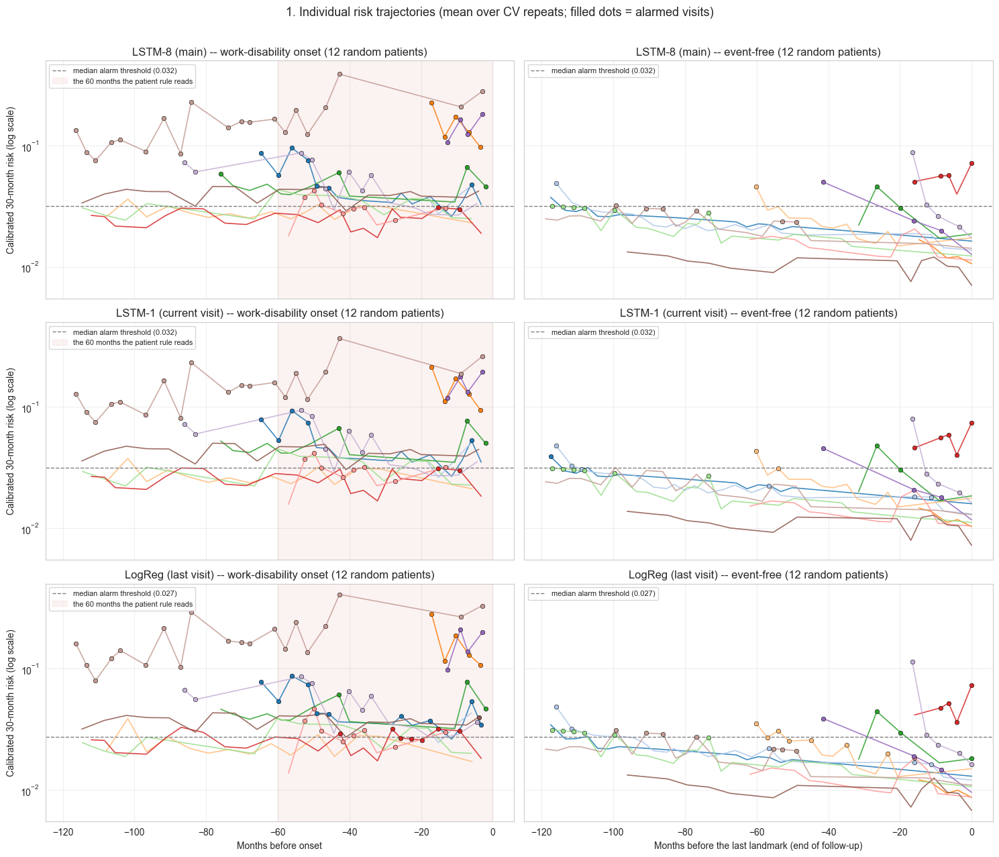

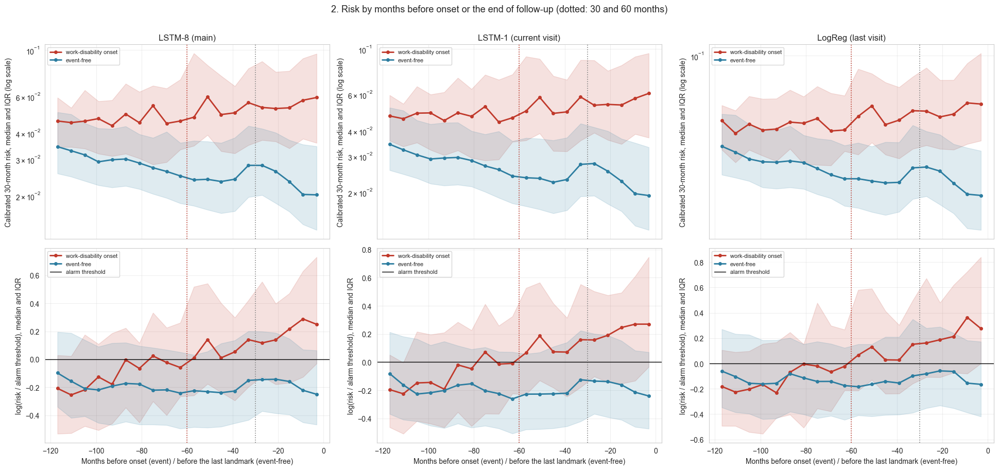

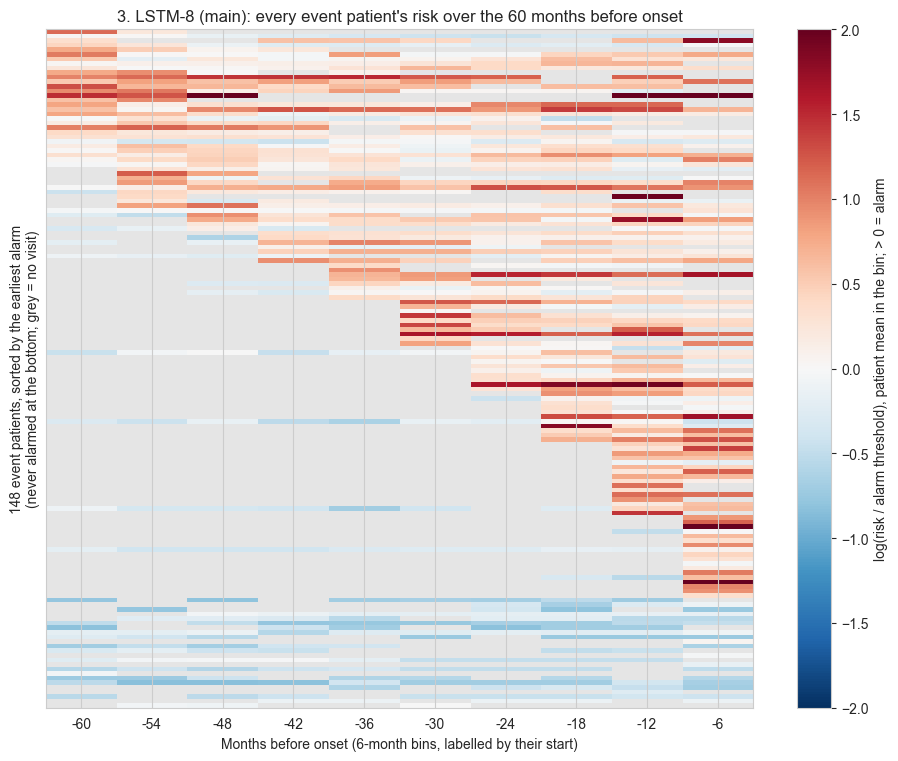

3. 124 of 148 event patients alarmed in the 60 months before onset (LSTM-8 (main), alarm in >= half of the repeats); earliest alarm a median 29 months before onset.


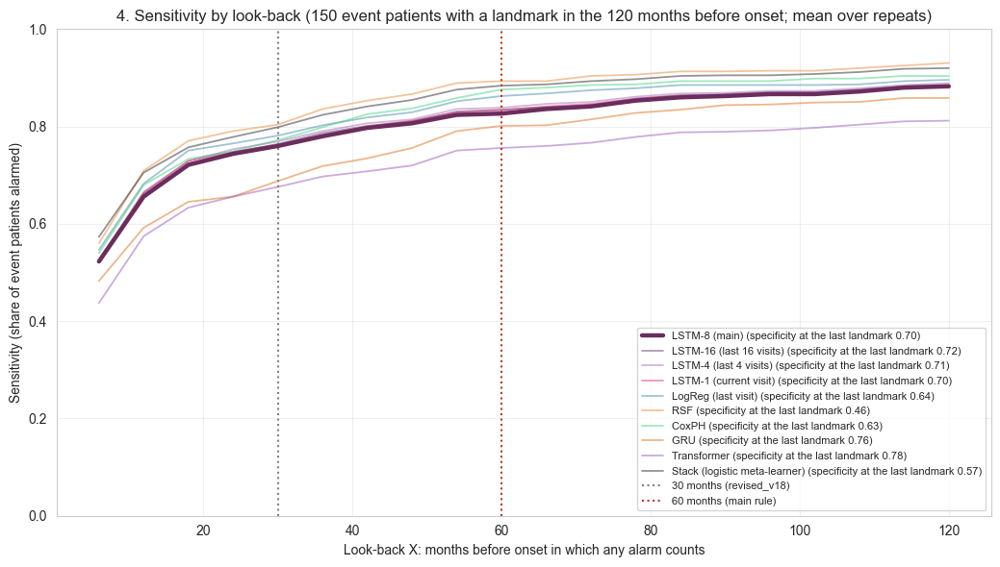

4. Sensitivity at 30 / 60 / 120 months of look-back (patients with no landmark in the last X months count as missed, so the 60-month value can sit slightly below the main table's):


Look-back (months),30,60,120
Model,,,
CoxPH,0.772,0.876,0.904
GRU,0.688,0.801,0.859
LSTM-1 (current visit),0.763,0.833,0.885
LSTM-16 (last 16 visits),0.764,0.835,0.885
LSTM-4 (last 4 visits),0.769,0.839,0.889
LSTM-8 (main),0.760,0.827,0.883
LogReg (last visit),0.781,0.863,0.896
RSF,0.804,0.893,0.931
Stack (logistic meta-learner),0.799,0.884,0.920


In [82]:
"""
Risk trajectories (Section 11.16.6), from the pooled out-of-fold predictions (nothing is refitted). Time axis: months
before the onset (event patients; landmarks whose follow-up ends in that onset) or before the patient's last landmark
(event-free patients). Risk = the calibrated 30-month risk per landmark averaged over the CV repeats; alarmed = alarmed
in >= half of the repeats.
"""
RT_MODELS = [m for m in ["LSTM", "LSTM1", "LogReg"] if m in MODEL_RESULTS]
RT_BACK_MONTHS, RT_BIN, RT_N_SHOW = 120, 6, 12
RT_EDGES = np.arange(0, RT_BACK_MONTHS + RT_BIN, RT_BIN)
_is_ev_land = (_stratum == "Event") & (land["event"].values == 1)
_mb_neg = (_last_land - _vdate.values) / np.timedelta64(1, "D") / MONTH_DAYS
RT_MB = np.where(_is_ev_land, T_ALL / MONTH_DAYS, np.where(_neg_any, _mb_neg, np.nan))
RT_Y = np.where(_is_ev_land, 1, 0)
RT_OK = np.isfinite(RT_MB) & (RT_MB >= 0) & (RT_MB <= RT_BACK_MONTHS)


def mean_risk_over_repeats(m):
    """Per landmark: the calibrated 30-month risk and its alarm threshold averaged over the CV repeats, and the share
    of repeats in which the landmark alarmed."""
    reps = [pr for (mm, _), pr in MODEL_RESULTS[m]["preds"].items() if mm == m]
    P = np.nanmean([pr["P"][:, PRIMARY_COL] for pr in reps], axis=0)
    T = np.nanmean([pr["visit_thr"]["target"] for pr in reps], axis=0)
    A = np.nanmean([(pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]).astype(float) for pr in reps], axis=0)
    return P, T, A


def rt_frame(m):
    P, T, A = mean_risk_over_repeats(m)
    k = np.flatnonzero(RT_OK)
    p = np.clip(P[k], 1e-6, 1)
    return pd.DataFrame({"pid": PID_ALL[k], "y": RT_Y[k], "mb": RT_MB[k], "p": p, "thr": T[k], "alarm": A[k] >= 0.5,
                         "lr": np.log(p / np.clip(T[k], 1e-6, 1))})


RT = {m: rt_frame(m) for m in RT_MODELS}
_groups = [(1, "#c0392b", "work-disability onset"), (0, "#2c7da0", "event-free")]
_xlab = {1: "Months before onset", 0: "Months before the last landmark (end of follow-up)"}

if RT_MODELS:
    # ---------------------------------------------------------------------------------------- 1. individual patients
    _n_lm = RT[RT_MODELS[0]].groupby(["y", "pid"]).size()
    _rng_rt = np.random.default_rng(2051)
    _show = {}
    for yv, _, _ in _groups:
        cand = _n_lm.loc[yv][_n_lm.loc[yv] >= 3].index.values           # patients with >= 3 landmarks in 120 months
        _show[yv] = _rng_rt.choice(cand, min(RT_N_SHOW, len(cand)), replace=False)
    fig, axes = plt.subplots(len(RT_MODELS), 2, figsize=(15, 4.2 * len(RT_MODELS)), sharex=True, sharey=True,
                             squeeze=False)
    cmap = plt.get_cmap("tab20")
    for r_, m in enumerate(RT_MODELS):
        d = RT[m]
        for c_, (yv, _, lab_y) in enumerate(_groups):
            ax = axes[r_, c_]
            for j, pid in enumerate(_show[yv]):
                g = d[(d.pid == pid) & (d.y == yv)].sort_values("mb", ascending=False)
                ax.plot(-g["mb"], g["p"], "-", color=cmap(j % 20), lw=1.2, alpha=0.85)
                ga = g[g["alarm"]]
                ax.scatter(-ga["mb"], ga["p"], color=cmap(j % 20), s=22, zorder=3, edgecolor="black", linewidth=0.4)
            thr_med = float(np.median(d["thr"]))
            ax.axhline(thr_med, color="gray", ls="--", lw=1, label=f"median alarm threshold ({thr_med:.3f})")
            if yv == 1:
                ax.axvspan(-EVENT_LOOKBACK_MONTHS, 0, color="#c0392b", alpha=0.06,
                           label=f"the {EVENT_LOOKBACK_MONTHS} months the patient rule reads")
            ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
            ax.set_title(f"{_lab(m)} -- {lab_y} ({len(_show[yv])} random patients)")
            if r_ == len(RT_MODELS) - 1:
                ax.set_xlabel(_xlab[yv])
        axes[r_, 0].set_ylabel("Calibrated 30-month risk (log scale)")
    plt.suptitle("1. Individual risk trajectories (mean over CV repeats; filled dots = alarmed visits)", y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_risk_trajectories_individual.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ---------------------------------------------------------------------------------------- 2. median / IQR by bin
    mids = -(RT_EDGES[:-1] + RT_BIN / 2)
    bins_rows = []
    fig, axes = plt.subplots(2, len(RT_MODELS), figsize=(6.5 * len(RT_MODELS), 9), sharex=True, squeeze=False)
    for c_, m in enumerate(RT_MODELS):
        d = RT[m].assign(bin=lambda x: np.minimum((x["mb"] // RT_BIN).astype(int), len(mids) - 1))
        pb = d.groupby(["y", "pid", "bin"])[["p", "lr"]].mean().reset_index()     # one value per patient and bin
        for yv, col, lab_y in _groups:
            n = pb[pb.y == yv].groupby("bin").size().reindex(range(len(mids))).fillna(0)
            for row_, what in [(0, "p"), (1, "lr")]:
                q = (pb[pb.y == yv].groupby("bin")[what].quantile([0.25, 0.5, 0.75]).unstack()
                     .reindex(range(len(mids))))
                q.loc[n.values < 5] = np.nan
                axes[row_, c_].plot(mids, q[0.5], "o-", color=col, lw=2, ms=4, label=lab_y)
                axes[row_, c_].fill_between(mids, q[0.25], q[0.75], color=col, alpha=0.15)
                if row_ == 0:
                    bins_rows += [{"Model": _lab(m), "Group": lab_y, "Months back (bin start)": int(RT_EDGES[b]),
                                   "Patients": int(n[b]), "Risk, median": q.loc[b, 0.5], "Risk, Q1": q.loc[b, 0.25],
                                   "Risk, Q3": q.loc[b, 0.75]} for b in range(len(mids))]
        axes[0, c_].set_yscale("log"); axes[0, c_].set_title(_lab(m))
        axes[0, c_].set_ylabel("Calibrated 30-month risk, median and IQR (log scale)")
        axes[1, c_].axhline(0, color="black", lw=1, label="alarm threshold")
        axes[1, c_].set_ylabel("log(risk / alarm threshold), median and IQR")
        axes[1, c_].set_xlabel("Months before onset (event) / before the last landmark (event-free)")
        for ax in axes[:, c_]:
            ax.axvline(-EVENT_LOOKBACK_MONTHS, color="#c0392b", ls=":", lw=1.2)
            ax.axvline(-PRIMARY_HORIZON_MONTHS, color="gray", ls=":", lw=1.2)
            ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
    plt.suptitle(f"2. Risk by months before onset or the end of follow-up (dotted: {PRIMARY_HORIZON_MONTHS} and "
                 f"{EVENT_LOOKBACK_MONTHS} months)", y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_risk_trajectories_bins.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    pd.DataFrame(bins_rows).to_csv("risk_trajectory_bins_revised_v21.csv", index=False)

    # ---------------------------------------------------------------------------------------- 3. heat map, event patients
    m = RT_MODELS[0]
    nb_ = EVENT_LOOKBACK_MONTHS // RT_BIN
    d = RT[m]
    d = d[(d.y == 1) & (d.mb <= EVENT_LOOKBACK_MONTHS)].assign(
        bin=lambda x: np.minimum((x["mb"] // RT_BIN).astype(int), nb_ - 1))
    H = d.groupby(["pid", "bin"])["lr"].mean().unstack().reindex(columns=range(nb_))
    _earliest = d[d["alarm"]].groupby("pid")["mb"].max().reindex(H.index)        # earliest alarm, months before onset
    H = H.loc[_earliest.fillna(-1).sort_values(ascending=False).index]
    cm = plt.get_cmap("RdBu_r").copy(); cm.set_bad("#e5e5e5")
    fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.04 * len(H) + 1.8)))
    im = ax.imshow(np.ma.masked_invalid(H.values[:, ::-1]), aspect="auto", cmap=cm, vmin=-2, vmax=2,
                   interpolation="nearest")
    ax.set_xticks(np.arange(nb_)); ax.set_xticklabels([f"{-(nb_ - i) * RT_BIN}" for i in range(nb_)])
    ax.set_yticks([])
    ax.set_xlabel(f"Months before onset ({RT_BIN}-month bins, labelled by their start)")
    ax.set_ylabel(f"{len(H)} event patients, sorted by the earliest alarm\n(never alarmed at the bottom; grey = no visit)")
    plt.colorbar(im, ax=ax, label="log(risk / alarm threshold), patient mean in the bin; > 0 = alarm")
    ax.set_title(f"3. {_lab(m)}: every event patient's risk over the {EVENT_LOOKBACK_MONTHS} months before onset")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_risk_trajectories_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"3. {int(_earliest.notna().sum())} of {len(H)} event patients alarmed in the {EVENT_LOOKBACK_MONTHS} months "
          f"before onset ({_lab(m)}, alarm in >= half of the repeats); earliest alarm a median "
          f"{_earliest.median():.0f} months before onset.")

# -------------------------------------------------------------------------------------------- 4. sensitivity by look-back
lb_grid = np.arange(RT_BIN, RT_BACK_MONTHS + 1, RT_BIN)
k_ev = np.flatnonzero(_is_ev_land & (RT_MB <= RT_BACK_MONTHS))
k_neg = np.flatnonzero(_win_neg_last)
ev_pids = np.unique(PID_ALL[k_ev])
lb_rows = []
fig, ax = plt.subplots(figsize=(10.5, 6))
for m in OV_MODELS:
    sens_r, spec_r = [], []
    for (mm, r), pr in MODEL_RESULTS[m]["preds"].items():
        if mm != m:
            continue
        a = pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]
        ka = k_ev[a[k_ev]]
        latest = pd.Series(RT_MB[ka]).groupby(PID_ALL[ka]).min().reindex(ev_pids)   # most recent alarm, months back
        sens_r.append([float((latest <= x).mean()) for x in lb_grid])
        spec_r.append(float(1 - a[k_neg].mean()))
    s, sp = np.mean(sens_r, axis=0), float(np.mean(spec_r))
    ax.plot(lb_grid, s, label=f"{_lab(m)} (specificity at the last landmark {sp:.2f})", **model_style(m))
    lb_rows += [{"Model": _lab(m), "Look-back (months)": int(x), "Sensitivity": v, "Specificity (last landmark)": sp}
                for x, v in zip(lb_grid, s)]
ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":", lw=1.5, label=f"{PRIMARY_HORIZON_MONTHS} months (revised_v18)")
ax.axvline(EVENT_LOOKBACK_MONTHS, color="#c0392b", ls=":", lw=1.5, label=f"{EVENT_LOOKBACK_MONTHS} months (main rule)")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
ax.set_xlabel("Look-back X: months before onset in which any alarm counts")
ax.set_ylabel("Sensitivity (share of event patients alarmed)")
ax.set_title(f"4. Sensitivity by look-back ({len(ev_pids)} event patients with a landmark in the {RT_BACK_MONTHS} months "
             f"before onset; mean over repeats)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_risk_trajectories_lookback.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
lb_df = pd.DataFrame(lb_rows)
lb_df.to_csv("risk_trajectory_lookback_revised_v21.csv", index=False)
print("4. Sensitivity at 30 / 60 / 120 months of look-back (patients with no landmark in the last X months count as "
      "missed, so the 60-month value can sit slightly below the main table's):")
display(lb_df[lb_df["Look-back (months)"].isin([PRIMARY_HORIZON_MONTHS, EVENT_LOOKBACK_MONTHS, RT_BACK_MONTHS])]
        .pivot(index="Model", columns="Look-back (months)", values="Sensitivity").round(3))


---
# 11.17 Sensitivity analyses

Temporal validation (development before 2012, validation from 2012) and the pre-specified sensitivity analyses
(refitted variants of the outcome, landmarks, threshold, variables, imputation and horizon).

## 11.17.1 Temporal validation (additional sensitivity analysis)

Does a model developed on earlier years transport to later years? Every model is refitted **once** on the landmarks
before 1 January 2012 (their follow-up censored at that date, so only what was known then is used) and validated on
the landmarks from 2012 on. This is **in addition to** the repeated cross-validation, which remains the primary
analysis; nothing above is replaced. Onsets become rarer in later calendar years, so this also shows how the models
cope with a shift in the outcome rate. The calendar-year adjustment is clipped to the development years, so the
validation period is scored at the rate of the last development year: this checks whether the adjusted models
transport without extrapolating the trend. Alarms use the era-standardised threshold with $f$ clipped to the
development years, so the whole validation period is thresholded at the last development year's risk level.

In [ ]:
"""
Temporal validation -- an ADDITIONAL sensitivity analysis; it replaces nothing above.

Question: does a model developed on earlier years transport to later years? Every model is refitted once:
  development : landmarks before TEMPORAL_CUTOFF, with their follow-up administratively CENSORED at the cutoff (only
                what was known at that date is used: an onset after the cutoff is not an event for training)
  validation  : landmarks on or after the cutoff, with their real follow-up
The fitting recipe is the main one (Section 8): cross-fitting inside the development set for tuning, recalibration and
the visit threshold; then the development-set model scores the validation landmarks. A patient can contribute landmarks to both periods (a temporal split, not a patient split); the sequence
models' label-free pretraining uses the covariate histories of development-period patients.

Reported per model: the visit-level table on the validation period (IPCW from the validation landmarks), a patient-level
table on the validation period's 30-month windows (discrimination and decisions; patient-probability calibration is not
reported because the patient recalibration would need development-period patient outcomes that extend past the
cutoff), and the visit-level calibration curves. Checkpointed in TEMPORAL_PATH.
"""
RUN_TEMPORAL_VALIDATION = True
TEMPORAL_CUTOFF = pd.Timestamp("2012-01-01")
TEMPORAL_PATH = "temporal_validation_revised_v21_smoke.pkl" if SMOKE else "temporal_validation_revised_v21.pkl"
TEMPORAL_BOOT = 100 if SMOKE else 500


def _temporal_split():
    d = land["visit_date"].values
    return np.flatnonzero(d < np.datetime64(TEMPORAL_CUTOFF)), np.flatnonzero(d >= np.datetime64(TEMPORAL_CUTOFF))


def temporal_recalibration_shift(res, tr):
    """Temporal recalibration (Booth et al., Int J Epidemiol 2020): per horizon, the logit shift that matches the mean
    calibrated OOF risk to the observed IPCW risk on the development landmarks of the last TEMPORAL_RECAL_YEARS before
    the cutoff (slope kept). Called while the development outcomes are censored at the cutoff."""
    recent = CAL_YEAR_ALL[tr] >= TEMPORAL_CUTOFF.year - TEMPORAL_RECAL_YEARS
    G = CensoringKM(T_ALL[tr], C_ALL[tr])
    out = []
    for j, hd in enumerate(HORIZON_DAYS_GRID):
        y, w = ipcw_label_weight(T_ALL[tr], C_ALL[tr], hd, G)
        k = recent & (w > 0)
        lp = _logit(np.clip(res["oof_P"][k, j], 1e-6, 1 - 1e-6))
        try:
            out.append(brentq(lambda a: np.average(_expit(a + lp), weights=w[k]) - np.average(y[k], weights=w[k]),
                              -10, 10))
        except ValueError:
            out.append(0.0)
    return np.array(out)


def run_temporal_validation(models=None):
    """Fits every model once on the development period (outcomes censored at the cutoff) and scores the validation
    period. The outcome arrays are swapped for the development rows during fitting and always restored."""
    global T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS
    models = list(models or CV_MODELS)
    state = {}
    if os.path.exists(TEMPORAL_PATH):
        with open(TEMPORAL_PATH, "rb") as f:
            state = pickle.load(f)
    tr, te = _temporal_split()
    days_to_cut = (TEMPORAL_CUTOFF - land["visit_date"]).dt.days.values.astype(float)
    in_tr = np.zeros(len(land), bool); in_tr[tr] = True
    past_cut = in_tr & (T_ALL > days_to_cut)
    saved = (T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS, land["pt_event"].values.copy())
    new_pids = set(PID_ALL[te]) - set(PID_ALL[tr])                     # patients first seen after the cutoff
    try:
        T_ALL = np.where(past_cut, days_to_cut, saved[0])
        C_ALL = np.where(past_cut, 0, saved[1])
        E_ALL = (C_ALL == 1).astype(int)
        Y_CR, M_CR = discrete_time_targets(T_ALL, C_ALL)
        S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)
        land["pt_event"] = pd.Series(np.where(in_tr, E_ALL, 0)).groupby(PID_ALL).transform("max").values
        if "__selection__" not in state:                                # the LASSO on the development period
            state["__selection__"] = lasso_select(tr, CV_SEED + 777)
        sel_tv = state["__selection__"]
        for m in models:
            if m in state:
                continue
            t0 = time.time()
            if m in STACK_SPECS:                                         # formed from the members (Section 6.3)
                mem, meta = STACK_SPECS[m]
                if any(x not in state for x in mem):
                    continue
                res = stack_fold([state[x] for x in mem], mem, tr, te, meta, CV_SEED + 777)
            else:
                res = run_fold(m, tr, te, CV_SEED + 777, model_features(m, sel_tv), sel_tv["freq"],
                               exclude_pids=new_pids)
            res["trecal_shift"] = temporal_recalibration_shift(res, tr)
            state[m] = res
            with open(TEMPORAL_PATH, "wb") as f:
                pickle.dump(state, f)
            print(f"[temporal] {m}: fitted on {len(tr):,} development landmarks in {time.time() - t0:.0f}s")
    finally:
        T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS = saved[:7]
        land["pt_event"] = saved[7]
    return state, tr, te


def temporal_arrays(res, te):
    """(visit arrays, patient arrays) of the validation period, in the format of level_arrays."""
    G = CensoringKM(T_ALL[te], C_ALL[te])
    y, w = ipcw_label_weight(T_ALL[te], C_ALL[te], HORIZON_DAYS, G)
    p = res["P"][:, PRIMARY_COL]
    k = w > 0
    visit = [(y[k], p[k], w[k], (p >= res["visit_thr"]["target"])[k], LAND_CODE[te][k])]
    f = patient_frame(te, p, res["visit_thr"]["target"])
    patient = [(f["y"].values, f["score"].values, np.ones(len(f)), f["flag"].values == 1, PT_CODE.get_indexer(f.index))]
    return visit, patient


if RUN_TEMPORAL_VALIDATION:
    temporal_state, tv_tr, tv_te = run_temporal_validation()
    print(f"Temporal validation: development = landmarks before {TEMPORAL_CUTOFF.date()} ({len(tv_tr):,} landmarks, "
          f"{len(set(PID_ALL[tv_tr]))} patients; outcomes censored at the cutoff); validation = landmarks from "
          f"{TEMPORAL_CUTOFF.date()} ({len(tv_te):,} landmarks, {len(set(PID_ALL[tv_te]))} patients).")
    tv_visit, tv_patient, tv_arrs = {}, {}, {}
    for m in [x for x in CV_MODELS if x in temporal_state]:
        va, pa = temporal_arrays(temporal_state[m], tv_te)
        tv_arrs[m] = va
        tv_visit[m] = metric_table(m, None, "visit", n_boot=TEMPORAL_BOOT, arrs=va)
        tv_patient[m] = metric_table(m, None, "patient", n_boot=TEMPORAL_BOOT, arrs=pa)
        tv_patient[m].loc[["brier", "cal_slope", "cal_intercept", "oe_ratio", "ppv_cohort", "npv_cohort"], ["Value", "CI low",
                                                                                               "CI high"]] = np.nan
    n_pos = int(tv_arrs[next(iter(tv_arrs))][0][0].sum())
    print(f"\nVISIT LEVEL, validation period ({n_pos} resolved landmarks with an onset within 30 months): "
          f"value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a") for _, r in t.iterrows()}
                          for m, t in tv_visit.items()}).T)
    _pa = temporal_arrays(temporal_state[next(iter(tv_visit))], tv_te)[1][0]
    print(f"\nPATIENT LEVEL, validation period ({int(_pa[0].sum())} event vs {int((_pa[0] == 0).sum())} event-free "
          f"patients with a 30-month window in it; calibration not reported, see above): value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a")
                              for k, r in t.iterrows() if k not in ("brier", "cal_slope", "cal_intercept", "oe_ratio",
                                                                     "ppv_cohort", "npv_cohort")}
                          for m, t in tv_patient.items()}).T)
    _trc = []
    for m in [x for x in CV_MODELS if x in temporal_state]:
        a_ = float(temporal_state[m]["trecal_shift"][PRIMARY_COL])
        y_, p_, w_ = tv_arrs[m][0][:3]
        p2_ = _expit(_logit(np.clip(p_, 1e-6, 1 - 1e-6)) + a_)
        _trc.append({"Model": MODEL_LABELS.get(m, m), "Intercept shift (logit, from the last "
                     f"{TEMPORAL_RECAL_YEARS} development years)": a_,
                     "O/E": np.sum(w_ * y_) / np.sum(w_ * p_), "O/E, temporally recalibrated": np.sum(w_ * y_) / np.sum(w_ * p2_),
                     "Calibration intercept": fast_calibration(y_, p_, w_)[1],
                     "Calibration intercept, temporally recalibrated": fast_calibration(y_, p2_, w_)[1]})
    print("\nTEMPORAL RECALIBRATION (Booth et al. 2020): the validation-period calibration of every model as fitted and "
          "with its intercepts re-estimated on the last development years (discrimination is unchanged):")
    display(pd.DataFrame(_trc).set_index("Model").round(3))
    pd.concat({m: t for m, t in tv_visit.items()}).to_csv("temporal_validation_visit_model_revised_v21.csv")
    pd.concat({m: t for m, t in tv_patient.items()}).to_csv("temporal_validation_patient_model_revised_v21.csv")
    _ms = list(tv_arrs)
    fig, axes = plt.subplots(int(np.ceil(len(_ms) / 4)), 4, figsize=(20.8, 4.9 * int(np.ceil(len(_ms) / 4))))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, _ms):
        plot_calibration(ax, m, None, "visit", tv_visit[m], arrs=tv_arrs[m], key=("temporal", m), title=m)
    for ax in axes[len(_ms):]:
        ax.set_visible(False)
    plt.suptitle(f"Temporal validation -- visit-level calibration in the validation period (from "
                 f"{TEMPORAL_CUTOFF.date()})", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_temporal_calibration.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # the same plots after temporal recalibration of the intercept (Booth et al. 2020): does it fix the over-prediction?
    fig, axes = plt.subplots(int(np.ceil(len(_ms) / 4)), 4, figsize=(20.8, 4.9 * int(np.ceil(len(_ms) / 4))))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, _ms):
        a_ = float(temporal_state[m]["trecal_shift"][PRIMARY_COL])
        arr2 = [(y_, _expit(_logit(np.clip(p_, 1e-6, 1 - 1e-6)) + a_), w_, al_, c_) for y_, p_, w_, al_, c_ in tv_arrs[m]]
        plot_calibration(ax, m, None, "visit", None, arrs=arr2, key=("temporal_recal", m),
                         title=f"{m} (temporally recalibrated)")
    for ax in axes[len(_ms):]:
        ax.set_visible(False)
    plt.suptitle(f"Temporal validation -- visit-level calibration from {TEMPORAL_CUTOFF.date()} after temporal "
                 f"recalibration (intercept re-estimated on the last {TEMPORAL_RECAL_YEARS} development years)", y=1.01,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v21_temporal_calibration_recalibrated.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()
else:
    print("Temporal validation skipped (set RUN_TEMPORAL_VALIDATION = True).")

In [ ]:
"""LSTM only -- alarm lead time, alert burden, and SD-shift risk-sensitivity plots.

TP  (correct): months from the earliest alarm in the 30 months before onset to onset (the patient rule of Section
      11.6), and, for TP patients alarmed at the last landmark before onset, from the start of the uninterrupted run of
      alarms that ends there.
FP  (incorrect): event-free patients alarmed in their window; for those alarmed at its last landmark, months from the
      start of that final run to the last landmark. CIs are clustered on patient.
"""
import copy
import os

assert res_lstm is not None and "final" in res_lstm, "Run the LSTM section (11.10.1) first."
LT_MODEL = "LSTM"
LT_DIR = f"{OUT_DIR}/revised_v21_lstm_leadtime"
os.makedirs(LT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------------------ patient frames
def lstm_alarm_frame(pr):
    """The patient frame of one repeat (Section 11.6) with its outcome under the patient rule (TP / FP / FN / TN)."""
    f = pr["pt"].copy()
    flag, ev = f["flag"].values == 1, f["y"].values == 1
    f["outcome"] = np.select([ev & flag, ~ev & flag, ev & ~flag], ["TP", "FP", "FN"], "TN")
    f["run_whole_window"] = f["run_len"] == f["n_win"]
    return f


_lt_preds = {r: pr for (m, r), pr in res_lstm["preds"].items() if m == LT_MODEL}
LT_FRAMES = {r: lstm_alarm_frame(pr) for r, pr in sorted(_lt_preds.items())}
_pool = pd.concat([f.assign(repeat=r) for r, f in LT_FRAMES.items()])
_tp = _pool[_pool["outcome"] == "TP"]
_nr = len(LT_FRAMES)
print(f"Correctly flagged (TP) patients alarmed at EVERY landmark of their 30-month window (the final alarm run covers the "
      f"window): {_tp['run_whole_window'].mean():.1%} (pooled over repeats); for them the lead time is set by the window "
      f"and the visit spacing rather than by a rise in risk.")
print(f"Per repeat, flagged event patients whose alarm had switched off by the last landmark before onset: "
      f"{((_pool['y'] == 1) & (_pool['flag_any'] == 1) & (_pool['flag_last'] == 0)).sum() / _nr:.1f}; flagged "
      f"event-free patients not alarmed at the last landmark of their window: "
      f"{((_pool['y'] == 0) & (_pool['flag_any'] == 1) & (_pool['flag_last'] == 0)).sum() / _nr:.1f}.")


def _boot_median_ci(s, n=BOOT_N, seed=SEED):
    """95% patient-cluster bootstrap CI of the median of `s` (index = pid, pooled over repeats)."""
    arrs = list(s.groupby(level=0).apply(np.asarray).values)
    rng = np.random.RandomState(seed)
    meds = [np.median(np.concatenate([arrs[i] for i in rng.randint(len(arrs), size=len(arrs))])) for _ in range(n)]
    return np.percentile(meds, [2.5, 97.5])


# ------------------------------------------------------------------------------------------------ lead-time table
rows = []
for oc, col, label in [("TP", "first_alarm_lead_mo", "Correct (TP patients): earliest alarm in the window -> onset"),
                       ("TP", "run_lead_mo", "TP patients alarmed at the last landmark: start of the final alarm run -> onset"),
                       ("FP", "run_mo", "Incorrect (FP patients alarmed at the last landmark): start of the final run -> "
                                        "last window landmark")]:
    per = {r: f.loc[f["outcome"] == oc, col].dropna() for r, f in LT_FRAMES.items()}
    s = pd.concat(per.values())
    if not len(s):
        continue
    per_rep = [v.median() for v in per.values() if len(v)]
    lo, hi = _boot_median_ci(s)
    rows.append({"Prediction": label, "Patients per repeat": np.mean([len(v) for v in per.values()]),
                 "Median (mo)": s.median(), "95% CI": f"[{lo:.1f}, {hi:.1f}]",
                 "IQR (mo)": f"{s.quantile(.25):.1f}-{s.quantile(.75):.1f}",
                 "Per-repeat medians": f"{np.min(per_rep):.1f}-{np.max(per_rep):.1f}"})
lead_table = pd.DataFrame(rows).set_index("Prediction")
print(f"{LT_MODEL} -- lead time and alarm-run length (pooled over {_nr} CV repeat(s); CI: {BOOT_N} patient-cluster "
      f"bootstrap resamples)")
display(lead_table.round(1))


# ------------------------------------------------------------------------------------------------ alert burden (TP)
burden = []
for r, f in LT_FRAMES.items():
    tp = f[f["outcome"] == "TP"]
    burden.append({"Alarmed visits in the final run per TP patient (median)": tp["run_len"].median(),
                   "Alarmed visits in the window per TP patient (median)": tp["n_alarm"].median(),
                   "Visits in window per TP patient (median)": tp["n_win"].median(),
                   "Share of window visits alarmed, TP (median)": (tp["n_alarm"] / tp["n_win"]).median(),
                   "Flagged patients per TP patient (1 / PPV)": f["flag"].sum() / max(len(tp), 1),
                   "All window alarms (all patients) per TP patient": f["n_alarm"].sum() / max(len(tp), 1)})
burden = pd.DataFrame(burden)
burden_table = pd.DataFrame({"Mean over repeats": burden.mean(), "Min": burden.min(), "Max": burden.max()})
print(f"\n{LT_MODEL} -- alert burden for correctly flagged (TP) patients, 30-month window")
display(burden_table.round(2))
lead_table.to_csv(f"{LT_DIR}/lead_time.csv"); burden_table.to_csv(f"{LT_DIR}/alert_burden.csv")

# ------------------------------------------------------------------------------------------------ histogram
tp_lead = _pool.loc[_pool["outcome"] == "TP"].groupby(level=0)["lead_mo"].median()   # per patient, over repeats
med = tp_lead.median()
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(tp_lead, bins=np.arange(0, HORIZON_DAYS / MONTH_DAYS + 3, 3), color="#2c3e50", edgecolor="white", alpha=0.9)
ax.axvline(med, color="#c0392b", ls="--", lw=2, label=f"Median {med:.1f} months")
ax.set_xlabel("Months from the " + ("earliest alarm" if PATIENT_RULE == "any" else "start of the final alarm run")
              + " to work-disability onset")
ax.set_ylabel("Correctly flagged patients (TP)")
ax.set_title(f"{LT_MODEL} -- lead time ({'earliest alarm' if PATIENT_RULE == 'any' else 'start of the final alarm run'}), "
             f"correct predictions\n"
             f"({len(tp_lead)} TP patients; each patient's median over the CV repeats in which it was flagged)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{LT_DIR}/lead_time_hist_TP.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ risk sensitivity
fr = res_lstm["final"]
data0 = fr["prep"]
SENS_COLS = list(data0.cols)
SD_GRID = np.arange(-2, 2.01, 0.5)
_rng = np.random.RandomState(SEED)
SENS_ROWS = np.sort(_rng.choice(len(land), size=min(150 if SMOKE else 400, len(land)), replace=False))
SENS_VROWS = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[SENS_ROWS])])


def _lstm_risk(data):
    return fr["cal"].transform(hazard_risk(predict_hazards_seq(fr["fitted"], data, SENS_ROWS))[:, PRIMARY_COL])


def _modified(j, shift=None, value=None):
    """Copy of the encoder data with column j shifted by `shift` SD, or set to `value` (model scale), at every visit
    of the sampled patients, in every imputation."""
    d = copy.copy(data0)
    d.VXs = [V.copy() for V in data0.VXs]
    for V in d.VXs:
        V[SENS_VROWS, j] = value if value is not None else np.clip(V[SENS_VROWS, j] + shift, -CLIP_Z, CLIP_Z)
    d.VX = d.VXs[0]
    return d


base_risk = _lstm_risk(data0)
LSTM_SENS = {}
for j, col in enumerate(SENS_COLS):
    binary = col in land and land[col].dropna().nunique() <= 2
    if binary:
        xs = np.array([0.0, 1.0])
        risks = [_lstm_risk(_modified(j, value=fr["ctx"]["seq_prep"].transform_value(j, v))) for v in xs]
    else:
        xs = SD_GRID
        risks = [base_risk if s == 0 else _lstm_risk(_modified(j, shift=s)) for s in xs]
    LSTM_SENS[col] = {"x": xs, "delta": np.array([np.mean(r - base_risk) for r in risks]), "binary": binary}
print(f"\nRisk sensitivity computed on {len(SENS_ROWS)} landmarks of {len(pd.unique(PID_ALL[SENS_ROWS]))} patients "
      f"(mean observed 30-month risk {base_risk.mean():.3f}).")


def _sens_panel(ax, col, c):
    if c["binary"]:
        ax.plot([0, 1], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=6)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Absent (0)", "Present (1)"]); ax.set_xlim(-0.4, 1.4)
    else:
        ax.plot(c["x"], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=5)
        ax.set_xticks([-2, -1, 0, 1, 2])
    ax.axhline(0, color="#e74c3c", ls="--", lw=1, alpha=0.8)
    ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=11)
    ax.set_ylabel("Risk Delta")


ncols = 4
nrows = int(np.ceil(len(SENS_COLS) / ncols))
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, SENS_COLS):
        _sens_panel(ax, col, LSTM_SENS[col])
    for ax in axes[len(SENS_COLS):]:
        ax.set_visible(False)
    fig.suptitle(f"Risk Sensitivity Analysis -- {LT_MODEL}\n(change in mean 30-month risk when the variable is shifted "
                 f"by k SD at every visit; binary: set to 0 / 1)", fontsize=14, y=1.0)
    plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_grid.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    for col in SENS_COLS:                                          # one file per variable
        fig, ax = plt.subplots(figsize=(4.6, 3.6))
        _sens_panel(ax, col, LSTM_SENS[col])
        ax.set_xlabel("Value" if LSTM_SENS[col]["binary"] else "Shift (SD)")
        plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_{col}.png", dpi=150, bbox_inches="tight")
        plt.close()

sens_summary = pd.DataFrame([{"Variable": DISPLAY_NAMES.get(col, col), "Binary": c["binary"],
                              "Delta @ low (-2 SD / 0)": c["delta"][0], "Delta @ high (+2 SD / 1)": c["delta"][-1],
                              "Swing (max-min)": np.ptp(c["delta"])} for col, c in LSTM_SENS.items()]) \
    .sort_values("Swing (max-min)", ascending=False)
sens_summary.to_csv(f"{LT_DIR}/risk_sensitivity_summary.csv", index=False)
print(sens_summary.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"Per-variable plots saved in {LT_DIR}/")

## 11.17.2 Pre-specified sensitivity analyses

Section 3.1. **Evaluated on the main fits** (no refitting): the horizon (12, 24, 36 and 48 months; each horizon has
its own recalibration, and the alarm threshold, learned at 30 months, is not used) and complete-case evaluation
(landmarks resolved at 30 months, unit weights, instead of IPCW). **Refitted:** every analysis that changes the
outcome, the landmarks or the handling of death. Each runs in its own Python process that executes this notebook's
configuration, data, censoring, variable, patient-level, sequence-model and cross-validation cells with
`SLE_VARIANT` set, so the outcome and landmarks are rebuilt from the raw extract; the competing-risk LogReg and the
LSTM (`SENS_MODELS`) are cross-validated with `SENS_REPEATS` repeat(s) of the same 5-fold scheme. Each analysis is
checkpointed (`sensitivity_<analysis>_revised_v21.pkl`; its log in `sensitivity_<analysis>_revised_v21.log`), so an
interrupted run resumes. The processes read this notebook **from disk**: save it before running the cell. The main
analysis is shown on its first CV repeat so that it is comparable with the refitted analyses.

In [ ]:
"""
Pre-specified sensitivity analyses (Section 3.1): evaluation-only (horizon, complete case) on the main fits; refitted
analyses in separate processes (SLE_VARIANT), checkpointed per analysis; one summary table.
"""
import subprocess, sys, json as _json

RUN_SENSITIVITY_REFITS = True
SENS_NOTEBOOK = "SLE_30Month_WorkDisability_Model_revised_v21.ipynb"
SENS_RUN = ["grid_6mo"] if SMOKE else list(SENSITIVITY_VARIANTS)
SENS_HORIZONS = [12, 24, 36, 48]
SENS_CELL_MARKERS = ["Configuration and shared utilities.", "Visit-level variables, competing-risk outcomes",
                     "Censoring diagnostic and the censoring model", "Variables: candidate pool, pre-filter and LASSO selection",
                     "Patient-level evaluation (PATIENT_RULE", "Sequence models: the main LSTM",
                     "Repeated cross-validation, part 1/4", "Repeated cross-validation, part 2/4",
                     "Repeated cross-validation, part 3/4", "Repeated cross-validation, part 4/4"]
_SENS_DRIVER = r"""
import json, sys, warnings
import matplotlib
matplotlib.use("Agg")
warnings.filterwarnings("ignore")
nb = json.load(open(sys.argv[1]))
g = {"__name__": "__sensitivity__"}
for mk in json.loads(sys.argv[2]):
    cells = [c for c in nb["cells"] if c["cell_type"] == "code" and "".join(c["source"]).lstrip(chr(34) + chr(10) + " ").startswith(mk)]
    assert len(cells) == 1, (mk, len(cells))
    exec(compile("".join(cells[0]["source"]), mk, "exec"), g)
exec(sys.argv[3], g)
"""
_SENS_SUMMARISE = r"""
import pickle
cv_state = run_repeated_cv(models=SENS_MODELS)
res_df, preds = collect_results(cv_state, SENS_MODELS)
yy, ww = IPCW[PRIMARY_HORIZON_MONTHS]
out = {"variant": SLE_VARIANT, "landmarks": len(land), "patients": int(land["pid"].nunique()),
       "event_patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
       "onsets_30mo_resolved": int((yy[ww > 0] == 1).sum()), "models": {}}
for m in SENS_MODELS:
    out["models"][m] = {"visit": metric_table(m, preds, "visit", n_boot=SENS_BOOT),
                        "patient": metric_table(m, preds, "patient", n_boot=SENS_BOOT),
                        "burden": res_df.loc[res_df["model"] == m, ["alerts_per_py", "never_alerted_stayed"]].mean().to_dict()}
with open(SENS_RESULT_PATH, "wb") as f:
    pickle.dump(out, f)
print("sensitivity analysis done:", SLE_VARIANT)
"""


def run_sensitivity_variant(key):
    path = f"sensitivity_{key}_revised_v21{'_smoke' if SMOKE else ''}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    if not RUN_SENSITIVITY_REFITS:
        return None
    log = path.replace(".pkl", ".log")
    t0 = time.time()
    print(f"[sensitivity] {key}: {SENSITIVITY_VARIANTS[key][0]} -- running (log: {log})", flush=True)
    env = {**os.environ, "SLE_VARIANT": key, "MPLBACKEND": "Agg"}
    with open(log, "w") as lf:
        rc = subprocess.run([sys.executable, "-c", _SENS_DRIVER, SENS_NOTEBOOK, _json.dumps(SENS_CELL_MARKERS),
                             _SENS_SUMMARISE], env=env, stdout=lf, stderr=subprocess.STDOUT).returncode
    if rc != 0 or not os.path.exists(path):
        print(f"[sensitivity] {key} FAILED (exit {rc}); last lines of {log}:")
        print("".join(open(log).readlines()[-25:]))
        return None
    print(f"[sensitivity] {key}: done in {(time.time() - t0) / 60:.1f} min", flush=True)
    with open(path, "rb") as f:
        return pickle.load(f)


def _cell(t, k, nd=3):
    if t is None or k not in t.index or not np.isfinite(t.loc[k, "Value"]):
        return "n/a"
    return f"{t.loc[k, 'Value']:.{nd}f} [{t.loc[k, 'CI low']:.{nd}f}, {t.loc[k, 'CI high']:.{nd}f}]"


def _row(label, how, counts, tables):
    r = {"Analysis": label, "Run": how, **counts}
    for m, (vt, pt, burden) in tables.items():
        r.update({f"{m}: C (visit)": _cell(vt, "c_index"), f"{m}: O/E": _cell(vt, "oe_ratio", 2),
                  f"{m}: cal. slope": _cell(vt, "cal_slope", 2), f"{m}: sens (visit)": _cell(vt, "sensitivity"),
                  f"{m}: spec (visit)": _cell(vt, "specificity"), f"{m}: C (patient)": _cell(pt, "c_index"),
                  f"{m}: sens (patient)": _cell(pt, "sensitivity"), f"{m}: spec (patient)": _cell(pt, "specificity"),
                  f"{m}: alerts / pt-yr": f"{burden.get('alerts_per_py', np.nan):.2f}",
                  f"{m}: stayed employed, never alerted": f"{burden.get('never_alerted_stayed', np.nan):.3f}"})
    return r


_sens_models = [m for m in SENS_MODELS if m in MODEL_RESULTS]
_main_preds = {m: {k: v for k, v in MODEL_RESULTS[m]["preds"].items() if k[1] == 0} for m in _sens_models}
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_main_counts = {"Landmarks": len(land), "Patients": int(land["pid"].nunique()),
                "Event patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
                "Onsets <= 30 mo (resolved landmarks)": int((_y30[_w30 > 0] == 1).sum())}
SENS_ROWS = [_row("Main analysis (CV repeat 1)", "main", _main_counts,
                  {m: (metric_table(m, _main_preds[m], "visit", n_boot=SENS_BOOT),
                       metric_table(m, _main_preds[m], "patient", n_boot=SENS_BOOT),
                       pd.DataFrame([alert_burden(pr) for pr in _main_preds[m].values()]).mean().to_dict())
                   for m in _sens_models})]


def _eval_arrs(m, horizon=None, complete_case=False):
    """Visit-level arrays of the main fits (repeat 1) at another horizon, or with complete-case weights."""
    out = []
    for (_, r), pr in _main_preds[m].items():
        h = horizon or PRIMARY_HORIZON_MONTHS
        j = EVAL_HORIZONS_MONTHS.index(h)
        y, w = IPCW[h]
        if complete_case:
            w = (w > 0).astype(float)
        k = w > 0
        p = pr["P"][:, j]
        alert = (p >= pr["visit_thr"]["target"]) if h == PRIMARY_HORIZON_MONTHS else np.zeros(len(p), bool)   # threshold: 30 mo only
        out.append((y[k], p[k], w[k], alert[k], LAND_CODE[k]))
    return out


for h in SENS_HORIZONS:
    yh, wh = IPCW[h]
    tabs = {}
    for m in _sens_models:
        vt = metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, horizon=h))
        vt.loc[["sensitivity", "specificity", "ppv", "npv", "bal_acc"], ["Value", "CI low", "CI high"]] = np.nan
        tabs[m] = (vt, None, {})
    SENS_ROWS.append(_row(f"Horizon {h} months", "main fits", {**_main_counts, "Onsets <= 30 mo (resolved landmarks)":
                                                             f"{int((yh[wh > 0] == 1).sum())} (by {h} mo)"}, tabs))
SENS_ROWS.append(_row("Complete-case evaluation (no IPCW)", "main fits", _main_counts,
                      {m: (metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, complete_case=True)),
                           None, {}) for m in _sens_models}))

for key in SENS_RUN:
    res_ = run_sensitivity_variant(key)
    if res_ is None:
        continue
    SENS_ROWS.append(_row(SENSITIVITY_VARIANTS[key][0], "refitted",
                          {"Landmarks": res_["landmarks"], "Patients": res_["patients"],
                           "Event patients": res_["event_patients"],
                           "Onsets <= 30 mo (resolved landmarks)": res_["onsets_30mo_resolved"]},
                          {m: (d["visit"], d["patient"], d["burden"]) for m, d in res_["models"].items()}))

sens_table = pd.DataFrame(SENS_ROWS).set_index("Analysis")
sens_table.to_csv("sensitivity_analyses_revised_v21.csv")
print("Pre-specified sensitivity analyses -- value [95% patient-bootstrap CI]; refitted analyses: "
      f"{SENS_REPEATS} CV repeat(s); main analysis shown on its first repeat")
_count_cols = ["Run", "Landmarks", "Patients", "Event patients", "Onsets <= 30 mo (resolved landmarks)"]
display(sens_table[_count_cols])
for m in _sens_models:
    print(f"\n{m}:")
    display(sens_table[[c for c in sens_table.columns if c.startswith(f"{m}: ")]]
            .rename(columns=lambda c: c.split(": ", 1)[1]))